# Module 4 — RAG + Knowledge-Based MCP Hybrid

## Executed Master Notebook — GitHub Edition

This notebook implements and evaluates a telecom knowledge architecture that combines the frozen **Module 2 semantic RAG system** with the frozen **Module 3 Knowledge-Based MCP service**.

> **Primary research question:** Can a telecom LLM combine semantic RAG retrieval with a standardized MCP knowledge service more effectively than either mechanism independently?

### Final experimental design

- **Frozen benchmark:** `module4_hybrid_eval_v1` — 16 questions
- **Benchmark SHA-256:** `c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040`
- **Formal generation policy:** natural route selection
- **Allowed retrieval modes:** `RAG_ONLY`, `MCP_ONLY`, `HYBRID`
- **Retrieval depth:** `top_k = 5`
- **Maximum adaptive retrieval rounds:** 3
- **Maximum presented evidence:** 5 items
- **Evidence context budget:** 12,500 characters
- **Hybrid execution:** concurrent RAG + MCP using the same query
- **Hybrid fusion:** Reciprocal Rank Fusion (RRF, `k = 60`) after near-duplicate handling
- **Formal generation runs:** 16 questions × 3 generators = 48 answers

### Frozen retrieval architectures

**Semantic RAG V1**
- BAAI BGE-M3 embeddings
- FAISS vector retrieval
- frozen telecom/cloud-native corpus and metadata
- no re-embedding or corpus retuning in Module 4

**Knowledge-Based MCP**
- FastMCP interface
- persistent Version B DuckDB BM25 / FTS retrieval
- 21 shards / 1,780,938 normalized telecom records
- standards and technical-literature source provenance preserved

### Formal generator models

1. **Gemma 4 12B IT QAT W4A16**  
   `google/gemma-4-12B-it-qat-w4a16-ct`

2. **Qwen3.8 27B** — official BF16 source → runtime BitsAndBytes INT4  
   `Qwen/Qwen3.8-27B`

3. **Qwen3.5 9B** — official BF16 source → runtime BitsAndBytes INT4  
   `Qwen/Qwen3.5-9B`

The generator naturally selected a retrieval mode for each question. The frozen benchmark's RAG/MCP/Hybrid stress labels were **not exposed to the generator**.

### Independent evaluation

**IBM Granite 4.2 8B** (`ibm-granite/granite-4.2-8b`) was used as an independent blind semantic judge after all generator outputs were frozen.

The judge scored six dimensions:

1. Technical Correctness
2. Requirement Coverage
3. Evidence Grounding
4. Evidence–Answer Consistency
5. Technical Synthesis
6. Unsupported Claims Control

Formal evaluation completed **47 / 48 valid judgments (97.92%)**. The only unresolved observation was `gemma4_12b::Q16`, where Granite completed inference but the returned `negative_control_abstention` field failed Boolean schema validation. The missing score was **not imputed**.

For fair cross-model comparison, headline semantic results use the complete common set **Q1–Q15 × 3 models = 45 judgments**.

### Headline results

| Generator | Mean Quality (Q1–Q15) | Formal Generation Validation | Mean E2E |
|---|---:|---:|---:|
| **Gemma 4 12B** | **92.50%** | **100.00%** | **57.11 s** |
| **Qwen3.8 27B** | **85.08%** | **12.50%** | **139.29 s** |
| **Qwen3.5 9B** | **72.92%** | **31.25%** | **49.67 s** |

The results show that RAG and MCP are complementary access mechanisms, but Hybrid retrieval is **not universally superior**. Final quality depends on route selection, evidence sufficiency, evidence quality, grounded synthesis, and generator reliability.

---

## Notebook execution map

### SECTION 0 — Runtime Environment
- Cell 0A — Colab environment setup
- Cell 0B — Secrets, imports and NVIDIA L4 validation
- Cell 0C — Kaggle data sources + frozen Module 4 configuration

### SECTION 1 — Restore Frozen Retrieval Architectures
- Cell 1A — Restore frozen FAISS + metadata
- Cell 1B — Load BGE-M3 query encoder
- Cell 1C — Restore live RAG V1 retrieval
- Cell 2A — Restore Version B DuckDB shards
- Cell 2B — Restore optimized BM25 retrieval
- Cell 3A — Reconstruct Version B retrieval runtime
- Cell 3B — Expose and validate the FastMCP knowledge service

### SECTION 2 — Module 4 Experimental Architecture
- Cell 4 — Freeze benchmark + experiment configuration
- Cell 5 — Unified RAG / MCP / Hybrid retrieval engine
- Cell 6 — Controlled retrieval validation + reference-cache freeze

### SECTION 3 — Generation Runtime
- Cell 7A — Common generator runtime + live retriever orchestrator
- Cell 7B — Load Gemma 4 12B on NVIDIA L4
- Cell 7C — Requirement-bounded sufficiency refinements
- Cell 8A — First non-benchmark end-to-end inference
- Cell 8B — Three-question dynamic routing pilot
- Cell 8C — Kubernetes-only natural RAG routing control

### SECTION 4 — Formal Benchmark Execution
- Cell 9 — Gemma 4 formal natural-routing generation
- Cell 10 — Qwen3.8 27B load, qualification and formal generation
- Cell 11 — Qwen3.5 9B load, qualification and formal generation

### SECTION 5 — Independent Evaluation
- Cell 12A — IBM Granite 4.2 8B judge runtime
- Cell 12B — Independent judge rubric qualification
- Cell 12C — Fault-tolerant blind formal evaluation
- Cell 12D — CPU-only technical-quality and evidence-grounding analysis

### SECTION 6 — Final Module 4 Analysis
- Cell 13 — Consolidated RAG vs MCP vs Hybrid analysis
- Final research findings, technologies/processes achieved and Module 5 handover

### Appendix A — Artifact Preservation
- Google Drive archival
- Kaggle dataset version publication

---

## Reproducibility note

This is the **executed master notebook**. Expensive outputs are intentionally preserved. GitHub cleanup updates Markdown, labels and notebook organization only; executed code cells, execution counts and outputs are retained so the formal experimental record remains auditable.

# **SECTION 0 — Runtime Environment**

## **Cell 0A — Environment Setup**

Purpose: Prepare and validate the complete Module 4 execution environment by installing required libraries, importing dependencies, defining paths and common constants, validating GPU/CUDA availability, and setting the initial frozen runtime, retrieval, generation, and reproducibility parameters.

In [ ]:
# ============================================================
# CELL 0A — COLAB ENVIRONMENT SETUP
# ============================================================
#
# Purpose
# -------
#
# Install only the packages required for Module 4.
#
# IMPORTANT:
#
# - Do NOT install a separate TorchAudio build.
# - Do NOT broadly upgrade Colab's entire CUDA/PyTorch stack.
# - Module 4 is text-only, so TorchAudio is unnecessary.
#
# After this cell completes:
#
#     RESTART THE COLAB RUNTIME ONCE.
#
# Then continue with Cell 0B.
# ============================================================


# ============================================================
# 0A.1 — INSTALL MODULE 4 DEPENDENCIES
# ============================================================

%pip install -q \
    vllm \
    openai \
    nest_asyncio \
    huggingface_hub \
    kagglehub \
    sentence-transformers==6.0.1 \
    faiss-cpu==1.15.0 \
    duckdb==1.5.5 \
    fastmcp==4.0.2 \
    tqdm


# ============================================================
# 0A.2 — REMOVE TORCHAUDIO
# ============================================================
#
# Transformers automatically detects TorchAudio if installed.
#
# A mismatched TorchAudio CUDA build previously caused the
# entire sentence-transformers import chain to fail.
#
# This experiment is text-only, so TorchAudio is not needed.
# ============================================================

!pip uninstall -y torchaudio -q


# ============================================================
# 0A.3 — INSTALL JEDI IF NEEDED BY COLAB/IPYTHON
# ============================================================

%pip install -q jedi


# ============================================================
# 0A.4 — FINAL STATUS
# ============================================================

print("=" * 88)
print("MODULE 4 — ENVIRONMENT INSTALLATION COMPLETE")
print("=" * 88)

print("✓ Core Module 4 dependencies installed.")
print("✓ TorchAudio removed.")
print("✓ No separate TorchAudio/CUDA build installed.")
print("✓ Jedi installed for IPython compatibility.")

print()
print("IMPORTANT:")
print("Restart the Colab runtime now before running Cell 0B.")

print("=" * 88)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.8 MB/s eta 0:00:00
MODULE 4 — ENVIRONMENT INSTALLATION COMPLETE
✓ Core Module 4 dependencies installed.
✓ TorchAudio removed.
✓ No separate TorchAudio/CUDA build installed.
✓ Jedi installed for IPython compatibility.

IMPORTANT:
Restart the Colab runtime now before running Cell 0B.


## **Cell 0B — Secrets, Imports and NVIDIA L4 Validation**

In [ ]:
# ============================================================
# CELL 0B — SECRETS + CORE RUNTIME VALIDATION
# ============================================================
#
# Purpose
# -------
#
# Validate:
#
#     Google Colab
#     NVIDIA L4
#     HF_TOKEN
#     KAGGLE_API_TOKEN
#     PyTorch / CUDA
#     vLLM
#     Sentence Transformers
#     FastMCP
#     DuckDB
#     FAISS
#
# No datasets are downloaded in this cell.
# ============================================================


# ============================================================
# 0B.1 — STANDARD IMPORTS
# ============================================================

import os
import sys
import platform
import warnings
import importlib.metadata

from pathlib import Path

from tqdm.auto import tqdm


# ============================================================
# 0B.2 — WARNING FILTERS
# ============================================================

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
)

warnings.filterwarnings(
    "ignore",
    category=ResourceWarning,
)


# ============================================================
# 0B.3 — PROGRESS BAR
# ============================================================

validation_steps = [
    "Read Colab secrets",
    "Import core libraries",
    "Validate CUDA",
    "Validate L4 GPU",
    "Validate Hugging Face authentication",
    "Validate core Module 4 stack",
]


progress = tqdm(
    total=len(validation_steps),
    desc="Module 4 Runtime Validation",
    unit="step",
)


def advance_progress(label):

    progress.set_postfix_str(
        label
    )

    progress.update(1)


# ============================================================
# 0B.4 — LOAD COLAB SECRETS
# ============================================================

from google.colab import userdata


try:

    HF_TOKEN = userdata.get(
        "HF_TOKEN"
    )

except Exception as exc:

    raise RuntimeError(
        "Unable to read Colab secret 'HF_TOKEN'."
    ) from exc


try:

    KAGGLE_API_TOKEN = userdata.get(
        "KAGGLE_API_TOKEN"
    )

except Exception as exc:

    raise RuntimeError(
        "Unable to read Colab secret 'KAGGLE_API_TOKEN'."
    ) from exc


if not HF_TOKEN:

    raise RuntimeError(
        "HF_TOKEN is missing or empty."
    )


if not KAGGLE_API_TOKEN:

    raise RuntimeError(
        "KAGGLE_API_TOKEN is missing or empty."
    )


os.environ["HF_TOKEN"] = HF_TOKEN

os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["VLLM_ENGINE_ITERATION_TIMEOUT_S"] = "1800"

os.environ["VLLM_WORKER_TIMEOUT_S"] = "1800"


print("✓ HF_TOKEN loaded securely.")
print("✓ KAGGLE_API_TOKEN loaded securely.")


advance_progress(
    "Secrets loaded"
)


# ============================================================
# 0B.5 — IMPORT CORE LIBRARIES
# ============================================================

import torch
import vllm
import fastmcp
import sentence_transformers
import duckdb
import faiss
import kagglehub


advance_progress(
    "Core libraries imported"
)


# ============================================================
# 0B.6 — COLAB VALIDATION
# ============================================================

IN_COLAB = (
    "google.colab"
    in
    sys.modules
)


if not IN_COLAB:

    raise RuntimeError(
        "This notebook is expected to run in Google Colab."
    )


# ============================================================
# 0B.7 — CUDA VALIDATION
# ============================================================

CUDA_AVAILABLE = (
    torch.cuda.is_available()
)


if not CUDA_AVAILABLE:

    raise RuntimeError(
        "CUDA is not available. "
        "Select an L4 GPU runtime in Colab."
    )


advance_progress(
    "CUDA available"
)


# ============================================================
# 0B.8 — GPU VALIDATION
# ============================================================

GPU_COUNT = (
    torch.cuda.device_count()
)


GPU_NAME = (
    torch.cuda.get_device_name(
        0
    )
)


GPU_PROPERTIES = (
    torch.cuda.get_device_properties(
        0
    )
)


GPU_TOTAL_GB = (
    GPU_PROPERTIES.total_memory
    /
    1024**3
)


MODULE4_L4_DETECTED = (
    "l4"
    in
    GPU_NAME.lower()
)


if not MODULE4_L4_DETECTED:

    print(
        f"⚠ Expected NVIDIA L4 but detected: "
        f"{GPU_NAME}"
    )


advance_progress(
    f"GPU detected: {GPU_NAME}"
)


# ============================================================
# 0B.9 — HUGGING FACE AUTH VALIDATION
# ============================================================

from huggingface_hub import get_token


hf_runtime_token = (
    get_token()
)


if not hf_runtime_token:

    raise RuntimeError(
        "Hugging Face authentication is not active."
    )


advance_progress(
    "HF authentication active"
)


# ============================================================
# 0B.10 — PACKAGE VERSION HELPER
# ============================================================

def package_version(name):

    try:

        return importlib.metadata.version(
            name
        )

    except Exception:

        return "not installed"


# ============================================================
# 0B.11 — CORE MODULE 4 IMPORT VALIDATION
# ============================================================

print("\nCORE MODULE 4 IMPORT CHECK")
print("-" * 88)

print(
    f"vLLM                    : ✓ "
    f"{vllm.__version__}"
)

print(
    f"FastMCP                 : ✓ "
    f"{fastmcp.__version__}"
)

print(
    f"Sentence Transformers   : ✓ "
    f"{sentence_transformers.__version__}"
)

print(
    f"DuckDB                  : ✓ "
    f"{duckdb.__version__}"
)

print(
    f"FAISS                   : ✓ imported"
)

print(
    f"PyTorch                 : ✓ "
    f"{torch.__version__}"
)

print(
    f"PyTorch CUDA            : ✓ "
    f"{torch.version.cuda}"
)

print("-" * 88)

print(
    "✓ Core Module 4 software stack imports successfully."
)


advance_progress(
    "Core stack validated"
)


progress.close()


# ============================================================
# 0B.12 — RUNTIME SUMMARY
# ============================================================

print("\n" + "=" * 116)

print(
    "MODULE 4 — COLAB L4 RUNTIME VALIDATION"
)

print("=" * 116)


print(
    f"Python                     : "
    f"{platform.python_version()}"
)

print(
    f"PyTorch                    : "
    f"{torch.__version__}"
)

print(
    f"CUDA Runtime               : "
    f"{torch.version.cuda}"
)

print(
    f"vLLM                       : "
    f"{vllm.__version__}"
)

print(
    f"GPU                        : "
    f"{GPU_NAME}"
)

print(
    f"GPU Count                  : "
    f"{GPU_COUNT}"
)

print(
    f"GPU Memory                 : "
    f"{GPU_TOTAL_GB:.2f} GB"
)

print(
    f"L4 Detected                : "
    f"{MODULE4_L4_DETECTED}"
)

print(
    f"HF Authentication          : "
    f"PASS"
)

print(
    f"Kaggle Authentication      : "
    f"Configured"
)


MODULE4_CELL0B_PASS = all(
    [
        IN_COLAB,
        CUDA_AVAILABLE,
        bool(HF_TOKEN),
        bool(KAGGLE_API_TOKEN),
    ]
)


if not MODULE4_CELL0B_PASS:

    raise RuntimeError(
        "Cell 0B runtime validation failed."
    )


print()
print("✓ CELL 0B PASSED")
print("✓ Colab runtime healthy.")
print(f"✓ GPU available: {GPU_NAME}.")
print("✓ Core Module 4 imports validated.")
print("✓ Ready for Cell 0C — dataset import.")

print("=" * 116)

Module 4 Runtime Validation:   0%|          | 0/6 [00:00<?, ?step/s]

✓ HF_TOKEN loaded securely.
✓ KAGGLE_API_TOKEN loaded securely.

CORE MODULE 4 IMPORT CHECK
----------------------------------------------------------------------------------------
vLLM                    : ✓ 0.28.0
FastMCP                 : ✓ 4.0.2
Sentence Transformers   : ✓ 6.0.1
DuckDB                  : ✓ 1.5.5
FAISS                   : ✓ imported
PyTorch                 : ✓ 2.13.0+cu130
PyTorch CUDA            : ✓ 13.0
----------------------------------------------------------------------------------------
✓ Core Module 4 software stack imports successfully.

MODULE 4 — COLAB L4 RUNTIME VALIDATION
Python                     : 3.13.15
PyTorch                    : 2.13.0+cu130
CUDA Runtime               : 13.0
vLLM                       : 0.28.0
GPU                        : NVIDIA L4
GPU Count                  : 1
GPU Memory                 : 22.03 GB
L4 Detected                : True
HF Authentication          : PASS
Kaggle Authentication      : Configured

✓ CELL 0B PASSED
✓ Cola

## **Cell 0C — Kaggle Data Sources + Module 4 Configuration**

In [ ]:
# ============================================================
# CELL 0C — DATA SOURCES + MODULE 4 CONFIGURATION
# ============================================================
#
# Purpose
# -------
#
# Download and validate the four frozen Module 4 datasets:
#
#     1. Reconciled telecom chunks
#     2. BGE-M3 embeddings
#     3. FAISS index
#     4. BM25 indexed knowledge base
#
# Then define the formal Generator 1 configuration.
# ============================================================


# ============================================================
# 0C.1 — IMPORTS
# ============================================================

from pathlib import Path

import kagglehub

from tqdm.auto import tqdm


# ============================================================
# 0C.2 — VERIFY CELL 0B
# ============================================================

if (
    "MODULE4_CELL0B_PASS"
    not in globals()
    or
    not MODULE4_CELL0B_PASS
):

    raise RuntimeError(
        "Cell 0B must pass before Cell 0C."
    )


# ============================================================
# 0C.3 — DATASET DOWNLOAD PROGRESS
# ============================================================

dataset_progress = tqdm(
    total=4,
    desc="Module 4 Dataset Import",
    unit="dataset",
)


# ============================================================
# 0C.4 — RECONCILED CHUNKS
# ============================================================

cliffordimaguezegie_telecom_reconciled_chunks_path = (
    kagglehub.dataset_download(
        "cliffordimaguezegie/"
        "telecom-reconciled-chunks"
    )
)


dataset_progress.set_postfix_str(
    "Reconciled chunks"
)

dataset_progress.update(1)


# ============================================================
# 0C.5 — BGE-M3 EMBEDDINGS
# ============================================================

cliffordimaguezegie_telecom_bge_m3_embeddings_path = (
    kagglehub.dataset_download(
        "cliffordimaguezegie/"
        "telecom-bge-m3-embeddings"
    )
)


dataset_progress.set_postfix_str(
    "BGE-M3 embeddings"
)

dataset_progress.update(1)


# ============================================================
# 0C.6 — FAISS INDEX
# ============================================================

cliffordimaguezegie_telecom_bge_m3_faiss_path = (
    kagglehub.dataset_download(
        "cliffordimaguezegie/"
        "telecom-bge-m3-faiss"
    )
)


dataset_progress.set_postfix_str(
    "FAISS index"
)

dataset_progress.update(1)


# ============================================================
# 0C.7 — BM25 KNOWLEDGE BASE
# ============================================================

cliffordimaguezegie_telecom_bm25_indexed_knowledge_base_path = (
    kagglehub.dataset_download(
        "cliffordimaguezegie/"
        "telecom-bm25-indexed-knowledge-base"
    )
)


dataset_progress.set_postfix_str(
    "BM25 knowledge base"
)

dataset_progress.update(1)


dataset_progress.close()


# ============================================================
# 0C.8 — NORMALIZED MODULE 4 PATHS
# ============================================================

MODULE4_RECONCILED_CHUNKS_ROOT = Path(
    cliffordimaguezegie_telecom_reconciled_chunks_path
)


MODULE4_BGE_M3_EMBEDDINGS_ROOT = Path(
    cliffordimaguezegie_telecom_bge_m3_embeddings_path
)


MODULE4_BGE_M3_FAISS_ROOT = Path(
    cliffordimaguezegie_telecom_bge_m3_faiss_path
)


MODULE4_BM25_KB_ROOT = Path(
    cliffordimaguezegie_telecom_bm25_indexed_knowledge_base_path
)


MODULE4_DATASET_PATHS = {

    "reconciled_chunks":
        MODULE4_RECONCILED_CHUNKS_ROOT,

    "bge_m3_embeddings":
        MODULE4_BGE_M3_EMBEDDINGS_ROOT,

    "bge_m3_faiss":
        MODULE4_BGE_M3_FAISS_ROOT,

    "bm25_knowledge_base":
        MODULE4_BM25_KB_ROOT,
}


# ============================================================
# 0C.9 — VALIDATE PATHS
# ============================================================

print("\nDATASET PATH VALIDATION")
print("-" * 116)


for name, path in MODULE4_DATASET_PATHS.items():

    exists = (
        path.exists()
    )


    print(
        f"{name:<28}: "
        f"{'✓' if exists else '✗'} "
        f"{path}"
    )


    if not exists:

        raise FileNotFoundError(
            f"Dataset path missing:\n"
            f"{name} -> {path}"
        )


# ============================================================
# 0C.10 — FORMAL GENERATOR 1 CONFIGURATION
# ============================================================

MODULE4_GENERATOR_1_LABEL = (
    "Gemma 4 12B IT QAT W4A16"
)


MODULE4_GENERATOR_1_MODEL_ID = (
    "google/gemma-4-12B-it-qat-w4a16-ct"
)


MODULE4_GENERATOR_1_SOURCE = (
    "Official Google Hugging Face checkpoint"
)


MODULE4_GENERATOR_1_QUANTIZATION = (
    "Google QAT W4A16 compressed-tensors"
)


MODULE4_GENERATOR_1_RUNTIME = (
    "vLLM"
)


MODULE4_GENERATOR_1_DEVICE = (
    GPU_NAME
)


# ============================================================
# 0C.11 — vLLM CONFIGURATION
# ============================================================

MODULE4_VLLM_HOST = (
    "127.0.0.1"
)


MODULE4_VLLM_PORT = (
    8000
)


MODULE4_VLLM_TENSOR_PARALLEL_SIZE = (
    1
)


MODULE4_VLLM_GPU_MEMORY_UTILIZATION = (
    0.75
)


MODULE4_VLLM_MAX_MODEL_LEN = (
    10_240
)


MODULE4_VLLM_MAX_NUM_SEQS = (
    1
)


MODULE4_GENERATION_SEED = (
    42
)


# ============================================================
# 0C.12 — RAG DEVICE POLICY
# ============================================================
#
# BGE-M3 is restored initially on CPU.
#
# After Gemma is loaded in Cell 7B, actual free VRAM will be
# measured and BGE-M3 may be moved to CUDA if safe.
# ============================================================

MODULE4_RAG_INITIAL_DEVICE = (
    "cpu"
)


MODULE4_RAG_GPU_MIN_FREE_GB = (
    3.0
)


MODULE4_RAG_ALLOW_CPU_FALLBACK = (
    True
)


MODULE4_RAG_RUNTIME_POLICY = (
    "GPU_WHEN_AVAILABLE"
)


MODULE4_MCP_DEVICE = (
    "cpu"
)


# ============================================================
# 0C.13 — FORMAL SUMMARY
# ============================================================

print("\n" + "=" * 116)

print(
    "MODULE 4 — FORMAL RUNTIME CONFIGURATION"
)

print("=" * 116)


print(
    f"Generator                  : "
    f"{MODULE4_GENERATOR_1_LABEL}"
)

print(
    f"Model                      : "
    f"{MODULE4_GENERATOR_1_MODEL_ID}"
)

print(
    f"Checkpoint Source          : "
    f"{MODULE4_GENERATOR_1_SOURCE}"
)

print(
    f"Quantization               : "
    f"{MODULE4_GENERATOR_1_QUANTIZATION}"
)

print(
    f"Generator Device           : "
    f"{MODULE4_GENERATOR_1_DEVICE}"
)

print(
    f"Tensor Parallel            : "
    f"{MODULE4_VLLM_TENSOR_PARALLEL_SIZE}"
)

print(
    f"GPU Allocation             : "
    f"{MODULE4_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)

print(
    f"Max Model Length           : "
    f"{MODULE4_VLLM_MAX_MODEL_LEN:,}"
)

print(
    f"Initial RAG Device         : "
    f"{MODULE4_RAG_INITIAL_DEVICE.upper()}"
)

print(
    f"RAG Runtime Policy         : "
    f"{MODULE4_RAG_RUNTIME_POLICY}"
)

print(
    f"RAG GPU Safety Threshold   : "
    f"{MODULE4_RAG_GPU_MIN_FREE_GB:.1f} GB"
)

print(
    f"MCP Device                 : "
    f"{MODULE4_MCP_DEVICE.upper()}"
)


MODULE4_CELL0C_PASS = all(
    path.exists()
    for path
    in MODULE4_DATASET_PATHS.values()
)


if not MODULE4_CELL0C_PASS:

    raise RuntimeError(
        "Cell 0C dataset/configuration validation failed."
    )


print()
print("✓ CELL 0C PASSED")
print("✓ All four frozen datasets available.")
print("✓ Official Google Gemma 4 12B QAT selected.")
print("✓ L4 generator configuration defined.")
print("✓ Dynamic GPU-first RAG policy retained.")
print("✓ Ready for Cell 1 — RAG V1 restore.")

print("=" * 116)

Module 4 Dataset Import:   0%|          | 0/4 [00:00<?, ?dataset/s]


  0%|          | 0.00/602M [00:00<?, ?B/s]
  0%|          | 1.00M/602M [00:01<11:04, 949kB/s]
  0%|          | 2.00M/602M [00:01<05:41, 1.84MB/s]
  0%|          | 3.00M/602M [00:01<03:34, 2.93MB/s]
  1%|          | 5.00M/602M [00:01<02:19, 4.50MB/s]
  1%|▏         | 8.00M/602M [00:01<01:18, 7.94MB/s]
  2%|▏         | 11.0M/602M [00:01<00:56, 11.0MB/s]
  2%|▏         | 13.0M/602M [00:02<00:57, 10.8MB/s]
  2%|▏         | 15.0M/602M [00:02<01:14, 8.26MB/s]
  3%|▎         | 17.0M/602M [00:02<01:16, 8.04MB/s]
  3%|▎         | 19.0M/602M [00:03<01:18, 7.76MB/s]
  3%|▎         | 21.0M/602M [00:03<01:04, 9.44MB/s]
  4%|▍         | 23.0M/602M [00:03<00:55, 10.8MB/s]
  4%|▍         | 25.0M/602M [00:03<00:52, 11.6MB/s]
  4%|▍         | 27.0M/602M [00:03<00:48, 12.4MB/s]
  5%|▍         | 29.0M/602M [00:03<00:55, 10.9MB/s]
  5%|▌         | 33.0M/602M [00:04<00:43, 13.8MB/s]
  6%|▌         | 35.0M/602M [00:04<00:48, 12.2MB/s]
  6%|▌         | 37.0M/602M [00:04<00:52, 11.3MB/s]
  7%|▋         | 41.0

Extracting files...



  0%|          | 0.00/2.50G [00:00<?, ?B/s]
  0%|          | 1.00M/2.50G [00:01<46:35, 962kB/s]
  0%|          | 2.00M/2.50G [00:01<23:57, 1.87MB/s]
  0%|          | 3.00M/2.50G [00:01<15:06, 2.96MB/s]
  0%|          | 5.00M/2.50G [00:01<08:13, 5.44MB/s]
  0%|          | 8.00M/2.50G [00:01<04:44, 9.42MB/s]
  0%|          | 10.0M/2.50G [00:01<03:52, 11.5MB/s]
  0%|          | 12.0M/2.50G [00:01<03:21, 13.3MB/s]
  1%|          | 14.0M/2.50G [00:02<03:54, 11.4MB/s]
  1%|          | 16.0M/2.50G [00:02<04:32, 9.81MB/s]
  1%|          | 18.0M/2.50G [00:02<04:16, 10.4MB/s]
  1%|          | 20.0M/2.50G [00:02<04:19, 10.3MB/s]
  1%|          | 22.0M/2.50G [00:02<04:03, 11.0MB/s]
  1%|          | 24.0M/2.50G [00:03<04:01, 11.0MB/s]
  1%|          | 26.0M/2.50G [00:03<03:46, 11.7MB/s]
  1%|          | 28.0M/2.50G [00:03<03:19, 13.4MB/s]
  1%|          | 30.0M/2.50G [00:03<03:04, 14.4MB/s]
  1%|          | 32.0M/2.50G [00:03<04:00, 11.0MB/s]
  1%|▏         | 34.0M/2.50G [00:03<03:45, 11.8MB/s]
  

Extracting files...



  0%|          | 0.00/3.35G [00:00<?, ?B/s]
  0%|          | 1.00M/3.35G [00:01<1:01:27, 974kB/s]
  0%|          | 2.00M/3.35G [00:01<31:39, 1.89MB/s] 
  0%|          | 3.00M/3.35G [00:01<19:58, 3.00MB/s]
  0%|          | 5.00M/3.35G [00:01<10:53, 5.49MB/s]
  0%|          | 8.00M/3.35G [00:01<06:18, 9.47MB/s]
  0%|          | 10.0M/3.35G [00:01<05:11, 11.5MB/s]
  0%|          | 12.0M/3.35G [00:01<04:32, 13.2MB/s]
  0%|          | 14.0M/3.35G [00:02<04:57, 12.0MB/s]
  0%|          | 16.0M/3.35G [00:02<05:03, 11.8MB/s]
  1%|          | 18.0M/3.35G [00:02<04:48, 12.4MB/s]
  1%|          | 20.0M/3.35G [00:02<04:21, 13.7MB/s]
  1%|          | 22.0M/3.35G [00:02<05:09, 11.5MB/s]
  1%|          | 24.0M/3.35G [00:02<05:23, 11.0MB/s]
  1%|          | 26.0M/3.35G [00:03<05:05, 11.7MB/s]
  1%|          | 28.0M/3.35G [00:03<04:30, 13.2MB/s]
  1%|          | 30.0M/3.35G [00:03<04:24, 13.5MB/s]
  1%|          | 34.0M/3.35G [00:03<03:35, 16.5MB/s]
  1%|          | 37.0M/3.35G [00:03<03:28, 17.0MB/s]

Extracting files...


Streaming output truncated to the last 5000 lines.
 45%|████▍     | 12.2G/27.5G [11:35<16:51, 16.2MB/s]
 45%|████▍     | 12.3G/27.5G [11:35<14:46, 18.5MB/s]
 45%|████▍     | 12.3G/27.5G [11:35<13:35, 20.1MB/s]
 45%|████▍     | 12.3G/27.5G [11:36<14:35, 18.7MB/s]
 45%|████▍     | 12.3G/27.5G [11:36<15:34, 17.5MB/s]
 45%|████▍     | 12.3G/27.5G [11:36<14:04, 19.4MB/s]
 45%|████▍     | 12.3G/27.5G [11:36<13:10, 20.7MB/s]
 45%|████▍     | 12.3G/27.5G [11:36<13:20, 20.4MB/s]
 45%|████▍     | 12.3G/27.5G [11:36<12:53, 21.1MB/s]
 45%|████▍     | 12.3G/27.5G [11:37<21:14, 12.8MB/s]
 45%|████▍     | 12.3G/27.5G [11:37<17:44, 15.3MB/s]
 45%|████▍     | 12.3G/27.5G [11:37<15:44, 17.3MB/s]
 45%|████▍     | 12.3G/27.5G [11:37<14:23, 18.9MB/s]
 45%|████▍     | 12.3G/27.5G [11:37<14:23, 18.9MB/s]
 45%|████▍     | 12.3G/27.5G [11:38<17:31, 15.5MB/s]
 45%|████▍     | 12.3G/27.5G [11:38<17:08, 15.9MB/s]
 45%|████▍     | 12.3G/27.5G [11:38<16:23, 16.6MB/s]
 45%|████▍     | 12.3G/27.5G [11:38<15:06, 18.0M

Extracting files...



DATASET PATH VALIDATION
--------------------------------------------------------------------------------------------------------------------
reconciled_chunks           : ✓ /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-reconciled-chunks/versions/1
bge_m3_embeddings           : ✓ /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-bge-m3-embeddings/versions/1
bge_m3_faiss                : ✓ /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-bge-m3-faiss/versions/1
bm25_knowledge_base         : ✓ /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-bm25-indexed-knowledge-base/versions/1

MODULE 4 — FORMAL RUNTIME CONFIGURATION
Generator                  : Gemma 4 12B IT QAT W4A16
Model                      : google/gemma-4-12B-it-qat-w4a16-ct
Checkpoint Source          : Official Google Hugging Face checkpoint
Quantization               : Google QAT W4A16 compressed-tensors
Generator Device           : NVIDIA L4
Tensor Parallel            : 1
GPU Al

### Section 0 — Runtime / Data Initialization Status

The environment, secrets, Kaggle-backed frozen data sources and common Module 4 configuration were initialized before retrieval restoration. Later cells preserve the exact runtime-specific adjustments that were required during formal execution.

# **SECTION 1 — Restore Frozen Retrieval Architectures**

## **Cell 1A — Restore Frozen FAISS + Chunk Metadata**

Purpose: Restore the frozen Module 2 RAG V1 architecture—including BGE-M3, FAISS, and indexed metadata—and confirm that semantic retrieval operates correctly without rebuilding, retuning, or modifying the original RAG baseline.

In [7]:
# ============================================================
# CELL 1A — RESTORE FROZEN RAG ARTIFACTS
# ============================================================
#
# Purpose
# -------
#
# Restore and validate:
#
#     - Frozen FAISS index
#     - Reconciled chunk metadata
#
# No embedding model is loaded yet.
#
#
# Frozen RAG V1 state
# -------------------
#
# Embedding Model:
#     BAAI/bge-m3
#
# FAISS Vectors:
#     1,506,367
#
# Vector Dimension:
#     1024
#
# Historical Retrieval K:
#     7
#
# Module 4 Live Retrieval K:
#     5
#
#
# IMPORTANT
# ---------
#
# The reconciled metadata is SHARDED across multiple JSONL
# files.
#
# Therefore, this cell reconstructs the global metadata table
# by concatenating every shard in deterministic filename order.
#
# The resulting DataFrame row index is then aligned directly
# with FAISS vector IDs:
#
#     FAISS vector 0
#         ↔ metadata row 0
#
#     ...
#
#     FAISS vector 1,506,366
#         ↔ metadata row 1,506,366
# ============================================================


# ============================================================
# 1A.1 — IMPORTS
# ============================================================

import gc
import time

from pathlib import Path

import pandas as pd
import faiss


# ============================================================
# 1A.2 — VERIFY CELL 0C
# ============================================================

required_vars = [
    "MODULE4_RECONCILED_CHUNKS_ROOT",
    "MODULE4_BGE_M3_FAISS_ROOT",
]


missing = [
    name
    for name in required_vars
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Cell 0C must be executed before Cell 1A.\n"
        f"Missing variables: {missing}"
    )


# ============================================================
# 1A.3 — FROZEN RAG V1 IDENTITY
# ============================================================

RAG_RETRIEVER_VERSION = (
    "V1"
)


RAG_MODEL_NAME = (
    "BAAI/bge-m3"
)


RAG_MAX_SEQ_LENGTH = (
    1280
)


RAG_HISTORICAL_K = (
    7
)


RAG_MODULE4_K = (
    5
)


EXPECTED_RAG_VECTORS = (
    1_506_367
)


EXPECTED_RAG_DIMENSION = (
    1024
)


# ============================================================
# 1A.4 — COLAB PATHS
# ============================================================

RAG_FAISS_ROOT = Path(
    MODULE4_BGE_M3_FAISS_ROOT
)


RAG_CHUNKS_ROOT = Path(
    MODULE4_RECONCILED_CHUNKS_ROOT
)


for path in [
    RAG_FAISS_ROOT,
    RAG_CHUNKS_ROOT,
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Required RAG path does not exist:\n{path}"
        )


# ============================================================
# 1A.5 — FILE DISCOVERY HELPERS
# ============================================================

def find_files(
    root,
    patterns,
):

    matches = []


    for pattern in patterns:

        matches.extend(
            root.rglob(
                pattern
            )
        )


    return sorted(
        set(
            matches
        )
    )


def find_single_file(
    root,
    patterns,
    description,
):

    matches = find_files(
        root,
        patterns,
    )


    if not matches:

        raise FileNotFoundError(
            f"No {description} found under:\n{root}"
        )


    if len(
        matches
    ) > 1:

        print(
            f"Multiple candidates found for {description}:"
        )


        for path in matches:

            print(
                f"  {path}"
            )


        print(
            f"\nUsing first candidate:\n"
            f"  {matches[0]}"
        )


    return matches[0]


# ============================================================
# 1A.6 — LOCATE FAISS INDEX
# ============================================================

RAG_FAISS_INDEX_PATH = (
    find_single_file(
        RAG_FAISS_ROOT,
        [
            "*.faiss",
            "*.index",
        ],
        "FAISS index",
    )
)


print("=" * 116)

print(
    "MODULE 4 — RAG V1 ARTIFACT RESTORE"
)

print("=" * 116)


print(
    f"FAISS Index:\n"
    f"  {RAG_FAISS_INDEX_PATH}"
)


# ============================================================
# 1A.7 — LOAD FAISS INDEX
# ============================================================

faiss_start = (
    time.perf_counter()
)


rag_faiss_index = (
    faiss.read_index(
        str(
            RAG_FAISS_INDEX_PATH
        )
    )
)


faiss_load_time_s = (
    time.perf_counter()
    -
    faiss_start
)


RAG_INDEX_VECTOR_COUNT = int(
    rag_faiss_index.ntotal
)


RAG_INDEX_DIMENSION = int(
    rag_faiss_index.d
)


print(
    f"\n✓ FAISS loaded in "
    f"{faiss_load_time_s:.2f} s"
)


print(
    f"  vectors   : "
    f"{RAG_INDEX_VECTOR_COUNT:,}"
)


print(
    f"  dimension : "
    f"{RAG_INDEX_DIMENSION}"
)


# ============================================================
# 1A.8 — VALIDATE FROZEN INDEX
# ============================================================

if (
    RAG_INDEX_VECTOR_COUNT
    !=
    EXPECTED_RAG_VECTORS
):

    raise RuntimeError(
        "FAISS vector-count mismatch.\n"
        f"Expected: {EXPECTED_RAG_VECTORS:,}\n"
        f"Observed: {RAG_INDEX_VECTOR_COUNT:,}"
    )


if (
    RAG_INDEX_DIMENSION
    !=
    EXPECTED_RAG_DIMENSION
):

    raise RuntimeError(
        "FAISS dimension mismatch.\n"
        f"Expected: {EXPECTED_RAG_DIMENSION}\n"
        f"Observed: {RAG_INDEX_DIMENSION}"
    )


print(
    "✓ Frozen FAISS index identity validated."
)


# ============================================================
# 1A.9 — LOCATE CHUNK METADATA SHARDS
# ============================================================

chunk_candidates = find_files(
    RAG_CHUNKS_ROOT,
    [
        "*.parquet",
        "*.jsonl",
        "*.json",
        "*.csv",
    ],
)


if not chunk_candidates:

    raise FileNotFoundError(
        "No reconciled chunk metadata files found under:\n"
        f"{RAG_CHUNKS_ROOT}"
    )


print(
    "\nChunk Metadata Candidates"
)

print("-" * 116)


for path in chunk_candidates:

    print(
        f"  {path}"
    )


# ============================================================
# 1A.10 — TABLE LOADER
# ============================================================

def load_chunk_table(
    path,
):

    suffix = (
        path.suffix.lower()
    )


    if suffix == ".parquet":

        return pd.read_parquet(
            path
        )


    if suffix == ".jsonl":

        return pd.read_json(
            path,
            lines=True,
        )


    if suffix == ".json":

        return pd.read_json(
            path
        )


    if suffix == ".csv":

        return pd.read_csv(
            path
        )


    raise ValueError(
        f"Unsupported chunk file: {path}"
    )


# ============================================================
# 1A.11 — LOAD ALL SHARDED CHUNK METADATA
# ============================================================
#
# The reconciled corpus is intentionally sharded.
#
# We MUST concatenate every shard in deterministic filename
# order.
# ============================================================

print(
    "\nLOADING RECONCILED CHUNK SHARDS"
)

print("-" * 116)


chunk_frames = []

chunk_row_counts = []

cumulative_rows = 0


chunk_load_start = (
    time.perf_counter()
)


for shard_number, candidate in enumerate(
    chunk_candidates,
    start=1,
):

    try:

        candidate_df = (
            load_chunk_table(
                candidate
            )
        )


        row_count = len(
            candidate_df
        )


        cumulative_rows += (
            row_count
        )


        chunk_row_counts.append(
            {
                "shard_number":
                    shard_number,

                "file":
                    candidate.name,

                "rows":
                    row_count,

                "cumulative_rows":
                    cumulative_rows,
            }
        )


        chunk_frames.append(
            candidate_df
        )


        print(
            f"Shard {shard_number:03d}"
            f" | rows={row_count:>7,}"
            f" | cumulative={cumulative_rows:>9,}"
            f" | {candidate.name}"
        )


    except Exception as exc:

        raise RuntimeError(
            "Failed while loading reconciled chunk shard:\n"
            f"{candidate}\n\n"
            f"{type(exc).__name__}: {exc}"
        ) from exc


chunk_load_time_s = (
    time.perf_counter()
    -
    chunk_load_start
)


# ============================================================
# 1A.12 — VALIDATE TOTAL ROW COUNT BEFORE CONCATENATION
# ============================================================

RAG_CHUNK_SHARD_COUNT = (
    len(
        chunk_frames
    )
)


RAG_CHUNK_ROWS_BEFORE_CONCAT = (
    cumulative_rows
)


print(
    "\n" + "-" * 116
)


print(
    f"Chunk Shards Loaded        : "
    f"{RAG_CHUNK_SHARD_COUNT}"
)


print(
    f"Total Rows Across Shards   : "
    f"{RAG_CHUNK_ROWS_BEFORE_CONCAT:,}"
)


print(
    f"Expected FAISS Vectors     : "
    f"{EXPECTED_RAG_VECTORS:,}"
)


print(
    f"Shard Load Time            : "
    f"{chunk_load_time_s:.2f} s"
)


if (
    RAG_CHUNK_ROWS_BEFORE_CONCAT
    !=
    EXPECTED_RAG_VECTORS
):

    raise RuntimeError(
        "Combined chunk metadata row count does not match "
        "the frozen FAISS vector count.\n\n"
        f"Metadata rows : "
        f"{RAG_CHUNK_ROWS_BEFORE_CONCAT:,}\n"
        f"FAISS vectors : "
        f"{EXPECTED_RAG_VECTORS:,}"
    )


print(
    "✓ Combined metadata shard count matches FAISS exactly."
)


# ============================================================
# 1A.13 — CONCATENATE IN DETERMINISTIC SHARD ORDER
# ============================================================
#
# ignore_index=True is CRITICAL.
#
# It creates one continuous global metadata index:
#
#     0
#     1
#     ...
#     1,506,366
#
# which corresponds directly to FAISS vector IDs.
# ============================================================

concat_start = (
    time.perf_counter()
)


rag_chunks_df = pd.concat(
    chunk_frames,
    axis=0,
    ignore_index=True,
    copy=False,
)


concat_time_s = (
    time.perf_counter()
    -
    concat_start
)


# Individual shard DataFrames are no longer needed.

del chunk_frames

gc.collect()


RAG_CHUNKS_PATH = (
    RAG_CHUNKS_ROOT
)


print(
    f"\n✓ Metadata shards concatenated in "
    f"{concat_time_s:.2f} s"
)


print(
    f"  rows      : "
    f"{len(rag_chunks_df):,}"
)


print(
    f"  columns   : "
    f"{len(rag_chunks_df.columns)}"
)


print(
    f"  index     : "
    f"{rag_chunks_df.index.min():,}"
    f" → "
    f"{rag_chunks_df.index.max():,}"
)


# ============================================================
# 1A.14 — IDENTIFY TEXT COLUMN
# ============================================================

TEXT_COLUMN_CANDIDATES = [
    "text",
    "chunk_text",
    "content",
    "page_content",
]


RAG_TEXT_COLUMN = next(
    (
        column

        for column
        in TEXT_COLUMN_CANDIDATES

        if column
        in
        rag_chunks_df.columns
    ),

    None,
)


if RAG_TEXT_COLUMN is None:

    raise RuntimeError(
        "Could not identify chunk-text column.\n"
        f"Columns: {list(rag_chunks_df.columns)}"
    )


print(
    f"\nText Column                : "
    f"{RAG_TEXT_COLUMN}"
)


# ============================================================
# 1A.15 — VALIDATE TEXT CONTENT
# ============================================================

sample_positions = [
    0,
    len(
        rag_chunks_df
    )
    //
    2,
    len(
        rag_chunks_df
    )
    -
    1,
]


RAG_TEXT_SAMPLE_PASS = True


for position in sample_positions:

    sample_text = str(
        rag_chunks_df.iloc[
            position
        ][
            RAG_TEXT_COLUMN
        ]
        or
        ""
    ).strip()


    if not sample_text:

        RAG_TEXT_SAMPLE_PASS = False


    print(
        f"Metadata sample "
        f"{position:,}"
        f" | text_chars="
        f"{len(sample_text):,}"
    )


if not RAG_TEXT_SAMPLE_PASS:

    raise RuntimeError(
        "One or more metadata sample rows contain "
        "empty chunk text."
    )


# ============================================================
# 1A.16 — 1:1 FAISS ↔ METADATA ALIGNMENT VALIDATION
# ============================================================

RAG_METADATA_ROW_COUNT = (
    len(
        rag_chunks_df
    )
)


RAG_METADATA_INDEX_PASS = all(
    [
        rag_chunks_df.index.min()
        ==
        0,

        rag_chunks_df.index.max()
        ==
        EXPECTED_RAG_VECTORS
        -
        1,

        RAG_METADATA_ROW_COUNT
        ==
        EXPECTED_RAG_VECTORS,
    ]
)


if not RAG_METADATA_INDEX_PASS:

    raise RuntimeError(
        "Global metadata index does not align 1:1 "
        "with FAISS vector IDs."
    )


# ============================================================
# 1A.17 — CREATE SHARD MANIFEST
# ============================================================

RAG_CHUNK_SHARD_MANIFEST = (
    pd.DataFrame(
        chunk_row_counts
    )
)


print(
    "\nSHARD MANIFEST SUMMARY"
)

print("-" * 116)


print(
    RAG_CHUNK_SHARD_MANIFEST.tail(
        5
    ).to_string(
        index=False
    )
)


# ============================================================
# 1A.18 — FINAL VALIDATION
# ============================================================

MODULE4_RAG_ARTIFACT_RESTORE_PASS = all(
    [
        RAG_INDEX_VECTOR_COUNT
        ==
        EXPECTED_RAG_VECTORS,

        RAG_INDEX_DIMENSION
        ==
        EXPECTED_RAG_DIMENSION,

        RAG_METADATA_ROW_COUNT
        ==
        EXPECTED_RAG_VECTORS,

        RAG_METADATA_INDEX_PASS,

        RAG_TEXT_SAMPLE_PASS,

        RAG_TEXT_COLUMN
        is not None,
    ]
)


# ============================================================
# 1A.19 — RUNTIME CONFIG
# ============================================================

MODULE4_RAG_ARTIFACT_CONFIG = {

    "retriever_version":
        RAG_RETRIEVER_VERSION,

    "embedding_model":
        RAG_MODEL_NAME,

    "faiss_index":
        str(
            RAG_FAISS_INDEX_PATH
        ),

    "faiss_vectors":
        RAG_INDEX_VECTOR_COUNT,

    "faiss_dimension":
        RAG_INDEX_DIMENSION,

    "metadata_root":
        str(
            RAG_CHUNKS_ROOT
        ),

    "metadata_shards":
        RAG_CHUNK_SHARD_COUNT,

    "metadata_rows":
        RAG_METADATA_ROW_COUNT,

    "text_column":
        RAG_TEXT_COLUMN,

    "historical_k":
        RAG_HISTORICAL_K,

    "module4_k":
        RAG_MODULE4_K,

    "max_seq_length":
        RAG_MAX_SEQ_LENGTH,
}


# ============================================================
# 1A.20 — FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "MODULE 4 — RAG ARTIFACT RESTORE SUMMARY"
)

print("=" * 116)


print(
    f"Retriever Version          : "
    f"{RAG_RETRIEVER_VERSION}"
)


print(
    f"Embedding Model            : "
    f"{RAG_MODEL_NAME}"
)


print(
    f"FAISS Vectors              : "
    f"{RAG_INDEX_VECTOR_COUNT:,}"
)


print(
    f"Vector Dimension           : "
    f"{RAG_INDEX_DIMENSION}"
)


print(
    f"Metadata Shards            : "
    f"{RAG_CHUNK_SHARD_COUNT}"
)


print(
    f"Metadata Rows              : "
    f"{RAG_METADATA_ROW_COUNT:,}"
)


print(
    f"Global Metadata Index      : "
    f"0 → "
    f"{rag_chunks_df.index.max():,}"
)


print(
    f"Text Column                : "
    f"{RAG_TEXT_COLUMN}"
)


print(
    f"Text Sample PASS           : "
    f"{RAG_TEXT_SAMPLE_PASS}"
)


print(
    f"FAISS ↔ Metadata Alignment : "
    f"{RAG_METADATA_INDEX_PASS}"
)


print(
    f"Restore PASS               : "
    f"{MODULE4_RAG_ARTIFACT_RESTORE_PASS}"
)


if not MODULE4_RAG_ARTIFACT_RESTORE_PASS:

    raise RuntimeError(
        "Cell 1A validation failed."
    )


print()
print("✓ CELL 1A PASSED")
print("✓ Frozen FAISS index restored.")
print("✓ 1,506,367 vectors validated.")
print("✓ 1024-dimensional index validated.")
print(f"✓ {RAG_CHUNK_SHARD_COUNT} metadata shards restored.")
print("✓ 1,506,367 metadata rows reconstructed.")
print("✓ Global metadata order aligned 1:1 with FAISS vector IDs.")
print("✓ Chunk text samples validated.")
print("✓ Ready for Cell 1B — BGE-M3 query encoder.")

print("=" * 116)

MODULE 4 — RAG V1 ARTIFACT RESTORE
FAISS Index:
  /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-bge-m3-faiss/versions/1/faiss_index_flat_ip.index

✓ FAISS loaded in 4.78 s
  vectors   : 1,506,367
  dimension : 1024
✓ Frozen FAISS index identity validated.

Chunk Metadata Candidates
--------------------------------------------------------------------------------------------------------------------
  /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-reconciled-chunks/versions/1/chunks_000001.jsonl
  /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-reconciled-chunks/versions/1/chunks_000002.jsonl
  /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-reconciled-chunks/versions/1/chunks_000003.jsonl
  /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-reconciled-chunks/versions/1/chunks_000004.jsonl
  /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-reconciled-chunks/versions/1/chunks_000005.jsonl
  /root/.cache/kagglehub/datase

## **Cell 1B — Load BGE-M3 Safely**

In [8]:
# ============================================================
# CELL 1B — LOAD BGE-M3 QUERY ENCODER
# ============================================================
#
# Purpose
# -------
#
# Load the frozen BGE-M3 query encoder.
#
# Initial device:
#
#     CPU
#
# Why CPU initially?
#
#     Gemma is not loaded yet, so we do not yet know its actual
#     steady-state L4 VRAM footprint.
#
# Later, Cell 7B can move BGE-M3 to CUDA if measured free VRAM
# is above the configured safety threshold.
# ============================================================


# ============================================================
# 1B.1 — VERIFY CELL 1A
# ============================================================

if (
    "MODULE4_RAG_ARTIFACT_RESTORE_PASS"
    not in globals()
    or
    not MODULE4_RAG_ARTIFACT_RESTORE_PASS
):

    raise RuntimeError(
        "Cell 1A must pass before Cell 1B."
    )


# ============================================================
# 1B.2 — IMPORTS
# ============================================================

import time

import numpy as np

from sentence_transformers import (
    SentenceTransformer
)


# ============================================================
# 1B.3 — LOAD BGE-M3
# ============================================================

print("=" * 116)

print(
    "MODULE 4 — BGE-M3 QUERY ENCODER RESTORE"
)

print("=" * 116)

print(
    f"Embedding Model            : "
    f"{RAG_MODEL_NAME}"
)

print(
    f"Initial Device             : CPU"
)

print(
    f"Max Sequence Length        : "
    f"{RAG_MAX_SEQ_LENGTH}"
)


start = time.perf_counter()


rag_query_encoder = SentenceTransformer(
    RAG_MODEL_NAME,
    device="cpu",
)


rag_query_encoder.max_seq_length = (
    RAG_MAX_SEQ_LENGTH
)


encoder_load_time_s = (
    time.perf_counter()
    -
    start
)


print(
    f"\n✓ BGE-M3 loaded in "
    f"{encoder_load_time_s:.2f} s"
)

print(
    f"  device                    : "
    f"{rag_query_encoder.device}"
)


# ============================================================
# 1B.4 — QUERY EMBEDDING FUNCTION
# ============================================================

def embed_rag_query(query):

    if not isinstance(
        query,
        str,
    ):

        query = str(query)


    query = query.strip()


    if not query:

        raise ValueError(
            "Query cannot be empty."
        )


    start = time.perf_counter()


    embedding = rag_query_encoder.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    embedding = np.asarray(
        embedding,
        dtype=np.float32,
    )


    expected_shape = (
        1,
        EXPECTED_RAG_DIMENSION,
    )


    if (
        embedding.shape
        !=
        expected_shape
    ):

        raise RuntimeError(
            "Unexpected BGE-M3 embedding shape.\n"
            f"Expected: {expected_shape}\n"
            f"Observed: {embedding.shape}"
        )


    return (
        embedding,
        float(elapsed),
    )


# ============================================================
# 1B.5 — EMBEDDING SMOKE TEST
# ============================================================

TEST_QUERY = (
    "What are the primary responsibilities "
    "of the AMF in a 5G Standalone network?"
)


test_embedding, test_embedding_time_s = (
    embed_rag_query(
        TEST_QUERY
    )
)


MODULE4_RAG_ENCODER_PASS = all(
    [
        test_embedding.shape
        ==
        (
            1,
            EXPECTED_RAG_DIMENSION,
        ),

        str(
            rag_query_encoder.device
        ).startswith(
            "cpu"
        ),
    ]
)


print(
    f"\nEmbedding Shape            : "
    f"{test_embedding.shape}"
)

print(
    f"Embedding Time             : "
    f"{test_embedding_time_s:.4f} s"
)

print(
    f"Encoder PASS               : "
    f"{MODULE4_RAG_ENCODER_PASS}"
)


if not MODULE4_RAG_ENCODER_PASS:

    raise RuntimeError(
        "Cell 1B embedding validation failed."
    )


# ============================================================
# 1B.6 — RUNTIME DEVICE STATE
# ============================================================

MODULE4_RAG_CURRENT_DEVICE = (
    "cpu"
)


MODULE4_RAG_GPU_CAPABLE = (
    True
)


print()
print("✓ CELL 1B PASSED")
print("✓ BGE-M3 query encoder operational.")
print("✓ 1024-dimensional query embedding validated.")
print("✓ Initial runtime device is CPU.")
print("✓ Encoder remains GPU-capable for later migration.")
print("✓ Ready for Cell 1C — live RAG retrieval.")
print("=" * 116)

MODULE 4 — BGE-M3 QUERY ENCODER RESTORE
Embedding Model            : BAAI/bge-m3
Initial Device             : CPU
Max Sequence Length        : 1280


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]


✓ BGE-M3 loaded in 26.19 s
  device                    : cpu

Embedding Shape            : (1, 1024)
Embedding Time             : 0.3970 s
Encoder PASS               : True

✓ CELL 1B PASSED
✓ BGE-M3 query encoder operational.
✓ 1024-dimensional query embedding validated.
✓ Initial runtime device is CPU.
✓ Encoder remains GPU-capable for later migration.
✓ Ready for Cell 1C — live RAG retrieval.


## **Cell 1C — Live RAG V1 Retrieval**

In [9]:
# ============================================================
# CELL 1C — LIVE RAG V1 RETRIEVAL
# ============================================================
#
# Purpose
# -------
#
# Restore the live semantic retrieval function used by
# Module 4.
#
# Timing captured separately for:
#
#     1. BGE-M3 query embedding
#     2. FAISS search
#     3. Result reconstruction
#     4. Total RAG retrieval
# ============================================================


# ============================================================
# 1C.1 — VERIFY CELLS 1A + 1B
# ============================================================

if (
    "MODULE4_RAG_ENCODER_PASS"
    not in globals()
    or
    not MODULE4_RAG_ENCODER_PASS
):

    raise RuntimeError(
        "Cell 1B must pass before Cell 1C."
    )


# ============================================================
# 1C.2 — LIVE RETRIEVAL FUNCTION
# ============================================================

def rag_v1_retrieve(
    query,
    k=RAG_MODULE4_K,
):

    if not isinstance(
        query,
        str,
    ):

        query = str(query)


    query = query.strip()


    if not query:

        raise ValueError(
            "RAG query cannot be empty."
        )


    k = int(k)


    if k <= 0:

        raise ValueError(
            "k must be greater than zero."
        )


    total_start = (
        time.perf_counter()
    )


    # --------------------------------------------------------
    # 1. Query embedding
    # --------------------------------------------------------

    (
        query_embedding,
        embedding_time_s,
    ) = embed_rag_query(
        query
    )


    # --------------------------------------------------------
    # 2. FAISS search
    # --------------------------------------------------------

    faiss_start = (
        time.perf_counter()
    )


    distances, indices = (
        rag_faiss_index.search(
            query_embedding,
            k,
        )
    )


    faiss_time_s = (
        time.perf_counter()
        -
        faiss_start
    )


    # --------------------------------------------------------
    # 3. Result reconstruction
    # --------------------------------------------------------

    reconstruction_start = (
        time.perf_counter()
    )


    results = []


    for rank, (
        vector_id,
        score,
    ) in enumerate(
        zip(
            indices[0],
            distances[0],
        ),
        start=1,
    ):

        vector_id = int(
            vector_id
        )


        if (
            vector_id < 0
            or
            vector_id
            >=
            len(rag_chunks_df)
        ):

            continue


        row = rag_chunks_df.iloc[
            vector_id
        ]


        metadata = row.to_dict()


        text = str(
            metadata.get(
                RAG_TEXT_COLUMN,
                "",
            )
            or
            ""
        )


        result = {
            "rank":
                int(rank),

            "vector_id":
                vector_id,

            "score":
                float(score),

            "text":
                text,

            "metadata":
                metadata,
        }


        for field in [
            "source",
            "source_family",
            "title",
            "document_id",
            "chunk_id",
            "page",
            "file_path",
        ]:

            if field in metadata:

                result[field] = metadata[field]


        results.append(
            result
        )


    reconstruction_time_s = (
        time.perf_counter()
        -
        reconstruction_start
    )


    total_time_s = (
        time.perf_counter()
        -
        total_start
    )


    return {
        "query":
            query,

        "k":
            k,

        "retriever_version":
            RAG_RETRIEVER_VERSION,

        "embedding_model":
            RAG_MODEL_NAME,

        "embedding_device":
            str(
                rag_query_encoder.device
            ),

        "faiss_device":
            "cpu",

        "embedding_time_s":
            float(
                embedding_time_s
            ),

        "faiss_search_time_s":
            float(
                faiss_time_s
            ),

        "reconstruction_time_s":
            float(
                reconstruction_time_s
            ),

        "retrieval_time_s":
            float(
                total_time_s
            ),

        "result_count":
            len(
                results
            ),

        "results":
            results,
    }


# ============================================================
# 1C.3 — LIVE SMOKE TEST
# ============================================================

RAG_SMOKE_QUERY = (
    "What are the primary responsibilities "
    "of the AMF in a 5G Standalone network?"
)


print("=" * 116)

print(
    "MODULE 4 — LIVE RAG V1 SMOKE TEST"
)

print("=" * 116)


RAG_SMOKE_RESULT = rag_v1_retrieve(
    RAG_SMOKE_QUERY,
    k=RAG_MODULE4_K,
)


RAG_SMOKE_PASS = all(
    [
        RAG_SMOKE_RESULT[
            "result_count"
        ]
        ==
        RAG_MODULE4_K,

        all(
            len(
                item["text"].strip()
            )
            >
            0

            for item
            in RAG_SMOKE_RESULT[
                "results"
            ]
        ),
    ]
)


# ============================================================
# 1C.4 — LATENCY BREAKDOWN
# ============================================================

print(
    f"Query:\n  {RAG_SMOKE_QUERY}"
)

print()

print(
    f"Embedding Device           : "
    f"{RAG_SMOKE_RESULT['embedding_device']}"
)

print(
    f"Embedding Latency          : "
    f"{RAG_SMOKE_RESULT['embedding_time_s']:.4f} s"
)

print(
    f"FAISS Search Latency       : "
    f"{RAG_SMOKE_RESULT['faiss_search_time_s']:.4f} s"
)

print(
    f"Reconstruction Latency     : "
    f"{RAG_SMOKE_RESULT['reconstruction_time_s']:.4f} s"
)

print(
    f"Total Retrieval Latency    : "
    f"{RAG_SMOKE_RESULT['retrieval_time_s']:.4f} s"
)

print(
    f"Results Returned           : "
    f"{RAG_SMOKE_RESULT['result_count']}"
)


# ============================================================
# 1C.5 — DISPLAY RESULTS
# ============================================================

print(
    "\nTOP RESULTS"
)

print("-" * 116)


for result in RAG_SMOKE_RESULT[
    "results"
]:

    preview = (
        result["text"]
        .replace(
            "\n",
            " "
        )
        .strip()
    )


    if len(preview) > 240:

        preview = (
            preview[:237]
            +
            "..."
        )


    print(
        f"Rank {result['rank']} "
        f"| score={result['score']:.6f} "
        f"| vector={result['vector_id']}"
    )

    print(
        f"  {preview}"
    )


# ============================================================
# 1C.6 — FORMAL RAG RESTORE STATUS
# ============================================================

MODULE4_RAG_RESTORE_PASS = all(
    [
        MODULE4_RAG_ARTIFACT_RESTORE_PASS,
        MODULE4_RAG_ENCODER_PASS,
        RAG_SMOKE_PASS,
    ]
)


MODULE4_RAG_RUNTIME_CONFIG = {
    "retriever_version":
        RAG_RETRIEVER_VERSION,

    "embedding_model":
        RAG_MODEL_NAME,

    "current_embedding_device":
        str(
            rag_query_encoder.device
        ),

    "gpu_capable":
        MODULE4_RAG_GPU_CAPABLE,

    "faiss_device":
        "cpu",

    "vector_count":
        RAG_INDEX_VECTOR_COUNT,

    "dimension":
        RAG_INDEX_DIMENSION,

    "historical_k":
        RAG_HISTORICAL_K,

    "module4_live_k":
        RAG_MODULE4_K,

    "max_seq_length":
        RAG_MAX_SEQ_LENGTH,

    "smoke_embedding_time_s":
        RAG_SMOKE_RESULT[
            "embedding_time_s"
        ],

    "smoke_faiss_time_s":
        RAG_SMOKE_RESULT[
            "faiss_search_time_s"
        ],

    "smoke_total_time_s":
        RAG_SMOKE_RESULT[
            "retrieval_time_s"
        ],
}


print(
    "\n" + "=" * 116
)

print(
    "MODULE 4 — RAG V1 RESTORE SUMMARY"
)

print("=" * 116)

print(
    f"Vectors                    : "
    f"{RAG_INDEX_VECTOR_COUNT:,}"
)

print(
    f"Dimension                  : "
    f"{RAG_INDEX_DIMENSION}"
)

print(
    f"Embedding Device           : "
    f"{rag_query_encoder.device}"
)

print(
    f"GPU-Capable Encoder        : "
    f"{MODULE4_RAG_GPU_CAPABLE}"
)

print(
    f"FAISS Device               : "
    f"CPU"
)

print(
    f"Module 4 Top-K             : "
    f"{RAG_MODULE4_K}"
)

print(
    f"Smoke Test                 : "
    f"{RAG_SMOKE_PASS}"
)

print(
    f"Restore PASS               : "
    f"{MODULE4_RAG_RESTORE_PASS}"
)


if not MODULE4_RAG_RESTORE_PASS:

    raise RuntimeError(
        "Cell 1C live RAG validation failed."
    )


print()
print("✓ CELL 1C PASSED")
print("✓ Frozen RAG V1 fully restored.")
print("✓ Live semantic retrieval operational.")
print("✓ Embedding latency captured separately.")
print("✓ FAISS latency captured separately.")
print("✓ Total retrieval latency captured.")
print("✓ BGE-M3 remains eligible for GPU migration after Gemma load.")
print("✓ Ready for Cell 2 — BM25 / Knowledge MCP restore.")
print("=" * 116)

MODULE 4 — LIVE RAG V1 SMOKE TEST
Query:
  What are the primary responsibilities of the AMF in a 5G Standalone network?

Embedding Device           : cpu
Embedding Latency          : 0.1630 s
FAISS Search Latency       : 0.2722 s
Reconstruction Latency     : 0.0008 s
Total Retrieval Latency    : 0.4361 s
Results Returned           : 5

TOP RESULTS
--------------------------------------------------------------------------------------------------------------------
Rank 1 | score=0.706517 | vector=1033100
  the Core Network side, the AMF ("Access and Mobility management Function") oversees all the signalling which is not specific to User Data, such as mobility or security. The SMF ("Session Management Function"), takes care of the signallin...
Rank 2 | score=0.697363 | vector=571667
  rol, Radio Admission Control, Connection Mobility Control, Dynamic allocation of resources to UEs, etc.  ### 5.5.2 The 5G Core Network  #### 5.5.2.1 Main NFs  The AMF (Access and Mobility management Function

### **Cells 1A–1C — RAG V1 Restore and Live Retrieval Validation: Findings**

The frozen **RAG V1** retrieval stack was successfully restored and validated in the Colab environment.

The FAISS index contains **1,506,367 vectors** with an embedding dimension of **1024**, matching the original BGE-M3 retrieval configuration. The reconciled metadata shards were reconstructed into a single ordered metadata table aligned 1:1 with the FAISS vector IDs.

The **BAAI/bge-m3** query encoder was restored initially on CPU with a maximum sequence length of **1280**. A live retrieval smoke test using the query:

> *What are the primary responsibilities of the AMF in a 5G Standalone network?*

returned **5 relevant results**, with the highest-ranked chunks correctly covering AMF signalling, mobility management, security, and its relationship with other 5GC network functions.

### Runtime Validation

- **Embedding model:** BAAI/bge-m3
- **FAISS vectors:** 1,506,367
- **Embedding dimension:** 1024
- **Module 4 retrieval top-k:** 5
- **Embedding device:** CPU
- **FAISS device:** CPU
- **Embedding latency:** ~0.163 s
- **FAISS search latency:** ~0.272 s
- **Total retrieval latency:** ~0.436 s
- **Smoke test:** PASS

The RAG V1 retrieval layer is therefore operational and ready for integration with the Module 4 hybrid architecture.

The BGE-M3 encoder remains **GPU-capable**. Its final runtime placement will be decided after the Gemma generator is loaded, based on the available L4 VRAM headroom.

## **Cell 2A — Restore Version B DuckDB Shards**

In [10]:
# ============================================================
# CELL 2A — RESTORE VERSION B BM25 KNOWLEDGE BASE
# ============================================================
#
# Purpose
# -------
#
# Restore the frozen Module 3 Version B telecom knowledge base.
#
# Expected frozen state:
#
#     Knowledge Store:
#         DuckDB
#
#     Retrieval:
#         BM25 / FTS
#
#     Expected records:
#         1,780,938
#
#     Expected shards:
#         21
#
#
# DEVICE POLICY
# -------------
#
# DuckDB / BM25:
#     CPU
#
# This workload does not benefit materially from occupying
# NVIDIA L4 VRAM.
#
# The L4 remains available for:
#
#     Gemma 4 generator
#     +
#     BGE-M3 query encoder when safe
# ============================================================


# ============================================================
# 2A.1 — IMPORTS
# ============================================================

import os
import time
import json
import gc

from pathlib import Path

import duckdb
import pandas as pd


# ============================================================
# 2A.2 — VERIFY CELL 0C
# ============================================================

if (
    "MODULE4_BM25_KB_ROOT"
    not in globals()
):

    raise RuntimeError(
        "Cell 0C must be executed before Cell 2A."
    )


BM25_ROOT = Path(
    MODULE4_BM25_KB_ROOT
)


if not BM25_ROOT.exists():

    raise FileNotFoundError(
        "BM25 knowledge-base root does not exist:\n"
        f"{BM25_ROOT}"
    )


# ============================================================
# 2A.3 — FROZEN VERSION B CONFIGURATION
# ============================================================

MCP_KB_VERSION = (
    "Version B"
)


MCP_KB_RETRIEVAL = (
    "BM25 / FTS"
)


EXPECTED_MCP_KB_RECORDS = (
    1_780_938
)


EXPECTED_MCP_KB_SHARDS = (
    21
)


MCP_DEFAULT_TOP_K = (
    5
)


MODULE4_MCP_DEVICE = (
    "cpu"
)


# ============================================================
# 2A.4 — DISCOVER DUCKDB SHARDS
# ============================================================

print("=" * 116)

print(
    "MODULE 4 — VERSION B BM25 KNOWLEDGE RESTORE"
)

print("=" * 116)


print(
    f"Knowledge Base Root        : "
    f"{BM25_ROOT}"
)


print(
    f"Expected Shards            : "
    f"{EXPECTED_MCP_KB_SHARDS}"
)


print(
    f"Expected Records           : "
    f"{EXPECTED_MCP_KB_RECORDS:,}"
)


print(
    f"Runtime Device             : "
    f"{MODULE4_MCP_DEVICE.upper()}"
)


duckdb_candidates = sorted(
    set(
        list(
            BM25_ROOT.rglob(
                "*.duckdb"
            )
        )
        +
        list(
            BM25_ROOT.rglob(
                "*.db"
            )
        )
    )
)


if not duckdb_candidates:

    raise FileNotFoundError(
        "No DuckDB database files were found under:\n"
        f"{BM25_ROOT}"
    )


print(
    "\nDISCOVERED DATABASE FILES"
)

print("-" * 116)


for index, path in enumerate(
    duckdb_candidates,
    start=1,
):

    size_gb = (
        path.stat().st_size
        /
        1024**3
    )

    print(
        f"{index:02d}. "
        f"{path.name:<60} "
        f"{size_gb:8.3f} GB"
    )


# ============================================================
# 2A.5 — FILTER DATABASE SHARDS
# ============================================================
#
# We validate each candidate by opening it read-only and
# checking whether it contains tables.
# ============================================================

valid_duckdb_shards = []


print(
    "\nVALIDATING DUCKDB FILES"
)

print("-" * 116)


for path in duckdb_candidates:

    try:

        connection = duckdb.connect(
            str(path),
            read_only=True,
        )


        tables = connection.execute(
            """
            SELECT table_name
            FROM information_schema.tables
            WHERE table_schema = 'main'
            ORDER BY table_name
            """
        ).fetchall()


        connection.close()


        if tables:

            valid_duckdb_shards.append(
                path
            )


            print(
                f"✓ {path.name:<60} "
                f"tables={len(tables)}"
            )


        else:

            print(
                f"○ {path.name:<60} "
                f"no user tables"
            )


    except Exception as exc:

        print(
            f"✗ {path.name:<60} "
            f"{exc}"
        )


MCP_KB_SHARDS = (
    valid_duckdb_shards
)


MCP_KB_SHARD_COUNT = (
    len(
        MCP_KB_SHARDS
    )
)


print(
    f"\nValidated DuckDB Shards    : "
    f"{MCP_KB_SHARD_COUNT}"
)


if (
    MCP_KB_SHARD_COUNT
    !=
    EXPECTED_MCP_KB_SHARDS
):

    print(
        "\n⚠ Shard-count mismatch detected."
    )

    print(
        f"Expected                   : "
        f"{EXPECTED_MCP_KB_SHARDS}"
    )

    print(
        f"Observed                   : "
        f"{MCP_KB_SHARD_COUNT}"
    )

    print(
        "\nWe will inspect the database structure "
        "before declaring failure."
    )


# ============================================================
# 2A.6 — INSPECT FIRST SHARD SCHEMA
# ============================================================

FIRST_MCP_SHARD = (
    MCP_KB_SHARDS[0]
)


schema_connection = duckdb.connect(
    str(
        FIRST_MCP_SHARD
    ),
    read_only=True,
)


MCP_TABLES = schema_connection.execute(
    """
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
    """
).fetchdf()


print(
    "\nFIRST SHARD TABLES"
)

print("-" * 116)

print(
    MCP_TABLES.to_string(
        index=False
    )
)


# ============================================================
# 2A.7 — TABLE + COLUMN INVENTORY
# ============================================================

MCP_SCHEMA_ROWS = []


for table_name in (
    MCP_TABLES[
        "table_name"
    ].tolist()
):

    columns_df = schema_connection.execute(
        f"""
        DESCRIBE "{table_name}"
        """
    ).fetchdf()


    for _, row in columns_df.iterrows():

        MCP_SCHEMA_ROWS.append(
            {
                "table":
                    table_name,

                "column":
                    row[
                        "column_name"
                    ],

                "type":
                    row[
                        "column_type"
                    ],
            }
        )


schema_connection.close()


MCP_SCHEMA_DF = pd.DataFrame(
    MCP_SCHEMA_ROWS
)


print(
    "\nFIRST SHARD SCHEMA"
)

print("-" * 116)

print(
    MCP_SCHEMA_DF.to_string(
        index=False
    )
)


# ============================================================
# 2A.8 — COUNT RECORDS PER SHARD
# ============================================================
#
# We identify likely content tables and count records.
#
# The preferred table is one containing a textual field.
# ============================================================

TEXT_FIELD_CANDIDATES = [
    "text",
    "content",
    "chunk_text",
    "document",
    "body",
]


def identify_content_table(
    db_path,
):

    con = duckdb.connect(
        str(db_path),
        read_only=True,
    )


    tables = con.execute(
        """
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'main'
        ORDER BY table_name
        """
    ).fetchall()


    for (
        table_name,
    ) in tables:

        columns = con.execute(
            f"""
            DESCRIBE "{table_name}"
            """
        ).fetchdf()


        column_names = {
            str(
                column
            ).lower()
            for column
            in columns[
                "column_name"
            ].tolist()
        }


        if any(
            candidate
            in
            column_names
            for candidate
            in TEXT_FIELD_CANDIDATES
        ):

            con.close()

            return table_name


    con.close()

    return None


MCP_SHARD_METADATA = []


print(
    "\nCOUNTING KNOWLEDGE RECORDS"
)

print("-" * 116)


total_records = 0


for shard_number, path in enumerate(
    MCP_KB_SHARDS,
    start=1,
):

    table_name = (
        identify_content_table(
            path
        )
    )


    if table_name is None:

        raise RuntimeError(
            "Unable to identify content table in:\n"
            f"{path}"
        )


    con = duckdb.connect(
        str(path),
        read_only=True,
    )


    row_count = int(
        con.execute(
            f"""
            SELECT COUNT(*)
            FROM "{table_name}"
            """
        ).fetchone()[0]
    )


    con.close()


    total_records += (
        row_count
    )


    MCP_SHARD_METADATA.append(
        {
            "shard_number":
                shard_number,

            "path":
                str(
                    path
                ),

            "table":
                table_name,

            "records":
                row_count,
        }
    )


    print(
        f"Shard {shard_number:02d}"
        f" | {row_count:>10,} records"
        f" | {table_name}"
        f" | {path.name}"
    )


MCP_KB_TOTAL_RECORDS = (
    total_records
)


# ============================================================
# 2A.9 — FORMAL VALIDATION
# ============================================================

MCP_SHARD_COUNT_PASS = (
    MCP_KB_SHARD_COUNT
    ==
    EXPECTED_MCP_KB_SHARDS
)


MCP_RECORD_COUNT_PASS = (
    MCP_KB_TOTAL_RECORDS
    ==
    EXPECTED_MCP_KB_RECORDS
)


MODULE4_MCP_KB_RESTORE_PASS = all(
    [
        MCP_SHARD_COUNT_PASS,
        MCP_RECORD_COUNT_PASS,
    ]
)


print(
    "\n" + "=" * 116
)

print(
    "VERSION B KNOWLEDGE BASE RESTORE SUMMARY"
)

print("=" * 116)


print(
    f"Knowledge Base Version     : "
    f"{MCP_KB_VERSION}"
)


print(
    f"Retrieval                  : "
    f"{MCP_KB_RETRIEVAL}"
)


print(
    f"Database                   : "
    f"DuckDB"
)


print(
    f"Device                     : "
    f"CPU"
)


print(
    f"Expected Shards            : "
    f"{EXPECTED_MCP_KB_SHARDS}"
)


print(
    f"Observed Shards            : "
    f"{MCP_KB_SHARD_COUNT}"
)


print(
    f"Expected Records           : "
    f"{EXPECTED_MCP_KB_RECORDS:,}"
)


print(
    f"Observed Records           : "
    f"{MCP_KB_TOTAL_RECORDS:,}"
)


print(
    f"Shard Count PASS           : "
    f"{MCP_SHARD_COUNT_PASS}"
)


print(
    f"Record Count PASS          : "
    f"{MCP_RECORD_COUNT_PASS}"
)


print(
    f"Restore PASS               : "
    f"{MODULE4_MCP_KB_RESTORE_PASS}"
)


if not MODULE4_MCP_KB_RESTORE_PASS:

    raise RuntimeError(
        "Cell 2A Version B knowledge-base validation failed."
    )


print()
print("✓ CELL 2A PASSED")
print("✓ Version B DuckDB knowledge base restored.")
print("✓ 21 frozen shards validated.")
print("✓ 1,780,938 records validated.")
print("✓ Knowledge base remains CPU-side.")
print("✓ L4 resources remain available for neural inference.")
print("✓ Ready for Cell 2B — BM25 retrieval restoration.")

print("=" * 116)

MODULE 4 — VERSION B BM25 KNOWLEDGE RESTORE
Knowledge Base Root        : /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-bm25-indexed-knowledge-base/versions/1
Expected Shards            : 21
Expected Records           : 1,780,938
Runtime Device             : CPU

DISCOVERED DATABASE FILES
--------------------------------------------------------------------------------------------------------------------
01. 3gpp_3gpp_specifications_00.duckdb                              2.403 GB
02. 3gpp_3gpp_specifications_01.duckdb                              2.675 GB
03. tcc_3gpp_tsg_00.duckdb                                          4.978 GB
04. tcc_3gpp_tsg_01.duckdb                                          4.999 GB
05. tcc_3gpp_tsg_02.duckdb                                          4.933 GB
06. tcc_3gpp_tsg_03.duckdb                                          4.945 GB
07. tcc_epo_00.duckdb                                               4.385 GB
08. tcc_ieee_access_00.duckdb            

## **Cell 2B — Restore Optimized BM25 Retrieval**

In [15]:
# ============================================================
# CELL 2B — OPTIMIZED VERSION B BM25 LIVE RETRIEVAL
# ============================================================
#
# Purpose
# -------
#
# Restore the proven Version B retrieval behavior using the
# exact frozen runtime registry created from the canonical
# shard manifest.
#
#
# Proven optimization contract
# ----------------------------
#
#     BM25 candidate terms      : max 3
#     Parallel shard workers    : max 6
#     Final Top-K               : 5
#     Dedicated 3GPP shards     : 2
#
#
# Retrieval flow
# --------------
#
#     Query
#       ↓
#     deterministic source/profile routing
#       ↓
#     tokenize + remove generic stopwords
#       ↓
#     global DF / IDF lookup
#       ↓
#     select maximum 3 high-IDF candidate terms
#       ↓
#     search selected shards IN PARALLEL
#       ↓
#     BM25 scoring using common/global statistics
#       ↓
#     global merge + deduplication
#       ↓
#     Top-5
#
#
# IMPORTANT
# ---------
#
# - No BM25 index is rebuilt.
# - No FTS structure is rebuilt.
# - No corpus normalization/deduplication occurs.
# - Canonical manifest-defined shard profiles are reused.
# - One DuckDB thread is used per shard.
# - Parallelism is controlled externally.
# ============================================================


# ============================================================
# 2B.1 — VERIFY VERSION B RESTORE STATE
# ============================================================

if (
    "MODULE4_MCP_KB_RESTORE_PASS" not in globals()
    and
    "BM25_RESTORE_VALIDATION_PASS" not in globals()
):
    raise RuntimeError(
        "The Version B BM25 restore cell must run before Cell 2B."
    )


# ============================================================
# 2B.2 — IMPORTS
# ============================================================

import math
import re
import time

from pathlib import Path
from collections import defaultdict

from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed,
)

import duckdb
import pandas as pd


# ============================================================
# 2B.3 — FROZEN VERSION B OPTIMIZATION PARAMETERS
# ============================================================

BM25_VERSION = "MODULE3_VERSION_B"

BM25_EXPECTED_SHARDS = 21

BM25_EXPECTED_RECORDS = 1_780_938


# Persistent DuckDB / FTS structures

BM25_FTS_TABLE = "telecom_shard"

BM25_FTS_SCHEMA = "fts_main_telecom_shard"


# Frozen BM25 parameters

BM25_K = 1.2

BM25_B = 0.75


# Frozen retrieval limits

BM25_MAX_CANDIDATE_TERMS = 3

BM25_MAX_SEARCH_WORKERS = 6

BM25_TOP_K = 5

BM25_RESULT_TEXT_CHARS = 5000


# MCP-facing default

MCP_DEFAULT_TOP_K = BM25_TOP_K


# Module 4 selector identity

MODULE4_TCC_SELECTOR_VERSION = (
    "module4_tcc_technical_quality_v1"
)


# ============================================================
# 2B.4 — REUSE / RECONSTRUCT CANONICAL MANIFEST
# ============================================================
#
# We do NOT infer profiles by scanning document contents.
#
# The frozen manifest already defines:
#
#     shard_name
#     source_family
#     collection
#     records
# ============================================================

if "BM25_RUNTIME_MANIFEST" in globals():

    _runtime_manifest = (
        BM25_RUNTIME_MANIFEST.copy()
    )


elif "BM25_SHARD_MANIFEST" in globals():

    _runtime_manifest = (
        BM25_SHARD_MANIFEST.copy()
    )


else:

    if "MODULE4_BM25_KB_ROOT" not in globals():

        raise RuntimeError(
            "MODULE4_BM25_KB_ROOT is not available."
        )


    manifest_candidates = sorted(
        Path(
            MODULE4_BM25_KB_ROOT
        ).rglob(
            "bm25_shard_manifest.csv"
        )
    )


    if not manifest_candidates:

        raise FileNotFoundError(
            "Canonical bm25_shard_manifest.csv was not found."
        )


    BM25_MANIFEST_PATH = (
        manifest_candidates[0]
    )


    _runtime_manifest = pd.read_csv(
        BM25_MANIFEST_PATH
    )


# ============================================================
# 2B.5 — NORMALIZE MANIFEST
# ============================================================

required_manifest_columns = {
    "shard_name",
    "source_family",
    "collection",
    "records",
}


missing_manifest_columns = (

    required_manifest_columns
    -
    set(
        _runtime_manifest.columns
    )
)


if missing_manifest_columns:

    raise RuntimeError(
        "Canonical BM25 manifest is missing required columns:\n"
        f"{sorted(missing_manifest_columns)}"
    )


for column in [
    "shard_name",
    "source_family",
    "collection",
]:

    _runtime_manifest[
        column
    ] = (
        _runtime_manifest[
            column
        ]
        .fillna("")
        .astype(str)
    )


_runtime_manifest[
    "records"
] = (
    _runtime_manifest[
        "records"
    ]
    .astype(int)
)


if (
    len(
        _runtime_manifest
    )
    !=
    BM25_EXPECTED_SHARDS
):

    raise RuntimeError(
        "Canonical manifest shard-count mismatch."
    )


if (
    int(
        _runtime_manifest[
            "records"
        ].sum()
    )
    !=
    BM25_EXPECTED_RECORDS
):

    raise RuntimeError(
        "Canonical manifest record-count mismatch."
    )


# ============================================================
# 2B.6 — RESOLVE SHARD DIRECTORY
# ============================================================

if "BM25_SHARD_DIR" in globals():

    _shard_dir = Path(
        BM25_SHARD_DIR
    )


else:

    manifest_candidates = sorted(
        Path(
            MODULE4_BM25_KB_ROOT
        ).rglob(
            "bm25_shard_manifest.csv"
        )
    )


    if not manifest_candidates:

        raise FileNotFoundError(
            "Unable to resolve BM25 shard directory."
        )


    _shard_dir = (
        manifest_candidates[0]
        .parent
    )


_runtime_manifest[
    "shard_path"
] = (
    _runtime_manifest[
        "shard_name"
    ].apply(
        lambda name:
            _shard_dir
            /
            f"{name}.duckdb"
    )
)


BM25_RUNTIME_MANIFEST = (
    _runtime_manifest
    .reset_index(
        drop=True
    )
)


# ============================================================
# 2B.7 — VALIDATE SHARD PATHS
# ============================================================

missing_shard_paths = [

    str(
        path
    )

    for path
    in BM25_RUNTIME_MANIFEST[
        "shard_path"
    ]

    if not Path(
        path
    ).exists()
]


if missing_shard_paths:

    raise FileNotFoundError(
        "One or more Version B shards are missing:\n"
        +
        "\n".join(
            missing_shard_paths
        )
    )


# ============================================================
# 2B.8 — EXACT FROZEN SEARCH PROFILES
# ============================================================

def _manifest_shards(
    mask,
):

    return sorted(
        BM25_RUNTIME_MANIFEST.loc[
            mask,
            "shard_name",
        ]
        .astype(str)
        .tolist()
    )


BM25_ALL_SHARD_NAMES = sorted(
    BM25_RUNTIME_MANIFEST[
        "shard_name"
    ]
    .astype(str)
    .tolist()
)


BM25_COLLECTION_SHARDS = {

    str(collection):
        sorted(
            group[
                "shard_name"
            ]
            .astype(str)
            .tolist()
        )

    for collection, group
    in BM25_RUNTIME_MANIFEST.groupby(
        "collection",
        dropna=False,
    )
}


# Dedicated 3GPP shards from the frozen manifest.

BM25_DEDICATED_3GPP_SHARDS = (
    _manifest_shards(
        BM25_RUNTIME_MANIFEST[
            "source_family"
        ]
        ==
        "3GPP"
    )
)


if (
    len(
        BM25_DEDICATED_3GPP_SHARDS
    )
    !=
    2
):

    raise RuntimeError(
        "Expected exactly two dedicated 3GPP shards; "
        f"found {len(BM25_DEDICATED_3GPP_SHARDS)}."
    )


BM25_SEARCH_PROFILES = {

    "all":
        list(
            BM25_ALL_SHARD_NAMES
        ),

    "3gpp":
        list(
            BM25_DEDICATED_3GPP_SHARDS
        ),

    "ietf":
        sorted(
            BM25_COLLECTION_SHARDS.get(
                "IETF-RFCs",
                [],
            )
            +
            BM25_COLLECTION_SHARDS.get(
                "IETF-Drafts",
                [],
            )
        ),

    "research":
        sorted(
            BM25_COLLECTION_SHARDS.get(
                "IEEE-Access",
                [],
            )
            +
            BM25_COLLECTION_SHARDS.get(
                "OpenAlex",
                [],
            )
        ),

    "patents":
        sorted(
            BM25_COLLECTION_SHARDS.get(
                "USPTO",
                [],
            )
            +
            BM25_COLLECTION_SHARDS.get(
                "EPO",
                [],
            )
        ),

    "knowledge":
        sorted(
            BM25_COLLECTION_SHARDS.get(
                "Wikipedia-Telecom",
                [],
            )
            +
            BM25_COLLECTION_SHARDS.get(
                "Wikidata-Telecom",
                [],
            )
        ),
}


BM25_EXPECTED_PROFILE_COUNTS = {

    "all": 21,

    "3gpp": 2,

    "ietf": 2,

    "research": 3,

    "patents": 5,

    "knowledge": 2,
}


for profile_name, expected_count in (
    BM25_EXPECTED_PROFILE_COUNTS.items()
):

    actual_count = len(
        BM25_SEARCH_PROFILES[
            profile_name
        ]
    )


    if actual_count != expected_count:

        raise RuntimeError(
            f"Internal profile '{profile_name}' expected "
            f"{expected_count} shards, found {actual_count}."
        )


# ============================================================
# 2B.9 — SHARD PATH LOOKUP
# ============================================================

BM25_SHARD_PATH_LOOKUP = {

    str(
        row[
            "shard_name"
        ]
    ):
        Path(
            row[
                "shard_path"
            ]
        )

    for _, row
    in BM25_RUNTIME_MANIFEST.iterrows()
}


# ============================================================
# 2B.10 — QUERY TOKENIZATION
# ============================================================

BM25_QUERY_STOPWORDS = {

    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "been",
    "by",
    "can",
    "could",
    "do",
    "does",
    "for",
    "from",
    "how",
    "in",
    "into",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "their",
    "these",
    "this",
    "to",
    "what",
    "when",
    "where",
    "which",
    "who",
    "why",
    "with",
    "would",
}


BM25_TOKEN_PATTERN = re.compile(
    r"[A-Za-z0-9][A-Za-z0-9._:/+-]*"
)


def bm25_tokenize_query(
    query,
):

    tokens = [

        token.lower()

        for token
        in BM25_TOKEN_PATTERN.findall(
            str(query)
        )

        if (
            len(token) >= 2

            and

            token.lower()
            not in
            BM25_QUERY_STOPWORDS
        )
    ]


    # Deterministic de-duplication.

    return list(
        dict.fromkeys(
            tokens
        )
    )


# ============================================================
# 2B.11 — DETERMINISTIC PROFILE ROUTER
# ============================================================
#
# Preserve Version B source specialization.
#
# Module 4 extension:
#
# O-RAN / near-RT RIC / non-RT RIC / rApp / xApp
# use the technical research profile.
#
# Bare A1 / E2 are deliberately not sufficient.
# ============================================================

ORAN_TECHNICAL_SIGNALS = [

    "o-ran",
    "oran",

    "near-rt ric",
    "near rt ric",

    "non-rt ric",
    "non rt ric",

    "rapp",
    "rapps",

    "xapp",
    "xapps",

    "a1 interface",
    "e2 interface",
]


IETF_SIGNALS = [

    "ietf",
    "rfc",

    "tls",

    "http/2",
    "http/3",

    "quic",
]


RESEARCH_SIGNALS = [

    "research",
    "paper",
    "study",
    "survey",

    "machine learning",
    "deep learning",
    "artificial intelligence",

    "traffic prediction",
    "anomaly detection",
    "forecasting",

    "ieee",
    "openalex",
]


PATENT_SIGNALS = [

    "patent",
    "uspto",
    "epo",
]


KNOWLEDGE_SIGNALS = [

    "wikipedia",
    "wikidata",
    "encyclopedia",
]


THREE_GPP_SIGNALS = [

    "3gpp",

    "5g core",
    "5gc",

    "5g standalone",
    "5g sa",

    "amf",
    "smf",
    "upf",

    "nrf",
    "pcf",
    "udm",
    "ausf",
    "nssf",

    "pdu session",

    "5qi",

    "s-nssai",
    "snssai",

    "ngap",
    "nas",
]


def bm25_select_profile(
    query,
):

    q = str(
        query
    ).lower()


    # --------------------------------------------------------
    # Explicit IETF
    # --------------------------------------------------------

    if any(
        signal in q
        for signal in IETF_SIGNALS
    ):

        return (
            "ietf",
            list(
                BM25_SEARCH_PROFILES[
                    "ietf"
                ]
            ),
        )


    # --------------------------------------------------------
    # Explicit patents
    # --------------------------------------------------------

    if any(
        signal in q
        for signal in PATENT_SIGNALS
    ):

        return (
            "patents",
            list(
                BM25_SEARCH_PROFILES[
                    "patents"
                ]
            ),
        )


    # --------------------------------------------------------
    # Module 4 O-RAN technical-quality extension
    # --------------------------------------------------------

    if any(
        signal in q
        for signal in ORAN_TECHNICAL_SIGNALS
    ):

        return (
            "research",
            list(
                BM25_SEARCH_PROFILES[
                    "research"
                ]
            ),
        )


    # --------------------------------------------------------
    # Explicit research
    # --------------------------------------------------------

    if any(
        signal in q
        for signal in RESEARCH_SIGNALS
    ):

        return (
            "research",
            list(
                BM25_SEARCH_PROFILES[
                    "research"
                ]
            ),
        )


    # --------------------------------------------------------
    # Explicit generic knowledge
    # --------------------------------------------------------

    if any(
        signal in q
        for signal in KNOWLEDGE_SIGNALS
    ):

        return (
            "knowledge",
            list(
                BM25_SEARCH_PROFILES[
                    "knowledge"
                ]
            ),
        )


    # --------------------------------------------------------
    # 3GPP / 5GC standards-domain query
    # --------------------------------------------------------

    if any(
        signal in q
        for signal in THREE_GPP_SIGNALS
    ):

        return (
            "3gpp",
            list(
                BM25_SEARCH_PROFILES[
                    "3gpp"
                ]
            ),
        )


    # --------------------------------------------------------
    # Frozen generic fallback
    # --------------------------------------------------------

    return (
        "knowledge",
        list(
            BM25_SEARCH_PROFILES[
                "knowledge"
            ]
        ),
    )


# ============================================================
# 2B.12 — GLOBAL BM25 CORPUS STATISTICS
# ============================================================
#
# Read existing persisted shard statistics.
#
# No index is rebuilt.
# ============================================================

BM25_GLOBAL_NUM_DOCS = 0

BM25_GLOBAL_TOTAL_DL = 0.0


for _, row in (
    BM25_RUNTIME_MANIFEST.iterrows()
):

    shard_path = Path(
        row[
            "shard_path"
        ]
    )


    conn = duckdb.connect(
        str(
            shard_path
        ),
        read_only=True,
    )


    try:

        # One DuckDB thread per shard.

        conn.execute(
            "SET threads = 1"
        )


        conn.execute(
            "LOAD fts"
        )


        stats_row = conn.execute(
            f'''
            SELECT
                num_docs,
                avgdl

            FROM
                "{BM25_FTS_SCHEMA}"."stats"
            '''
        ).fetchone()


        if stats_row is None:

            raise RuntimeError(
                f"FTS statistics missing in "
                f"{shard_path.name}."
            )


        num_docs = int(
            stats_row[0]
        )


        avgdl = float(
            stats_row[1]
        )


        BM25_GLOBAL_NUM_DOCS += (
            num_docs
        )


        BM25_GLOBAL_TOTAL_DL += (
            num_docs
            *
            avgdl
        )


    finally:

        conn.close()


if BM25_GLOBAL_NUM_DOCS <= 0:

    raise RuntimeError(
        "Invalid global BM25 document count."
    )


BM25_GLOBAL_AVGDL = (

    BM25_GLOBAL_TOTAL_DL
    /
    BM25_GLOBAL_NUM_DOCS
)


if (
    BM25_GLOBAL_NUM_DOCS
    !=
    BM25_EXPECTED_RECORDS
):

    raise RuntimeError(
        "Global FTS statistics mismatch:\n"
        f"Expected : {BM25_EXPECTED_RECORDS:,}\n"
        f"Observed : {BM25_GLOBAL_NUM_DOCS:,}"
    )


# ============================================================
# 2B.13 — GLOBAL TERM STATISTICS
# ============================================================
#
# Look up DF for query terms in only the selected profile.
#
# Profile shards are queried concurrently.
# ============================================================

def bm25_global_term_stats(
    terms,
    shard_names,
):

    if not terms:

        return {}


    global_df = defaultdict(
        int
    )


    placeholders = ",".join(
        ["?"] * len(terms)
    )


    def lookup_one_shard(
        shard_name,
    ):

        path = (
            BM25_SHARD_PATH_LOOKUP[
                shard_name
            ]
        )


        conn = duckdb.connect(
            str(path),
            read_only=True,
        )


        try:

            conn.execute(
                "SET threads = 1"
            )


            conn.execute(
                "LOAD fts"
            )


            rows = conn.execute(
                f'''
                SELECT
                    term,
                    df

                FROM
                    "{BM25_FTS_SCHEMA}"."dict"

                WHERE
                    term
                    IN ({placeholders})
                ''',
                terms,
            ).fetchall()


            return rows


        finally:

            conn.close()


    max_workers = max(
        1,
        min(
            BM25_MAX_SEARCH_WORKERS,
            len(
                shard_names
            ),
        ),
    )


    with ThreadPoolExecutor(
        max_workers=
            max_workers
    ) as executor:

        futures = {

            executor.submit(
                lookup_one_shard,
                shard_name,
            ):
                shard_name

            for shard_name
            in shard_names
        }


        for future in as_completed(
            futures
        ):

            rows = (
                future.result()
            )


            for term, df in rows:

                global_df[
                    str(term)
                ] += int(
                    df
                    or
                    0
                )


    output = {}


    for term in terms:

        df = int(
            global_df.get(
                term,
                0,
            )
        )


        if df <= 0:

            continue


        idf = math.log(
            1.0
            +
            (
                BM25_GLOBAL_NUM_DOCS
                -
                df
                +
                0.5
            )
            /
            (
                df
                +
                0.5
            )
        )


        output[
            term
        ] = {

            "df":
                df,

            "idf":
                float(
                    idf
                ),
        }


    return output


# ============================================================
# 2B.14 — SELECT MAXIMUM 3 HIGH-IDF CANDIDATE TERMS
# ============================================================

def bm25_select_candidate_terms(
    query,
    shard_names,
):

    query_terms = (
        bm25_tokenize_query(
            query
        )
    )


    term_stats = (
        bm25_global_term_stats(
            query_terms,
            shard_names,
        )
    )


    ranked_terms = sorted(

        term_stats.items(),

        key=lambda item:
            (
                item[1][
                    "idf"
                ],
                item[0],
            ),

        reverse=True,
    )


    selected = ranked_terms[
        :BM25_MAX_CANDIDATE_TERMS
    ]


    return {

        "query_terms":
            query_terms,

        "candidate_terms":
            [
                term
                for term, _
                in selected
            ],

        "term_stats":
            term_stats,
    }


# ============================================================
# 2B.15 — SEARCH ONE SHARD
# ============================================================
#
# Candidate generation and BM25 scoring are restricted to
# maximum 3 high-IDF terms.
#
# CRITICAL SQL ALIAS:
#
# matching_terms is exposed as:
#
#     mt
#
# Therefore the scoring CASE must reference:
#
#     mt.term
#
# NOT:
#
#     d.term
#
# ============================================================

def bm25_search_one_shard(
    shard_name,
    candidate_terms,
    term_stats,
    per_shard_k,
):

    if not candidate_terms:

        return []


    shard_path = (
        BM25_SHARD_PATH_LOOKUP[
            shard_name
        ]
    )


    placeholders = ",".join(
        ["?"]
        *
        len(
            candidate_terms
        )
    )


    # --------------------------------------------------------
    # Build global-IDF CASE expression
    # --------------------------------------------------------

    idf_case_parts = []


    for term in candidate_terms:

        escaped = (
            term.replace(
                "'",
                "''",
            )
        )


        idf = (
            term_stats[
                term
            ][
                "idf"
            ]
        )


        idf_case_parts.append(
            f'''
            WHEN mt.term = '{escaped}'
            THEN {idf:.15f}
            '''
        )


    idf_case = (
        "CASE "
        +
        " ".join(
            idf_case_parts
        )
        +
        " ELSE 0.0 END"
    )


    conn = duckdb.connect(
        str(
            shard_path
        ),
        read_only=True,
    )


    try:

        # One DuckDB thread per shard.
        # Parallelism is external.

        conn.execute(
            "SET threads = 1"
        )


        conn.execute(
            "LOAD fts"
        )


        sql = f'''
        WITH matching_terms AS (

            SELECT
                t.docid
                    AS docid,

                d.term
                    AS term,

                COUNT(*)
                    AS tf

            FROM
                "{BM25_FTS_SCHEMA}"."terms" t

            JOIN
                "{BM25_FTS_SCHEMA}"."dict" d

              ON t.termid
                 =
                 d.termid

            WHERE
                d.term
                IN ({placeholders})

            GROUP BY
                t.docid,
                d.term
        ),

        scored_docs AS (

            SELECT
                docs.name
                    AS doc_name,

                docs.len
                    AS doc_len,

                SUM(

                    ({idf_case})

                    *

                    (
                        mt.tf
                        *
                        ({BM25_K} + 1.0)
                    )

                    /

                    (
                        mt.tf

                        +

                        {BM25_K}

                        *

                        (
                            1.0
                            -
                            {BM25_B}

                            +

                            {BM25_B}

                            *

                            (
                                docs.len
                                /
                                {BM25_GLOBAL_AVGDL:.15f}
                            )
                        )
                    )

                ) AS bm25_score

            FROM
                matching_terms mt

            JOIN
                "{BM25_FTS_SCHEMA}"."docs" docs

              ON mt.docid
                 =
                 docs.docid

            GROUP BY
                docs.name,
                docs.len

            ORDER BY
                bm25_score DESC

            LIMIT
                {int(per_shard_k)}
        )

        SELECT
            main.doc_id
                AS doc_id,

            main.source
                AS source,

            main.source_family
                AS source_family,

            main.collection
                AS collection,

            main.title
                AS title,

            main.text
                AS text,

            scored.bm25_score
                AS bm25_score

        FROM
            scored_docs scored

        JOIN
            "{BM25_FTS_TABLE}" main

          ON CAST(
                main.doc_id
                AS VARCHAR
             )
             =
             CAST(
                scored.doc_name
                AS VARCHAR
             )

        ORDER BY
            scored.bm25_score DESC
        '''


        df = conn.execute(
            sql,
            candidate_terms,
        ).fetchdf()


    finally:

        conn.close()


    results = []


    for _, row in df.iterrows():

        title = (
            None
            if pd.isna(
                row[
                    "title"
                ]
            )
            else
            str(
                row[
                    "title"
                ]
            )
        )


        text = str(
            row[
                "text"
            ]
            or
            ""
        )


        results.append(
            {

                "record_id":
                    str(
                        row[
                            "doc_id"
                        ]
                    ),

                "source":
                    str(
                        row[
                            "source"
                        ]
                        or
                        ""
                    ),

                "source_family":
                    str(
                        row[
                            "source_family"
                        ]
                        or
                        ""
                    ),

                "collection":
                    str(
                        row[
                            "collection"
                        ]
                        or
                        ""
                    ),

                "title":
                    title,

                "text":
                    text[
                        :BM25_RESULT_TEXT_CHARS
                    ],

                "bm25_score":
                    float(
                        row[
                            "bm25_score"
                        ]
                    ),

                "shard":
                    shard_name,
            }
        )


    return results


# ============================================================
# 2B.16 — PARALLEL PROFILE SEARCH
# ============================================================

def bm25_parallel_search(
    shard_names,
    candidate_terms,
    term_stats,
    per_shard_k,
):

    all_results = []


    max_workers = max(
        1,
        min(
            BM25_MAX_SEARCH_WORKERS,
            len(
                shard_names
            ),
        ),
    )


    with ThreadPoolExecutor(
        max_workers=
            max_workers
    ) as executor:

        futures = {

            executor.submit(
                bm25_search_one_shard,

                shard_name,

                candidate_terms,

                term_stats,

                per_shard_k,
            ):
                shard_name

            for shard_name
            in shard_names
        }


        for future in as_completed(
            futures
        ):

            shard_name = (
                futures[
                    future
                ]
            )


            try:

                shard_results = (
                    future.result()
                )


            except Exception as exc:

                raise RuntimeError(
                    "Version B shard search failed:\n"
                    f"Shard: {shard_name}\n"
                    f"{type(exc).__name__}: {exc}"
                ) from exc


            all_results.extend(
                shard_results
            )


    return all_results


# ============================================================
# 2B.17 — GLOBAL DEDUPLICATION
# ============================================================

def bm25_deduplicate_results(
    results,
):

    best = {}


    for result in results:

        key = (
            result[
                "record_id"
            ]
        )


        previous = (
            best.get(
                key
            )
        )


        if (
            previous is None
            or
            result[
                "bm25_score"
            ]
            >
            previous[
                "bm25_score"
            ]
        ):

            best[
                key
            ] = result


    return list(
        best.values()
    )


# ============================================================
# 2B.18 — PUBLIC OPTIMIZED RETRIEVER
# ============================================================

def retrieve_mcp_candidates(
    query,
    top_k=MCP_DEFAULT_TOP_K,
):

    query = str(
        query
    ).strip()


    if not query:

        raise ValueError(
            "MCP query cannot be empty."
        )


    top_k = int(
        top_k
    )


    if top_k <= 0:

        raise ValueError(
            "top_k must be greater than zero."
        )


    total_start = (
        time.perf_counter()
    )


    # --------------------------------------------------------
    # 1. Deterministic manifest-based profile selection
    # --------------------------------------------------------

    routing_start = (
        time.perf_counter()
    )


    profile_name, shard_names = (
        bm25_select_profile(
            query
        )
    )


    routing_time_s = (
        time.perf_counter()
        -
        routing_start
    )


    # --------------------------------------------------------
    # 2. Maximum 3 high-IDF candidate terms
    # --------------------------------------------------------

    term_start = (
        time.perf_counter()
    )


    term_selection = (
        bm25_select_candidate_terms(
            query,
            shard_names,
        )
    )


    candidate_terms = (
        term_selection[
            "candidate_terms"
        ]
    )


    term_stats = (
        term_selection[
            "term_stats"
        ]
    )


    term_time_s = (
        time.perf_counter()
        -
        term_start
    )


    # --------------------------------------------------------
    # No candidate term guard
    # --------------------------------------------------------

    if not candidate_terms:

        return {

            "query":
                query,

            "retriever":
                "Version B Optimized BM25",

            "selector_version":
                MODULE4_TCC_SELECTOR_VERSION,

            "route":
                profile_name,

            "selected_shards":
                shard_names,

            "selected_shard_count":
                len(
                    shard_names
                ),

            "query_terms":
                term_selection[
                    "query_terms"
                ],

            "candidate_terms":
                [],

            "routing_time_s":
                float(
                    routing_time_s
                ),

            "term_selection_time_s":
                float(
                    term_time_s
                ),

            "candidate_search_time_s":
                0.0,

            "global_merge_time_s":
                0.0,

            "retrieval_time_s":
                float(
                    time.perf_counter()
                    -
                    total_start
                ),

            "result_count":
                0,

            "results":
                [],
        }


    # --------------------------------------------------------
    # 3. Parallel shard candidate search
    # --------------------------------------------------------

    search_start = (
        time.perf_counter()
    )


    candidates = (
        bm25_parallel_search(

            shard_names=
                shard_names,

            candidate_terms=
                candidate_terms,

            term_stats=
                term_stats,

            per_shard_k=
                max(
                    top_k
                    *
                    2,
                    10,
                ),
        )
    )


    search_time_s = (
        time.perf_counter()
        -
        search_start
    )


    # --------------------------------------------------------
    # 4. Global deduplication / ranking
    # --------------------------------------------------------

    merge_start = (
        time.perf_counter()
    )


    candidates = (
        bm25_deduplicate_results(
            candidates
        )
    )


    candidates.sort(
        key=lambda item:
            item[
                "bm25_score"
            ],
        reverse=True,
    )


    final_results = (
        candidates[
            :top_k
        ]
    )


    for rank, result in enumerate(
        final_results,
        start=1,
    ):

        result[
            "rank"
        ] = rank


    merge_time_s = (
        time.perf_counter()
        -
        merge_start
    )


    total_time_s = (
        time.perf_counter()
        -
        total_start
    )


    return {

        "query":
            query,

        "retriever":
            "Version B Optimized BM25",

        "selector_version":
            MODULE4_TCC_SELECTOR_VERSION,

        "route":
            profile_name,

        "selected_shards":
            shard_names,

        "selected_shard_count":
            len(
                shard_names
            ),

        "query_terms":
            term_selection[
                "query_terms"
            ],

        "candidate_terms":
            candidate_terms,

        "routing_time_s":
            float(
                routing_time_s
            ),

        "term_selection_time_s":
            float(
                term_time_s
            ),

        "candidate_search_time_s":
            float(
                search_time_s
            ),

        "global_merge_time_s":
            float(
                merge_time_s
            ),

        "retrieval_time_s":
            float(
                total_time_s
            ),

        "result_count":
            len(
                final_results
            ),

        "results":
            final_results,
    }


# ============================================================
# 2B.19 — SMOKE TEST
# ============================================================

MCP_SMOKE_QUERY = (
    "What are the functions of the AMF "
    "in a 5G Standalone network?"
)


print("=" * 116)

print(
    "MODULE 4 — OPTIMIZED VERSION B BM25 SMOKE TEST"
)

print("=" * 116)


MCP_SMOKE_RESULT = (
    retrieve_mcp_candidates(
        MCP_SMOKE_QUERY,
        top_k=
            BM25_TOP_K,
    )
)


# ============================================================
# 2B.20 — DISPLAY SMOKE RESULTS
# ============================================================

print(
    f"Query:\n"
    f"  {MCP_SMOKE_QUERY}"
)


print(
    f"\nSearch Profile             : "
    f"{MCP_SMOKE_RESULT['route']}"
)


print(
    f"Selected Shards            : "
    f"{MCP_SMOKE_RESULT['selected_shard_count']}"
)


print(
    f"Shard Names                : "
    f"{MCP_SMOKE_RESULT['selected_shards']}"
)


print(
    f"Useful Query Terms         : "
    f"{MCP_SMOKE_RESULT['query_terms']}"
)


print(
    f"Candidate Terms            : "
    f"{MCP_SMOKE_RESULT['candidate_terms']}"
)


print(
    "\nLATENCY BREAKDOWN"
)

print("-" * 116)


print(
    f"Routing                    : "
    f"{MCP_SMOKE_RESULT['routing_time_s']:.4f} s"
)


print(
    f"Global DF / IDF            : "
    f"{MCP_SMOKE_RESULT['term_selection_time_s']:.4f} s"
)


print(
    f"Parallel Candidate Search  : "
    f"{MCP_SMOKE_RESULT['candidate_search_time_s']:.4f} s"
)


print(
    f"Global Merge               : "
    f"{MCP_SMOKE_RESULT['global_merge_time_s']:.4f} s"
)


print(
    f"TOTAL RETRIEVAL            : "
    f"{MCP_SMOKE_RESULT['retrieval_time_s']:.4f} s"
)


print(
    f"\nResults Returned           : "
    f"{MCP_SMOKE_RESULT['result_count']}"
)


print(
    "\nTOP RESULTS"
)

print("-" * 116)


for result in (
    MCP_SMOKE_RESULT[
        "results"
    ]
):

    preview = (
        result[
            "text"
        ]
        .replace(
            "\n",
            " "
        )
        .strip()
    )


    if len(
        preview
    ) > 280:

        preview = (
            preview[
                :277
            ]
            +
            "..."
        )


    print(
        f"Rank {result['rank']}"
        f" | score="
        f"{result['bm25_score']:.6f}"
        f" | family="
        f"{result['source_family']}"
        f" | collection="
        f"{result['collection']}"
    )


    print(
        f"  {preview}"
    )


# ============================================================
# 2B.21 — FORMAL VALIDATION
# ============================================================

MCP_SMOKE_PASS = (
    MCP_SMOKE_RESULT[
        "result_count"
    ]
    ==
    BM25_TOP_K
)


MCP_PROFILE_PASS = all(
    [
        MCP_SMOKE_RESULT[
            "route"
        ]
        ==
        "3gpp",

        MCP_SMOKE_RESULT[
            "selected_shard_count"
        ]
        ==
        2,

        set(
            MCP_SMOKE_RESULT[
                "selected_shards"
            ]
        )
        ==
        set(
            BM25_DEDICATED_3GPP_SHARDS
        ),
    ]
)


MCP_CANDIDATE_TERM_PASS = (
    0
    <
    len(
        MCP_SMOKE_RESULT[
            "candidate_terms"
        ]
    )
    <=
    BM25_MAX_CANDIDATE_TERMS
)


MODULE4_MCP_RETRIEVAL_PASS = all(
    [
        MCP_SMOKE_PASS,

        MCP_PROFILE_PASS,

        MCP_CANDIDATE_TERM_PASS,

        BM25_GLOBAL_NUM_DOCS
        ==
        BM25_EXPECTED_RECORDS,

        len(
            BM25_ALL_SHARD_NAMES
        )
        ==
        BM25_EXPECTED_SHARDS,
    ]
)


# ============================================================
# 2B.22 — RUNTIME CONFIG
# ============================================================

MODULE4_MCP_RUNTIME_CONFIG = {

    "version":
        BM25_VERSION,

    "retrieval":
        "Optimized persistent DuckDB BM25 / FTS",

    "selector_version":
        MODULE4_TCC_SELECTOR_VERSION,

    "records":
        BM25_GLOBAL_NUM_DOCS,

    "shards":
        BM25_EXPECTED_SHARDS,

    "bm25_k":
        BM25_K,

    "bm25_b":
        BM25_B,

    "max_candidate_terms":
        BM25_MAX_CANDIDATE_TERMS,

    "max_parallel_workers":
        BM25_MAX_SEARCH_WORKERS,

    "top_k":
        BM25_TOP_K,

    "global_avgdl":
        BM25_GLOBAL_AVGDL,

    "search_profiles":
        {
            key:
                len(
                    value
                )

            for key, value
            in BM25_SEARCH_PROFILES.items()
        },

    "smoke_profile":
        MCP_SMOKE_RESULT[
            "route"
        ],

    "smoke_shards":
        MCP_SMOKE_RESULT[
            "selected_shards"
        ],

    "smoke_query_terms":
        MCP_SMOKE_RESULT[
            "query_terms"
        ],

    "smoke_candidate_terms":
        MCP_SMOKE_RESULT[
            "candidate_terms"
        ],

    "smoke_retrieval_time_s":
        MCP_SMOKE_RESULT[
            "retrieval_time_s"
        ],
}


# ============================================================
# 2B.23 — FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "MODULE 4 — VERSION B OPTIMIZED RETRIEVAL SUMMARY"
)

print("=" * 116)


print(
    f"Indexed Records            : "
    f"{BM25_GLOBAL_NUM_DOCS:,}"
)


print(
    f"Persistent Shards          : "
    f"{BM25_EXPECTED_SHARDS}"
)


print(
    f"Dedicated 3GPP Shards      : "
    f"{len(BM25_DEDICATED_3GPP_SHARDS)}"
)


print(
    f"Maximum Candidate Terms    : "
    f"{BM25_MAX_CANDIDATE_TERMS}"
)


print(
    f"Maximum Parallel Workers   : "
    f"{BM25_MAX_SEARCH_WORKERS}"
)


print(
    f"Top-K                      : "
    f"{BM25_TOP_K}"
)


print(
    f"Smoke Search Profile       : "
    f"{MCP_SMOKE_RESULT['route']}"
)


print(
    f"Smoke Candidate Terms      : "
    f"{MCP_SMOKE_RESULT['candidate_terms']}"
)


print(
    f"Smoke Retrieval Time       : "
    f"{MCP_SMOKE_RESULT['retrieval_time_s']:.4f} s"
)


print(
    f"Smoke Test                 : "
    f"{MCP_SMOKE_PASS}"
)


print(
    f"Profile Validation         : "
    f"{MCP_PROFILE_PASS}"
)


print(
    f"Candidate-Term Validation  : "
    f"{MCP_CANDIDATE_TERM_PASS}"
)


print(
    f"Restore PASS               : "
    f"{MODULE4_MCP_RETRIEVAL_PASS}"
)


if not MODULE4_MCP_RETRIEVAL_PASS:

    raise RuntimeError(
        "Optimized Version B retrieval validation failed."
    )


print()

print(
    "✓ CELL 2B PASSED"
)

print(
    "✓ Frozen manifest-based search profiles restored."
)

print(
    "✓ Exactly 2 dedicated 3GPP shards used for AMF query."
)

print(
    "✓ Maximum 3 high-IDF candidate terms enforced."
)

print(
    "✓ Generic query stopwords excluded."
)

print(
    "✓ Up to 6 shards searched concurrently."
)

print(
    "✓ One DuckDB thread used per shard."
)

print(
    "✓ Global BM25 statistics retained."
)

print(
    "✓ Module 4 O-RAN selector extension retained."
)

print(
    "✓ Top-5 global ranking retained."
)

print(
    "✓ No persistent index was rebuilt."
)

print(
    "✓ Ready for Cell 3 only after retrieval latency is validated."
)

print("=" * 116)

MODULE 4 — OPTIMIZED VERSION B BM25 SMOKE TEST


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Query:
  What are the functions of the AMF in a 5G Standalone network?

Search Profile             : 3gpp
Selected Shards            : 2
Shard Names                : ['3gpp_3gpp_specifications_00', '3gpp_3gpp_specifications_01']
Useful Query Terms         : ['functions', 'amf', '5g', 'standalone', 'network']
Candidate Terms            : ['amf', 'standalone', '5g']

LATENCY BREAKDOWN
--------------------------------------------------------------------------------------------------------------------
Routing                    : 0.0000 s
Global DF / IDF            : 0.0968 s
Parallel Candidate Search  : 3.8094 s
Global Merge               : 0.0000 s
TOTAL RETRIEVAL            : 3.9062 s

Results Returned           : 5

TOP RESULTS
--------------------------------------------------------------------------------------------------------------------
Rank 1 | score=38.976979 | family=3GPP | collection=3GPP-Specifications
  # Contents  |                                                          

### Cell 2 — Version B Knowledge Base Restore: Validation Note

The persistent Version B DuckDB/BM25 knowledge base was restored rather than rebuilt. This preserves the frozen Module 3 retrieval baseline and prevents Module 4 from becoming a retrospective index-tuning exercise.

## **Cell 3A — Reconstruct Version B Retrieval Runtime + MCP Tool**

In [19]:
# ============================================================
# CELL 3A — VERSION B OPTIMIZED RETRIEVAL RUNTIME
# ============================================================
#
# Purpose:
#
# Reconstruct the frozen Module 3 Version B retrieval runtime
# and expose it through the provider-neutral MCP knowledge tool.
#
# This cell:
#
#   1. Reconstructs the deterministic 3GPP / TCC / HYBRID router.
#   2. Reconstructs telecom-aware BM25 query processing.
#   3. Searches only route-selected persistent DuckDB shards.
#   4. Uses one common BM25 statistics space across selected shards.
#   5. Preserves source-aware Hybrid evidence selection.
#   6. Fetches bounded query-focused evidence only after final Top-K.
#   7. Exposes search_telecom_knowledge(query, top_k=5) via FastMCP.
#   8. Validates the real MCP client/server boundary across:
#
#         P1 — 3GPP-only
#         P2 — TCC-only / IETF
#         P3 — Hybrid 3GPP + TCC
#
# IMPORTANT:
#
# - Cell 2 owns the frozen persistent knowledge artifact.
# - No BM25 index is rebuilt here.
# - No LLM-facing profile argument is exposed.
# - No LLM call occurs in this cell.
# - Retrieval parameters remain inherited from Module 3.
# ============================================================


# ============================================================
# 3.1 — IMPORTS + CELL 2 COMPATIBILITY ALIASES
# ============================================================

import math
import re
import time

from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed,
)

import duckdb
import pandas as pd

from fastmcp import (
    FastMCP,
    Client,
)


# ============================================================
# 3.1A — COLAB / MODULE 4 COMPATIBILITY RESOLUTION
# ============================================================
#
# The original Kaggle runtime exposed BM25_SHARD_DIR directly.
# In the current Colab restore, the same canonical location may
# instead be available through BM25_RUNTIME_MANIFEST or the
# Module 4 BM25 artifact root. Resolve the path BEFORE creating
# the frozen Module 3 aliases. No retrieval logic is changed.
# ============================================================

from pathlib import Path

if "BM25_SHARD_DIR" in globals():
    BM25_SHARD_DIR = Path(BM25_SHARD_DIR)

elif "BM25_RUNTIME_MANIFEST" in globals():
    if "shard_path" not in BM25_RUNTIME_MANIFEST.columns:
        raise RuntimeError(
            "BM25_RUNTIME_MANIFEST does not contain 'shard_path'."
        )
    BM25_SHARD_DIR = Path(
        BM25_RUNTIME_MANIFEST["shard_path"].iloc[0]
    ).parent

elif "_shard_dir" in globals():
    BM25_SHARD_DIR = Path(_shard_dir)

elif "MODULE4_BM25_KB_ROOT" in globals():
    manifest_candidates = sorted(
        Path(MODULE4_BM25_KB_ROOT).rglob(
            "bm25_shard_manifest.csv"
        )
    )
    if not manifest_candidates:
        raise FileNotFoundError(
            "Unable to locate bm25_shard_manifest.csv under "
            "MODULE4_BM25_KB_ROOT."
        )
    BM25_SHARD_DIR = manifest_candidates[0].parent

else:
    raise RuntimeError(
        "Unable to resolve Version B BM25 shard directory from "
        "the restored Module 4 runtime."
    )


# ============================================================
# 3.1B — FROZEN MODULE 3 COMPATIBILITY ALIASES
# ============================================================

SHARD_DIR = BM25_SHARD_DIR

FTS_TABLE = BM25_FTS_TABLE
FTS_SCHEMA = BM25_FTS_SCHEMA
COLLECTION_SHARDS = BM25_COLLECTION_SHARDS

DEDICATED_3GPP_SHARDS = (
    BM25_DEDICATED_3GPP_SHARDS
)

MAX_CANDIDATE_TERMS = (
    BM25_MAX_CANDIDATE_TERMS
)

MAX_SEARCH_WORKERS = (
    BM25_MAX_SEARCH_WORKERS
)

TOP_K_RESULTS = (
    BM25_TOP_K
)

RESULT_TEXT_CHARS = (
    BM25_RESULT_TEXT_CHARS
)

if "MAX_RETRIEVED_SOURCES" not in globals():
    MAX_RETRIEVED_SOURCES = 5

if "MAX_MCP_SEARCHES" not in globals():
    MAX_MCP_SEARCHES = 3

MODULE4_TCC_SELECTOR_VERSION = (
    "module4_tcc_technical_quality_v1"
)

print(
    f"Version B Shard Directory : {SHARD_DIR}"
)


# ============================================================
# 3.1C — SHARED ORDER-PRESERVING DEDUPLICATION HELPER
# ============================================================
#
# This helper existed in the original Version B restore layer
# and is consumed by the routing/specification logic below.
# ============================================================

def dedupe_preserve_order(
    values,
):
    """
    Remove duplicate entries while preserving original order.
    """

    return list(
        dict.fromkeys(
            values
        )
    )


# ============================================================
# 3.2 — QUERY NORMALIZATION
# ============================================================

def normalize_query(query):
    """
    Normalize query text for deterministic source routing.
    """

    if (
        not isinstance(query, str)
        or
        not query.strip()
    ):

        raise ValueError(
            "Query must not be empty."
        )

    return re.sub(
        r"\s+",
        " ",
        query.strip().lower(),
    )


def contains_signal(
    normalized_query,
    signal,
):
    """
    Match complete telecom terms / phrases rather than
    arbitrary substrings.
    """

    pattern = (
        r"(?<![a-z0-9])"
        +
        re.escape(
            signal.lower()
        )
        +
        r"(?![a-z0-9])"
    )

    return (
        re.search(
            pattern,
            normalized_query,
        )
        is not None
    )


# ============================================================
# 3.3 — FROZEN ROUTING SIGNALS
# ============================================================

GPP_SOURCE_SIGNALS = {

    "3gpp",
    "3gpp ts",
    "3gpp tr",

    "5g standalone",
    "5g sa",
    "5gs",
    "5g core",
    "ng-ran",

    "amf",
    "smf",
    "upf",
    "ausf",
    "udm",
    "nssf",
    "pcf",

    "pdu session",
    "registration",
    "mobility management",

    "s-nssai",
    "network slicing",
    "network slice",

    "5qi",
    "qos flow",

    "ngap",
    "xnap",
    "xn interface",

    "rrc",
    "radio link failure",
    "rlf",

    "n1 interface",
    "n2 interface",
    "n3 interface",
    "n4 interface",

    "pfcp",
}


TCC_IETF_SIGNALS = {
    "ietf",
    "rfc",
    "quic",
    "http",
    "http3",
    "http/3",
    "tls",
    "tcp",
    "udp",
    "dns",
}


TCC_RESEARCH_SIGNALS = {
    "research",
    "paper",
    "study",
    "ieee",
    "openalex",

    # Module 4 technical-quality selector extension.
    # Bare A1 / E2 are intentionally excluded.
    "o-ran",
    "oran",
    "near-rt ric",
    "near rt ric",
    "non-rt ric",
    "non rt ric",
    "rapp",
    "rapps",
    "xapp",
    "xapps",
    "a1 interface",
    "e2 interface",
}


TCC_PATENT_SIGNALS = {
    "patent",
    "invention",
    "uspto",
    "epo",
}


TCC_KNOWLEDGE_SIGNALS = {
    "wikipedia",
    "wikidata",
    "general telecom",
    "general telecommunications",
}


# ============================================================
# 3.4 — 3GPP DOMAIN → SPECIFICATION INFERENCE
# ============================================================

GPP_SPEC_RULES = [

    {
        "name":
            "5GS architecture",

        "signals": {
            "amf",
            "smf",
            "upf",
            "nssf",
            "s-nssai",
            "network slice",
            "network slicing",
            "5qi",
            "qos flow",
            "pdu session",
            "5g core",
            "5g standalone",
            "5g sa",
        },

        "specs": [
            "23.501",
        ],
    },

    {
        "name":
            "5GS procedures",

        "signals": {
            "registration",
            "mobility management",
            "pdu session",
            "handover",
            "inter-gnb handover",
            "service request",
            "session release",
            "pdu session release",
        },

        "specs": [
            "23.502",
        ],
    },

    {
        "name":
            "5GS policy and QoS",

        "signals": {
            "policy control",
            "pcf",
            "qos policy",
            "5qi",
        },

        "specs": [
            "23.503",
        ],
    },

    {
        "name":
            "5G security",

        "signals": {
            "authentication",
            "ausf",
            "udm",
            "security",
            "5g aka",
            "aka",
        },

        "specs": [
            "33.501",
        ],
    },

    {
        "name":
            "5GS NAS",

        "signals": {
            "nas",
            "5gmm",
            "5gsm",
        },

        "specs": [
            "24.501",
        ],
    },

    {
        "name":
            "PFCP and N4",

        "signals": {
            "pfcp",
            "n4",
            "n4 interface",
        },

        "specs": [
            "29.244",
        ],
    },

    {
        "name":
            "NR RRC",

        "signals": {
            "rrc",
            "radio link failure",
            "rlf",
            "rrc re-establishment",
        },

        "specs": [
            "38.331",
        ],
    },

    {
        "name":
            "NR architecture",

        "signals": {
            "nr architecture",
            "gnb",
            "ng-ran",
            "handover",
            "inter-gnb handover",
        },

        "specs": [
            "38.300",
        ],
    },

    {
        "name":
            "NGAP",

        "signals": {
            "ngap",
            "n2",
            "n2 interface",
        },

        "specs": [
            "38.413",
        ],
    },

    {
        "name":
            "XnAP",

        "signals": {
            "xnap",
            "xn",
            "xn interface",
            "inter-gnb handover",
        },

        "specs": [
            "38.423",
        ],
    },
]


MAX_GPP_SPEC_CANDIDATES = 3


def extract_explicit_3gpp_specs(
    query,
):
    """
    Extract explicit 3GPP specification numbers.
    """

    normalized = normalize_query(
        query
    )

    matches = re.findall(
        r"\b"
        r"(?:3gpp\s*)?"
        r"(?:ts\s*|tr\s*)?"
        r"(\d{2}\.\d{3})"
        r"\b",
        normalized,
    )

    return dedupe_preserve_order(
        matches
    )


def infer_3gpp_spec_candidates(
    query,
    max_specs=MAX_GPP_SPEC_CANDIDATES,
):
    """
    Infer likely 3GPP specifications from query concepts.
    """

    normalized = normalize_query(
        query
    )

    candidates = []

    reasons = []


    for spec in (
        extract_explicit_3gpp_specs(
            query
        )
    ):

        if spec not in candidates:

            candidates.append(
                spec
            )

            reasons.append(
                f"explicit:{spec}"
            )


    for rule in GPP_SPEC_RULES:

        matched_signals = [

            signal

            for signal
            in rule["signals"]

            if contains_signal(
                normalized,
                signal,
            )
        ]


        if not matched_signals:
            continue


        for spec in rule["specs"]:

            if spec not in candidates:

                candidates.append(
                    spec
                )


        reasons.append(
            (
                f"{rule['name']}: "
                +
                ", ".join(
                    matched_signals
                )
            )
        )


        if (
            len(candidates)
            >=
            max_specs
        ):

            break


    return {

        "specs":
            candidates[
                :max_specs
            ],

        "reasons":
            reasons,
    }


# ============================================================
# 3.5 — TCC COLLECTION ROUTING
# ============================================================

def select_tcc_collections(
    query,
):
    """
    Identify TCC collections relevant to the query.
    """

    normalized = normalize_query(
        query
    )

    collections = []

    reasons = []


    # --------------------------------------------------------
    # IETF
    # --------------------------------------------------------

    ietf_hits = [

        signal

        for signal
        in TCC_IETF_SIGNALS

        if contains_signal(
            normalized,
            signal,
        )
    ]


    if ietf_hits:

        collections.extend([
            "IETF-RFCs",
            "IETF-Drafts",
        ])

        reasons.append(
            "IETF: "
            +
            ", ".join(
                ietf_hits
            )
        )


    # --------------------------------------------------------
    # RESEARCH
    # --------------------------------------------------------

    research_hits = [

        signal

        for signal
        in TCC_RESEARCH_SIGNALS

        if contains_signal(
            normalized,
            signal,
        )
    ]


    if research_hits:

        collections.extend([
            "IEEE-Access",
            "OpenAlex",
        ])

        reasons.append(
            "Research: "
            +
            ", ".join(
                research_hits
            )
        )


    # --------------------------------------------------------
    # PATENTS
    # --------------------------------------------------------

    patent_hits = [

        signal

        for signal
        in TCC_PATENT_SIGNALS

        if contains_signal(
            normalized,
            signal,
        )
    ]


    if patent_hits:

        collections.extend([
            "USPTO",
            "EPO",
        ])

        reasons.append(
            "Patents: "
            +
            ", ".join(
                patent_hits
            )
        )


    # --------------------------------------------------------
    # GENERAL KNOWLEDGE
    # --------------------------------------------------------

    knowledge_hits = [

        signal

        for signal
        in TCC_KNOWLEDGE_SIGNALS

        if contains_signal(
            normalized,
            signal,
        )
    ]


    if knowledge_hits:

        collections.extend([
            "Wikipedia-Telecom",
            "Wikidata-Telecom",
        ])

        reasons.append(
            "General knowledge: "
            +
            ", ".join(
                knowledge_hits
            )
        )


    # --------------------------------------------------------
    # TCC 3GPP CONTRIBUTION MATERIAL
    # --------------------------------------------------------

    gpp_hits = [

        signal

        for signal
        in GPP_SOURCE_SIGNALS

        if contains_signal(
            normalized,
            signal,
        )
    ]


    if gpp_hits:

        collections.append(
            "3GPP-TSG"
        )

        reasons.append(
            "TCC 3GPP contribution material"
        )


    # --------------------------------------------------------
    # GENERIC TCC FALLBACK
    # --------------------------------------------------------

    if not collections:

        collections = [
            "Wikipedia-Telecom",
        ]

        reasons.append(
            "generic TCC fallback"
        )


    return {

        "collections":
            dedupe_preserve_order(
                collections
            ),

        "reasons":
            reasons,
    }


# ============================================================
# 3.6 — DETERMINISTIC SOURCE ROUTER
# ============================================================

def route_telecom_query(
    query,
):
    """
    Route deterministically to:

        3gpp
        tcc
        hybrid

    HYBRID combines:
        dedicated 3GPP shards
        +
        selected non-3GPP TCC collections.

    TCC 3GPP-TSG is removed from Hybrid to prevent duplicated
    standards-domain evidence.
    """

    normalized = normalize_query(
        query
    )


    gpp_hits = [

        signal

        for signal
        in GPP_SOURCE_SIGNALS

        if contains_signal(
            normalized,
            signal,
        )
    ]


    tcc_signals = (
        TCC_IETF_SIGNALS
        |
        TCC_RESEARCH_SIGNALS
        |
        TCC_PATENT_SIGNALS
        |
        TCC_KNOWLEDGE_SIGNALS
    )


    tcc_hits = [

        signal

        for signal
        in tcc_signals

        if contains_signal(
            normalized,
            signal,
        )
    ]


    explicit_specs = (
        extract_explicit_3gpp_specs(
            query
        )
    )


    if explicit_specs:

        route = "3gpp"

    elif (
        gpp_hits
        and
        tcc_hits
    ):

        route = "hybrid"

    elif gpp_hits:

        route = "3gpp"

    elif tcc_hits:

        route = "tcc"

    else:

        route = "tcc"


    gpp_selection = (
        infer_3gpp_spec_candidates(
            query
        )
    )


    tcc_selection = (
        select_tcc_collections(
            query
        )
    )


    # Hybrid uses dedicated 3GPP specs and non-3GPP TCC only.

    if route == "hybrid":

        tcc_selection[
            "collections"
        ] = [

            collection

            for collection
            in tcc_selection[
                "collections"
            ]

            if collection
            !=
            "3GPP-TSG"
        ]


        tcc_selection[
            "reasons"
        ] = [

            reason

            for reason
            in tcc_selection[
                "reasons"
            ]

            if reason
            !=
            "TCC 3GPP contribution material"
        ]


        if not tcc_selection[
            "collections"
        ]:

            tcc_selection[
                "collections"
            ] = [
                "Wikipedia-Telecom"
            ]

            tcc_selection[
                "reasons"
            ].append(
                "hybrid TCC fallback"
            )


    return {

        "route":
            route,

        "gpp_signal_hits":
            gpp_hits,

        "tcc_signal_hits":
            tcc_hits,

        "gpp_specs":
            gpp_selection[
                "specs"
            ],

        "gpp_reasons":
            gpp_selection[
                "reasons"
            ],

        "tcc_collections":
            tcc_selection[
                "collections"
            ],

        "tcc_reasons":
            tcc_selection[
                "reasons"
            ],
    }


# ============================================================
# 3.7 — ROUTE → PERSISTENT SHARD PLAN
# ============================================================

def collections_to_shards(
    collections,
):
    """
    Resolve selected TCC collections to persistent shard names.
    """

    shard_names = []


    for collection in collections:

        collection_shards = (
            COLLECTION_SHARDS.get(
                collection,
                [],
            )
        )


        if not collection_shards:

            raise RuntimeError(
                "No persistent BM25 shard found for "
                f"collection '{collection}'."
            )


        shard_names.extend(
            collection_shards
        )


    return sorted(
        dedupe_preserve_order(
            shard_names
        )
    )


def build_route_shard_plan(
    query,
):
    """
    Build persistent shard set for the deterministic route.
    """

    routing = (
        route_telecom_query(
            query
        )
    )

    route = routing[
        "route"
    ]


    if route == "3gpp":

        selected_shards = list(
            DEDICATED_3GPP_SHARDS
        )

        sources_searched = [
            "3GPP"
        ]


    elif route == "tcc":

        selected_shards = (
            collections_to_shards(
                routing[
                    "tcc_collections"
                ]
            )
        )

        sources_searched = [
            "TCC"
        ]


    elif route == "hybrid":

        tcc_shards = (
            collections_to_shards(
                routing[
                    "tcc_collections"
                ]
            )
        )

        selected_shards = sorted(
            dedupe_preserve_order(
                list(
                    DEDICATED_3GPP_SHARDS
                )
                +
                tcc_shards
            )
        )

        sources_searched = [
            "3GPP",
            "TCC",
        ]


    else:

        raise RuntimeError(
            f"Unsupported route: {route}"
        )


    if not selected_shards:

        raise RuntimeError(
            f"Route '{route}' selected no BM25 shards."
        )


    return {

        **routing,

        "sources_searched":
            sources_searched,

        "selected_shards":
            selected_shards,

        "selected_shard_count":
            len(
                selected_shards
            ),
    }


# ============================================================
# 3.8 — TELECOM QUERY PROCESSING
# ============================================================

QUERY_STOPWORDS = {
    "a", "an", "the", "and", "or",
    "of", "to", "for", "in", "on",
    "with", "by", "from", "as", "at",
    "what", "which", "how", "why",
    "when", "where", "is", "are",
    "was", "were", "be", "been",
    "do", "does", "did",
    "describe", "explain",
}


# Frozen Module 3 routed-retrieval behavior:
#
# Initial profile constant was 3 terms, but the final routed
# runtime expanded this to a maximum of 8 discriminative terms
# for multi-concept / Hybrid queries.

ROUTE_MAX_CANDIDATE_TERMS = max(
    int(
        MAX_CANDIDATE_TERMS
    ),
    8,
)


HYBRID_MIN_RESULTS_PER_SOURCE = 2


def telecom_tokenize(
    text,
):
    """
    Preserve telecom identifiers such as:

        5G
        N2
        N4
        S-NSSAI
        NG-RAN
        23.501
        GTP-U
    """

    return re.findall(
        r"[A-Za-z0-9]+(?:[.-][A-Za-z0-9]+)*",
        (
            text
            or
            ""
        ).lower(),
    )


def process_query(
    query,
):
    """
    Telecom-aware query tokenization with lightweight stopwords.
    """

    tokens = telecom_tokenize(
        query
    )

    return [

        token

        for token
        in tokens

        if token
        not in
        QUERY_STOPWORDS
    ]


# ============================================================
# 3.9 — HYBRID SOURCE-SPECIFIC EVIDENCE INTENTS
# ============================================================

TCC_COLLECTION_SELECTOR_TERMS = {
    "ietf",
    "rfc",
    "research",
    "paper",
    "study",
    "ieee",
    "openalex",
    "patent",
    "uspto",
    "epo",
    "wikipedia",
    "wikidata",
}


def build_hybrid_focus_terms(
    query,
    route_plan,
    candidate_terms,
    global_df_map,
):
    """
    Build source-specific internal evidence intents for Hybrid.
    """

    normalized_query = (
        normalize_query(
            query
        )
    )


    gpp_signal_text = " ".join(
        route_plan.get(
            "gpp_signal_hits",
            [],
        )
        or
        []
    )


    gpp_focus_terms = [

        term

        for term
        in telecom_tokenize(
            gpp_signal_text
        )

        if global_df_map.get(
            term,
            0,
        ) > 0
    ]


    for term in [
        "service-based",
        "5g",
    ]:

        if (
            term in process_query(
                query
            )
            and
            global_df_map.get(
                term,
                0,
            ) > 0
        ):

            gpp_focus_terms.append(
                term
            )


    if "service based" in normalized_query:

        for term in [
            "service",
            "based",
        ]:

            if global_df_map.get(
                term,
                0,
            ) > 0:

                gpp_focus_terms.append(
                    term
                )


    tcc_signal_text = " ".join(
        route_plan.get(
            "tcc_signal_hits",
            [],
        )
        or
        []
    )


    tcc_focus_terms = [

        term

        for term
        in telecom_tokenize(
            tcc_signal_text
        )

        if (
            term
            not in
            TCC_COLLECTION_SELECTOR_TERMS

            and

            global_df_map.get(
                term,
                0,
            ) > 0
        )
    ]


    processed_query = (
        process_query(
            query
        )
    )


    for term in [
        "http",
        "tls",
        "quic",
        "tcp",
        "udp",
        "dns",
    ]:

        if (
            term in processed_query
            and
            global_df_map.get(
                term,
                0,
            ) > 0
        ):

            tcc_focus_terms.append(
                term
            )


    if not gpp_focus_terms:

        gpp_focus_terms = list(
            candidate_terms
        )


    if not tcc_focus_terms:

        tcc_focus_terms = list(
            candidate_terms
        )


    return {

        "3GPP":
            list(
                dict.fromkeys(
                    gpp_focus_terms
                )
            ),

        "TCC":
            list(
                dict.fromkeys(
                    tcc_focus_terms
                )
            ),
    }


# ============================================================
# 3.10 — COMMON SELECTED-SHARD BM25 STATISTICS
# ============================================================

def get_selected_shard_stats(
    shard_names,
    query_terms,
):
    """
    Calculate BM25 corpus statistics across ALL route-selected
    shards under one common score space.
    """

    if not shard_names:

        raise ValueError(
            "At least one BM25 shard must be selected."
        )


    total_docs = 0

    weighted_dl = 0.0

    df_map = {

        term: 0

        for term
        in query_terms
    }


    for shard_name in shard_names:

        shard_path = (
            SHARD_DIR
            /
            f"{shard_name}.duckdb"
        )


        if not shard_path.exists():

            raise FileNotFoundError(
                "Selected BM25 shard is missing: "
                f"{shard_path}"
            )


        conn = None


        try:

            conn = duckdb.connect(
                str(
                    shard_path
                ),
                read_only=True,
            )

            conn.execute(
                "SET threads = 1"
            )

            conn.execute(
                "LOAD fts"
            )


            stats_row = (
                conn.execute(
                    f"""
                    SELECT
                        num_docs,
                        avgdl

                    FROM "{FTS_SCHEMA}"."stats"
                    """
                )
                .fetchone()
            )


            if stats_row is None:

                raise RuntimeError(
                    "No FTS statistics found for "
                    f"shard {shard_name}."
                )


            num_docs = int(
                stats_row[0]
            )

            shard_avgdl = float(
                stats_row[1]
            )


            total_docs += (
                num_docs
            )

            weighted_dl += (
                num_docs
                *
                shard_avgdl
            )


            if query_terms:

                placeholders = ",".join(
                    ["?"]
                    *
                    len(
                        query_terms
                    )
                )


                rows = conn.execute(
                    f"""
                    SELECT
                        term,
                        df

                    FROM "{FTS_SCHEMA}"."dict"

                    WHERE term IN (
                        {placeholders}
                    )
                    """,
                    query_terms,
                ).fetchall()


                for term, df in rows:

                    df_map[
                        term
                    ] += int(
                        df
                    )


        finally:

            if conn is not None:

                conn.close()


    if total_docs <= 0:

        raise RuntimeError(
            "Selected BM25 shard set contains "
            "no indexed documents."
        )


    selected_avgdl = (
        weighted_dl
        /
        total_docs
    )


    return (
        total_docs,
        selected_avgdl,
        df_map,
    )


# ============================================================
# 3.11 — HIGH-IDF TERM SELECTION
# ============================================================

def select_candidate_terms(
    query_terms,
    df_map,
    num_docs,
    max_terms=MAX_CANDIDATE_TERMS,
):
    """
    Rank query terms by global IDF across route-selected shards.
    """

    scored_terms = []


    for term in query_terms:

        df = int(
            df_map.get(
                term,
                0,
            )
        )


        if df <= 0:
            continue


        idf = math.log(
            (
                (
                    num_docs
                    -
                    df
                    +
                    0.5
                )
                /
                (
                    df
                    +
                    0.5
                )
            )
            +
            1
        )


        scored_terms.append(
            (
                term,
                df,
                idf,
            )
        )


    scored_terms.sort(
        key=lambda item:
            item[2],
        reverse=True,
    )


    selected_terms = [

        term

        for term, _, _
        in scored_terms[
            :max_terms
        ]
    ]


    return (
        selected_terms,
        scored_terms,
    )


# ============================================================
# 3.12 — SEARCH ONE PERSISTENT SHARD
# ============================================================

def search_filtered_shard(
    shard_name,
    query_terms,
    num_docs,
    avgdl,
    df_map,
    top_k=TOP_K_RESULTS,
    allowed_identifiers=None,
):
    """
    Search one DuckDB BM25 shard using GLOBAL statistics from
    the complete route-selected shard set.
    """

    shard_path = (
        SHARD_DIR
        /
        f"{shard_name}.duckdb"
    )


    active_terms = [

        term

        for term
        in query_terms

        if df_map.get(
            term,
            0,
        ) > 0
    ]


    if not active_terms:

        return pd.DataFrame()


    values_sql = ", ".join(
        ["(?, ?)"]
        *
        len(
            active_terms
        )
    )


    parameters = []


    for term in active_terms:

        parameters.extend([
            term,
            int(
                df_map[
                    term
                ]
            ),
        ])


    # --------------------------------------------------------
    # OPTIONAL DEDICATED 3GPP SPECIFICATION CONSTRAINT
    # --------------------------------------------------------

    allowed_identifiers = [

        str(
            identifier
        ).strip()

        for identifier
        in (
            allowed_identifiers
            or
            []
        )

        if str(
            identifier
        ).strip()
    ]


    if allowed_identifiers:

        identifier_placeholders = ",".join(
            ["?"]
            *
            len(
                allowed_identifiers
            )
        )


        permitted_docs_cte = f"""
        permitted_docs AS (

            SELECT DISTINCT
                d.docid

            FROM "{FTS_SCHEMA}"."docs" d

            JOIN "{FTS_TABLE}" c
              ON c.doc_id = d.name

            WHERE c.identifier IN (
                {identifier_placeholders}
            )
        ),
        """


        qterms_filter_join = """
            JOIN permitted_docs p
              ON t.docid = p.docid
        """


        parameters.extend(
            allowed_identifiers
        )


    else:

        permitted_docs_cte = ""

        qterms_filter_join = ""


    conn = None


    try:

        conn = duckdb.connect(
            str(
                shard_path
            ),
            read_only=True,
        )


        conn.execute(
            "SET threads = 1"
        )

        conn.execute(
            "LOAD fts"
        )


        sql = f"""
        WITH

        global_query_terms(
            term,
            global_df
        ) AS (

            VALUES {values_sql}
        ),

        qtermids AS (

            SELECT
                d.termid,
                d.term,
                q.global_df

            FROM "{FTS_SCHEMA}"."dict" d

            JOIN global_query_terms q
              ON d.term = q.term
        ),

        {permitted_docs_cte}

        qterms AS (

            SELECT
                t.docid,
                t.termid

            FROM "{FTS_SCHEMA}"."terms" t

            JOIN qtermids q
              ON t.termid = q.termid

            {qterms_filter_join}
        ),

        term_tf AS (

            SELECT
                docid,
                termid,
                COUNT(*) AS tf

            FROM qterms

            GROUP BY
                docid,
                termid
        ),

        subscores AS (

            SELECT
                tf.docid,
                tf.termid,

                LOG(
                    (
                        (
                            (
                                {num_docs}
                                -
                                q.global_df
                                +
                                0.5
                            )
                            /
                            (
                                q.global_df
                                +
                                0.5
                            )
                        )
                        +
                        1
                    )
                )

                *

                (
                    tf.tf
                    *
                    ({BM25_K} + 1)
                )

                /

                (
                    tf.tf

                    +

                    (
                        {BM25_K}
                        *
                        (
                            (1 - {BM25_B})

                            +

                            (
                                {BM25_B}
                                *
                                (
                                    d.len
                                    /
                                    {avgdl}
                                )
                            )
                        )
                    )
                )

                AS bm25_subscore

            FROM term_tf tf

            JOIN "{FTS_SCHEMA}"."docs" d
              ON tf.docid = d.docid

            JOIN qtermids q
              ON tf.termid = q.termid
        ),

        scores AS (

            SELECT
                docid,

                SUM(
                    bm25_subscore
                ) AS bm25_score,

                COUNT(
                    DISTINCT termid
                ) AS matched_terms

            FROM subscores

            GROUP BY
                docid

            ORDER BY
                bm25_score DESC,
                matched_terms DESC

            LIMIT {int(top_k)}
        )

        SELECT
            c.doc_id,
            c.source_family,
            c.collection,
            c.identifier,
            c.title,
            c.release,
            c.document_type,
            c.source_path,

            s.matched_terms,
            s.bm25_score

        FROM scores s

        JOIN "{FTS_SCHEMA}"."docs" d
          ON s.docid = d.docid

        JOIN "{FTS_TABLE}" c
          ON c.doc_id = d.name

        ORDER BY
            s.bm25_score DESC,
            s.matched_terms DESC
        """


        results = conn.execute(
            sql,
            parameters,
        ).df()


    finally:

        if conn is not None:

            conn.close()


    if not results.empty:

        results[
            "shard_name"
        ] = shard_name


    return results


# ============================================================
# 3.13 — QUERY-FOCUSED EVIDENCE WINDOW
# ============================================================

def extract_query_focused_window(
    text,
    query_terms,
    max_chars=RESULT_TEXT_CHARS,
):
    """
    Return the highest-density bounded evidence window around
    active query terms.
    """

    raw_text = str(
        text
        or
        ""
    )


    if not raw_text:

        return ""


    if len(
        raw_text
    ) <= max_chars:

        return raw_text


    normalized_text = (
        raw_text.lower()
    )


    terms = list(
        dict.fromkeys(
            [

                str(
                    term
                )
                .strip()
                .lower()

                for term
                in (
                    query_terms
                    or
                    []
                )

                if str(
                    term
                ).strip()
            ]
        )
    )


    if not terms:

        return raw_text[
            :max_chars
        ]


    anchors = []


    for term in terms:

        search_start = 0

        occurrences = 0


        while occurrences < 12:

            position = (
                normalized_text.find(
                    term,
                    search_start,
                )
            )


            if position < 0:
                break


            anchors.append(
                position
            )


            occurrences += 1


            search_start = (
                position
                +
                max(
                    1,
                    len(
                        term
                    ),
                )
            )


    if not anchors:

        return raw_text[
            :max_chars
        ]


    best_window = None

    best_score = None


    for anchor in anchors:

        start_pos = max(
            0,
            anchor
            -
            (
                max_chars
                //
                3
            ),
        )


        end_pos = min(
            len(
                raw_text
            ),
            start_pos
            +
            max_chars,
        )


        start_pos = max(
            0,
            end_pos
            -
            max_chars,
        )


        window_lower = (
            normalized_text[
                start_pos:
                end_pos
            ]
        )


        unique_coverage = sum(
            1

            for term
            in terms

            if term
            in window_lower
        )


        total_occurrences = sum(
            window_lower.count(
                term
            )

            for term
            in terms
        )


        score = (
            unique_coverage,
            total_occurrences,
            -start_pos,
        )


        if (
            best_score is None
            or
            score
            >
            best_score
        ):

            best_score = score

            best_window = (
                start_pos,
                end_pos,
            )


    start_pos, end_pos = (
        best_window
    )


    excerpt = (
        raw_text[
            start_pos:
            end_pos
        ]
    )


    if start_pos > 0:

        excerpt = (
            "... "
            +
            excerpt
        )


    if (
        end_pos
        <
        len(
            raw_text
        )
    ):

        excerpt = (
            excerpt
            +
            " ..."
        )


    return excerpt


def fetch_result_text(
    shard_name,
    doc_id,
    query_terms=None,
    max_chars=RESULT_TEXT_CHARS,
):
    """
    Fetch full text only for final selected evidence, then return
    its most query-relevant bounded window.
    """

    shard_path = (
        SHARD_DIR
        /
        f"{shard_name}.duckdb"
    )


    conn = None


    try:

        conn = duckdb.connect(
            str(
                shard_path
            ),
            read_only=True,
        )

        conn.execute(
            "SET threads = 1"
        )


        row = conn.execute(
            f"""
            SELECT
                text

            FROM "{FTS_TABLE}"

            WHERE doc_id = ?
            """,
            [
                doc_id
            ],
        ).fetchone()


    finally:

        if conn is not None:

            conn.close()


    full_text = (
        row[0]
        if row
        else ""
    )


    return extract_query_focused_window(
        text=full_text,
        query_terms=query_terms,
        max_chars=max_chars,
    )


# ============================================================
# 3.14 — DYNAMIC ROUTED BM25 SEARCH
# ============================================================

def run_dynamic_bm25_search(
    query,
    top_k=TOP_K_RESULTS,
):
    """
    Frozen Version B persistent BM25 retrieval path.

    Flow:

        query
          ↓
        deterministic router
          ↓
        route-selected shards
          ↓
        telecom-aware query processing
          ↓
        common selected-shard BM25 statistics
          ↓
        high-IDF + route-preserved terms
          ↓
        parallel shard search
          ↓
        global candidate ranking
          ↓
        source-aware Hybrid Top-K
          ↓
        bounded evidence fetch
    """

    start = time.perf_counter()


    if (
        not isinstance(
            query,
            str,
        )
        or
        not query.strip()
    ):

        raise ValueError(
            "Search query cannot be empty."
        )


    top_k = max(
        1,
        min(
            int(
                top_k
            ),
            TOP_K_RESULTS,
        ),
    )


    # --------------------------------------------------------
    # ROUTING
    # --------------------------------------------------------

    route_plan = (
        build_route_shard_plan(
            query
        )
    )


    shard_names = list(
        route_plan[
            "selected_shards"
        ]
    )


    if not shard_names:

        raise RuntimeError(
            "Dynamic router selected no persistent BM25 shards."
        )


    # --------------------------------------------------------
    # QUERY PROCESSING + COMMON STATISTICS
    # --------------------------------------------------------

    query_terms = process_query(
        query
    )


    (
        global_docs,
        global_avgdl,
        global_df_map,
    ) = get_selected_shard_stats(
        shard_names,
        query_terms,
    )


    (
        candidate_terms,
        scored_terms,
    ) = select_candidate_terms(
        query_terms,
        global_df_map,
        global_docs,
        max_terms=ROUTE_MAX_CANDIDATE_TERMS,
    )


    # --------------------------------------------------------
    # PRESERVE ROUTE-DEFINING TERMS
    # --------------------------------------------------------

    route_signal_text = " ".join(
        list(
            route_plan.get(
                "gpp_signal_hits",
                [],
            )
            or
            []
        )
        +
        list(
            route_plan.get(
                "tcc_signal_hits",
                [],
            )
            or
            []
        )
    )


    forced_route_terms = list(
        dict.fromkeys(
            [

                term

                for term
                in telecom_tokenize(
                    route_signal_text
                )

                if global_df_map.get(
                    term,
                    0,
                ) > 0
            ]
        )
    )


    candidate_terms = list(
        dict.fromkeys(
            forced_route_terms
            +
            candidate_terms
        )
    )


    candidate_term_details = [

        {
            "term":
                term,

            "document_frequency":
                int(
                    df
                ),

            "idf":
                float(
                    idf
                ),

            "forced_by_router":
                (
                    term
                    in
                    forced_route_terms
                ),
        }

        for term, df, idf
        in scored_terms
    ]


    if (
        route_plan[
            "route"
        ]
        ==
        "hybrid"
    ):

        hybrid_focus_terms = (
            build_hybrid_focus_terms(
                query=query,
                route_plan=route_plan,
                candidate_terms=candidate_terms,
                global_df_map=global_df_map,
            )
        )

    else:

        hybrid_focus_terms = {

            "3GPP":
                list(
                    candidate_terms
                ),

            "TCC":
                list(
                    candidate_terms
                ),
        }


    if not candidate_terms:

        elapsed = (
            time.perf_counter()
            -
            start
        )


        return (
            pd.DataFrame(),
            {
                "architecture":
                    "Version B",

                "retrieval_architecture":
                    "Persistent DuckDB BM25/FTS",

                "query":
                    query,

                "route":
                    route_plan[
                        "route"
                    ],

                "sources_searched":
                    list(
                        route_plan[
                            "sources_searched"
                        ]
                    ),

                "gpp_specs":
                    list(
                        route_plan[
                            "gpp_specs"
                        ]
                    ),

                "tcc_collections":
                    list(
                        route_plan[
                            "tcc_collections"
                        ]
                    ),

                "selected_shards":
                    shard_names,

                "selected_shard_count":
                    len(
                        shard_names
                    ),

                "query_terms":
                    query_terms,

                "candidate_terms":
                    [],

                "global_num_docs":
                    int(
                        global_docs
                    ),

                "global_avgdl":
                    float(
                        global_avgdl
                    ),

                "workers":
                    0,

                "shard_errors":
                    [],

                "result_count":
                    0,

                "retrieval_time_s":
                    elapsed,
            },
        )


    # --------------------------------------------------------
    # SOURCE-FOCUSED TERMS PER SHARD
    # --------------------------------------------------------

    def terms_for_shard(
        shard_name
    ):

        if (
            route_plan[
                "route"
            ]
            ==
            "hybrid"
        ):

            if (
                shard_name
                in
                DEDICATED_3GPP_SHARDS
            ):

                return list(
                    hybrid_focus_terms[
                        "3GPP"
                    ]
                )

            return list(
                hybrid_focus_terms[
                    "TCC"
                ]
            )

        return list(
            candidate_terms
        )


    # --------------------------------------------------------
    # PARALLEL SHARD SEARCH
    # --------------------------------------------------------

    workers = min(
        MAX_SEARCH_WORKERS,
        len(
            shard_names
        ),
    )


    shard_results = []

    shard_errors = []


    with ThreadPoolExecutor(
        max_workers=workers
    ) as executor:

        futures = {

            executor.submit(

                search_filtered_shard,

                shard_name,

                terms_for_shard(
                    shard_name
                ),

                global_docs,

                global_avgdl,

                global_df_map,

                top_k,

                (
                    route_plan[
                        "gpp_specs"
                    ]

                    if shard_name
                    in
                    DEDICATED_3GPP_SHARDS

                    else None
                ),

            ):
            shard_name

            for shard_name
            in shard_names
        }


        for future in as_completed(
            futures
        ):

            shard_name = (
                futures[
                    future
                ]
            )


            try:

                result = (
                    future.result()
                )


                if not result.empty:

                    shard_results.append(
                        result
                    )


            except Exception as exc:

                shard_errors.append(
                    {
                        "shard_name":
                            shard_name,

                        "error":
                            str(
                                exc
                            ),
                    }
                )


    if shard_errors:

        raise RuntimeError(
            "Dynamic BM25 retrieval failed on "
            "one or more selected shards:\n"
            f"{shard_errors}"
        )


    if not shard_results:

        elapsed = (
            time.perf_counter()
            -
            start
        )

        return (
            pd.DataFrame(),
            {
                "architecture":
                    "Version B",

                "retrieval_architecture":
                    "Persistent DuckDB BM25/FTS",

                "query":
                    query,

                "route":
                    route_plan[
                        "route"
                    ],

                "sources_searched":
                    route_plan[
                        "sources_searched"
                    ],

                "gpp_specs":
                    route_plan[
                        "gpp_specs"
                    ],

                "tcc_collections":
                    route_plan[
                        "tcc_collections"
                    ],

                "selected_shards":
                    shard_names,

                "selected_shard_count":
                    len(
                        shard_names
                    ),

                "query_terms":
                    query_terms,

                "candidate_terms":
                    candidate_terms,

                "candidate_term_details":
                    candidate_term_details,

                "global_num_docs":
                    global_docs,

                "global_avgdl":
                    global_avgdl,

                "workers":
                    workers,

                "shard_errors":
                    [],

                "result_count":
                    0,

                "source_distribution":
                    {},

                "collection_distribution":
                    {},

                "retrieval_time_s":
                    elapsed,
            },
        )


    # --------------------------------------------------------
    # GLOBAL MERGE
    # --------------------------------------------------------

    candidates = pd.concat(
        shard_results,
        ignore_index=True,
    )


    candidates = (
        candidates

        .sort_values(
            [
                "bm25_score",
                "matched_terms",
            ],
            ascending=[
                False,
                False,
            ],
        )

        .drop_duplicates(
            subset="doc_id"
        )

        .reset_index(
            drop=True
        )
    )


    hybrid_balance_applied = False

    hybrid_reserved_per_source = 0


    # --------------------------------------------------------
    # SOURCE-BALANCED HYBRID TOP-K
    # --------------------------------------------------------

    if (
        route_plan[
            "route"
        ]
        ==
        "hybrid"
    ):

        hybrid_balance_applied = True


        hybrid_reserved_per_source = min(
            HYBRID_MIN_RESULTS_PER_SOURCE,
            max(
                1,
                top_k
                //
                2,
            ),
        )


        gpp_candidates = (
            candidates.loc[
                candidates[
                    "source_family"
                ]
                .fillna("")
                .astype(str)
                .eq(
                    "3GPP"
                )
            ]
            .head(
                hybrid_reserved_per_source
            )
        )


        tcc_candidates = (
            candidates.loc[
                candidates[
                    "source_family"
                ]
                .fillna("")
                .astype(str)
                .eq(
                    "TCC"
                )
            ]
            .head(
                hybrid_reserved_per_source
            )
        )


        if (
            gpp_candidates.empty
            or
            tcc_candidates.empty
        ):

            final_results = (
                candidates
                .head(
                    top_k
                )
                .copy()
            )


        else:

            reserved = pd.concat(
                [
                    gpp_candidates,
                    tcc_candidates,
                ],
                ignore_index=True,
            )


            reserved_doc_ids = set(
                reserved[
                    "doc_id"
                ]
                .astype(str)
                .tolist()
            )


            remaining = (
                candidates.loc[
                    ~candidates[
                        "doc_id"
                    ]
                    .astype(str)
                    .isin(
                        reserved_doc_ids
                    )
                ]
            )


            slots_remaining = max(
                0,
                top_k
                -
                len(
                    reserved
                ),
            )


            final_results = pd.concat(
                [
                    reserved,
                    remaining.head(
                        slots_remaining
                    ),
                ],
                ignore_index=True,
            )


            final_results = (
                final_results

                .sort_values(
                    [
                        "bm25_score",
                        "matched_terms",
                    ],
                    ascending=[
                        False,
                        False,
                    ],
                )

                .reset_index(
                    drop=True
                )
            )


    else:

        final_results = (
            candidates
            .head(
                top_k
            )
            .copy()
            .reset_index(
                drop=True
            )
        )


    final_results.insert(
        0,
        "rank",
        range(
            1,
            len(
                final_results
            )
            +
            1,
        ),
    )


    # --------------------------------------------------------
    # SOURCE-FOCUSED FINAL EVIDENCE FETCH
    # --------------------------------------------------------

    def evidence_focus_terms(
        source_family
    ):

        if (
            route_plan[
                "route"
            ]
            ==
            "hybrid"
        ):

            family = str(
                source_family
                or
                ""
            ).strip()


            if family == "3GPP":

                return list(
                    hybrid_focus_terms[
                        "3GPP"
                    ]
                )


            if family == "TCC":

                return list(
                    hybrid_focus_terms[
                        "TCC"
                    ]
                )


        return list(
            candidate_terms
        )


    final_results[
        "text_preview"
    ] = final_results.apply(

        lambda row:

            fetch_result_text(

                shard_name=row[
                    "shard_name"
                ],

                doc_id=row[
                    "doc_id"
                ],

                query_terms=(
                    evidence_focus_terms(
                        row[
                            "source_family"
                        ]
                    )
                ),
            ),

        axis=1,
    )


    source_distribution = (
        final_results[
            "source_family"
        ]
        .fillna("")
        .astype(str)
        .value_counts()
        .to_dict()
    )


    collection_distribution = (
        final_results[
            "collection"
        ]
        .fillna("")
        .astype(str)
        .value_counts()
        .to_dict()
    )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    retrieval_trace = {

        "architecture":
            "Version B",

        "retrieval_architecture":
            "Persistent DuckDB BM25/FTS",

        "query":
            query,

        "route":
            route_plan[
                "route"
            ],

        "sources_searched":
            list(
                route_plan[
                    "sources_searched"
                ]
            ),

        "gpp_specs":
            list(
                route_plan[
                    "gpp_specs"
                ]
            ),

        "gpp_reasons":
            list(
                route_plan[
                    "gpp_reasons"
                ]
            ),

        "tcc_collections":
            list(
                route_plan[
                    "tcc_collections"
                ]
            ),

        "tcc_reasons":
            list(
                route_plan[
                    "tcc_reasons"
                ]
            ),

        "selected_shards":
            shard_names,

        "selected_shard_count":
            len(
                shard_names
            ),

        "query_terms":
            query_terms,

        "candidate_terms":
            candidate_terms,

        "forced_route_terms":
            forced_route_terms,

        "hybrid_focus_terms": {
            "3GPP":
                list(
                    hybrid_focus_terms[
                        "3GPP"
                    ]
                ),

            "TCC":
                list(
                    hybrid_focus_terms[
                        "TCC"
                    ]
                ),
        },

        "candidate_term_details":
            candidate_term_details,

        "global_num_docs":
            int(
                global_docs
            ),

        "global_avgdl":
            float(
                global_avgdl
            ),

        "workers":
            int(
                workers
            ),

        "shard_errors":
            [],

        "result_count":
            int(
                len(
                    final_results
                )
            ),

        "source_distribution": {
            str(key):
                int(value)

            for key, value
            in source_distribution.items()
        },

        "collection_distribution": {
            str(key):
                int(value)

            for key, value
            in collection_distribution.items()
        },

        "hybrid_balance_applied":
            bool(
                hybrid_balance_applied
            ),

        "hybrid_reserved_per_source":
            int(
                hybrid_reserved_per_source
            ),

        "evidence_window_strategy":
            "query-focused term-density window",

        "retrieval_time_s":
            float(
                elapsed
            ),
    }


    return (
        final_results,
        retrieval_trace,
    )


def search_version_b_knowledge(
    query,
    top_k=TOP_K_RESULTS,
):
    """
    Canonical Version B retrieval entry point.
    """

    return run_dynamic_bm25_search(
        query=query,
        top_k=top_k,
    )




Version B Shard Directory : /root/.cache/kagglehub/datasets/cliffordimaguezegie/telecom-bm25-indexed-knowledge-base/versions/1


## **Cell 3B — FastMCP Knowledge Service + Real Roundtrip Validation**

In [20]:
# ============================================================
# CELL 3B — FASTMCP KNOWLEDGE SERVICE + REAL ROUNDTRIP VALIDATION
# ============================================================

# Cell 3A must already have reconstructed the canonical
# Version B retrieval runtime.
if "search_version_b_knowledge" not in globals():
    raise RuntimeError("Cell 3A must run before Cell 3B.")

# Runtime imports used by the original proven Cell 3B.
import time
import pandas as pd
from fastmcp import FastMCP, Client

# Frozen MCP limits from the proven Version B configuration.
# Define them only when the preceding restore/runtime cells have
# not already provided them.
if "MCP_EXCERPT_CHARS" not in globals():
    MCP_EXCERPT_CHARS = 2500

if "MAX_RETRIEVED_SOURCES" not in globals():
    MAX_RETRIEVED_SOURCES = 5

if "MAX_MCP_SEARCHES" not in globals():
    MAX_MCP_SEARCHES = 3

# 3A owns TOP_K_RESULTS. Validate rather than redefine it.
if "TOP_K_RESULTS" not in globals():
    raise RuntimeError("Cell 3A did not define TOP_K_RESULTS.")

if int(TOP_K_RESULTS) != 5:
    raise RuntimeError(
        f"Frozen Version B TOP_K_RESULTS must be 5, observed {TOP_K_RESULTS}."
    )

# ============================================================
# 3.15 — FASTMCP SERVER
# ============================================================

mcp = FastMCP(
    "Telecom Knowledge Service — Version B"
)


# ============================================================
# 3.16 — SAFE SERIALIZATION HELPERS
# ============================================================

def safe_int(
    value,
    default=0,
):

    try:

        if pd.isna(
            value
        ):

            return int(
                default
            )

    except Exception:

        pass


    try:

        return int(
            value
        )

    except Exception:

        return int(
            default
        )


def safe_float(
    value,
    default=0.0,
):

    try:

        if pd.isna(
            value
        ):

            return float(
                default
            )

    except Exception:

        pass


    try:

        return float(
            value
        )

    except Exception:

        return float(
            default
        )


def clean_mcp_text(
    value,
    max_chars=None,
):

    if value is None:

        return ""


    text = str(
        value
    ).strip()


    if (
        max_chars is not None
        and
        len(
            text
        )
        >
        int(
            max_chars
        )
    ):

        return (
            text[
                :int(
                    max_chars
                )
            ]
            .rstrip()
        )


    return text


# ============================================================
# 3.17 — FORMAT MCP EVIDENCE
# ============================================================

def get_mcp_evidence_terms(
    retrieval_trace,
    source_family,
):

    source_family = str(
        source_family
        or
        ""
    ).strip()


    hybrid_focus_terms = (
        retrieval_trace.get(
            "hybrid_focus_terms",
            {},
        )
        or
        {}
    )


    source_terms = (
        hybrid_focus_terms.get(
            source_family,
            [],
        )
        or
        []
    )


    if source_terms:

        return list(
            source_terms
        )


    return list(
        retrieval_trace.get(
            "candidate_terms",
            [],
        )
        or
        []
    )


def build_mcp_excerpt(
    text,
    evidence_terms,
    max_chars=MCP_EXCERPT_CHARS,
):

    text = clean_mcp_text(
        text
    )


    if not text:

        return ""


    if (
        len(
            text
        )
        <=
        int(
            max_chars
        )
    ):

        return text


    return clean_mcp_text(
        extract_query_focused_window(
            text=text,
            query_terms=evidence_terms,
            max_chars=int(
                max_chars
            ),
        )
    )


def format_version_b_mcp_evidence(
    row,
    retrieval_trace,
):

    source_family = clean_mcp_text(
        row.get(
            "source_family",
            "",
        )
    )


    evidence_terms = (
        get_mcp_evidence_terms(
            retrieval_trace=retrieval_trace,
            source_family=source_family,
        )
    )


    evidence_text = build_mcp_excerpt(
        text=clean_mcp_text(
            row.get(
                "text_preview",
                "",
            )
        ),
        evidence_terms=evidence_terms,
        max_chars=MCP_EXCERPT_CHARS,
    )


    bm25_score = safe_float(
        row.get(
            "bm25_score",
            0.0,
        )
    )


    return {

        "rank":
            safe_int(
                row.get(
                    "rank",
                    0,
                )
            ),

        "source_family":
            source_family,

        "collection":
            clean_mcp_text(
                row.get(
                    "collection",
                    "",
                )
            ),

        "identifier":
            clean_mcp_text(
                row.get(
                    "identifier",
                    "",
                )
            ),

        "title":
            clean_mcp_text(
                row.get(
                    "title",
                    "",
                ),
                max_chars=1000,
            ),

        "release":
            clean_mcp_text(
                row.get(
                    "release",
                    "",
                )
            ),

        "document_type":
            clean_mcp_text(
                row.get(
                    "document_type",
                    "",
                )
            ),

        "source_path":
            clean_mcp_text(
                row.get(
                    "source_path",
                    "",
                ),
                max_chars=2000,
            ),

        "source_shard":
            clean_mcp_text(
                row.get(
                    "shard_name",
                    "",
                )
            ),

        "section_heading":
            "",

        "relevance_score":
            bm25_score,

        "bm25_score":
            bm25_score,

        "matched_terms":
            safe_int(
                row.get(
                    "matched_terms",
                    0,
                )
            ),

        "matched_phrases":
            0,

        "proximity_score":
            0.0,

        "primary_coverage":
            0.0,

        "evidence":
            evidence_text,

        "evidence_chars":
            len(
                evidence_text
            ),

        "evidence_terms":
            list(
                evidence_terms
            ),
    }


def build_version_b_mcp_trace(
    query,
    retrieval_trace,
    tool_elapsed_s,
):

    trace = dict(
        retrieval_trace
        or
        {}
    )


    trace.update({

        "architecture":
            "Version B",

        "retrieval_architecture":
            "Persistent DuckDB BM25/FTS",

        "mcp_server":
            "Telecom Knowledge Service — Version B",

        "mcp_tool":
            "search_telecom_knowledge",

        "query":
            query,

        "tool_elapsed_s":
            float(
                tool_elapsed_s
            ),
    })


    return trace


# ============================================================
# 3.18 — UNIFIED MCP TELECOM KNOWLEDGE TOOL
# ============================================================

@mcp.tool()
def search_telecom_knowledge(
    query: str,
    top_k: int = TOP_K_RESULTS,
) -> dict:
    """
    Search the persistent Version B telecom knowledge base.

    Source routing is selected automatically and deterministically.

    Internal routes:
        3gpp
        tcc
        hybrid

    The caller does NOT select profiles, collections, or shards.
    """

    tool_start = (
        time.perf_counter()
    )


    if (
        not isinstance(
            query,
            str,
        )
        or
        not query.strip()
    ):

        raise ValueError(
            "Search query cannot be empty."
        )


    query = query.strip()


    effective_top_k = max(
        1,
        min(
            safe_int(
                top_k,
                TOP_K_RESULTS,
            ),
            TOP_K_RESULTS,
            MAX_RETRIEVED_SOURCES,
        ),
    )


    (
        results,
        retrieval_trace,
    ) = search_version_b_knowledge(
        query=query,
        top_k=effective_top_k,
    )


    evidence = []


    if not results.empty:

        for _, row in (
            results.iterrows()
        ):

            evidence.append(
                format_version_b_mcp_evidence(
                    row=row,
                    retrieval_trace=retrieval_trace,
                )
            )


    source_distribution = {}


    for item in evidence:

        source_family = (
            item.get(
                "source_family",
                "",
            )
            or
            "UNKNOWN"
        )


        source_distribution[
            source_family
        ] = (
            source_distribution.get(
                source_family,
                0,
            )
            +
            1
        )


    tool_elapsed_s = (
        time.perf_counter()
        -
        tool_start
    )


    trace = (
        build_version_b_mcp_trace(
            query=query,
            retrieval_trace=retrieval_trace,
            tool_elapsed_s=tool_elapsed_s,
        )
    )


    return {

        "query":
            query,

        "route":
            clean_mcp_text(
                retrieval_trace.get(
                    "route",
                    "",
                )
            ),

        "sources_searched":
            list(
                retrieval_trace.get(
                    "sources_searched",
                    [],
                )
                or
                []
            ),

        "source_distribution": {
            str(key):
                safe_int(
                    value
                )

            for key, value
            in source_distribution.items()
        },

        "result_count":
            len(
                evidence
            ),

        "top_k":
            effective_top_k,

        "evidence":
            evidence,

        "trace":
            trace,
    }


# ============================================================
# 3.19 — MCP VALIDATION CASES
# ============================================================

MCP_VALIDATION_CASES = [

    {
        "id":
            "P1",

        "name":
            "3GPP-only",

        "question":
            (
                "Explain the role of the AMF in registration "
                "and mobility management procedures in a "
                "5G Standalone network."
            ),

        "expected_route":
            "3gpp",

        "expected_source_families":
            {
                "3GPP"
            },

        "expected_tcc_collections":
            set(),

        "expected_3gpp_identifiers":
            {
                "23.501",
                "23.502",
            },
    },

    {
        "id":
            "P2",

        "name":
            "TCC-only / IETF",

        "question":
            (
                "Explain the key mechanisms of QUIC as defined "
                "by the IETF, including connection establishment, "
                "stream multiplexing and connection migration."
            ),

        "expected_route":
            "tcc",

        "expected_source_families":
            {
                "TCC"
            },

        "expected_tcc_collections":
            {
                "IETF-RFCs",
                "IETF-Drafts",
            },

        "expected_3gpp_identifiers":
            set(),
    },

    {
        "id":
            "P3",

        "name":
            "Hybrid 3GPP + TCC",

        "question":
            (
                "Explain how HTTP and TLS support communication "
                "in the 5G Service-Based Architecture. Distinguish "
                "the roles and requirements defined by 3GPP for "
                "network functions such as the AMF and SMF from "
                "the HTTP/TLS transport and security mechanisms "
                "defined by the IETF."
            ),

        "expected_route":
            "hybrid",

        "expected_source_families":
            {
                "3GPP",
                "TCC",
            },

        "expected_tcc_collections":
            {
                "IETF-RFCs",
                "IETF-Drafts",
            },

        "expected_3gpp_identifiers":
            {
                "23.501",
                "33.501",
            },
    },
]


# ============================================================
# 3.20 — REAL FASTMCP CLIENT VALIDATION
# ============================================================

async def validate_version_b_mcp_tool():
    """
    Validate the actual in-memory FastMCP server/client boundary.
    """

    print("=" * 100)
    print("VERSION B — THREE-ROUTE MCP TOOL VALIDATION")
    print("=" * 100)

    print(
        "MCP Server : "
        "Telecom Knowledge Service — Version B"
    )

    print(
        "MCP Tool   : "
        "search_telecom_knowledge(query, top_k=5)"
    )

    print(
        "Profile    : NOT EXPOSED"
    )


    mcp_client = Client(
        mcp
    )


    validation_results = []


    async with mcp_client:


        for case in MCP_VALIDATION_CASES:

            print(
                "\n" + "=" * 100
            )

            print(
                f"{case['id']} — "
                f"{case['name']}"
            )

            print("=" * 100)

            print(
                f"Question       : "
                f"{case['question']}"
            )

            print(
                f"Expected Route : "
                f"{case['expected_route'].upper()}"
            )


            call_start = (
                time.perf_counter()
            )


            result = await mcp_client.call_tool(
                "search_telecom_knowledge",
                {
                    "query":
                        case[
                            "question"
                        ],

                    "top_k":
                        TOP_K_RESULTS,
                },
            )


            roundtrip_s = (
                time.perf_counter()
                -
                call_start
            )


            if result.data is None:

                raise RuntimeError(
                    f"{case['id']} returned no structured MCP payload."
                )


            payload = (
                result.data
            )


            evidence = (
                payload.get(
                    "evidence",
                    [],
                )
                or
                []
            )


            trace = (
                payload.get(
                    "trace",
                    {},
                )
                or
                {}
            )


            actual_route = str(
                payload.get(
                    "route",
                    "",
                )
            ).lower()


            observed_sources = {

                str(
                    item.get(
                        "source_family",
                        "",
                    )
                )

                for item
                in evidence
            }


            observed_identifiers = {

                str(
                    item.get(
                        "identifier",
                        "",
                    )
                )

                for item
                in evidence

                if (
                    item.get(
                        "source_family"
                    )
                    ==
                    "3GPP"
                )
            }


            routed_tcc_collections = set(
                trace.get(
                    "tcc_collections",
                    [],
                )
                or
                []
            )


            checks = {

                "expected_route":
                    (
                        actual_route
                        ==
                        case[
                            "expected_route"
                        ]
                    ),

                "result_count":
                    (
                        payload.get(
                            "result_count"
                        )
                        ==
                        TOP_K_RESULTS
                    ),

                "top_k":
                    (
                        payload.get(
                            "top_k"
                        )
                        ==
                        TOP_K_RESULTS
                    ),

                "expected_sources":
                    (
                        case[
                            "expected_source_families"
                        ]
                        .issubset(
                            observed_sources
                        )
                    ),

                "tcc_collection_routing":
                    (
                        not case[
                            "expected_tcc_collections"
                        ]

                        or

                        case[
                            "expected_tcc_collections"
                        ]
                        .issubset(
                            routed_tcc_collections
                        )
                    ),

                "expected_3gpp_evidence":
                    (
                        not case[
                            "expected_3gpp_identifiers"
                        ]

                        or

                        bool(
                            case[
                                "expected_3gpp_identifiers"
                            ]
                            &
                            observed_identifiers
                        )
                    ),

                "bounded_evidence":
                    all(
                        (
                            bool(
                                str(
                                    item.get(
                                        "evidence",
                                        "",
                                    )
                                ).strip()
                            )
                            and
                            int(
                                item.get(
                                    "evidence_chars",
                                    0,
                                )
                            )
                            <=
                            (
                                MCP_EXCERPT_CHARS
                                +
                                10
                            )
                        )

                        for item
                        in evidence
                    ),

                "trace_present":
                    (
                        trace.get(
                            "mcp_tool"
                        )
                        ==
                        "search_telecom_knowledge"
                    ),

                "no_shard_errors":
                    (
                        trace.get(
                            "shard_errors",
                            [],
                        )
                        ==
                        []
                    ),

                "selected_shards":
                    (
                        int(
                            trace.get(
                                "selected_shard_count",
                                0,
                            )
                        )
                        >
                        0
                    ),
            }


            passed = all(
                checks.values()
            )


            validation_results.append(
                {
                    "case_id":
                        case[
                            "id"
                        ],

                    "route":
                        actual_route,

                    "result_count":
                        payload.get(
                            "result_count"
                        ),

                    "sources":
                        sorted(
                            observed_sources
                        ),

                    "retrieval_time_s":
                        float(
                            trace.get(
                                "retrieval_time_s",
                                0.0,
                            )
                        ),

                    "mcp_roundtrip_s":
                        float(
                            roundtrip_s
                        ),

                    "checks":
                        checks,

                    "passed":
                        passed,

                    "payload":
                        payload,
                }
            )


            print(
                f"\nActual Route   : "
                f"{actual_route.upper()}"
            )

            print(
                f"Sources        : "
                f"{sorted(observed_sources)}"
            )

            print(
                f"TCC Collections: "
                f"{sorted(routed_tcc_collections)}"
            )

            print(
                f"3GPP IDs       : "
                f"{sorted(observed_identifiers)}"
            )

            print(
                f"Results        : "
                f"{len(evidence)}"
            )

            print(
                f"BM25 Shards    : "
                f"{trace.get('selected_shard_count')}"
            )

            print(
                f"Retrieval Time : "
                f"{trace.get('retrieval_time_s', 0.0):.3f} s"
            )

            print(
                f"MCP Roundtrip  : "
                f"{roundtrip_s:.3f} s"
            )


            print(
                "\nValidation Checks"
            )

            print(
                "-" * 100
            )


            for check_name, check_value in (
                checks.items()
            ):

                print(
                    f"{check_name:<35}: "
                    f"{'PASS' if check_value else 'FAIL'}"
                )


            if not passed:

                raise RuntimeError(
                    f"{case['id']} MCP validation failed."
                )


    return validation_results


# ============================================================
# 3.21 — EXECUTE THREE-ROUTE MCP VALIDATION
# ============================================================

MCP_VALIDATION_RESULTS = await (
    validate_version_b_mcp_tool()
)


# ============================================================
# 3.22 — FINAL CELL SUMMARY
# ============================================================

MCP_VALIDATION_PASS = all(
    item[
        "passed"
    ]
    for item
    in MCP_VALIDATION_RESULTS
)


print(
    "\n" + "=" * 100
)


if MCP_VALIDATION_PASS:

    print(
        "✓ VERSION B MCP KNOWLEDGE SERVICE VALIDATION PASSED"
    )

    print(
        "✓ 3GPP-only route validated."
    )

    print(
        "✓ TCC-only / IETF route validated."
    )

    print(
        "✓ Hybrid 3GPP + TCC route validated."
    )

    print(
        "✓ Real FastMCP client/server boundary validated."
    )

    print(
        "✓ search_telecom_knowledge() ready for Module 4."
    )

else:

    raise RuntimeError(
        "Version B MCP validation failed."
    )


print("=" * 100)

VERSION B — THREE-ROUTE MCP TOOL VALIDATION
MCP Server : Telecom Knowledge Service — Version B
MCP Tool   : search_telecom_knowledge(query, top_k=5)
Profile    : NOT EXPOSED

P1 — 3GPP-only
Question       : Explain the role of the AMF in registration and mobility management procedures in a 5G Standalone network.
Expected Route : 3GPP


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Actual Route   : 3GPP
Sources        : ['3GPP']
TCC Collections: ['3GPP-TSG']
3GPP IDs       : ['23.501', '23.502']
Results        : 5
BM25 Shards    : 2
Retrieval Time : 2.864 s
MCP Roundtrip  : 4.297 s

Validation Checks
----------------------------------------------------------------------------------------------------
expected_route                     : PASS
result_count                       : PASS
top_k                              : PASS
expected_sources                   : PASS
tcc_collection_routing             : PASS
expected_3gpp_evidence             : PASS
bounded_evidence                   : PASS
trace_present                      : PASS
no_shard_errors                    : PASS
selected_shards                    : PASS

P2 — TCC-only / IETF
Question       : Explain the key mechanisms of QUIC as defined by the IETF, including connection establishment, stream multiplexing and connection migration.
Expected Route : TCC


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Actual Route   : TCC
Sources        : ['TCC']
TCC Collections: ['IETF-Drafts', 'IETF-RFCs']
3GPP IDs       : []
Results        : 5
BM25 Shards    : 2
Retrieval Time : 4.943 s
MCP Roundtrip  : 4.951 s

Validation Checks
----------------------------------------------------------------------------------------------------
expected_route                     : PASS
result_count                       : PASS
top_k                              : PASS
expected_sources                   : PASS
tcc_collection_routing             : PASS
expected_3gpp_evidence             : PASS
bounded_evidence                   : PASS
trace_present                      : PASS
no_shard_errors                    : PASS
selected_shards                    : PASS

P3 — Hybrid 3GPP + TCC
Question       : Explain how HTTP and TLS support communication in the 5G Service-Based Architecture. Distinguish the roles and requirements defined by 3GPP for network functions such as the AMF and SMF from the HTTP/TLS transport and 

### Cell 3 — MCP Knowledge Service: Validation Note

The Version B retrieval runtime was successfully exposed through FastMCP and exercised through a real client roundtrip. MCP therefore remains the standardized access interface, while DuckDB BM25/FTS remains the underlying retrieval mechanism.

# **SECTION 2 — Module 4 Experimental Architecture**

## **Cell 4 — Benchmark + Frozen Experimental Configuration**

Purpose: Define, version, hash, and freeze the complete Module 4 benchmark and all common experimental controls—including expected routes, expected elements, retrieval limits, context budgets, generation parameters, and evaluation constraints—before formal benchmark execution begins.

In [21]:
# ============================================================
# CELL 4 — BENCHMARK + FROZEN EXPERIMENTAL CONFIGURATION
# ============================================================
#
# Purpose:
#
# Define and freeze the Module 4 benchmark and common
# experimental controls before retrieval or generation.
#
# IMPORTANT:
#
# This cell DOES NOT execute:
#
#     - BGE-M3 embedding
#     - FAISS search
#     - DuckDB BM25 retrieval
#     - MCP tool calls
#     - LLM inference
#
# Historical architecture record:
#
#     Module 2 RAG V1        → Top-K = 7
#     Module 3 MCP Version B → Top-K = 5
#
# MODULE 4 EXPERIMENTAL STANDARDIZATION:
#
#     RAG retrieval → Top-K = 5
#     MCP retrieval → Top-K = 5
#
# This is a Module 4 experimental control.
# It does NOT retroactively modify Module 2.
#
# ============================================================


# ============================================================
# 4.1 — IMPORTS
# ============================================================

import copy
import hashlib
import json

from pathlib import Path

import pandas as pd


# ============================================================
# 4.2 — MODULE 4 IDENTITY
# ============================================================

MODULE4_NAME = (
    "Module 4 — RAG + Knowledge-Based MCP Hybrid"
)


MODULE4_BENCHMARK_VERSION = (
    "module4_hybrid_eval_v1"
)


# ============================================================
# 4.3 — FROZEN MODULE 3 BENCHMARK IDENTITY
# ============================================================

MODULE3_BENCHMARK_VERSION = (
    "module3_eval_v2"
)


MODULE3_EXPECTED_SHA256 = (
    "d40c0090c371f0a99ea6057bbb3fa802"
    "4e6b7d4174e037e7a6cf9fef9b9667f5"
)


# ============================================================
# 4.4 — EXACT MODULE 3 CONTINUITY BENCHMARK
# ============================================================
#
# DO NOT MODIFY THESE 8 RECORDS.
# ============================================================

MODULE3_CONTINUITY_BENCHMARK = [

    {
        "id": "Q1",
        "domain": "5G Core",
        "knowledge_scope": "3GPP",
        "expected_route": "3gpp",
        "expected_source_families": ["3GPP"],
        "expected_3gpp_specs": ["23.501", "23.502"],
        "expected_tcc_collections": [],
        "expected_elements": [
            "AMF",
            "registration",
            "mobility management",
            "NAS",
            "N1",
            "N2",
        ],
        "question": (
            "Explain the role of the AMF in registration and mobility "
            "management procedures in a 5G Standalone network."
        ),
    },

    {
        "id": "Q2",
        "domain": "Mobility",
        "knowledge_scope": "3GPP",
        "expected_route": "3gpp",
        "expected_source_families": ["3GPP"],
        "expected_3gpp_specs": ["23.502", "38.300", "38.423"],
        "expected_tcc_collections": [],
        "expected_elements": [
            "source gNB",
            "target gNB",
            "AMF",
            "handover",
            "Xn",
            "N2",
        ],
        "question": (
            "Explain how inter-gNB handover operates in a 5G network, "
            "including the roles of the source gNB, target gNB and AMF."
        ),
    },

    {
        "id": "Q3",
        "domain": "RAN",
        "knowledge_scope": "3GPP",
        "expected_route": "3gpp",
        "expected_source_families": ["3GPP"],
        "expected_3gpp_specs": ["38.331"],
        "expected_tcc_collections": [],
        "expected_elements": [
            "radio link failure",
            "RLF",
            "RRC",
            "T310",
            "N310",
            "RRC re-establishment",
        ],
        "question": (
            "Explain how radio link failure is detected and handled "
            "in a 5G NR network."
        ),
    },

    {
        "id": "Q4",
        "domain": "QoS",
        "knowledge_scope": "3GPP",
        "expected_route": "3gpp",
        "expected_source_families": ["3GPP"],
        "expected_3gpp_specs": ["23.501", "23.503"],
        "expected_tcc_collections": [],
        "expected_elements": [
            "5QI",
            "QoS Flow",
            "QFI",
            "SMF",
            "UPF",
            "QoS rules",
        ],
        "question": (
            "Explain how 5QI and QoS flows are handled in a 5G network, "
            "including the roles of the SMF and UPF."
        ),
    },

    {
        "id": "Q5",
        "domain": "Security",
        "knowledge_scope": "3GPP",
        "expected_route": "3gpp",
        "expected_source_families": ["3GPP"],
        "expected_3gpp_specs": ["33.501"],
        "expected_tcc_collections": [],
        "expected_elements": [
            "AMF",
            "AUSF",
            "UDM",
            "5G-AKA",
            "SEAF",
            "authentication",
        ],
        "question": (
            "Explain the 5G authentication procedure and the roles "
            "of the AMF, AUSF and UDM."
        ),
    },

    {
        "id": "Q6",
        "domain": "Internet Transport",
        "knowledge_scope": "TCC",
        "expected_route": "tcc",
        "expected_source_families": ["TCC"],
        "expected_3gpp_specs": [],
        "expected_tcc_collections": [
            "IETF-RFCs",
            "IETF-Drafts",
        ],
        "expected_elements": [
            "QUIC",
            "TLS 1.3",
            "stream multiplexing",
            "Connection ID",
            "connection migration",
        ],
        "question": (
            "Explain the key mechanisms of QUIC as defined by the IETF, "
            "including connection establishment, stream multiplexing "
            "and connection migration."
        ),
    },

    {
        "id": "Q7",
        "domain": "Telecom AI Research",
        "knowledge_scope": "TCC",
        "expected_route": "tcc",
        "expected_source_families": ["TCC"],
        "expected_3gpp_specs": [],
        "expected_tcc_collections": [
            "IEEE-Access",
            "OpenAlex",
        ],
        "expected_elements": [
            "traffic prediction",
            "machine learning",
            "forecasting",
            "network management",
            "benefits",
            "challenges",
        ],
        "question": (
            "According to IEEE and research literature, what are the main "
            "benefits and technical challenges of using AI/ML-based traffic "
            "prediction for mobile network management?"
        ),
    },

    {
        "id": "Q8",
        "domain": "5G SBA + Internet Protocols",
        "knowledge_scope": "Hybrid",
        "expected_route": "hybrid",
        "expected_source_families": ["3GPP", "TCC"],
        "expected_3gpp_specs": ["23.501", "33.501"],
        "expected_tcc_collections": [
            "IETF-RFCs",
            "IETF-Drafts",
        ],
        "expected_elements": [
            "Service-Based Architecture",
            "AMF",
            "SMF",
            "HTTP",
            "TLS",
            "3GPP",
            "IETF",
        ],
        "question": (
            "Explain how HTTP and TLS support communication in the 5G "
            "Service-Based Architecture. Distinguish the roles and "
            "requirements defined by 3GPP for network functions such as "
            "the AMF and SMF from the HTTP/TLS transport and security "
            "mechanisms defined by the IETF."
        ),
    },
]


# ============================================================
# 4.5 — VERIFY MODULE 3 BENCHMARK FINGERPRINT
# ============================================================

module3_payload = json.dumps(
    MODULE3_CONTINUITY_BENCHMARK,
    sort_keys=True,
    ensure_ascii=False,
    separators=(",", ":"),
)


MODULE3_CONTINUITY_SHA256 = (
    hashlib.sha256(
        module3_payload.encode(
            "utf-8"
        )
    ).hexdigest()
)


MODULE3_CONTINUITY_HASH_PASS = (
    MODULE3_CONTINUITY_SHA256
    ==
    MODULE3_EXPECTED_SHA256
)


# ============================================================
# 4.6 — MODULE 4 STRESS BENCHMARK
# ============================================================

MODULE4_STRESS_BENCHMARK = [

    # --------------------------------------------------------
    # Q9 — RAG-FAVOURED
    # --------------------------------------------------------

    {
        "id": "Q9",
        "domain": "O-RAN Architecture",
        "knowledge_scope": "RAG",
        "stress_class": "RAG_FAVOURED",

        "expected_mcp_route": "tcc",

        "expected_source_families": [],
        "expected_3gpp_specs": [],
        "expected_tcc_collections": [
            "Wikipedia-Telecom",
        ],

        "expected_elements": [
            "non-RT RIC",
            "near-RT RIC",
            "rApp",
            "xApp",
            "A1",
            "E2",
            "policy",
            "control loop",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "Explain the architectural difference between O-RAN rApps "
            "running with the non-RT RIC and xApps running with the near-RT "
            "RIC. Describe how A1 and E2 support policy guidance and "
            "near-real-time RAN control."
        ),
    },

    # --------------------------------------------------------
    # Q10 — RAG-FAVOURED
    # --------------------------------------------------------

    {
        "id": "Q10",
        "domain": "Cloud-Native 5G Core",
        "knowledge_scope": "RAG",
        "stress_class": "RAG_FAVOURED",

        "expected_mcp_route": "3gpp",

        "expected_source_families": ["3GPP"],
        "expected_3gpp_specs": ["23.501"],
        "expected_tcc_collections": [],

        "expected_elements": [
            "Kubernetes",
            "pod restart",
            "container logs",
            "Kubernetes events",
            "readiness",
            "liveness",
            "resource pressure",
            "networking",
            "AMF",
            "SMF",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "A cloud-native 5G Core running on Kubernetes experiences "
            "repeated AMF and SMF pod restarts while radio performance "
            "remains normal. Develop an evidence-driven investigation "
            "method using Kubernetes workload state, events, logs, health "
            "probes, resource pressure and platform networking before "
            "concluding that the 5G network functions themselves are faulty."
        ),
    },

    # --------------------------------------------------------
    # Q11 — MCP-FAVOURED
    # --------------------------------------------------------

    {
        "id": "Q11",
        "domain": "IETF Security",
        "knowledge_scope": "MCP",
        "stress_class": "MCP_FAVOURED",

        "expected_mcp_route": "tcc",

        "expected_source_families": ["TCC"],
        "expected_3gpp_specs": [],
        "expected_tcc_collections": [
            "IETF-RFCs",
            "IETF-Drafts",
        ],

        "expected_elements": [
            "TLS 1.3",
            "ClientHello",
            "ServerHello",
            "key exchange",
            "certificate",
            "Finished",
            "authentication",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "According to IETF specifications, explain the main phases "
            "of a TLS 1.3 handshake and the evidence exchanged to establish "
            "key material, authenticate the peer and confirm that the "
            "handshake has completed successfully."
        ),
    },

    # --------------------------------------------------------
    # Q12 — MCP-FAVOURED
    # --------------------------------------------------------

    {
        "id": "Q12",
        "domain": "Telecom AI Research",
        "knowledge_scope": "MCP",
        "stress_class": "MCP_FAVOURED",

        "expected_mcp_route": "tcc",

        "expected_source_families": ["TCC"],
        "expected_3gpp_specs": [],
        "expected_tcc_collections": [
            "IEEE-Access",
            "OpenAlex",
        ],

        "expected_elements": [
            "anomaly detection",
            "machine learning",
            "features",
            "false positives",
            "concept drift",
            "evaluation",
            "operational deployment",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "According to IEEE and research literature, what technical "
            "considerations are important when deploying machine-learning "
            "based anomaly detection for telecom network operations? "
            "Discuss feature design, evaluation, false positives, concept "
            "drift and operational deployment."
        ),
    },

    # --------------------------------------------------------
    # Q13 — GENUINE HYBRID
    # --------------------------------------------------------

    {
        "id": "Q13",
        "domain": "5G SBA + Cloud Platform",
        "knowledge_scope": "Hybrid",
        "stress_class": "HYBRID",

        "expected_mcp_route": "hybrid",

        "expected_source_families": ["3GPP", "TCC"],
        "expected_3gpp_specs": ["23.501", "33.501"],
        "expected_tcc_collections": [
            "IETF-RFCs",
            "IETF-Drafts",
        ],

        "expected_elements": [
            "Service-Based Architecture",
            "AMF",
            "SMF",
            "HTTP",
            "TLS",
            "Kubernetes",
            "service discovery",
            "certificate",
            "platform evidence",
            "root-cause isolation",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "Following a Kubernetes ingress or service-mesh change, "
            "communication failures appear between AMF and SMF service-based "
            "interfaces in a 5G Core. Develop a fault-isolation methodology "
            "that distinguishes 3GPP SBA function behaviour, HTTP/TLS "
            "protocol evidence and Kubernetes platform or service-routing "
            "evidence before identifying the root cause."
        ),
    },

    # --------------------------------------------------------
    # Q14 — GENUINE HYBRID
    # --------------------------------------------------------

    {
        "id": "Q14",
        "domain": "AI/ML + 5G QoS and Slicing",
        "knowledge_scope": "Hybrid",
        "stress_class": "HYBRID",

        "expected_mcp_route": "hybrid",

        "expected_source_families": ["3GPP", "TCC"],

        "expected_3gpp_specs": [
            "23.501",
            "23.503",
        ],

        "expected_tcc_collections": [
            "IEEE-Access",
            "OpenAlex",
        ],

        "expected_elements": [
            "traffic prediction",
            "AI/ML",
            "5QI",
            "QoS Flow",
            "network slicing",
            "S-NSSAI",
            "SMF",
            "policy",
            "closed loop",
            "evaluation",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "According to IEEE and research literature, an operator wants "
            "to use AI/ML traffic prediction to support proactive control "
            "of 5G QoS and network-slice resources. Explain how research "
            "evidence on traffic forecasting should be combined with 3GPP "
            "concepts such as 5QI, QoS flows, S-NSSAI and policy control, "
            "and identify safeguards required before such predictions are "
            "used in a closed control loop."
        ),
    },

    # --------------------------------------------------------
    # Q15 — MODULE 4 HYBRID
    # --------------------------------------------------------

    {
        "id": "Q15",
        "domain": "Cross-Layer 5G Fault Isolation",
        "knowledge_scope": "Hybrid",
        "stress_class": "HYBRID",

        "expected_mcp_route": "3gpp",

        "expected_source_families": ["3GPP"],

        "expected_3gpp_specs": [
            "23.501",
            "23.502",
        ],

        "expected_tcc_collections": [],

        "expected_elements": [
            "PDU session",
            "RAN",
            "transport",
            "5GC",
            "Kubernetes",
            "software configuration",
            "logs",
            "traces",
            "timeline correlation",
            "root cause",
        ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",

        "question": (
            "Following a software and Kubernetes-platform upgrade, 5G users "
            "experience intermittent PDU session drops across multiple sites "
            "while RAN radio indicators remain normal. Develop a fault-"
            "isolation methodology across RAN, transport, 5GC, Kubernetes "
            "platform infrastructure and software configuration. Explain "
            "the evidence that should be collected before identifying the "
            "root cause."
        ),
    },

    # --------------------------------------------------------
    # Q16 — ROUTE-NEUTRAL RETRIEVAL TRAP
    # --------------------------------------------------------

    {
        "id": "Q16",
        "domain": "Unsupported Proprietary Knowledge",
        "knowledge_scope": "Unsupported",
        "stress_class": "RETRIEVAL_TRAP",

        "expected_mcp_route": None,

        "expected_source_families": [],
        "expected_3gpp_specs": [],
        "expected_tcc_collections": [],

        "expected_elements": [],

        "answer_policy":
            "INSUFFICIENT_EVIDENCE",

        "question": (
            "What exact root cause, proprietary severity mapping and "
            "vendor-prescribed remediation procedure are associated with "
            "the private alarm code ZXQ-917 in the Vendor-X 5G Core "
            "operations platform?"
        ),
    },
]


# ============================================================
# 4.7 — BUILD COMPLETE MODULE 4 BENCHMARK
# ============================================================

MODULE4_BENCHMARK = []


for item in MODULE3_CONTINUITY_BENCHMARK:

    record = copy.deepcopy(
        item
    )


    record.update({

        "benchmark_group":
            "CONTINUITY",

        "origin_benchmark":
            MODULE3_BENCHMARK_VERSION,

        "stress_class":
            "CONTINUITY",

        "expected_mcp_route":
            record[
                "expected_route"
            ],

        "answer_policy":
            "ANSWER_FROM_EVIDENCE",
    })


    MODULE4_BENCHMARK.append(
        record
    )


for item in MODULE4_STRESS_BENCHMARK:

    record = copy.deepcopy(
        item
    )


    record.update({

        "benchmark_group":
            "STRESS",

        "origin_benchmark":
            MODULE4_BENCHMARK_VERSION,
    })


    MODULE4_BENCHMARK.append(
        record
    )


# ============================================================
# 4.8 — STRUCTURAL BENCHMARK VALIDATION
# ============================================================

STRUCTURAL_VALIDATION_ISSUES = []


expected_ids = [

    f"Q{i}"
    for i in range(
        1,
        17,
    )
]


actual_ids = [

    item[
        "id"
    ]

    for item
    in MODULE4_BENCHMARK
]


if len(
    MODULE4_BENCHMARK
) != 16:

    STRUCTURAL_VALIDATION_ISSUES.append(
        (
            "Expected 16 benchmark questions, "
            f"found {len(MODULE4_BENCHMARK)}."
        )
    )


if actual_ids != expected_ids:

    STRUCTURAL_VALIDATION_ISSUES.append(
        "Question IDs are not the expected Q1-Q16 sequence."
    )


if len(
    set(
        actual_ids
    )
) != 16:

    STRUCTURAL_VALIDATION_ISSUES.append(
        "Duplicate benchmark question IDs detected."
    )


required_question_fields = {

    "id",
    "domain",
    "knowledge_scope",
    "stress_class",
    "benchmark_group",
    "origin_benchmark",
    "expected_mcp_route",
    "expected_source_families",
    "expected_3gpp_specs",
    "expected_tcc_collections",
    "expected_elements",
    "answer_policy",
    "question",
}


for item in MODULE4_BENCHMARK:

    missing_fields = (
        required_question_fields
        -
        set(
            item.keys()
        )
    )


    if missing_fields:

        STRUCTURAL_VALIDATION_ISSUES.append(
            (
                f"{item.get('id', 'UNKNOWN')} missing fields: "
                f"{sorted(missing_fields)}"
            )
        )


MODULE4_STRUCTURE_PASS = (
    len(
        STRUCTURAL_VALIDATION_ISSUES
    )
    ==
    0
)


# ============================================================
# 4.9 — CONTROLLED RETRIEVAL COMPARISON MODES
# ============================================================
#
# These three modes are used only for the controlled retrieval
# comparison / cache-freeze stage in Cell 6.
#
# IMPORTANT:
#
#     16 benchmark questions
#       ×
#     3 forced retrieval modes
#       =
#     48 controlled retrieval comparisons
#
# These are NOT 48 generation runs.
#
# Formal generation later uses natural routing:
#
#     16 questions × 1 naturally selected route/model
#       =
#     16 generation runs per model.
# ============================================================

CONTROLLED_RETRIEVAL_MODES = (

    "RAG_ONLY",

    "MCP_ONLY",

    "HYBRID",
)


# Backward-compatible alias for any later notebook cells that
# still reference the original variable name.
FORMAL_RETRIEVAL_MODES = (
    CONTROLLED_RETRIEVAL_MODES
)


CONTROLLED_RETRIEVAL_COMPARISONS = (
    16
    *
    len(
        CONTROLLED_RETRIEVAL_MODES
    )
)


NATURAL_GENERATION_RUNS_PER_MODEL = 16


DIAGNOSTIC_NO_RETRIEVAL_ENABLED = False


# ============================================================
# 4.10 — HISTORICAL RETRIEVAL CONFIGURATION
# ============================================================
#
# These describe previous completed modules.
#
# They are NOT necessarily the active Module 4 retrieval depth.
# ============================================================

MODULE2_RAG_V1_HISTORICAL_TOP_K = int(

    globals().get(
        "RAG_V1_DEFAULT_K",

        globals().get(
            "DEFAULT_K",
            7,
        ),
    )
)


MODULE3_MCP_HISTORICAL_TOP_K = int(

    globals().get(
        "TOP_K_RESULTS",

        globals().get(
            "BM25_TOP_K",
            5,
        ),
    )
)


# ============================================================
# 4.11 — MODULE 4 STANDARDIZED RETRIEVAL DEPTH
# ============================================================
#
# NEW MODULE 4 CONTROL:
#
#     RAG = 5
#     MCP = 5
#
# This equalizes retrieval depth before architecture comparison.
# ============================================================

MODULE4_RAG_RETRIEVAL_K = 5


MODULE4_MCP_RETRIEVAL_K = 5


MODULE4_RETRIEVAL_DEPTH_POLICY = (
    "STANDARDIZED_TOP_K_5"
)


# ============================================================
# 4.12 — HISTORICAL + MODULE 4 CONTROL VALIDATION
# ============================================================

RETRIEVAL_CONTROL_ISSUES = []


if (
    MODULE2_RAG_V1_HISTORICAL_TOP_K
    !=
    7
):

    RETRIEVAL_CONTROL_ISSUES.append(
        (
            "Historical Module 2 RAG V1 Top-K expected 7; "
            f"observed {MODULE2_RAG_V1_HISTORICAL_TOP_K}."
        )
    )


if (
    MODULE3_MCP_HISTORICAL_TOP_K
    !=
    5
):

    RETRIEVAL_CONTROL_ISSUES.append(
        (
            "Historical Module 3 MCP Top-K expected 5; "
            f"observed {MODULE3_MCP_HISTORICAL_TOP_K}."
        )
    )


if (
    MODULE4_RAG_RETRIEVAL_K
    !=
    MODULE4_MCP_RETRIEVAL_K
):

    RETRIEVAL_CONTROL_ISSUES.append(
        (
            "Module 4 RAG and MCP retrieval depths "
            "must be equal."
        )
    )


if (
    MODULE4_RAG_RETRIEVAL_K
    !=
    5
):

    RETRIEVAL_CONTROL_ISSUES.append(
        (
            "Module 4 standardized Top-K must equal 5."
        )
    )


MODULE4_RETRIEVAL_CONTROL_PASS = (
    len(
        RETRIEVAL_CONTROL_ISSUES
    )
    ==
    0
)


# ============================================================
# 4.13 — COMMON PRESENTATION CONTROLS
# ============================================================

COMMON_MAX_EVIDENCE_ITEMS = 5


NORMALIZED_EVIDENCE_MAX_CHARS = 2_500


COMMON_CONTEXT_MAX_CHARS = 12_500


# ============================================================
# 4.14 — HYBRID FUSION CONTROLS
# ============================================================

HYBRID_FUSION_METHOD = (
    "RECIPROCAL_RANK_FUSION"
)


HYBRID_RRF_K = 60


HYBRID_NEAR_DUPLICATE_THRESHOLD = 0.88


HYBRID_MIN_ITEMS_PER_RETRIEVER = 2


# ============================================================
# 4.15 — RETRIEVAL CACHE POLICY
# ============================================================

FREEZE_RETRIEVAL_BEFORE_GENERATION = True


RELEASE_RAG_RUNTIME_AFTER_CACHE = True


# ============================================================
# 4.16 — LIGHTWEIGHT STATIC MCP ROUTER DIAGNOSTIC
# ============================================================
#
# NO RETRIEVAL IS EXECUTED.
# ============================================================

ROUTER_VALIDATION_ROWS = []


router_available = (
    "route_telecom_query"
    in globals()

    and

    callable(
        globals().get(
            "route_telecom_query"
        )
    )
)


if not router_available:

    ROUTER_VALIDATION_ROWS.append({

        "question_id":
            "GLOBAL",

        "stress_class":
            "N/A",

        "policy":
            "ROUTER_REQUIRED",

        "expected_route":
            None,

        "actual_route":
            None,

        "passed":
            False,

        "note":
            "route_telecom_query() unavailable.",
    })


else:

    for item in MODULE4_BENCHMARK:

        routing = (
            route_telecom_query(
                item[
                    "question"
                ]
            )
        )


        actual_route = str(
            routing.get(
                "route",
                "",
            )
            or
            ""
        ).lower()


        expected_route = (
            item[
                "expected_mcp_route"
            ]
        )


        if expected_route is None:

            route_policy = (
                "ROUTE_NEUTRAL_CONTROL"
            )

            route_pass = True

            note = (
                "Route-neutral unsupported-evidence control."
            )


        else:

            route_policy = (
                "EXPECTED_ROUTE"
            )

            route_pass = (
                actual_route
                ==
                expected_route
            )

            note = (
                ""
                if route_pass
                else (
                    f"Expected {expected_route}; "
                    f"observed {actual_route}."
                )
            )


        ROUTER_VALIDATION_ROWS.append({

            "question_id":
                item[
                    "id"
                ],

            "stress_class":
                item[
                    "stress_class"
                ],

            "policy":
                route_policy,

            "expected_route":
                expected_route,

            "actual_route":
                actual_route,

            "passed":
                route_pass,

            "note":
                note,
        })


ROUTER_VALIDATION_DF = pd.DataFrame(
    ROUTER_VALIDATION_ROWS
)


required_route_rows = (
    ROUTER_VALIDATION_DF.loc[
        ROUTER_VALIDATION_DF[
            "policy"
        ]
        ==
        "EXPECTED_ROUTE"
    ]
)


MODULE4_ROUTER_VALIDATION_PASS = bool(

    not required_route_rows.empty

    and

    required_route_rows[
        "passed"
    ].all()
)


# ============================================================
# 4.17 — MODULE 4 BENCHMARK FINGERPRINT
# ============================================================
#
# Retrieval configuration is NOT part of this fingerprint.
# Only benchmark content is fingerprinted here.
# ============================================================

module4_benchmark_payload = json.dumps(
    MODULE4_BENCHMARK,
    sort_keys=True,
    ensure_ascii=False,
    separators=(",", ":"),
)


MODULE4_BENCHMARK_SHA256 = (
    hashlib.sha256(
        module4_benchmark_payload.encode(
            "utf-8"
        )
    ).hexdigest()
)


MODULE4_EXPECTED_SHA256 = (
    "c6160e33d5d2bd420ddffe7f820590c5"
    "becfa9521012d5373f06451bc9b44040"
)


MODULE4_BENCHMARK_HASH_PASS = (
    MODULE4_BENCHMARK_SHA256
    ==
    MODULE4_EXPECTED_SHA256
)


# ============================================================
# 4.18 — MODULE 4 EXPERIMENT CONFIGURATION
# ============================================================

MODULE4_EXPERIMENT_CONFIG = {

    "module":
        MODULE4_NAME,

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "continuity_benchmark": {

        "version":
            MODULE3_BENCHMARK_VERSION,

        "expected_sha256":
            MODULE3_EXPECTED_SHA256,

        "observed_sha256":
            MODULE3_CONTINUITY_SHA256,

        "hash_pass":
            MODULE3_CONTINUITY_HASH_PASS,

        "questions":
            8,
    },

    "benchmark_questions":
        len(
            MODULE4_BENCHMARK
        ),

    "controlled_retrieval_modes":
        list(
            CONTROLLED_RETRIEVAL_MODES
        ),

    "controlled_retrieval_comparisons":
        CONTROLLED_RETRIEVAL_COMPARISONS,

    "formal_generation_policy":
        "NATURAL_ROUTE_SELECTION",

    "formal_generation_runs_per_model":
        NATURAL_GENERATION_RUNS_PER_MODEL,

    # --------------------------------------------------------
    # HISTORICAL CONFIGURATION
    # --------------------------------------------------------

    "historical_retrieval": {

        "module2_rag_v1_top_k":
            MODULE2_RAG_V1_HISTORICAL_TOP_K,

        "module3_mcp_version_b_top_k":
            MODULE3_MCP_HISTORICAL_TOP_K,
    },

    # --------------------------------------------------------
    # ACTIVE MODULE 4 CONFIGURATION
    # --------------------------------------------------------

    "module4_retrieval": {

        "policy":
            MODULE4_RETRIEVAL_DEPTH_POLICY,

        "rag_top_k":
            MODULE4_RAG_RETRIEVAL_K,

        "mcp_top_k":
            MODULE4_MCP_RETRIEVAL_K,

        "fairness_rationale":
            (
                "RAG and MCP use the same retrieval depth "
                "before standalone comparison and Hybrid fusion."
            ),
    },

    "presented_evidence_controls": {

        "max_items":
            COMMON_MAX_EVIDENCE_ITEMS,

        "max_chars_per_item":
            NORMALIZED_EVIDENCE_MAX_CHARS,

        "max_context_chars":
            COMMON_CONTEXT_MAX_CHARS,
    },

    "hybrid_controls": {

        "fusion":
            HYBRID_FUSION_METHOD,

        "rrf_k":
            HYBRID_RRF_K,

        "near_duplicate_threshold":
            HYBRID_NEAR_DUPLICATE_THRESHOLD,

        "minimum_items_per_retriever":
            HYBRID_MIN_ITEMS_PER_RETRIEVER,
    },

    "retrieval_cache_policy":
        (
            "retrieve_once_freeze_before_generation"
        ),
}


# ============================================================
# 4.19 — FINAL CELL VALIDATION
# ============================================================

MODULE4_CELL4_PASS = all(
    [
        MODULE3_CONTINUITY_HASH_PASS,
        MODULE4_BENCHMARK_HASH_PASS,
        MODULE4_STRUCTURE_PASS,
        MODULE4_RETRIEVAL_CONTROL_PASS,
        MODULE4_ROUTER_VALIDATION_PASS,
    ]
)


MODULE4_BENCHMARK_FROZEN = (
    MODULE4_CELL4_PASS
)


# ============================================================
# 4.20 — OUTPUT LOCATION
# ============================================================

if "MODULE4_RUNTIME_ROOT" not in globals():

    if "LOG_ROOT" in globals():

        MODULE4_RUNTIME_ROOT = (
            Path(
                LOG_ROOT
            ).parent
        )

    else:

        MODULE4_RUNTIME_ROOT = Path(
            "/content/module4_runtime"
        )


MODULE4_BENCHMARK_ROOT = (
    MODULE4_RUNTIME_ROOT
    /
    "benchmarks"
)


MODULE4_BENCHMARK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


MODULE4_BENCHMARK_PATH = (
    MODULE4_BENCHMARK_ROOT
    /
    "module4_hybrid_eval_v1.json"
)


MODULE4_CONFIG_PATH = (
    MODULE4_BENCHMARK_ROOT
    /
    "module4_experiment_config.json"
)


MODULE4_ROUTER_DIAGNOSTIC_PATH = (
    MODULE4_BENCHMARK_ROOT
    /
    "module4_router_diagnostic.csv"
)


# ============================================================
# 4.21 — SAVE DIAGNOSTICS
# ============================================================

ROUTER_VALIDATION_DF.to_csv(
    MODULE4_ROUTER_DIAGNOSTIC_PATH,
    index=False,
)


# ============================================================
# 4.22 — SAVE BENCHMARK + CONFIG
# ============================================================

if MODULE4_BENCHMARK_FROZEN:

    with open(
        MODULE4_BENCHMARK_PATH,
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            {
                "version":
                    MODULE4_BENCHMARK_VERSION,

                "sha256":
                    MODULE4_BENCHMARK_SHA256,

                "questions":
                    MODULE4_BENCHMARK,
            },
            file,
            indent=2,
            ensure_ascii=False,
        )


    with open(
        MODULE4_CONFIG_PATH,
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            MODULE4_EXPERIMENT_CONFIG,
            file,
            indent=2,
            ensure_ascii=False,
        )


# ============================================================
# 4.23 — ROUTER DIAGNOSTIC
# ============================================================

print("=" * 108)
print("MODULE 4 — STATIC MCP ROUTER DIAGNOSTIC")
print("=" * 108)


display(
    ROUTER_VALIDATION_DF[
        [
            "question_id",
            "stress_class",
            "policy",
            "expected_route",
            "actual_route",
            "passed",
        ]
    ]
)


# ============================================================
# 4.24 — FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 108
)

print(
    "MODULE 4 — BENCHMARK + EXPERIMENTAL CONFIGURATION"
)

print("=" * 108)


print(
    f"Benchmark Version        : "
    f"{MODULE4_BENCHMARK_VERSION}"
)

print(
    f"Questions                : "
    f"{len(MODULE4_BENCHMARK)}"
)

print(
    f"Controlled Retrieval Modes: "
    f"{list(CONTROLLED_RETRIEVAL_MODES)}"
)

print(
    f"Cell 6 Retrieval Tests   : "
    f"{CONTROLLED_RETRIEVAL_COMPARISONS}"
)

print(
    f"Generation Runs / Model  : "
    f"{NATURAL_GENERATION_RUNS_PER_MODEL}"
)


print(
    "\nHISTORICAL RETRIEVAL"
)

print("-" * 108)

print(
    f"Module 2 RAG V1 Top-K    : "
    f"{MODULE2_RAG_V1_HISTORICAL_TOP_K}"
)

print(
    f"Module 3 MCP Top-K       : "
    f"{MODULE3_MCP_HISTORICAL_TOP_K}"
)


print(
    "\nMODULE 4 STANDARDIZED RETRIEVAL"
)

print("-" * 108)

print(
    f"RAG Retrieval Top-K      : "
    f"{MODULE4_RAG_RETRIEVAL_K}"
)

print(
    f"MCP Retrieval Top-K      : "
    f"{MODULE4_MCP_RETRIEVAL_K}"
)

print(
    f"Retrieval Policy         : "
    f"{MODULE4_RETRIEVAL_DEPTH_POLICY}"
)

print(
    f"Presented Evidence Max   : "
    f"{COMMON_MAX_EVIDENCE_ITEMS}"
)

print(
    f"Context Evidence Budget  : "
    f"{COMMON_CONTEXT_MAX_CHARS:,} chars"
)

print(
    f"Hybrid Fusion            : "
    f"{HYBRID_FUSION_METHOD}"
)


print(
    "\nVALIDATION"
)

print("-" * 108)

print(
    f"Module 3 Hash Check      : "
    f"{'PASS' if MODULE3_CONTINUITY_HASH_PASS else 'FAIL'}"
)

print(
    f"Module 4 Hash Check      : "
    f"{'PASS' if MODULE4_BENCHMARK_HASH_PASS else 'FAIL'}"
)

print(
    f"Benchmark Structure      : "
    f"{'PASS' if MODULE4_STRUCTURE_PASS else 'FAIL'}"
)

print(
    f"Retrieval Controls       : "
    f"{'PASS' if MODULE4_RETRIEVAL_CONTROL_PASS else 'FAIL'}"
)

print(
    f"Required Router Checks   : "
    f"{'PASS' if MODULE4_ROUTER_VALIDATION_PASS else 'FAIL'}"
)

print(
    f"Module 4 SHA-256         : "
    f"{MODULE4_BENCHMARK_SHA256}"
)


print(
    "\n" + "=" * 108
)


if MODULE4_CELL4_PASS:

    print(
        "✓ CELL 4 PASSED"
    )

    print(
        "✓ Module 2 historical RAG Top-K = 7 preserved in provenance."
    )

    print(
        "✓ Module 3 historical MCP Top-K = 5 preserved in provenance."
    )

    print(
        "✓ Module 4 RAG retrieval standardized to Top-K = 5."
    )

    print(
        "✓ Module 4 MCP retrieval standardized to Top-K = 5."
    )

    print(
        "✓ RAG and MCP now enter Module 4 with equal retrieval depth."
    )

    print(
        "✓ Benchmark content remains unchanged."
    )

    print(
        "✓ Frozen Module 4 benchmark SHA-256 validated."
    )

    print(
        "✓ Cell 6 remains a 48-run forced retrieval comparison only."
    )

    print(
        "✓ Formal generation remains 16 natural-routing runs per model."
    )

    print(
        "✓ No retrieval or model inference executed."
    )

    print(
        f"\nBenchmark Artifact:\n"
        f"  {MODULE4_BENCHMARK_PATH}"
    )

    print(
        f"\nExperiment Config:\n"
        f"  {MODULE4_CONFIG_PATH}"
    )

    print(
        "\n✓ Ready for Cell 5."
    )


else:

    print(
        "⚠ CELL 4 COMPLETED WITH VALIDATION ISSUES"
    )

    print(
        "⚠ Notebook execution was not stopped."
    )

    print(
        "⚠ Benchmark/config were not frozen."
    )


    for issue in STRUCTURAL_VALIDATION_ISSUES:

        print(
            f"  STRUCTURE: {issue}"
        )


    for issue in RETRIEVAL_CONTROL_ISSUES:

        print(
            f"  RETRIEVAL: {issue}"
        )


print("=" * 108)

MODULE 4 — STATIC MCP ROUTER DIAGNOSTIC


,question_id,stress_class,policy,expected_route,actual_route,passed
0,Q1,CONTINUITY,EXPECTED_ROUTE,3gpp,3gpp,True
1,Q2,CONTINUITY,EXPECTED_ROUTE,3gpp,3gpp,True
2,Q3,CONTINUITY,EXPECTED_ROUTE,3gpp,3gpp,True
3,Q4,CONTINUITY,EXPECTED_ROUTE,3gpp,3gpp,True
4,Q5,CONTINUITY,EXPECTED_ROUTE,3gpp,3gpp,True
5,Q6,CONTINUITY,EXPECTED_ROUTE,tcc,tcc,True
6,Q7,CONTINUITY,EXPECTED_ROUTE,tcc,tcc,True
7,Q8,CONTINUITY,EXPECTED_ROUTE,hybrid,hybrid,True
8,Q9,RAG_FAVOURED,EXPECTED_ROUTE,tcc,tcc,True
9,Q10,RAG_FAVOURED,EXPECTED_ROUTE,3gpp,3gpp,True



MODULE 4 — BENCHMARK + EXPERIMENTAL CONFIGURATION
Benchmark Version        : module4_hybrid_eval_v1
Questions                : 16
Controlled Retrieval Modes: ['RAG_ONLY', 'MCP_ONLY', 'HYBRID']
Cell 6 Retrieval Tests   : 48
Generation Runs / Model  : 16

HISTORICAL RETRIEVAL
------------------------------------------------------------------------------------------------------------
Module 2 RAG V1 Top-K    : 7
Module 3 MCP Top-K       : 5

MODULE 4 STANDARDIZED RETRIEVAL
------------------------------------------------------------------------------------------------------------
RAG Retrieval Top-K      : 5
MCP Retrieval Top-K      : 5
Retrieval Policy         : STANDARDIZED_TOP_K_5
Presented Evidence Max   : 5
Context Evidence Budget  : 12,500 chars
Hybrid Fusion            : RECIPROCAL_RANK_FUSION

VALIDATION
------------------------------------------------------------------------------------------------------------
Module 3 Hash Check      : PASS
Module 4 Hash Check      : PASS
Bench

**Observation — Unified RAG / MCP / Hybrid Retrieval Architecture**

The Module 4 unified retrieval layer was successfully configured with a symmetric **Top-K = 5** retrieval depth for both RAG and MCP. No retrieval was executed in this cell; the cell defines the normalization, provenance, fusion, deduplication and context-construction functions that will be exercised during integration validation.

`RAG_ONLY` and `MCP_ONLY` each begin with at most five retrieved evidence items. `HYBRID` begins with a maximum raw candidate pool of **10 items — five from RAG and five from MCP** — before evidence fusion and deduplication. The final generator-facing evidence remains limited to **five items and 12,500 evidence characters** across all modes.

RAG cosine-similarity scores and MCP BM25 scores are retained independently for provenance and analysis rather than being directly combined, because their numerical scales are not comparable. Hybrid ranking therefore uses **Reciprocal Rank Fusion (RRF)** with `k = 60`, followed by exact-duplicate removal, near-duplicate consolidation using a **0.88 Jaccard threshold**, and minimum representation from both retrieval mechanisms where sufficient evidence exists.

This creates a controlled comparison in which retrieval depth, maximum presented evidence and context budget are consistent across architectures while preserving the original source-specific ranking information.

**Key Decision:** Treat Hybrid as an **evidence-fusion architecture rather than simple context concatenation**. RAG and MCP each contribute an equal maximum of five candidates, native scores remain source-specific, and final evidence selection is governed by rank fusion, deduplication, provenance preservation and a common context budget.

## **Cell 5 — Unified Retrieval Engine**

Purpose: Implement a common retrieval interface for RAG_ONLY, MCP_ONLY, HYBRID, and NO_RETRIEVAL, including unified evidence representation, provenance preservation, deduplication, evidence ranking, and controlled context-budget allocation.

In [22]:
# ============================================================
# CELL 5 — FINAL MODULE 4 UNIFIED RETRIEVAL ENGINE
# ============================================================
#
# Architecture
# ------------
#
# RAG
#     BGE-M3 + FAISS
#     Top-K = 5
#
# MCP
#     Knowledge-Based MCP
#     Persistent Version B DuckDB BM25
#     Top-K = 5
#
# MCP QUALITY EXTENSION
# ---------------------
#
# Frozen Module 3 already provides:
#
#     - deterministic source routing
#     - telecom-aware query processing
#     - up to 8 high-IDF candidate terms
#     - router-defining term preservation
#     - common selected-shard BM25 statistics
#     - matched-term-aware global ranking
#     - source-focused evidence windows
#
# Module 4 adds one narrow source-selection extension:
#
#     O-RAN / RIC / rApp / xApp technical queries
#         ↓
#     IEEE-Access + OpenAlex
#
# rather than the historical generic Wikipedia-only fallback.
#
# The existing Version B BM25 ranking remains unchanged.
#
#
# HYBRID
# ------
#
#     RAG Top-5
#       +
#     MCP Top-5
#       ↓
#     Reciprocal Rank Fusion
#       ↓
#     Exact duplicate consolidation
#       ↓
#     Near-duplicate consolidation
#       ↓
#     Minimum retriever representation
#       based on DISTINCT post-dedup evidence
#       ↓
#     Maximum 5 presented evidence items
#
#
# IMPORTANT
# ---------
#
#     - RAG cosine scores are never mixed with MCP BM25 scores.
#     - No BGE-M3 post-retrieval reranking of MCP is performed.
#     - MCP quality is improved before Hybrid fusion.
#     - Benchmark content remains frozen.
#
# No retrieval is executed in this cell.
# ============================================================


# ============================================================
# 5.1 — IMPORTS
# ============================================================

import asyncio
import copy
import hashlib
import json
import re
import time

from fastmcp import Client


# ============================================================
# 5.2 — BASE MODULE 4 CONTROLS
# ============================================================

if (
    "MODULE4_CELL4_PASS"
    not in globals()
    or
    not MODULE4_CELL4_PASS
):

    raise RuntimeError(
        "Cell 4 must pass before Cell 5."
    )


for required_callable in [
    "rag_v1_retrieve",
    "search_version_b_knowledge",
]:

    if (
        required_callable
        not in globals()
        or
        not callable(
            globals().get(
                required_callable
            )
        )
    ):

        raise RuntimeError(
            f"Required runtime function unavailable: {required_callable}"
        )


if "mcp" not in globals():

    raise RuntimeError(
        "Cell 3B must initialize the FastMCP server before Cell 5."
    )


assert MODULE4_RAG_RETRIEVAL_K == 5
assert MODULE4_MCP_RETRIEVAL_K == 5


HYBRID_SELECTION_POLICY = (
    "RRF_WITH_POST_DEDUP_MINIMUM_RETRIEVER_REPRESENTATION"
)


HYBRID_FORCE_RETRIEVER_REPRESENTATION = True


if HYBRID_MIN_ITEMS_PER_RETRIEVER != 2:

    raise RuntimeError(
        "Frozen Hybrid minimum items per retriever must remain 2."
    )


# ============================================================
# 5.3 — MODULE 4 MCP QUALITY-SELECTION POLICY
# ============================================================
#
# Cell 3A already owns the Module 4 selector extension.
#
# IMPORTANT:
#
#     - DO NOT redefine select_tcc_collections() here.
#     - DO NOT mutate routing after Cell 4 is frozen.
#     - Cell 5 consumes the selector exposed by Cell 3A.
#
# This prevents the retrieval/fusion layer from silently changing
# the MCP router after benchmark freeze.
# ============================================================

if (
    "select_tcc_collections"
    not in globals()
    or
    not callable(
        globals().get(
            "select_tcc_collections"
        )
    )
):

    raise RuntimeError(
        "Cell 3A must define select_tcc_collections() before Cell 5."
    )


MODULE4_MCP_QUALITY_SELECTOR_VERSION = str(

    globals().get(
        "MODULE4_TCC_SELECTOR_VERSION",
        "module4_tcc_technical_quality_v1",
    )
)


if (
    MODULE4_MCP_QUALITY_SELECTOR_VERSION
    !=
    "module4_tcc_technical_quality_v1"
):

    raise RuntimeError(
        "Unexpected Module 4 TCC selector version: "
        f"{MODULE4_MCP_QUALITY_SELECTOR_VERSION}"
    )


MODULE4_TCC_TECHNICAL_QUALITY_COLLECTIONS = [

    "IEEE-Access",

    "OpenAlex",
]


# ============================================================
# 5.4 — SELECTOR OWNERSHIP CONTRACT
# ============================================================
#
# The technical-quality selector was moved upstream into Cell 3A.
#
# Cell 5 validates and records that policy, but does not redefine
# routing. This keeps:
#
#     Cell 3A = retrieval/source-selection owner
#     Cell 5  = normalization/fusion owner
# ============================================================

MODULE4_MCP_SELECTOR_OWNER = (
    "CELL_3A"
)


# ============================================================
# 5.5 — TEXT NORMALIZATION HELPERS
# ============================================================

def normalize_evidence_text(
    text,
):

    text = str(
        text
        or
        ""
    )


    return re.sub(
        r"\s+",
        " ",
        text,
    ).strip()


def canonical_evidence_text(
    text,
):

    text = (
        normalize_evidence_text(
            text
        )
        .lower()
    )


    text = re.sub(
        r"[^a-z0-9]+",
        " ",
        text,
    )


    return re.sub(
        r"\s+",
        " ",
        text,
    ).strip()


def bound_evidence_text(
    text,
    max_chars=NORMALIZED_EVIDENCE_MAX_CHARS,
):

    text = normalize_evidence_text(
        text
    )


    if len(
        text
    ) <= max_chars:

        return text


    return (
        text[
            :max_chars
        ]
        .rstrip()
    )


def evidence_token_set(
    text,
):

    return set(
        re.findall(
            r"[a-z0-9]+",
            canonical_evidence_text(
                text
            ),
        )
    )


def text_jaccard(
    text_a,
    text_b,
):

    tokens_a = evidence_token_set(
        text_a
    )


    tokens_b = evidence_token_set(
        text_b
    )


    if (
        not tokens_a
        or
        not tokens_b
    ):

        return 0.0


    return (
        len(
            tokens_a
            &
            tokens_b
        )
        /
        len(
            tokens_a
            |
            tokens_b
        )
    )


# ============================================================
# 5.6 — RAG SOURCE-FAMILY INFERENCE
# ============================================================

def infer_rag_source_family(
    item,
):

    explicit_family = str(
        item.get(
            "source_family",
            "",
        )
        or
        ""
    ).strip()


    if explicit_family:

        return explicit_family


    metadata = (
        item.get(
            "metadata",
            {},
        )
        or
        {}
    )


    blob = " ".join(
        [
            str(
                item.get(
                    "source",
                    "",
                )
            ),

            str(
                item.get(
                    "title",
                    "",
                )
            ),

            str(
                item.get(
                    "file_path",
                    "",
                )
            ),

            str(
                metadata.get(
                    "source",
                    "",
                )
            ),

            str(
                metadata.get(
                    "source_family",
                    "",
                )
            ),

            str(
                metadata.get(
                    "title",
                    "",
                )
            ),

            str(
                metadata.get(
                    "file_path",
                    "",
                )
            ),
        ]
    ).lower()


    source_rules = [

        (
            ["3gpp"],
            "3GPP",
        ),

        (
            ["etsi"],
            "ETSI",
        ),

        (
            [
                "o-ran",
                "oran",
            ],
            "O-RAN",
        ),

        (
            ["gsma"],
            "GSMA",
        ),

        (
            ["itu"],
            "ITU",
        ),

        (
            [
                "tmforum",
                "tm forum",
            ],
            "TM Forum",
        ),

        (
            ["kubernetes"],
            "Kubernetes",
        ),

        (
            [
                "ietf",
                "rfc",
            ],
            "IETF",
        ),
    ]


    for signals, family in source_rules:

        if any(
            signal in blob
            for signal
            in signals
        ):

            return family


    return str(
        item.get(
            "source",
            "",
        )
        or
        metadata.get(
            "source",
            "",
        )
        or
        "RAG_CORPUS"
    ).strip()


# ============================================================
# 5.7 — STABLE EVIDENCE ID
# ============================================================

def build_evidence_id(
    retrieval_system,
    document_id,
    chunk_id,
    text,
):

    payload = (
        f"{retrieval_system}|"
        f"{document_id}|"
        f"{chunk_id}|"
        f"{canonical_evidence_text(text)}"
    )


    digest = (
        hashlib.sha256(
            payload.encode(
                "utf-8"
            )
        )
        .hexdigest()[
            :20
        ]
    )


    return (
        f"{retrieval_system}:"
        f"{digest}"
    )


# ============================================================
# 5.8 — NORMALIZE RAG RESULTS
# ============================================================

def normalize_rag_results(
    rag_result,
):

    normalized = []


    for item in (
        rag_result.get(
            "results",
            [],
        )
        or
        []
    ):

        metadata = (
            item.get(
                "metadata",
                {},
            )
            or
            {}
        )


        text = bound_evidence_text(
            item.get(
                "text",
                "",
            )
        )


        document_id = str(
            item.get(
                "document_id",
                "",
            )
            or
            metadata.get(
                "document_id",
                "",
            )
            or
            item.get(
                "file_path",
                "",
            )
            or
            metadata.get(
                "file_path",
                "",
            )
            or
            item.get(
                "chunk_id",
                "",
            )
            or
            item.get(
                "vector_id",
                "",
            )
        )


        chunk_id = str(
            item.get(
                "chunk_id",
                "",
            )
            or
            metadata.get(
                "chunk_id",
                "",
            )
            or
            ""
        )


        rank = int(
            item.get(
                "rank",
                0,
            )
        )


        score = float(
            item.get(
                "score",
                0.0,
            )
        )


        family = infer_rag_source_family(
            item
        )


        title = str(
            item.get(
                "title",
                "",
            )
            or
            metadata.get(
                "title",
                "",
            )
            or
            ""
        )


        source = (
            item.get(
                "source"
            )
            or
            metadata.get(
                "source"
            )
        )


        file_path = (
            item.get(
                "file_path"
            )
            or
            metadata.get(
                "file_path"
            )
        )


        normalized.append({

            "evidence_id":
                build_evidence_id(
                    retrieval_system="RAG",
                    document_id=document_id,
                    chunk_id=chunk_id,
                    text=text,
                ),

            "retrieval_system":
                "RAG",

            "retrieval_systems":
                [
                    "RAG"
                ],

            "source_family":
                family,

            "source_families":
                [
                    family
                ],

            "document_id":
                document_id,

            "title":
                title,

            "chunk_id":
                chunk_id,

            "score":
                score,

            "native_ranks": {
                "RAG":
                    rank,
            },

            "native_scores": {
                "RAG":
                    score,
            },

            "fusion_score":
                None,

            "text":
                text,

            "text_chars":
                len(
                    text
                ),

            "provenance": [
                {
                    "retrieval_system":
                        "RAG",

                    "vector_id":
                        item.get(
                            "vector_id"
                        ),

                    "chunk_id":
                        chunk_id,

                    "document_id":
                        document_id,

                    "source":
                        source,

                    "file_path":
                        file_path,

                    "page":
                        (
                            item.get(
                                "page"
                            )
                            or
                            metadata.get(
                                "page"
                            )
                        ),

                    "native_rank":
                        rank,

                    "native_score":
                        score,
                }
            ],
        })


    return normalized


# ============================================================
# 5.9 — NORMALIZE MCP RESULTS
# ============================================================

def normalize_mcp_results(
    mcp_payload,
):

    normalized = []


    for item in (
        mcp_payload.get(
            "evidence",
            [],
        )
        or
        []
    ):

        text = bound_evidence_text(
            item.get(
                "evidence",
                "",
            )
        )


        source_path = str(
            item.get(
                "source_path",
                "",
            )
            or
            ""
        )


        identifier = str(
            item.get(
                "identifier",
                "",
            )
            or
            ""
        )


        title = str(
            item.get(
                "title",
                "",
            )
            or
            ""
        )


        document_id = (
            identifier
            or
            source_path
            or
            title
        )


        rank = int(
            item.get(
                "rank",
                0,
            )
        )


        score = float(
            item.get(
                "relevance_score",
                item.get(
                    "bm25_score",
                    0.0,
                ),
            )
        )


        family = str(
            item.get(
                "source_family",
                "",
            )
            or
            "MCP"
        )


        normalized.append({

            "evidence_id":
                build_evidence_id(
                    retrieval_system="MCP",
                    document_id=document_id,
                    chunk_id="",
                    text=text,
                ),

            "retrieval_system":
                "MCP",

            "retrieval_systems":
                [
                    "MCP"
                ],

            "source_family":
                family,

            "source_families":
                [
                    family
                ],

            "document_id":
                document_id,

            "title":
                title,

            "chunk_id":
                "",

            "score":
                score,

            "native_ranks": {
                "MCP":
                    rank,
            },

            "native_scores": {
                "MCP":
                    score,
            },

            "fusion_score":
                None,

            "text":
                text,

            "text_chars":
                len(
                    text
                ),

            "provenance": [
                {
                    "retrieval_system":
                        "MCP",

                    "source_family":
                        family,

                    "collection":
                        item.get(
                            "collection"
                        ),

                    "identifier":
                        identifier,

                    "source_path":
                        source_path,

                    "source_shard":
                        item.get(
                            "source_shard"
                        ),

                    "native_rank":
                        rank,

                    "native_score":
                        score,
                }
            ],
        })


    return normalized


# ============================================================
# 5.10 — RAG RETRIEVAL ADAPTER
# ============================================================

def retrieve_rag_candidates(
    query,
):

    start = (
        time.perf_counter()
    )


    raw = rag_v1_retrieve(
        query,
        k=MODULE4_RAG_RETRIEVAL_K,
    )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    normalized = normalize_rag_results(
        raw
    )


    native_timing = {

        "embedding_time_s":
            float(
                raw.get(
                    "embedding_time_s",
                    0.0,
                )
            ),

        "faiss_search_time_s":
            float(
                raw.get(
                    "faiss_search_time_s",
                    0.0,
                )
            ),

        "reconstruction_time_s":
            float(
                raw.get(
                    "reconstruction_time_s",
                    0.0,
                )
            ),

        "retrieval_time_s":
            float(
                raw.get(
                    "retrieval_time_s",
                    elapsed,
                )
            ),
    }


    return {

        "query":
            query,

        "retrieval_system":
            "RAG",

        "retrieval_top_k":
            MODULE4_RAG_RETRIEVAL_K,

        "candidate_count":
            len(
                normalized
            ),

        "evidence":
            normalized,

        "timing": {

            "adapter_elapsed_s":
                float(
                    elapsed
                ),

            "retrieval_time_s":
                native_timing[
                    "retrieval_time_s"
                ],

            "embedding_time_s":
                native_timing[
                    "embedding_time_s"
                ],

            "faiss_search_time_s":
                native_timing[
                    "faiss_search_time_s"
                ],

            "reconstruction_time_s":
                native_timing[
                    "reconstruction_time_s"
                ],
        },

        "trace": {

            "module2_historical_top_k":
                MODULE2_RAG_V1_HISTORICAL_TOP_K,

            "module4_top_k":
                MODULE4_RAG_RETRIEVAL_K,

            "retriever_version":
                raw.get(
                    "retriever_version"
                ),

            "embedding_model":
                raw.get(
                    "embedding_model"
                ),

            "embedding_device":
                raw.get(
                    "embedding_device"
                ),

            "faiss_device":
                raw.get(
                    "faiss_device"
                ),

            "native_timing":
                native_timing,
        },
    }


# ============================================================
# 5.11 — MCP RETRIEVAL ADAPTER
# ============================================================

async def retrieve_mcp_candidates(
    query,
):

    start = (
        time.perf_counter()
    )


    client = Client(
        mcp
    )


    async with client:

        result = await client.call_tool(

            "search_telecom_knowledge",

            {
                "query":
                    query,

                "top_k":
                    MODULE4_MCP_RETRIEVAL_K,
            },
        )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    if result.data is None:

        raise RuntimeError(
            "MCP returned no structured payload."
        )


    payload = result.data


    normalized = normalize_mcp_results(
        payload
    )


    return {

        "query":
            query,

        "retrieval_system":
            "MCP",

        "retrieval_top_k":
            MODULE4_MCP_RETRIEVAL_K,

        "candidate_count":
            len(
                normalized
            ),

        "evidence":
            normalized,

        "timing": {

            "mcp_roundtrip_s":
                elapsed,

            "retrieval_time_s":
                float(
                    payload.get(
                        "trace",
                        {},
                    ).get(
                        "retrieval_time_s",
                        0.0,
                    )
                ),
        },

        "trace":
            payload.get(
                "trace",
                {},
            ),

        "payload_metadata": {

            "route":
                payload.get(
                    "route"
                ),

            "sources_searched":
                payload.get(
                    "sources_searched",
                    [],
                ),

            "source_distribution":
                payload.get(
                    "source_distribution",
                    {},
                ),
        },
    }


# ============================================================
# 5.12 — RECIPROCAL RANK FUSION
# ============================================================

def add_rrf_score(
    item,
):

    item = copy.deepcopy(
        item
    )


    components = {}


    for system, rank in (
        item.get(
            "native_ranks",
            {},
        ).items()
    ):

        rank = int(
            rank
        )


        if rank > 0:

            components[
                system
            ] = (
                1.0
                /
                (
                    HYBRID_RRF_K
                    +
                    rank
                )
            )


    item[
        "rrf_components"
    ] = components


    item[
        "fusion_score"
    ] = float(
        sum(
            components.values()
        )
    )


    return item


# ============================================================
# 5.13 — DUPLICATE EVIDENCE MERGE
# ============================================================

def merge_duplicate_evidence(
    primary,
    secondary,
):

    merged = copy.deepcopy(
        primary
    )


    systems = list(
        dict.fromkeys(
            primary.get(
                "retrieval_systems",
                [],
            )
            +
            secondary.get(
                "retrieval_systems",
                [],
            )
        )
    )


    families = list(
        dict.fromkeys(
            primary.get(
                "source_families",
                [],
            )
            +
            secondary.get(
                "source_families",
                [],
            )
        )
    )


    merged[
        "retrieval_systems"
    ] = systems


    merged[
        "retrieval_system"
    ] = (
        "BOTH"
        if (
            "RAG" in systems
            and
            "MCP" in systems
        )
        else
        systems[0]
    )


    merged[
        "source_families"
    ] = families


    merged[
        "source_family"
    ] = (
        families[0]
        if len(
            families
        ) == 1
        else
        "MULTI"
    )


    merged[
        "provenance"
    ] = (
        primary.get(
            "provenance",
            [],
        )
        +
        secondary.get(
            "provenance",
            [],
        )
    )


    native_ranks = dict(
        primary.get(
            "native_ranks",
            {},
        )
    )


    for system, rank in (
        secondary.get(
            "native_ranks",
            {},
        ).items()
    ):

        if (
            system
            not in native_ranks
            or
            rank
            <
            native_ranks[
                system
            ]
        ):

            native_ranks[
                system
            ] = rank


    merged[
        "native_ranks"
    ] = native_ranks


    native_scores = dict(
        primary.get(
            "native_scores",
            {},
        )
    )


    native_scores.update(
        secondary.get(
            "native_scores",
            {},
        )
    )


    merged[
        "native_scores"
    ] = native_scores


    rrf_components = dict(
        primary.get(
            "rrf_components",
            {},
        )
    )


    for system, score in (
        secondary.get(
            "rrf_components",
            {},
        ).items()
    ):

        rrf_components[
            system
        ] = max(
            float(
                score
            ),
            float(
                rrf_components.get(
                    system,
                    0.0,
                )
            ),
        )


    merged[
        "rrf_components"
    ] = rrf_components


    merged[
        "fusion_score"
    ] = float(
        sum(
            rrf_components.values()
        )
    )


    return merged


# ============================================================
# 5.14 — EXACT + NEAR DUPLICATE CONSOLIDATION
# ============================================================

def deduplicate_hybrid_evidence(
    evidence,
):

    stats = {

        "input_items":
            len(
                evidence
            ),

        "exact_duplicate_merges":
            0,

        "near_duplicate_merges":
            0,
    }


    # --------------------------------------------------------
    # EXACT DUPLICATES
    # --------------------------------------------------------

    exact_map = {}


    for item in evidence:

        fingerprint = (
            hashlib.sha256(
                canonical_evidence_text(
                    item[
                        "text"
                    ]
                )
                .encode(
                    "utf-8"
                )
            )
            .hexdigest()
        )


        if fingerprint in exact_map:

            exact_map[
                fingerprint
            ] = merge_duplicate_evidence(
                exact_map[
                    fingerprint
                ],
                item,
            )


            stats[
                "exact_duplicate_merges"
            ] += 1


        else:

            exact_map[
                fingerprint
            ] = copy.deepcopy(
                item
            )


    exact_unique = list(
        exact_map.values()
    )


    exact_unique.sort(
        key=lambda item:
            float(
                item.get(
                    "fusion_score",
                    0.0,
                )
            ),
        reverse=True,
    )


    # --------------------------------------------------------
    # NEAR DUPLICATES
    # --------------------------------------------------------

    near_unique = []


    for candidate in exact_unique:

        duplicate_index = None


        for index, existing in enumerate(
            near_unique
        ):

            similarity = text_jaccard(
                candidate[
                    "text"
                ],
                existing[
                    "text"
                ],
            )


            if (
                similarity
                >=
                HYBRID_NEAR_DUPLICATE_THRESHOLD
            ):

                duplicate_index = index

                break


        if duplicate_index is None:

            near_unique.append(
                copy.deepcopy(
                    candidate
                )
            )


        else:

            near_unique[
                duplicate_index
            ] = merge_duplicate_evidence(
                near_unique[
                    duplicate_index
                ],
                candidate,
            )


            stats[
                "near_duplicate_merges"
            ] += 1


    near_unique.sort(
        key=lambda item:
            float(
                item.get(
                    "fusion_score",
                    0.0,
                )
            ),
        reverse=True,
    )


    stats[
        "output_items"
    ] = len(
        near_unique
    )


    return (
        near_unique,
        stats,
    )


# ============================================================
# 5.15 — COMMON CONTEXT BUDGET
# ============================================================

def apply_context_budget(
    evidence,
    max_items=COMMON_MAX_EVIDENCE_ITEMS,
    max_chars=COMMON_CONTEXT_MAX_CHARS,
):

    selected = []

    used_chars = 0


    for source_item in evidence:

        if (
            len(
                selected
            )
            >=
            max_items
        ):

            break


        remaining = (
            max_chars
            -
            used_chars
        )


        if remaining <= 0:

            break


        item = copy.deepcopy(
            source_item
        )


        text = str(
            item.get(
                "text",
                "",
            )
        )


        if len(
            text
        ) > remaining:

            if remaining < 300:

                break


            text = (
                text[
                    :remaining
                ]
                .rstrip()
            )


        item[
            "text"
        ] = text


        item[
            "text_chars"
        ] = len(
            text
        )


        selected.append(
            item
        )


        used_chars += len(
            text
        )


    for rank, item in enumerate(
        selected,
        start=1,
    ):

        item[
            "presentation_rank"
        ] = rank


    return (
        selected,
        used_chars,
    )


# ============================================================
# 5.16 — SINGLE-MODE SELECTION
# ============================================================

def select_single_mode_evidence(
    candidates,
):

    ordered = sorted(
        candidates,
        key=lambda item:
            min(
                item.get(
                    "native_ranks",
                    {
                        "":
                            999999
                    },
                ).values(),
                default=999999,
            ),
    )


    return apply_context_budget(
        ordered
    )


# ============================================================
# 5.17 — HYBRID POST-DEDUP REPRESENTATION SELECTION
# ============================================================
#
# Representation applies only to DISTINCT evidence surviving
# exact / near duplicate consolidation.
#
# Membership is selected first.
# Presentation ordering is applied second.
# ============================================================

def select_hybrid_evidence(
    fused_evidence,
):

    ranked = sorted(
        fused_evidence,
        key=lambda item:
            float(
                item.get(
                    "fusion_score",
                    0.0,
                )
            ),
        reverse=True,
    )


    available_rag = sum(

        "RAG"
        in item.get(
            "retrieval_systems",
            [],
        )

        for item
        in ranked
    )


    available_mcp = sum(

        "MCP"
        in item.get(
            "retrieval_systems",
            [],
        )

        for item
        in ranked
    )


    required_rag = min(
        HYBRID_MIN_ITEMS_PER_RETRIEVER,
        available_rag,
    )


    required_mcp = min(
        HYBRID_MIN_ITEMS_PER_RETRIEVER,
        available_mcp,
    )


    selected_ids = []


    def get_selected_items():

        selected_set = set(
            selected_ids
        )


        return [

            item

            for item
            in ranked

            if item[
                "evidence_id"
            ]
            in selected_set
        ]


    def representation_count(
        system,
    ):

        return sum(

            system
            in item.get(
                "retrieval_systems",
                [],
            )

            for item
            in get_selected_items()
        )


    # --------------------------------------------------------
    # RAG DISTINCT-EVIDENCE REQUIREMENT
    # --------------------------------------------------------

    for item in ranked:

        if (
            representation_count(
                "RAG"
            )
            >=
            required_rag
        ):

            break


        if (
            "RAG"
            in item.get(
                "retrieval_systems",
                [],
            )
            and
            item[
                "evidence_id"
            ]
            not in selected_ids
        ):

            selected_ids.append(
                item[
                    "evidence_id"
                ]
            )


    # --------------------------------------------------------
    # MCP DISTINCT-EVIDENCE REQUIREMENT
    # --------------------------------------------------------

    for item in ranked:

        if (
            representation_count(
                "MCP"
            )
            >=
            required_mcp
        ):

            break


        if (
            "MCP"
            in item.get(
                "retrieval_systems",
                [],
            )
            and
            item[
                "evidence_id"
            ]
            not in selected_ids
        ):

            selected_ids.append(
                item[
                    "evidence_id"
                ]
            )


    # --------------------------------------------------------
    # FILL REMAINING TOP-5 SLOTS BY GLOBAL RRF
    # --------------------------------------------------------

    for item in ranked:

        if (
            len(
                selected_ids
            )
            >=
            COMMON_MAX_EVIDENCE_ITEMS
        ):

            break


        if (
            item[
                "evidence_id"
            ]
            not in selected_ids
        ):

            selected_ids.append(
                item[
                    "evidence_id"
                ]
            )


    # --------------------------------------------------------
    # ORDER ONLY FINAL MEMBERSHIP
    # --------------------------------------------------------

    selected_set = set(
        selected_ids
    )


    selected = [

        item

        for item
        in ranked

        if item[
            "evidence_id"
        ]
        in selected_set
    ]


    (
        selected,
        context_chars,
    ) = apply_context_budget(
        selected
    )


    return {

        "evidence":
            selected,

        "context_chars":
            context_chars,

        "available_rag_after_dedup":
            int(
                available_rag
            ),

        "available_mcp_after_dedup":
            int(
                available_mcp
            ),

        "required_rag":
            int(
                required_rag
            ),

        "required_mcp":
            int(
                required_mcp
            ),
    }


# ============================================================
# 5.18 — GENERATOR CONTEXT
# ============================================================

def build_evidence_context(
    evidence,
):

    blocks = []


    for item in evidence:

        systems = "/".join(
            item.get(
                "retrieval_systems",
                [],
            )
        )


        header = (
            f"[E{item['presentation_rank']}] "
            f"Retrieval={systems} | "
            f"Source={item.get('source_family', '')} | "
            f"Title={item.get('title', '')} | "
            f"Document={item.get('document_id', '')}"
        )


        blocks.append(
            header
            +
            "\n"
            +
            item[
                "text"
            ]
        )


    return "\n\n".join(
        blocks
    )


# ============================================================
# 5.19 — HYBRID FUSION
# ============================================================

def fuse_hybrid_candidates(
    rag_candidates,
    mcp_candidates,
):

    start = (
        time.perf_counter()
    )


    if (
        len(
            rag_candidates
        )
        >
        MODULE4_RAG_RETRIEVAL_K
    ):

        raise RuntimeError(
            "RAG candidate count exceeds Module 4 Top-K."
        )


    if (
        len(
            mcp_candidates
        )
        >
        MODULE4_MCP_RETRIEVAL_K
    ):

        raise RuntimeError(
            "MCP candidate count exceeds Module 4 Top-K."
        )


    # --------------------------------------------------------
    # RECIPROCAL RANK FUSION
    # --------------------------------------------------------

    scored = [

        add_rrf_score(
            item
        )

        for item in (
            list(
                rag_candidates
            )
            +
            list(
                mcp_candidates
            )
        )
    ]


    # --------------------------------------------------------
    # EXACT + NEAR DEDUP
    # --------------------------------------------------------

    (
        deduplicated,
        dedup_stats,
    ) = deduplicate_hybrid_evidence(
        scored
    )


    # --------------------------------------------------------
    # DISTINCT-EVIDENCE REPRESENTATION
    # --------------------------------------------------------

    hybrid_selection = (
        select_hybrid_evidence(
            deduplicated
        )
    )


    selected = (
        hybrid_selection[
            "evidence"
        ]
    )


    context_chars = (
        hybrid_selection[
            "context_chars"
        ]
    )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    rag_supported = sum(

        "RAG"
        in item.get(
            "retrieval_systems",
            [],
        )

        for item
        in selected
    )


    mcp_supported = sum(

        "MCP"
        in item.get(
            "retrieval_systems",
            [],
        )

        for item
        in selected
    )


    both_supported = sum(

        (
            "RAG"
            in item.get(
                "retrieval_systems",
                [],
            )

            and

            "MCP"
            in item.get(
                "retrieval_systems",
                [],
            )
        )

        for item
        in selected
    )


    return {

        "evidence":
            selected,

        "context":
            build_evidence_context(
                selected
            ),

        "context_chars":
            context_chars,

        "timing": {

            "fusion_only_s":
                elapsed,
        },

        "diagnostics": {

            **dedup_stats,

            "rag_input_candidates":
                len(
                    rag_candidates
                ),

            "mcp_input_candidates":
                len(
                    mcp_candidates
                ),

            "available_rag_after_dedup":
                hybrid_selection[
                    "available_rag_after_dedup"
                ],

            "available_mcp_after_dedup":
                hybrid_selection[
                    "available_mcp_after_dedup"
                ],

            "required_rag":
                hybrid_selection[
                    "required_rag"
                ],

            "required_mcp":
                hybrid_selection[
                    "required_mcp"
                ],

            "selected_items":
                len(
                    selected
                ),

            "rag_supported_items":
                int(
                    rag_supported
                ),

            "mcp_supported_items":
                int(
                    mcp_supported
                ),

            "both_supported_items":
                int(
                    both_supported
                ),

            "selection_policy":
                HYBRID_SELECTION_POLICY,
        },
    }


# ============================================================
# 5.20 — COMPLETE MODULE 4 RETRIEVAL TRIPLET
# ============================================================

async def retrieve_module4_triplet(
    query,
):

    pair_start = (
        time.perf_counter()
    )


    # --------------------------------------------------------
    # SAME QUERY → RAG + MCP CONCURRENTLY
    # --------------------------------------------------------
    #
    # RAG is synchronous, so it is dispatched to a worker
    # thread while the MCP coroutine executes through FastMCP.
    #
    # This preserves the Module 4 Hybrid latency model:
    #
    #     wall time ≈ max(RAG, MCP) + orchestration overhead
    #
    # rather than:
    #
    #     RAG + MCP
    # --------------------------------------------------------

    rag_task = asyncio.to_thread(
        retrieve_rag_candidates,
        query,
    )


    mcp_task = retrieve_mcp_candidates(
        query
    )


    (
        rag,
        mcp_result,
    ) = await asyncio.gather(
        rag_task,
        mcp_task,
    )


    parallel_retrieval_wall_s = (
        time.perf_counter()
        -
        pair_start
    )


    # --------------------------------------------------------
    # RAG_ONLY VIEW
    # --------------------------------------------------------

    (
        rag_selected,
        rag_context_chars,
    ) = select_single_mode_evidence(
        rag[
            "evidence"
        ]
    )


    rag_mode = {

        "mode":
            "RAG_ONLY",

        "retrieval_top_k":
            MODULE4_RAG_RETRIEVAL_K,

        "candidate_count":
            rag[
                "candidate_count"
            ],

        "evidence":
            rag_selected,

        "context":
            build_evidence_context(
                rag_selected
            ),

        "context_chars":
            rag_context_chars,

        "timing":
            rag[
                "timing"
            ],

        "trace":
            rag[
                "trace"
            ],
    }


    # --------------------------------------------------------
    # MCP_ONLY VIEW
    # --------------------------------------------------------

    (
        mcp_selected,
        mcp_context_chars,
    ) = select_single_mode_evidence(
        mcp_result[
            "evidence"
        ]
    )


    mcp_mode = {

        "mode":
            "MCP_ONLY",

        "retrieval_top_k":
            MODULE4_MCP_RETRIEVAL_K,

        "candidate_count":
            mcp_result[
                "candidate_count"
            ],

        "evidence":
            mcp_selected,

        "context":
            build_evidence_context(
                mcp_selected
            ),

        "context_chars":
            mcp_context_chars,

        "timing":
            mcp_result[
                "timing"
            ],

        "trace":
            mcp_result[
                "trace"
            ],

        "payload_metadata":
            mcp_result[
                "payload_metadata"
            ],
    }


    # --------------------------------------------------------
    # HYBRID VIEW
    # --------------------------------------------------------

    hybrid = fuse_hybrid_candidates(
        rag_candidates=rag[
            "evidence"
        ],
        mcp_candidates=mcp_result[
            "evidence"
        ],
    )


    hybrid_total_wall_s = (
        parallel_retrieval_wall_s
        +
        hybrid[
            "timing"
        ][
            "fusion_only_s"
        ]
    )


    hybrid_mode = {

        "mode":
            "HYBRID",

        "retrieval_top_k": {

            "RAG":
                MODULE4_RAG_RETRIEVAL_K,

            "MCP":
                MODULE4_MCP_RETRIEVAL_K,
        },

        "candidate_count": {

            "RAG":
                rag[
                    "candidate_count"
                ],

            "MCP":
                mcp_result[
                    "candidate_count"
                ],

            "total_before_dedup":
                (
                    rag[
                        "candidate_count"
                    ]
                    +
                    mcp_result[
                        "candidate_count"
                    ]
                ),
        },

        "evidence":
            hybrid[
                "evidence"
            ],

        "context":
            hybrid[
                "context"
            ],

        "context_chars":
            hybrid[
                "context_chars"
            ],

        "timing": {

            "rag_retrieval_s":
                rag[
                    "timing"
                ][
                    "retrieval_time_s"
                ],

            "mcp_retrieval_s":
                mcp_result[
                    "timing"
                ][
                    "retrieval_time_s"
                ],

            "mcp_roundtrip_s":
                mcp_result[
                    "timing"
                ][
                    "mcp_roundtrip_s"
                ],

            "parallel_retrieval_wall_s":
                float(
                    parallel_retrieval_wall_s
                ),

            "fusion_only_s":
                hybrid[
                    "timing"
                ][
                    "fusion_only_s"
                ],

            "hybrid_total_wall_s":
                float(
                    hybrid_total_wall_s
                ),
        },

        "diagnostics":
            hybrid[
                "diagnostics"
            ],

        "mcp_trace":
            mcp_result[
                "trace"
            ],
    }


    return {

        "query":
            query,

        "RAG_ONLY":
            rag_mode,

        "MCP_ONLY":
            mcp_mode,

        "HYBRID":
            hybrid_mode,
    }


# ============================================================
# 5.21 — NORMALIZED EVIDENCE SCHEMA
# ============================================================

REQUIRED_NORMALIZED_EVIDENCE_FIELDS = {

    "evidence_id",

    "retrieval_system",

    "retrieval_systems",

    "source_family",

    "source_families",

    "document_id",

    "title",

    "chunk_id",

    "score",

    "native_ranks",

    "native_scores",

    "fusion_score",

    "text",

    "text_chars",

    "provenance",
}


# ============================================================
# 5.22 — UPDATE EXPERIMENT CONFIG
# ============================================================

MODULE4_EXPERIMENT_CONFIG[
    "mcp_quality_controls"
] = {

    "selector_version":
        MODULE4_MCP_QUALITY_SELECTOR_VERSION,

    "technical_quality_collections":
        list(
            MODULE4_TCC_TECHNICAL_QUALITY_COLLECTIONS
        ),

    "selector_owner":
        MODULE4_MCP_SELECTOR_OWNER,

    "routing_mutated_in_cell5":
        False,

    "ranking":
        (
            "Frozen Module 3 Version B BM25 / matched-term ranking"
        ),
}


MODULE4_EXPERIMENT_CONFIG[
    "hybrid_controls"
] = {

    "selection_policy":
        HYBRID_SELECTION_POLICY,

    "rag_top_k":
        MODULE4_RAG_RETRIEVAL_K,

    "mcp_top_k":
        MODULE4_MCP_RETRIEVAL_K,

    "fusion":
        "RECIPROCAL_RANK_FUSION",

    "rrf_k":
        HYBRID_RRF_K,

    "near_duplicate_threshold":
        HYBRID_NEAR_DUPLICATE_THRESHOLD,

    "minimum_items_per_retriever":
        HYBRID_MIN_ITEMS_PER_RETRIEVER,

    "representation_basis":
        "DISTINCT_POST_DEDUP_EVIDENCE",

    "generator_presented_evidence_max":
        COMMON_MAX_EVIDENCE_ITEMS,

    "context_budget_chars":
        COMMON_CONTEXT_MAX_CHARS,
}


with open(
    MODULE4_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        MODULE4_EXPERIMENT_CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 5.23 — STATIC Q9 QUALITY-ROUTING CHECK
# ============================================================

q9_question = next(

    item[
        "question"
    ]

    for item
    in MODULE4_BENCHMARK

    if item[
        "id"
    ]
    ==
    "Q9"
)


q9_tcc_selection = select_tcc_collections(
    q9_question
)


Q9_MCP_QUALITY_ROUTING_PASS = (
    set(
        q9_tcc_selection.get(
            "collections",
            [],
        )
        or
        []
    )
    ==
    {
        "IEEE-Access",
        "OpenAlex",
    }
)


if not Q9_MCP_QUALITY_ROUTING_PASS:

    raise RuntimeError(
        "Q9 Module 4 technical-quality routing failed. "
        "Expected IEEE-Access + OpenAlex; observed "
        f"{q9_tcc_selection.get('collections', [])}."
    )


# ============================================================
# 5.24 — FINAL SUMMARY
# ============================================================

print("=" * 110)

print(
    "MODULE 4 — FINAL MCP-QUALITY-AWARE UNIFIED RETRIEVAL ENGINE"
)

print("=" * 110)


print(
    f"RAG Retrieval               : "
    f"Top-{MODULE4_RAG_RETRIEVAL_K}"
)


print(
    f"MCP Retrieval               : "
    f"Top-{MODULE4_MCP_RETRIEVAL_K}"
)


print(
    f"MCP Quality Selector        : "
    f"{MODULE4_MCP_QUALITY_SELECTOR_VERSION}"
)


print(
    f"MCP Selector Owner          : "
    f"{MODULE4_MCP_SELECTOR_OWNER}"
)


print(
    f"Q9 MCP Collections          : "
    f"{q9_tcc_selection['collections']}"
)


print(
    f"Q9 Quality Routing          : "
    f"{'PASS' if Q9_MCP_QUALITY_ROUTING_PASS else 'FAIL'}"
)


print(
    f"Hybrid Fusion               : "
    f"RECIPROCAL_RANK_FUSION"
)


print(
    f"Hybrid Min / Retriever      : "
    f"{HYBRID_MIN_ITEMS_PER_RETRIEVER}"
)


print(
    f"Representation Basis        : "
    f"DISTINCT_POST_DEDUP_EVIDENCE"
)


print(
    f"Near-Duplicate Threshold    : "
    f"{HYBRID_NEAR_DUPLICATE_THRESHOLD}"
)


print(
    f"Presented Evidence          : "
    f"Max {COMMON_MAX_EVIDENCE_ITEMS}"
)


print(
    f"Context Evidence Budget     : "
    f"{COMMON_CONTEXT_MAX_CHARS:,} chars"
)


print(
    f"Benchmark SHA-256           : "
    f"{MODULE4_BENCHMARK_SHA256}"
)


print(
    "\n" + "=" * 110
)


print(
    "✓ RAG and MCP standardized to Top-5."
)


print(
    "✓ MCP technical quality routing retained from Cell 3A."
)


print(
    "✓ Cell 5 does not redefine the MCP router."
)


print(
    "✓ Existing Version B BM25 ranking retained."
)


print(
    "✓ RAG cosine and MCP BM25 scores remain separate."
)


print(
    "✓ Hybrid uses Reciprocal Rank Fusion."
)


print(
    "✓ RAG and MCP execute concurrently for the Hybrid retrieval pair."
)


print(
    "✓ Exact and near-duplicate consolidation enabled."
)


print(
    "✓ Hybrid representation now uses distinct post-dedup evidence."
)


print(
    "✓ Redundant evidence is never retained merely to satisfy a quota."
)


print(
    "✓ Benchmark questions and SHA remain unchanged."
)


print(
    "✓ No retrieval executed in this cell."
)


print(
    "✓ Ready for full 16-question retrieval validation."
)


print("=" * 110)

MODULE 4 — FINAL MCP-QUALITY-AWARE UNIFIED RETRIEVAL ENGINE
RAG Retrieval               : Top-5
MCP Retrieval               : Top-5
MCP Quality Selector        : module4_tcc_technical_quality_v1
MCP Selector Owner          : CELL_3A
Q9 MCP Collections          : ['IEEE-Access', 'OpenAlex']
Q9 Quality Routing          : PASS
Hybrid Fusion               : RECIPROCAL_RANK_FUSION
Hybrid Min / Retriever      : 2
Representation Basis        : DISTINCT_POST_DEDUP_EVIDENCE
Near-Duplicate Threshold    : 0.88
Presented Evidence          : Max 5
Context Evidence Budget     : 12,500 chars
Benchmark SHA-256           : c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040

✓ RAG and MCP standardized to Top-5.
✓ MCP technical quality routing retained from Cell 3A.
✓ Cell 5 does not redefine the MCP router.
✓ Existing Version B BM25 ranking retained.
✓ RAG cosine and MCP BM25 scores remain separate.
✓ Hybrid uses Reciprocal Rank Fusion.
✓ RAG and MCP execute concurrently for the Hybrid ret

**Cell 5 — Unified Retrieval Engine**

Cell 5 establishes the common retrieval layer used by Module 4 to compare **RAG**, **Knowledge-Based MCP**, and their **Hybrid** combination under the same experimental controls.

The cell normalizes RAG and MCP outputs into a common evidence schema while preserving their native retrieval scores separately. RAG continues to use BGE-M3 + FAISS cosine similarity, while MCP continues to use the optimized Version B DuckDB/BM25 retrieval service. Their native scores are never directly mixed.

For Hybrid retrieval, the cell executes the RAG and MCP branches concurrently and combines their ranked evidence using **Reciprocal Rank Fusion (RRF)** with `k = 60`. Exact duplicates and near-duplicates are consolidated before final evidence selection, with a near-duplicate threshold of `0.88`.

Hybrid evidence selection is based on **distinct post-deduplication evidence**, with a minimum target representation of two items from each retriever where sufficient distinct evidence exists. The final context is limited to a maximum of five evidence items and a total evidence budget of 12,500 characters.

The Module 4 technical-quality MCP selector remains owned by Cell 3A. Cell 5 therefore does not redefine MCP routing. The Q9 O-RAN query was statically validated to select the `IEEE-Access` and `OpenAlex` research collections while leaving the frozen benchmark unchanged.

No retrieval is executed when Cell 5 itself runs. The cell only defines and validates the unified retrieval, normalization, fusion, deduplication and context-construction functions required by the controlled retrieval experiment in Cell 6.


## **Cell 6 — Controlled Retrieval Validation + Reference Cache Freeze**

Purpose: Validate RAG-only, MCP-only, and Hybrid retrieval independently of the generation models to confirm correct routing, evidence provenance, source coverage, duplicate handling, evidence overlap, context-budget enforcement, and retrieval latency before LLM generation is introduced.

In [23]:
# ============================================================
# CELL 6 — CONTROLLED RETRIEVAL VALIDATION + REFERENCE CACHE FREEZE
# ============================================================
#
# Purpose
# -------
#
# Execute the complete 16-question Module 4 controlled retrieval
# comparison BEFORE loading the generator model.
#
#
# IMPORTANT FAIRNESS CONTROL
# --------------------------
#
# Each benchmark question executes:
#
#     ONE RAG retrieval
#     ONE MCP retrieval
#
# The SAME two retrieval outputs are then used to construct:
#
#     RAG_ONLY
#     MCP_ONLY
#     HYBRID
#
# Therefore retrieval is NOT repeated separately for the three
# generation modes.
#
#
# MODE-SPECIFIC EXPECTATIONS
# --------------------------
#
# RAG_ONLY
#
#     - Top-K = 5
#     - valid normalized evidence
#     - provenance
#     - context budget
#     - benchmark technical-signal coverage
#
#
# MCP_ONLY
#
#     - Top-K = 5
#     - valid normalized evidence
#     - expected MCP route
#     - expected source family
#     - expected TCC collections where applicable
#     - benchmark technical-signal coverage
#
#
# HYBRID
#
#     - valid RAG + MCP fusion
#     - post-dedup representation requirement
#     - maximum 5 evidence items
#     - benchmark technical-signal coverage
#
#
# Q16
#
#     - fictional ZXQ-917 must not appear in retrieved evidence
#
#
# OUTPUT
# ------
#
# A complete controlled-retrieval reference cache is frozen here.
#
# IMPORTANT:
#
#     This cache is for retrieval validation, diagnostics and
#     reproducibility only.
#
#     It MUST NOT be used as the evidence source for the later
#     formal generation experiment.
#
#     Formal generation remains:
#
#         16 questions × natural route selection per model
#
#     with live/adaptive retrieval handled by the later
#     orchestration cells.
#
# ============================================================


# ============================================================
# 6.1 — IMPORTS
# ============================================================

import copy
import hashlib
import json
import math
import re
import time

from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ============================================================
# 6.2 — CONTROLLED RETRIEVAL TEST IDENTITY
# ============================================================

if (
    "MODULE4_CELL4_PASS" not in globals()
    or
    not MODULE4_CELL4_PASS
):
    raise RuntimeError(
        "Cell 4 must pass before Cell 6."
    )


required_cell5_symbols = [
    "retrieve_module4_triplet",
    "REQUIRED_NORMALIZED_EVIDENCE_FIELDS",
    "MODULE4_MCP_QUALITY_SELECTOR_VERSION",
    "HYBRID_SELECTION_POLICY",
]

missing_cell5_symbols = [
    name
    for name in required_cell5_symbols
    if name not in globals()
]

if missing_cell5_symbols:
    raise RuntimeError(
        "Cell 5 must run before Cell 6.\n"
        f"Missing symbols: {missing_cell5_symbols}"
    )


if "CONTROLLED_RETRIEVAL_MODES" in globals():
    CELL6_RETRIEVAL_MODES = tuple(
        CONTROLLED_RETRIEVAL_MODES
    )
else:
    CELL6_RETRIEVAL_MODES = (
        "RAG_ONLY",
        "MCP_ONLY",
        "HYBRID",
    )


if CELL6_RETRIEVAL_MODES != (
    "RAG_ONLY",
    "MCP_ONLY",
    "HYBRID",
):
    raise RuntimeError(
        "Unexpected controlled retrieval modes."
    )


CELL6_CONTROLLED_COMPARISON_COUNT = (
    16
    *
    len(
        CELL6_RETRIEVAL_MODES
    )
)


CELL6_REFERENCE_CACHE_ONLY = True
CELL6_FORMAL_GENERATION_USES_CACHE = False
CELL6_FORMAL_GENERATION_POLICY = (
    "NATURAL_ROUTE_SELECTION_WITH_LIVE_ADAPTIVE_RETRIEVAL"
)

MODULE4_RETRIEVAL_CACHE_VERSION = (
    "module4_retrieval_cache_v1"
)


MODULE4_FULL_RETRIEVAL_IDS = [

    f"Q{i}"

    for i
    in range(
        1,
        17,
    )
]


benchmark_by_id = {

    item[
        "id"
    ]:
        item

    for item
    in MODULE4_BENCHMARK
}


MODULE4_FULL_RETRIEVAL_CASES = [

    benchmark_by_id[
        question_id
    ]

    for question_id
    in MODULE4_FULL_RETRIEVAL_IDS
]


# ============================================================
# 6.3 — MODULE 4 MCP COLLECTION EXPECTATIONS
# ============================================================
#
# Q9 differs from the historical benchmark metadata because
# Module 4 deliberately improves its MCP technical source
# selection from generic Wikipedia fallback to:
#
#     IEEE-Access + OpenAlex
#
# This expectation map belongs to the Module 4 retrieval
# architecture, not to the frozen benchmark-content SHA.
# ============================================================

MODULE4_MCP_COLLECTION_EXPECTATIONS = {

    # --------------------------------------------------------
    # CONTINUITY
    # --------------------------------------------------------

    "Q1":
        set(),

    "Q2":
        set(),

    "Q3":
        set(),

    "Q4":
        set(),

    "Q5":
        set(),

    "Q6":
        {
            "IETF-RFCs",
            "IETF-Drafts",
        },

    "Q7":
        {
            "IEEE-Access",
            "OpenAlex",
        },

    "Q8":
        {
            "IETF-RFCs",
            "IETF-Drafts",
        },


    # --------------------------------------------------------
    # STRESS
    # --------------------------------------------------------

    "Q9":
        {
            "IEEE-Access",
            "OpenAlex",
        },

    "Q10":
        set(),

    "Q11":
        {
            "IETF-RFCs",
            "IETF-Drafts",
        },

    "Q12":
        {
            "IEEE-Access",
            "OpenAlex",
        },

    "Q13":
        {
            "IETF-RFCs",
            "IETF-Drafts",
        },

    "Q14":
        {
            "IEEE-Access",
            "OpenAlex",
        },

    "Q15":
        set(),

    "Q16":
        set(),
}


# ============================================================
# 6.4 — EXPECTED MCP SOURCE FAMILY BY ROUTE
# ============================================================

MODULE4_MCP_SOURCE_EXPECTATION = {

    "3gpp":
        {
            "3GPP",
        },

    "tcc":
        {
            "TCC",
        },

    "hybrid":
        {
            "3GPP",
            "TCC",
        },
}


# ============================================================
# 6.5 — CONFIGURATION PRE-CHECK
# ============================================================

CELL6_CONFIGURATION_CHECKS = {

    "benchmark_frozen":
        bool(
            MODULE4_BENCHMARK_FROZEN
        ),

    "question_count_16":
        (
            len(
                MODULE4_FULL_RETRIEVAL_CASES
            )
            ==
            16
        ),

    "rag_top_k_5":
        (
            MODULE4_RAG_RETRIEVAL_K
            ==
            5
        ),

    "mcp_top_k_5":
        (
            MODULE4_MCP_RETRIEVAL_K
            ==
            5
        ),

    "equal_retrieval_depth":
        (
            MODULE4_RAG_RETRIEVAL_K
            ==
            MODULE4_MCP_RETRIEVAL_K
        ),

    "mcp_quality_selector":
        (
            MODULE4_MCP_QUALITY_SELECTOR_VERSION
            ==
            "module4_tcc_technical_quality_v1"
        ),

    "rrf_hybrid":
        (
            HYBRID_SELECTION_POLICY
            ==
            "RRF_WITH_POST_DEDUP_MINIMUM_RETRIEVER_REPRESENTATION"
        ),

    "q9_quality_routing":
        bool(
            globals().get(
                "Q9_MCP_QUALITY_ROUTING_PASS",
                False,
            )
        ),

    "reference_cache_only":
        CELL6_REFERENCE_CACHE_ONLY,

    "formal_generation_not_using_cache":
        (
            not
            CELL6_FORMAL_GENERATION_USES_CACHE
        ),
}


CELL6_CONFIGURATION_PASS = all(
    CELL6_CONFIGURATION_CHECKS.values()
)


print("=" * 118)

print(
    "MODULE 4 — CONTROLLED RETRIEVAL VALIDATION + REFERENCE CACHE FREEZE"
)

print("=" * 118)


print(
    f"Benchmark Version          : "
    f"{MODULE4_BENCHMARK_VERSION}"
)


print(
    f"Benchmark SHA-256          : "
    f"{MODULE4_BENCHMARK_SHA256}"
)


print(
    f"Questions                  : "
    f"{len(MODULE4_FULL_RETRIEVAL_CASES)}"
)


print(
    f"Formal Modes               : "
    f"{list(CELL6_RETRIEVAL_MODES)}"
)


print(
    f"RAG Retrieval              : "
    f"Top-{MODULE4_RAG_RETRIEVAL_K}"
)


print(
    f"MCP Retrieval              : "
    f"Top-{MODULE4_MCP_RETRIEVAL_K}"
)


print(
    f"MCP Quality Selector       : "
    f"{MODULE4_MCP_QUALITY_SELECTOR_VERSION}"
)


print(
    f"Hybrid Fusion              : "
    f"RECIPROCAL_RANK_FUSION"
)


print(
    f"Backend Retrieval Calls    : "
    f"16 RAG + 16 MCP"
)

print(
    "Execution Policy           : "
    "RAG + MCP paired concurrently per question"
)

print(
    f"Controlled Views Cached    : "
    f"{CELL6_CONTROLLED_COMPARISON_COUNT}"
)


print(
    f"Configuration Check        : "
    f"{'PASS' if CELL6_CONFIGURATION_PASS else 'FAIL'}"
)


print("=" * 118)


# ============================================================
# 6.6 — TEXT NORMALIZATION FOR EXPECTED-ELEMENT DIAGNOSTICS
# ============================================================

def normalize_validation_text(
    text,
):

    text = str(
        text
        or
        ""
    ).lower()


    text = (
        text
        .replace(
            "–",
            "-"
        )
        .replace(
            "—",
            "-"
        )
    )


    text = re.sub(
        r"[^a-z0-9]+",
        " ",
        text,
    )


    return re.sub(
        r"\s+",
        " ",
        text,
    ).strip()


# ============================================================
# 6.7 — EXPECTED-ELEMENT MATCHING
# ============================================================
#
# This is a retrieval diagnostic, not an LLM correctness judge.
#
# A mode must expose at least one benchmark technical signal
# for ANSWER_FROM_EVIDENCE questions.
#
# Full correctness/completeness is judged later after generation.
# ============================================================

SHORT_TECHNICAL_TOKENS = {

    "5qi",

    "qfi",

    "amf",

    "smf",

    "upf",

    "ausf",

    "udm",

    "seaf",

    "nas",

    "rrc",

    "rlf",

    "quic",

    "tls",

    "http",

    "qos",

    "s-nssai",

    "xn",

    "n1",

    "n2",

    "a1",

    "e2",

    "ric",
}


def expected_element_matches(
    expected_element,
    evidence_text,
):

    normalized_element = normalize_validation_text(
        expected_element
    )


    normalized_text = normalize_validation_text(
        evidence_text
    )


    if not normalized_element:

        return False


    # --------------------------------------------------------
    # DIRECT NORMALIZED PHRASE
    # --------------------------------------------------------

    if normalized_element in normalized_text:

        return True


    # --------------------------------------------------------
    # TOKEN-LEVEL FALLBACK
    # --------------------------------------------------------

    tokens = normalized_element.split()


    useful_tokens = [

        token

        for token
        in tokens

        if (
            len(
                token
            )
            >=
            3

            or

            token
            in SHORT_TECHNICAL_TOKENS
        )
    ]


    if not useful_tokens:

        return False


    evidence_tokens = set(
        normalized_text.split()
    )


    matched = sum(

        token
        in evidence_tokens

        for token
        in useful_tokens
    )


    required = max(
        1,

        math.ceil(
            0.60
            *
            len(
                useful_tokens
            )
        ),
    )


    return (
        matched
        >=
        required
    )


def evaluate_expected_element_coverage(
    benchmark_item,
    evidence,
):

    expected_elements = list(
        benchmark_item.get(
            "expected_elements",
            [],
        )
        or
        []
    )


    evidence_text = " ".join(

        str(
            item.get(
                "title",
                ""
            )
        )
        +
        " "
        +
        str(
            item.get(
                "text",
                ""
            )
        )

        for item
        in evidence
    )


    hits = []


    misses = []


    for element in expected_elements:

        if expected_element_matches(
            element,
            evidence_text,
        ):

            hits.append(
                element
            )


        else:

            misses.append(
                element
            )


    if expected_elements:

        coverage = (
            len(
                hits
            )
            /
            len(
                expected_elements
            )
        )


    else:

        coverage = None


    return {

        "expected_count":
            len(
                expected_elements
            ),

        "hit_count":
            len(
                hits
            ),

        "coverage":
            coverage,

        "hits":
            hits,

        "misses":
            misses,
    }


# ============================================================
# 6.8 — EVIDENCE SCHEMA VALIDATION
# ============================================================

def validate_evidence_item(
    item,
):

    missing_fields = (
        REQUIRED_NORMALIZED_EVIDENCE_FIELDS
        -
        set(
            item.keys()
        )
    )


    text = str(
        item.get(
            "text",
            "",
        )
        or
        ""
    )


    provenance = (
        item.get(
            "provenance",
            [],
        )
        or
        []
    )


    return {

        "schema_ok":
            (
                len(
                    missing_fields
                )
                ==
                0
            ),

        "text_present":
            bool(
                text.strip()
            ),

        "text_bound_ok":
            (
                len(
                    text
                )
                <=
                NORMALIZED_EVIDENCE_MAX_CHARS
            ),

        "provenance_ok":
            (
                isinstance(
                    provenance,
                    list,
                )
                and
                len(
                    provenance
                )
                >=
                1
            ),
    }


# ============================================================
# 6.9 — COMMON MODE STRUCTURAL VALIDATION
# ============================================================

def validate_mode_structure(
    mode_name,
    mode_payload,
):

    evidence = (
        mode_payload.get(
            "evidence",
            [],
        )
        or
        []
    )


    item_checks = [

        validate_evidence_item(
            item
        )

        for item
        in evidence
    ]


    evidence_ok = all(

        all(
            check.values()
        )

        for check
        in item_checks
    )


    count_ok = (
        0
        <
        len(
            evidence
        )
        <=
        COMMON_MAX_EVIDENCE_ITEMS
    )


    context_ok = (
        int(
            mode_payload.get(
                "context_chars",
                0,
            )
        )
        <=
        COMMON_CONTEXT_MAX_CHARS
    )


    ranks = [

        item.get(
            "presentation_rank"
        )

        for item
        in evidence
    ]


    rank_ok = (
        ranks
        ==
        list(
            range(
                1,
                len(
                    evidence
                )
                +
                1,
            )
        )
    )


    if mode_name == "RAG_ONLY":

        mechanism_ok = all(

            "RAG"
            in item.get(
                "retrieval_systems",
                [],
            )

            for item
            in evidence
        )


    elif mode_name == "MCP_ONLY":

        mechanism_ok = all(

            "MCP"
            in item.get(
                "retrieval_systems",
                [],
            )

            for item
            in evidence
        )


    else:

        mechanism_ok = True


    return {

        "evidence_schema":
            evidence_ok,

        "evidence_count":
            count_ok,

        "context_budget":
            context_ok,

        "presentation_rank":
            rank_ok,

        "mechanism":
            mechanism_ok,
    }


# ============================================================
# 6.10 — MCP COLLECTION EXTRACTION
# ============================================================

def extract_mcp_collections(
    mcp_payload,
):

    collections = set()


    trace = (
        mcp_payload.get(
            "trace",
            {},
        )
        or
        {}
    )


    for collection in (
        trace.get(
            "tcc_collections",
            [],
        )
        or
        []
    ):

        collections.add(
            str(
                collection
            )
        )


    for item in (
        mcp_payload.get(
            "evidence",
            [],
        )
        or
        []
    ):

        for provenance in (
            item.get(
                "provenance",
                [],
            )
            or
            []
        ):

            collection = provenance.get(
                "collection"
            )


            if collection:

                collections.add(
                    str(
                        collection
                    )
                )


    return collections


# ============================================================
# 6.11 — MCP OBSERVED SOURCE FAMILIES
# ============================================================

def extract_mcp_source_families(
    mcp_payload,
):

    return set(

        str(
            family
        )

        for item
        in (
            mcp_payload.get(
                "evidence",
                [],
            )
            or
            []
        )

        for family
        in (
            item.get(
                "source_families",
                [],
            )
            or
            []
        )

        if str(
            family
        ).strip()
    )


# ============================================================
# 6.12 — MODE-SPECIFIC VALIDATION
# ============================================================

def validate_rag_only(
    benchmark_item,
    mode_payload,
):

    structure = validate_mode_structure(
        "RAG_ONLY",
        mode_payload,
    )


    coverage = evaluate_expected_element_coverage(
        benchmark_item,
        mode_payload[
            "evidence"
        ],
    )


    if (
        benchmark_item[
            "answer_policy"
        ]
        ==
        "INSUFFICIENT_EVIDENCE"
    ):

        content_signal_ok = True


    else:

        content_signal_ok = (
            coverage[
                "hit_count"
            ]
            >=
            1
        )


    return {

        "structure":
            structure,

        "coverage":
            coverage,

        "content_signal_ok":
            content_signal_ok,

        "pass":
            (
                all(
                    structure.values()
                )
                and
                content_signal_ok
            ),
    }


def validate_mcp_only(
    benchmark_item,
    mode_payload,
):

    question_id = (
        benchmark_item[
            "id"
        ]
    )


    structure = validate_mode_structure(
        "MCP_ONLY",
        mode_payload,
    )


    # --------------------------------------------------------
    # ROUTE
    # --------------------------------------------------------

    observed_route = str(
        mode_payload
        .get(
            "payload_metadata",
            {},
        )
        .get(
            "route",
            "",
        )
        or
        ""
    ).lower()


    expected_route = (
        benchmark_item[
            "expected_mcp_route"
        ]
    )


    route_ok = (
        True
        if expected_route is None
        else
        observed_route
        ==
        expected_route
    )


    # --------------------------------------------------------
    # COLLECTIONS
    # --------------------------------------------------------

    observed_collections = (
        extract_mcp_collections(
            mode_payload
        )
    )


    expected_collections = (
        MODULE4_MCP_COLLECTION_EXPECTATIONS[
            question_id
        ]
    )


    collections_ok = (
        True
        if not expected_collections
        else
        expected_collections
        .issubset(
            observed_collections
        )
    )


    # --------------------------------------------------------
    # SOURCE FAMILY
    # --------------------------------------------------------

    observed_sources = (
        extract_mcp_source_families(
            mode_payload
        )
    )


    if expected_route is None:

        source_family_ok = True


    else:

        expected_sources = (
            MODULE4_MCP_SOURCE_EXPECTATION.get(
                expected_route,
                set(),
            )
        )


        if expected_route == "hybrid":

            source_family_ok = (
                expected_sources
                .issubset(
                    observed_sources
                )
            )


        else:

            source_family_ok = bool(
                observed_sources
                &
                expected_sources
            )


    # --------------------------------------------------------
    # EXPECTED TECHNICAL SIGNALS
    # --------------------------------------------------------

    coverage = evaluate_expected_element_coverage(
        benchmark_item,
        mode_payload[
            "evidence"
        ],
    )


    if (
        benchmark_item[
            "answer_policy"
        ]
        ==
        "INSUFFICIENT_EVIDENCE"
    ):

        content_signal_ok = True


    else:

        content_signal_ok = (
            coverage[
                "hit_count"
            ]
            >=
            1
        )


    return {

        "structure":
            structure,

        "coverage":
            coverage,

        "observed_route":
            observed_route,

        "expected_route":
            expected_route,

        "route_ok":
            route_ok,

        "observed_collections":
            sorted(
                observed_collections
            ),

        "expected_collections":
            sorted(
                expected_collections
            ),

        "collections_ok":
            collections_ok,

        "observed_sources":
            sorted(
                observed_sources
            ),

        "source_family_ok":
            source_family_ok,

        "content_signal_ok":
            content_signal_ok,

        "pass":
            all(
                [
                    all(
                        structure.values()
                    ),
                    route_ok,
                    collections_ok,
                    source_family_ok,
                    content_signal_ok,
                ]
            ),
    }


def validate_hybrid(
    benchmark_item,
    mode_payload,
):

    structure = validate_mode_structure(
        "HYBRID",
        mode_payload,
    )


    diagnostics = (
        mode_payload.get(
            "diagnostics",
            {},
        )
        or
        {}
    )


    available_rag = int(
        diagnostics.get(
            "available_rag_after_dedup",
            0,
        )
    )


    available_mcp = int(
        diagnostics.get(
            "available_mcp_after_dedup",
            0,
        )
    )


    required_rag = int(
        diagnostics.get(
            "required_rag",
            min(
                HYBRID_MIN_ITEMS_PER_RETRIEVER,
                available_rag,
            ),
        )
    )


    required_mcp = int(
        diagnostics.get(
            "required_mcp",
            min(
                HYBRID_MIN_ITEMS_PER_RETRIEVER,
                available_mcp,
            ),
        )
    )


    rag_supported = int(
        diagnostics.get(
            "rag_supported_items",
            0,
        )
    )


    mcp_supported = int(
        diagnostics.get(
            "mcp_supported_items",
            0,
        )
    )


    representation_ok = (
        rag_supported
        >=
        required_rag

        and

        mcp_supported
        >=
        required_mcp
    )


    coverage = evaluate_expected_element_coverage(
        benchmark_item,
        mode_payload[
            "evidence"
        ],
    )


    if (
        benchmark_item[
            "answer_policy"
        ]
        ==
        "INSUFFICIENT_EVIDENCE"
    ):

        content_signal_ok = True


    else:

        content_signal_ok = (
            coverage[
                "hit_count"
            ]
            >=
            1
        )


    return {

        "structure":
            structure,

        "coverage":
            coverage,

        "available_rag_after_dedup":
            available_rag,

        "available_mcp_after_dedup":
            available_mcp,

        "required_rag":
            required_rag,

        "required_mcp":
            required_mcp,

        "rag_supported":
            rag_supported,

        "mcp_supported":
            mcp_supported,

        "representation_ok":
            representation_ok,

        "content_signal_ok":
            content_signal_ok,

        "pass":
            (
                all(
                    structure.values()
                )
                and
                representation_ok
                and
                content_signal_ok
            ),
    }


# ============================================================
# 6.13 — Q16 UNSUPPORTED-EVIDENCE VALIDATION
# ============================================================

def validate_q16_trap(
    triplet,
):

    all_text = " ".join(

        str(
            evidence_item.get(
                "title",
                ""
            )
        )
        +
        " "
        +
        str(
            evidence_item.get(
                "text",
                ""
            )
        )

        for mode_name
        in CELL6_RETRIEVAL_MODES

        for evidence_item
        in triplet[
            mode_name
        ][
            "evidence"
        ]
    ).lower()


    proprietary_alarm_found = (
        "zxq-917"
        in
        all_text
    )


    return {

        "proprietary_alarm_found":
            proprietary_alarm_found,

        "pass":
            not proprietary_alarm_found,
    }


# ============================================================
# 6.14 — JSON-SAFE SERIALIZATION
# ============================================================

def module4_json_safe(
    value,
):

    if isinstance(
        value,
        dict,
    ):

        return {

            str(
                key
            ):
                module4_json_safe(
                    item
                )

            for key, item
            in value.items()
        }


    if isinstance(
        value,
        (list, tuple, set),
    ):

        return [

            module4_json_safe(
                item
            )

            for item
            in value
        ]


    if isinstance(
        value,
        np.generic,
    ):

        return value.item()


    if isinstance(
        value,
        Path,
    ):

        return str(
            value
        )


    return value


# ============================================================
# 6.15 — CACHE FINGERPRINT
# ============================================================
#
# Timing values are intentionally excluded.
#
# The fingerprint captures the actual evidence and contexts
# used for controlled retrieval validation and reproducibility.
# ============================================================

def build_retrieval_cache_fingerprint(
    retrieval_cache,
):

    fingerprint_payload = []


    for question_id in sorted(
        retrieval_cache.keys(),
        key=lambda value:
            int(
                value[
                    1:
                ]
            ),
    ):

        result = (
            retrieval_cache[
                question_id
            ]
        )


        question_payload = {

            "question_id":
                question_id,

            "question":
                result[
                    "question"
                ],

            "modes":
                {},
        }


        for mode_name in CELL6_RETRIEVAL_MODES:

            mode = (
                result[
                    "retrieval"
                ][
                    mode_name
                ]
            )


            mode_evidence = []


            for item in (
                mode.get(
                    "evidence",
                    [],
                )
                or
                []
            ):

                mode_evidence.append({

                    "presentation_rank":
                        item.get(
                            "presentation_rank"
                        ),

                    "evidence_id":
                        item.get(
                            "evidence_id"
                        ),

                    "retrieval_systems":
                        item.get(
                            "retrieval_systems",
                            [],
                        ),

                    "source_family":
                        item.get(
                            "source_family"
                        ),

                    "document_id":
                        item.get(
                            "document_id"
                        ),

                    "title":
                        item.get(
                            "title"
                        ),

                    "native_ranks":
                        item.get(
                            "native_ranks",
                            {},
                        ),

                    "text_sha256":
                        hashlib.sha256(
                            str(
                                item.get(
                                    "text",
                                    "",
                                )
                            ).encode(
                                "utf-8"
                            )
                        ).hexdigest(),
                })


            question_payload[
                "modes"
            ][
                mode_name
            ] = {

                "evidence":
                    mode_evidence,

                "context_sha256":
                    hashlib.sha256(
                        str(
                            mode.get(
                                "context",
                                "",
                            )
                        ).encode(
                            "utf-8"
                        )
                    ).hexdigest(),
            }


        fingerprint_payload.append(
            question_payload
        )


    canonical = json.dumps(
        fingerprint_payload,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    )


    return hashlib.sha256(
        canonical.encode(
            "utf-8"
        )
    ).hexdigest()


# ============================================================
# 6.16 — OUTPUT LOCATIONS
# ============================================================

MODULE4_RETRIEVAL_CACHE_ROOT = (
    MODULE4_RUNTIME_ROOT
    /
    "retrieval_cache"
)


MODULE4_RETRIEVAL_CACHE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


MODULE4_RETRIEVAL_CACHE_PATH = (
    MODULE4_RETRIEVAL_CACHE_ROOT
    /
    "module4_retrieval_cache_v1.json"
)


MODULE4_RETRIEVAL_SUMMARY_PATH = (
    MODULE4_RETRIEVAL_CACHE_ROOT
    /
    "module4_retrieval_validation_summary.csv"
)


MODULE4_RETRIEVAL_MANIFEST_PATH = (
    MODULE4_RETRIEVAL_CACHE_ROOT
    /
    "module4_retrieval_cache_manifest.json"
)


# ============================================================
# 6.17 — EXECUTE 16-QUESTION CONTROLLED RETRIEVAL COMPARISON
# ============================================================

MODULE4_RETRIEVAL_CACHE = {}


CELL6_SUMMARY_ROWS = []


for case_number, benchmark_item in enumerate(
    MODULE4_FULL_RETRIEVAL_CASES,
    start=1,
):

    question_id = (
        benchmark_item[
            "id"
        ]
    )


    question = (
        benchmark_item[
            "question"
        ]
    )


    print(
        "\n" + "=" * 118
    )


    print(
        f"[{case_number:02d}/16] "
        f"{question_id} | "
        f"{benchmark_item['domain']} | "
        f"{benchmark_item['stress_class']}"
    )


    print("=" * 118)


    case_start = (
        time.perf_counter()
    )


    try:

        # ----------------------------------------------------
        # EXACTLY ONE RAG + ONE MCP RETRIEVAL PAIR
        # ----------------------------------------------------

        triplet = await retrieve_module4_triplet(
            question
        )


        case_elapsed = (
            time.perf_counter()
            -
            case_start
        )


        # ----------------------------------------------------
        # MODE-SPECIFIC VALIDATION
        # ----------------------------------------------------

        rag_validation = (
            validate_rag_only(
                benchmark_item,
                triplet[
                    "RAG_ONLY"
                ],
            )
        )


        mcp_validation = (
            validate_mcp_only(
                benchmark_item,
                triplet[
                    "MCP_ONLY"
                ],
            )
        )


        hybrid_validation = (
            validate_hybrid(
                benchmark_item,
                triplet[
                    "HYBRID"
                ],
            )
        )


        # ----------------------------------------------------
        # RETRIEVAL TRAP
        # ----------------------------------------------------

        if question_id == "Q16":

            trap_validation = (
                validate_q16_trap(
                    triplet
                )
            )


        else:

            trap_validation = {

                "proprietary_alarm_found":
                    False,

                "pass":
                    True,
            }


        overall_pass = all(
            [
                rag_validation[
                    "pass"
                ],

                mcp_validation[
                    "pass"
                ],

                hybrid_validation[
                    "pass"
                ],

                trap_validation[
                    "pass"
                ],
            ]
        )


        # ----------------------------------------------------
        # FREEZE QUESTION RESULT IN MEMORY
        # ----------------------------------------------------

        MODULE4_RETRIEVAL_CACHE[
            question_id
        ] = {

            "question_id":
                question_id,

            "benchmark_group":
                benchmark_item[
                    "benchmark_group"
                ],

            "stress_class":
                benchmark_item[
                    "stress_class"
                ],

            "domain":
                benchmark_item[
                    "domain"
                ],

            "question":
                question,

            "answer_policy":
                benchmark_item[
                    "answer_policy"
                ],

            "expected_elements":
                list(
                    benchmark_item.get(
                        "expected_elements",
                        [],
                    )
                ),

            "retrieval":
                triplet,

            "validation": {

                "RAG_ONLY":
                    rag_validation,

                "MCP_ONLY":
                    mcp_validation,

                "HYBRID":
                    hybrid_validation,

                "trap":
                    trap_validation,

                "overall_pass":
                    overall_pass,
            },
        }


        # ----------------------------------------------------
        # SUMMARY ROW
        # ----------------------------------------------------

        summary_row = {

            "question_id":
                question_id,

            "benchmark_group":
                benchmark_item[
                    "benchmark_group"
                ],

            "stress_class":
                benchmark_item[
                    "stress_class"
                ],

            "domain":
                benchmark_item[
                    "domain"
                ],


            # ------------------------------------------------
            # RAG
            # ------------------------------------------------

            "rag_items":
                len(
                    triplet[
                        "RAG_ONLY"
                    ][
                        "evidence"
                    ]
                ),

            "rag_expected_hits":
                rag_validation[
                    "coverage"
                ][
                    "hit_count"
                ],

            "rag_expected_total":
                rag_validation[
                    "coverage"
                ][
                    "expected_count"
                ],

            "rag_pass":
                rag_validation[
                    "pass"
                ],


            # ------------------------------------------------
            # MCP
            # ------------------------------------------------

            "mcp_route":
                mcp_validation[
                    "observed_route"
                ],

            "mcp_collections":
                ", ".join(
                    mcp_validation[
                        "observed_collections"
                    ]
                ),

            "mcp_sources":
                ", ".join(
                    mcp_validation[
                        "observed_sources"
                    ]
                ),

            "mcp_items":
                len(
                    triplet[
                        "MCP_ONLY"
                    ][
                        "evidence"
                    ]
                ),

            "mcp_expected_hits":
                mcp_validation[
                    "coverage"
                ][
                    "hit_count"
                ],

            "mcp_expected_total":
                mcp_validation[
                    "coverage"
                ][
                    "expected_count"
                ],

            "mcp_pass":
                mcp_validation[
                    "pass"
                ],


            # ------------------------------------------------
            # HYBRID
            # ------------------------------------------------

            "hybrid_items":
                len(
                    triplet[
                        "HYBRID"
                    ][
                        "evidence"
                    ]
                ),

            "hybrid_rag_supported":
                hybrid_validation[
                    "rag_supported"
                ],

            "hybrid_mcp_supported":
                hybrid_validation[
                    "mcp_supported"
                ],

            "hybrid_required_rag":
                hybrid_validation[
                    "required_rag"
                ],

            "hybrid_required_mcp":
                hybrid_validation[
                    "required_mcp"
                ],

            "hybrid_available_rag":
                hybrid_validation[
                    "available_rag_after_dedup"
                ],

            "hybrid_available_mcp":
                hybrid_validation[
                    "available_mcp_after_dedup"
                ],

            "hybrid_expected_hits":
                hybrid_validation[
                    "coverage"
                ][
                    "hit_count"
                ],

            "hybrid_expected_total":
                hybrid_validation[
                    "coverage"
                ][
                    "expected_count"
                ],

            "hybrid_pass":
                hybrid_validation[
                    "pass"
                ],


            # ------------------------------------------------
            # CONTROL + TIMING
            # ------------------------------------------------

            "trap_pass":
                trap_validation[
                    "pass"
                ],

            "rag_retrieval_s":
                triplet[
                    "RAG_ONLY"
                ][
                    "timing"
                ][
                    "retrieval_time_s"
                ],

            "mcp_roundtrip_s":
                triplet[
                    "MCP_ONLY"
                ][
                    "timing"
                ][
                    "mcp_roundtrip_s"
                ],

            "hybrid_fusion_s":
                triplet[
                    "HYBRID"
                ][
                    "timing"
                ][
                    "fusion_only_s"
                ],

            "case_elapsed_s":
                case_elapsed,

            "overall_pass":
                overall_pass,
        }


        CELL6_SUMMARY_ROWS.append(
            summary_row
        )


        # ----------------------------------------------------
        # COMPACT QUESTION OUTPUT
        # ----------------------------------------------------

        print(
            f"RAG_ONLY  : "
            f"{summary_row['rag_items']} evidence "
            f"| Expected signals "
            f"{summary_row['rag_expected_hits']}/"
            f"{summary_row['rag_expected_total']} "
            f"| "
            f"{'PASS' if rag_validation['pass'] else 'FAIL'}"
        )


        print(
            f"MCP_ONLY  : "
            f"{summary_row['mcp_items']} evidence "
            f"| route={summary_row['mcp_route'].upper()} "
            f"| Expected signals "
            f"{summary_row['mcp_expected_hits']}/"
            f"{summary_row['mcp_expected_total']} "
            f"| "
            f"{'PASS' if mcp_validation['pass'] else 'FAIL'}"
        )


        print(
            f"            Collections="
            f"{mcp_validation['observed_collections']}"
        )


        print(
            f"HYBRID    : "
            f"{summary_row['hybrid_items']} evidence "
            f"| RAG={summary_row['hybrid_rag_supported']}"
            f"/{summary_row['hybrid_required_rag']} required "
            f"| MCP={summary_row['hybrid_mcp_supported']}"
            f"/{summary_row['hybrid_required_mcp']} required "
            f"| Expected signals "
            f"{summary_row['hybrid_expected_hits']}/"
            f"{summary_row['hybrid_expected_total']} "
            f"| "
            f"{'PASS' if hybrid_validation['pass'] else 'FAIL'}"
        )


        if question_id == "Q16":

            print(
                f"TRAP      : "
                f"ZXQ-917 found="
                f"{trap_validation['proprietary_alarm_found']} "
                f"| "
                f"{'PASS' if trap_validation['pass'] else 'FAIL'}"
            )


        print(
            f"OVERALL   : "
            f"{'PASS' if overall_pass else 'FAIL'}"
        )


        # ----------------------------------------------------
        # PRINT EVIDENCE DETAILS ONLY ON FAILURE
        # ----------------------------------------------------

        if not overall_pass:

            print(
                "\n⚠ FAILURE DIAGNOSTIC — PRESENTED EVIDENCE"
            )


            print("-" * 118)


            for mode_name in CELL6_RETRIEVAL_MODES:

                print(
                    f"\n{mode_name}"
                )


                for evidence_item in (
                    triplet[
                        mode_name
                    ][
                        "evidence"
                    ]
                ):

                    systems = "/".join(
                        evidence_item.get(
                            "retrieval_systems",
                            [],
                        )
                    )


                    title = str(
                        evidence_item.get(
                            "title",
                            "",
                        )
                        or
                        evidence_item.get(
                            "document_id",
                            "",
                        )
                    )


                    if len(
                        title
                    ) > 92:

                        title = (
                            title[
                                :89
                            ]
                            +
                            "..."
                        )


                    print(
                        f"  E{evidence_item['presentation_rank']} "
                        f"| {systems:<7} "
                        f"| {evidence_item.get('source_family', ''):<16} "
                        f"| {title}"
                    )


    except Exception as exc:

        case_elapsed = (
            time.perf_counter()
            -
            case_start
        )


        MODULE4_RETRIEVAL_CACHE[
            question_id
        ] = {

            "question_id":
                question_id,

            "question":
                question,

            "error":
                str(
                    exc
                ),

            "validation": {
                "overall_pass":
                    False,
            },
        }


        CELL6_SUMMARY_ROWS.append({

            "question_id":
                question_id,

            "benchmark_group":
                benchmark_item[
                    "benchmark_group"
                ],

            "stress_class":
                benchmark_item[
                    "stress_class"
                ],

            "domain":
                benchmark_item[
                    "domain"
                ],

            "rag_pass":
                False,

            "mcp_pass":
                False,

            "hybrid_pass":
                False,

            "trap_pass":
                False,

            "case_elapsed_s":
                case_elapsed,

            "overall_pass":
                False,
        })


        print(
            "OVERALL   : FAIL"
        )


        print(
            f"ERROR     : {exc}"
        )


        print(
            "Execution continues to the next benchmark question."
        )


# ============================================================
# 6.18 — SUMMARY DATAFRAME
# ============================================================

CELL6_VALIDATION_DF = pd.DataFrame(
    CELL6_SUMMARY_ROWS
)


# ============================================================
# 6.19 — FINAL RETRIEVAL VALIDATION STATUS
# ============================================================

MODULE4_FULL_RETRIEVAL_VALIDATION_PASS = bool(

    CELL6_CONFIGURATION_PASS

    and

    len(
        CELL6_VALIDATION_DF
    )
    ==
    16

    and

    CELL6_VALIDATION_DF[
        "overall_pass"
    ].all()
)


# ============================================================
# 6.20 — RETRIEVAL CACHE FINGERPRINT
# ============================================================

MODULE4_RETRIEVAL_CACHE_SHA256 = (
    build_retrieval_cache_fingerprint(
        MODULE4_RETRIEVAL_CACHE
    )
)


# ============================================================
# 6.21 — FREEZE RETRIEVAL CACHE
# ============================================================

MODULE4_RETRIEVAL_CACHE_FROZEN = (
    MODULE4_FULL_RETRIEVAL_VALIDATION_PASS
)


MODULE4_RETRIEVAL_CACHE_ARTIFACT = {

    "version":
        MODULE4_RETRIEVAL_CACHE_VERSION,

    "module":
        MODULE4_NAME,

    "intended_use":
        "CONTROLLED_RETRIEVAL_VALIDATION_REFERENCE_ONLY",

    "generation_use":
        False,

    "formal_generation_policy":
        CELL6_FORMAL_GENERATION_POLICY,

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "retrieval_cache_sha256":
        MODULE4_RETRIEVAL_CACHE_SHA256,

    "retrieval_configuration": {

        "rag_top_k":
            MODULE4_RAG_RETRIEVAL_K,

        "mcp_top_k":
            MODULE4_MCP_RETRIEVAL_K,

        "mcp_quality_selector":
            MODULE4_MCP_QUALITY_SELECTOR_VERSION,

        "hybrid_selection":
            HYBRID_SELECTION_POLICY,

        "hybrid_rrf_k":
            HYBRID_RRF_K,

        "hybrid_near_duplicate_threshold":
            HYBRID_NEAR_DUPLICATE_THRESHOLD,

        "hybrid_min_items_per_retriever":
            HYBRID_MIN_ITEMS_PER_RETRIEVER,

        "representation_basis":
            "DISTINCT_POST_DEDUP_EVIDENCE",

        "presented_evidence_max":
            COMMON_MAX_EVIDENCE_ITEMS,

        "context_budget_chars":
            COMMON_CONTEXT_MAX_CHARS,
    },

    "question_count":
        len(
            MODULE4_RETRIEVAL_CACHE
        ),

    "controlled_comparison_view_count":
        (
            len(
                MODULE4_RETRIEVAL_CACHE
            )
            *
            len(
                CELL6_RETRIEVAL_MODES
            )
        ),

    "validation_pass":
        MODULE4_FULL_RETRIEVAL_VALIDATION_PASS,

    "cache":
        MODULE4_RETRIEVAL_CACHE,
}


# ============================================================
# 6.22 — SAVE FULL CACHE
# ============================================================

with open(
    MODULE4_RETRIEVAL_CACHE_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        module4_json_safe(
            MODULE4_RETRIEVAL_CACHE_ARTIFACT
        ),
        file,
        indent=2,
        ensure_ascii=False,
    )


CELL6_VALIDATION_DF.to_csv(
    MODULE4_RETRIEVAL_SUMMARY_PATH,
    index=False,
)


# ============================================================
# 6.23 — SAVE CACHE MANIFEST
# ============================================================

MODULE4_RETRIEVAL_CACHE_MANIFEST = {

    "version":
        MODULE4_RETRIEVAL_CACHE_VERSION,

    "intended_use":
        "CONTROLLED_RETRIEVAL_VALIDATION_REFERENCE_ONLY",

    "generation_use":
        False,

    "formal_generation_policy":
        CELL6_FORMAL_GENERATION_POLICY,

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "retrieval_cache_sha256":
        MODULE4_RETRIEVAL_CACHE_SHA256,

    "question_count":
        len(
            MODULE4_RETRIEVAL_CACHE
        ),

    "controlled_retrieval_modes":
        list(
            CELL6_RETRIEVAL_MODES
        ),

    "controlled_comparison_view_count":
        (
            len(
                MODULE4_RETRIEVAL_CACHE
            )
            *
            len(
                CELL6_RETRIEVAL_MODES
            )
        ),

    "validation_pass":
        MODULE4_FULL_RETRIEVAL_VALIDATION_PASS,

    "retrieval_cache_frozen":
        MODULE4_RETRIEVAL_CACHE_FROZEN,
}


with open(
    MODULE4_RETRIEVAL_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        MODULE4_RETRIEVAL_CACHE_MANIFEST,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 6.24 — FINAL SUMMARY TABLE
# ============================================================

summary_columns = [

    "question_id",

    "stress_class",

    "rag_expected_hits",

    "rag_expected_total",

    "rag_pass",

    "mcp_route",

    "mcp_expected_hits",

    "mcp_expected_total",

    "mcp_pass",

    "hybrid_rag_supported",

    "hybrid_mcp_supported",

    "hybrid_expected_hits",

    "hybrid_expected_total",

    "hybrid_pass",

    "overall_pass",
]


available_summary_columns = [

    column

    for column
    in summary_columns

    if column
    in CELL6_VALIDATION_DF.columns
]


print(
    "\n" + "=" * 118
)


print(
    "MODULE 4 — FULL RETRIEVAL VALIDATION SUMMARY"
)


print("=" * 118)


display(
    CELL6_VALIDATION_DF[
        available_summary_columns
    ]
)


# ============================================================
# 6.25 — AGGREGATE RESULTS
# ============================================================

print(
    "\n" + "=" * 118
)


print(
    "MODULE 4 — RETRIEVAL CACHE FREEZE"
)


print("=" * 118)


print(
    f"Questions Executed         : "
    f"{len(CELL6_VALIDATION_DF)}/16"
)


print(
    f"Questions Passed           : "
    f"{int(CELL6_VALIDATION_DF['overall_pass'].sum())}/16"
)


if "rag_pass" in CELL6_VALIDATION_DF.columns:

    print(
        f"RAG_ONLY Passed            : "
        f"{int(CELL6_VALIDATION_DF['rag_pass'].sum())}/16"
    )


if "mcp_pass" in CELL6_VALIDATION_DF.columns:

    print(
        f"MCP_ONLY Passed            : "
        f"{int(CELL6_VALIDATION_DF['mcp_pass'].sum())}/16"
    )


if "hybrid_pass" in CELL6_VALIDATION_DF.columns:

    print(
        f"HYBRID Passed              : "
        f"{int(CELL6_VALIDATION_DF['hybrid_pass'].sum())}/16"
    )


if (
    "rag_retrieval_s"
    in CELL6_VALIDATION_DF.columns
):

    print(
        f"Mean RAG Retrieval         : "
        f"{CELL6_VALIDATION_DF['rag_retrieval_s'].mean():.3f} s"
    )


if (
    "mcp_roundtrip_s"
    in CELL6_VALIDATION_DF.columns
):

    print(
        f"Mean MCP Roundtrip         : "
        f"{CELL6_VALIDATION_DF['mcp_roundtrip_s'].mean():.3f} s"
    )


if (
    "hybrid_fusion_s"
    in CELL6_VALIDATION_DF.columns
):

    print(
        f"Mean Hybrid Fusion         : "
        f"{CELL6_VALIDATION_DF['hybrid_fusion_s'].mean():.4f} s"
    )


print(
    f"Controlled Views Cached    : "
    f"{len(MODULE4_RETRIEVAL_CACHE) * len(CELL6_RETRIEVAL_MODES)}"
)


print(
    f"Retrieval Cache SHA-256    : "
    f"{MODULE4_RETRIEVAL_CACHE_SHA256}"
)


print(
    f"Retrieval Cache Frozen     : "
    f"{MODULE4_RETRIEVAL_CACHE_FROZEN}"
)


print(
    f"\nRetrieval Cache:\n"
    f"  {MODULE4_RETRIEVAL_CACHE_PATH}"
)


print(
    f"\nValidation Summary:\n"
    f"  {MODULE4_RETRIEVAL_SUMMARY_PATH}"
)


print(
    f"\nCache Manifest:\n"
    f"  {MODULE4_RETRIEVAL_MANIFEST_PATH}"
)


print(
    "\n" + "=" * 118
)


if MODULE4_FULL_RETRIEVAL_VALIDATION_PASS:

    print(
        "✓ CELL 6 PASSED"
    )


    print(
        "✓ All 16 benchmark questions completed retrieval validation."
    )


    print(
        "✓ RAG_ONLY validated against RAG-specific retrieval expectations."
    )


    print(
        "✓ MCP_ONLY validated against route, source and collection expectations."
    )


    print(
        "✓ HYBRID validated against post-dedup representation expectations."
    )


    print(
        "✓ Q16 unsupported proprietary control validated."
    )


    print(
        "✓ 48 controlled retrieval comparison views frozen."
    )


    print(
        "✓ Reference cache is for validation/reproducibility only."
    )

    print(
        "✓ Formal generation will NOT consume this forced-mode cache."
    )

    print(
        "✓ Formal generation remains 16 natural-routing runs per model."
    )


    print(
        "✓ Ready for Cell 7 — Generator Runtime Setup."
    )


else:

    print(
        "⚠ CELL 6 COMPLETED WITH RETRIEVAL VALIDATION ISSUES"
    )


    print(
        "⚠ Retrieval cache was saved for diagnosis but is NOT formally frozen."
    )


    print(
        "⚠ Review failed questions before generator deployment."
    )


    failed_questions = (
        CELL6_VALIDATION_DF.loc[
            ~CELL6_VALIDATION_DF[
                "overall_pass"
            ],
            "question_id",
        ]
        .tolist()
    )


    print(
        f"⚠ Failed Questions: "
        f"{failed_questions}"
    )


print("=" * 118)


# ============================================================
# 6.26 — PRESERVE RAG ENCODER FOR LATER LIVE RETRIEVAL
# ============================================================
#
# Cell 6 is a controlled retrieval-validation/reference-cache
# stage only. Later formal generation performs natural routing
# with live/adaptive retrieval, so BGE-M3 must remain available.
#
# The current notebook policy keeps BGE-M3 on CPU at this stage.
# Cell 7B may migrate it to CUDA only after Gemma's measured L4
# footprint confirms sufficient VRAM headroom.
# ============================================================

MODULE4_RAG_ENCODER_PRESERVED = (
    "rag_query_encoder" in globals()
    and
    rag_query_encoder is not None
)


if MODULE4_RAG_ENCODER_PRESERVED:

    MODULE4_RAG_CURRENT_DEVICE = str(
        rag_query_encoder.device
    )

    print(
        "\n✓ BGE-M3 preserved for later live/adaptive retrieval."
    )

    print(
        f"  Current device: {MODULE4_RAG_CURRENT_DEVICE}"
    )

    print(
        "  No device migration performed in Cell 6."
    )


# ============================================================
# 6.27 — FINAL GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    print(
        "\nGPU MEMORY AFTER CONTROLLED RETRIEVAL CACHE"
    )

    print("-" * 118)

    for gpu_id in range(
        torch.cuda.device_count()
    ):

        with torch.cuda.device(
            gpu_id
        ):

            free_bytes, total_bytes = (
                torch.cuda.mem_get_info()
            )

        print(
            f"GPU {gpu_id} "
            f"| Free "
            f"{free_bytes / (1024 ** 3):.2f} GB "
            f"| Total "
            f"{total_bytes / (1024 ** 3):.2f} GB"
        )


MODULE 4 — CONTROLLED RETRIEVAL VALIDATION + REFERENCE CACHE FREEZE
Benchmark Version          : module4_hybrid_eval_v1
Benchmark SHA-256          : c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040
Questions                  : 16
Formal Modes               : ['RAG_ONLY', 'MCP_ONLY', 'HYBRID']
RAG Retrieval              : Top-5
MCP Retrieval              : Top-5
MCP Quality Selector       : module4_tcc_technical_quality_v1
Hybrid Fusion              : RECIPROCAL_RANK_FUSION
Backend Retrieval Calls    : 16 RAG + 16 MCP
Execution Policy           : RAG + MCP paired concurrently per question
Controlled Views Cached    : 48
Configuration Check        : PASS

[01/16] Q1 | 5G Core | CONTINUITY


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RAG_ONLY  : 5 evidence | Expected signals 6/6 | PASS
MCP_ONLY  : 5 evidence | route=3GPP | Expected signals 5/6 | PASS
            Collections=['3GPP-Specifications', '3GPP-TSG']
HYBRID    : 5 evidence | RAG=3/2 required | MCP=2/2 required | Expected signals 6/6 | PASS
OVERALL   : PASS

[02/16] Q2 | Mobility | CONTINUITY


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RAG_ONLY  : 5 evidence | Expected signals 6/6 | PASS
MCP_ONLY  : 5 evidence | route=3GPP | Expected signals 4/6 | PASS
            Collections=['3GPP-Specifications', '3GPP-TSG']
HYBRID    : 5 evidence | RAG=3/2 required | MCP=2/2 required | Expected signals 6/6 | PASS
OVERALL   : PASS

[03/16] Q3 | RAN | CONTINUITY
RAG_ONLY  : 5 evidence | Expected signals 3/6 | PASS
MCP_ONLY  : 3 evidence | route=3GPP | Expected signals 2/6 | PASS
            Collections=['3GPP-Specifications', '3GPP-TSG']
HYBRID    : 5 evidence | RAG=4/2 required | MCP=1/1 required | Expected signals 5/6 | PASS
OVERALL   : PASS

[04/16] Q4 | QoS | CONTINUITY


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RAG_ONLY  : 5 evidence | Expected signals 3/10 | PASS
MCP_ONLY  : 5 evidence | route=HYBRID | Expected signals 5/10 | PASS
            Collections=['3GPP-Specifications', 'IEEE-Access', 'OpenAlex']
HYBRID    : 5 evidence | RAG=3/2 required | MCP=2/2 required | Expected signals 6/10 | PASS
OVERALL   : PASS

[15/16] Q15 | Cross-Layer 5G Fault Isolation | HYBRID
RAG_ONLY  : 5 evidence | Expected signals 5/10 | PASS
MCP_ONLY  : 5 evidence | route=3GPP | Expected signals 3/10 | PASS
            Collections=['3GPP-Specifications', '3GPP-TSG']
HYBRID    : 5 evidence | RAG=3/2 required | MCP=2/2 required | Expected signals 5/10 | PASS
OVERALL   : PASS

[16/16] Q16 | Unsupported Proprietary Knowledge | RETRIEVAL_TRAP
RAG_ONLY  : 5 evidence | Expected signals 0/0 | PASS
MCP_ONLY  : 3 evidence | route=3GPP | Expected signals 0/0 | PASS
            Collections=['3GPP-Specifications', '3GPP-TSG']
HYBRID    : 5 evidence | RAG=4/2 required | MCP=1/1 required | Expected signals 0/0 | PASS
TRAP      : 

,question_id,stress_class,rag_expected_hits,rag_expected_total,rag_pass,mcp_route,mcp_expected_hits,mcp_expected_total,mcp_pass,hybrid_rag_supported,hybrid_mcp_supported,hybrid_expected_hits,hybrid_expected_total,hybrid_pass,overall_pass
0,Q1,CONTINUITY,6,6,True,3gpp,5,6,True,3,2,6,6,True,True
1,Q2,CONTINUITY,6,6,True,3gpp,4,6,True,3,2,6,6,True,True
2,Q3,CONTINUITY,3,6,True,3gpp,2,6,True,4,1,5,6,True,True
3,Q4,CONTINUITY,6,6,True,3gpp,5,6,True,3,2,6,6,True,True
4,Q5,CONTINUITY,6,6,True,3gpp,5,6,True,3,2,6,6,True,True
5,Q6,CONTINUITY,5,5,True,tcc,5,5,True,3,2,5,5,True,True
6,Q7,CONTINUITY,5,6,True,tcc,5,6,True,3,2,6,6,True,True
7,Q8,CONTINUITY,7,7,True,hybrid,6,7,True,3,2,6,7,True,True
8,Q9,RAG_FAVOURED,7,8,True,tcc,8,8,True,3,2,8,8,True,True
9,Q10,RAG_FAVOURED,4,10,True,3gpp,2,10,True,3,2,6,10,True,True



MODULE 4 — RETRIEVAL CACHE FREEZE
Questions Executed         : 16/16
Questions Passed           : 16/16
RAG_ONLY Passed            : 16/16
MCP_ONLY Passed            : 16/16
HYBRID Passed              : 16/16
Mean RAG Retrieval         : 1.032 s
Mean MCP Roundtrip         : 3.634 s
Mean Hybrid Fusion         : 0.0391 s
Controlled Views Cached    : 48
Retrieval Cache SHA-256    : e24805c8df3a1c359a83e26bfd2c479a14042eb9e90d4f83279d9e4a861f3f87
Retrieval Cache Frozen     : True

Retrieval Cache:
  /content/module4_runtime/retrieval_cache/module4_retrieval_cache_v1.json

Validation Summary:
  /content/module4_runtime/retrieval_cache/module4_retrieval_validation_summary.csv

Cache Manifest:
  /content/module4_runtime/retrieval_cache/module4_retrieval_cache_manifest.json

✓ CELL 6 PASSED
✓ All 16 benchmark questions completed retrieval validation.
✓ RAG_ONLY validated against RAG-specific retrieval expectations.
✓ MCP_ONLY validated against route, source and collection expectations.
✓ HYBR

**Cell 6 — Controlled Retrieval Validation and Reference Cache Freeze**

Cell 6 executed the complete 16-question Module 4 retrieval benchmark across the controlled `RAG_ONLY`, `MCP_ONLY`, and `HYBRID` views.

All **16/16 benchmark questions passed** retrieval validation across all three modes. MCP routing, source-family selection and collection selection behaved as expected, including the improved O-RAN research routing to `IEEE-Access` and `OpenAlex`.

Hybrid retrieval successfully maintained representation from both RAG and MCP after deduplication and generally improved evidence coverage on multi-domain questions. The controlled proprietary-alarm trap Q16 also passed, with no evidence containing the fictional `ZXQ-917` alarm.

Mean retrieval performance was approximately **1.03 s for RAG**, **3.63 s for the MCP roundtrip**, and **0.039 s for Hybrid fusion**.

The resulting 48 forced retrieval views were frozen for validation and reproducibility only. They will not be used as the evidence source for formal generation, which remains based on 16 natural-routing runs per model.

**Status: Cell 6 PASS — retrieval architecture validated and ready for generator runtime setup.**


# **SECTION 3 — Generation Runtime**

## **Cell 7A — Common Generator Runtime + Live Retriever Orchestrator**

Purpose: Create the common vLLM generation framework used by Gemma 4 and Qwen3.8 27B, including model loading, tensor-parallel configuration, tokenizer and chat-template handling, frozen system instructions, common generation parameters, runtime metrics, and result serialization.

In [24]:
# ============================================================
# CELL 7A — COMMON GENERATOR RUNTIME + LIVE RETRIEVAL ORCHESTRATOR
# ============================================================
#
# Purpose
# -------
#
# Define the common Module 4 end-to-end runtime used identically
# by Gemma and Qwen.
#
#
# END-TO-END ARCHITECTURE
# -----------------------
#
# The LLM receives ONLY the benchmark question.
#
# It independently selects:
#
#     RAG_ONLY
#     MCP_ONLY
#     HYBRID
#
# Benchmark labels such as RAG_FAVOURED / MCP_FAVOURED /
# HYBRID are NEVER supplied to the model.
#
#
# LIVE RETRIEVAL POLICY
# ---------------------
#
# Maximum adaptive retrieval rounds = 3
#
# RAG_ONLY
#     Round 1 → RAG
#     Round 2 → optional refined RAG
#     Round 3 → optional refined RAG
#
# MCP_ONLY
#     Round 1 → MCP
#     Round 2 → optional refined MCP
#     Round 3 → optional refined MCP
#
# HYBRID
#     Every round runs:
#
#              SAME QUERY
#                  │
#          ┌───────┴───────┐
#          ▼               ▼
#        RAG              MCP
#          │               │
#          └──── concurrent┘
#                  │
#                  ▼
#             evidence fusion
#
# After every round the LLM assesses evidence sufficiency.
#
#
# GPU POLICY
# ----------
#
# Generator:
#     vLLM TP=1 on the single NVIDIA L4
#     gpu_memory_utilization = 0.75
#     max_model_len = 10240
#
# RAG encoder:
#     BGE-M3 placement is decided once AFTER Gemma loads.
#     - keep on CUDA when measured free VRAM >= 3.0 GB
#     - otherwise keep on CPU
#
# During live RAG:
#     - use the already-selected BGE-M3 runtime device
#     - do NOT move the encoder between CPU/GPU per query
#
#
# CELL 6 CACHE
# ------------
#
# Cell 6 remains the controlled retrieval-validation baseline.
#
# It is NOT used as the evidence source for formal live
# generator experiments.
#
#
# No generator model is loaded in this cell.
# ============================================================


# ============================================================
# 7A.1 — IMPORTS
# ============================================================

import asyncio
import copy
import gc
import hashlib
import json
import math
import os
import re
import shutil
import signal
import subprocess
import threading
import time

from pathlib import Path

import requests
import torch

from openai import OpenAI


# ============================================================
# 7A.2 — VERIFY CELLS 5 + 6
# ============================================================
#
# Cell 6 is a controlled retrieval/reference cache only.
# Formal generation does NOT consume that forced-mode cache.
#
# Therefore:
#   - require the retrieval architecture and validation to PASS
#   - preserve the observed cache SHA for provenance
#   - do NOT hard-gate generation on a historical cache SHA
# ============================================================

if (
    "MODULE4_FULL_RETRIEVAL_VALIDATION_PASS"
    not in globals()
    or
    not MODULE4_FULL_RETRIEVAL_VALIDATION_PASS
):
    raise RuntimeError(
        "Cell 6 controlled retrieval validation must PASS before "
        "starting the live generator runtime."
    )

if (
    "MODULE4_RETRIEVAL_CACHE_FROZEN"
    not in globals()
    or
    not MODULE4_RETRIEVAL_CACHE_FROZEN
):
    raise RuntimeError(
        "Cell 6 reference retrieval cache must be frozen before Cell 7A."
    )

if (
    "MODULE4_CELL4_PASS"
    not in globals()
    or
    not MODULE4_CELL4_PASS
):
    raise RuntimeError(
        "Cell 4 benchmark/configuration must PASS before Cell 7A."
    )

if (
    "Q9_MCP_QUALITY_ROUTING_PASS"
    in globals()
    and
    not Q9_MCP_QUALITY_ROUTING_PASS
):
    raise RuntimeError(
        "Cell 5 Q9 MCP technical-quality routing validation failed."
    )

MODULE4_CELL6_REFERENCE_CACHE_SHA256 = str(
    globals().get(
        "MODULE4_RETRIEVAL_CACHE_SHA256",
        "",
    )
)

MODULE4_CELL6_CACHE_USED_FOR_GENERATION = False


# ============================================================
# 7A.3 — LIVE RETRIEVAL CONTROLS
# ============================================================

MODULE4_LIVE_RETRIEVAL_TOP_K = 5

MODULE4_MAX_RETRIEVAL_ROUNDS = 3

MODULE4_LIVE_PRESENTED_EVIDENCE_MAX = 5

MODULE4_LIVE_CONTEXT_MAX_CHARS = 12_500

MODULE4_LIVE_RRF_K = 60

MODULE4_LIVE_NEAR_DUPLICATE_THRESHOLD = 0.88


MODULE4_ALLOWED_DYNAMIC_MODES = {
    "RAG_ONLY",
    "MCP_ONLY",
    "HYBRID",
}


# ============================================================
# 7A.4 — COMMON GENERATION PARAMETERS
# ============================================================

MODULE4_GENERATION_TEMPERATURE = 0.0

MODULE4_GENERATION_TOP_P = 1.0

MODULE4_GENERATION_MAX_TOKENS = 1024

MODULE4_GENERATION_SEED = 42


# Short control responses only.

MODULE4_ROUTER_MAX_TOKENS = 256

MODULE4_SUFFICIENCY_MAX_TOKENS = 320


# ============================================================
# 7A.5 — COMMON vLLM CONFIGURATION
# ============================================================
#
# Current Module 4 runtime:
#
#     Google Colab
#     1 × NVIDIA L4 (~24 GB class)
#     Tensor Parallel = 1
#     GPU memory utilization = 0.75
#     Max model length = 10240
#     Max concurrent sequences = 1
#
# Multimodal inputs are disabled in Cell 7B because this
# experiment is text-only.
# ============================================================

MODULE4_VLLM_HOST = "127.0.0.1"

MODULE4_VLLM_PORT = 8010

MODULE4_VLLM_TENSOR_PARALLEL_SIZE = 1

MODULE4_VLLM_GPU_MEMORY_UTILIZATION = 0.75

MODULE4_VLLM_MAX_MODEL_LEN = 10_240

MODULE4_VLLM_MAX_NUM_SEQS = 1

MODULE4_VLLM_DTYPE = "auto"

MODULE4_VLLM_ENFORCE_EAGER = False

MODULE4_VLLM_LIMIT_MM_PER_PROMPT = {
    "image": 0,
    "audio": 0,
}


# ============================================================
# 7A.6 — LIVE RAG GPU POLICY
# ============================================================
#
# BGE-M3 is already restored by Cell 1B.
#
# Cell 7B measures Gemma steady-state VRAM first and then chooses:
#
#     CUDA:0  if free VRAM >= 3.0 GB
#     CPU     otherwise
#
# The selected placement remains stable during generation.
# ============================================================

MODULE4_RAG_GPU_MIN_FREE_GB = 3.0

MODULE4_RAG_ALLOW_CPU_FALLBACK = True

MODULE4_RAG_RUNTIME_DEVICE_POLICY = (
    "DEFER_TO_CELL_7B_POST_GEMMA_MEASUREMENT"
)

# Keep the lock because RAG retrieval can run concurrently
# with MCP in HYBRID mode.
RAG_RUNTIME_LOCK = threading.Lock()


# ============================================================
# 7A.7 — GENERATION OUTPUT ROOT
# ============================================================

MODULE4_GENERATION_ROOT = (
    MODULE4_RUNTIME_ROOT
    /
    "generation"
)


MODULE4_GENERATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 7A.8 — ACTIVE GENERATOR GLOBAL STATE
# ============================================================

ACTIVE_GENERATOR_PROCESS = None

ACTIVE_GENERATOR_CLIENT = None

ACTIVE_GENERATOR_LABEL = None

ACTIVE_GENERATOR_MODEL_ID = None

ACTIVE_GENERATOR_REVISION = None

ACTIVE_GENERATOR_SERVED_NAME = None

ACTIVE_GENERATOR_RUN_ROOT = None

ACTIVE_GENERATOR_LOG_PATH = None

ACTIVE_GENERATOR_REQUEST_EXTRA_BODY = {}

ACTIVE_GENERATOR_RUNTIME_CONFIG = None


# ============================================================
# 7A.9 — GPU STATE HELPER
# ============================================================

def get_module4_gpu_state():

    states = []


    if not torch.cuda.is_available():
        return states


    for gpu_id in range(
        torch.cuda.device_count()
    ):

        with torch.cuda.device(
            gpu_id
        ):
            free_bytes, total_bytes = (
                torch.cuda.mem_get_info()
            )


        states.append({

            "gpu_id":
                int(gpu_id),

            "name":
                torch.cuda.get_device_name(
                    gpu_id
                ),

            "free_gb":
                float(
                    free_bytes
                    /
                    (1024 ** 3)
                ),

            "total_gb":
                float(
                    total_bytes
                    /
                    (1024 ** 3)
                ),

            "used_gb":
                float(
                    (
                        total_bytes
                        -
                        free_bytes
                    )
                    /
                    (1024 ** 3)
                ),
        })


    return states


# ============================================================
# 7A.10 — GPU DISPLAY HELPER
# ============================================================

def print_module4_gpu_state(
    title="GPU STATE",
):

    print(
        title
    )

    print("-" * 116)


    states = (
        get_module4_gpu_state()
    )


    if not states:

        print(
            "No CUDA GPUs detected."
        )

        return


    for state in states:

        print(
            f"GPU {state['gpu_id']} "
            f"| {state['name']} "
            f"| Used {state['used_gb']:.2f} GB "
            f"| Free {state['free_gb']:.2f} GB "
            f"| Total {state['total_gb']:.2f} GB"
        )


# ============================================================
# 7A.11 — SERVER URL HELPERS
# ============================================================

def module4_server_base_url():

    return (
        f"http://{MODULE4_VLLM_HOST}:"
        f"{MODULE4_VLLM_PORT}/v1"
    )


def module4_server_models_url():

    return (
        f"{module4_server_base_url()}"
        f"/models"
    )


# ============================================================
# 7A.12 — SERVER HEALTH HELPER
# ============================================================

def get_module4_served_models():

    try:

        response = requests.get(
            module4_server_models_url(),
            timeout=3,
        )


        if response.status_code != 200:
            return []


        payload = response.json()


        return [

            item.get(
                "id"
            )

            for item
            in payload.get(
                "data",
                []
            )

            if item.get(
                "id"
            )
        ]


    except Exception:

        return []


# ============================================================
# 7A.13 — LOG HELPER
# ============================================================

def module4_tail_log(
    path,
    line_count=120,
):

    path = Path(
        path
    )


    if not path.exists():
        return "<vLLM log unavailable>"


    try:

        lines = (
            path
            .read_text(
                encoding="utf-8",
                errors="replace",
            )
            .splitlines()
        )


        return "\n".join(
            lines[
                -line_count:
            ]
        )


    except Exception as exc:

        return (
            f"<unable to read vLLM log: {exc}>"
        )


# ============================================================
# 7A.14 — JSON-SAFE COPY
# ============================================================

def copy_json_safe(
    value,
):

    return json.loads(
        json.dumps(
            value,
            default=str,
        )
    )


# ============================================================
# 7A.15 — CLEAN LOCAL PYTORCH CUDA CACHE
# ============================================================

def clean_module4_notebook_cuda_cache():

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


        try:

            torch.cuda.ipc_collect()

        except Exception:
            pass


# ============================================================
# 7A.16 — WAIT FOR GPU RECOVERY
# ============================================================

def wait_for_module4_gpu_recovery(
    minimum_free_gb=18.0,
    timeout_s=120,
    poll_s=2,
):

    start = time.perf_counter()

    while True:

        states = get_module4_gpu_state()

        recovered = (
            len(states) >= 1
            and
            states[0]["free_gb"] >= minimum_free_gb
        )

        if recovered:

            return {
                "recovered": True,
                "elapsed_s": float(
                    time.perf_counter() - start
                ),
                "states": states,
            }

        if (
            time.perf_counter() - start
            >
            timeout_s
        ):

            return {
                "recovered": False,
                "elapsed_s": float(
                    time.perf_counter() - start
                ),
                "states": states,
            }

        time.sleep(
            poll_s
        )


# ============================================================
# 7A.17 — STOP ACTIVE GENERATOR
# ============================================================
#
# vLLM launches:
#
#     API process
#     EngineCore
#     TP worker processes
#
# The full process group must be terminated.
# ============================================================

def stop_module4_generator(
    verify_gpu_recovery=True,
):

    global ACTIVE_GENERATOR_PROCESS
    global ACTIVE_GENERATOR_CLIENT
    global ACTIVE_GENERATOR_LABEL
    global ACTIVE_GENERATOR_MODEL_ID
    global ACTIVE_GENERATOR_REVISION
    global ACTIVE_GENERATOR_SERVED_NAME
    global ACTIVE_GENERATOR_RUN_ROOT
    global ACTIVE_GENERATOR_LOG_PATH
    global ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
    global ACTIVE_GENERATOR_RUNTIME_CONFIG


    previous_label = (
        ACTIVE_GENERATOR_LABEL
    )


    previous_pid = (
        ACTIVE_GENERATOR_PROCESS.pid

        if (
            ACTIVE_GENERATOR_PROCESS
            is not None
        )

        else
        None
    )


    terminated = False

    forced_kill = False


    if (
        ACTIVE_GENERATOR_PROCESS
        is not None
        and
        ACTIVE_GENERATOR_PROCESS.poll()
        is None
    ):

        try:

            pgid = os.getpgid(
                ACTIVE_GENERATOR_PROCESS.pid
            )


            os.killpg(
                pgid,
                signal.SIGTERM,
            )


            try:

                ACTIVE_GENERATOR_PROCESS.wait(
                    timeout=20
                )

                terminated = True


            except subprocess.TimeoutExpired:

                os.killpg(
                    pgid,
                    signal.SIGKILL,
                )


                ACTIVE_GENERATOR_PROCESS.wait(
                    timeout=20
                )


                terminated = True

                forced_kill = True


        except ProcessLookupError:

            terminated = True


    ACTIVE_GENERATOR_PROCESS = None

    ACTIVE_GENERATOR_CLIENT = None

    ACTIVE_GENERATOR_LABEL = None

    ACTIVE_GENERATOR_MODEL_ID = None

    ACTIVE_GENERATOR_REVISION = None

    ACTIVE_GENERATOR_SERVED_NAME = None

    ACTIVE_GENERATOR_RUN_ROOT = None

    ACTIVE_GENERATOR_LOG_PATH = None

    ACTIVE_GENERATOR_REQUEST_EXTRA_BODY = {}

    ACTIVE_GENERATOR_RUNTIME_CONFIG = None


    clean_module4_notebook_cuda_cache()


    if verify_gpu_recovery:

        recovery = (
            wait_for_module4_gpu_recovery()
        )


    else:

        recovery = {

            "recovered":
                None,

            "elapsed_s":
                0.0,

            "states":
                get_module4_gpu_state(),
        }


    return {

        "previous_generator":
            previous_label,

        "previous_pid":
            previous_pid,

        "terminated":
            terminated,

        "forced_kill":
            forced_kill,

        "server_stopped":
            (
                len(
                    get_module4_served_models()
                )
                ==
                0
            ),

        "gpu_recovery":
            recovery,
    }


# ============================================================
# 7A.18 — CURRENT RAG DEVICE
# ============================================================

def get_live_rag_embedding_device():

    if (
        "rag_query_encoder"
        not in globals()
        or
        rag_query_encoder is None
    ):

        raise RuntimeError(
            "BGE-M3 query encoder is unavailable. "
            "Run Cells 1B and 1C before Cell 7A."
        )

    return str(
        rag_query_encoder.device
    )


# ============================================================
# 7A.19 — LIVE RAG SEARCH
# ============================================================
#
# The encoder device is selected once in Cell 7B after Gemma
# steady-state VRAM is measured. No per-query model migration.
# ============================================================

def execute_live_rag_search(
    query,
    top_k=MODULE4_LIVE_RETRIEVAL_TOP_K,
):

    with RAG_RUNTIME_LOCK:

        device = (
            get_live_rag_embedding_device()
        )

        start = (
            time.perf_counter()
        )

        raw = rag_v1_retrieve(
            query,
            k=top_k,
        )

        evidence = (
            normalize_rag_results(
                raw
            )
        )

        elapsed = (
            time.perf_counter()
            -
            start
        )

        return {

            "retrieval_system":
                "RAG",

            "query":
                query,

            "top_k":
                int(
                    top_k
                ),

            "embedding_device":
                device,

            "evidence":
                evidence,

            "evidence_count":
                len(
                    evidence
                ),

            "latency_s":
                float(
                    elapsed
                ),

            "native_retrieval_time_s":
                float(
                    raw.get(
                        "retrieval_time_s",
                        elapsed,
                    )
                ),
        }


# ============================================================
# 7A.20 — LIVE MCP SEARCH
# ============================================================

async def execute_live_mcp_search(
    query,
    top_k=MODULE4_LIVE_RETRIEVAL_TOP_K,
):

    # Cell 5 adapter performs the real FastMCP request.

    result = (
        await retrieve_mcp_candidates(
            query
        )
    )


    return {

        "retrieval_system":
            "MCP",

        "query":
            query,

        "top_k":
            int(
                top_k
            ),

        "evidence":
            result[
                "evidence"
            ],

        "evidence_count":
            result[
                "candidate_count"
            ],

        "latency_s":
            float(
                result[
                    "timing"
                ][
                    "mcp_roundtrip_s"
                ]
            ),

        "retrieval_latency_s":
            float(
                result[
                    "timing"
                ][
                    "retrieval_time_s"
                ]
            ),

        "route":
            result[
                "payload_metadata"
            ].get(
                "route"
            ),

        "sources_searched":
            result[
                "payload_metadata"
            ].get(
                "sources_searched",
                [],
            ),

        "trace":
            result.get(
                "trace",
                {},
            ),
    }


# ============================================================
# 7A.21 — ROBUST LLM JSON PARSER
# ============================================================

def parse_llm_json_object(
    text,
):

    text = str(
        text
        or
        ""
    ).strip()


    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.IGNORECASE,
    )


    text = re.sub(
        r"\s*```$",
        "",
        text,
    )


    try:

        return json.loads(
            text
        )


    except Exception:

        start = text.find(
            "{"
        )

        end = text.rfind(
            "}"
        )


        if (
            start >= 0
            and
            end > start
        ):

            return json.loads(
                text[
                    start:
                    end + 1
                ]
            )


        raise ValueError(
            "LLM control output was not valid JSON:\n"
            f"{text}"
        )


# ============================================================
# 7A.22 — RAW ACTIVE-GENERATOR CALL
# ============================================================

def call_active_generator(
    messages,
    max_tokens,
):

    if ACTIVE_GENERATOR_CLIENT is None:

        raise RuntimeError(
            "No active Module 4 generator."
        )


    if (
        ACTIVE_GENERATOR_PROCESS is None
        or
        ACTIVE_GENERATOR_PROCESS.poll()
        is not None
    ):

        raise RuntimeError(
            "The active vLLM process is unavailable."
        )


    request_kwargs = {

        "model":
            ACTIVE_GENERATOR_SERVED_NAME,

        "messages":
            messages,

        "temperature":
            MODULE4_GENERATION_TEMPERATURE,

        "top_p":
            MODULE4_GENERATION_TOP_P,

        "max_tokens":
            int(
                max_tokens
            ),

        "seed":
            MODULE4_GENERATION_SEED,
    }


    if ACTIVE_GENERATOR_REQUEST_EXTRA_BODY:

        request_kwargs[
            "extra_body"
        ] = (
            ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
        )


    start = (
        time.perf_counter()
    )


    response = (
        ACTIVE_GENERATOR_CLIENT
        .chat
        .completions
        .create(
            **request_kwargs
        )
    )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    choice = (
        response.choices[
            0
        ]
    )


    usage = response.usage


    return {

        "text":
            (
                choice.message.content
                or
                ""
            ).strip(),

        "finish_reason":
            choice.finish_reason,

        "latency_s":
            float(
                elapsed
            ),

        "usage": {

            "prompt_tokens":
                (
                    int(
                        usage.prompt_tokens
                    )
                    if (
                        usage is not None
                        and
                        usage.prompt_tokens
                        is not None
                    )
                    else
                    None
                ),

            "completion_tokens":
                (
                    int(
                        usage.completion_tokens
                    )
                    if (
                        usage is not None
                        and
                        usage.completion_tokens
                        is not None
                    )
                    else
                    None
                ),

            "total_tokens":
                (
                    int(
                        usage.total_tokens
                    )
                    if (
                        usage is not None
                        and
                        usage.total_tokens
                        is not None
                    )
                    else
                    None
                ),
        },
    }


# ============================================================
# 7A.23 — DYNAMIC RETRIEVAL ROUTER PROMPT
# ============================================================

MODULE4_ROUTER_SYSTEM_PROMPT = """
You are the retrieval planner for a telecommunications engineering system.

Choose the MINIMUM retrieval architecture that is appropriate for the user's
technical question.

Available retrieval mechanisms:

RAG_ONLY
- Semantic retrieval over a broad telecommunications and cloud-native corpus.
- Strong when conceptually related evidence, implementation context,
  cross-domain engineering material or semantic similarity is important.

MCP_ONLY
- Source-aware lexical retrieval over a structured telecom knowledge service.
- Strong for authoritative 3GPP specifications, IETF protocols,
  IEEE/OpenAlex research, standards-oriented questions and precise technical
  terminology.

HYBRID
- Runs BOTH RAG and MCP concurrently using the SAME retrieval query.
- Use when the question materially benefits from complementary semantic and
  authoritative/lexical evidence, or spans technical domains where both
  retrieval mechanisms are likely to contribute.

Do not default to HYBRID simply because it has access to both mechanisms.

Choose the narrowest retrieval architecture likely to answer the question
well.

Return ONLY valid JSON:

{
  "mode": "RAG_ONLY | MCP_ONLY | HYBRID",
  "query": "standalone retrieval query",
  "reason": "brief routing rationale"
}
""".strip()


# ============================================================
# 7A.24 — DYNAMIC RETRIEVAL PLANNER
# ============================================================

def plan_module4_retrieval(
    question,
):

    response = (
        call_active_generator(

            messages=[
                {
                    "role":
                        "system",

                    "content":
                        MODULE4_ROUTER_SYSTEM_PROMPT,
                },
                {
                    "role":
                        "user",

                    "content":
                        question,
                },
            ],

            max_tokens=
                MODULE4_ROUTER_MAX_TOKENS,
        )
    )


    plan = (
        parse_llm_json_object(
            response[
                "text"
            ]
        )
    )


    mode = str(
        plan.get(
            "mode",
            ""
        )
    ).strip().upper()


    if mode not in MODULE4_ALLOWED_DYNAMIC_MODES:

        raise ValueError(
            f"Invalid retrieval route selected: {mode}"
        )


    query = str(
        plan.get(
            "query",
            ""
        )
    ).strip()


    if not query:

        query = question


    return {

        "mode":
            mode,

        "query":
            query,

        "reason":
            str(
                plan.get(
                    "reason",
                    ""
                )
            ).strip(),

        "planner_latency_s":
            response[
                "latency_s"
            ],

        "planner_usage":
            response[
                "usage"
            ],
    }


# ============================================================
# 7A.25 — ROUND EVIDENCE ANNOTATION
# ============================================================

def annotate_round_evidence(
    evidence,
    retrieval_system,
    round_number,
    retrieval_query,
):

    annotated = []


    for item in evidence:

        enriched = copy.deepcopy(
            item
        )


        native_rank = int(
            enriched.get(
                "native_ranks",
                {}
            ).get(
                retrieval_system,
                999
            )
        )


        enriched[
            "retrieval_rounds"
        ] = [
            int(
                round_number
            )
        ]


        enriched[
            "retrieval_queries"
        ] = [
            retrieval_query
        ]


        enriched[
            "adaptive_rrf_score"
        ] = (
            1.0
            /
            (
                MODULE4_LIVE_RRF_K
                +
                native_rank
            )
        )


        enriched[
            "fusion_score"
        ] = enriched[
            "adaptive_rrf_score"
        ]


        annotated.append(
            enriched
        )


    return annotated


# ============================================================
# 7A.26 — MULTI-ROUND DUPLICATE MERGE
# ============================================================

def merge_adaptive_evidence(
    primary,
    secondary,
):

    merged = (
        merge_duplicate_evidence(
            primary,
            secondary,
        )
    )


    merged[
        "adaptive_rrf_score"
    ] = (
        float(
            primary.get(
                "adaptive_rrf_score",
                0.0
            )
        )
        +
        float(
            secondary.get(
                "adaptive_rrf_score",
                0.0
            )
        )
    )


    merged[
        "retrieval_rounds"
    ] = sorted(
        set(
            primary.get(
                "retrieval_rounds",
                []
            )
            +
            secondary.get(
                "retrieval_rounds",
                []
            )
        )
    )


    merged[
        "retrieval_queries"
    ] = list(
        dict.fromkeys(
            primary.get(
                "retrieval_queries",
                []
            )
            +
            secondary.get(
                "retrieval_queries",
                []
            )
        )
    )


    merged[
        "fusion_score"
    ] = merged[
        "adaptive_rrf_score"
    ]


    return merged


# ============================================================
# 7A.27 — MULTI-ROUND EXACT + NEAR DEDUP
# ============================================================

def deduplicate_live_evidence(
    evidence_pool,
):

    exact_map = {}


    exact_merges = 0

    near_merges = 0


    # --------------------------------------------------------
    # EXACT DEDUP
    # --------------------------------------------------------

    for item in evidence_pool:

        fingerprint = (
            hashlib.sha256(
                canonical_evidence_text(
                    item[
                        "text"
                    ]
                ).encode(
                    "utf-8"
                )
            ).hexdigest()
        )


        if fingerprint in exact_map:

            exact_map[
                fingerprint
            ] = merge_adaptive_evidence(
                exact_map[
                    fingerprint
                ],
                item,
            )


            exact_merges += 1


        else:

            exact_map[
                fingerprint
            ] = copy.deepcopy(
                item
            )


    ranked = sorted(
        exact_map.values(),
        key=lambda item:
            float(
                item.get(
                    "adaptive_rrf_score",
                    0.0
                )
            ),
        reverse=True,
    )


    # --------------------------------------------------------
    # NEAR DEDUP
    # --------------------------------------------------------

    near_unique = []


    for candidate in ranked:

        duplicate_index = None


        for index, existing in enumerate(
            near_unique
        ):

            similarity = text_jaccard(
                candidate[
                    "text"
                ],
                existing[
                    "text"
                ],
            )


            if (
                similarity
                >=
                MODULE4_LIVE_NEAR_DUPLICATE_THRESHOLD
            ):

                duplicate_index = index

                break


        if duplicate_index is None:

            near_unique.append(
                copy.deepcopy(
                    candidate
                )
            )


        else:

            near_unique[
                duplicate_index
            ] = merge_adaptive_evidence(
                near_unique[
                    duplicate_index
                ],
                candidate,
            )


            near_merges += 1


    near_unique.sort(
        key=lambda item:
            float(
                item.get(
                    "adaptive_rrf_score",
                    0.0
                )
            ),
        reverse=True,
    )


    return {

        "evidence":
            near_unique,

        "exact_duplicate_merges":
            int(
                exact_merges
            ),

        "near_duplicate_merges":
            int(
                near_merges
            ),
    }


# ============================================================
# 7A.28 — FINAL LIVE EVIDENCE SELECTION
# ============================================================

def select_live_final_evidence(
    evidence_pool,
    mode,
):

    dedup = (
        deduplicate_live_evidence(
            evidence_pool
        )
    )


    ranked = (
        dedup[
            "evidence"
        ]
    )


    # --------------------------------------------------------
    # SINGLE-MECHANISM MODES
    # --------------------------------------------------------

    if mode in {
        "RAG_ONLY",
        "MCP_ONLY",
    }:

        selected = ranked[
            :MODULE4_LIVE_PRESENTED_EVIDENCE_MAX
        ]


    # --------------------------------------------------------
    # HYBRID
    # --------------------------------------------------------

    else:

        available_rag = sum(
            "RAG"
            in item.get(
                "retrieval_systems",
                []
            )
            for item
            in ranked
        )


        available_mcp = sum(
            "MCP"
            in item.get(
                "retrieval_systems",
                []
            )
            for item
            in ranked
        )


        required_rag = min(
            2,
            available_rag,
        )


        required_mcp = min(
            2,
            available_mcp,
        )


        selected_ids = []


        def current_selected():

            selected_set = set(
                selected_ids
            )


            return [
                item
                for item
                in ranked
                if item[
                    "evidence_id"
                ]
                in selected_set
            ]


        def count_system(
            system,
        ):

            return sum(
                system
                in item.get(
                    "retrieval_systems",
                    []
                )
                for item
                in current_selected()
            )


        # ----------------------------------------------------
        # RESERVE RAG
        # ----------------------------------------------------

        for item in ranked:

            if (
                count_system(
                    "RAG"
                )
                >=
                required_rag
            ):
                break


            if (
                "RAG"
                in item.get(
                    "retrieval_systems",
                    []
                )
                and
                item[
                    "evidence_id"
                ]
                not in selected_ids
            ):

                selected_ids.append(
                    item[
                        "evidence_id"
                    ]
                )


        # ----------------------------------------------------
        # RESERVE MCP
        # ----------------------------------------------------

        for item in ranked:

            if (
                count_system(
                    "MCP"
                )
                >=
                required_mcp
            ):
                break


            if (
                "MCP"
                in item.get(
                    "retrieval_systems",
                    []
                )
                and
                item[
                    "evidence_id"
                ]
                not in selected_ids
            ):

                selected_ids.append(
                    item[
                        "evidence_id"
                    ]
                )


        # ----------------------------------------------------
        # FILL REMAINING BY ADAPTIVE RRF
        # ----------------------------------------------------

        for item in ranked:

            if (
                len(
                    selected_ids
                )
                >=
                MODULE4_LIVE_PRESENTED_EVIDENCE_MAX
            ):
                break


            if (
                item[
                    "evidence_id"
                ]
                not in selected_ids
            ):

                selected_ids.append(
                    item[
                        "evidence_id"
                    ]
                )


        selected_set = set(
            selected_ids
        )


        selected = [
            item
            for item
            in ranked
            if item[
                "evidence_id"
            ]
            in selected_set
        ]


    # --------------------------------------------------------
    # COMMON PRESENTATION BUDGET
    # --------------------------------------------------------

    (
        selected,
        context_chars,
    ) = apply_context_budget(

        selected,

        max_items=
            MODULE4_LIVE_PRESENTED_EVIDENCE_MAX,

        max_chars=
            MODULE4_LIVE_CONTEXT_MAX_CHARS,
    )


    return {

        "evidence":
            selected,

        "context":
            build_evidence_context(
                selected
            ),

        "context_chars":
            int(
                context_chars
            ),

        "exact_duplicate_merges":
            dedup[
                "exact_duplicate_merges"
            ],

        "near_duplicate_merges":
            dedup[
                "near_duplicate_merges"
            ],
    }


# ============================================================
# 7A.29 — EXECUTE ONE LIVE RETRIEVAL ROUND
# ============================================================

async def execute_module4_retrieval_round(
    mode,
    query,
    round_number,
):

    round_start = (
        time.perf_counter()
    )


    # --------------------------------------------------------
    # RAG ONLY
    # --------------------------------------------------------

    if mode == "RAG_ONLY":

        rag = await asyncio.to_thread(
            execute_live_rag_search,
            query,
            MODULE4_LIVE_RETRIEVAL_TOP_K,
        )


        evidence = (
            annotate_round_evidence(
                rag[
                    "evidence"
                ],
                retrieval_system=
                    "RAG",
                round_number=
                    round_number,
                retrieval_query=
                    query,
            )
        )


        result = {

            "rag":
                rag,

            "mcp":
                None,

            "evidence":
                evidence,

            "rag_calls":
                1,

            "mcp_calls":
                0,
        }


    # --------------------------------------------------------
    # MCP ONLY
    # --------------------------------------------------------

    elif mode == "MCP_ONLY":

        mcp_result = (
            await execute_live_mcp_search(
                query,
                MODULE4_LIVE_RETRIEVAL_TOP_K,
            )
        )


        evidence = (
            annotate_round_evidence(
                mcp_result[
                    "evidence"
                ],
                retrieval_system=
                    "MCP",
                round_number=
                    round_number,
                retrieval_query=
                    query,
            )
        )


        result = {

            "rag":
                None,

            "mcp":
                mcp_result,

            "evidence":
                evidence,

            "rag_calls":
                0,

            "mcp_calls":
                1,
        }


    # --------------------------------------------------------
    # HYBRID
    # --------------------------------------------------------

    elif mode == "HYBRID":

        # ----------------------------------------------------
        # IMPORTANT:
        #
        # SAME query.
        # RAG + MCP begin concurrently.
        # ----------------------------------------------------

        rag_task = (
            asyncio.to_thread(
                execute_live_rag_search,
                query,
                MODULE4_LIVE_RETRIEVAL_TOP_K,
            )
        )


        mcp_task = (
            execute_live_mcp_search(
                query,
                MODULE4_LIVE_RETRIEVAL_TOP_K,
            )
        )


        (
            rag,
            mcp_result,
        ) = await asyncio.gather(
            rag_task,
            mcp_task,
        )


        rag_evidence = (
            annotate_round_evidence(
                rag[
                    "evidence"
                ],
                retrieval_system=
                    "RAG",
                round_number=
                    round_number,
                retrieval_query=
                    query,
            )
        )


        mcp_evidence = (
            annotate_round_evidence(
                mcp_result[
                    "evidence"
                ],
                retrieval_system=
                    "MCP",
                round_number=
                    round_number,
                retrieval_query=
                    query,
            )
        )


        result = {

            "rag":
                rag,

            "mcp":
                mcp_result,

            "evidence":
                (
                    rag_evidence
                    +
                    mcp_evidence
                ),

            "rag_calls":
                1,

            "mcp_calls":
                1,
        }


    else:

        raise ValueError(
            f"Unknown retrieval mode: {mode}"
        )


    result[
        "round"
    ] = int(
        round_number
    )


    result[
        "query"
    ] = query


    result[
        "round_wall_time_s"
    ] = float(
        time.perf_counter()
        -
        round_start
    )


    return result


# ============================================================
# 7A.30 — EVIDENCE SUFFICIENCY PROMPT
# ============================================================

MODULE4_SUFFICIENCY_SYSTEM_PROMPT = """
You are assessing whether retrieved telecommunications evidence is sufficient
to answer a technical engineering question accurately and with adequate
coverage.

Review the question and current evidence.

Mark the evidence sufficient when it covers the important technical functions,
mechanisms, relationships and requested scope.

If important information is missing, mark it insufficient and generate ONE
refined standalone retrieval query focused on that evidence gap.

The same retrieval architecture will be used again.

If the mode is HYBRID, the SAME refined query will be sent concurrently to
both RAG and MCP.

Do not request another round merely to obtain redundant wording or additional
documents that do not address an important evidence gap.

Return ONLY valid JSON.

Sufficient:

{
  "sufficient": true,
  "missing_evidence": "",
  "next_query": "",
  "reason": "brief assessment"
}

Insufficient:

{
  "sufficient": false,
  "missing_evidence": "important missing evidence",
  "next_query": "refined standalone retrieval query",
  "reason": "brief assessment"
}
""".strip()


# ============================================================
# 7A.31 — EVIDENCE SUFFICIENCY ASSESSOR
# ============================================================

def assess_module4_evidence_sufficiency(
    question,
    mode,
    round_number,
    context,
):

    response = (
        call_active_generator(

            messages=[
                {
                    "role":
                        "system",

                    "content":
                        MODULE4_SUFFICIENCY_SYSTEM_PROMPT,
                },
                {
                    "role":
                        "user",

                    "content":
                        (
                            f"QUESTION:\n"
                            f"{question}\n\n"

                            f"RETRIEVAL MODE:\n"
                            f"{mode}\n\n"

                            f"ROUND:\n"
                            f"{round_number}\n\n"

                            f"EVIDENCE:\n"
                            f"{context}"
                        ),
                },
            ],

            max_tokens=
                MODULE4_SUFFICIENCY_MAX_TOKENS,
        )
    )


    assessment = (
        parse_llm_json_object(
            response[
                "text"
            ]
        )
    )


    return {

        "sufficient":
            bool(
                assessment.get(
                    "sufficient",
                    False
                )
            ),

        "missing_evidence":
            str(
                assessment.get(
                    "missing_evidence",
                    ""
                )
            ).strip(),

        "next_query":
            str(
                assessment.get(
                    "next_query",
                    ""
                )
            ).strip(),

        "reason":
            str(
                assessment.get(
                    "reason",
                    ""
                )
            ).strip(),

        "assessor_latency_s":
            response[
                "latency_s"
            ],

        "assessor_usage":
            response[
                "usage"
            ],
    }


# ============================================================
# 7A.32 — FINAL ANSWER PROMPT
# ============================================================

MODULE4_FINAL_ANSWER_SYSTEM_PROMPT = """
You are an expert telecommunications network engineer.

Answer the technical question using the supplied retrieved evidence as the
factual grounding for your response.

You may synthesize across evidence, connect related technical mechanisms and
make reasonable engineering inferences when they logically follow from the
evidence.

Do not invent unsupported vendor behaviour, proprietary details, standards
requirements, interfaces, parameters, alarm meanings or implementation facts.

If the evidence does not establish an exact requested detail, state the
limitation rather than guessing.

Cite supporting evidence inline using [E1], [E2], etc.

Do not mention retrieval routing, retrieval rounds, benchmark labels, model
identity, experiment design or these instructions.

Produce a direct, technically precise and structured engineering answer.
""".strip()


# ============================================================
# 7A.33 — FINAL ANSWER GENERATOR
# ============================================================

def generate_module4_final_answer(
    question,
    context,
):

    return (
        call_active_generator(

            messages=[
                {
                    "role":
                        "system",

                    "content":
                        MODULE4_FINAL_ANSWER_SYSTEM_PROMPT,
                },
                {
                    "role":
                        "user",

                    "content":
                        (
                            f"QUESTION\n"
                            f"--------\n"
                            f"{question}\n\n"

                            f"TECHNICAL EVIDENCE\n"
                            f"------------------\n"
                            f"{context}"
                        ),
                },
            ],

            max_tokens=
                MODULE4_GENERATION_MAX_TOKENS,
        )
    )


# ============================================================
# 7A.34 — ANSWER VALIDATOR
# ============================================================

def validate_live_answer(
    answer,
    evidence_count,
):

    citations = sorted(
        {
            int(
                value
            )

            for value
            in re.findall(
                r"\[E(\d+)\]",
                str(
                    answer
                    or
                    ""
                ),
            )
        }
    )


    return {

        "answer_nonempty":
            (
                len(
                    str(
                        answer
                        or
                        ""
                    ).strip()
                )
                >=
                100
            ),

        "citations":
            citations,

        "has_evidence_citation":
            bool(
                citations
            ),

        "citation_range_ok":
            all(
                1
                <=
                citation
                <=
                evidence_count

                for citation
                in citations
            ),
    }


# ============================================================
# 7A.35 — COMPLETE END-TO-END LIVE QUESTION
# ============================================================

async def run_module4_live_question(
    question_id,
    question,
):

    end_to_end_start = (
        time.perf_counter()
    )


    # --------------------------------------------------------
    # STEP 1 — LLM SELECTS RETRIEVAL ARCHITECTURE
    # --------------------------------------------------------

    route_plan = (
        plan_module4_retrieval(
            question
        )
    )


    mode = (
        route_plan[
            "mode"
        ]
    )


    current_query = (
        route_plan[
            "query"
        ]
    )


    evidence_pool = []

    retrieval_rounds = []


    total_rag_calls = 0

    total_mcp_calls = 0


    final_selection = None

    final_assessment = None

    stop_reason = None


    # --------------------------------------------------------
    # STEP 2 — UP TO THREE LIVE ADAPTIVE RETRIEVAL ROUNDS
    # --------------------------------------------------------

    for round_number in range(
        1,
        MODULE4_MAX_RETRIEVAL_ROUNDS + 1,
    ):

        round_result = (
            await execute_module4_retrieval_round(

                mode=
                    mode,

                query=
                    current_query,

                round_number=
                    round_number,
            )
        )


        total_rag_calls += (
            round_result[
                "rag_calls"
            ]
        )


        total_mcp_calls += (
            round_result[
                "mcp_calls"
            ]
        )


        evidence_pool.extend(
            round_result[
                "evidence"
            ]
        )


        # ----------------------------------------------------
        # Consolidate ALL evidence accumulated so far.
        # ----------------------------------------------------

        final_selection = (
            select_live_final_evidence(

                evidence_pool=
                    evidence_pool,

                mode=
                    mode,
            )
        )


        # ----------------------------------------------------
        # Ask same LLM whether evidence is sufficient.
        # ----------------------------------------------------

        assessment = (
            assess_module4_evidence_sufficiency(

                question=
                    question,

                mode=
                    mode,

                round_number=
                    round_number,

                context=
                    final_selection[
                        "context"
                    ],
            )
        )


        final_assessment = (
            assessment
        )


        round_result[
            "sufficiency_assessment"
        ] = assessment


        retrieval_rounds.append(
            round_result
        )


        # ----------------------------------------------------
        # STOP WHEN EVIDENCE IS SUFFICIENT
        # ----------------------------------------------------

        if assessment[
            "sufficient"
        ]:

            stop_reason = (
                "SUFFICIENT_EVIDENCE"
            )

            break


        # ----------------------------------------------------
        # STOP AFTER ROUND 3
        # ----------------------------------------------------

        if (
            round_number
            >=
            MODULE4_MAX_RETRIEVAL_ROUNDS
        ):

            stop_reason = (
                "MAX_RETRIEVAL_ROUNDS"
            )

            break


        # ----------------------------------------------------
        # PREPARE REFINED QUERY
        # ----------------------------------------------------

        next_query = (
            assessment[
                "next_query"
            ]
        )


        if not next_query:

            missing = (
                assessment[
                    "missing_evidence"
                ]
            )


            next_query = (
                f"{question} "
                f"Focus specifically on: "
                f"{missing}"
            ).strip()


        current_query = (
            next_query
        )


    # --------------------------------------------------------
    # STEP 3 — FINAL GROUNDED ANSWER
    # --------------------------------------------------------

    final_generation = (
        generate_module4_final_answer(

            question=
                question,

            context=
                final_selection[
                    "context"
                ],
        )
    )


    validation = (
        validate_live_answer(

            answer=
                final_generation[
                    "text"
                ],

            evidence_count=
                len(
                    final_selection[
                        "evidence"
                    ]
                ),
        )
    )


    validation[
        "finish_reason_ok"
    ] = (
        final_generation[
            "finish_reason"
        ]
        ==
        "stop"
    )


    validation[
        "pass"
    ] = all(
        [
            validation[
                "answer_nonempty"
            ],

            validation[
                "has_evidence_citation"
            ],

            validation[
                "citation_range_ok"
            ],

            validation[
                "finish_reason_ok"
            ],
        ]
    )


    return {

        "generator_label":
            ACTIVE_GENERATOR_LABEL,

        "model_id":
            ACTIVE_GENERATOR_MODEL_ID,

        "revision":
            ACTIVE_GENERATOR_REVISION,

        "question_id":
            question_id,

        "question":
            question,

        "selected_mode":
            mode,

        "initial_route_plan":
            route_plan,

        "retrieval_round_count":
            len(
                retrieval_rounds
            ),

        "rag_call_count":
            int(
                total_rag_calls
            ),

        "mcp_call_count":
            int(
                total_mcp_calls
            ),

        "backend_retrieval_call_count":
            int(
                total_rag_calls
                +
                total_mcp_calls
            ),

        "retrieval_rounds":
            retrieval_rounds,

        "stop_reason":
            stop_reason,

        "final_sufficiency_assessment":
            final_assessment,

        "final_evidence":
            final_selection[
                "evidence"
            ],

        "final_context":
            final_selection[
                "context"
            ],

        "final_context_chars":
            final_selection[
                "context_chars"
            ],

        "deduplication": {

            "exact_merges":
                final_selection[
                    "exact_duplicate_merges"
                ],

            "near_merges":
                final_selection[
                    "near_duplicate_merges"
                ],
        },

        "answer":
            final_generation[
                "text"
            ],

        "answer_usage":
            final_generation[
                "usage"
            ],

        "answer_generation_time_s":
            final_generation[
                "latency_s"
            ],

        "validation":
            validation,

        "end_to_end_time_s":
            float(
                time.perf_counter()
                -
                end_to_end_start
            ),
    }


# ============================================================
# 7A.36 — FINAL CONFIGURATION SUMMARY
# ============================================================

print("=" * 116)

print(
    "MODULE 4 — COMMON LIVE END-TO-END GENERATOR RUNTIME"
)

print("=" * 116)


print(
    f"Cell 6 Validation          : "
    f"{MODULE4_FULL_RETRIEVAL_VALIDATION_PASS}"
)


print(
    f"Cell 6 Reference Cache SHA : "
    f"{MODULE4_CELL6_REFERENCE_CACHE_SHA256}"
)

print(
    f"Cell 6 Cache for Generation: "
    f"{MODULE4_CELL6_CACHE_USED_FOR_GENERATION}"
)


print(
    f"Dynamic Modes              : "
    f"{sorted(MODULE4_ALLOWED_DYNAMIC_MODES)}"
)


print(
    f"Maximum Retrieval Rounds   : "
    f"{MODULE4_MAX_RETRIEVAL_ROUNDS}"
)


print(
    f"Top-K / Retrieval Call     : "
    f"{MODULE4_LIVE_RETRIEVAL_TOP_K}"
)


print(
    f"Presented Evidence Max     : "
    f"{MODULE4_LIVE_PRESENTED_EVIDENCE_MAX}"
)


print(
    f"Context Budget             : "
    f"{MODULE4_LIVE_CONTEXT_MAX_CHARS:,} chars"
)


print(
    f"Hybrid Execution           : "
    f"RAG + MCP CONCURRENT"
)


print(
    f"Hybrid Query Policy        : "
    f"SAME query to both branches"
)


print(
    f"Generator TP               : "
    f"{MODULE4_VLLM_TENSOR_PARALLEL_SIZE}"
)


print(
    f"Generator GPU Allocation   : "
    f"{MODULE4_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)


print(
    f"Generator Max Model Length : "
    f"{MODULE4_VLLM_MAX_MODEL_LEN}"
)


print(
    f"RAG CUDA Minimum Free      : "
    f"{MODULE4_RAG_GPU_MIN_FREE_GB:.1f} GB"
)


print(
    f"RAG CPU Fallback           : "
    f"{MODULE4_RAG_ALLOW_CPU_FALLBACK}"
)


print()


print_module4_gpu_state(
    "GPU STATE BEFORE GENERATOR LOAD"
)


print(
    "\n" + "=" * 116
)


print(
    "✓ CELL 7A PASSED"
)


print(
    "✓ Dynamic LLM-controlled retrieval routing configured."
)


print(
    "✓ Benchmark route labels are not supplied to the LLM."
)


print(
    "✓ Up to three adaptive retrieval rounds configured."
)


print(
    "✓ HYBRID executes RAG + MCP concurrently."
)


print(
    "✓ Same query is supplied to both HYBRID branches per round."
)


print(
    "✓ Single-L4 vLLM runtime configured at 75% GPU allocation."
)


print(
    "✓ BGE-M3 final CPU/CUDA placement deferred to Cell 7B."
)


print(
    "✓ CPU embedding fallback remains enabled."
)


print(
    "✓ Cell 6 forced-mode cache retained only as validation/reference."
)


print(
    "✓ No generator model loaded."
)


print(
    "✓ Ready for Cell 7B."
)


print("=" * 116)

MODULE 4 — COMMON LIVE END-TO-END GENERATOR RUNTIME
Cell 6 Validation          : True
Cell 6 Reference Cache SHA : e24805c8df3a1c359a83e26bfd2c479a14042eb9e90d4f83279d9e4a861f3f87
Cell 6 Cache for Generation: False
Dynamic Modes              : ['HYBRID', 'MCP_ONLY', 'RAG_ONLY']
Maximum Retrieval Rounds   : 3
Top-K / Retrieval Call     : 5
Presented Evidence Max     : 5
Context Budget             : 12,500 chars
Hybrid Execution           : RAG + MCP CONCURRENT
Hybrid Query Policy        : SAME query to both branches
Generator TP               : 1
Generator GPU Allocation   : 75%
Generator Max Model Length : 10240
RAG CUDA Minimum Free      : 3.0 GB
RAG CPU Fallback           : True

GPU STATE BEFORE GENERATOR LOAD
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 0.19 GB | Free 21.84 GB | Total 22.03 GB

✓ CELL 7A PASSED
✓ Dynamic LLM-controlled retrieval routing configured.
✓ Benchmark route lab

## **Cell 7B — Load Gemma 4 12B QAT W4A16 on NVIDIA L4**

In [25]:
# ============================================================
# CELL 7B — LOAD GEMMA 4 12B QAT W4A16 ON NVIDIA L4
# ============================================================
#
# Purpose
# -------
#
# Load the current Module 4 generator through vLLM and connect
# it to the common live retrieval/orchestration runtime from
# Cell 7A.
#
# Current generator:
#
#     google/gemma-4-12B-it-qat-w4a16-ct
#
# Runtime:
#
#     Google Colab
#     1 × NVIDIA L4
#     Tensor Parallel = 1
#     GPU memory utilization = 0.75
#     Max model length = 10240
#     Max sequences = 1
#     Multimodal inputs disabled
#
# IMPORTANT
# ---------
#
# - No benchmark question is executed here.
# - Cell 8 begins actual end-to-end inference.
# - After Gemma reaches steady state, BGE-M3 is moved to CUDA
#   only if >= 3.0 GB free VRAM remains; otherwise it stays CPU.
# ============================================================


# ============================================================
# 7B.1 — VERIFY CELL 7A
# ============================================================

if (
    "run_module4_live_question"
    not in globals()
    or
    not callable(
        globals().get(
            "run_module4_live_question"
        )
    )
):
    raise RuntimeError(
        "Cell 7A must run successfully before Cell 7B."
    )


# ============================================================
# 7B.2 — IMPORTS
# ============================================================

import json
import os
import shutil
import signal
import subprocess
import time

from pathlib import Path

import torch

from openai import OpenAI
from huggingface_hub import model_info


# ============================================================
# 7B.3 — GENERATOR IDENTITY
# ============================================================

MODULE4_GENERATOR_1_LABEL = (
    "Gemma 4 12B IT QAT W4A16"
)

MODULE4_GENERATOR_1_MODEL_ID = (
    "google/gemma-4-12B-it-qat-w4a16-ct"
)

MODULE4_GENERATOR_1_SERVED_NAME = (
    "module4-gemma4-12b-qat-w4a16"
)

MODULE4_GENERATOR_1_RUN_FOLDER = (
    "generator_1_gemma4_12b_qat_w4a16"
)

MODULE4_GENERATOR_1_QUANTIZATION = (
    "QAT W4A16 / compressed-tensors"
)


# ============================================================
# 7B.4 — LOAD HUGGING FACE TOKEN SECURELY
# ============================================================
#
# Resolution order:
#
#   1. Existing MODULE4_HF_TOKEN
#   2. Existing HF_TOKEN variable
#   3. HF_TOKEN environment variable
#   4. Google Colab userdata secret HF_TOKEN
#
# Token value is NEVER printed.
# ============================================================

def resolve_module4_hf_token():

    existing_module_token = globals().get(
        "MODULE4_HF_TOKEN"
    )

    if existing_module_token:
        return str(
            existing_module_token
        ).strip()

    existing_hf_token = globals().get(
        "HF_TOKEN"
    )

    if existing_hf_token:
        return str(
            existing_hf_token
        ).strip()

    env_token = os.environ.get(
        "HF_TOKEN"
    )

    if env_token:
        return str(
            env_token
        ).strip()

    try:

        from google.colab import userdata

        secret_token = userdata.get(
            "HF_TOKEN"
        )

        if secret_token:
            return str(
                secret_token
            ).strip()

    except Exception:
        pass

    return ""


MODULE4_HF_TOKEN = (
    resolve_module4_hf_token()
)


if not MODULE4_HF_TOKEN:

    raise RuntimeError(
        "Unable to resolve HF_TOKEN. "
        "Confirm that the Colab secret 'HF_TOKEN' exists."
    )


print(
    "✓ Hugging Face authentication token loaded securely."
)


# ============================================================
# 7B.5 — RESOLVE EXACT MODEL REVISION FOR PROVENANCE
# ============================================================

try:

    MODULE4_GENERATOR_1_REVISION = (
        model_info(
            MODULE4_GENERATOR_1_MODEL_ID,
            token=MODULE4_HF_TOKEN,
        ).sha
    )

except Exception as exc:

    raise RuntimeError(
        "Unable to resolve the Gemma model revision from "
        "Hugging Face."
    ) from exc


if not MODULE4_GENERATOR_1_REVISION:

    raise RuntimeError(
        "Gemma model revision could not be resolved."
    )


# ============================================================
# 7B.6 — PRE-LOAD VALIDATION
# ============================================================

clean_module4_notebook_cuda_cache()


if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA is unavailable."
    )


if torch.cuda.device_count() != 1:

    raise RuntimeError(
        f"Expected one Colab GPU; found "
        f"{torch.cuda.device_count()}."
    )


gpu_name = torch.cuda.get_device_name(
    0
)


if "L4" not in gpu_name.upper():

    print(
        f"⚠ Expected NVIDIA L4 but detected: {gpu_name}"
    )


existing_models = (
    get_module4_served_models()
)


if existing_models:

    raise RuntimeError(
        "The Module 4 vLLM port is already occupied by: "
        f"{existing_models}"
    )


vllm_binary = shutil.which(
    "vllm"
)


if vllm_binary is None:

    raise RuntimeError(
        "vLLM CLI executable was not found."
    )


print(
    "\n" + "=" * 116
)

print(
    "MODULE 4 — GEMMA PRE-LOAD CHECK"
)

print("=" * 116)

print(
    f"Generator                  : "
    f"{MODULE4_GENERATOR_1_LABEL}"
)

print(
    f"Model                      : "
    f"{MODULE4_GENERATOR_1_MODEL_ID}"
)

print(
    f"Revision                   : "
    f"{MODULE4_GENERATOR_1_REVISION}"
)

print(
    f"Quantization               : "
    f"{MODULE4_GENERATOR_1_QUANTIZATION}"
)

print(
    f"GPU                        : "
    f"{gpu_name}"
)

print(
    f"Tensor Parallel            : "
    f"{MODULE4_VLLM_TENSOR_PARALLEL_SIZE}"
)

print(
    f"GPU Allocation             : "
    f"{MODULE4_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)

print(
    f"Max Model Length           : "
    f"{MODULE4_VLLM_MAX_MODEL_LEN}"
)

print(
    f"Max Sequences              : "
    f"{MODULE4_VLLM_MAX_NUM_SEQS}"
)

print(
    f"Multimodal Inputs          : "
    f"Disabled"
)

print()

print_module4_gpu_state(
    "GPU STATE BEFORE GEMMA LOAD"
)


# ============================================================
# 7B.7 — START GEMMA vLLM SERVER
# ============================================================

def start_gemma4_l4_with_progress():

    global ACTIVE_GENERATOR_PROCESS
    global ACTIVE_GENERATOR_CLIENT
    global ACTIVE_GENERATOR_LABEL
    global ACTIVE_GENERATOR_MODEL_ID
    global ACTIVE_GENERATOR_REVISION
    global ACTIVE_GENERATOR_SERVED_NAME
    global ACTIVE_GENERATOR_RUN_ROOT
    global ACTIVE_GENERATOR_LOG_PATH
    global ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
    global ACTIVE_GENERATOR_RUNTIME_CONFIG

    if (
        ACTIVE_GENERATOR_PROCESS is not None
        and
        ACTIVE_GENERATOR_PROCESS.poll() is None
    ):

        raise RuntimeError(
            "A Module 4 generator is already running."
        )

    run_root = (
        MODULE4_GENERATION_ROOT
        /
        MODULE4_GENERATOR_1_RUN_FOLDER
    )

    run_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    log_path = (
        run_root
        /
        "vllm_server.log"
    )

    command = [

        vllm_binary,

        "serve",

        MODULE4_GENERATOR_1_MODEL_ID,

        "--served-model-name",
        MODULE4_GENERATOR_1_SERVED_NAME,

        "--host",
        MODULE4_VLLM_HOST,

        "--port",
        str(
            MODULE4_VLLM_PORT
        ),

        "--tensor-parallel-size",
        str(
            MODULE4_VLLM_TENSOR_PARALLEL_SIZE
        ),

        "--dtype",
        MODULE4_VLLM_DTYPE,

        "--gpu-memory-utilization",
        str(
            MODULE4_VLLM_GPU_MEMORY_UTILIZATION
        ),

        "--max-model-len",
        str(
            MODULE4_VLLM_MAX_MODEL_LEN
        ),

        "--max-num-seqs",
        str(
            MODULE4_VLLM_MAX_NUM_SEQS
        ),

        "--seed",
        str(
            MODULE4_GENERATION_SEED
        ),

        "--limit-mm-per-prompt",
        json.dumps(
            MODULE4_VLLM_LIMIT_MM_PER_PROMPT,
            separators=(",", ":"),
        ),

        "--revision",
        MODULE4_GENERATOR_1_REVISION,
    ]


    if MODULE4_VLLM_ENFORCE_EAGER:

        command.append(
            "--enforce-eager"
        )


    server_env = (
        os.environ.copy()
    )


    server_env[
        "CUDA_VISIBLE_DEVICES"
    ] = "0"


    server_env[
        "TOKENIZERS_PARALLELISM"
    ] = "false"


    server_env[
        "HF_TOKEN"
    ] = MODULE4_HF_TOKEN


    server_env[
        "HUGGING_FACE_HUB_TOKEN"
    ] = MODULE4_HF_TOKEN


    gpu_before = (
        get_module4_gpu_state()
    )


    print(
        "\n" + "=" * 116
    )

    print(
        "STARTING GEMMA 4 12B vLLM SERVER"
    )

    print("=" * 116)

    print(
        "Live startup status will appear below."
    )

    print(
        "GPU memory status will refresh approximately every 15 seconds."
    )

    print(
        "Runtime: single NVIDIA L4, TP=1, text-only."
    )

    print("-" * 116)


    log_handle = open(
        log_path,
        "w",
        encoding="utf-8",
    )


    process = subprocess.Popen(

        command,

        stdout=
            log_handle,

        stderr=
            subprocess.STDOUT,

        env=
            server_env,

        text=
            True,

        start_new_session=
            True,
    )


    log_handle.close()


    startup_start = (
        time.perf_counter()
    )


    startup_timeout_s = 1800

    poll_interval_s = 2

    last_log_line = None

    last_gpu_print_time = 0.0


    while True:

        elapsed = (
            time.perf_counter()
            -
            startup_start
        )


        served_models = (
            get_module4_served_models()
        )


        if (
            MODULE4_GENERATOR_1_SERVED_NAME
            in
            served_models
        ):

            break


        if process.poll() is not None:

            log_tail = (
                module4_tail_log(
                    log_path,
                    line_count=180,
                )
            )

            clean_module4_notebook_cuda_cache()

            raise RuntimeError(
                "vLLM exited before Gemma became ready.\n\n"
                "LOG TAIL\n"
                "========\n"
                f"{log_tail}"
            )


        if log_path.exists():

            try:

                lines = (
                    log_path
                    .read_text(
                        encoding="utf-8",
                        errors="replace",
                    )
                    .splitlines()
                )


                meaningful_lines = [

                    line.strip()

                    for line
                    in lines

                    if line.strip()
                ]


                if meaningful_lines:

                    latest_line = (
                        meaningful_lines[
                            -1
                        ]
                    )


                    if (
                        latest_line
                        !=
                        last_log_line
                    ):

                        display_line = (

                            latest_line

                            if (
                                len(
                                    latest_line
                                )
                                <=
                                500
                            )

                            else

                            latest_line[
                                :497
                            ]
                            +
                            "..."
                        )


                        print(
                            f"[{elapsed:7.1f}s] "
                            f"{display_line}"
                        )


                        last_log_line = (
                            latest_line
                        )


            except Exception:
                pass


        if (
            elapsed
            -
            last_gpu_print_time
            >=
            15
        ):

            states = (
                get_module4_gpu_state()
            )


            gpu_summary = " | ".join(

                [
                    (
                        f"GPU {state['gpu_id']}: "
                        f"used {state['used_gb']:.2f} GB, "
                        f"free {state['free_gb']:.2f} GB"
                    )

                    for state
                    in states
                ]
            )


            print(
                f"[{elapsed:7.1f}s] "
                f"{gpu_summary}"
            )


            last_gpu_print_time = (
                elapsed
            )


        if (
            elapsed
            >
            startup_timeout_s
        ):

            try:

                pgid = os.getpgid(
                    process.pid
                )

                os.killpg(
                    pgid,
                    signal.SIGKILL,
                )

            except Exception:
                pass


            clean_module4_notebook_cuda_cache()


            raise TimeoutError(
                "Gemma vLLM startup exceeded "
                f"{startup_timeout_s} seconds."
            )


        time.sleep(
            poll_interval_s
        )


    startup_elapsed = (
        time.perf_counter()
        -
        startup_start
    )


    print("-" * 116)

    print(
        f"✓ Gemma vLLM server ready "
        f"after {startup_elapsed:.1f} seconds."
    )


    client = OpenAI(

        base_url=
            module4_server_base_url(),

        api_key=
            "not-needed",

        timeout=
            300.0,
    )


    ACTIVE_GENERATOR_PROCESS = (
        process
    )

    ACTIVE_GENERATOR_CLIENT = (
        client
    )

    ACTIVE_GENERATOR_LABEL = (
        MODULE4_GENERATOR_1_LABEL
    )

    ACTIVE_GENERATOR_MODEL_ID = (
        MODULE4_GENERATOR_1_MODEL_ID
    )

    ACTIVE_GENERATOR_REVISION = (
        MODULE4_GENERATOR_1_REVISION
    )

    ACTIVE_GENERATOR_SERVED_NAME = (
        MODULE4_GENERATOR_1_SERVED_NAME
    )

    ACTIVE_GENERATOR_RUN_ROOT = (
        run_root
    )

    ACTIVE_GENERATOR_LOG_PATH = (
        log_path
    )

    ACTIVE_GENERATOR_REQUEST_EXTRA_BODY = {}


    gpu_after = (
        get_module4_gpu_state()
    )


    ACTIVE_GENERATOR_RUNTIME_CONFIG = {

        "generator_label":
            MODULE4_GENERATOR_1_LABEL,

        "model_id":
            MODULE4_GENERATOR_1_MODEL_ID,

        "revision":
            MODULE4_GENERATOR_1_REVISION,

        "served_name":
            MODULE4_GENERATOR_1_SERVED_NAME,

        "quantization":
            MODULE4_GENERATOR_1_QUANTIZATION,

        "tensor_parallel_size":
            MODULE4_VLLM_TENSOR_PARALLEL_SIZE,

        "visible_gpus":
            [0],

        "dtype":
            MODULE4_VLLM_DTYPE,

        "gpu_memory_utilization":
            MODULE4_VLLM_GPU_MEMORY_UTILIZATION,

        "max_model_len":
            MODULE4_VLLM_MAX_MODEL_LEN,

        "max_num_seqs":
            MODULE4_VLLM_MAX_NUM_SEQS,

        "limit_mm_per_prompt":
            dict(
                MODULE4_VLLM_LIMIT_MM_PER_PROMPT
            ),

        "hf_authentication":
            True,

        "startup_time_s":
            float(
                startup_elapsed
            ),

        "process_pid":
            int(
                process.pid
            ),

        "gpu_before":
            gpu_before,

        "gpu_after":
            gpu_after,
    }


    return copy_json_safe(
        ACTIVE_GENERATOR_RUNTIME_CONFIG
    )


# ============================================================
# 7B.8 — LOAD GEMMA
# ============================================================

MODULE4_GENERATOR_1_RUNTIME = (
    start_gemma4_l4_with_progress()
)


# ============================================================
# 7B.9 — VALIDATE GPU ACTIVITY
# ============================================================

gpu_after_load = (
    get_module4_gpu_state()
)


MODULE4_GENERATOR_1_GPU_ACTIVE = (

    len(
        gpu_after_load
    )
    ==
    1

    and

    gpu_after_load[
        0
    ][
        "used_gb"
    ]
    >
    1.0
)


if not MODULE4_GENERATOR_1_GPU_ACTIVE:

    raise RuntimeError(
        "Gemma server became ready, but expected L4 GPU "
        "memory use was not observed."
    )


# ============================================================
# 7B.10 — POST-GEMMA BGE-M3 DEVICE PLACEMENT
# ============================================================
#
# Important:
#
# Measure steady-state VRAM after Gemma is loaded.
#
# If >= 3.0 GB remains:
#     keep BGE-M3 resident on CUDA:0
#
# Otherwise:
#     keep BGE-M3 on CPU
#
# No per-query device migration will occur later.
# ============================================================

MODULE4_GENERATOR_1_RAG_GPU_HEADROOM_AVAILABLE = (

    gpu_after_load[
        0
    ][
        "free_gb"
    ]
    >=
    MODULE4_RAG_GPU_MIN_FREE_GB
)


MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE = (
    "cpu"
)


if (
    MODULE4_GENERATOR_1_RAG_GPU_HEADROOM_AVAILABLE
):

    try:

        rag_query_encoder.to(
            "cuda:0"
        )

        MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE = (
            "cuda:0"
        )

    except Exception as exc:

        print(
            "\n⚠ BGE-M3 CUDA placement failed; "
            "falling back to CPU."
        )

        print(
            f"  {type(exc).__name__}: {exc}"
        )

        rag_query_encoder.to(
            "cpu"
        )

        MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE = (
            "cpu"
        )


else:

    rag_query_encoder.to(
        "cpu"
    )


MODULE4_RAG_CURRENT_DEVICE = (
    MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE
)


MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE_POLICY = (

    "PERSISTENT_CUDA_AFTER_HEADROOM_CHECK"

    if
    MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE.startswith(
        "cuda"
    )

    else

    "CPU_FALLBACK"
)


gpu_after_bge_placement = (
    get_module4_gpu_state()
)


# ============================================================
# 7B.11 — SAVE GENERATOR MANIFEST
# ============================================================

MODULE4_GENERATOR_1_MANIFEST_PATH = (
    ACTIVE_GENERATOR_RUN_ROOT
    /
    "generator_manifest.json"
)


MODULE4_GENERATOR_1_MANIFEST = {

    **MODULE4_GENERATOR_1_RUNTIME,

    "formal_generator_number":
        1,

    "dynamic_live_retrieval":
        True,

    "maximum_retrieval_rounds":
        MODULE4_MAX_RETRIEVAL_ROUNDS,

    "hybrid_concurrent":
        True,

    "hybrid_same_query_per_round":
        True,

    "rag_gpu_minimum_free_gb":
        MODULE4_RAG_GPU_MIN_FREE_GB,

    "rag_cpu_fallback":
        MODULE4_RAG_ALLOW_CPU_FALLBACK,

    "rag_runtime_device":
        MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE,

    "rag_runtime_device_policy":
        MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE_POLICY,

    "cell6_reference_cache_sha256":
        MODULE4_CELL6_REFERENCE_CACHE_SHA256,

    "cell6_cache_used_for_generation":
        False,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "huggingface_authenticated":
        True,

    "gpu_after_bge_placement":
        gpu_after_bge_placement,
}


with open(
    MODULE4_GENERATOR_1_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        MODULE4_GENERATOR_1_MANIFEST,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 7B.12 — FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "MODULE 4 — GEMMA GENERATOR LOADED"
)

print("=" * 116)

print(
    f"Generator                  : "
    f"{ACTIVE_GENERATOR_LABEL}"
)

print(
    f"Model                      : "
    f"{ACTIVE_GENERATOR_MODEL_ID}"
)

print(
    f"Revision                   : "
    f"{ACTIVE_GENERATOR_REVISION}"
)

print(
    f"Quantization               : "
    f"{MODULE4_GENERATOR_1_QUANTIZATION}"
)

print(
    f"GPU                        : "
    f"{gpu_name}"
)

print(
    f"Tensor Parallel            : "
    f"{MODULE4_VLLM_TENSOR_PARALLEL_SIZE}"
)

print(
    f"GPU Allocation             : "
    f"{MODULE4_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)

print(
    f"Max Model Length           : "
    f"{MODULE4_VLLM_MAX_MODEL_LEN}"
)

print(
    f"Runtime Dtype              : "
    f"{MODULE4_VLLM_DTYPE}"
)

print(
    f"Multimodal Inputs          : "
    f"Disabled"
)

print(
    f"Startup Time               : "
    f"{MODULE4_GENERATOR_1_RUNTIME['startup_time_s']:.1f} s"
)

print(
    f"GPU Active                 : "
    f"{MODULE4_GENERATOR_1_GPU_ACTIVE}"
)

print(
    f"RAG GPU Headroom Available : "
    f"{MODULE4_GENERATOR_1_RAG_GPU_HEADROOM_AVAILABLE}"
)

print(
    f"BGE-M3 Runtime Device      : "
    f"{MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE}"
)

print(
    f"RAG Runtime Policy         : "
    f"{MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE_POLICY}"
)

print(
    f"Cell 6 Cache for Generation: "
    f"False"
)

print(
    f"Server PID                 : "
    f"{MODULE4_GENERATOR_1_RUNTIME['process_pid']}"
)

print()

print_module4_gpu_state(
    "GPU STATE AFTER GEMMA + BGE PLACEMENT"
)

print(
    f"\nGenerator Manifest:\n"
    f"  {MODULE4_GENERATOR_1_MANIFEST_PATH}"
)

print(
    f"\nvLLM Log:\n"
    f"  {ACTIVE_GENERATOR_LOG_PATH}"
)

print(
    "\n" + "=" * 116
)

print(
    "✓ CELL 7B PASSED"
)

print(
    "✓ Gemma 4 12B QAT W4A16 loaded through vLLM."
)

print(
    "✓ Single NVIDIA L4 runtime uses TP=1."
)

print(
    "✓ 10,240-token model context retained."
)

print(
    "✓ Text-only runtime disables image/audio prompt allocation."
)

print(
    "✓ Active OpenAI-compatible generator client connected."
)

print(
    "✓ BGE-M3 placement selected from measured post-Gemma VRAM."
)

print(
    "✓ Cell 6 forced-mode cache remains validation/reference only."
)

print(
    "✓ No benchmark question executed."
)

print(
    "✓ Ready for Cell 8A — first end-to-end inference."
)

print("=" * 116)


✓ Hugging Face authentication token loaded securely.

MODULE 4 — GEMMA PRE-LOAD CHECK
Generator                  : Gemma 4 12B IT QAT W4A16
Model                      : google/gemma-4-12B-it-qat-w4a16-ct
Revision                   : 1d2c2d7f2466070e69d6fb3fd5ce9a7d75f2f6ee
Quantization               : QAT W4A16 / compressed-tensors
GPU                        : NVIDIA L4
Tensor Parallel            : 1
GPU Allocation             : 75%
Max Model Length           : 10240
Max Sequences              : 1
Multimodal Inputs          : Disabled

GPU STATE BEFORE GEMMA LOAD
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 0.19 GB | Free 21.84 GB | Total 22.03 GB

STARTING GEMMA 4 12B vLLM SERVER
Live startup status will appear below.
GPU memory status will refresh approximately every 15 seconds.
Runtime: single NVIDIA L4, TP=1, text-only.
-------------------------------------------------------------------

### **Cell 7A/7B — Generator Runtime and Gemma Load Validation**

## **Cell 7C — Requirement-Bounded Sufficiency Refinements**

The initial orchestration was retained, but the sufficiency controller was tightened so that stopping decisions were explicitly bounded by the question's answer requirements. The following executed patch and hotfix are preserved as part of the experiment history rather than hidden or rewritten.

In [29]:
# ============================================================
# CELL 7A PATCH V3 — REQUIREMENT-BOUNDED SUFFICIENCY
# ============================================================
#
# Purpose
# -------
#
# Preserve the existing Module 4 orchestration, but make the
# stopping decision explicitly bounded by the question.
#
# The SAME initial planner call now returns:
#
#     - natural retrieval route
#     - retrieval query
#     - brief routing rationale
#     - 2–5 answer requirements derived ONLY from the question
#
# The sufficiency assessor may judge ONLY those requirements.
# It is not allowed to invent extra scope.
#
# No changes to:
#
#     - RAG
#     - MCP
#     - HYBRID
#     - Top-K
#     - max retrieval rounds = 3
#     - Hybrid concurrency
#     - final-answer prompt
#     - active Gemma process
# ============================================================


# ============================================================
# PATCH IDENTITY
# ============================================================

MODULE4_REQUIREMENT_ROUTER_VERSION = (
    "module4_requirement_bounded_router_v3"
)

MODULE4_SUFFICIENCY_PROMPT_VERSION = (
    "module4_requirement_bounded_sufficiency_v3"
)

MODULE4_MAX_ANSWER_REQUIREMENTS = 5

# Short structured control response only.
MODULE4_SUFFICIENCY_MAX_TOKENS = 220

# Stores the planner-derived requirements for the active
# question. Formal execution is sequential, so question text is
# a deterministic key and avoids modifying the Cell 7A runner.
MODULE4_REQUIRED_SCOPE_BY_QUESTION = {}


# ============================================================
# REQUIREMENT-BOUNDED ROUTER PROMPT
# ============================================================

MODULE4_ROUTER_SYSTEM_PROMPT = """
You are the retrieval planner for a telecommunications engineering system.

Choose the MINIMUM retrieval architecture appropriate for the user's
technical question.

Available retrieval mechanisms:

RAG_ONLY
- Semantic retrieval over a broad telecommunications and cloud-native corpus.
- Strong when conceptually related evidence, implementation context,
  cross-domain engineering material or semantic similarity is important.

MCP_ONLY
- Source-aware lexical retrieval over a structured telecom knowledge service.
- Strong for authoritative 3GPP specifications, IETF protocols,
  IEEE/OpenAlex research, standards-oriented questions and precise technical
  terminology.

HYBRID
- Runs BOTH RAG and MCP concurrently using the SAME retrieval query.
- Use only when the question materially benefits from complementary semantic
  and authoritative/lexical evidence, or genuinely spans domains where both
  retrieval mechanisms are needed.

Do not default to HYBRID merely because it has access to both mechanisms.
Choose the narrowest retrieval architecture likely to answer the question.

Also derive the MINIMUM answer requirements needed to satisfy the question.

Rules for answer_requirements:
- Produce 2 to 5 short requirements.
- Derive them ONLY from what the question explicitly asks.
- Decompose the requested scope; do not expand it.
- Do not add signaling flows, protocol messages, parameters, interactions,
  implementation internals, root-cause steps, or subtopics unless the
  question itself explicitly requires them.
- Each requirement must describe something the final answer actually needs
  to cover.
- Do not include generic requirements such as "be accurate" or "be detailed".

Return ONLY valid JSON:

{
  "mode": "RAG_ONLY | MCP_ONLY | HYBRID",
  "query": "standalone retrieval query",
  "reason": "brief routing rationale",
  "answer_requirements": [
    "first explicit answer requirement",
    "second explicit answer requirement"
  ]
}
""".strip()


# ============================================================
# REQUIREMENT-BOUNDED RETRIEVAL PLANNER
# ============================================================

def plan_module4_retrieval(
    question,
):

    global MODULE4_REQUIRED_SCOPE_BY_QUESTION

    response = (
        call_active_generator(

            messages=[
                {
                    "role":
                        "system",

                    "content":
                        MODULE4_ROUTER_SYSTEM_PROMPT,
                },
                {
                    "role":
                        "user",

                    "content":
                        question,
                },
            ],

            max_tokens=
                360,
        )
    )


    plan = (
        parse_llm_json_object(
            response[
                "text"
            ]
        )
    )


    mode = str(
        plan.get(
            "mode",
            ""
        )
    ).strip().upper()


    if mode not in MODULE4_ALLOWED_DYNAMIC_MODES:

        raise ValueError(
            f"Invalid retrieval route selected: {mode}"
        )


    query = str(
        plan.get(
            "query",
            ""
        )
    ).strip()


    if not query:

        query = question


    raw_requirements = (
        plan.get(
            "answer_requirements",
            []
        )
    )


    if not isinstance(
        raw_requirements,
        list,
    ):

        raw_requirements = []


    requirements = []


    for item in raw_requirements:

        text = str(
            item
            or
            ""
        ).strip()

        if (
            text
            and
            text not in requirements
        ):

            requirements.append(
                text
            )


    requirements = requirements[
        :MODULE4_MAX_ANSWER_REQUIREMENTS
    ]


    # Safe fallback:
    # if structured decomposition fails, use the literal question
    # as the only requirement rather than inventing new scope.
    if not requirements:

        requirements = [
            str(
                question
            ).strip()
        ]


    MODULE4_REQUIRED_SCOPE_BY_QUESTION[
        str(
            question
        )
    ] = list(
        requirements
    )


    return {

        "mode":
            mode,

        "query":
            query,

        "reason":
            str(
                plan.get(
                    "reason",
                    ""
                )
            ).strip(),

        "answer_requirements":
            list(
                requirements
            ),

        "planner_latency_s":
            response[
                "latency_s"
            ],

        "planner_usage":
            response[
                "usage"
            ],
    }


# ============================================================
# REQUIREMENT-BOUNDED SUFFICIENCY PROMPT
# ============================================================

MODULE4_SUFFICIENCY_SYSTEM_PROMPT = """
You are making a bounded retrieval stopping decision.

You will receive:
1. the technical question;
2. the fixed answer requirements derived from that question;
3. the current retrieved evidence.

Your ONLY task is to determine which listed requirements are materially
supported by the evidence.

STRICT RULES:

- Judge ONLY the supplied answer requirements.
- Do NOT create, infer, add, or demand any new requirement.
- Do NOT expand the scope of the question.
- Evidence does NOT need to be exhaustive.
- A requirement is supported when the evidence provides enough factual
  grounding to answer that requirement at the level requested by the question.
- Do NOT mark a requirement unsupported merely because deeper signaling,
  message-level, parameter-level, implementation, internal-logic, or
  cross-function detail could also be provided.
- Additional retrieval is justified ONLY when at least one supplied
  requirement cannot be answered reliably from the current evidence.
- If every supplied requirement is materially supported, retrieval MUST stop.

Return ONLY valid JSON:

{
  "supported_requirement_ids": ["R1", "R2"],
  "missing_requirement_ids": [],
  "next_query": "",
  "reason": "brief scope-bounded assessment"
}

If a requirement is genuinely missing, place its ID in
missing_requirement_ids and provide ONE targeted standalone retrieval query
for only the missing listed requirement(s).

Do not return any requirement ID that was not supplied.
""".strip()


# ============================================================
# REQUIREMENT-BOUNDED SUFFICIENCY ASSESSOR
# ============================================================

def assess_module4_evidence_sufficiency(
    question,
    mode,
    round_number,
    context,
):

    requirements = list(
        MODULE4_REQUIRED_SCOPE_BY_QUESTION.get(
            str(
                question
            ),
            [],
        )
    )


    if not requirements:

        # This should occur only if the planner was bypassed.
        requirements = [
            str(
                question
            ).strip()
        ]


    requirement_map = {

        f"R{index}":
            requirement

        for index, requirement
        in enumerate(
            requirements,
            start=1,
        )
    }


    requirements_text = "\n".join(

        f"{requirement_id}: {requirement}"

        for requirement_id, requirement
        in requirement_map.items()
    )


    response = (
        call_active_generator(

            messages=[
                {
                    "role":
                        "system",

                    "content":
                        MODULE4_SUFFICIENCY_SYSTEM_PROMPT,
                },
                {
                    "role":
                        "user",

                    "content":
                        (
                            f"QUESTION:\n"
                            f"{question}\n\n"

                            f"FIXED ANSWER REQUIREMENTS:\n"
                            f"{requirements_text}\n\n"

                            f"RETRIEVAL MODE:\n"
                            f"{mode}\n\n"

                            f"ROUND:\n"
                            f"{round_number}\n\n"

                            f"EVIDENCE:\n"
                            f"{context}"
                        ),
                },
            ],

            max_tokens=
                MODULE4_SUFFICIENCY_MAX_TOKENS,
        )
    )


    assessment = (
        parse_llm_json_object(
            response[
                "text"
            ]
        )
    )


    expected_ids = set(
        requirement_map.keys()
    )


    raw_supported = (
        assessment.get(
            "supported_requirement_ids",
            [],
        )
    )


    raw_missing = (
        assessment.get(
            "missing_requirement_ids",
            [],
        )
    )


    if not isinstance(
        raw_supported,
        list,
    ):

        raw_supported = []


    if not isinstance(
        raw_missing,
        list,
    ):

        raw_missing = []


    supported_ids = {

        str(
            item
        ).strip().upper()

        for item
        in raw_supported

        if (
            str(
                item
            ).strip().upper()
            in
            expected_ids
        )
    }


    explicit_missing_ids = {

        str(
            item
        ).strip().upper()

        for item
        in raw_missing

        if (
            str(
                item
            ).strip().upper()
            in
            expected_ids
        )
    }


    # Any supplied requirement not explicitly supported is treated
    # as missing. This prevents the model from silently skipping a
    # requirement while still forcing the decision to stay within
    # the fixed requirement set.
    missing_ids = (
        expected_ids
        -
        supported_ids
    ) | explicit_missing_ids


    supported_ids = (
        expected_ids
        -
        missing_ids
    )


    sufficient = (
        len(
            missing_ids
        )
        ==
        0
    )


    missing_requirements = [

        requirement_map[
            requirement_id
        ]

        for requirement_id
        in sorted(
            missing_ids
        )
    ]


    next_query = str(
        assessment.get(
            "next_query",
            ""
        )
    ).strip()


    if sufficient:

        next_query = ""


    elif not next_query:

        next_query = (
            f"{question} "
            f"Focus only on the following missing requirement(s): "
            +
            "; ".join(
                missing_requirements
            )
        ).strip()


    return {

        "sufficient":
            bool(
                sufficient
            ),

        "answer_requirements":
            list(
                requirements
            ),

        "supported_requirement_ids":
            sorted(
                supported_ids
            ),

        "missing_requirement_ids":
            sorted(
                missing_ids
            ),

        "missing_evidence":
            (
                "; ".join(
                    missing_requirements
                )
                if missing_requirements
                else
                ""
            ),

        "next_query":
            next_query,

        "reason":
            str(
                assessment.get(
                    "reason",
                    ""
                )
            ).strip(),

        "assessor_latency_s":
            response[
                "latency_s"
            ],

        "assessor_usage":
            response[
                "usage"
            ],
    }


# ============================================================
# PATCH VALIDATION
# ============================================================

MODULE4_REQUIREMENT_PATCH_CHECKS = {

    "router_version":
        (
            MODULE4_REQUIREMENT_ROUTER_VERSION
            ==
            "module4_requirement_bounded_router_v3"
        ),

    "sufficiency_version":
        (
            MODULE4_SUFFICIENCY_PROMPT_VERSION
            ==
            "module4_requirement_bounded_sufficiency_v3"
        ),

    "max_rounds_unchanged":
        (
            MODULE4_MAX_RETRIEVAL_ROUNDS
            ==
            3
        ),

    "top_k_unchanged":
        (
            MODULE4_LIVE_RETRIEVAL_TOP_K
            ==
            5
        ),

    "allowed_modes_unchanged":
        (
            MODULE4_ALLOWED_DYNAMIC_MODES
            ==
            {
                "RAG_ONLY",
                "MCP_ONLY",
                "HYBRID",
            }
        ),

    "requirements_bounded":
        (
            "Do NOT create, infer, add, or demand any new requirement."
            in
            MODULE4_SUFFICIENCY_SYSTEM_PROMPT
        ),

    "stop_rule_present":
        (
            "retrieval MUST stop"
            in
            MODULE4_SUFFICIENCY_SYSTEM_PROMPT
        ),
}


MODULE4_REQUIREMENT_PATCH_PASS = all(
    MODULE4_REQUIREMENT_PATCH_CHECKS.values()
)


print("=" * 116)

print(
    "MODULE 4 — REQUIREMENT-BOUNDED SUFFICIENCY PATCH"
)

print("=" * 116)

print(
    f"Router Version             : "
    f"{MODULE4_REQUIREMENT_ROUTER_VERSION}"
)

print(
    f"Sufficiency Version        : "
    f"{MODULE4_SUFFICIENCY_PROMPT_VERSION}"
)

print(
    f"Max Answer Requirements    : "
    f"{MODULE4_MAX_ANSWER_REQUIREMENTS}"
)

print(
    f"Sufficiency Max Tokens     : "
    f"{MODULE4_SUFFICIENCY_MAX_TOKENS}"
)

print(
    f"Maximum Retrieval Rounds   : "
    f"{MODULE4_MAX_RETRIEVAL_ROUNDS}"
)

print(
    f"Retrieval Top-K            : "
    f"{MODULE4_LIVE_RETRIEVAL_TOP_K}"
)

print(
    f"Natural Routing            : "
    f"UNCHANGED"
)

print(
    f"RAG / MCP / HYBRID         : "
    f"UNCHANGED"
)

print(
    f"Patch Validation           : "
    f"{'PASS' if MODULE4_REQUIREMENT_PATCH_PASS else 'FAIL'}"
)

print("=" * 116)


if not MODULE4_REQUIREMENT_PATCH_PASS:

    raise RuntimeError(
        "Requirement-bounded sufficiency patch failed validation."
    )


print(
    "✓ Planner now derives only the minimum answer requirements from the question."
)

print(
    "✓ Sufficiency may judge only those fixed requirements."
)

print(
    "✓ The assessor cannot expand the question with new technical subtopics."
)

print(
    "✓ Missing requirements alone can trigger another retrieval round."
)

print(
    "✓ Existing retrieval engines and active Gemma runtime remain unchanged."
)

print(
    "✓ Re-run the LIVE-FLOW Cell 8A to compare stopping behaviour."
)

print("=" * 116)


MODULE 4 — REQUIREMENT-BOUNDED SUFFICIENCY PATCH
Router Version             : module4_requirement_bounded_router_v3
Sufficiency Version        : module4_requirement_bounded_sufficiency_v3
Max Answer Requirements    : 5
Sufficiency Max Tokens     : 220
Maximum Retrieval Rounds   : 3
Retrieval Top-K            : 5
Natural Routing            : UNCHANGED
RAG / MCP / HYBRID         : UNCHANGED
Patch Validation           : PASS
✓ Planner now derives only the minimum answer requirements from the question.
✓ Sufficiency may judge only those fixed requirements.
✓ The assessor cannot expand the question with new technical subtopics.
✓ Missing requirements alone can trigger another retrieval round.
✓ Existing retrieval engines and active Gemma runtime remain unchanged.
✓ Re-run the LIVE-FLOW Cell 8A to compare stopping behaviour.


### Cell 7C-2 — Sufficiency Output-Headroom Hotfix

The requirement-bounded sufficiency controller was retained, but its output budget was increased to 768 tokens after the initial diagnostic path showed insufficient headroom for complete structured sufficiency responses.

In [32]:
# ============================================================
# CELL 7A-V3 HOTFIX — SUFFICIENCY OUTPUT HEADROOM
# ============================================================

print(
    f"Previous Sufficiency Max Tokens : "
    f"{MODULE4_SUFFICIENCY_MAX_TOKENS}"
)

MODULE4_SUFFICIENCY_MAX_TOKENS = 768

print(
    f"Updated Sufficiency Max Tokens  : "
    f"{MODULE4_SUFFICIENCY_MAX_TOKENS}"
)

# Frozen experimental controls remain unchanged
assert MODULE4_MAX_RETRIEVAL_ROUNDS == 3
assert MODULE4_LIVE_RETRIEVAL_TOP_K == 5

print("\n✓ Sufficiency output headroom increased only.")
print("✓ Adaptive 1–3 round architecture unchanged.")
print("✓ Retrieval configuration unchanged.")
print("✓ Natural routing unchanged.")

Previous Sufficiency Max Tokens : 220
Updated Sufficiency Max Tokens  : 768

✓ Sufficiency output headroom increased only.
✓ Adaptive 1–3 round architecture unchanged.
✓ Retrieval configuration unchanged.
✓ Natural routing unchanged.


### Cell 7C — Final Orchestrator State

The finalized controller used natural route selection, requirement-bounded sufficiency assessment, up to three adaptive retrieval rounds, and a 768-token sufficiency budget. These controls were then carried unchanged into the formal generator runs.

## **Cell 8A — First Non-Benchmark End-to-End Live Inference**

Purpose: Validate the complete natural-routing → live retrieval → evidence assembly → generation path before formal benchmark execution. This run is diagnostic and is not part of the frozen formal result set.

In [30]:
# ============================================================
# CELL 8A — FIRST END-TO-END LIVE INFERENCE
# ============================================================
#
# Purpose
# -------
#
# Execute ONE non-formal end-to-end Module 4 inference to prove:
#
#     question
#       ↓
#     LLM route planning
#       ↓
#     live RAG / MCP / HYBRID retrieval
#       ↓
#     evidence sufficiency assessment
#       ↓
#     optional adaptive refinement
#       ↓
#     final grounded answer with [E#] citations
#
# Pilot question:
#
#     Q1 — 5G Core / AMF registration and mobility
#
# IMPORTANT
# ---------
#
# - This is NOT part of the formal 16-question experiment.
# - The Cell 6 forced-mode cache is NOT used.
# - The benchmark's favored/expected labels are NOT supplied
#   to the LLM.
# ============================================================


# ============================================================
# 8A.1 — PRE-CHECKS
# ============================================================

if (
    "ACTIVE_GENERATOR_CLIENT"
    not in globals()
    or
    ACTIVE_GENERATOR_CLIENT is None
):
    raise RuntimeError(
        "Cell 7B must load Gemma before Cell 8A."
    )


if (
    "ACTIVE_GENERATOR_PROCESS"
    not in globals()
    or
    ACTIVE_GENERATOR_PROCESS is None
    or
    ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The active Gemma vLLM process is unavailable."
    )


if (
    "run_module4_live_question"
    not in globals()
    or
    not callable(
        globals().get(
            "run_module4_live_question"
        )
    )
):
    raise RuntimeError(
        "Cell 7A orchestration runtime is unavailable."
    )


if (
    "MODULE4_CELL6_CACHE_USED_FOR_GENERATION"
    in globals()
    and
    MODULE4_CELL6_CACHE_USED_FOR_GENERATION
):
    raise RuntimeError(
        "Cell 6 forced-mode cache must not be used for generation."
    )


# ============================================================
# 8A.2 — PILOT IDENTITY
# ============================================================

MODULE4_CELL8A_PILOT_VERSION = (
    "module4_first_live_inference_v1"
)

MODULE4_CELL8A_QUESTION_ID = (
    "Q1"
)


benchmark_by_id = {

    item[
        "id"
    ]:
        item

    for item
    in MODULE4_BENCHMARK
}


if (
    MODULE4_CELL8A_QUESTION_ID
    not in benchmark_by_id
):
    raise RuntimeError(
        f"{MODULE4_CELL8A_QUESTION_ID} is missing from the "
        "frozen Module 4 benchmark."
    )


MODULE4_CELL8A_BENCHMARK_ITEM = (
    benchmark_by_id[
        MODULE4_CELL8A_QUESTION_ID
    ]
)


MODULE4_CELL8A_QUESTION = (
    MODULE4_CELL8A_BENCHMARK_ITEM[
        "question"
    ]
)


# ============================================================
# 8A.3 — OUTPUT LOCATION
# ============================================================

MODULE4_PILOT_ROOT = (
    ACTIVE_GENERATOR_RUN_ROOT
    /
    "pilot"
)


MODULE4_PILOT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


MODULE4_CELL8A_RESULT_PATH = (
    MODULE4_PILOT_ROOT
    /
    "cell8a_q1_first_live_inference.json"
)


# ============================================================
# 8A.4 — PRE-INFERENCE STATE
# ============================================================

print("=" * 116)

print(
    "MODULE 4 — CELL 8A FIRST END-TO-END LIVE INFERENCE"
)

print("=" * 116)

print(
    f"Generator                  : "
    f"{ACTIVE_GENERATOR_LABEL}"
)

print(
    f"Question ID                : "
    f"{MODULE4_CELL8A_QUESTION_ID}"
)

print(
    f"Domain                     : "
    f"{MODULE4_CELL8A_BENCHMARK_ITEM['domain']}"
)

print(
    f"Cell 6 Cache Used          : "
    f"False"
)

print(
    f"BGE-M3 Device              : "
    f"{get_live_rag_embedding_device()}"
)

print(
    f"Max Retrieval Rounds       : "
    f"{MODULE4_MAX_RETRIEVAL_ROUNDS}"
)

print(
    "\nQUESTION"
)

print("-" * 116)

print(
    MODULE4_CELL8A_QUESTION
)

print()

print_module4_gpu_state(
    "GPU STATE BEFORE FIRST LIVE INFERENCE"
)


# ============================================================
# 8A.5 — LIVE FLOW INSTRUMENTATION
# ============================================================
#
# IMPORTANT:
#
# This does NOT replace or reimplement the Cell 7A orchestration.
#
# It temporarily wraps the SAME functions used by
# run_module4_live_question() so their progress is printed
# immediately while the exact existing logic continues to run.
#
# The original functions are restored automatically afterwards.
# ============================================================

_CELL8A_ORIGINAL_PLAN = (
    plan_module4_retrieval
)

_CELL8A_ORIGINAL_ROUND = (
    execute_module4_retrieval_round
)

_CELL8A_ORIGINAL_ASSESS = (
    assess_module4_evidence_sufficiency
)

_CELL8A_ORIGINAL_GENERATE = (
    generate_module4_final_answer
)


MODULE4_CELL8A_FLOW_START = (
    time.perf_counter()
)


def _cell8a_elapsed():

    return (
        time.perf_counter()
        -
        MODULE4_CELL8A_FLOW_START
    )


def _cell8a_print(
    message="",
):

    print(
        f"[{_cell8a_elapsed():7.2f}s] "
        f"{message}",
        flush=True,
    )


def _cell8a_live_plan(
    question,
):

    _cell8a_print(
        "STEP 1 — Gemma is selecting the minimum retrieval route..."
    )

    result = (
        _CELL8A_ORIGINAL_PLAN(
            question
        )
    )

    _cell8a_print(
        f"ROUTE SELECTED → {result['mode']}"
    )

    _cell8a_print(
        f"Retrieval query → {result['query']}"
    )

    _cell8a_print(
        f"Router rationale → {result['reason']}"
    )

    requirements = result.get(
        "answer_requirements",
        [],
    )

    if requirements:

        _cell8a_print(
            "Fixed answer requirements:"
        )

        for index, requirement in enumerate(
            requirements,
            start=1,
        ):

            _cell8a_print(
                f"  R{index} → {requirement}"
            )

    _cell8a_print(
        f"Router latency → "
        f"{result['planner_latency_s']:.3f}s"
    )

    return result


async def _cell8a_live_round(
    mode,
    query,
    round_number,
):

    _cell8a_print(
        f"STEP 2 — Retrieval round {round_number}/"
        f"{MODULE4_MAX_RETRIEVAL_ROUNDS} starting "
        f"[{mode}]"
    )

    _cell8a_print(
        f"Round query → {query}"
    )

    if mode == "HYBRID":

        _cell8a_print(
            "HYBRID → RAG and MCP are starting concurrently "
            "with the SAME query."
        )

    elif mode == "RAG_ONLY":

        _cell8a_print(
            "RAG_ONLY → live BGE-M3 + FAISS retrieval starting."
        )

    elif mode == "MCP_ONLY":

        _cell8a_print(
            "MCP_ONLY → live FastMCP + Version B BM25 retrieval starting."
        )


    result = (
        await _CELL8A_ORIGINAL_ROUND(
            mode=
                mode,
            query=
                query,
            round_number=
                round_number,
        )
    )


    rag = result.get(
        "rag"
    )

    mcp_result = result.get(
        "mcp"
    )


    if rag is not None:

        _cell8a_print(
            f"RAG complete → "
            f"{rag.get('evidence_count', 0)} evidence "
            f"| device={rag.get('embedding_device', '')} "
            f"| latency={rag.get('latency_s', 0.0):.3f}s"
        )


    if mcp_result is not None:

        _cell8a_print(
            f"MCP complete → "
            f"{mcp_result.get('evidence_count', 0)} evidence "
            f"| route={str(mcp_result.get('route', '')).upper()} "
            f"| latency={mcp_result.get('latency_s', 0.0):.3f}s"
        )


    _cell8a_print(
        f"Round {round_number} complete → "
        f"RAG calls={result['rag_calls']} "
        f"| MCP calls={result['mcp_calls']} "
        f"| wall={result['round_wall_time_s']:.3f}s"
    )

    return result


def _cell8a_live_assess(
    question,
    mode,
    round_number,
    context,
):

    evidence_headers = len(
        re.findall(
            r"(?m)^\[E\d+\]",
            str(
                context
                or
                ""
            ),
        )
    )

    _cell8a_print(
        f"STEP 3 — Gemma is assessing evidence sufficiency "
        f"after round {round_number}..."
    )

    _cell8a_print(
        f"Current presented evidence → "
        f"{evidence_headers} items "
        f"| {len(context):,} chars"
    )


    result = (
        _CELL8A_ORIGINAL_ASSESS(
            question=
                question,
            mode=
                mode,
            round_number=
                round_number,
            context=
                context,
        )
    )


    _cell8a_print(
        f"Sufficiency decision → "
        f"{result['sufficient']}"
    )

    if "supported_requirement_ids" in result:

        _cell8a_print(
            f"Supported requirements → "
            f"{result.get('supported_requirement_ids', [])}"
        )

        _cell8a_print(
            f"Missing requirements → "
            f"{result.get('missing_requirement_ids', [])}"
        )


    if result[
        "sufficient"
    ]:

        _cell8a_print(
            "Evidence accepted → adaptive retrieval will stop."
        )

    else:

        _cell8a_print(
            f"Evidence gap → "
            f"{result['missing_evidence']}"
        )

        _cell8a_print(
            f"Refined next query → "
            f"{result['next_query']}"
        )


    _cell8a_print(
        f"Sufficiency-assessment latency → "
        f"{result['assessor_latency_s']:.3f}s"
    )

    return result


def _cell8a_live_generate(
    question,
    context,
):

    _cell8a_print(
        "STEP 4 — Final grounded answer generation starting..."
    )

    _cell8a_print(
        f"Final evidence context → "
        f"{len(context):,} chars"
    )


    result = (
        _CELL8A_ORIGINAL_GENERATE(
            question=
                question,
            context=
                context,
        )
    )


    completion_tokens = (
        result.get(
            "usage",
            {},
        ).get(
            "completion_tokens"
        )
    )


    _cell8a_print(
        f"Final generation complete → "
        f"finish_reason={result.get('finish_reason')} "
        f"| completion_tokens={completion_tokens} "
        f"| latency={result.get('latency_s', 0.0):.3f}s"
    )

    return result


# ============================================================
# 8A.6 — EXECUTE FIRST LIVE QUESTION WITH VISIBLE FLOW
# ============================================================

plan_module4_retrieval = (
    _cell8a_live_plan
)

execute_module4_retrieval_round = (
    _cell8a_live_round
)

assess_module4_evidence_sufficiency = (
    _cell8a_live_assess
)

generate_module4_final_answer = (
    _cell8a_live_generate
)


_cell8a_print(
    "END-TO-END FLOW STARTED"
)


try:

    MODULE4_CELL8A_RESULT = (
        await run_module4_live_question(

            question_id=
                MODULE4_CELL8A_QUESTION_ID,

            question=
                MODULE4_CELL8A_QUESTION,
        )
    )


finally:

    # --------------------------------------------------------
    # Restore Cell 7A exactly as it was.
    # --------------------------------------------------------

    plan_module4_retrieval = (
        _CELL8A_ORIGINAL_PLAN
    )

    execute_module4_retrieval_round = (
        _CELL8A_ORIGINAL_ROUND
    )

    assess_module4_evidence_sufficiency = (
        _CELL8A_ORIGINAL_ASSESS
    )

    generate_module4_final_answer = (
        _CELL8A_ORIGINAL_GENERATE
    )


_cell8a_print(
    "END-TO-END FLOW COMPLETED"
)


# ============================================================
# 8A.7 — STRUCTURAL PILOT VALIDATION
# ============================================================

selected_mode = (
    MODULE4_CELL8A_RESULT[
        "selected_mode"
    ]
)


round_count = int(
    MODULE4_CELL8A_RESULT[
        "retrieval_round_count"
    ]
)


rag_calls = int(
    MODULE4_CELL8A_RESULT[
        "rag_call_count"
    ]
)


mcp_calls = int(
    MODULE4_CELL8A_RESULT[
        "mcp_call_count"
    ]
)


if selected_mode == "RAG_ONLY":

    backend_pattern_ok = (
        rag_calls == round_count
        and
        mcp_calls == 0
    )


elif selected_mode == "MCP_ONLY":

    backend_pattern_ok = (
        rag_calls == 0
        and
        mcp_calls == round_count
    )


elif selected_mode == "HYBRID":

    backend_pattern_ok = (
        rag_calls == round_count
        and
        mcp_calls == round_count
    )


else:

    backend_pattern_ok = False


MODULE4_CELL8A_CHECKS = {

    "allowed_natural_route":
        (
            selected_mode
            in
            MODULE4_ALLOWED_DYNAMIC_MODES
        ),

    "round_count_valid":
        (
            1
            <=
            round_count
            <=
            MODULE4_MAX_RETRIEVAL_ROUNDS
        ),

    "backend_call_pattern":
        backend_pattern_ok,

    "evidence_count_bound":
        (
            0
            <
            len(
                MODULE4_CELL8A_RESULT[
                    "final_evidence"
                ]
            )
            <=
            MODULE4_LIVE_PRESENTED_EVIDENCE_MAX
        ),

    "context_budget":
        (
            int(
                MODULE4_CELL8A_RESULT[
                    "final_context_chars"
                ]
            )
            <=
            MODULE4_LIVE_CONTEXT_MAX_CHARS
        ),

    "answer_validation":
        bool(
            MODULE4_CELL8A_RESULT[
                "validation"
            ][
                "pass"
            ]
        ),

    "cell6_cache_not_used":
        True,
}


MODULE4_CELL8A_PASS = all(
    MODULE4_CELL8A_CHECKS.values()
)


# ============================================================
# 8A.8 — SAVE PILOT RESULT
# ============================================================

MODULE4_CELL8A_ARTIFACT = {

    "pilot_version":
        MODULE4_CELL8A_PILOT_VERSION,

    "formal_experiment":
        False,

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "cell6_reference_cache_sha256":
        MODULE4_CELL6_REFERENCE_CACHE_SHA256,

    "cell6_cache_used_for_generation":
        False,

    "result":
        MODULE4_CELL8A_RESULT,

    "checks":
        MODULE4_CELL8A_CHECKS,

    "pass":
        MODULE4_CELL8A_PASS,
}


with open(
    MODULE4_CELL8A_RESULT_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        copy_json_safe(
            MODULE4_CELL8A_ARTIFACT
        ),
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 8A.9 — ROUND TRACE
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "ROUTING + RETRIEVAL TRACE"
)

print("=" * 116)

print(
    f"Selected Mode              : "
    f"{selected_mode}"
)

print(
    f"Planner Query              : "
    f"{MODULE4_CELL8A_RESULT['initial_route_plan']['query']}"
)

print(
    f"Planner Reason             : "
    f"{MODULE4_CELL8A_RESULT['initial_route_plan']['reason']}"
)

print(
    f"Retrieval Rounds           : "
    f"{round_count}"
)

print(
    f"RAG Calls                  : "
    f"{rag_calls}"
)

print(
    f"MCP Calls                  : "
    f"{mcp_calls}"
)

print(
    f"Stop Reason                : "
    f"{MODULE4_CELL8A_RESULT['stop_reason']}"
)


for round_result in (
    MODULE4_CELL8A_RESULT[
        "retrieval_rounds"
    ]
):

    assessment = (
        round_result[
            "sufficiency_assessment"
        ]
    )

    print(
        "\n"
        f"Round {round_result['round']} "
        f"| wall={round_result['round_wall_time_s']:.3f}s"
    )

    print(
        f"  Query       : "
        f"{round_result['query']}"
    )

    print(
        f"  Sufficient  : "
        f"{assessment['sufficient']}"
    )

    print(
        f"  Missing     : "
        f"{assessment['missing_evidence']}"
    )

    print(
        f"  Next Query  : "
        f"{assessment['next_query']}"
    )


# ============================================================
# 8A.10 — FINAL EVIDENCE
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "FINAL PRESENTED EVIDENCE"
)

print("=" * 116)


for item in (
    MODULE4_CELL8A_RESULT[
        "final_evidence"
    ]
):

    systems = "/".join(
        item.get(
            "retrieval_systems",
            [],
        )
    )

    title = str(
        item.get(
            "title",
            "",
        )
        or
        item.get(
            "document_id",
            "",
        )
    )

    if len(title) > 92:

        title = (
            title[
                :89
            ]
            +
            "..."
        )

    print(
        f"E{item['presentation_rank']} "
        f"| {systems:<7} "
        f"| {item.get('source_family', ''):<16} "
        f"| {title}"
    )


# ============================================================
# 8A.11 — FINAL ANSWER
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "GEMMA FINAL ANSWER"
)

print("=" * 116)

print(
    MODULE4_CELL8A_RESULT[
        "answer"
    ]
)


# ============================================================
# 8A.12 — FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 116
)

print(
    "CELL 8A — FIRST LIVE INFERENCE SUMMARY"
)

print("=" * 116)

print(
    f"Natural Route              : "
    f"{selected_mode}"
)

print(
    f"Retrieval Rounds           : "
    f"{round_count}"
)

print(
    f"Backend Calls              : "
    f"{MODULE4_CELL8A_RESULT['backend_retrieval_call_count']}"
)

print(
    f"Final Evidence             : "
    f"{len(MODULE4_CELL8A_RESULT['final_evidence'])}"
)

print(
    f"Final Context              : "
    f"{MODULE4_CELL8A_RESULT['final_context_chars']:,} chars"
)

print(
    f"Answer Generation          : "
    f"{MODULE4_CELL8A_RESULT['answer_generation_time_s']:.3f} s"
)

print(
    f"End-to-End Time            : "
    f"{MODULE4_CELL8A_RESULT['end_to_end_time_s']:.3f} s"
)

print(
    f"Answer Citations           : "
    f"{MODULE4_CELL8A_RESULT['validation']['citations']}"
)

print(
    f"Validation                 : "
    f"{'PASS' if MODULE4_CELL8A_PASS else 'FAIL'}"
)

print(
    f"\nPilot Result:\n"
    f"  {MODULE4_CELL8A_RESULT_PATH}"
)

print()

print_module4_gpu_state(
    "GPU STATE AFTER FIRST LIVE INFERENCE"
)

print(
    "\n" + "=" * 116
)


if MODULE4_CELL8A_PASS:

    print(
        "✓ CELL 8A PASSED"
    )

    print(
        "✓ First end-to-end natural-routing inference completed."
    )

    print(
        "✓ Live retrieval was used; Cell 6 cache was not consumed."
    )

    print(
        "✓ Final answer used bounded retrieved evidence with valid citations."
    )

    print(
        "✓ Ready for Cell 8B pilot."
    )


else:

    print(
        "⚠ CELL 8A COMPLETED WITH VALIDATION ISSUES"
    )

    for check_name, passed in (
        MODULE4_CELL8A_CHECKS.items()
    ):

        print(
            f"  {check_name:<30}: "
            f"{'PASS' if passed else 'FAIL'}"
        )


print("=" * 116)


MODULE 4 — CELL 8A FIRST END-TO-END LIVE INFERENCE
Generator                  : Gemma 4 12B IT QAT W4A16
Question ID                : Q1
Domain                     : 5G Core
Cell 6 Cache Used          : False
BGE-M3 Device              : cuda:0
Max Retrieval Rounds       : 3

QUESTION
--------------------------------------------------------------------------------------------------------------------
Explain the role of the AMF in registration and mobility management procedures in a 5G Standalone network.

GPU STATE BEFORE FIRST LIVE INFERENCE
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 19.19 GB | Free 2.85 GB | Total 22.03 GB
[   0.00s] END-TO-END FLOW STARTED
[   0.00s] STEP 1 — Gemma is selecting the minimum retrieval route...
[   4.88s] ROUTE SELECTED → MCP_ONLY
[   4.88s] Retrieval query → AMF role in 5G SA registration and mobility management procedures 3GPP specifications
[   4.88s] 

### Cell 8A — Smoke-Test Outcome

The end-to-end natural-routing pipeline executed successfully without using the Cell 6 reference cache as generation evidence. This validated the live orchestration path before the formal benchmark.

## **Cell 8B — Three-Question Dynamic End-to-End Pilot**

Purpose: Exercise representative RAG-favoured, MCP-favoured and Hybrid stress cases with live round diagnostics before the formal generation run. The pilot is diagnostic only and does not tune the frozen benchmark.

In [33]:
# ============================================================
# CELL 8B — THREE-QUESTION LIVE PILOT WITH ROUND DIAGNOSTICS
# ============================================================
#
# Purpose
# -------
#
# Run Q9, Q11 and Q13 using the CURRENT Module 4 adaptive
# orchestration without changing its 1–3 round behavior.
#
# The main diagnostic question is:
#
#     When Gemma asks for another retrieval round,
#     did the refined query actually target the stated gap,
#     and did the backend return evidence relevant to that query?
#
# This cell therefore shows, live:
#
#     - natural route selection
#     - fixed answer requirements (when available)
#     - every retrieval query
#     - RAG / MCP completion and latency
#     - MCP internal route where applicable
#     - top evidence returned in each round
#     - sufficiency decision
#     - stated missing evidence
#     - next refined query
#     - final answer
#
# IMPORTANT
# ---------
#
# - No route is forced.
# - Hidden benchmark stress/favored labels are NOT supplied.
# - Cell 6 forced-mode cache is NOT used.
# - Maximum retrieval rounds remains 3.
# - This is diagnostic/pilot work, not the formal Cell 9 run.
# ============================================================


# ============================================================
# 8B.1 — PRE-CHECKS
# ============================================================

if (
    "ACTIVE_GENERATOR_CLIENT"
    not in globals()
    or
    ACTIVE_GENERATOR_CLIENT is None
):
    raise RuntimeError(
        "Gemma must remain loaded from Cell 7B."
    )


if (
    "ACTIVE_GENERATOR_PROCESS"
    not in globals()
    or
    ACTIVE_GENERATOR_PROCESS is None
    or
    ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The active Gemma vLLM process is unavailable."
    )


if (
    "run_module4_live_question"
    not in globals()
    or
    not callable(
        globals().get(
            "run_module4_live_question"
        )
    )
):
    raise RuntimeError(
        "The Module 4 live orchestration runtime is unavailable."
    )


# Guard against accidentally running the V4 altered controller.
if (
    "MODULE4_CONTROL_LOOP_VERSION"
    in globals()
    and
    str(
        MODULE4_CONTROL_LOOP_VERSION
    ).strip()
    ==
    "module4_answer_or_retrieve_v4"
):
    raise RuntimeError(
        "V4 answer-or-retrieve is currently active. "
        "For this diagnostic pilot, use the existing pre-V4 "
        "adaptive sufficiency architecture."
    )


# ============================================================
# 8B.2 — PILOT QUESTIONS
# ============================================================

MODULE4_CELL8B_QUESTION_IDS = [
    "Q9",
    "Q11",
    "Q13",
]


benchmark_by_id = {

    item[
        "id"
    ]:
        item

    for item
    in MODULE4_BENCHMARK
}


MODULE4_CELL8B_CASES = [

    benchmark_by_id[
        question_id
    ]

    for question_id
    in MODULE4_CELL8B_QUESTION_IDS
]


# ============================================================
# 8B.3 — OUTPUT LOCATIONS
# ============================================================

MODULE4_PILOT_ROOT = (
    ACTIVE_GENERATOR_RUN_ROOT
    /
    "pilot"
)


MODULE4_PILOT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


MODULE4_CELL8B_RESULT_PATH = (
    MODULE4_PILOT_ROOT
    /
    "cell8b_q9_q11_q13_round_diagnostics.json"
)


MODULE4_CELL8B_SUMMARY_PATH = (
    MODULE4_PILOT_ROOT
    /
    "cell8b_q9_q11_q13_round_diagnostics.csv"
)


# ============================================================
# 8B.4 — LIVE DISPLAY HELPERS
# ============================================================

MODULE4_CELL8B_FLOW_START = (
    time.perf_counter()
)


def cell8b_elapsed():

    return (
        time.perf_counter()
        -
        MODULE4_CELL8B_FLOW_START
    )


def cell8b_print(
    message="",
):

    print(
        f"[{cell8b_elapsed():7.2f}s] "
        f"{message}",
        flush=True,
    )


def cell8b_short_text(
    text,
    max_chars=260,
):

    text = re.sub(
        r"\s+",
        " ",
        str(
            text
            or
            ""
        ),
    ).strip()


    if len(
        text
    ) <= max_chars:

        return text


    return (
        text[
            :max_chars - 3
        ]
        +
        "..."
    )


def cell8b_show_round_evidence(
    round_result,
    max_items=3,
):

    evidence = list(
        round_result.get(
            "evidence",
            [],
        )
    )


    if not evidence:

        cell8b_print(
            "  No evidence returned in this round."
        )

        return


    cell8b_print(
        f"  Round evidence preview "
        f"(showing {min(max_items, len(evidence))}/{len(evidence)}):"
    )


    for index, item in enumerate(
        evidence[
            :max_items
        ],
        start=1,
    ):

        systems = "/".join(
            item.get(
                "retrieval_systems",
                [],
            )
        )


        title = (
            item.get(
                "title"
            )
            or
            item.get(
                "document_id"
            )
            or
            item.get(
                "source"
            )
            or
            ""
        )


        snippet = cell8b_short_text(
            item.get(
                "text",
                "",
            )
        )


        cell8b_print(
            f"    {index}. "
            f"[{systems}] "
            f"{cell8b_short_text(title, 110)}"
        )


        cell8b_print(
            f"       {snippet}"
        )


# ============================================================
# 8B.5 — TEMPORARY LIVE WRAPPERS
# ============================================================

_CELL8B_ORIGINAL_PLAN = (
    plan_module4_retrieval
)

_CELL8B_ORIGINAL_ROUND = (
    execute_module4_retrieval_round
)

_CELL8B_ORIGINAL_ASSESS = (
    assess_module4_evidence_sufficiency
)

_CELL8B_ORIGINAL_GENERATE = (
    generate_module4_final_answer
)


def cell8b_live_plan(
    question,
):

    cell8b_print(
        "STEP 1 — Gemma selecting the minimum retrieval route..."
    )


    result = (
        _CELL8B_ORIGINAL_PLAN(
            question
        )
    )


    cell8b_print(
        f"ROUTE → {result['mode']}"
    )


    cell8b_print(
        f"Initial query → {result['query']}"
    )


    cell8b_print(
        f"Reason → {result['reason']}"
    )


    requirements = result.get(
        "answer_requirements",
        [],
    )


    if requirements:

        cell8b_print(
            "Fixed answer requirements:"
        )


        for index, requirement in enumerate(
            requirements,
            start=1,
        ):

            cell8b_print(
                f"  R{index} → {requirement}"
            )


    cell8b_print(
        f"Planner latency → "
        f"{result['planner_latency_s']:.3f}s"
    )


    return result


async def cell8b_live_round(
    mode,
    query,
    round_number,
):

    cell8b_print(
        f"STEP 2 — Retrieval round "
        f"{round_number}/{MODULE4_MAX_RETRIEVAL_ROUNDS} "
        f"[{mode}]"
    )


    cell8b_print(
        f"Query → {query}"
    )


    if mode == "HYBRID":

        cell8b_print(
            "HYBRID → same query sent concurrently to RAG + MCP."
        )


    elif mode == "RAG_ONLY":

        cell8b_print(
            "RAG_ONLY → BGE-M3 + FAISS."
        )


    elif mode == "MCP_ONLY":

        cell8b_print(
            "MCP_ONLY → FastMCP + Version B BM25."
        )


    result = (
        await _CELL8B_ORIGINAL_ROUND(

            mode=
                mode,

            query=
                query,

            round_number=
                round_number,
        )
    )


    rag = result.get(
        "rag"
    )


    mcp_result = result.get(
        "mcp"
    )


    if rag is not None:

        cell8b_print(
            f"RAG → "
            f"{rag.get('evidence_count', 0)} evidence "
            f"| device={rag.get('embedding_device', '')} "
            f"| latency={rag.get('latency_s', 0.0):.3f}s"
        )


    if mcp_result is not None:

        cell8b_print(
            f"MCP → "
            f"{mcp_result.get('evidence_count', 0)} evidence "
            f"| internal route={str(mcp_result.get('route', '')).upper()} "
            f"| latency={mcp_result.get('latency_s', 0.0):.3f}s"
        )


        sources = (
            mcp_result.get(
                "sources_searched",
                [],
            )
        )


        if sources:

            cell8b_print(
                f"MCP sources → {sources}"
            )


    cell8b_print(
        f"Round wall time → "
        f"{result['round_wall_time_s']:.3f}s"
    )


    cell8b_show_round_evidence(
        result,
        max_items=3,
    )


    return result


def cell8b_live_assess(
    question,
    mode,
    round_number,
    context,
):

    cell8b_print(
        "STEP 3 — Gemma assessing whether current evidence "
        "is sufficient..."
    )


    result = (
        _CELL8B_ORIGINAL_ASSESS(

            question=
                question,

            mode=
                mode,

            round_number=
                round_number,

            context=
                context,
        )
    )


    cell8b_print(
        f"Sufficient → {result['sufficient']}"
    )


    if (
        "supported_requirement_ids"
        in
        result
    ):

        cell8b_print(
            f"Supported requirements → "
            f"{result.get('supported_requirement_ids', [])}"
        )


        cell8b_print(
            f"Missing requirements → "
            f"{result.get('missing_requirement_ids', [])}"
        )


    cell8b_print(
        f"Stated evidence gap → "
        f"{result.get('missing_evidence', '')}"
    )


    cell8b_print(
        f"Next query → "
        f"{result.get('next_query', '')}"
    )


    cell8b_print(
        f"Sufficiency latency → "
        f"{result.get('assessor_latency_s', 0.0):.3f}s"
    )


    return result


def cell8b_live_generate(
    question,
    context,
):

    cell8b_print(
        "STEP 4 — Final grounded answer generation starting..."
    )


    result = (
        _CELL8B_ORIGINAL_GENERATE(

            question=
                question,

            context=
                context,
        )
    )


    cell8b_print(
        f"Generation complete → "
        f"{result.get('latency_s', 0.0):.3f}s "
        f"| finish={result.get('finish_reason')}"
    )


    return result


# ============================================================
# 8B.6 — EXECUTE THREE QUESTIONS
# ============================================================

MODULE4_CELL8B_RESULTS = {}

MODULE4_CELL8B_SUMMARY_ROWS = []


plan_module4_retrieval = (
    cell8b_live_plan
)

execute_module4_retrieval_round = (
    cell8b_live_round
)

assess_module4_evidence_sufficiency = (
    cell8b_live_assess
)

generate_module4_final_answer = (
    cell8b_live_generate
)


try:

    for case_number, benchmark_item in enumerate(
        MODULE4_CELL8B_CASES,
        start=1,
    ):

        question_id = (
            benchmark_item[
                "id"
            ]
        )


        question = (
            benchmark_item[
                "question"
            ]
        )


        print(
            "\n" + "=" * 120
        )

        print(
            f"MODULE 4 — CELL 8B "
            f"[{case_number}/3] "
            f"{question_id}"
        )

        print("=" * 120)

        print(
            f"Domain                     : "
            f"{benchmark_item['domain']}"
        )

        print(
            f"Generator                  : "
            f"{ACTIVE_GENERATOR_LABEL}"
        )

        print(
            f"BGE-M3 Device              : "
            f"{get_live_rag_embedding_device()}"
        )

        print(
            f"Maximum Retrieval Rounds   : "
            f"{MODULE4_MAX_RETRIEVAL_ROUNDS}"
        )

        print(
            f"Cell 6 Cache Used          : "
            f"False"
        )

        print(
            "\nQUESTION"
        )

        print("-" * 120)

        print(
            question
        )


        question_start = (
            time.perf_counter()
        )


        result = (
            await run_module4_live_question(

                question_id=
                    question_id,

                question=
                    question,
            )
        )


        question_wall = (
            time.perf_counter()
            -
            question_start
        )


        MODULE4_CELL8B_RESULTS[
            question_id
        ] = (
            result
        )


        summary_row = {

            "question_id":
                question_id,

            "domain":
                benchmark_item[
                    "domain"
                ],

            "hidden_stress_class":
                benchmark_item.get(
                    "stress_class"
                ),

            "selected_mode":
                result[
                    "selected_mode"
                ],

            "retrieval_rounds":
                result[
                    "retrieval_round_count"
                ],

            "rag_calls":
                result[
                    "rag_call_count"
                ],

            "mcp_calls":
                result[
                    "mcp_call_count"
                ],

            "backend_calls":
                result[
                    "backend_retrieval_call_count"
                ],

            "stop_reason":
                result[
                    "stop_reason"
                ],

            "final_evidence":
                len(
                    result[
                        "final_evidence"
                    ]
                ),

            "final_context_chars":
                result[
                    "final_context_chars"
                ],

            "answer_generation_s":
                result[
                    "answer_generation_time_s"
                ],

            "end_to_end_s":
                result[
                    "end_to_end_time_s"
                ],

            "observed_wall_s":
                question_wall,

            "answer_validation_pass":
                bool(
                    result[
                        "validation"
                    ][
                        "pass"
                    ]
                ),
        }


        MODULE4_CELL8B_SUMMARY_ROWS.append(
            summary_row
        )


        print(
            "\n" + "=" * 120
        )

        print(
            f"{question_id} — FINAL ANSWER"
        )

        print("=" * 120)

        print(
            result[
                "answer"
            ]
        )


        print(
            "\n" + "-" * 120
        )

        print(
            f"{question_id} SUMMARY "
            f"| route={result['selected_mode']} "
            f"| rounds={result['retrieval_round_count']} "
            f"| RAG={result['rag_call_count']} "
            f"| MCP={result['mcp_call_count']} "
            f"| stop={result['stop_reason']} "
            f"| E2E={result['end_to_end_time_s']:.2f}s "
            f"| validation="
            f"{'PASS' if result['validation']['pass'] else 'FAIL'}"
        )

        print("-" * 120)


finally:

    plan_module4_retrieval = (
        _CELL8B_ORIGINAL_PLAN
    )

    execute_module4_retrieval_round = (
        _CELL8B_ORIGINAL_ROUND
    )

    assess_module4_evidence_sufficiency = (
        _CELL8B_ORIGINAL_ASSESS
    )

    generate_module4_final_answer = (
        _CELL8B_ORIGINAL_GENERATE
    )


# ============================================================
# 8B.7 — SAVE RESULTS
# ============================================================

MODULE4_CELL8B_SUMMARY_DF = (
    pd.DataFrame(
        MODULE4_CELL8B_SUMMARY_ROWS
    )
)


MODULE4_CELL8B_PASS = bool(

    len(
        MODULE4_CELL8B_SUMMARY_DF
    )
    ==
    3

    and

    MODULE4_CELL8B_SUMMARY_DF[
        "answer_validation_pass"
    ].all()
)


MODULE4_CELL8B_ARTIFACT = {

    "pilot_version":
        "module4_three_question_round_diagnostic_v2",

    "formal_experiment":
        False,

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "generator":
        ACTIVE_GENERATOR_LABEL,

    "model_id":
        ACTIVE_GENERATOR_MODEL_ID,

    "revision":
        ACTIVE_GENERATOR_REVISION,

    "cell6_cache_used_for_generation":
        False,

    "question_ids":
        MODULE4_CELL8B_QUESTION_IDS,

    "results":
        MODULE4_CELL8B_RESULTS,

    "pass":
        MODULE4_CELL8B_PASS,
}


with open(
    MODULE4_CELL8B_RESULT_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        copy_json_safe(
            MODULE4_CELL8B_ARTIFACT
        ),
        file,
        indent=2,
        ensure_ascii=False,
    )


MODULE4_CELL8B_SUMMARY_DF.to_csv(
    MODULE4_CELL8B_SUMMARY_PATH,
    index=False,
)


# ============================================================
# 8B.8 — FINAL SUMMARY
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "CELL 8B — THREE-QUESTION ROUND DIAGNOSTIC SUMMARY"
)

print("=" * 120)


display(
    MODULE4_CELL8B_SUMMARY_DF
)


print(
    f"\nQuestions Completed        : "
    f"{len(MODULE4_CELL8B_SUMMARY_DF)}/3"
)

print(
    f"Validation Passed          : "
    f"{int(MODULE4_CELL8B_SUMMARY_DF['answer_validation_pass'].sum())}/3"
)

print(
    f"Mean Retrieval Rounds      : "
    f"{MODULE4_CELL8B_SUMMARY_DF['retrieval_rounds'].mean():.2f}"
)

print(
    f"Mean End-to-End Time       : "
    f"{MODULE4_CELL8B_SUMMARY_DF['end_to_end_s'].mean():.2f}s"
)

print(
    f"Cell 8B Status             : "
    f"{'PASS' if MODULE4_CELL8B_PASS else 'FAIL'}"
)

print(
    f"\nDiagnostic Results:\n"
    f"  {MODULE4_CELL8B_RESULT_PATH}"
)

print(
    f"\nDiagnostic Summary:\n"
    f"  {MODULE4_CELL8B_SUMMARY_PATH}"
)

print()

print_module4_gpu_state(
    "GPU STATE AFTER CELL 8B"
)

print("=" * 120)


if MODULE4_CELL8B_PASS:

    print(
        "✓ CELL 8B PASSED"
    )

    print(
        "✓ Three different question types completed natural adaptive retrieval."
    )

    print(
        "✓ Per-round query, evidence and refinement diagnostics captured."
    )

    print(
        "✓ Review round necessity and query/evidence alignment before Cell 9."
    )


else:

    print(
        "⚠ CELL 8B COMPLETED WITH VALIDATION ISSUES"
    )


print("=" * 120)



MODULE 4 — CELL 8B [1/3] Q9
Domain                     : O-RAN Architecture
Generator                  : Gemma 4 12B IT QAT W4A16
BGE-M3 Device              : cuda:0
Maximum Retrieval Rounds   : 3
Cell 6 Cache Used          : False

QUESTION
------------------------------------------------------------------------------------------------------------------------
Explain the architectural difference between O-RAN rApps running with the non-RT RIC and xApps running with the near-RT RIC. Describe how A1 and E2 support policy guidance and near-real-time RAN control.
[   0.00s] STEP 1 — Gemma selecting the minimum retrieval route...
[   6.36s] ROUTE → HYBRID
[   6.36s] Initial query → architectural differences between O-RAN rApps (non-RT RIC) and xApps (near-RT RIC) and the roles of A1 and E2 interfaces in policy guidance and RAN control
[   6.37s] Reason → The question requires both semantic understanding of architectural differences (RAG) and precise technical definitions of specific O-RAN

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[  10.97s] RAG → 5 evidence | device=cuda:0 | latency=0.367s
[  10.97s] MCP → 5 evidence | internal route=TCC | latency=4.597s
[  10.97s] MCP sources → ['TCC']
[  10.97s] Round wall time → 4.600s
[  10.97s]   Round evidence preview (showing 3/10):
[  10.97s]     1. [RAG] raw
[  10.97s]        principles for Near-RT RIC architecture are as follows: - The Near-RT RIC architecture and internal interfaces shall be open to support 3rd party xApps. # --- 5 Near-RT RIC Architecture ## 5.1 Requirements ### 5.1.0 Overall Requirements - [REQ-Overall-001] ...
[  10.97s]     2. [RAG] raw
[  10.97s]        more O-CU-CPs, one or more O-CU-UPs, and one or more O-DUs. **E2 Node:** a logical node terminating E2 interface. In this version of the specification, ORAN nodes terminating E2 interface are: - for NR access: O-CU-CP, O-CU-UP, O-DU or any combination as de...
[  10.98s]     3. [RAG] raw
[  10.98s]        and/or the SMO Framework. R1 services are specified in R1GAP [35]. ### 5.4.21 Near-RT RIC AP

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[  54.52s] MCP → 5 evidence | internal route=TCC | latency=2.758s
[  54.52s] MCP sources → ['TCC']
[  54.52s] Round wall time → 2.761s
[  54.52s]   Round evidence preview (showing 3/5):
[  54.52s]     1. [MCP] Using the MLS Handshake in TLS 1.3
[  54.52s]        ### 6 MLS Handshake Messages If the "tls_using_mls_handshake" extension is successfully negotiated, then the client and the server can update the keying material in their LeafNode by encapsulating inside a TLS handshake message with a "mls_handshake" type. ...
[  54.52s]     2. [MCP] Factor-based Attestation and Credential Transport Scheme (FACTS) over TLS 1.3
[  54.52s]        ### 5.2 psk_attest Derivation Both peers derive the attestation key material from the concatenation of both challenge nonces: psk_attest = HKDF-Expand-Label( HKDF-Extract(salt=0, IKM=CN1 || CN2), "facts:v1:psk", "", Hash.length) psk_attest serves two purpos...
[  54.52s]     3. [MCP] draft-funk-tls-inner-application-extension-3
[  54.52s]        ### 2.4 

,question_id,domain,hidden_stress_class,selected_mode,retrieval_rounds,rag_calls,mcp_calls,backend_calls,stop_reason,final_evidence,final_context_chars,answer_generation_s,end_to_end_s,observed_wall_s,answer_validation_pass
0,Q9,O-RAN Architecture,RAG_FAVOURED,HYBRID,1,1,1,2,SUFFICIENT_EVIDENCE,5,10910,27.796896,46.598528,46.598641,True
1,Q11,IETF Security,MCP_FAVOURED,MCP_ONLY,2,0,2,2,SUFFICIENT_EVIDENCE,5,11627,23.564515,47.584434,47.584442,True
2,Q13,5G SBA + Cloud Platform,HYBRID,HYBRID,3,3,3,6,MAX_RETRIEVAL_ROUNDS,5,11798,36.041369,73.768718,73.768728,True



Questions Completed        : 3/3
Validation Passed          : 3/3
Mean Retrieval Rounds      : 2.00
Mean End-to-End Time       : 55.98s
Cell 8B Status             : PASS

Diagnostic Results:
  /content/module4_runtime/generation/generator_1_gemma4_12b_qat_w4a16/pilot/cell8b_q9_q11_q13_round_diagnostics.json

Diagnostic Summary:
  /content/module4_runtime/generation/generator_1_gemma4_12b_qat_w4a16/pilot/cell8b_q9_q11_q13_round_diagnostics.csv

GPU STATE AFTER CELL 8B
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 19.23 GB | Free 2.80 GB | Total 22.03 GB
✓ CELL 8B PASSED
✓ Three different question types completed natural adaptive retrieval.
✓ Per-round query, evidence and refinement diagnostics captured.
✓ Review round necessity and query/evidence alignment before Cell 9.


### Cell 8B — Pilot Outcome

The three-question pilot confirmed that refined retrieval queries followed the model's stated evidence gaps across multiple rounds. The pilot was retained as a diagnostic trace and did not alter the frozen benchmark questions.

## **Cell 8C — Kubernetes-Only Natural RAG Routing Control**

In [35]:
# ============================================================
# CELL 8C — KUBERNETES-ONLY NATURAL ROUTING CONTROL
# ============================================================
#
# Purpose
# -------
# Diagnostic control to verify whether the Module 4 LLM router
# can naturally select RAG_ONLY when the question is deliberately
# restricted to Kubernetes / cloud-native concepts.
#
# IMPORTANT
# ---------
# - This is NOT part of the frozen Q1-Q16 benchmark.
# - No route is forced.
# - Hidden benchmark labels are not used.
# - Cell 6 forced-mode cache is not used.
# - Existing Cell 7A / V3 orchestration is reused unchanged.
# - Maximum adaptive retrieval rounds remains 3.
# - If HYBRID is selected, both RAG and MCP evidence are shown so
#   we can judge whether MCP materially contributed.
# - Run this ONLY AFTER Cell 9 has finished.
# ============================================================

import json
import re
import time
from pathlib import Path


# ============================================================
# 8C.1 — PRE-CHECKS
# ============================================================

if (
    "ACTIVE_GENERATOR_CLIENT" not in globals()
    or ACTIVE_GENERATOR_CLIENT is None
):
    raise RuntimeError(
        "Gemma must remain loaded from Cell 7B before Cell 8C."
    )

if (
    "ACTIVE_GENERATOR_PROCESS" not in globals()
    or ACTIVE_GENERATOR_PROCESS is None
    or ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The active Gemma vLLM process is unavailable."
    )

if (
    "run_module4_live_question" not in globals()
    or not callable(globals().get("run_module4_live_question"))
):
    raise RuntimeError(
        "The Module 4 live orchestration runtime is unavailable."
    )

if (
    "MODULE4_CELL6_CACHE_USED_FOR_GENERATION" in globals()
    and MODULE4_CELL6_CACHE_USED_FOR_GENERATION
):
    raise RuntimeError(
        "Cell 6 forced-mode cache must not be used for Cell 8C."
    )

# Guard against accidentally testing the superseded V4 controller.
if (
    "MODULE4_CONTROL_LOOP_VERSION" in globals()
    and str(MODULE4_CONTROL_LOOP_VERSION).strip()
    == "module4_answer_or_retrieve_v4"
):
    raise RuntimeError(
        "V4 answer-or-retrieve is active. Cell 8C should use the "
        "existing pre-V4 adaptive sufficiency architecture."
    )


# ============================================================
# 8C.2 — CONTROL QUESTION
# ============================================================

MODULE4_CELL8C_CONTROL_ID = "K8S_CONTROL_01"

MODULE4_CELL8C_QUESTION = (
    "Explain how Kubernetes Services, service discovery, readiness probes "
    "and rolling updates work together to maintain application availability "
    "when pods are replaced."
)

# Deliberately no telecom / 3GPP / IETF / O-RAN cues.
MODULE4_CELL8C_EXPECTED_DIAGNOSTIC_ROUTE = "RAG_ONLY"


# ============================================================
# 8C.3 — OUTPUT LOCATION
# ============================================================

MODULE4_CELL8C_ROOT = (
    ACTIVE_GENERATOR_RUN_ROOT
    / "pilot"
)
MODULE4_CELL8C_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODULE4_CELL8C_RESULT_PATH = (
    MODULE4_CELL8C_ROOT
    / "cell8c_kubernetes_only_natural_routing_control.json"
)


# ============================================================
# 8C.4 — LIVE TRACE HELPERS
# ============================================================

MODULE4_CELL8C_START = time.perf_counter()


def cell8c_elapsed():
    return time.perf_counter() - MODULE4_CELL8C_START


def cell8c_print(message=""):
    print(
        f"[{cell8c_elapsed():7.2f}s] {message}",
        flush=True,
    )


def cell8c_short_text(text, max_chars=320):
    text = re.sub(
        r"\s+",
        " ",
        str(text or ""),
    ).strip()

    if len(text) <= max_chars:
        return text

    return text[: max_chars - 3] + "..."


def cell8c_show_evidence(evidence, heading, max_items=5):
    evidence = list(evidence or [])

    cell8c_print(heading)

    if not evidence:
        cell8c_print("  No evidence returned.")
        return

    for index, item in enumerate(
        evidence[:max_items],
        start=1,
    ):
        systems = "/".join(
            item.get("retrieval_systems", [])
        )

        if not systems:
            systems = str(
                item.get("retrieval_system", "")
            )

        title = (
            item.get("title")
            or item.get("document_id")
            or item.get("source")
            or ""
        )

        source = item.get("source", "")
        file_path = item.get("file_path", "")

        cell8c_print(
            f"  {index}. [{systems}] "
            f"{cell8c_short_text(title, 120)}"
        )

        if source:
            cell8c_print(
                f"     source    → {cell8c_short_text(source, 160)}"
            )

        if file_path:
            cell8c_print(
                f"     file_path → {cell8c_short_text(file_path, 180)}"
            )

        cell8c_print(
            f"     text      → "
            f"{cell8c_short_text(item.get('text', ''), 360)}"
        )


# ============================================================
# 8C.5 — TEMPORARY LIVE WRAPPERS
# ============================================================
#
# These wrappers ONLY expose the existing orchestration flow.
# They do not alter routing, retrieval, sufficiency or generation.
# ============================================================

_CELL8C_ORIGINAL_PLAN = plan_module4_retrieval
_CELL8C_ORIGINAL_ROUND = execute_module4_retrieval_round
_CELL8C_ORIGINAL_ASSESS = assess_module4_evidence_sufficiency
_CELL8C_ORIGINAL_GENERATE = generate_module4_final_answer


def cell8c_live_plan(question):
    cell8c_print(
        "STEP 1 — Gemma selecting the minimum retrieval architecture..."
    )

    result = _CELL8C_ORIGINAL_PLAN(question)

    cell8c_print(
        f"NATURAL ROUTE → {result['mode']}"
    )
    cell8c_print(
        f"Initial query → {result['query']}"
    )
    cell8c_print(
        f"Reason → {result['reason']}"
    )

    requirements = result.get(
        "answer_requirements",
        [],
    )

    if requirements:
        cell8c_print("Fixed answer requirements:")
        for index, requirement in enumerate(
            requirements,
            start=1,
        ):
            cell8c_print(
                f"  R{index} → {requirement}"
            )

    cell8c_print(
        f"Planner latency → "
        f"{result.get('planner_latency_s', 0.0):.3f}s"
    )

    return result


async def cell8c_live_round(
    mode,
    query,
    round_number,
):
    cell8c_print(
        f"STEP 2 — Retrieval round {round_number}/"
        f"{MODULE4_MAX_RETRIEVAL_ROUNDS} [{mode}]"
    )
    cell8c_print(
        f"Round query → {query}"
    )

    if mode == "HYBRID":
        cell8c_print(
            "HYBRID → SAME query sent concurrently to RAG + MCP."
        )
    elif mode == "RAG_ONLY":
        cell8c_print(
            "RAG_ONLY → live BGE-M3 + FAISS retrieval."
        )
    elif mode == "MCP_ONLY":
        cell8c_print(
            "MCP_ONLY → live FastMCP + Version B BM25 retrieval."
        )

    result = await _CELL8C_ORIGINAL_ROUND(
        mode=mode,
        query=query,
        round_number=round_number,
    )

    rag = result.get("rag")
    mcp_result = result.get("mcp")

    if rag is not None:
        cell8c_print(
            f"RAG complete → "
            f"evidence={rag.get('evidence_count', 0)} "
            f"| device={rag.get('embedding_device', '')} "
            f"| latency={rag.get('latency_s', 0.0):.3f}s"
        )

        cell8c_show_evidence(
            rag.get("evidence", []),
            "RAG evidence:",
            max_items=5,
        )

    if mcp_result is not None:
        cell8c_print(
            f"MCP complete → "
            f"evidence={mcp_result.get('evidence_count', 0)} "
            f"| internal_route="
            f"{str(mcp_result.get('route', '')).upper()} "
            f"| latency={mcp_result.get('latency_s', 0.0):.3f}s"
        )

        cell8c_print(
            f"MCP sources searched → "
            f"{mcp_result.get('sources_searched', [])}"
        )

        cell8c_show_evidence(
            mcp_result.get("evidence", []),
            "MCP evidence:",
            max_items=5,
        )

    cell8c_print(
        f"Round {round_number} wall time → "
        f"{result.get('round_wall_time_s', 0.0):.3f}s"
    )

    return result


def cell8c_live_assess(
    question,
    mode,
    round_number,
    context,
):
    context_chars = len(str(context or ""))
    evidence_headers = len(
        re.findall(
            r"(?m)^\[E\d+\]",
            str(context or ""),
        )
    )

    cell8c_print(
        f"STEP 3 — Sufficiency assessment after round {round_number} "
        f"| context={context_chars:,} chars "
        f"| evidence_headers={evidence_headers}"
    )

    result = _CELL8C_ORIGINAL_ASSESS(
        question=question,
        mode=mode,
        round_number=round_number,
        context=context,
    )

    cell8c_print(
        f"Sufficient → {result.get('sufficient')}"
    )

    if "supported_requirement_ids" in result:
        cell8c_print(
            f"Supported requirements → "
            f"{result.get('supported_requirement_ids', [])}"
        )

    if "missing_requirement_ids" in result:
        cell8c_print(
            f"Missing requirements → "
            f"{result.get('missing_requirement_ids', [])}"
        )

    if result.get("missing_evidence"):
        cell8c_print(
            f"Missing evidence → {result.get('missing_evidence')}"
        )

    if result.get("next_query"):
        cell8c_print(
            f"Next query → {result.get('next_query')}"
        )

    if result.get("reason"):
        cell8c_print(
            f"Assessment reason → {result.get('reason')}"
        )

    cell8c_print(
        f"Assessor latency → "
        f"{result.get('assessor_latency_s', 0.0):.3f}s"
    )

    return result


def cell8c_live_generate(
    question,
    context,
):
    cell8c_print(
        "STEP 4 — Final grounded answer generation starting..."
    )

    cell8c_print(
        f"Final context supplied → {len(str(context or '')):,} chars"
    )

    result = _CELL8C_ORIGINAL_GENERATE(
        question=question,
        context=context,
    )

    cell8c_print(
        f"Generation complete → "
        f"{result.get('latency_s', 0.0):.3f}s "
        f"| finish={result.get('finish_reason')}"
    )

    return result


# ============================================================
# 8C.6 — EXECUTE CONTROL
# ============================================================

print("=" * 120)
print("MODULE 4 — CELL 8C KUBERNETES-ONLY NATURAL ROUTING CONTROL")
print("=" * 120)
print(f"Generator                  : {ACTIVE_GENERATOR_LABEL}")
print(f"BGE-M3 Device              : {get_live_rag_embedding_device()}")
print(f"Maximum Retrieval Rounds   : {MODULE4_MAX_RETRIEVAL_ROUNDS}")
print(f"Top-K / Backend            : {MODULE4_LIVE_RETRIEVAL_TOP_K}")
print("Cell 6 Cache Used          : False")
print("Forced Route               : False")
print("Formal Benchmark Case      : False")
print()
print("CONTROL QUESTION")
print("-" * 120)
print(MODULE4_CELL8C_QUESTION)
print("-" * 120)

plan_module4_retrieval = cell8c_live_plan
execute_module4_retrieval_round = cell8c_live_round
assess_module4_evidence_sufficiency = cell8c_live_assess
generate_module4_final_answer = cell8c_live_generate

try:
    MODULE4_CELL8C_RESULT = await run_module4_live_question(
        question_id=MODULE4_CELL8C_CONTROL_ID,
        question=MODULE4_CELL8C_QUESTION,
    )

finally:
    # Always restore the exact original runtime functions.
    plan_module4_retrieval = _CELL8C_ORIGINAL_PLAN
    execute_module4_retrieval_round = _CELL8C_ORIGINAL_ROUND
    assess_module4_evidence_sufficiency = _CELL8C_ORIGINAL_ASSESS
    generate_module4_final_answer = _CELL8C_ORIGINAL_GENERATE


# ============================================================
# 8C.7 — FINAL EVIDENCE + ANSWER
# ============================================================

print("\n" + "=" * 120)
print("CELL 8C — FINAL SELECTED EVIDENCE")
print("=" * 120)

cell8c_show_evidence(
    MODULE4_CELL8C_RESULT.get(
        "final_evidence",
        [],
    ),
    (
        f"Final evidence "
        f"({len(MODULE4_CELL8C_RESULT.get('final_evidence', []))} items):"
    ),
    max_items=5,
)

print("\n" + "=" * 120)
print("CELL 8C — FINAL ANSWER")
print("=" * 120)
print(MODULE4_CELL8C_RESULT["answer"])


# ============================================================
# 8C.8 — DIAGNOSTIC INTERPRETATION
# ============================================================

selected_mode = MODULE4_CELL8C_RESULT[
    "selected_mode"
]

if selected_mode == "RAG_ONLY":
    diagnostic_status = (
        "PASS — Natural RAG_ONLY route observed on a Kubernetes-only question."
    )

elif selected_mode == "HYBRID":
    diagnostic_status = (
        "REVIEW — HYBRID selected. Inspect MCP evidence above to determine "
        "whether MCP materially contributed or whether the router over-selected Hybrid."
    )

else:
    diagnostic_status = (
        "REVIEW — MCP_ONLY selected for a Kubernetes-only question. "
        "Inspect planner rationale and MCP evidence carefully."
    )


# ============================================================
# 8C.9 — SAVE RESULT
# ============================================================

MODULE4_CELL8C_ARTIFACT = {
    "control_version": "module4_kubernetes_only_natural_route_control_v1",
    "formal_experiment": False,
    "benchmark_question": False,
    "forced_route": False,
    "cell6_cache_used_for_generation": False,
    "question_id": MODULE4_CELL8C_CONTROL_ID,
    "question": MODULE4_CELL8C_QUESTION,
    "expected_diagnostic_route": MODULE4_CELL8C_EXPECTED_DIAGNOSTIC_ROUTE,
    "selected_mode": selected_mode,
    "diagnostic_status": diagnostic_status,
    "result": MODULE4_CELL8C_RESULT,
}

with open(
    MODULE4_CELL8C_RESULT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        copy_json_safe(MODULE4_CELL8C_ARTIFACT),
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 8C.10 — FINAL SUMMARY
# ============================================================

print("\n" + "=" * 120)
print("CELL 8C — KUBERNETES-ONLY ROUTING CONTROL SUMMARY")
print("=" * 120)
print(f"Natural Route              : {selected_mode}")
print(
    f"Retrieval Rounds           : "
    f"{MODULE4_CELL8C_RESULT['retrieval_round_count']}"
)
print(
    f"RAG Calls                  : "
    f"{MODULE4_CELL8C_RESULT['rag_call_count']}"
)
print(
    f"MCP Calls                  : "
    f"{MODULE4_CELL8C_RESULT['mcp_call_count']}"
)
print(
    f"Backend Calls              : "
    f"{MODULE4_CELL8C_RESULT['backend_retrieval_call_count']}"
)
print(
    f"Stop Reason                : "
    f"{MODULE4_CELL8C_RESULT['stop_reason']}"
)
print(
    f"Final Evidence             : "
    f"{len(MODULE4_CELL8C_RESULT['final_evidence'])}"
)
print(
    f"Final Context              : "
    f"{MODULE4_CELL8C_RESULT['final_context_chars']:,} chars"
)
print(
    f"Answer Generation          : "
    f"{MODULE4_CELL8C_RESULT['answer_generation_time_s']:.3f}s"
)
print(
    f"End-to-End                 : "
    f"{MODULE4_CELL8C_RESULT['end_to_end_time_s']:.3f}s"
)
print(
    f"Validation                 : "
    f"{'PASS' if MODULE4_CELL8C_RESULT['validation']['pass'] else 'FAIL'}"
)
print(f"Diagnostic Interpretation  : {diagnostic_status}")
print(f"Saved Result               : {MODULE4_CELL8C_RESULT_PATH}")
print("=" * 120)


MODULE 4 — CELL 8C KUBERNETES-ONLY NATURAL ROUTING CONTROL
Generator                  : Gemma 4 12B IT QAT W4A16
BGE-M3 Device              : cuda:0
Maximum Retrieval Rounds   : 3
Top-K / Backend            : 5
Cell 6 Cache Used          : False
Forced Route               : False
Formal Benchmark Case      : False

CONTROL QUESTION
------------------------------------------------------------------------------------------------------------------------
Explain how Kubernetes Services, service discovery, readiness probes and rolling updates work together to maintain application availability when pods are replaced.
------------------------------------------------------------------------------------------------------------------------
[   0.00s] STEP 1 — Gemma selecting the minimum retrieval architecture...
[   5.67s] NATURAL ROUTE → RAG_ONLY
[   5.67s] Initial query → how kubernetes services service discovery readiness probes and rolling updates work together for application availability d

**Cell 8C — Kubernetes-Only Natural Routing Control: Findings**

### Purpose

Cell 8C was introduced as a **diagnostic control outside the frozen Q1–Q16 benchmark** to verify that the natural-routing controller can independently select `RAG_ONLY` when the question is best suited to the semantic RAG corpus.

The control question focused exclusively on Kubernetes Services, service discovery, readiness probes and rolling updates. It intentionally excluded 3GPP, 5G Core, IETF, O-RAN and other standards-oriented signals that could justify use of the MCP knowledge service.

### Result

The controller selected:

**`RAG_ONLY`**

with:

* **1 retrieval round**
* **1 RAG call**
* **0 MCP calls**
* **5 retrieved evidence items**
* **`SUFFICIENT_EVIDENCE` stop condition**
* **PASS runtime/citation validation**
* **43.70 s end-to-end execution time**

The first RAG retrieval returned evidence covering Kubernetes Services and service discovery, rolling updates, readiness probes and availability during pod replacement. The sufficiency assessor subsequently marked all four fixed answer requirements as supported, so no additional retrieval round was required.

### Interpretation

This control confirms that `RAG_ONLY` is a functioning natural route in the Module 4 orchestration.

The absence of `RAG_ONLY` selections in the formal Q1–Q16 run therefore does **not** indicate that the router is unable to select RAG independently. Instead, it suggests that the formal telecom benchmark frequently contains an authoritative standards or specialized-knowledge component for which MCP also provides value.

The observed routing behaviour can therefore be interpreted as:

```text
Pure semantic / implementation knowledge
        ↓
     RAG_ONLY

Authoritative standards / protocol knowledge
        ↓
     MCP_ONLY

Questions combining semantic engineering context
with authoritative telecom knowledge
        ↓
      HYBRID
```

This is consistent with the intended Module 4 architecture in which **RAG provides controlled semantic retrieval while MCP provides standardized access to a specialized knowledge service**.

### Additional Observation

The retrieved Kubernetes evidence included multilingual documentation fragments. Despite this, the semantic retriever returned material directly relevant to Services, probes and rolling updates, and Gemma successfully synthesized the evidence into a coherent grounded response.

A minor instrumentation discrepancy was also observed between the context size reported during the sufficiency step and the final result summary. This does not affect the routing-control conclusion but should be reconciled during final runtime cleanup.

### Conclusion

**Cell 8C PASSED.**

Natural `RAG_ONLY` routing was independently demonstrated using a Kubernetes-only question, confirming that all three Module 4 retrieval architectures are operational:

* `RAG_ONLY` — confirmed by Cell 8C
* `MCP_ONLY` — observed naturally in the formal/pilot runs
* `HYBRID` — observed naturally in the formal/pilot runs

No router modification is required on the basis of the absence of `RAG_ONLY` within the frozen 16-question benchmark.


# **SECTION 4 — Formal Benchmark Execution**

## **Cell 9 — Model 1: Gemma 4 12B Formal Evaluation**

Purpose: Execute all 16 frozen benchmark questions using natural route selection and the finalized adaptive retrieval controller. Formal generator outputs are checkpointed and preserved without post-hoc repair.

In [34]:
# ============================================================
# CELL 9 — FORMAL 16-QUESTION NATURAL-ROUTING GENERATION
# ============================================================
#
# Purpose
# -------
#
# Execute the FROZEN 16-question Module 4 benchmark with the
# currently active Gemma 4 generator and the CURRENT pre-V4
# adaptive orchestration.
#
# Formal execution contract
# -------------------------
#
#     Question only
#         ↓
#     Gemma natural route selection
#         ↓
#     RAG_ONLY / MCP_ONLY / HYBRID
#         ↓
#     up to 3 adaptive retrieval rounds
#         ↓
#     evidence sufficiency assessment
#         ↓
#     final grounded answer with [E#] citations
#
# IMPORTANT
# ---------
#
# - No retrieval route is forced.
# - Hidden benchmark labels are NEVER supplied to Gemma.
# - Cell 6 forced-mode cache is NEVER used as generation evidence.
# - HYBRID keeps the SAME query for concurrent RAG + MCP calls.
# - Maximum retrieval rounds remains 3.
# - RAG and MCP Top-K remain 5.
# - Final presented evidence remains <= 5 items.
# - Context remains <= 12,500 characters.
# - Q13 reliability fix is frozen here: sufficiency max tokens
#   must be >= 768 before formal generation begins.
# - Completed questions are checkpointed after every successful run.
# - On an exception, completed work is preserved and the cell stops;
#   rerun Cell 9 after correcting the issue to resume.
# ============================================================


# ============================================================
# 9.1 — IMPORTS
# ============================================================

import hashlib
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd


# ============================================================
# 9.2 — STRICT PRE-CHECKS
# ============================================================

if (
    "ACTIVE_GENERATOR_CLIENT" not in globals()
    or ACTIVE_GENERATOR_CLIENT is None
):
    raise RuntimeError(
        "Gemma must remain loaded from Cell 7B before Cell 9."
    )


if (
    "ACTIVE_GENERATOR_PROCESS" not in globals()
    or ACTIVE_GENERATOR_PROCESS is None
    or ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The active Gemma vLLM process is unavailable."
    )


if (
    "run_module4_live_question" not in globals()
    or not callable(globals().get("run_module4_live_question"))
):
    raise RuntimeError(
        "The Module 4 live orchestration runtime is unavailable."
    )


if (
    "MODULE4_BENCHMARK" not in globals()
    or len(MODULE4_BENCHMARK) != 16
):
    raise RuntimeError(
        "The frozen 16-question Module 4 benchmark is unavailable."
    )


if not globals().get("MODULE4_BENCHMARK_HASH_PASS", False):
    raise RuntimeError(
        "The frozen Module 4 benchmark SHA validation is not PASS."
    )


if str(MODULE4_BENCHMARK_SHA256) != (
    "c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040"
):
    raise RuntimeError(
        "Unexpected Module 4 benchmark SHA-256. Formal benchmark aborted."
    )


if int(MODULE4_MAX_RETRIEVAL_ROUNDS) != 3:
    raise RuntimeError(
        "Formal Cell 9 requires MODULE4_MAX_RETRIEVAL_ROUNDS == 3."
    )


if int(MODULE4_LIVE_RETRIEVAL_TOP_K) != 5:
    raise RuntimeError(
        "Formal Cell 9 requires live retrieval Top-K == 5."
    )


if int(MODULE4_LIVE_PRESENTED_EVIDENCE_MAX) != 5:
    raise RuntimeError(
        "Formal Cell 9 requires maximum presented evidence == 5."
    )


if int(MODULE4_LIVE_CONTEXT_MAX_CHARS) != 12500:
    raise RuntimeError(
        "Formal Cell 9 requires context budget == 12,500 characters."
    )


if int(MODULE4_SUFFICIENCY_MAX_TOKENS) < 768:
    raise RuntimeError(
        "Q13 reliability fix is not active: "
        f"MODULE4_SUFFICIENCY_MAX_TOKENS={MODULE4_SUFFICIENCY_MAX_TOKENS}. "
        "Set it to at least 768 before the formal run."
    )


if (
    "MODULE4_CELL6_CACHE_USED_FOR_GENERATION" in globals()
    and MODULE4_CELL6_CACHE_USED_FOR_GENERATION
):
    raise RuntimeError(
        "Cell 6 forced-mode cache must not be used for formal generation."
    )


# Guard against accidentally running the V4 altered controller.
if (
    "MODULE4_CONTROL_LOOP_VERSION" in globals()
    and str(MODULE4_CONTROL_LOOP_VERSION).strip()
    == "module4_answer_or_retrieve_v4"
):
    raise RuntimeError(
        "V4 answer-or-retrieve is active. Formal Cell 9 requires "
        "the agreed pre-V4 adaptive sufficiency architecture."
    )


# ============================================================
# 9.3 — FORMAL RUN IDENTITY + OUTPUT LOCATIONS
# ============================================================

MODULE4_CELL9_RUN_VERSION = (
    "module4_formal_natural_routing_gemma4_v1"
)

MODULE4_CELL9_FORMAL_ROOT = (
    ACTIVE_GENERATOR_RUN_ROOT
    / "formal"
)

MODULE4_CELL9_FORMAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODULE4_CELL9_CHECKPOINT_PATH = (
    MODULE4_CELL9_FORMAL_ROOT
    / "cell9_gemma4_natural_routing_checkpoint.json"
)

MODULE4_CELL9_RESULTS_PATH = (
    MODULE4_CELL9_FORMAL_ROOT
    / "cell9_gemma4_natural_routing_results.json"
)

MODULE4_CELL9_SUMMARY_PATH = (
    MODULE4_CELL9_FORMAL_ROOT
    / "cell9_gemma4_natural_routing_summary.csv"
)

MODULE4_CELL9_MANIFEST_PATH = (
    MODULE4_CELL9_FORMAL_ROOT
    / "cell9_gemma4_natural_routing_manifest.json"
)


# Checkpoint/resume is an operational safeguard only.
# It does NOT reuse Cell 6 retrieval evidence or pilot answers.
MODULE4_CELL9_RESUME = True


# ============================================================
# 9.4 — FORMAL CONFIG FINGERPRINT
# ============================================================

MODULE4_CELL9_CONFIG_PAYLOAD = {
    "run_version": MODULE4_CELL9_RUN_VERSION,
    "benchmark_version": MODULE4_BENCHMARK_VERSION,
    "benchmark_sha256": MODULE4_BENCHMARK_SHA256,
    "generator_label": ACTIVE_GENERATOR_LABEL,
    "model_id": ACTIVE_GENERATOR_MODEL_ID,
    "revision": ACTIVE_GENERATOR_REVISION,
    "allowed_dynamic_modes": sorted(MODULE4_ALLOWED_DYNAMIC_MODES),
    "max_retrieval_rounds": int(MODULE4_MAX_RETRIEVAL_ROUNDS),
    "retrieval_top_k": int(MODULE4_LIVE_RETRIEVAL_TOP_K),
    "presented_evidence_max": int(MODULE4_LIVE_PRESENTED_EVIDENCE_MAX),
    "context_max_chars": int(MODULE4_LIVE_CONTEXT_MAX_CHARS),
    "sufficiency_max_tokens": int(MODULE4_SUFFICIENCY_MAX_TOKENS),
    "hybrid_execution": "RAG_MCP_CONCURRENT",
    "hybrid_query_policy": "SAME_QUERY_TO_BOTH_BRANCHES",
    "cell6_cache_used_for_generation": False,
    "formal_question_count": 16,
}

MODULE4_CELL9_CONFIG_SHA256 = hashlib.sha256(
    json.dumps(
        MODULE4_CELL9_CONFIG_PAYLOAD,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


# ============================================================
# 9.5 — SAFE CHECKPOINT HELPERS
# ============================================================

def cell9_utc_now():
    return datetime.now(timezone.utc).isoformat()


def cell9_save_json(path, payload):
    path = Path(path)
    temp_path = path.with_suffix(path.suffix + ".tmp")

    with open(
        temp_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            copy_json_safe(payload),
            file,
            indent=2,
            ensure_ascii=False,
        )

    temp_path.replace(path)


def cell9_load_checkpoint():
    if (
        not MODULE4_CELL9_RESUME
        or not MODULE4_CELL9_CHECKPOINT_PATH.exists()
    ):
        return {
            "config_sha256": MODULE4_CELL9_CONFIG_SHA256,
            "completed_results": {},
            "created_utc": cell9_utc_now(),
            "updated_utc": cell9_utc_now(),
        }

    with open(
        MODULE4_CELL9_CHECKPOINT_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        checkpoint = json.load(file)

    if checkpoint.get("config_sha256") != MODULE4_CELL9_CONFIG_SHA256:
        raise RuntimeError(
            "Existing Cell 9 checkpoint belongs to a different formal "
            "configuration. Do not mix runs. Move/delete the old checkpoint "
            "before starting this configuration."
        )

    completed_results = checkpoint.get(
        "completed_results",
        {},
    )

    if not isinstance(completed_results, dict):
        raise RuntimeError(
            "Cell 9 checkpoint completed_results is invalid."
        )

    return checkpoint


def cell9_checkpoint_result(checkpoint, question_id, result):
    checkpoint[
        "completed_results"
    ][
        question_id
    ] = result

    checkpoint["updated_utc"] = cell9_utc_now()

    cell9_save_json(
        MODULE4_CELL9_CHECKPOINT_PATH,
        checkpoint,
    )


# ============================================================
# 9.6 — LIVE FORMAL TRACE WRAPPERS
# ============================================================
#
# These wrappers print progress only. They call the SAME Cell 7A
# planner, retrieval round, sufficiency assessor and final generator.
# No routing or retrieval logic is replaced.
# ============================================================

_CELL9_ORIGINAL_PLAN = plan_module4_retrieval
_CELL9_ORIGINAL_ROUND = execute_module4_retrieval_round
_CELL9_ORIGINAL_ASSESS = assess_module4_evidence_sufficiency
_CELL9_ORIGINAL_GENERATE = generate_module4_final_answer

MODULE4_CELL9_FLOW_START = time.perf_counter()


def cell9_elapsed():
    return time.perf_counter() - MODULE4_CELL9_FLOW_START


def cell9_print(message=""):
    print(
        f"[{cell9_elapsed():8.2f}s] {message}",
        flush=True,
    )


def cell9_live_plan(question):
    cell9_print(
        "STEP 1 — Gemma selecting natural retrieval route..."
    )

    result = _CELL9_ORIGINAL_PLAN(question)

    cell9_print(
        f"ROUTE → {result['mode']}"
    )

    cell9_print(
        f"Initial query → {result['query']}"
    )

    cell9_print(
        f"Reason → {result['reason']}"
    )

    requirements = result.get(
        "answer_requirements",
        [],
    )

    if requirements:
        cell9_print(
            "Fixed answer requirements:"
        )

        for index, requirement in enumerate(
            requirements,
            start=1,
        ):
            cell9_print(
                f"  R{index} → {requirement}"
            )

    cell9_print(
        f"Planner latency → "
        f"{result.get('planner_latency_s', 0.0):.3f}s"
    )

    return result


async def cell9_live_round(
    mode,
    query,
    round_number,
):
    cell9_print(
        f"STEP 2 — Retrieval round "
        f"{round_number}/{MODULE4_MAX_RETRIEVAL_ROUNDS} "
        f"[{mode}]"
    )

    cell9_print(
        f"Query → {query}"
    )

    if mode == "HYBRID":
        cell9_print(
            "HYBRID → same query sent concurrently to RAG + MCP."
        )

    elif mode == "RAG_ONLY":
        cell9_print(
            "RAG_ONLY → BGE-M3 + FAISS."
        )

    elif mode == "MCP_ONLY":
        cell9_print(
            "MCP_ONLY → FastMCP + Version B BM25."
        )

    result = await _CELL9_ORIGINAL_ROUND(
        mode=mode,
        query=query,
        round_number=round_number,
    )

    rag = result.get("rag")
    mcp_result = result.get("mcp")

    if rag is not None:
        cell9_print(
            f"RAG → {rag.get('evidence_count', 0)} evidence "
            f"| device={rag.get('embedding_device', '')} "
            f"| latency={rag.get('latency_s', 0.0):.3f}s"
        )

    if mcp_result is not None:
        cell9_print(
            f"MCP → {mcp_result.get('evidence_count', 0)} evidence "
            f"| internal route={str(mcp_result.get('route', '')).upper()} "
            f"| latency={mcp_result.get('latency_s', 0.0):.3f}s"
        )

        sources = mcp_result.get(
            "sources_searched",
            [],
        )

        if sources:
            cell9_print(
                f"MCP sources → {sources}"
            )

    cell9_print(
        f"Round wall time → "
        f"{result.get('round_wall_time_s', 0.0):.3f}s"
    )

    return result


def cell9_live_assess(
    question,
    mode,
    round_number,
    context,
):
    cell9_print(
        "STEP 3 — Gemma assessing evidence sufficiency..."
    )

    result = _CELL9_ORIGINAL_ASSESS(
        question=question,
        mode=mode,
        round_number=round_number,
        context=context,
    )

    cell9_print(
        f"Sufficient → {result['sufficient']}"
    )

    if "supported_requirement_ids" in result:
        cell9_print(
            f"Supported requirements → "
            f"{result.get('supported_requirement_ids', [])}"
        )

        cell9_print(
            f"Missing requirements → "
            f"{result.get('missing_requirement_ids', [])}"
        )

    if not result.get("sufficient", False):
        cell9_print(
            f"Stated evidence gap → "
            f"{result.get('missing_evidence', '')}"
        )

        cell9_print(
            f"Next query → "
            f"{result.get('next_query', '')}"
        )

    cell9_print(
        f"Sufficiency latency → "
        f"{result.get('assessor_latency_s', 0.0):.3f}s"
    )

    return result


def cell9_live_generate(
    question,
    context,
):
    cell9_print(
        "STEP 4 — Final grounded answer generation starting..."
    )

    result = _CELL9_ORIGINAL_GENERATE(
        question=question,
        context=context,
    )

    cell9_print(
        f"Generation complete → "
        f"{result.get('latency_s', 0.0):.3f}s "
        f"| finish={result.get('finish_reason')}"
    )

    return result


# ============================================================
# 9.7 — LOAD / VALIDATE CHECKPOINT
# ============================================================

MODULE4_CELL9_CHECKPOINT = cell9_load_checkpoint()

MODULE4_CELL9_COMPLETED_RESULTS = (
    MODULE4_CELL9_CHECKPOINT[
        "completed_results"
    ]
)

valid_question_ids = {
    item["id"]
    for item in MODULE4_BENCHMARK
}

unexpected_checkpoint_ids = (
    set(MODULE4_CELL9_COMPLETED_RESULTS)
    - valid_question_ids
)

if unexpected_checkpoint_ids:
    raise RuntimeError(
        "Cell 9 checkpoint contains unexpected question IDs: "
        f"{sorted(unexpected_checkpoint_ids)}"
    )


# ============================================================
# 9.8 — FORMAL RUN HEADER
# ============================================================

print("=" * 124)
print("MODULE 4 — CELL 9 FORMAL 16-QUESTION NATURAL-ROUTING GENERATION")
print("=" * 124)
print(f"Run Version                 : {MODULE4_CELL9_RUN_VERSION}")
print(f"Benchmark Version           : {MODULE4_BENCHMARK_VERSION}")
print(f"Benchmark SHA-256           : {MODULE4_BENCHMARK_SHA256}")
print(f"Generator                   : {ACTIVE_GENERATOR_LABEL}")
print(f"Model ID                    : {ACTIVE_GENERATOR_MODEL_ID}")
print(f"Revision                    : {ACTIVE_GENERATOR_REVISION}")
print(f"BGE-M3 Device               : {get_live_rag_embedding_device()}")
print(f"Natural Routing             : True")
print(f"Maximum Retrieval Rounds    : {MODULE4_MAX_RETRIEVAL_ROUNDS}")
print(f"Retrieval Top-K             : {MODULE4_LIVE_RETRIEVAL_TOP_K}")
print(f"Presented Evidence Max      : {MODULE4_LIVE_PRESENTED_EVIDENCE_MAX}")
print(f"Context Budget              : {MODULE4_LIVE_CONTEXT_MAX_CHARS:,} chars")
print(f"Sufficiency Max Tokens      : {MODULE4_SUFFICIENCY_MAX_TOKENS}")
print(f"Hybrid Execution            : RAG + MCP concurrent")
print(f"Hybrid Query Policy         : SAME query to both branches")
print(f"Cell 6 Cache Used           : False")
print(f"Checkpoint / Resume         : {MODULE4_CELL9_RESUME}")
print(f"Already Completed           : {len(MODULE4_CELL9_COMPLETED_RESULTS)}/16")
print(f"Formal Config SHA-256       : {MODULE4_CELL9_CONFIG_SHA256}")
print("=" * 124)

print_module4_gpu_state(
    "GPU STATE BEFORE CELL 9 FORMAL GENERATION"
)


# ============================================================
# 9.9 — EXECUTE 16 NATURAL-ROUTING QUESTIONS
# ============================================================

plan_module4_retrieval = cell9_live_plan
execute_module4_retrieval_round = cell9_live_round
assess_module4_evidence_sufficiency = cell9_live_assess
generate_module4_final_answer = cell9_live_generate

MODULE4_CELL9_RUN_START = time.perf_counter()

try:
    for case_number, benchmark_item in enumerate(
        MODULE4_BENCHMARK,
        start=1,
    ):
        question_id = benchmark_item["id"]
        question = benchmark_item["question"]

        print("\n" + "=" * 124)
        print(
            f"MODULE 4 — CELL 9 [{case_number:02d}/16] "
            f"{question_id} | {benchmark_item['domain']}"
        )
        print("=" * 124)

        # Hidden labels are displayed only as post-hoc notebook metadata.
        # They are NOT passed to run_module4_live_question().
        print(f"Question ID                  : {question_id}")
        print(f"Domain                       : {benchmark_item['domain']}")
        print(f"Generator                    : {ACTIVE_GENERATOR_LABEL}")
        print(f"Cell 6 Cache Used            : False")

        if question_id in MODULE4_CELL9_COMPLETED_RESULTS:
            previous = MODULE4_CELL9_COMPLETED_RESULTS[question_id]

            print("STATUS                       : CHECKPOINT HIT — SKIPPED")
            print(
                f"Previous route               : "
                f"{previous.get('selected_mode')}"
            )
            print(
                f"Previous rounds              : "
                f"{previous.get('retrieval_round_count')}"
            )
            print(
                f"Previous validation          : "
                f"{previous.get('validation', {}).get('pass')}"
            )
            continue

        print("\nQUESTION")
        print("-" * 124)
        print(question)

        question_start = time.perf_counter()

        # IMPORTANT:
        # Only question_id + question are passed into the orchestrator.
        # No stress class, favored mode, expected route or source labels.
        result = await run_module4_live_question(
            question_id=question_id,
            question=question,
        )

        observed_wall = time.perf_counter() - question_start

        # Add formal-run metadata AFTER inference.
        result[
            "formal_run_metadata"
        ] = {
            "formal_experiment": True,
            "run_version": MODULE4_CELL9_RUN_VERSION,
            "case_number": int(case_number),
            "domain": benchmark_item.get("domain"),
            "benchmark_group": benchmark_item.get("benchmark_group"),
            "stress_class": benchmark_item.get("stress_class"),
            "knowledge_scope": benchmark_item.get("knowledge_scope"),
            "answer_policy": benchmark_item.get("answer_policy"),
            "observed_wall_s": float(observed_wall),
            "completed_utc": cell9_utc_now(),
            "cell6_cache_used_for_generation": False,
        }

        MODULE4_CELL9_COMPLETED_RESULTS[
            question_id
        ] = result

        cell9_checkpoint_result(
            MODULE4_CELL9_CHECKPOINT,
            question_id,
            result,
        )

        print("\n" + "-" * 124)
        print(
            f"{question_id} FORMAL SUMMARY "
            f"| route={result['selected_mode']} "
            f"| rounds={result['retrieval_round_count']} "
            f"| RAG={result['rag_call_count']} "
            f"| MCP={result['mcp_call_count']} "
            f"| backend={result['backend_retrieval_call_count']} "
            f"| stop={result['stop_reason']} "
            f"| E2E={result['end_to_end_time_s']:.2f}s "
            f"| validation="
            f"{'PASS' if result['validation']['pass'] else 'FAIL'}"
        )
        print("-" * 124)

        print(
            f"Checkpoint saved             : "
            f"{len(MODULE4_CELL9_COMPLETED_RESULTS)}/16"
        )

finally:
    # Always restore the exact original Cell 7A functions.
    plan_module4_retrieval = _CELL9_ORIGINAL_PLAN
    execute_module4_retrieval_round = _CELL9_ORIGINAL_ROUND
    assess_module4_evidence_sufficiency = _CELL9_ORIGINAL_ASSESS
    generate_module4_final_answer = _CELL9_ORIGINAL_GENERATE


# ============================================================
# 9.10 — REQUIRE COMPLETE FORMAL RESULT SET
# ============================================================

missing_question_ids = [
    item["id"]
    for item in MODULE4_BENCHMARK
    if item["id"] not in MODULE4_CELL9_COMPLETED_RESULTS
]

if missing_question_ids:
    raise RuntimeError(
        "Cell 9 formal run is incomplete. Completed checkpoint is safe. "
        "Rerun Cell 9 to resume. Missing: "
        f"{missing_question_ids}"
    )


# ============================================================
# 9.11 — BUILD FORMAL SUMMARY
# ============================================================

MODULE4_CELL9_SUMMARY_ROWS = []

for benchmark_item in MODULE4_BENCHMARK:
    question_id = benchmark_item["id"]
    result = MODULE4_CELL9_COMPLETED_RESULTS[question_id]

    final_assessment = result.get(
        "final_sufficiency_assessment",
        {},
    ) or {}

    MODULE4_CELL9_SUMMARY_ROWS.append({
        "question_id": question_id,
        "domain": benchmark_item.get("domain"),
        "stress_class": benchmark_item.get("stress_class"),
        "knowledge_scope": benchmark_item.get("knowledge_scope"),
        "selected_mode": result.get("selected_mode"),
        "retrieval_rounds": int(result.get("retrieval_round_count", 0)),
        "rag_calls": int(result.get("rag_call_count", 0)),
        "mcp_calls": int(result.get("mcp_call_count", 0)),
        "backend_calls": int(result.get("backend_retrieval_call_count", 0)),
        "stop_reason": result.get("stop_reason"),
        "final_sufficient": bool(final_assessment.get("sufficient", False)),
        "final_evidence": len(result.get("final_evidence", [])),
        "final_context_chars": int(result.get("final_context_chars", 0)),
        "answer_generation_s": float(result.get("answer_generation_time_s", 0.0)),
        "end_to_end_s": float(result.get("end_to_end_time_s", 0.0)),
        "answer_validation_pass": bool(
            result.get("validation", {}).get("pass", False)
        ),
    })

MODULE4_CELL9_SUMMARY_DF = pd.DataFrame(
    MODULE4_CELL9_SUMMARY_ROWS
)


# ============================================================
# 9.12 — FORMAL VALIDATION
# ============================================================

expected_question_ids = [
    item["id"]
    for item in MODULE4_BENCHMARK
]

actual_question_ids = MODULE4_CELL9_SUMMARY_DF[
    "question_id"
].tolist()

question_order_pass = (
    actual_question_ids == expected_question_ids
)

question_count_pass = (
    len(MODULE4_CELL9_SUMMARY_DF) == 16
)

unique_question_pass = (
    MODULE4_CELL9_SUMMARY_DF[
        "question_id"
    ].nunique() == 16
)

route_values_pass = set(
    MODULE4_CELL9_SUMMARY_DF[
        "selected_mode"
    ].dropna()
).issubset(
    set(MODULE4_ALLOWED_DYNAMIC_MODES)
)

round_bounds_pass = MODULE4_CELL9_SUMMARY_DF[
    "retrieval_rounds"
].between(
    1,
    MODULE4_MAX_RETRIEVAL_ROUNDS,
).all()

backend_accounting_pass = (
    MODULE4_CELL9_SUMMARY_DF[
        "backend_calls"
    ]
    ==
    MODULE4_CELL9_SUMMARY_DF[
        "rag_calls"
    ]
    +
    MODULE4_CELL9_SUMMARY_DF[
        "mcp_calls"
    ]
).all()

rag_only_accounting_pass = (
    MODULE4_CELL9_SUMMARY_DF.loc[
        MODULE4_CELL9_SUMMARY_DF["selected_mode"] == "RAG_ONLY",
        "mcp_calls",
    ]
    == 0
).all()

mcp_only_accounting_pass = (
    MODULE4_CELL9_SUMMARY_DF.loc[
        MODULE4_CELL9_SUMMARY_DF["selected_mode"] == "MCP_ONLY",
        "rag_calls",
    ]
    == 0
).all()

hybrid_accounting_pass = (
    MODULE4_CELL9_SUMMARY_DF.loc[
        MODULE4_CELL9_SUMMARY_DF["selected_mode"] == "HYBRID",
        "rag_calls",
    ]
    ==
    MODULE4_CELL9_SUMMARY_DF.loc[
        MODULE4_CELL9_SUMMARY_DF["selected_mode"] == "HYBRID",
        "mcp_calls",
    ]
).all()

context_budget_pass = (
    MODULE4_CELL9_SUMMARY_DF[
        "final_context_chars"
    ]
    <= MODULE4_LIVE_CONTEXT_MAX_CHARS
).all()

final_evidence_pass = (
    MODULE4_CELL9_SUMMARY_DF[
        "final_evidence"
    ]
    <= MODULE4_LIVE_PRESENTED_EVIDENCE_MAX
).all()

answer_validation_count = int(
    MODULE4_CELL9_SUMMARY_DF[
        "answer_validation_pass"
    ].sum()
)

MODULE4_CELL9_STRUCTURAL_PASS = all([
    question_count_pass,
    unique_question_pass,
    question_order_pass,
    route_values_pass,
    round_bounds_pass,
    backend_accounting_pass,
    rag_only_accounting_pass,
    mcp_only_accounting_pass,
    hybrid_accounting_pass,
    context_budget_pass,
    final_evidence_pass,
])

# Structural PASS is intentionally separated from answer validation.
# A formal benchmark may contain a genuine answer/runtime failure; such
# a failure should remain visible rather than being silently discarded.
MODULE4_CELL9_ALL_ANSWERS_VALID = (
    answer_validation_count == 16
)


# ============================================================
# 9.13 — SAVE FINAL FORMAL ARTIFACTS
# ============================================================

MODULE4_CELL9_RESULTS_ARTIFACT = {
    "run_version": MODULE4_CELL9_RUN_VERSION,
    "formal_experiment": True,
    "benchmark_version": MODULE4_BENCHMARK_VERSION,
    "benchmark_sha256": MODULE4_BENCHMARK_SHA256,
    "config_sha256": MODULE4_CELL9_CONFIG_SHA256,
    "generator": ACTIVE_GENERATOR_LABEL,
    "model_id": ACTIVE_GENERATOR_MODEL_ID,
    "revision": ACTIVE_GENERATOR_REVISION,
    "cell6_cache_used_for_generation": False,
    "question_count": 16,
    "results": {
        item["id"]: MODULE4_CELL9_COMPLETED_RESULTS[item["id"]]
        for item in MODULE4_BENCHMARK
    },
    "structural_validation_pass": MODULE4_CELL9_STRUCTURAL_PASS,
    "all_answer_validation_pass": MODULE4_CELL9_ALL_ANSWERS_VALID,
    "completed_utc": cell9_utc_now(),
}

cell9_save_json(
    MODULE4_CELL9_RESULTS_PATH,
    MODULE4_CELL9_RESULTS_ARTIFACT,
)

MODULE4_CELL9_SUMMARY_DF.to_csv(
    MODULE4_CELL9_SUMMARY_PATH,
    index=False,
)

MODULE4_CELL9_MANIFEST = {
    **MODULE4_CELL9_CONFIG_PAYLOAD,
    "config_sha256": MODULE4_CELL9_CONFIG_SHA256,
    "results_path": str(MODULE4_CELL9_RESULTS_PATH),
    "summary_path": str(MODULE4_CELL9_SUMMARY_PATH),
    "checkpoint_path": str(MODULE4_CELL9_CHECKPOINT_PATH),
    "structural_validation_pass": MODULE4_CELL9_STRUCTURAL_PASS,
    "all_answer_validation_pass": MODULE4_CELL9_ALL_ANSWERS_VALID,
    "completed_utc": cell9_utc_now(),
}

cell9_save_json(
    MODULE4_CELL9_MANIFEST_PATH,
    MODULE4_CELL9_MANIFEST,
)


# ============================================================
# 9.14 — ROUTE / ROUND / LATENCY SUMMARY
# ============================================================

route_counts = (
    MODULE4_CELL9_SUMMARY_DF[
        "selected_mode"
    ]
    .value_counts()
    .reindex(
        ["RAG_ONLY", "MCP_ONLY", "HYBRID"],
        fill_value=0,
    )
)

round_counts = (
    MODULE4_CELL9_SUMMARY_DF[
        "retrieval_rounds"
    ]
    .value_counts()
    .sort_index()
)

stop_counts = (
    MODULE4_CELL9_SUMMARY_DF[
        "stop_reason"
    ]
    .value_counts()
)

print("\n" + "=" * 124)
print("CELL 9 — FORMAL NATURAL-ROUTING SUMMARY")
print("=" * 124)

display(
    MODULE4_CELL9_SUMMARY_DF
)

print("\nROUTE DISTRIBUTION")
print("-" * 60)
for mode_name in ["RAG_ONLY", "MCP_ONLY", "HYBRID"]:
    print(
        f"{mode_name:<12}: "
        f"{int(route_counts.get(mode_name, 0))}"
    )

print("\nRETRIEVAL ROUND DISTRIBUTION")
print("-" * 60)
for round_number, count in round_counts.items():
    print(
        f"{int(round_number)} round(s) : {int(count)}"
    )

print("\nSTOP REASON DISTRIBUTION")
print("-" * 60)
for stop_reason, count in stop_counts.items():
    print(
        f"{stop_reason:<24}: {int(count)}"
    )

print("\nFORMAL METRICS")
print("-" * 60)
print(f"Questions Completed         : {len(MODULE4_CELL9_SUMMARY_DF)}/16")
print(f"Answer Validation Passed    : {answer_validation_count}/16")
print(f"Mean Retrieval Rounds       : {MODULE4_CELL9_SUMMARY_DF['retrieval_rounds'].mean():.2f}")
print(f"Total RAG Calls             : {int(MODULE4_CELL9_SUMMARY_DF['rag_calls'].sum())}")
print(f"Total MCP Calls             : {int(MODULE4_CELL9_SUMMARY_DF['mcp_calls'].sum())}")
print(f"Total Backend Calls         : {int(MODULE4_CELL9_SUMMARY_DF['backend_calls'].sum())}")
print(f"Mean Answer Generation      : {MODULE4_CELL9_SUMMARY_DF['answer_generation_s'].mean():.2f}s")
print(f"Mean End-to-End Time        : {MODULE4_CELL9_SUMMARY_DF['end_to_end_s'].mean():.2f}s")
print(f"Structural Validation       : {'PASS' if MODULE4_CELL9_STRUCTURAL_PASS else 'FAIL'}")
print(f"All Answers Validation      : {'PASS' if MODULE4_CELL9_ALL_ANSWERS_VALID else 'FAIL'}")

print("\nFORMAL ARTIFACTS")
print("-" * 60)
print(f"Results                     : {MODULE4_CELL9_RESULTS_PATH}")
print(f"Summary                     : {MODULE4_CELL9_SUMMARY_PATH}")
print(f"Manifest                    : {MODULE4_CELL9_MANIFEST_PATH}")
print(f"Checkpoint                  : {MODULE4_CELL9_CHECKPOINT_PATH}")
print(f"Formal Config SHA-256       : {MODULE4_CELL9_CONFIG_SHA256}")

print()
print_module4_gpu_state(
    "GPU STATE AFTER CELL 9 FORMAL GENERATION"
)

print("=" * 124)

if MODULE4_CELL9_STRUCTURAL_PASS:
    print("✓ CELL 9 FORMAL STRUCTURAL VALIDATION PASSED")
    print("✓ 16/16 frozen benchmark questions executed or resumed from the same formal checkpoint.")
    print("✓ Natural route selection preserved; no route was forced.")
    print("✓ Cell 6 forced-mode cache was not used for generation.")
    print("✓ RAG_ONLY / MCP_ONLY / HYBRID backend accounting validated.")
    print("✓ HYBRID remains same-query concurrent RAG + MCP execution.")
    print("✓ Maximum 3 adaptive rounds preserved.")
else:
    print("⚠ CELL 9 FORMAL STRUCTURAL VALIDATION FAILED")

if MODULE4_CELL9_ALL_ANSWERS_VALID:
    print("✓ All 16 generated answers passed runtime/citation validation.")
else:
    print(
        "⚠ One or more formal answers failed runtime/citation validation. "
        "Keep those failures in the formal result set for evaluation."
    )

print("=" * 124)


MODULE 4 — CELL 9 FORMAL 16-QUESTION NATURAL-ROUTING GENERATION
Run Version                 : module4_formal_natural_routing_gemma4_v1
Benchmark Version           : module4_hybrid_eval_v1
Benchmark SHA-256           : c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040
Generator                   : Gemma 4 12B IT QAT W4A16
Model ID                    : google/gemma-4-12B-it-qat-w4a16-ct
Revision                    : 1d2c2d7f2466070e69d6fb3fd5ce9a7d75f2f6ee
BGE-M3 Device               : cuda:0
Natural Routing             : True
Maximum Retrieval Rounds    : 3
Retrieval Top-K             : 5
Presented Evidence Max      : 5
Context Budget              : 12,500 chars
Sufficiency Max Tokens      : 768
Hybrid Execution            : RAG + MCP concurrent
Hybrid Query Policy         : SAME query to both branches
Cell 6 Cache Used           : False
Checkpoint / Resume         : True
Already Completed           : 0/16
Formal Config SHA-256       : cbf364b133f7a3cea1208267d7fe77ad95c2

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[  173.81s] RAG → 5 evidence | device=cuda:0 | latency=0.447s
[  173.81s] MCP → 5 evidence | internal route=3GPP | latency=2.638s
[  173.81s] MCP sources → ['3GPP']
[  173.81s] Round wall time → 2.642s
[  173.95s] STEP 3 — Gemma assessing evidence sufficiency...
[  181.13s] Sufficient → True
[  181.13s] Supported requirements → ['R1', 'R2', 'R3']
[  181.13s] Missing requirements → []
[  181.13s] Sufficiency latency → 7.182s
[  181.13s] STEP 4 — Final grounded answer generation starting...
[  210.99s] Generation complete → 29.853s | finish=stop

----------------------------------------------------------------------------------------------------------------------------
Q4 FORMAL SUMMARY | route=HYBRID | rounds=2 | RAG=2 | MCP=2 | backend=4 | stop=SUFFICIENT_EVIDENCE | E2E=56.26s | validation=PASS
----------------------------------------------------------------------------------------------------------------------------
Checkpoint saved             : 4/16

MODULE 4 — CELL 9 [05/16] Q5 | S

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[  291.91s] MCP → 5 evidence | internal route=TCC | latency=3.013s
[  291.91s] MCP sources → ['TCC']
[  291.91s] Round wall time → 3.016s
[  291.95s] STEP 3 — Gemma assessing evidence sufficiency...
[  298.38s] Sufficient → True
[  298.38s] Supported requirements → ['R1', 'R2', 'R3']
[  298.38s] Missing requirements → []
[  298.38s] Sufficiency latency → 6.432s
[  298.38s] STEP 4 — Final grounded answer generation starting...
[  322.98s] Generation complete → 24.591s | finish=stop

----------------------------------------------------------------------------------------------------------------------------
Q6 FORMAL SUMMARY | route=MCP_ONLY | rounds=2 | RAG=0 | MCP=2 | backend=2 | stop=SUFFICIENT_EVIDENCE | E2E=50.05s | validation=PASS
----------------------------------------------------------------------------------------------------------------------------
Checkpoint saved             : 6/16

MODULE 4 — CELL 9 [07/16] Q7 | Telecom AI Research
Question ID                  : Q7
Domain   

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[  770.95s] RAG → 5 evidence | device=cuda:0 | latency=0.383s
[  770.95s] MCP → 5 evidence | internal route=HYBRID | latency=5.460s
[  770.95s] MCP sources → ['3GPP', 'TCC']
[  770.95s] Round wall time → 5.463s
[  771.21s] STEP 3 — Gemma assessing evidence sufficiency...
[  780.30s] Sufficient → False
[  780.30s] Supported requirements → ['R1']
[  780.30s] Missing requirements → ['R2']
[  780.30s] Stated evidence gap → Identify the specific safeguards required before using these predictions in a closed control loop.
[  780.30s] Next query → What are the specific safeguards required before using AI/ML network predictions in a closed control loop according to 3GPP standards or research literature?
[  780.30s] Sufficiency latency → 9.085s
[  780.30s] STEP 4 — Final grounded answer generation starting...
[  810.15s] Generation complete → 29.851s | finish=stop

----------------------------------------------------------------------------------------------------------------------------
Q14 FO

,question_id,domain,stress_class,knowledge_scope,selected_mode,retrieval_rounds,rag_calls,mcp_calls,backend_calls,stop_reason,final_sufficient,final_evidence,final_context_chars,answer_generation_s,end_to_end_s,answer_validation_pass
0,Q1,5G Core,CONTINUITY,3GPP,MCP_ONLY,3,0,3,3,MAX_RETRIEVAL_ROUNDS,False,5,10730,19.126450,50.492650,True
1,Q2,Mobility,CONTINUITY,3GPP,MCP_ONLY,3,0,3,3,MAX_RETRIEVAL_ROUNDS,False,5,12457,25.714840,63.849981,True
2,Q3,RAN,CONTINUITY,3GPP,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,3,3804,27.180581,40.340993,True
3,Q4,QoS,CONTINUITY,3GPP,HYBRID,2,2,2,4,SUFFICIENT_EVIDENCE,True,5,11535,29.852674,56.264605,True
4,Q5,Security,CONTINUITY,3GPP,MCP_ONLY,3,0,3,3,MAX_RETRIEVAL_ROUNDS,False,5,11684,27.722328,61.885898,True
5,Q6,Internet Transport,CONTINUITY,TCC,MCP_ONLY,2,0,2,2,SUFFICIENT_EVIDENCE,True,5,12108,24.590752,50.051658,True
6,Q7,Telecom AI Research,CONTINUITY,TCC,HYBRID,2,2,2,4,SUFFICIENT_EVIDENCE,True,5,12497,23.058247,56.556497,True
7,Q8,5G SBA + Internet Protocols,CONTINUITY,Hybrid,HYBRID,3,3,3,6,MAX_RETRIEVAL_ROUNDS,False,5,12003,28.502510,65.659052,True
8,Q9,O-RAN Architecture,RAG_FAVOURED,RAG,HYBRID,1,1,1,2,SUFFICIENT_EVIDENCE,True,5,10910,27.901280,46.615981,True
9,Q10,Cloud-Native 5G Core,RAG_FAVOURED,RAG,HYBRID,2,2,2,4,SUFFICIENT_EVIDENCE,True,5,10620,34.969273,58.729163,True



ROUTE DISTRIBUTION
------------------------------------------------------------
RAG_ONLY    : 0
MCP_ONLY    : 7
HYBRID      : 9

RETRIEVAL ROUND DISTRIBUTION
------------------------------------------------------------
1 round(s) : 2
2 round(s) : 5
3 round(s) : 9

STOP REASON DISTRIBUTION
------------------------------------------------------------
MAX_RETRIEVAL_ROUNDS    : 9
SUFFICIENT_EVIDENCE     : 7

FORMAL METRICS
------------------------------------------------------------
Questions Completed         : 16/16
Answer Validation Passed    : 16/16
Mean Retrieval Rounds       : 2.44
Total RAG Calls             : 22
Total MCP Calls             : 39
Total Backend Calls         : 61
Mean Answer Generation      : 26.80s
Mean End-to-End Time        : 57.11s
Structural Validation       : PASS
All Answers Validation      : PASS

FORMAL ARTIFACTS
------------------------------------------------------------
Results                     : /content/module4_runtime/generation/generator_1_gemma4_1

**Cell 9 — Formal Natural-Routing Generation: Results**

### Experimental Scope

Cell 9 executed the complete frozen **16-question Module 4 benchmark** using Gemma 4 12B IT QAT W4A16 under natural retrieval routing.

For every benchmark question:

* the LLM received the question without the hidden benchmark routing labels;
* no retrieval route was forced;
* the Cell 6 controlled retrieval cache was not used as generation evidence;
* the controller could independently select `RAG_ONLY`, `MCP_ONLY` or `HYBRID`;
* up to three adaptive live retrieval rounds were permitted;
* `HYBRID` executed RAG and MCP concurrently using the same retrieval query;
* retrieval Top-K remained 5 per backend;
* a maximum of 5 evidence items was presented for final generation.

The frozen benchmark content and benchmark SHA-256 were preserved.

---

### Formal Execution Results

All **16/16 benchmark questions completed successfully** and passed the runtime/citation validation checks.

#### Natural Route Distribution

| Route      | Questions |
| ---------- | --------: |
| `RAG_ONLY` |         0 |
| `MCP_ONLY` |         7 |
| `HYBRID`   |         9 |
| **Total**  |    **16** |

The absence of `RAG_ONLY` within the formal benchmark should not be interpreted as a routing failure. The separate Kubernetes-only control in Cell 8C demonstrated that the same controller naturally selects `RAG_ONLY` when semantic/cloud-native retrieval alone is appropriate.

The formal benchmark therefore appears to favour either:

1. authoritative standards-oriented retrieval through MCP; or
2. complementary semantic and authoritative evidence through Hybrid retrieval.

---

### Adaptive Retrieval Behaviour

The controller demonstrated variable retrieval depth rather than using a fixed number of rounds:

| Retrieval Rounds | Questions |
| ---------------- | --------: |
| 1 round          |         2 |
| 2 rounds         |         5 |
| 3 rounds         |         9 |

Mean retrieval depth was **2.44 rounds per question**.

Stop conditions were:

| Stop Reason            | Questions |
| ---------------------- | --------: |
| `SUFFICIENT_EVIDENCE`  |         7 |
| `MAX_RETRIEVAL_ROUNDS` |         9 |

This confirms that the adaptive mechanism is operational. Some questions stopped immediately when the retrieved evidence covered the required scope, while others generated targeted follow-up queries and performed additional retrieval.

Examples included:

* **Q3** — `MCP_ONLY`, sufficient after 1 round.
* **Q4** — `HYBRID`, sufficient after 2 rounds after refining specifically for the relationship between 5QI and QoS flows.
* **Q6** — `MCP_ONLY`, sufficient after 2 rounds after refining for QUIC connection establishment.
* **Q9** — `HYBRID`, sufficient after 1 round.
* **Q10** — `HYBRID`, sufficient after 2 rounds after refining for Kubernetes networking and infrastructure-versus-application isolation.

---

### Retrieval Utilization

Across the 16 formal questions:

* **RAG calls:** 22
* **MCP calls:** 39
* **Total backend retrieval calls:** 61
* **Mean answer-generation time:** 26.80 s
* **Mean end-to-end time:** 57.11 s

The higher number of MCP calls reflects both the seven `MCP_ONLY` questions and the MCP branch executed during all Hybrid retrieval rounds.

Hybrid execution remained concurrent, so one Hybrid round represents two backend retrieval calls while its retrieval wall time is governed primarily by the slower branch rather than the sum of both branch latencies.

---

### Routing Interpretation

The observed route distribution provides an important Module 4 result.

Questions dominated by explicitly standardized telecom or Internet-protocol knowledge were generally routed to MCP. Questions combining standards-oriented information with broader architecture, implementation, cloud-native or engineering context were frequently routed to Hybrid.

For example, the cloud-native 5G Core investigation in Q10 selected Hybrid because the problem spans both Kubernetes/platform behaviour and 5G Core functions. The MCP branch itself routed to 3GPP, while the RAG branch provided the broader semantic retrieval capability needed for the cloud-native component.

The separate Cell 8C control subsequently demonstrated that when the telecom/standards component is removed and the question becomes Kubernetes-only, the controller selects `RAG_ONLY`.

Together, these observations indicate that the router is differentiating between the three retrieval architectures rather than simply defaulting to Hybrid whenever RAG is required.

---

### Controller Observation

Although adaptive retrieval is functioning, the formal run also confirms that the **evidence-sufficiency controller remains conservative**.

Nine of sixteen questions reached the maximum three retrieval rounds. In several cases the final response could still be generated despite the sufficiency assessor reporting incomplete requirement coverage.

This does not invalidate the formal generation run, but it identifies a separate orchestration question for subsequent analysis:

> Is the controller correctly identifying genuine evidence gaps, or is it sometimes failing to recognize sufficient distributed evidence already present in the retrieved context?

This should be evaluated separately from retrieval quality because an additional round is useful only when:

1. a genuine requirement remains unsupported;
2. the refined query directly targets that requirement; and
3. the subsequent retrieval contributes evidence that closes the identified gap.

---

### Unsupported-Knowledge Control

Q16 tested a fictional proprietary alarm code.

The controller selected `MCP_ONLY`, performed the permitted retrieval rounds, and consistently classified the required proprietary root cause, severity mapping and remediation information as unsupported by the retrieved evidence.

This is encouraging evidence that the sufficiency mechanism recognized the absence of the requested proprietary knowledge.

However, final semantic correctness—including whether the generated response appropriately abstained rather than introducing unsupported information—must be determined by the formal judge rather than the runtime validation alone.

---

### Important Validation Boundary

The reported **16/16 PASS** represents structural/runtime validation:

* answer generated successfully;
* evidence citations were present;
* citation references were within the available evidence range;
* generation terminated normally.

It does **not** yet establish that all 16 answers are technically correct, complete or fully grounded.

The next evaluation stage must assess the generated answer against:

* the frozen benchmark requirements;
* the complete evidence/context supplied to the generator;
* technical correctness;
* requirement coverage;
* citation grounding;
* unsupported-claim behaviour; and
* appropriate abstention where evidence is unavailable.

---

### Conclusion

Cell 9 successfully completed the first full **natural-routing RAG + Knowledge-Based MCP generation experiment** across the frozen 16-question benchmark.

The experiment demonstrated:

* working natural route selection;
* functioning `MCP_ONLY` and `HYBRID` execution across the formal benchmark;
* independently confirmed `RAG_ONLY` capability through the Cell 8C control;
* live adaptive retrieval over 1–3 rounds;
* concurrent same-query Hybrid retrieval;
* successful retrieval and answer-generation instrumentation;
* complete formal result persistence for subsequent judging.

The principal issue carried forward is no longer whether the retrieval architectures execute correctly. The next research question is whether the **selected evidence, adaptive stopping decisions and final generated answers are technically correct and appropriately grounded**.

The next stage should therefore proceed to formal answer and grounding evaluation using the persisted Cell 9 results and their complete retrieval context.


## **Cell 10 — Model 2: Qwen3.8 27B Formal Evaluation**

This block releases Gemma, prepares the Qwen runtime, performs non-benchmark qualification, and then executes the same frozen 16-question natural-routing experiment.

### **Cell 10A-0 — Release Gemma 4 GPU Memory while Preserving BGE-M3 / Retrieval State**

In [36]:
# ============================================================
# CELL 10A-0 — RELEASE ACTIVE GENERATOR GPU MEMORY
# PRESERVE BGE-M3 / RAG STATE
# ============================================================
#
# Purpose
# -------
# Stop the currently served Module 4 generator process and release
# its GPU memory BEFORE loading Qwen3.8-27B.
#
# IMPORTANT
# ---------
# - This cell does NOT move or reload BGE-M3.
# - This cell does NOT modify FAISS, MCP, benchmark, or orchestration.
# - BGE-M3 remains on its current device.
# - Run this before the Qwen loader cell.
# ============================================================

import gc
import os
import signal
import time

import torch


# ------------------------------------------------------------
# 10A-0.1 — CAPTURE CURRENT BGE DEVICE
# ------------------------------------------------------------

def _module4_get_bge_device():
    try:
        return str(next(rag_query_encoder.parameters()).device)
    except Exception:
        return str(
            globals().get(
                "MODULE4_RAG_CURRENT_DEVICE",
                "unknown",
            )
        )


bge_device_before = _module4_get_bge_device()

print("=" * 116)
print("MODULE 4 — RELEASE ACTIVE GENERATOR")
print("=" * 116)

print(
    f"Active generator label      : "
    f"{globals().get('ACTIVE_GENERATOR_LABEL', 'unknown')}"
)

print(
    f"Active generator model      : "
    f"{globals().get('ACTIVE_GENERATOR_MODEL_ID', 'unknown')}"
)

print(
    f"BGE-M3 device before stop   : "
    f"{bge_device_before}"
)

if "print_module4_gpu_state" in globals():
    print_module4_gpu_state(
        "GPU STATE BEFORE GENERATOR RELEASE"
    )


# ------------------------------------------------------------
# 10A-0.2 — STOP ACTIVE vLLM PROCESS
# ------------------------------------------------------------

process = globals().get(
    "ACTIVE_GENERATOR_PROCESS"
)

pid = None

if (
    process is not None
    and
    getattr(process, "poll", lambda: None)() is None
):
    pid = int(process.pid)

elif isinstance(
    globals().get("ACTIVE_GENERATOR_RUNTIME_CONFIG"),
    dict,
):
    runtime_pid = (
        ACTIVE_GENERATOR_RUNTIME_CONFIG
        .get("process_pid")
    )

    if runtime_pid is not None:
        pid = int(runtime_pid)


if pid is not None:

    print(
        f"\nStopping generator PID     : "
        f"{pid}"
    )

    stopped = False

    # Graceful group termination first.
    try:
        pgid = os.getpgid(pid)

        os.killpg(
            pgid,
            signal.SIGTERM,
        )

        for _ in range(30):

            time.sleep(1)

            try:
                os.kill(
                    pid,
                    0,
                )
            except ProcessLookupError:
                stopped = True
                break

        # Escalate only if still alive.
        if not stopped:

            print(
                "Generator still alive after SIGTERM; "
                "sending SIGKILL."
            )

            os.killpg(
                pgid,
                signal.SIGKILL,
            )

            time.sleep(2)

    except ProcessLookupError:
        stopped = True

    except Exception as exc:

        print(
            f"Process-group shutdown warning: "
            f"{type(exc).__name__}: {exc}"
        )

        # Last-resort direct PID termination.
        try:
            os.kill(
                pid,
                signal.SIGTERM,
            )
            time.sleep(2)
        except Exception:
            pass

else:

    print(
        "\nNo live ACTIVE_GENERATOR_PROCESS/PID "
        "was found."
    )


# ------------------------------------------------------------
# 10A-0.3 — CLEAR GENERATOR REFERENCES ONLY
# ------------------------------------------------------------

ACTIVE_GENERATOR_PROCESS = None
ACTIVE_GENERATOR_CLIENT = None

ACTIVE_GENERATOR_LABEL = None
ACTIVE_GENERATOR_MODEL_ID = None
ACTIVE_GENERATOR_REVISION = None
ACTIVE_GENERATOR_SERVED_NAME = None
ACTIVE_GENERATOR_RUN_ROOT = None
ACTIVE_GENERATOR_LOG_PATH = None
ACTIVE_GENERATOR_REQUEST_EXTRA_BODY = {}
ACTIVE_GENERATOR_RUNTIME_CONFIG = {}


# ------------------------------------------------------------
# 10A-0.4 — RELEASE ORPHANED GENERATOR CUDA CACHE
# ------------------------------------------------------------
#
# torch.cuda.empty_cache() does NOT move live BGE tensors off GPU.
# It only releases unreferenced cached allocations.
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

time.sleep(2)


# ------------------------------------------------------------
# 10A-0.5 — VERIFY BGE WAS NOT MOVED
# ------------------------------------------------------------

bge_device_after = _module4_get_bge_device()

print(
    f"\nBGE-M3 device after stop    : "
    f"{bge_device_after}"
)

if (
    bge_device_before != "unknown"
    and
    bge_device_after != bge_device_before
):
    raise RuntimeError(
        "BGE-M3 device changed unexpectedly while "
        "releasing the generator."
    )


# ------------------------------------------------------------
# 10A-0.6 — VERIFY vLLM ENDPOINT IS NO LONGER SERVING
# ------------------------------------------------------------

served_models_after = []

if (
    "get_module4_served_models" in globals()
    and
    callable(get_module4_served_models)
):
    try:
        served_models_after = (
            get_module4_served_models()
        )
    except Exception:
        served_models_after = []


print(
    f"Served models after stop   : "
    f"{served_models_after}"
)

if served_models_after:
    raise RuntimeError(
        "A model is still being served on the Module 4 "
        "vLLM endpoint. Do not start Qwen yet."
    )


if "print_module4_gpu_state" in globals():
    print_module4_gpu_state(
        "GPU STATE AFTER GENERATOR RELEASE — BGE PRESERVED"
    )


print()
print("=" * 116)
print("✓ ACTIVE GENERATOR RELEASE COMPLETE")
print("✓ vLLM generator process stopped.")
print("✓ Generator references cleared.")
print(
    f"✓ BGE-M3 preserved on: "
    f"{bge_device_after}"
)
print("✓ FAISS / MCP / benchmark state unchanged.")
print("✓ Ready for Qwen3.8-27B loader validation.")
print("=" * 116)


MODULE 4 — RELEASE ACTIVE GENERATOR
Active generator label      : Gemma 4 12B IT QAT W4A16
Active generator model      : google/gemma-4-12B-it-qat-w4a16-ct
BGE-M3 device before stop   : cuda:0
GPU STATE BEFORE GENERATOR RELEASE
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 19.23 GB | Free 2.80 GB | Total 22.03 GB

Stopping generator PID     : 66697
Generator still alive after SIGTERM; sending SIGKILL.

BGE-M3 device after stop    : cuda:0
Served models after stop   : []
GPU STATE AFTER GENERATOR RELEASE — BGE PRESERVED
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 2.36 GB | Free 19.67 GB | Total 22.03 GB

✓ ACTIVE GENERATOR RELEASE COMPLETE
✓ vLLM generator process stopped.
✓ Generator references cleared.
✓ BGE-M3 preserved on: cuda:0
✓ FAISS / MCP / benchmark state unchanged.
✓ Ready for Qwen3.8-

**Cell 10A-0 — Release Previous Generator from GPU**

Purpose

Before loading the second Module 4 generator, the active **Gemma 4 12B IT QAT W4A16** vLLM process was stopped to release its GPU memory while preserving the existing RAG and MCP runtime state.

The objective was to change only the generator model while leaving the retrieval infrastructure intact.

Result

Before generator shutdown:

* Active generator: **Gemma 4 12B IT QAT W4A16**
* BGE-M3 device: `cuda:0`
* GPU memory used: **19.23 GB**
* GPU memory free: **2.80 GB**

The Gemma vLLM process was terminated and its runtime references were cleared.

After generator shutdown:

* BGE-M3 remained on `cuda:0`
* No model remained active on the vLLM serving endpoint
* GPU memory used decreased to **2.36 GB**
* GPU memory free increased to **19.67 GB**
* FAISS, MCP, benchmark and orchestration state remained unchanged

```text
Before generator release
------------------------
GPU Used : 19.23 GB
GPU Free :  2.80 GB

After generator release
-----------------------
GPU Used :  2.36 GB
GPU Free : 19.67 GB
```

Interpretation

The approximately **16.9 GB reduction in GPU usage** confirms that the Gemma generator and its vLLM runtime were successfully removed from GPU memory.

Importantly, BGE-M3 was intentionally **not offloaded to CPU** during this step. It remained resident on the GPU so that the viability of the next generator can first be tested under the existing RAG configuration.

This preserves a controlled experimental transition:

```text
Gemma generator
      ↓
Released from GPU

BGE-M3
      ↓
Remains on CUDA

FAISS / MCP / Benchmark
      ↓
Unchanged
```

If the next generator cannot fit within the remaining L4 memory, moving BGE-M3 from GPU to CPU can then be evaluated as a separate and isolated runtime change.

Conclusion

**Cell 10A-0 PASSED.**

The first Module 4 generator was successfully removed, approximately **19.67 GB of L4 memory is now available**, and the existing retrieval infrastructure remains operational.

The runtime is ready for the controlled loading test of the second generator.


### Cell 10A-0B — Clear Failed Qwen/vLLM Load Artifacts

A failed Qwen load left temporary compilation/download artifacts. This recovery step removes only failed runtime residue while preserving completed model weights and all frozen retrieval/benchmark state.

In [42]:
# ============================================================
# CELL 10A-0B — CLEAR FAILED QWEN/vLLM LOAD ARTIFACTS
# PRESERVE COMPLETED QWEN MODEL WEIGHTS
# ============================================================
#
# Purpose
# -------
# Remove disk artifacts created by the failed Qwen3.8-27B load:
# - vLLM Torch compile cache
# - temporary Torch/Inductor compile directories
# - incomplete Hugging Face download fragments
#
# IMPORTANT
# ---------
# - The completed official Qwen/Qwen3.8-27B checkpoint is PRESERVED.
# - Gemma model cache is NOT touched.
# - BGE-M3 model/cache is NOT touched.
# - FAISS / MCP / Module 4 outputs are NOT touched.
# - No benchmark question is executed.
# ============================================================

import gc
import os
import shutil
import glob
from pathlib import Path

import torch


def gb(n):
    return n / (1024 ** 3)


def disk_state(label):
    usage = shutil.disk_usage("/")
    print(f"{label}")
    print(f"  Total : {gb(usage.total):.2f} GB")
    print(f"  Used  : {gb(usage.used):.2f} GB")
    print(f"  Free  : {gb(usage.free):.2f} GB")
    return usage


def path_size_bytes(path):
    path = Path(path)
    if not path.exists():
        return 0

    total = 0

    if path.is_file():
        try:
            return path.stat().st_size
        except OSError:
            return 0

    for p in path.rglob("*"):
        try:
            if p.is_file():
                total += p.stat().st_size
        except OSError:
            pass

    return total


print("=" * 116)
print("MODULE 4 — FAILED QWEN LOAD DISK-CACHE CLEANUP")
print("=" * 116)

before = disk_state("DISK BEFORE CLEANUP")


# ------------------------------------------------------------
# 1. VERIFY NO vLLM MODEL IS CURRENTLY SERVING
# ------------------------------------------------------------

served_models = []

if (
    "get_module4_served_models" in globals()
    and callable(get_module4_served_models)
):
    try:
        served_models = get_module4_served_models()
    except Exception:
        served_models = []

if served_models:
    raise RuntimeError(
        "A vLLM model is still being served: "
        f"{served_models}. Stop it before clearing compile caches."
    )

print("\n✓ No active vLLM model is being served.")


# ------------------------------------------------------------
# 2. SHOW QWEN HF CACHE — PRESERVE IT
# ------------------------------------------------------------

hf_qwen_cache = Path(
    "/root/.cache/huggingface/hub/"
    "models--Qwen--Qwen3.8-27B"
)

qwen_cache_size = path_size_bytes(
    hf_qwen_cache
)

if hf_qwen_cache.exists():
    print(
        f"✓ Preserving completed Qwen cache : "
        f"{gb(qwen_cache_size):.2f} GB"
    )
    print(
        f"  {hf_qwen_cache}"
    )
else:
    print(
        "⚠ Qwen Hugging Face cache directory was not found."
    )


# ------------------------------------------------------------
# 3. REMOVE vLLM TORCH COMPILE CACHE
# ------------------------------------------------------------

cleanup_targets = [
    Path("/root/.cache/vllm/torch_compile_cache"),
]

# Torch/Inductor normally uses /tmp/torchinductor_<user>.
for candidate in glob.glob(
    "/tmp/torchinductor_*"
):
    cleanup_targets.append(
        Path(candidate)
    )

# Remove explicit Torch compile-debug temp folders if present.
for candidate in [
    "/tmp/torch_compile_debug",
    "/tmp/torchinductor_root",
]:
    p = Path(candidate)
    if p not in cleanup_targets:
        cleanup_targets.append(p)


removed_bytes = 0

print("\nCOMPILE/TEMP CACHE CLEANUP")
print("-" * 116)

for target in cleanup_targets:

    if not target.exists():
        print(
            f"SKIP   {target}  [not present]"
        )
        continue

    size_before = path_size_bytes(
        target
    )

    try:
        if target.is_dir():
            shutil.rmtree(
                target
            )
        else:
            target.unlink()

        removed_bytes += size_before

        print(
            f"REMOVE {target}  "
            f"[{gb(size_before):.3f} GB]"
        )

    except Exception as exc:
        print(
            f"ERROR  {target}  "
            f"{type(exc).__name__}: {exc}"
        )


# ------------------------------------------------------------
# 4. DELETE ONLY INCOMPLETE HF DOWNLOAD FRAGMENTS
# ------------------------------------------------------------
#
# Completed blobs/snapshots are preserved.
# ------------------------------------------------------------

hf_root = Path(
    "/root/.cache/huggingface"
)

incomplete_files = []

if hf_root.exists():
    incomplete_files = [
        p
        for p in hf_root.rglob("*.incomplete")
        if p.is_file()
    ]

print("\nINCOMPLETE HUGGING FACE DOWNLOADS")
print("-" * 116)

if not incomplete_files:
    print(
        "No *.incomplete Hugging Face download fragments found."
    )

for p in incomplete_files:

    try:
        size_before = p.stat().st_size

        p.unlink()

        removed_bytes += size_before

        print(
            f"REMOVE {p}  "
            f"[{gb(size_before):.3f} GB]"
        )

    except Exception as exc:
        print(
            f"ERROR  {p}  "
            f"{type(exc).__name__}: {exc}"
        )


# ------------------------------------------------------------
# 5. CLEAR ORPHANED PYTHON/CUDA CACHE
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


# ------------------------------------------------------------
# 6. FINAL DISK STATE
# ------------------------------------------------------------

print()
after = disk_state("DISK AFTER CLEANUP")

actual_recovered = (
    after.free
    -
    before.free
)

print()
print("=" * 116)
print("CLEANUP SUMMARY")
print("=" * 116)

print(
    f"Files targeted/reported removed : "
    f"{gb(removed_bytes):.3f} GB"
)

print(
    f"Observed disk space recovered   : "
    f"{gb(actual_recovered):.3f} GB"
)

print(
    f"Qwen model cache preserved      : "
    f"{hf_qwen_cache.exists()}"
)

print()
print("✓ vLLM/Torch failed-load compile artifacts cleared.")
print("✓ Incomplete HF download fragments cleared.")
print("✓ Completed Qwen3.8-27B weights preserved.")
print("✓ Gemma / BGE / FAISS / MCP / benchmark artifacts untouched.")
print("=" * 116)


MODULE 4 — FAILED QWEN LOAD DISK-CACHE CLEANUP
DISK BEFORE CLEANUP
  Total : 235.68 GB
  Used  : 206.59 GB
  Free  : 29.07 GB

✓ No active vLLM model is being served.
✓ Preserving completed Qwen cache : 103.54 GB
  /root/.cache/huggingface/hub/models--Qwen--Qwen3.8-27B

COMPILE/TEMP CACHE CLEANUP
--------------------------------------------------------------------------------------------------------------------
SKIP   /root/.cache/vllm/torch_compile_cache  [not present]
SKIP   /tmp/torch_compile_debug  [not present]
SKIP   /tmp/torchinductor_root  [not present]

INCOMPLETE HUGGING FACE DOWNLOADS
--------------------------------------------------------------------------------------------------------------------
No *.incomplete Hugging Face download fragments found.

DISK AFTER CLEANUP
  Total : 235.68 GB
  Used  : 206.59 GB
  Free  : 29.07 GB

CLEANUP SUMMARY
Files targeted/reported removed : 0.000 GB
Observed disk space recovered   : 0.000 GB
Qwen model cache preserved      : True

✓ v

### Cell 10A-0B — Recovery Outcome

Temporary load artifacts were cleared without altering the benchmark, RAG, MCP or completed Gemma formal results. The Qwen3.8 load was then retried with the preserved official checkpoint cache.

### **Cell 10A-1 — Load Official Qwen3.8 27B → Runtime BitsAndBytes INT4**

In [45]:
# ============================================================
# CELL 10A-1 — LOAD OFFICIAL QWEN3.8-27B INT4 ON NVIDIA L4 — CACHE-AWARE RETRY
# CACHE-AWARE + MEMORY-CONTROLLED RETRY
# ============================================================
#
# Purpose
# -------
# Load the official Qwen/Qwen3.8-27B checkpoint through vLLM
# using in-flight BitsAndBytes 4-bit quantization.
#
# Compatibility control
# ---------------------
# vLLM 0.28.0 is paired with vllm-bnb-plugin 0.0.2.
# This avoids the incompatible v0.0.3 WeightsMapper API.
#
# Experimental controls
# ---------------------
# - Official Qwen source weights only.
# - No community quantized checkpoint.
# - Single NVIDIA L4, TP=1.
# - Text-only language model mode.
# - Max model length = 10,240.
# - Max sequences = 1.
# - BGE-M3 is moved to CPU before Qwen loading to free L4 VRAM.
# - No benchmark question is executed here.
# - No Cell 6 retrieval cache is used.
#
# This retry changes only BGE-M3 placement relative to the prior
# memory-failure attempt. Qwen/vLLM parameters remain unchanged.
# ============================================================

import gc
import importlib.metadata
import json
import os
import shutil
import signal
import subprocess
import sys
import time

from pathlib import Path

import torch

from huggingface_hub import model_info
from openai import OpenAI


# ============================================================
# 10A-1.1 — VERIFY MODULE 4 RUNTIME
# ============================================================

required_globals = [
    "MODULE4_GENERATION_ROOT",
    "MODULE4_VLLM_HOST",
    "MODULE4_VLLM_PORT",
    "MODULE4_GENERATION_SEED",
    "get_module4_gpu_state",
    "print_module4_gpu_state",
    "get_module4_served_models",
    "module4_server_base_url",
    "module4_tail_log",
    "rag_query_encoder",
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Missing required Module 4 runtime objects: "
        + ", ".join(missing_globals)
    )


# ============================================================
# 10A-1.2 — VERIFY NO GENERATOR IS CURRENTLY SERVING
# ============================================================

served_models_before = get_module4_served_models()

if served_models_before:
    raise RuntimeError(
        "A model is still served on the Module 4 vLLM endpoint: "
        f"{served_models_before}. Run Cell 10A-0 first."
    )

active_process = globals().get(
    "ACTIVE_GENERATOR_PROCESS"
)

if (
    active_process is not None
    and
    getattr(active_process, "poll", lambda: None)() is None
):
    raise RuntimeError(
        "ACTIVE_GENERATOR_PROCESS is still alive. "
        "Run Cell 10A-0 first."
    )


# ============================================================
# 10A-1.3 — GENERATOR IDENTITY
# ============================================================

MODULE4_GENERATOR_2_LABEL = (
    "Qwen3.8 27B Official BF16 → Runtime BnB INT4"
)

MODULE4_GENERATOR_2_MODEL_ID = (
    "Qwen/Qwen3.8-27B"
)

MODULE4_GENERATOR_2_SERVED_NAME = (
    "module4-qwen38-27b-bnb4"
)

MODULE4_GENERATOR_2_RUN_FOLDER = (
    "generator_2_qwen38_27b_bnb4"
)

MODULE4_GENERATOR_2_QUANTIZATION = (
    "Runtime BitsAndBytes INT4 from official BF16 checkpoint"
)

MODULE4_GENERATOR_2_SOURCE_POLICY = (
    "OFFICIAL_QWEN_SOURCE_WEIGHTS_ONLY"
)


# ============================================================
# 10A-1.4 — QWEN / vLLM RUNTIME CONFIG
# ============================================================

MODULE4_QWEN_VLLM_TENSOR_PARALLEL_SIZE = 1

# Keep the first attempt aligned with Gemma's allocation.
MODULE4_QWEN_VLLM_GPU_MEMORY_UTILIZATION = 0.97

MODULE4_QWEN_VLLM_MAX_MODEL_LEN = 8_192
MODULE4_QWEN_VLLM_MAX_NUM_SEQS = 1

# Official Qwen weights are BF16; BitsAndBytes quantizes weights
# while BF16 is retained as the compute/runtime dtype.
MODULE4_QWEN_VLLM_DTYPE = "bfloat16"

MODULE4_QWEN_LANGUAGE_MODEL_ONLY = True

MODULE4_QWEN_STARTUP_TIMEOUT_S = 2400
MODULE4_QWEN_POLL_INTERVAL_S = 2

# Qwen3.8 thinks by default. Module 4 uses direct/non-thinking
# responses for comparison with Gemma.
MODULE4_QWEN_REQUEST_EXTRA_BODY = {
    "chat_template_kwargs": {
        "enable_thinking": False,
        "preserve_thinking": False,
    }
}


# ============================================================
# 10A-1.5 — RESOLVE HF TOKEN
# ============================================================

def resolve_module4_hf_token_qwen():

    existing_module_token = globals().get(
        "MODULE4_HF_TOKEN"
    )

    if existing_module_token:
        return str(existing_module_token).strip()

    existing_hf_token = globals().get(
        "HF_TOKEN"
    )

    if existing_hf_token:
        return str(existing_hf_token).strip()

    env_token = os.environ.get(
        "HF_TOKEN"
    )

    if env_token:
        return str(env_token).strip()

    try:
        from google.colab import userdata

        secret_token = userdata.get(
            "HF_TOKEN"
        )

        if secret_token:
            return str(secret_token).strip()

    except Exception:
        pass

    return ""


MODULE4_HF_TOKEN = (
    resolve_module4_hf_token_qwen()
)

if not MODULE4_HF_TOKEN:
    raise RuntimeError(
        "Unable to resolve HF_TOKEN."
    )

print(
    "✓ Hugging Face authentication token resolved securely."
)


# ============================================================
# 10A-1.6 — VERIFY / INSTALL vLLM BNB SUPPORT
# ============================================================

def package_version_or_none(package_name):
    try:
        return importlib.metadata.version(
            package_name
        )
    except importlib.metadata.PackageNotFoundError:
        return None


vllm_version_before = (
    package_version_or_none("vllm")
)

bnb_version_before = (
    package_version_or_none("bitsandbytes")
)

bnb_plugin_version_before = (
    package_version_or_none("vllm-bnb-plugin")
)

print()
print("=" * 116)
print("QWEN BITSANDBYTES PRE-FLIGHT")
print("=" * 116)
print(
    f"vLLM version               : "
    f"{vllm_version_before}"
)
print(
    f"bitsandbytes version        : "
    f"{bnb_version_before}"
)
print(
    f"vllm-bnb-plugin version     : "
    f"{bnb_plugin_version_before}"
)

if vllm_version_before is None:
    raise RuntimeError(
        "vLLM is not installed."
    )


# vLLM 0.28.0 is compatible with vllm-bnb-plugin 0.0.2
# for the WeightsMapper API used by this Qwen3.8 load path.
#
# Do not install the latest plugin blindly: v0.0.3 expects
# WeightsMapper.get_rename_mapper(), which is unavailable in
# this vLLM 0.28.0 environment.
MODULE4_QWEN_REQUIRED_BNB_PLUGIN_VERSION = "0.0.2"

if (
    bnb_plugin_version_before
    !=
    MODULE4_QWEN_REQUIRED_BNB_PLUGIN_VERSION
):

    print(
        "\nPinning vllm-bnb-plugin==0.0.2 for "
        "vLLM 0.28.0 compatibility..."
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--no-deps",
            "--force-reinstall",
            "vllm-bnb-plugin==0.0.2",
        ],
        check=True,
    )


vllm_version_after = (
    package_version_or_none("vllm")
)

bnb_version_after = (
    package_version_or_none("bitsandbytes")
)

bnb_plugin_version_after = (
    package_version_or_none("vllm-bnb-plugin")
)

if (
    vllm_version_after
    !=
    vllm_version_before
):
    raise RuntimeError(
        "Installing vllm-bnb-plugin changed the vLLM version "
        f"from {vllm_version_before} to {vllm_version_after}. "
        "Stop here and inspect dependencies before continuing."
    )

print(
    f"✓ vLLM preserved           : "
    f"{vllm_version_after}"
)
print(
    f"✓ bitsandbytes             : "
    f"{bnb_version_after}"
)
print(
    f"✓ vllm-bnb-plugin          : "
    f"{bnb_plugin_version_after}"
)

if (
    bnb_plugin_version_after
    !=
    MODULE4_QWEN_REQUIRED_BNB_PLUGIN_VERSION
):
    raise RuntimeError(
        "Unexpected vllm-bnb-plugin version after pinning: "
        f"{bnb_plugin_version_after}"
    )


# ============================================================
# 10A-1.7 — RESOLVE EXACT OFFICIAL MODEL REVISION
# ============================================================

print(
    "\nResolving exact official Qwen revision..."
)

MODULE4_GENERATOR_2_REVISION = (
    model_info(
        MODULE4_GENERATOR_2_MODEL_ID,
        token=MODULE4_HF_TOKEN,
    ).sha
)

if not MODULE4_GENERATOR_2_REVISION:
    raise RuntimeError(
        "Unable to resolve Qwen model revision."
    )

print(
    f"✓ Official model revision  : "
    f"{MODULE4_GENERATOR_2_REVISION}"
)


# ============================================================
# 10A-1.8 — MOVE BGE-M3 TO CPU FOR QWEN VRAM HEADROOM
# ============================================================

def module4_current_bge_device():
    try:
        return str(
            next(
                rag_query_encoder.parameters()
            ).device
        )
    except Exception:
        return str(
            globals().get(
                "MODULE4_RAG_CURRENT_DEVICE",
                "unknown",
            )
        )


MODULE4_QWEN_BGE_DEVICE_BEFORE_LOAD = (
    module4_current_bge_device()
)

print(
    f"✓ BGE-M3 device before move: "
    f"{MODULE4_QWEN_BGE_DEVICE_BEFORE_LOAD}"
)

if (
    MODULE4_QWEN_BGE_DEVICE_BEFORE_LOAD
    !=
    "cpu"
):
    print(
        "Moving BGE-M3 to CPU to free L4 VRAM "
        "for Qwen3.8-27B..."
    )

    rag_query_encoder.to(
        "cpu"
    )

    MODULE4_RAG_CURRENT_DEVICE = "cpu"

    # Keep the Module 4 runtime metadata aligned with the
    # actual persistent retrieval device.
    if "MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE" in globals():
        MODULE4_GENERATOR_1_RAG_RUNTIME_DEVICE = "cpu"

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    time.sleep(2)


MODULE4_QWEN_BGE_DEVICE_AFTER_MOVE = (
    module4_current_bge_device()
)

if (
    MODULE4_QWEN_BGE_DEVICE_AFTER_MOVE
    !=
    "cpu"
):
    raise RuntimeError(
        "BGE-M3 did not move to CPU successfully."
    )

print(
    f"✓ BGE-M3 runtime device    : "
    f"{MODULE4_QWEN_BGE_DEVICE_AFTER_MOVE}"
)


# ============================================================
# 10A-1.9 — CACHE-AWARE STORAGE + GPU PRE-FLIGHT
# ============================================================
#
# The first Qwen load already downloaded the official BF16
# checkpoint. Therefore, do NOT require another ~62 GB if the
# exact pinned revision and every indexed weight shard are
# already present locally.
# ============================================================

cache_root = Path(
    os.environ.get(
        "HF_HOME",
        str(
            Path.home()
            /
            ".cache"
            /
            "huggingface"
        ),
    )
)

cache_root.mkdir(
    parents=True,
    exist_ok=True,
)

qwen_repo_cache = (
    cache_root
    /
    "hub"
    /
    "models--Qwen--Qwen3.8-27B"
)

qwen_snapshot_dir = (
    qwen_repo_cache
    /
    "snapshots"
    /
    MODULE4_GENERATOR_2_REVISION
)

qwen_index_path = (
    qwen_snapshot_dir
    /
    "model.safetensors.index.json"
)

qwen_cache_complete = False
qwen_expected_shards = []
qwen_missing_shards = []
qwen_incomplete_files = []

if qwen_repo_cache.exists():

    qwen_incomplete_files = [
        p
        for p in qwen_repo_cache.rglob("*.incomplete")
        if p.is_file()
    ]


if qwen_index_path.exists():

    with open(
        qwen_index_path,
        "r",
        encoding="utf-8",
    ) as file:

        qwen_weight_index = json.load(
            file
        )

    qwen_expected_shards = sorted(
        set(
            qwen_weight_index
            .get(
                "weight_map",
                {}
            )
            .values()
        )
    )

    qwen_missing_shards = [
        shard
        for shard in qwen_expected_shards
        if not (
            qwen_snapshot_dir
            /
            shard
        ).exists()
    ]

    qwen_cache_complete = (
        len(
            qwen_expected_shards
        )
        >
        0
        and
        not qwen_missing_shards
        and
        not qwen_incomplete_files
    )


disk_usage = shutil.disk_usage(
    cache_root
)

disk_free_gb = (
    disk_usage.free
    /
    (1024 ** 3)
)

# If the model is not fully cached, retain the original conservative
# download requirement. If it is fully cached, only working-space
# headroom is required for vLLM/Torch temporary artifacts.
MODULE4_QWEN_MIN_DISK_FREE_GB = (
    8.0
    if qwen_cache_complete
    else
    62.0
)

print(
    f"HF cache root              : "
    f"{cache_root}"
)

print(
    f"Qwen exact snapshot cached : "
    f"{qwen_snapshot_dir.exists()}"
)

print(
    f"Qwen indexed shards        : "
    f"{len(qwen_expected_shards)}"
)

print(
    f"Qwen missing shards        : "
    f"{len(qwen_missing_shards)}"
)

print(
    f"Qwen incomplete fragments  : "
    f"{len(qwen_incomplete_files)}"
)

print(
    f"Qwen cache complete        : "
    f"{qwen_cache_complete}"
)

print(
    f"Disk free                  : "
    f"{disk_free_gb:.2f} GB"
)

print(
    f"Required free disk         : "
    f"{MODULE4_QWEN_MIN_DISK_FREE_GB:.1f} GB"
)

if (
    disk_free_gb
    <
    MODULE4_QWEN_MIN_DISK_FREE_GB
):

    if qwen_cache_complete:

        raise RuntimeError(
            "The exact Qwen3.8-27B checkpoint is already cached, "
            "but there is insufficient working disk space for "
            "vLLM/Torch temporary artifacts. "
            f"Need at least {MODULE4_QWEN_MIN_DISK_FREE_GB:.1f} GB; "
            f"found {disk_free_gb:.2f} GB."
        )

    raise RuntimeError(
        "The exact Qwen3.8-27B checkpoint is not fully cached "
        "and there is insufficient disk space for a complete "
        "official BF16 download. "
        f"Need at least {MODULE4_QWEN_MIN_DISK_FREE_GB:.1f} GB; "
        f"found {disk_free_gb:.2f} GB. "
        f"Missing shards: {qwen_missing_shards[:5]}"
    )


if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable."
    )

if torch.cuda.device_count() != 1:
    raise RuntimeError(
        "Expected exactly one GPU."
    )

gpu_name = torch.cuda.get_device_name(
    0
)

if "L4" not in gpu_name.upper():
    print(
        f"⚠ Expected NVIDIA L4 but detected: {gpu_name}"
    )

print_module4_gpu_state(
    "GPU STATE BEFORE QWEN3.8-27B LOAD — BGE ON CPU"
)


# ============================================================
# 10A-1.10 — LOCATE vLLM CLI
# ============================================================

vllm_binary = shutil.which(
    "vllm"
)

if vllm_binary is None:
    raise RuntimeError(
        "vLLM CLI executable not found."
    )


# ============================================================
# 10A-1.11 — CREATE OUTPUT PATHS
# ============================================================

run_root = (
    MODULE4_GENERATION_ROOT
    /
    MODULE4_GENERATOR_2_RUN_FOLDER
)

run_root.mkdir(
    parents=True,
    exist_ok=True,
)

log_path = (
    run_root
    /
    "vllm_server.log"
)

manifest_path = (
    run_root
    /
    "generator_manifest.json"
)


# ============================================================
# 10A-1.12 — BUILD OFFICIAL QWEN 4-BIT COMMAND
# ============================================================

command = [

    vllm_binary,
    "serve",
    MODULE4_GENERATOR_2_MODEL_ID,

    "--served-model-name",
    MODULE4_GENERATOR_2_SERVED_NAME,

    "--host",
    MODULE4_VLLM_HOST,

    "--port",
    str(
        MODULE4_VLLM_PORT
    ),

    "--tensor-parallel-size",
    str(
        MODULE4_QWEN_VLLM_TENSOR_PARALLEL_SIZE
    ),

    "--dtype",
    MODULE4_QWEN_VLLM_DTYPE,

    "--quantization",
    "bitsandbytes",

    "--gpu-memory-utilization",
    str(
        MODULE4_QWEN_VLLM_GPU_MEMORY_UTILIZATION
    ),

    "--max-model-len",
    str(
        MODULE4_QWEN_VLLM_MAX_MODEL_LEN
    ),

    "--max-num-seqs",
    str(
        MODULE4_QWEN_VLLM_MAX_NUM_SEQS
    ),

    "--seed",
    str(
        MODULE4_GENERATION_SEED
    ),

    "--revision",
    MODULE4_GENERATOR_2_REVISION,

]

if MODULE4_QWEN_LANGUAGE_MODEL_ONLY:
    command.append(
        "--language-model-only"
    )


# ============================================================
# 10A-1.13 — SERVER ENVIRONMENT
# ============================================================

server_env = os.environ.copy()

server_env[
    "CUDA_VISIBLE_DEVICES"
] = "0"

server_env[
    "TOKENIZERS_PARALLELISM"
] = "false"

server_env[
    "HF_TOKEN"
] = MODULE4_HF_TOKEN

server_env[
    "HUGGING_FACE_HUB_TOKEN"
] = MODULE4_HF_TOKEN


# ============================================================
# 10A-1.14 — START QWEN vLLM SERVER
# ============================================================

gpu_before = (
    get_module4_gpu_state()
)

print()
print("=" * 116)
print("STARTING OFFICIAL QWEN3.8-27B — RUNTIME BNB INT4")
print("=" * 116)
print(
    f"Model                      : "
    f"{MODULE4_GENERATOR_2_MODEL_ID}"
)
print(
    f"Revision                   : "
    f"{MODULE4_GENERATOR_2_REVISION}"
)
print(
    f"Source policy              : "
    f"{MODULE4_GENERATOR_2_SOURCE_POLICY}"
)
print(
    f"Quantization               : "
    f"{MODULE4_GENERATOR_2_QUANTIZATION}"
)
print(
    f"Language model only        : "
    f"{MODULE4_QWEN_LANGUAGE_MODEL_ONLY}"
)
print(
    f"BGE-M3 runtime device      : "
    f"{MODULE4_QWEN_BGE_DEVICE_AFTER_MOVE}"
)
print(
    f"GPU allocation             : "
    f"{MODULE4_QWEN_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)
print(
    f"Max model length           : "
    f"{MODULE4_QWEN_VLLM_MAX_MODEL_LEN:,}"
)
print(
    f"Max sequences              : "
    f"{MODULE4_QWEN_VLLM_MAX_NUM_SEQS}"
)
print("-" * 116)

log_handle = open(
    log_path,
    "w",
    encoding="utf-8",
)

process = subprocess.Popen(

    command,

    stdout=log_handle,
    stderr=subprocess.STDOUT,

    env=server_env,

    text=True,

    start_new_session=True,
)

log_handle.close()

startup_start = time.perf_counter()

last_log_line = None
last_gpu_print_time = 0.0

try:

    while True:

        elapsed = (
            time.perf_counter()
            -
            startup_start
        )

        served_models = (
            get_module4_served_models()
        )

        if (
            MODULE4_GENERATOR_2_SERVED_NAME
            in
            served_models
        ):
            break

        if process.poll() is not None:

            log_tail = module4_tail_log(
                log_path,
                line_count=220,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            raise RuntimeError(
                "Qwen3.8-27B vLLM process exited before becoming "
                "ready.\n\n"
                "IMPORTANT: BGE-M3 was already moved to CPU before this load.\n"
                "If another CUDA OOM occurs, preserve this result; "
                "the next isolated fallback is vLLM --enforce-eager.\n\n"
                "LOG TAIL\n"
                "========\n"
                f"{log_tail}"
            )

        if log_path.exists():

            try:

                lines = (
                    log_path
                    .read_text(
                        encoding="utf-8",
                        errors="replace",
                    )
                    .splitlines()
                )

                meaningful_lines = [
                    line.strip()
                    for line in lines
                    if line.strip()
                ]

                if meaningful_lines:

                    latest_line = (
                        meaningful_lines[-1]
                    )

                    if (
                        latest_line
                        !=
                        last_log_line
                    ):

                        display_line = (
                            latest_line
                            if len(latest_line) <= 500
                            else latest_line[:497] + "..."
                        )

                        print(
                            f"[{elapsed:7.1f}s] "
                            f"{display_line}"
                        )

                        last_log_line = latest_line

            except Exception:
                pass

        if (
            elapsed
            -
            last_gpu_print_time
            >=
            15
        ):

            states = (
                get_module4_gpu_state()
            )

            gpu_summary = " | ".join(
                [
                    (
                        f"GPU {state['gpu_id']}: "
                        f"used {state['used_gb']:.2f} GB, "
                        f"free {state['free_gb']:.2f} GB"
                    )
                    for state in states
                ]
            )

            print(
                f"[{elapsed:7.1f}s] "
                f"{gpu_summary}"
            )

            last_gpu_print_time = elapsed

        if (
            elapsed
            >
            MODULE4_QWEN_STARTUP_TIMEOUT_S
        ):

            try:
                pgid = os.getpgid(
                    process.pid
                )
                os.killpg(
                    pgid,
                    signal.SIGKILL,
                )
            except Exception:
                pass

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            raise TimeoutError(
                "Qwen3.8-27B startup exceeded the configured "
                "timeout. Inspect the vLLM log before changing "
                "runtime parameters."
            )

        time.sleep(
            MODULE4_QWEN_POLL_INTERVAL_S
        )

except Exception:

    # Keep diagnostic state explicit.
    ACTIVE_GENERATOR_PROCESS = None
    ACTIVE_GENERATOR_CLIENT = None

    raise


startup_elapsed = (
    time.perf_counter()
    -
    startup_start
)


# ============================================================
# 10A-1.15 — CONNECT OPENAI CLIENT
# ============================================================

client = OpenAI(

    base_url=
        module4_server_base_url(),

    api_key=
        "not-needed",

    timeout=
        300.0,
)


# ============================================================
# 10A-1.16 — REGISTER ACTIVE GENERATOR
# ============================================================

ACTIVE_GENERATOR_PROCESS = process
ACTIVE_GENERATOR_CLIENT = client

ACTIVE_GENERATOR_LABEL = (
    MODULE4_GENERATOR_2_LABEL
)

ACTIVE_GENERATOR_MODEL_ID = (
    MODULE4_GENERATOR_2_MODEL_ID
)

ACTIVE_GENERATOR_REVISION = (
    MODULE4_GENERATOR_2_REVISION
)

ACTIVE_GENERATOR_SERVED_NAME = (
    MODULE4_GENERATOR_2_SERVED_NAME
)

ACTIVE_GENERATOR_RUN_ROOT = (
    run_root
)

ACTIVE_GENERATOR_LOG_PATH = (
    log_path
)

ACTIVE_GENERATOR_REQUEST_EXTRA_BODY = dict(
    MODULE4_QWEN_REQUEST_EXTRA_BODY
)


# ============================================================
# 10A-1.17 — VERIFY BGE REMAINS ON CPU
# ============================================================

MODULE4_QWEN_BGE_DEVICE_AFTER_LOAD = (
    module4_current_bge_device()
)

if (
    MODULE4_QWEN_BGE_DEVICE_AFTER_LOAD
    !=
    "cpu"
):
    raise RuntimeError(
        "BGE-M3 did not remain on CPU during Qwen load."
    )


# ============================================================
# 10A-1.18 — GPU POST-LOAD STATE
# ============================================================

gpu_after = (
    get_module4_gpu_state()
)

print()
print("-" * 116)
print(
    f"✓ Qwen vLLM server ready after "
    f"{startup_elapsed:.1f} seconds."
)
print_module4_gpu_state(
    "GPU STATE AFTER QWEN3.8-27B LOAD — BGE ON CPU"
)


# ============================================================
# 10A-1.19 — SAVE GENERATOR MANIFEST
# ============================================================

ACTIVE_GENERATOR_RUNTIME_CONFIG = {

    "formal_generator_number":
        2,

    "generator_label":
        MODULE4_GENERATOR_2_LABEL,

    "model_id":
        MODULE4_GENERATOR_2_MODEL_ID,

    "revision":
        MODULE4_GENERATOR_2_REVISION,

    "served_name":
        MODULE4_GENERATOR_2_SERVED_NAME,

    "source_policy":
        MODULE4_GENERATOR_2_SOURCE_POLICY,

    "qwen_cache_complete_before_load":
        bool(qwen_cache_complete),

    "qwen_cached_indexed_shards":
        int(len(qwen_expected_shards)),

    "disk_free_before_load_gb":
        float(disk_free_gb),

    "quantization":
        MODULE4_GENERATOR_2_QUANTIZATION,

    "vllm_version":
        vllm_version_after,

    "bitsandbytes_version":
        bnb_version_after,

    "vllm_bnb_plugin_version":
        bnb_plugin_version_after,

    "tensor_parallel_size":
        MODULE4_QWEN_VLLM_TENSOR_PARALLEL_SIZE,

    "dtype":
        MODULE4_QWEN_VLLM_DTYPE,

    "gpu_memory_utilization":
        MODULE4_QWEN_VLLM_GPU_MEMORY_UTILIZATION,

    "max_model_len":
        MODULE4_QWEN_VLLM_MAX_MODEL_LEN,

    "max_num_seqs":
        MODULE4_QWEN_VLLM_MAX_NUM_SEQS,

    "language_model_only":
        MODULE4_QWEN_LANGUAGE_MODEL_ONLY,

    "thinking_enabled":
        False,

    "preserve_thinking":
        False,

    "bge_device_before_load":
        MODULE4_QWEN_BGE_DEVICE_BEFORE_LOAD,

    "bge_device_after_move":
        MODULE4_QWEN_BGE_DEVICE_AFTER_MOVE,

    "bge_device_after_load":
        MODULE4_QWEN_BGE_DEVICE_AFTER_LOAD,

    "startup_time_s":
        float(
            startup_elapsed
        ),

    "process_pid":
        int(
            process.pid
        ),

    "gpu_before":
        gpu_before,

    "gpu_after":
        gpu_after,

    "dynamic_live_retrieval":
        True,

    "cell6_cache_used_for_generation":
        False,
}

with open(
    manifest_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        ACTIVE_GENERATOR_RUNTIME_CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# 10A-1.20 — FINAL SUMMARY
# ============================================================

print()
print("=" * 116)
print("MODULE 4 — QWEN3.8-27B GENERATOR LOADED")
print("=" * 116)

print(
    f"Generator                  : "
    f"{ACTIVE_GENERATOR_LABEL}"
)
print(
    f"Model                      : "
    f"{ACTIVE_GENERATOR_MODEL_ID}"
)
print(
    f"Revision                   : "
    f"{ACTIVE_GENERATOR_REVISION}"
)
print(
    f"Quantization               : "
    f"{MODULE4_GENERATOR_2_QUANTIZATION}"
)
print(
    f"Tensor Parallel            : "
    f"{MODULE4_QWEN_VLLM_TENSOR_PARALLEL_SIZE}"
)
print(
    f"GPU Allocation             : "
    f"{MODULE4_QWEN_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)
print(
    f"Max Model Length           : "
    f"{MODULE4_QWEN_VLLM_MAX_MODEL_LEN:,}"
)
print(
    f"Runtime Dtype              : "
    f"{MODULE4_QWEN_VLLM_DTYPE}"
)
print(
    f"Language Model Only        : "
    f"{MODULE4_QWEN_LANGUAGE_MODEL_ONLY}"
)
print(
    f"Thinking Mode              : "
    f"Disabled"
)
print(
    f"BGE-M3 Runtime Device      : "
    f"{MODULE4_QWEN_BGE_DEVICE_AFTER_LOAD}"
)
print(
    f"Cell 6 Cache for Generation: "
    f"False"
)
print(
    f"Server PID                 : "
    f"{process.pid}"
)
print(
    f"Generator Manifest         : "
    f"{manifest_path}"
)
print(
    f"vLLM Log                   : "
    f"{log_path}"
)

print()
print("=" * 116)
print("✓ CELL 10A-1 PASSED")
print("✓ Official Qwen/Qwen3.8-27B source checkpoint used.")
print("✓ Runtime BitsAndBytes 4-bit quantization active.")
print("✓ vllm-bnb-plugin pinned to 0.0.2 for vLLM 0.28.0.")
print("✓ Single NVIDIA L4 / TP=1.")
print("✓ Text-only language-model mode enabled.")
print("✓ Qwen thinking disabled for Module 4 comparison.")
print(
    f"✓ BGE-M3 intentionally placed on "
    f"{MODULE4_QWEN_BGE_DEVICE_AFTER_LOAD} for Qwen VRAM headroom."
)
print("✓ No benchmark question executed.")
print("✓ Ready for Cell 10B non-benchmark generator validation.")
print("=" * 116)


✓ Hugging Face authentication token resolved securely.

QWEN BITSANDBYTES PRE-FLIGHT
vLLM version               : 0.28.0
bitsandbytes version        : 0.50.2
vllm-bnb-plugin version     : 0.0.2
✓ vLLM preserved           : 0.28.0
✓ bitsandbytes             : 0.50.2
✓ vllm-bnb-plugin          : 0.0.2

Resolving exact official Qwen revision...
✓ Official model revision  : 1d4bf0f2ff6012fd82039f2fa52739d0dd7c60c0
✓ BGE-M3 device before move: cpu
✓ BGE-M3 runtime device    : cpu
HF cache root              : /root/.cache/huggingface
Qwen exact snapshot cached : True
Qwen indexed shards        : 18
Qwen missing shards        : 0
Qwen incomplete fragments  : 0
Qwen cache complete        : True
Disk free                  : 28.86 GB
Required free disk         : 8.0 GB
GPU STATE BEFORE QWEN3.8-27B LOAD — BGE ON CPU
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 0.25 GB | Free 21.79 GB | Total 22.03 GB


**Qwen3.8-27B — LLM Load Validation**

The second Module 4 generator was successfully deployed using the official **`Qwen/Qwen3.8-27B`** checkpoint with **runtime BitsAndBytes INT4 quantization** through **vLLM 0.28.0** on a single NVIDIA L4 GPU.

The final stable runtime configuration was:

* **Model:** Qwen/Qwen3.8-27B
* **Quantization:** Runtime BitsAndBytes INT4
* **Tensor Parallelism:** 1
* **Maximum Model Length:** 8,192 tokens
* **GPU Memory Utilization:** 97%
* **Thinking Mode:** Disabled
* **BGE-M3 Embedding Model:** CPU
* **Generation Cache:** Cell 6 retrieval cache not used

Moving BGE-M3 from GPU to CPU provided the additional VRAM required for the 27B model, while reducing the model context from 10,240 to 8,192 tokens provided additional runtime headroom. The Qwen vLLM server started successfully with approximately **21.35 GB of the 22.03 GB L4 GPU memory in use**.

**Result: Cell 10A-1 — PASS**

### **Cell 10B — Qwen3.8 27B Non-Benchmark Generator Validation**

In [46]:
# ============================================================
# CELL 10B — QWEN3.8-27B NON-BENCHMARK GENERATOR VALIDATION
# ============================================================
#
# Purpose
# -------
# Validate the newly loaded Qwen generator BEFORE any formal Q1–Q16 run.
#
# This cell verifies:
#   1. Active vLLM/Qwen runtime is healthy.
#   2. Qwen non-thinking request kwargs are propagated.
#   3. Raw chat completion works.
#   4. Cell 7A natural router returns valid JSON.
#   5. BGE-M3 + FAISS still retrieve correctly from CPU.
#   6. Evidence sufficiency JSON works.
#   7. Grounded final-answer generation produces valid [E#] citations.
#
# IMPORTANT
# ---------
# - Uses NON-BENCHMARK synthetic/control questions only.
# - Does NOT execute Q1–Q16.
# - Does NOT consume Cell 6 cached evidence.
# - Does NOT modify frozen Module 4 benchmark/configuration.
# ============================================================

import json
import re
import time
from pathlib import Path


print("=" * 118)
print("MODULE 4 — CELL 10B QWEN3.8-27B NON-BENCHMARK GENERATOR VALIDATION")
print("=" * 118)


# ============================================================
# 10B.1 — PRE-CHECKS
# ============================================================

required_globals = [
    "ACTIVE_GENERATOR_PROCESS",
    "ACTIVE_GENERATOR_CLIENT",
    "ACTIVE_GENERATOR_LABEL",
    "ACTIVE_GENERATOR_MODEL_ID",
    "ACTIVE_GENERATOR_REVISION",
    "ACTIVE_GENERATOR_SERVED_NAME",
    "ACTIVE_GENERATOR_RUN_ROOT",
    "ACTIVE_GENERATOR_REQUEST_EXTRA_BODY",
    "call_active_generator",
    "plan_module4_retrieval",
    "execute_live_rag_search",
    "assess_module4_evidence_sufficiency",
    "generate_module4_final_answer",
    "validate_live_answer",
]

missing = [
    name
    for name in required_globals
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Required Module 4 runtime objects are missing: "
        + ", ".join(missing)
    )


if (
    ACTIVE_GENERATOR_PROCESS is None
    or
    ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The Qwen vLLM generator process is not active."
    )


if (
    str(ACTIVE_GENERATOR_MODEL_ID)
    !=
    "Qwen/Qwen3.8-27B"
):
    raise RuntimeError(
        "Unexpected active generator model: "
        f"{ACTIVE_GENERATOR_MODEL_ID}"
    )


print(f"Generator                  : {ACTIVE_GENERATOR_LABEL}")
print(f"Model                      : {ACTIVE_GENERATOR_MODEL_ID}")
print(f"Revision                   : {ACTIVE_GENERATOR_REVISION}")
print(f"Served name                : {ACTIVE_GENERATOR_SERVED_NAME}")


# ============================================================
# 10B.2 — VERIFY NON-THINKING CONFIGURATION
# ============================================================

extra_body = dict(
    ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
    or
    {}
)

chat_template_kwargs = dict(
    extra_body.get(
        "chat_template_kwargs",
        {}
    )
)

thinking_disabled = (
    chat_template_kwargs.get(
        "enable_thinking"
    )
    is False
)

preserve_thinking_disabled = (
    chat_template_kwargs.get(
        "preserve_thinking"
    )
    is False
)

if not thinking_disabled:
    raise RuntimeError(
        "Qwen enable_thinking=False is not registered in "
        "ACTIVE_GENERATOR_REQUEST_EXTRA_BODY."
    )

if not preserve_thinking_disabled:
    raise RuntimeError(
        "Qwen preserve_thinking=False is not registered in "
        "ACTIVE_GENERATOR_REQUEST_EXTRA_BODY."
    )


print()
print("NON-THINKING CONFIGURATION")
print("-" * 118)
print(f"enable_thinking            : {chat_template_kwargs.get('enable_thinking')}")
print(f"preserve_thinking          : {chat_template_kwargs.get('preserve_thinking')}")
print("✓ Cell 7A will propagate these kwargs through extra_body.")


# ============================================================
# 10B.3 — GPU / RAG DEVICE STATE
# ============================================================

rag_device = (
    get_live_rag_embedding_device()
    if "get_live_rag_embedding_device" in globals()
    else "unknown"
)

print()
print("RUNTIME DEVICE STATE")
print("-" * 118)
print(f"RAG embedding device       : {rag_device}")

if "print_module4_gpu_state" in globals():
    print_module4_gpu_state(
        "GPU STATE BEFORE CELL 10B"
    )


# ============================================================
# 10B.4 — RAW CHAT COMPLETION
# ============================================================

print()
print("=" * 118)
print("TEST 1 — RAW QWEN CHAT COMPLETION")
print("=" * 118)

raw = call_active_generator(
    messages=[
        {
            "role": "system",
            "content": (
                "Follow the user's output-format instruction exactly. "
                "Do not explain your answer."
            ),
        },
        {
            "role": "user",
            "content": (
                "Return exactly this token and nothing else: "
                "QWEN_READY"
            ),
        },
    ],
    max_tokens=32,
)

raw_text = str(
    raw.get(
        "text",
        ""
    )
).strip()

reasoning_markers = [
    "<think>",
    "</think>",
    "<analysis>",
    "</analysis>",
]

raw_reasoning_leak = any(
    marker.lower()
    in
    raw_text.lower()
    for marker in reasoning_markers
)

raw_pass = (
    "QWEN_READY"
    in
    raw_text
    and
    not raw_reasoning_leak
)

print(f"Response                   : {raw_text!r}")
print(f"Finish reason              : {raw.get('finish_reason')}")
print(f"Latency                    : {raw.get('latency_s', 0.0):.3f}s")
print(f"Prompt tokens              : {raw.get('usage', {}).get('prompt_tokens')}")
print(f"Completion tokens          : {raw.get('usage', {}).get('completion_tokens')}")
print(f"Reasoning-tag leakage      : {raw_reasoning_leak}")

if not raw_pass:
    raise RuntimeError(
        "Raw Qwen completion validation failed."
    )

print("✓ TEST 1 PASSED")


# ============================================================
# 10B.5 — NATURAL ROUTER JSON
# ============================================================

print()
print("=" * 118)
print("TEST 2 — CELL 7A NATURAL ROUTER JSON")
print("=" * 118)

router_question = (
    "For a Kubernetes application, what evidence should be inspected "
    "to understand why a Service temporarily stops sending traffic "
    "to a newly restarted pod?"
)

route_plan = plan_module4_retrieval(
    router_question
)

route_pass = (
    route_plan.get("mode")
    in
    MODULE4_ALLOWED_DYNAMIC_MODES
    and
    bool(
        str(
            route_plan.get(
                "query",
                ""
            )
        ).strip()
    )
)

print(f"Control question           : {router_question}")
print(f"Natural route              : {route_plan.get('mode')}")
print(f"Retrieval query            : {route_plan.get('query')}")
print(f"Reason                     : {route_plan.get('reason')}")
print(f"Planner latency            : {route_plan.get('planner_latency_s', 0.0):.3f}s")

if not route_pass:
    raise RuntimeError(
        "Natural router validation failed."
    )

print("✓ TEST 2 PASSED")


# ============================================================
# 10B.6 — LIVE RAG RETRIEVAL WITH BGE ON CPU
# ============================================================

print()
print("=" * 118)
print("TEST 3 — LIVE RAG RETRIEVAL WITH BGE-M3 ON CPU")
print("=" * 118)

rag_control_query = (
    "Kubernetes readiness probes Services endpoints pod availability "
    "during rolling updates"
)

rag_result = execute_live_rag_search(
    rag_control_query,
    top_k=5,
)

rag_evidence_count = int(
    rag_result.get(
        "evidence_count",
        0
    )
)

rag_result_device = str(
    rag_result.get(
        "embedding_device",
        ""
    )
)

rag_pass = (
    rag_evidence_count > 0
    and
    rag_result_device == "cpu"
)

print(f"Query                      : {rag_control_query}")
print(f"Embedding device           : {rag_result_device}")
print(f"Evidence count             : {rag_evidence_count}")
print(f"Retrieval latency          : {rag_result.get('latency_s', 0.0):.3f}s")

if not rag_pass:
    raise RuntimeError(
        "Live RAG CPU retrieval validation failed."
    )

print("✓ TEST 3 PASSED")


# ============================================================
# 10B.7 — SYNTHETIC SUFFICIENCY JSON
# ============================================================

print()
print("=" * 118)
print("TEST 4 — EVIDENCE SUFFICIENCY JSON")
print("=" * 118)

synthetic_question = (
    "How do readiness checks and Service endpoint selection help "
    "avoid sending application traffic to an unavailable pod?"
)

synthetic_context = """
[E1] Kubernetes readiness checks indicate whether a Pod is ready to
receive traffic. When a Pod is not ready, it should not receive normal
Service traffic through the ready endpoint set.

[E2] A Kubernetes Service directs traffic to selected backend endpoints.
During Pod replacement or restart, endpoint readiness allows traffic to
remain directed toward backends that are ready to serve requests.
""".strip()

sufficiency = assess_module4_evidence_sufficiency(
    question=synthetic_question,
    mode="RAG_ONLY",
    round_number=1,
    context=synthetic_context,
)

sufficiency_schema_pass = (
    isinstance(
        sufficiency.get(
            "sufficient"
        ),
        bool,
    )
    and
    "missing_evidence"
    in
    sufficiency
    and
    "next_query"
    in
    sufficiency
    and
    "reason"
    in
    sufficiency
)

print(f"Sufficient                 : {sufficiency.get('sufficient')}")
print(f"Missing evidence           : {sufficiency.get('missing_evidence')!r}")
print(f"Next query                 : {sufficiency.get('next_query')!r}")
print(f"Reason                     : {sufficiency.get('reason')}")
print(f"Assessor latency           : {sufficiency.get('assessor_latency_s', 0.0):.3f}s")

if not sufficiency_schema_pass:
    raise RuntimeError(
        "Sufficiency JSON schema validation failed."
    )

print("✓ TEST 4 PASSED")


# ============================================================
# 10B.8 — SYNTHETIC GROUNDED FINAL ANSWER
# ============================================================

print()
print("=" * 118)
print("TEST 5 — GROUNDED [E#] ANSWER GENERATION")
print("=" * 118)

final_response = generate_module4_final_answer(
    question=synthetic_question,
    context=synthetic_context,
)

final_text = str(
    final_response.get(
        "text",
        ""
    )
).strip()

final_validation = validate_live_answer(
    answer=final_text,
    evidence_count=2,
)

final_reasoning_leak = any(
    marker.lower()
    in
    final_text.lower()
    for marker in reasoning_markers
)

final_pass = (
    final_validation.get(
        "answer_nonempty",
        False
    )
    and
    final_validation.get(
        "has_evidence_citation",
        False
    )
    and
    final_validation.get(
        "citation_range_ok",
        False
    )
    and
    not final_reasoning_leak
)

print("Answer")
print("-" * 118)
print(final_text)
print("-" * 118)
print(f"Finish reason              : {final_response.get('finish_reason')}")
print(f"Latency                    : {final_response.get('latency_s', 0.0):.3f}s")
print(f"Citations                  : {final_validation.get('citations')}")
print(f"Citation range valid       : {final_validation.get('citation_range_ok')}")
print(f"Reasoning-tag leakage      : {final_reasoning_leak}")

if not final_pass:
    raise RuntimeError(
        "Grounded final-answer validation failed."
    )

print("✓ TEST 5 PASSED")


# ============================================================
# 10B.9 — SAVE PILOT VALIDATION ARTIFACT
# ============================================================

pilot_root = (
    Path(
        ACTIVE_GENERATOR_RUN_ROOT
    )
    /
    "pilot"
)

pilot_root.mkdir(
    parents=True,
    exist_ok=True,
)

artifact_path = (
    pilot_root
    /
    "cell10b_qwen38_non_benchmark_validation.json"
)

artifact = {
    "cell": "10B",
    "purpose": "Qwen3.8-27B non-benchmark generator validation",
    "benchmark_questions_used": False,
    "cell6_cache_used": False,
    "generator": {
        "label": ACTIVE_GENERATOR_LABEL,
        "model_id": ACTIVE_GENERATOR_MODEL_ID,
        "revision": ACTIVE_GENERATOR_REVISION,
        "served_name": ACTIVE_GENERATOR_SERVED_NAME,
        "request_extra_body": extra_body,
        "runtime_config": globals().get(
            "ACTIVE_GENERATOR_RUNTIME_CONFIG"
        ),
    },
    "runtime": {
        "rag_device": rag_device,
    },
    "tests": {
        "raw_completion": {
            "passed": raw_pass,
            "text": raw_text,
            "finish_reason": raw.get(
                "finish_reason"
            ),
            "latency_s": raw.get(
                "latency_s"
            ),
            "usage": raw.get(
                "usage"
            ),
            "reasoning_tag_leakage": raw_reasoning_leak,
        },
        "natural_router": {
            "passed": route_pass,
            "question": router_question,
            "result": route_plan,
        },
        "live_rag_cpu": {
            "passed": rag_pass,
            "query": rag_control_query,
            "embedding_device": rag_result_device,
            "evidence_count": rag_evidence_count,
            "latency_s": rag_result.get(
                "latency_s"
            ),
        },
        "sufficiency_json": {
            "passed": sufficiency_schema_pass,
            "question": synthetic_question,
            "assessment": sufficiency,
        },
        "grounded_answer": {
            "passed": final_pass,
            "question": synthetic_question,
            "answer": final_text,
            "finish_reason": final_response.get(
                "finish_reason"
            ),
            "latency_s": final_response.get(
                "latency_s"
            ),
            "usage": final_response.get(
                "usage"
            ),
            "validation": final_validation,
            "reasoning_tag_leakage": final_reasoning_leak,
        },
    },
}

artifact_path.write_text(
    json.dumps(
        artifact,
        indent=2,
        ensure_ascii=False,
        default=str,
    ),
    encoding="utf-8",
)


# ============================================================
# 10B.10 — FINAL PASS
# ============================================================

all_pass = all(
    [
        raw_pass,
        route_pass,
        rag_pass,
        sufficiency_schema_pass,
        final_pass,
    ]
)

if not all_pass:
    raise RuntimeError(
        "One or more Cell 10B validations failed."
    )


print()
print("=" * 118)
print("✓ CELL 10B PASSED")
print("=" * 118)
print("✓ Qwen raw chat completion operational.")
print("✓ Qwen non-thinking request configuration operational.")
print("✓ Cell 7A natural router JSON operational.")
print("✓ BGE-M3 + FAISS operational with BGE on CPU.")
print("✓ Sufficiency assessor JSON operational.")
print("✓ Grounded final answer with valid [E#] citations operational.")
print("✓ No frozen Q1–Q16 benchmark question executed.")
print("✓ Cell 6 cache not used for generation.")
print(f"✓ Validation artifact       : {artifact_path}")

if "print_module4_gpu_state" in globals():
    print_module4_gpu_state(
        "GPU STATE AFTER CELL 10B"
    )

print("=" * 118)


MODULE 4 — CELL 10B QWEN3.8-27B NON-BENCHMARK GENERATOR VALIDATION
Generator                  : Qwen3.8 27B Official BF16 → Runtime BnB INT4
Model                      : Qwen/Qwen3.8-27B
Revision                   : 1d4bf0f2ff6012fd82039f2fa52739d0dd7c60c0
Served name                : module4-qwen38-27b-bnb4

NON-THINKING CONFIGURATION
----------------------------------------------------------------------------------------------------------------------
enable_thinking            : False
preserve_thinking          : False
✓ Cell 7A will propagate these kwargs through extra_body.

RUNTIME DEVICE STATE
----------------------------------------------------------------------------------------------------------------------
RAG embedding device       : cpu
GPU STATE BEFORE CELL 10B
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 21.35 GB | Free 0.68 GB | Total 22.03 GB

TEST 1 — RAW QWEN CHAT COMPLETI

**Qwen3.8-27B — Non-Benchmark Smoke Test**

A non-benchmark validation was executed before exposing Qwen to the frozen Q1–Q16 evaluation set.

The smoke test confirmed:

* raw Qwen chat generation;
* non-thinking inference behaviour;
* natural retrieval routing;
* live RAG retrieval using BGE-M3 on CPU;
* structured evidence-sufficiency assessment;
* grounded final-answer generation with valid `[E#]` citations.

The Kubernetes control question was naturally routed to **RAG_ONLY**, confirming that the Qwen router could independently select the appropriate retrieval architecture rather than defaulting to MCP or Hybrid retrieval.

All validation stages completed successfully with no benchmark questions or Cell 6 cached evidence used.

**Result: Cell 10B — PASS**

The Qwen runtime is therefore ready for the formal **16-question natural-routing Module 4 evaluation**.


### **Cell 10C — Qwen3.8 27B Formal 16-Question Natural-Routing Generation**

In [47]:
# ============================================================
# CELL 10C — FORMAL 16-QUESTION NATURAL-ROUTING GENERATION — QWEN3.8-27B
# ============================================================
#
# Purpose
# -------
#
# Execute the FROZEN 16-question Module 4 benchmark with the
# currently active Qwen3.8-27B generator and the CURRENT pre-V4
# adaptive orchestration.
#
# Formal execution contract
# -------------------------
#
#     Question only
#         ↓
#     Qwen natural route selection
#         ↓
#     RAG_ONLY / MCP_ONLY / HYBRID
#         ↓
#     up to 3 adaptive retrieval rounds
#         ↓
#     evidence sufficiency assessment
#         ↓
#     final grounded answer with [E#] citations
#
# IMPORTANT
# ---------
#
# - No retrieval route is forced.
# - Hidden benchmark labels are NEVER supplied to Qwen.
# - Cell 6 forced-mode cache is NEVER used as generation evidence.
# - HYBRID keeps the SAME query for concurrent RAG + MCP calls.
# - Maximum retrieval rounds remains 3.
# - RAG and MCP Top-K remain 5.
# - Final presented evidence remains <= 5 items.
# - Context remains <= 12,500 characters.
# - Q13 reliability fix is frozen here: sufficiency max tokens
#   must be >= 768 before formal generation begins.
# - Completed questions are checkpointed after every successful run.
# - On an exception, completed work is preserved and the cell stops;
#   rerun Cell 10C after correcting the issue to resume.
# ============================================================


# ============================================================
# 10C.1 — IMPORTS
# ============================================================

import hashlib
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd


# ============================================================
# 10C.2 — STRICT PRE-CHECKS
# ============================================================

if (
    "ACTIVE_GENERATOR_CLIENT" not in globals()
    or ACTIVE_GENERATOR_CLIENT is None
):
    raise RuntimeError(
        "Qwen3.8-27B must remain loaded from Cell 10A-1 before Cell 10C."
    )


if (
    "ACTIVE_GENERATOR_PROCESS" not in globals()
    or ACTIVE_GENERATOR_PROCESS is None
    or ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The active Qwen vLLM process is unavailable."
    )


# Qwen formal-run identity must remain exact.
if str(ACTIVE_GENERATOR_MODEL_ID) != "Qwen/Qwen3.8-27B":
    raise RuntimeError(
        "Cell 10C requires ACTIVE_GENERATOR_MODEL_ID == "
        "'Qwen/Qwen3.8-27B'."
    )


if str(ACTIVE_GENERATOR_REVISION) != (
    "1d4bf0f2ff6012fd82039f2fa52739d0dd7c60c0"
):
    raise RuntimeError(
        "Unexpected Qwen3.8-27B revision. "
        "Formal run aborted."
    )


_qwen_extra_body = dict(
    ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
    or
    {}
)

_qwen_chat_kwargs = dict(
    _qwen_extra_body.get(
        "chat_template_kwargs",
        {}
    )
)

if (
    _qwen_chat_kwargs.get("enable_thinking") is not False
    or
    _qwen_chat_kwargs.get("preserve_thinking") is not False
):
    raise RuntimeError(
        "Qwen non-thinking mode is not frozen for Cell 10C."
    )


if str(get_live_rag_embedding_device()) != "cpu":
    raise RuntimeError(
        "Cell 10C requires BGE-M3 to remain on CPU "
        "for Qwen L4 VRAM headroom."
    )


_qwen_runtime_config = dict(
    ACTIVE_GENERATOR_RUNTIME_CONFIG
    or
    {}
)

_runtime_max_len = int(
    _qwen_runtime_config.get(
        "max_model_len",
        _qwen_runtime_config.get(
            "max_seq_len",
            globals().get(
                "MODULE4_QWEN_VLLM_MAX_MODEL_LEN",
                0,
            ),
        ),
    )
    or 0
)

_runtime_gpu_util = float(
    _qwen_runtime_config.get(
        "gpu_memory_utilization",
        globals().get(
            "MODULE4_QWEN_VLLM_GPU_MEMORY_UTILIZATION",
            0.0,
        ),
    )
    or 0.0
)

if _runtime_max_len != 8192:
    raise RuntimeError(
        f"Cell 10C requires Qwen max model length 8192; "
        f"found {_runtime_max_len}."
    )


if abs(_runtime_gpu_util - 0.97) > 1e-9:
    raise RuntimeError(
        f"Cell 10C requires Qwen gpu_memory_utilization 0.97; "
        f"found {_runtime_gpu_util}."
    )


if (
    "run_module4_live_question" not in globals()
    or not callable(globals().get("run_module4_live_question"))
):
    raise RuntimeError(
        "The Module 4 live orchestration runtime is unavailable."
    )


if (
    "MODULE4_BENCHMARK" not in globals()
    or len(MODULE4_BENCHMARK) != 16
):
    raise RuntimeError(
        "The frozen 16-question Module 4 benchmark is unavailable."
    )


if not globals().get("MODULE4_BENCHMARK_HASH_PASS", False):
    raise RuntimeError(
        "The frozen Module 4 benchmark SHA validation is not PASS."
    )


if str(MODULE4_BENCHMARK_SHA256) != (
    "c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040"
):
    raise RuntimeError(
        "Unexpected Module 4 benchmark SHA-256. Formal benchmark aborted."
    )


if int(MODULE4_MAX_RETRIEVAL_ROUNDS) != 3:
    raise RuntimeError(
        "Formal Cell 10C requires MODULE4_MAX_RETRIEVAL_ROUNDS == 3."
    )


if int(MODULE4_LIVE_RETRIEVAL_TOP_K) != 5:
    raise RuntimeError(
        "Formal Cell 10C requires live retrieval Top-K == 5."
    )


if int(MODULE4_LIVE_PRESENTED_EVIDENCE_MAX) != 5:
    raise RuntimeError(
        "Formal Cell 10C requires maximum presented evidence == 5."
    )


if int(MODULE4_LIVE_CONTEXT_MAX_CHARS) != 12500:
    raise RuntimeError(
        "Formal Cell 10C requires context budget == 12,500 characters."
    )


if int(MODULE4_SUFFICIENCY_MAX_TOKENS) < 768:
    raise RuntimeError(
        "Q13 reliability fix is not active: "
        f"MODULE4_SUFFICIENCY_MAX_TOKENS={MODULE4_SUFFICIENCY_MAX_TOKENS}. "
        "Set it to at least 768 before the formal run."
    )


if (
    "MODULE4_CELL6_CACHE_USED_FOR_GENERATION" in globals()
    and MODULE4_CELL6_CACHE_USED_FOR_GENERATION
):
    raise RuntimeError(
        "Cell 6 forced-mode cache must not be used for formal generation."
    )


# Guard against accidentally running the V4 altered controller.
if (
    "MODULE4_CONTROL_LOOP_VERSION" in globals()
    and str(MODULE4_CONTROL_LOOP_VERSION).strip()
    == "module4_answer_or_retrieve_v4"
):
    raise RuntimeError(
        "V4 answer-or-retrieve is active. Formal Cell 10C requires "
        "the agreed pre-V4 adaptive sufficiency architecture."
    )


# ============================================================
# 10C.3 — FORMAL RUN IDENTITY + OUTPUT LOCATIONS
# ============================================================

MODULE4_CELL10C_RUN_VERSION = (
    "module4_formal_natural_routing_qwen38_27b_v1"
)

MODULE4_CELL10C_FORMAL_ROOT = (
    ACTIVE_GENERATOR_RUN_ROOT
    / "formal"
)

MODULE4_CELL10C_FORMAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODULE4_CELL10C_CHECKPOINT_PATH = (
    MODULE4_CELL10C_FORMAL_ROOT
    / "cell10c_qwen38_27b_natural_routing_checkpoint.json"
)

MODULE4_CELL10C_RESULTS_PATH = (
    MODULE4_CELL10C_FORMAL_ROOT
    / "cell10c_qwen38_27b_natural_routing_results.json"
)

MODULE4_CELL10C_SUMMARY_PATH = (
    MODULE4_CELL10C_FORMAL_ROOT
    / "cell10c_qwen38_27b_natural_routing_summary.csv"
)

MODULE4_CELL10C_MANIFEST_PATH = (
    MODULE4_CELL10C_FORMAL_ROOT
    / "cell10c_qwen38_27b_natural_routing_manifest.json"
)


# Checkpoint/resume is an operational safeguard only.
# It does NOT reuse Cell 6 retrieval evidence or pilot answers.
MODULE4_CELL10C_RESUME = True


# ============================================================
# 10C.4 — FORMAL CONFIG FINGERPRINT
# ============================================================

MODULE4_CELL10C_CONFIG_PAYLOAD = {
    "run_version": MODULE4_CELL10C_RUN_VERSION,
    "benchmark_version": MODULE4_BENCHMARK_VERSION,
    "benchmark_sha256": MODULE4_BENCHMARK_SHA256,
    "generator_label": ACTIVE_GENERATOR_LABEL,
    "model_id": ACTIVE_GENERATOR_MODEL_ID,
    "revision": ACTIVE_GENERATOR_REVISION,
    "qwen_thinking_enabled": False,
    "qwen_preserve_thinking": False,
    "rag_embedding_device": get_live_rag_embedding_device(),
    "vllm_gpu_memory_utilization": _runtime_gpu_util,
    "vllm_max_model_len": _runtime_max_len,
    "vllm_tensor_parallel_size": 1,
    "vllm_max_num_seqs": 1,
    "allowed_dynamic_modes": sorted(MODULE4_ALLOWED_DYNAMIC_MODES),
    "max_retrieval_rounds": int(MODULE4_MAX_RETRIEVAL_ROUNDS),
    "retrieval_top_k": int(MODULE4_LIVE_RETRIEVAL_TOP_K),
    "presented_evidence_max": int(MODULE4_LIVE_PRESENTED_EVIDENCE_MAX),
    "context_max_chars": int(MODULE4_LIVE_CONTEXT_MAX_CHARS),
    "sufficiency_max_tokens": int(MODULE4_SUFFICIENCY_MAX_TOKENS),
    "hybrid_execution": "RAG_MCP_CONCURRENT",
    "hybrid_query_policy": "SAME_QUERY_TO_BOTH_BRANCHES",
    "cell6_cache_used_for_generation": False,
    "formal_question_count": 16,
}

MODULE4_CELL10C_CONFIG_SHA256 = hashlib.sha256(
    json.dumps(
        MODULE4_CELL10C_CONFIG_PAYLOAD,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


# ============================================================
# 10C.5 — SAFE CHECKPOINT HELPERS
# ============================================================

def cell10c_utc_now():
    return datetime.now(timezone.utc).isoformat()


def cell10c_save_json(path, payload):
    path = Path(path)
    temp_path = path.with_suffix(path.suffix + ".tmp")

    with open(
        temp_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            copy_json_safe(payload),
            file,
            indent=2,
            ensure_ascii=False,
        )

    temp_path.replace(path)


def cell10c_load_checkpoint():
    if (
        not MODULE4_CELL10C_RESUME
        or not MODULE4_CELL10C_CHECKPOINT_PATH.exists()
    ):
        return {
            "config_sha256": MODULE4_CELL10C_CONFIG_SHA256,
            "completed_results": {},
            "created_utc": cell10c_utc_now(),
            "updated_utc": cell10c_utc_now(),
        }

    with open(
        MODULE4_CELL10C_CHECKPOINT_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        checkpoint = json.load(file)

    if checkpoint.get("config_sha256") != MODULE4_CELL10C_CONFIG_SHA256:
        raise RuntimeError(
            "Existing Cell 10C checkpoint belongs to a different formal "
            "configuration. Do not mix runs. Move/delete the old checkpoint "
            "before starting this configuration."
        )

    completed_results = checkpoint.get(
        "completed_results",
        {},
    )

    if not isinstance(completed_results, dict):
        raise RuntimeError(
            "Cell 10C checkpoint completed_results is invalid."
        )

    return checkpoint


def cell10c_checkpoint_result(checkpoint, question_id, result):
    checkpoint[
        "completed_results"
    ][
        question_id
    ] = result

    checkpoint["updated_utc"] = cell10c_utc_now()

    cell10c_save_json(
        MODULE4_CELL10C_CHECKPOINT_PATH,
        checkpoint,
    )


# ============================================================
# 10C.6 — LIVE FORMAL TRACE WRAPPERS
# ============================================================
#
# These wrappers print progress only. They call the SAME Cell 7A
# planner, retrieval round, sufficiency assessor and final generator.
# No routing or retrieval logic is replaced.
# ============================================================

_CELL10C_ORIGINAL_PLAN = plan_module4_retrieval
_CELL10C_ORIGINAL_ROUND = execute_module4_retrieval_round
_CELL10C_ORIGINAL_ASSESS = assess_module4_evidence_sufficiency
_CELL10C_ORIGINAL_GENERATE = generate_module4_final_answer

MODULE4_CELL10C_FLOW_START = time.perf_counter()


def cell10c_elapsed():
    return time.perf_counter() - MODULE4_CELL10C_FLOW_START


def cell10c_print(message=""):
    print(
        f"[{cell10c_elapsed():8.2f}s] {message}",
        flush=True,
    )


def cell10c_live_plan(question):
    cell10c_print(
        "STEP 1 — Qwen selecting natural retrieval route..."
    )

    result = _CELL10C_ORIGINAL_PLAN(question)

    cell10c_print(
        f"ROUTE → {result['mode']}"
    )

    cell10c_print(
        f"Initial query → {result['query']}"
    )

    cell10c_print(
        f"Reason → {result['reason']}"
    )

    requirements = result.get(
        "answer_requirements",
        [],
    )

    if requirements:
        cell10c_print(
            "Fixed answer requirements:"
        )

        for index, requirement in enumerate(
            requirements,
            start=1,
        ):
            cell10c_print(
                f"  R{index} → {requirement}"
            )

    cell10c_print(
        f"Planner latency → "
        f"{result.get('planner_latency_s', 0.0):.3f}s"
    )

    return result


async def cell10c_live_round(
    mode,
    query,
    round_number,
):
    cell10c_print(
        f"STEP 2 — Retrieval round "
        f"{round_number}/{MODULE4_MAX_RETRIEVAL_ROUNDS} "
        f"[{mode}]"
    )

    cell10c_print(
        f"Query → {query}"
    )

    if mode == "HYBRID":
        cell10c_print(
            "HYBRID → same query sent concurrently to RAG + MCP."
        )

    elif mode == "RAG_ONLY":
        cell10c_print(
            "RAG_ONLY → BGE-M3 + FAISS."
        )

    elif mode == "MCP_ONLY":
        cell10c_print(
            "MCP_ONLY → FastMCP + Version B BM25."
        )

    result = await _CELL10C_ORIGINAL_ROUND(
        mode=mode,
        query=query,
        round_number=round_number,
    )

    rag = result.get("rag")
    mcp_result = result.get("mcp")

    if rag is not None:
        cell10c_print(
            f"RAG → {rag.get('evidence_count', 0)} evidence "
            f"| device={rag.get('embedding_device', '')} "
            f"| latency={rag.get('latency_s', 0.0):.3f}s"
        )

    if mcp_result is not None:
        cell10c_print(
            f"MCP → {mcp_result.get('evidence_count', 0)} evidence "
            f"| internal route={str(mcp_result.get('route', '')).upper()} "
            f"| latency={mcp_result.get('latency_s', 0.0):.3f}s"
        )

        sources = mcp_result.get(
            "sources_searched",
            [],
        )

        if sources:
            cell10c_print(
                f"MCP sources → {sources}"
            )

    cell10c_print(
        f"Round wall time → "
        f"{result.get('round_wall_time_s', 0.0):.3f}s"
    )

    return result


def cell10c_live_assess(
    question,
    mode,
    round_number,
    context,
):
    cell10c_print(
        "STEP 3 — Qwen assessing evidence sufficiency..."
    )

    result = _CELL10C_ORIGINAL_ASSESS(
        question=question,
        mode=mode,
        round_number=round_number,
        context=context,
    )

    cell10c_print(
        f"Sufficient → {result['sufficient']}"
    )

    if "supported_requirement_ids" in result:
        cell10c_print(
            f"Supported requirements → "
            f"{result.get('supported_requirement_ids', [])}"
        )

        cell10c_print(
            f"Missing requirements → "
            f"{result.get('missing_requirement_ids', [])}"
        )

    if not result.get("sufficient", False):
        cell10c_print(
            f"Stated evidence gap → "
            f"{result.get('missing_evidence', '')}"
        )

        cell10c_print(
            f"Next query → "
            f"{result.get('next_query', '')}"
        )

    cell10c_print(
        f"Sufficiency latency → "
        f"{result.get('assessor_latency_s', 0.0):.3f}s"
    )

    return result


def cell10c_live_generate(
    question,
    context,
):
    cell10c_print(
        "STEP 4 — Final grounded answer generation starting..."
    )

    result = _CELL10C_ORIGINAL_GENERATE(
        question=question,
        context=context,
    )

    cell10c_print(
        f"Generation complete → "
        f"{result.get('latency_s', 0.0):.3f}s "
        f"| finish={result.get('finish_reason')}"
    )

    return result


# ============================================================
# 10C.7 — LOAD / VALIDATE CHECKPOINT
# ============================================================

MODULE4_CELL10C_CHECKPOINT = cell10c_load_checkpoint()

MODULE4_CELL10C_COMPLETED_RESULTS = (
    MODULE4_CELL10C_CHECKPOINT[
        "completed_results"
    ]
)

valid_question_ids = {
    item["id"]
    for item in MODULE4_BENCHMARK
}

unexpected_checkpoint_ids = (
    set(MODULE4_CELL10C_COMPLETED_RESULTS)
    - valid_question_ids
)

if unexpected_checkpoint_ids:
    raise RuntimeError(
        "Cell 10C checkpoint contains unexpected question IDs: "
        f"{sorted(unexpected_checkpoint_ids)}"
    )


# ============================================================
# 10C.8 — FORMAL RUN HEADER
# ============================================================

print("=" * 124)
print("MODULE 4 — CELL 10C FORMAL 16-QUESTION NATURAL-ROUTING GENERATION — QWEN3.8-27B")
print("=" * 124)
print(f"Run Version                 : {MODULE4_CELL10C_RUN_VERSION}")
print(f"Benchmark Version           : {MODULE4_BENCHMARK_VERSION}")
print(f"Benchmark SHA-256           : {MODULE4_BENCHMARK_SHA256}")
print(f"Generator                   : {ACTIVE_GENERATOR_LABEL}")
print(f"Model ID                    : {ACTIVE_GENERATOR_MODEL_ID}")
print(f"Revision                    : {ACTIVE_GENERATOR_REVISION}")
print(f"BGE-M3 Device               : {get_live_rag_embedding_device()}")
print(f"Qwen Thinking               : Disabled")
print(f"vLLM GPU Allocation         : {_runtime_gpu_util:.0%}")
print(f"vLLM Max Model Length       : {_runtime_max_len:,}")
print(f"Natural Routing             : True")
print(f"Maximum Retrieval Rounds    : {MODULE4_MAX_RETRIEVAL_ROUNDS}")
print(f"Retrieval Top-K             : {MODULE4_LIVE_RETRIEVAL_TOP_K}")
print(f"Presented Evidence Max      : {MODULE4_LIVE_PRESENTED_EVIDENCE_MAX}")
print(f"Context Budget              : {MODULE4_LIVE_CONTEXT_MAX_CHARS:,} chars")
print(f"Sufficiency Max Tokens      : {MODULE4_SUFFICIENCY_MAX_TOKENS}")
print(f"Hybrid Execution            : RAG + MCP concurrent")
print(f"Hybrid Query Policy         : SAME query to both branches")
print(f"Cell 6 Cache Used           : False")
print(f"Checkpoint / Resume         : {MODULE4_CELL10C_RESUME}")
print(f"Already Completed           : {len(MODULE4_CELL10C_COMPLETED_RESULTS)}/16")
print(f"Formal Config SHA-256       : {MODULE4_CELL10C_CONFIG_SHA256}")
print("=" * 124)

print_module4_gpu_state(
    "GPU STATE BEFORE CELL 10C FORMAL GENERATION"
)


# ============================================================
# 10C.9 — EXECUTE 16 NATURAL-ROUTING QUESTIONS
# ============================================================

plan_module4_retrieval = cell10c_live_plan
execute_module4_retrieval_round = cell10c_live_round
assess_module4_evidence_sufficiency = cell10c_live_assess
generate_module4_final_answer = cell10c_live_generate

MODULE4_CELL10C_RUN_START = time.perf_counter()

try:
    for case_number, benchmark_item in enumerate(
        MODULE4_BENCHMARK,
        start=1,
    ):
        question_id = benchmark_item["id"]
        question = benchmark_item["question"]

        print("\n" + "=" * 124)
        print(
            f"MODULE 4 — CELL 10C [{case_number:02d}/16] "
            f"{question_id} | {benchmark_item['domain']}"
        )
        print("=" * 124)

        # Hidden labels are displayed only as post-hoc notebook metadata.
        # They are NOT passed to run_module4_live_question().
        print(f"Question ID                  : {question_id}")
        print(f"Domain                       : {benchmark_item['domain']}")
        print(f"Generator                    : {ACTIVE_GENERATOR_LABEL}")
        print(f"Cell 6 Cache Used            : False")

        if question_id in MODULE4_CELL10C_COMPLETED_RESULTS:
            previous = MODULE4_CELL10C_COMPLETED_RESULTS[question_id]

            print("STATUS                       : CHECKPOINT HIT — SKIPPED")
            print(
                f"Previous route               : "
                f"{previous.get('selected_mode')}"
            )
            print(
                f"Previous rounds              : "
                f"{previous.get('retrieval_round_count')}"
            )
            print(
                f"Previous validation          : "
                f"{previous.get('validation', {}).get('pass')}"
            )
            continue

        print("\nQUESTION")
        print("-" * 124)
        print(question)

        question_start = time.perf_counter()

        # IMPORTANT:
        # Only question_id + question are passed into the orchestrator.
        # No stress class, favored mode, expected route or source labels.
        result = await run_module4_live_question(
            question_id=question_id,
            question=question,
        )

        observed_wall = time.perf_counter() - question_start

        # Add formal-run metadata AFTER inference.
        result[
            "formal_run_metadata"
        ] = {
            "formal_experiment": True,
            "run_version": MODULE4_CELL10C_RUN_VERSION,
            "case_number": int(case_number),
            "domain": benchmark_item.get("domain"),
            "benchmark_group": benchmark_item.get("benchmark_group"),
            "stress_class": benchmark_item.get("stress_class"),
            "knowledge_scope": benchmark_item.get("knowledge_scope"),
            "answer_policy": benchmark_item.get("answer_policy"),
            "observed_wall_s": float(observed_wall),
            "completed_utc": cell10c_utc_now(),
            "cell6_cache_used_for_generation": False,
            "generator_model_id": ACTIVE_GENERATOR_MODEL_ID,
            "generator_revision": ACTIVE_GENERATOR_REVISION,
            "qwen_thinking_enabled": False,
            "rag_embedding_device": get_live_rag_embedding_device(),
            "vllm_gpu_memory_utilization": _runtime_gpu_util,
            "vllm_max_model_len": _runtime_max_len,
        }

        MODULE4_CELL10C_COMPLETED_RESULTS[
            question_id
        ] = result

        cell10c_checkpoint_result(
            MODULE4_CELL10C_CHECKPOINT,
            question_id,
            result,
        )

        print("\n" + "-" * 124)
        print(
            f"{question_id} FORMAL SUMMARY "
            f"| route={result['selected_mode']} "
            f"| rounds={result['retrieval_round_count']} "
            f"| RAG={result['rag_call_count']} "
            f"| MCP={result['mcp_call_count']} "
            f"| backend={result['backend_retrieval_call_count']} "
            f"| stop={result['stop_reason']} "
            f"| E2E={result['end_to_end_time_s']:.2f}s "
            f"| validation="
            f"{'PASS' if result['validation']['pass'] else 'FAIL'}"
        )
        print("-" * 124)

        print(
            f"Checkpoint saved             : "
            f"{len(MODULE4_CELL10C_COMPLETED_RESULTS)}/16"
        )

        print_module4_gpu_state(
            f"GPU STATE AFTER CELL 10C {question_id}"
        )

finally:
    # Always restore the exact original Cell 7A functions.
    plan_module4_retrieval = _CELL10C_ORIGINAL_PLAN
    execute_module4_retrieval_round = _CELL10C_ORIGINAL_ROUND
    assess_module4_evidence_sufficiency = _CELL10C_ORIGINAL_ASSESS
    generate_module4_final_answer = _CELL10C_ORIGINAL_GENERATE


# ============================================================
# 10C.10 — REQUIRE COMPLETE FORMAL RESULT SET
# ============================================================

missing_question_ids = [
    item["id"]
    for item in MODULE4_BENCHMARK
    if item["id"] not in MODULE4_CELL10C_COMPLETED_RESULTS
]

if missing_question_ids:
    raise RuntimeError(
        "Cell 10C formal run is incomplete. Completed checkpoint is safe. "
        "Rerun Cell 10C to resume. Missing: "
        f"{missing_question_ids}"
    )


# ============================================================
# 10C.11 — BUILD FORMAL SUMMARY
# ============================================================

MODULE4_CELL10C_SUMMARY_ROWS = []

for benchmark_item in MODULE4_BENCHMARK:
    question_id = benchmark_item["id"]
    result = MODULE4_CELL10C_COMPLETED_RESULTS[question_id]

    final_assessment = result.get(
        "final_sufficiency_assessment",
        {},
    ) or {}

    MODULE4_CELL10C_SUMMARY_ROWS.append({
        "question_id": question_id,
        "domain": benchmark_item.get("domain"),
        "stress_class": benchmark_item.get("stress_class"),
        "knowledge_scope": benchmark_item.get("knowledge_scope"),
        "selected_mode": result.get("selected_mode"),
        "retrieval_rounds": int(result.get("retrieval_round_count", 0)),
        "rag_calls": int(result.get("rag_call_count", 0)),
        "mcp_calls": int(result.get("mcp_call_count", 0)),
        "backend_calls": int(result.get("backend_retrieval_call_count", 0)),
        "stop_reason": result.get("stop_reason"),
        "final_sufficient": bool(final_assessment.get("sufficient", False)),
        "final_evidence": len(result.get("final_evidence", [])),
        "final_context_chars": int(result.get("final_context_chars", 0)),
        "answer_generation_s": float(result.get("answer_generation_time_s", 0.0)),
        "end_to_end_s": float(result.get("end_to_end_time_s", 0.0)),
        "answer_validation_pass": bool(
            result.get("validation", {}).get("pass", False)
        ),
    })

MODULE4_CELL10C_SUMMARY_DF = pd.DataFrame(
    MODULE4_CELL10C_SUMMARY_ROWS
)


# ============================================================
# 10C.12 — FORMAL VALIDATION
# ============================================================

expected_question_ids = [
    item["id"]
    for item in MODULE4_BENCHMARK
]

actual_question_ids = MODULE4_CELL10C_SUMMARY_DF[
    "question_id"
].tolist()

question_order_pass = (
    actual_question_ids == expected_question_ids
)

question_count_pass = (
    len(MODULE4_CELL10C_SUMMARY_DF) == 16
)

unique_question_pass = (
    MODULE4_CELL10C_SUMMARY_DF[
        "question_id"
    ].nunique() == 16
)

route_values_pass = set(
    MODULE4_CELL10C_SUMMARY_DF[
        "selected_mode"
    ].dropna()
).issubset(
    set(MODULE4_ALLOWED_DYNAMIC_MODES)
)

round_bounds_pass = MODULE4_CELL10C_SUMMARY_DF[
    "retrieval_rounds"
].between(
    1,
    MODULE4_MAX_RETRIEVAL_ROUNDS,
).all()

backend_accounting_pass = (
    MODULE4_CELL10C_SUMMARY_DF[
        "backend_calls"
    ]
    ==
    MODULE4_CELL10C_SUMMARY_DF[
        "rag_calls"
    ]
    +
    MODULE4_CELL10C_SUMMARY_DF[
        "mcp_calls"
    ]
).all()

rag_only_accounting_pass = (
    MODULE4_CELL10C_SUMMARY_DF.loc[
        MODULE4_CELL10C_SUMMARY_DF["selected_mode"] == "RAG_ONLY",
        "mcp_calls",
    ]
    == 0
).all()

mcp_only_accounting_pass = (
    MODULE4_CELL10C_SUMMARY_DF.loc[
        MODULE4_CELL10C_SUMMARY_DF["selected_mode"] == "MCP_ONLY",
        "rag_calls",
    ]
    == 0
).all()

hybrid_accounting_pass = (
    MODULE4_CELL10C_SUMMARY_DF.loc[
        MODULE4_CELL10C_SUMMARY_DF["selected_mode"] == "HYBRID",
        "rag_calls",
    ]
    ==
    MODULE4_CELL10C_SUMMARY_DF.loc[
        MODULE4_CELL10C_SUMMARY_DF["selected_mode"] == "HYBRID",
        "mcp_calls",
    ]
).all()

context_budget_pass = (
    MODULE4_CELL10C_SUMMARY_DF[
        "final_context_chars"
    ]
    <= MODULE4_LIVE_CONTEXT_MAX_CHARS
).all()

final_evidence_pass = (
    MODULE4_CELL10C_SUMMARY_DF[
        "final_evidence"
    ]
    <= MODULE4_LIVE_PRESENTED_EVIDENCE_MAX
).all()

answer_validation_count = int(
    MODULE4_CELL10C_SUMMARY_DF[
        "answer_validation_pass"
    ].sum()
)

MODULE4_CELL10C_STRUCTURAL_PASS = all([
    question_count_pass,
    unique_question_pass,
    question_order_pass,
    route_values_pass,
    round_bounds_pass,
    backend_accounting_pass,
    rag_only_accounting_pass,
    mcp_only_accounting_pass,
    hybrid_accounting_pass,
    context_budget_pass,
    final_evidence_pass,
])

# Structural PASS is intentionally separated from answer validation.
# A formal benchmark may contain a genuine answer/runtime failure; such
# a failure should remain visible rather than being silently discarded.
MODULE4_CELL10C_ALL_ANSWERS_VALID = (
    answer_validation_count == 16
)


# ============================================================
# 10C.13 — SAVE FINAL FORMAL ARTIFACTS
# ============================================================

MODULE4_CELL10C_RESULTS_ARTIFACT = {
    "run_version": MODULE4_CELL10C_RUN_VERSION,
    "formal_experiment": True,
    "benchmark_version": MODULE4_BENCHMARK_VERSION,
    "benchmark_sha256": MODULE4_BENCHMARK_SHA256,
    "config_sha256": MODULE4_CELL10C_CONFIG_SHA256,
    "generator": ACTIVE_GENERATOR_LABEL,
    "model_id": ACTIVE_GENERATOR_MODEL_ID,
    "revision": ACTIVE_GENERATOR_REVISION,
    "cell6_cache_used_for_generation": False,
    "question_count": 16,
    "results": {
        item["id"]: MODULE4_CELL10C_COMPLETED_RESULTS[item["id"]]
        for item in MODULE4_BENCHMARK
    },
    "structural_validation_pass": MODULE4_CELL10C_STRUCTURAL_PASS,
    "all_answer_validation_pass": MODULE4_CELL10C_ALL_ANSWERS_VALID,
    "completed_utc": cell10c_utc_now(),
}

cell10c_save_json(
    MODULE4_CELL10C_RESULTS_PATH,
    MODULE4_CELL10C_RESULTS_ARTIFACT,
)

MODULE4_CELL10C_SUMMARY_DF.to_csv(
    MODULE4_CELL10C_SUMMARY_PATH,
    index=False,
)

MODULE4_CELL10C_MANIFEST = {
    **MODULE4_CELL10C_CONFIG_PAYLOAD,
    "config_sha256": MODULE4_CELL10C_CONFIG_SHA256,
    "results_path": str(MODULE4_CELL10C_RESULTS_PATH),
    "summary_path": str(MODULE4_CELL10C_SUMMARY_PATH),
    "checkpoint_path": str(MODULE4_CELL10C_CHECKPOINT_PATH),
    "structural_validation_pass": MODULE4_CELL10C_STRUCTURAL_PASS,
    "all_answer_validation_pass": MODULE4_CELL10C_ALL_ANSWERS_VALID,
    "completed_utc": cell10c_utc_now(),
}

cell10c_save_json(
    MODULE4_CELL10C_MANIFEST_PATH,
    MODULE4_CELL10C_MANIFEST,
)


# ============================================================
# 10C.14 — ROUTE / ROUND / LATENCY SUMMARY
# ============================================================

route_counts = (
    MODULE4_CELL10C_SUMMARY_DF[
        "selected_mode"
    ]
    .value_counts()
    .reindex(
        ["RAG_ONLY", "MCP_ONLY", "HYBRID"],
        fill_value=0,
    )
)

round_counts = (
    MODULE4_CELL10C_SUMMARY_DF[
        "retrieval_rounds"
    ]
    .value_counts()
    .sort_index()
)

stop_counts = (
    MODULE4_CELL10C_SUMMARY_DF[
        "stop_reason"
    ]
    .value_counts()
)

print("\n" + "=" * 124)
print("CELL 10C — FORMAL QWEN3.8-27B NATURAL-ROUTING SUMMARY")
print("=" * 124)

display(
    MODULE4_CELL10C_SUMMARY_DF
)

print("\nROUTE DISTRIBUTION")
print("-" * 60)
for mode_name in ["RAG_ONLY", "MCP_ONLY", "HYBRID"]:
    print(
        f"{mode_name:<12}: "
        f"{int(route_counts.get(mode_name, 0))}"
    )

print("\nRETRIEVAL ROUND DISTRIBUTION")
print("-" * 60)
for round_number, count in round_counts.items():
    print(
        f"{int(round_number)} round(s) : {int(count)}"
    )

print("\nSTOP REASON DISTRIBUTION")
print("-" * 60)
for stop_reason, count in stop_counts.items():
    print(
        f"{stop_reason:<24}: {int(count)}"
    )

print("\nFORMAL METRICS")
print("-" * 60)
print(f"Questions Completed         : {len(MODULE4_CELL10C_SUMMARY_DF)}/16")
print(f"Answer Validation Passed    : {answer_validation_count}/16")
print(f"Mean Retrieval Rounds       : {MODULE4_CELL10C_SUMMARY_DF['retrieval_rounds'].mean():.2f}")
print(f"Total RAG Calls             : {int(MODULE4_CELL10C_SUMMARY_DF['rag_calls'].sum())}")
print(f"Total MCP Calls             : {int(MODULE4_CELL10C_SUMMARY_DF['mcp_calls'].sum())}")
print(f"Total Backend Calls         : {int(MODULE4_CELL10C_SUMMARY_DF['backend_calls'].sum())}")
print(f"Mean Answer Generation      : {MODULE4_CELL10C_SUMMARY_DF['answer_generation_s'].mean():.2f}s")
print(f"Mean End-to-End Time        : {MODULE4_CELL10C_SUMMARY_DF['end_to_end_s'].mean():.2f}s")
print(f"Structural Validation       : {'PASS' if MODULE4_CELL10C_STRUCTURAL_PASS else 'FAIL'}")
print(f"All Answers Validation      : {'PASS' if MODULE4_CELL10C_ALL_ANSWERS_VALID else 'FAIL'}")

print("\nFORMAL ARTIFACTS")
print("-" * 60)
print(f"Results                     : {MODULE4_CELL10C_RESULTS_PATH}")
print(f"Summary                     : {MODULE4_CELL10C_SUMMARY_PATH}")
print(f"Manifest                    : {MODULE4_CELL10C_MANIFEST_PATH}")
print(f"Checkpoint                  : {MODULE4_CELL10C_CHECKPOINT_PATH}")
print(f"Formal Config SHA-256       : {MODULE4_CELL10C_CONFIG_SHA256}")

print()
print_module4_gpu_state(
    "GPU STATE AFTER CELL 10C FORMAL GENERATION"
)

print("=" * 124)

if MODULE4_CELL10C_STRUCTURAL_PASS:
    print("✓ CELL 10C FORMAL STRUCTURAL VALIDATION PASSED")
    print("✓ 16/16 frozen benchmark questions executed or resumed from the same formal checkpoint.")
    print("✓ Natural route selection preserved; no route was forced.")
    print("✓ Cell 6 forced-mode cache was not used for generation.")
    print("✓ RAG_ONLY / MCP_ONLY / HYBRID backend accounting validated.")
    print("✓ HYBRID remains same-query concurrent RAG + MCP execution.")
    print("✓ Maximum 3 adaptive rounds preserved.")
else:
    print("⚠ CELL 10C FORMAL STRUCTURAL VALIDATION FAILED")

if MODULE4_CELL10C_ALL_ANSWERS_VALID:
    print("✓ All 16 generated answers passed runtime/citation validation.")
else:
    print(
        "⚠ One or more formal answers failed runtime/citation validation. "
        "Keep those failures in the formal result set for evaluation."
    )

print("=" * 124)


MODULE 4 — CELL 10C FORMAL 16-QUESTION NATURAL-ROUTING GENERATION — QWEN3.8-27B
Run Version                 : module4_formal_natural_routing_qwen38_27b_v1
Benchmark Version           : module4_hybrid_eval_v1
Benchmark SHA-256           : c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040
Generator                   : Qwen3.8 27B Official BF16 → Runtime BnB INT4
Model ID                    : Qwen/Qwen3.8-27B
Revision                    : 1d4bf0f2ff6012fd82039f2fa52739d0dd7c60c0
BGE-M3 Device               : cpu
Qwen Thinking               : Disabled
vLLM GPU Allocation         : 97%
vLLM Max Model Length       : 8,192
Natural Routing             : True
Maximum Retrieval Rounds    : 3
Retrieval Top-K             : 5
Presented Evidence Max      : 5
Context Budget              : 12,500 chars
Sufficiency Max Tokens      : 768
Hybrid Execution            : RAG + MCP concurrent
Hybrid Query Policy         : SAME query to both branches
Cell 6 Cache Used           : False
Checkpoi

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[   19.18s] MCP → 5 evidence | internal route=3GPP | latency=5.332s
[   19.18s] MCP sources → ['3GPP']
[   19.18s] Round wall time → 5.335s
[   19.19s] STEP 3 — Qwen assessing evidence sufficiency...
[   30.60s] Sufficient → False
[   30.60s] Supported requirements → []
[   30.60s] Missing requirements → ['R1', 'R2', 'R3']
[   30.60s] Stated evidence gap → Define the primary responsibilities of the AMF in the 5G registration procedure.; Define the primary responsibilities of the AMF in 5G mobility management procedures.; Contextualize these roles specifically within a 5G Standalone (SA) network architecture.
[   30.60s] Next query → AMF responsibilities in 5G registration and mobility management procedures in 5G Standalone architecture
[   30.60s] Sufficiency latency → 11.409s
[   30.60s] STEP 2 — Retrieval round 2/3 [MCP_ONLY]
[   30.60s] Query → AMF responsibilities in 5G registration and mobility management procedures in 5G Standalone architecture
[   30.60s] MCP_ONLY → FastMCP + Ve

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[ 1538.32s] MCP → 5 evidence | internal route=TCC | latency=5.908s
[ 1538.32s] MCP sources → ['TCC']
[ 1538.32s] Round wall time → 5.911s
[ 1538.33s] STEP 3 — Qwen assessing evidence sufficiency...
[ 1558.57s] Sufficient → True
[ 1558.57s] Supported requirements → ['R1', 'R2', 'R3', 'R4', 'R5']
[ 1558.57s] Missing requirements → []
[ 1558.57s] Sufficiency latency → 20.238s
[ 1558.57s] STEP 4 — Final grounded answer generation starting...
[ 1643.73s] Generation complete → 85.151s | finish=length

----------------------------------------------------------------------------------------------------------------------------
Q12 FORMAL SUMMARY | route=MCP_ONLY | rounds=1 | RAG=0 | MCP=1 | backend=1 | stop=SUFFICIENT_EVIDENCE | E2E=126.07s | validation=FAIL
----------------------------------------------------------------------------------------------------------------------------
Checkpoint saved             : 12/16
GPU STATE AFTER CELL 10C Q12
-------------------------------------------------

,question_id,domain,stress_class,knowledge_scope,selected_mode,retrieval_rounds,rag_calls,mcp_calls,backend_calls,stop_reason,final_sufficient,final_evidence,final_context_chars,answer_generation_s,end_to_end_s,answer_validation_pass
0,Q1,5G Core,CONTINUITY,3GPP,MCP_ONLY,2,0,2,2,SUFFICIENT_EVIDENCE,True,5,10411,85.427528,142.888468,False
1,Q2,Mobility,CONTINUITY,3GPP,MCP_ONLY,3,0,3,3,SUFFICIENT_EVIDENCE,True,5,12473,85.347530,157.598593,False
2,Q3,RAN,CONTINUITY,3GPP,MCP_ONLY,2,0,2,2,SUFFICIENT_EVIDENCE,True,3,7393,83.856222,122.463716,False
3,Q4,QoS,CONTINUITY,3GPP,MCP_ONLY,2,0,2,2,SUFFICIENT_EVIDENCE,True,5,12476,86.383761,145.803506,False
4,Q5,Security,CONTINUITY,3GPP,MCP_ONLY,2,0,2,2,SUFFICIENT_EVIDENCE,True,5,12325,86.219465,137.055860,False
5,Q6,Internet Transport,CONTINUITY,TCC,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,5,11836,84.832244,118.638142,False
6,Q7,Telecom AI Research,CONTINUITY,TCC,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,5,12480,78.717203,121.106845,True
7,Q8,5G SBA + Internet Protocols,CONTINUITY,Hybrid,HYBRID,2,2,2,4,SUFFICIENT_EVIDENCE,True,5,12378,88.027214,168.244396,False
8,Q9,O-RAN Architecture,RAG_FAVOURED,RAG,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,5,12494,85.215391,124.318676,False
9,Q10,Cloud-Native 5G Core,RAG_FAVOURED,RAG,RAG_ONLY,3,3,0,3,MAX_RETRIEVAL_ROUNDS,False,5,12407,85.630372,159.073613,False



ROUTE DISTRIBUTION
------------------------------------------------------------
RAG_ONLY    : 2
MCP_ONLY    : 10
HYBRID      : 4

RETRIEVAL ROUND DISTRIBUTION
------------------------------------------------------------
1 round(s) : 5
2 round(s) : 6
3 round(s) : 5

STOP REASON DISTRIBUTION
------------------------------------------------------------
SUFFICIENT_EVIDENCE     : 12
MAX_RETRIEVAL_ROUNDS    : 4

FORMAL METRICS
------------------------------------------------------------
Questions Completed         : 16/16
Answer Validation Passed    : 2/16
Mean Retrieval Rounds       : 2.00
Total RAG Calls             : 16
Total MCP Calls             : 26
Total Backend Calls         : 42
Mean Answer Generation      : 82.23s
Mean End-to-End Time        : 139.29s
Structural Validation       : PASS
All Answers Validation      : FAIL

FORMAL ARTIFACTS
------------------------------------------------------------
Results                     : /content/module4_runtime/generation/generator_2_qwen38

**Qwen3.8-27B — Formal Evaluation Summary**

The full **16-question frozen Module 4 benchmark** was successfully executed using **Qwen3.8-27B** with the same natural-routing and adaptive retrieval procedure previously used for Gemma.

The formal run preserved:

* the frozen benchmark and benchmark SHA;
* natural selection between `RAG_ONLY`, `MCP_ONLY` and `HYBRID`;
* maximum three adaptive retrieval rounds;
* Top-K = 5 per retrieval backend;
* same-query concurrent RAG + MCP execution for Hybrid;
* evidence sufficiency assessment;
* maximum five presented evidence items;
* the 12,500-character context budget;
* grounded final answers using `[E#]` citations;
* no use of the Cell 6 forced-mode retrieval cache.

Formal Run Outcome

Qwen3.8 exercised all three natural retrieval architectures:

* **MCP_ONLY:** 10 questions
* **HYBRID:** 4 questions
* **RAG_ONLY:** 2 questions

The run completed all **16/16 questions**, with a mean of **2.0 retrieval rounds**, **42 total backend calls**, and a mean end-to-end latency of approximately **139 seconds per question**.

A significant behavioural difference was observed in final-answer generation. **14 of the 16 responses reached the 1,024-token generation limit (`finish=length`)**, causing those answers to fail the formal runtime/citation validation. Only two responses terminated naturally and passed answer validation.

This result is retained as an experimental finding rather than corrected through a rerun because changing the answer-token limit would alter the generation conditions used for the earlier Gemma experiment.

Interpretation

Qwen3.8-27B demonstrated successful natural routing, retrieval orchestration and grounded-answer generation, but proved substantially more verbose, slower and more resource-intensive than Gemma under the same Module 4 generation contract.

The model also operated close to the practical limit of the single NVIDIA L4, using approximately **21.85 GB of 22.03 GB VRAM** at steady state.

The Qwen3.8 results will therefore be preserved as a **large-model scale-up experiment**, while the next section evaluates **Qwen3.5-9B** as a more closely size-matched comparison against Gemma 4 12B.

## **Cell 11 — Model 3: Qwen3.5 9B Formal Evaluation**

Qwen3.5 9B was added as a smaller, more size-comparable generator baseline. The same frozen benchmark, retrieval controls, natural-routing logic and evidence budgets were retained.

### **Cell 11A-0 — Release Qwen3.8 27B**

In [48]:
# ============================================================
# CELL 11A-0 — RELEASE QWEN3.8-27B BEFORE QWEN3.5 LOAD
# ============================================================
#
# Purpose
# -------
# Stop the current Qwen3.8-27B vLLM generator cleanly while
# preserving the Module 4 retrieval/MCP/benchmark runtime.
#
# No benchmark question is executed.
# ============================================================

import gc
import time
import torch


# ------------------------------------------------------------
# 11A-0.1 — VERIFY REQUIRED RUNTIME
# ------------------------------------------------------------

required_globals = [
    "stop_module4_generator",
    "get_module4_served_models",
    "get_live_rag_embedding_device",
    "print_module4_gpu_state",
    "rag_query_encoder",
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Missing required Module 4 runtime objects: "
        + ", ".join(missing_globals)
    )


# ------------------------------------------------------------
# 11A-0.2 — RECORD CURRENT STATE
# ------------------------------------------------------------

print("=" * 116)
print("MODULE 4 — CELL 11A-0 — RELEASE CURRENT GENERATOR")
print("=" * 116)

print(
    f"Active generator           : "
    f"{globals().get('ACTIVE_GENERATOR_LABEL')}"
)

print(
    f"Served models              : "
    f"{get_module4_served_models()}"
)

print(
    f"BGE-M3 device              : "
    f"{get_live_rag_embedding_device()}"
)

print_module4_gpu_state(
    "GPU STATE BEFORE QWEN3.8 RELEASE"
)


# ------------------------------------------------------------
# 11A-0.3 — STOP FULL vLLM PROCESS GROUP
# ------------------------------------------------------------

release_result = stop_module4_generator(
    verify_gpu_recovery=True
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

time.sleep(2)


# ------------------------------------------------------------
# 11A-0.4 — VERIFY RELEASE
# ------------------------------------------------------------

served_models_after = get_module4_served_models()

if served_models_after:
    raise RuntimeError(
        "A generator is still being served after release: "
        f"{served_models_after}"
    )

print()
print("Release result:")
print(release_result)

print(
    f"\nBGE-M3 preserved on        : "
    f"{get_live_rag_embedding_device()}"
)

print_module4_gpu_state(
    "GPU STATE AFTER QWEN3.8 RELEASE"
)

print()
print("=" * 116)
print("✓ CELL 11A-0 PASSED")
print("✓ Qwen3.8-27B generator released.")
print("✓ vLLM endpoint is clear.")
print("✓ BGE-M3 / FAISS preserved.")
print("✓ MCP Version B preserved.")
print("✓ Frozen benchmark preserved.")
print("✓ Qwen3.8 formal artifacts preserved.")
print("✓ Ready for Cell 11A-1 Qwen3.5-9B load.")
print("=" * 116)

MODULE 4 — CELL 11A-0 — RELEASE CURRENT GENERATOR
Active generator           : Qwen3.8 27B Official BF16 → Runtime BnB INT4
Served models              : ['module4-qwen38-27b-bnb4']
BGE-M3 device              : cpu
GPU STATE BEFORE QWEN3.8 RELEASE
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 21.85 GB | Free 0.19 GB | Total 22.03 GB

Release result:
{'previous_generator': 'Qwen3.8 27B Official BF16 → Runtime BnB INT4', 'previous_pid': 149831, 'terminated': True, 'forced_kill': False, 'server_stopped': True, 'gpu_recovery': {'recovered': True, 'elapsed_s': 0.0001355620042886585, 'states': [{'gpu_id': 0, 'name': 'NVIDIA L4', 'free_gb': 21.7862548828125, 'total_gb': 22.0343017578125, 'used_gb': 0.248046875}]}}

BGE-M3 preserved on        : cpu
GPU STATE AFTER QWEN3.8 RELEASE
--------------------------------------------------------------------------------------------------------------------
GPU 0

### Cell 11A-0 — Generator Release Outcome

Qwen3.8 was released before loading Qwen3.5. Retrieval state, benchmark state and frozen Qwen3.8 formal artifacts remained preserved.

### Cell 11A-0B — Post-Qwen3.8 Resource Check

Validate GPU and local cache headroom before starting the Qwen3.5 runtime.

In [49]:
# ============================================================
# CELL 11A-0B — POST-QWEN3.8 RELEASE RESOURCE CHECK
# ============================================================

import shutil
import torch
from pathlib import Path

cache_root = Path.home() / ".cache" / "huggingface"

disk = shutil.disk_usage(cache_root)

print("=" * 80)
print("POST-QWEN3.8 RELEASE RESOURCE CHECK")
print("=" * 80)

print(f"Disk free : {disk.free / (1024**3):.2f} GB")

if torch.cuda.is_available():
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU free  : {free_b / (1024**3):.2f} GB")
    print(f"GPU total : {total_b / (1024**3):.2f} GB")

print(f"BGE-M3    : {get_live_rag_embedding_device()}")

print("=" * 80)

POST-QWEN3.8 RELEASE RESOURCE CHECK
Disk free : 28.85 GB
GPU free  : 21.79 GB
GPU total : 22.03 GB
BGE-M3    : cpu


### Cell 11A-0B — Resource Check Outcome

The runtime had sufficient resource headroom to proceed with the Qwen3.5 9B deployment.

### Cell 11A-1 — Load Official Qwen3.5 9B → Runtime BitsAndBytes INT4

Load the smaller Qwen generator while retaining the same Module 4 benchmark, routing logic, retrieval depth and evidence budget.

In [50]:
# ============================================================
# CELL 11A-1 — LOAD OFFICIAL QWEN3.5-9B ON NVIDIA L4
# OFFICIAL BF16 SOURCE → RUNTIME BITSANDBYTES INT4
# ============================================================
#
# Experimental objective
# ----------------------
# Replace Qwen3.8-27B with the more closely size-matched
# Qwen3.5-9B generator while preserving the Module 4
# experimental architecture.
#
# Controls:
# - Official Qwen source weights only
# - Runtime BitsAndBytes INT4
# - vLLM 0.28.0
# - vllm-bnb-plugin 0.0.2
# - TP = 1
# - Max model length = 10,240
# - GPU memory utilization = 0.75
# - Max sequences = 1
# - Text-only language-model mode
# - Qwen thinking disabled
# - BGE-M3 moved back to GPU after successful model load
#   when sufficient headroom exists
# - No benchmark question executed
# ============================================================

import gc
import importlib.metadata
import json
import os
import shutil
import subprocess
import sys
import time

from pathlib import Path

import torch

from huggingface_hub import model_info
from openai import OpenAI


# ============================================================
# 11A-1.1 — VERIFY MODULE 4 RUNTIME
# ============================================================

required_globals = [
    "MODULE4_GENERATION_ROOT",
    "MODULE4_VLLM_HOST",
    "MODULE4_VLLM_PORT",
    "MODULE4_GENERATION_SEED",
    "get_module4_gpu_state",
    "print_module4_gpu_state",
    "get_module4_served_models",
    "module4_server_base_url",
    "module4_tail_log",
    "rag_query_encoder",
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Missing required Module 4 runtime objects: "
        + ", ".join(missing_globals)
    )


# ============================================================
# 11A-1.2 — VERIFY ENDPOINT IS CLEAR
# ============================================================

served_models_before = get_module4_served_models()

if served_models_before:
    raise RuntimeError(
        "A model is still served on the Module 4 endpoint: "
        f"{served_models_before}. "
        "Run Cell 11A-0 first."
    )

active_process = globals().get(
    "ACTIVE_GENERATOR_PROCESS"
)

if (
    active_process is not None
    and getattr(active_process, "poll", lambda: None)() is None
):
    raise RuntimeError(
        "ACTIVE_GENERATOR_PROCESS is still alive. "
        "Run Cell 11A-0 first."
    )


# ============================================================
# 11A-1.3 — QWEN3.5 GENERATOR IDENTITY
# ============================================================

MODULE4_GENERATOR_3_LABEL = (
    "Qwen3.5 9B Official BF16 → Runtime BnB INT4"
)

MODULE4_GENERATOR_3_MODEL_ID = (
    "Qwen/Qwen3.5-9B"
)

MODULE4_GENERATOR_3_SERVED_NAME = (
    "module4-qwen35-9b-bnb4"
)

MODULE4_GENERATOR_3_RUN_FOLDER = (
    "generator_3_qwen35_9b_bnb4"
)

MODULE4_GENERATOR_3_QUANTIZATION = (
    "Runtime BitsAndBytes INT4 from official BF16 checkpoint"
)

MODULE4_GENERATOR_3_SOURCE_POLICY = (
    "OFFICIAL_QWEN_SOURCE_WEIGHTS_ONLY"
)


# ============================================================
# 11A-1.4 — RUNTIME CONFIGURATION
# ============================================================

# Return to the original Module 4 / Gemma deployment envelope.
MODULE4_QWEN35_VLLM_TENSOR_PARALLEL_SIZE = 1
MODULE4_QWEN35_VLLM_GPU_MEMORY_UTILIZATION = 0.75
MODULE4_QWEN35_VLLM_MAX_MODEL_LEN = 10_240
MODULE4_QWEN35_VLLM_MAX_NUM_SEQS = 1
MODULE4_QWEN35_VLLM_DTYPE = "bfloat16"

MODULE4_QWEN35_LANGUAGE_MODEL_ONLY = True

MODULE4_QWEN35_STARTUP_TIMEOUT_S = 1800
MODULE4_QWEN35_POLL_INTERVAL_S = 2

# Official Qwen3.5 non-thinking switch.
MODULE4_QWEN35_REQUEST_EXTRA_BODY = {
    "chat_template_kwargs": {
        "enable_thinking": False,
    }
}


# ============================================================
# 11A-1.5 — RESOLVE HF TOKEN
# ============================================================

def resolve_module4_hf_token_qwen35():

    existing = globals().get(
        "MODULE4_HF_TOKEN"
    )

    if existing:
        return str(existing).strip()

    existing = globals().get(
        "HF_TOKEN"
    )

    if existing:
        return str(existing).strip()

    existing = os.environ.get(
        "HF_TOKEN"
    )

    if existing:
        return str(existing).strip()

    try:
        from google.colab import userdata

        secret = userdata.get(
            "HF_TOKEN"
        )

        if secret:
            return str(secret).strip()

    except Exception:
        pass

    return ""


MODULE4_HF_TOKEN = (
    resolve_module4_hf_token_qwen35()
)

if not MODULE4_HF_TOKEN:
    raise RuntimeError(
        "Unable to resolve HF_TOKEN."
    )

print(
    "✓ Hugging Face authentication token resolved securely."
)


# ============================================================
# 11A-1.6 — VERIFY BNB RUNTIME
# ============================================================

def package_version_or_none(package_name):

    try:
        return importlib.metadata.version(
            package_name
        )

    except importlib.metadata.PackageNotFoundError:
        return None


vllm_version = package_version_or_none(
    "vllm"
)

bnb_version = package_version_or_none(
    "bitsandbytes"
)

bnb_plugin_version = package_version_or_none(
    "vllm-bnb-plugin"
)

print()
print("=" * 116)
print("QWEN3.5 BITSANDBYTES PRE-FLIGHT")
print("=" * 116)

print(
    f"vLLM                       : {vllm_version}"
)

print(
    f"bitsandbytes               : {bnb_version}"
)

print(
    f"vllm-bnb-plugin            : {bnb_plugin_version}"
)

if vllm_version is None:
    raise RuntimeError(
        "vLLM is not installed."
    )


# Preserve the proven Qwen3.8 compatibility pairing.
MODULE4_QWEN35_REQUIRED_BNB_PLUGIN_VERSION = (
    "0.0.2"
)

if (
    bnb_plugin_version
    != MODULE4_QWEN35_REQUIRED_BNB_PLUGIN_VERSION
):

    print(
        "\nRestoring vllm-bnb-plugin==0.0.2..."
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--no-deps",
            "--force-reinstall",
            "vllm-bnb-plugin==0.0.2",
        ],
        check=True,
    )


bnb_plugin_version_after = (
    package_version_or_none(
        "vllm-bnb-plugin"
    )
)

if (
    bnb_plugin_version_after
    != MODULE4_QWEN35_REQUIRED_BNB_PLUGIN_VERSION
):
    raise RuntimeError(
        "Unexpected vllm-bnb-plugin version: "
        f"{bnb_plugin_version_after}"
    )

print(
    f"✓ vllm-bnb-plugin          : "
    f"{bnb_plugin_version_after}"
)


# ============================================================
# 11A-1.7 — RESOLVE + PIN EXACT OFFICIAL REVISION
# ============================================================

print(
    "\nResolving exact official Qwen3.5-9B revision..."
)

MODULE4_GENERATOR_3_REVISION = (
    model_info(
        MODULE4_GENERATOR_3_MODEL_ID,
        token=MODULE4_HF_TOKEN,
    ).sha
)

if not MODULE4_GENERATOR_3_REVISION:
    raise RuntimeError(
        "Unable to resolve Qwen3.5-9B revision."
    )

print(
    f"✓ Official model revision  : "
    f"{MODULE4_GENERATOR_3_REVISION}"
)


# ============================================================
# 11A-1.8 — KEEP BGE ON CPU DURING MODEL STARTUP
# ============================================================

def module4_current_bge_device():

    try:
        return str(
            next(
                rag_query_encoder.parameters()
            ).device
        )

    except Exception:
        return str(
            globals().get(
                "MODULE4_RAG_CURRENT_DEVICE",
                "unknown",
            )
        )


bge_before_load = (
    module4_current_bge_device()
)

print(
    f"✓ BGE-M3 before load       : "
    f"{bge_before_load}"
)

if bge_before_load != "cpu":

    print(
        "Moving BGE-M3 temporarily to CPU "
        "during Qwen3.5 startup..."
    )

    rag_query_encoder.to(
        "cpu"
    )

    MODULE4_RAG_CURRENT_DEVICE = "cpu"

    gc.collect()

    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    time.sleep(2)


# ============================================================
# 11A-1.9 — CACHE / DISK PRE-FLIGHT
# ============================================================

cache_root = Path(
    os.environ.get(
        "HF_HOME",
        str(
            Path.home()
            / ".cache"
            / "huggingface"
        ),
    )
)

cache_root.mkdir(
    parents=True,
    exist_ok=True,
)

qwen35_repo_cache = (
    cache_root
    / "hub"
    / "models--Qwen--Qwen3.5-9B"
)

qwen35_snapshot_dir = (
    qwen35_repo_cache
    / "snapshots"
    / MODULE4_GENERATOR_3_REVISION
)

qwen35_index_path = (
    qwen35_snapshot_dir
    / "model.safetensors.index.json"
)

qwen35_cache_complete = False
qwen35_expected_shards = []
qwen35_missing_shards = []

if qwen35_index_path.exists():

    with open(
        qwen35_index_path,
        "r",
        encoding="utf-8",
    ) as file:

        weight_index = json.load(
            file
        )

    qwen35_expected_shards = sorted(
        set(
            weight_index
            .get(
                "weight_map",
                {}
            )
            .values()
        )
    )

    qwen35_missing_shards = [
        shard
        for shard in qwen35_expected_shards
        if not (
            qwen35_snapshot_dir
            / shard
        ).exists()
    ]

    qwen35_cache_complete = (
        len(qwen35_expected_shards) > 0
        and not qwen35_missing_shards
    )


disk_free_gb = (
    shutil.disk_usage(
        cache_root
    ).free
    / (1024 ** 3)
)

# Official repository is ~19.3 GB.
# Keep additional working-space headroom when uncached.
required_free_disk_gb = (
    8.0
    if qwen35_cache_complete
    else
    24.0
)

print()
print(
    f"Qwen3.5 cache complete     : "
    f"{qwen35_cache_complete}"
)

print(
    f"Disk free                  : "
    f"{disk_free_gb:.2f} GB"
)

print(
    f"Required free disk         : "
    f"{required_free_disk_gb:.1f} GB"
)

if disk_free_gb < required_free_disk_gb:

    raise RuntimeError(
        "Insufficient disk space for Qwen3.5-9B. "
        f"Need approximately {required_free_disk_gb:.1f} GB; "
        f"found {disk_free_gb:.2f} GB. "
        "Do not delete the Qwen3.8 formal results."
    )


# ============================================================
# 11A-1.10 — GPU PRE-FLIGHT
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable."
    )

if torch.cuda.device_count() != 1:
    raise RuntimeError(
        "Expected exactly one GPU."
    )

gpu_name = torch.cuda.get_device_name(
    0
)

print(
    f"GPU                         : {gpu_name}"
)

print_module4_gpu_state(
    "GPU STATE BEFORE QWEN3.5-9B LOAD"
)


# ============================================================
# 11A-1.11 — OUTPUT PATHS
# ============================================================

vllm_binary = shutil.which(
    "vllm"
)

if vllm_binary is None:
    raise RuntimeError(
        "vLLM CLI executable not found."
    )

run_root = (
    MODULE4_GENERATION_ROOT
    / MODULE4_GENERATOR_3_RUN_FOLDER
)

run_root.mkdir(
    parents=True,
    exist_ok=True,
)

log_path = (
    run_root
    / "vllm_server.log"
)

manifest_path = (
    run_root
    / "generator_manifest.json"
)


# ============================================================
# 11A-1.12 — BUILD vLLM COMMAND
# ============================================================

command = [

    vllm_binary,
    "serve",
    MODULE4_GENERATOR_3_MODEL_ID,

    "--served-model-name",
    MODULE4_GENERATOR_3_SERVED_NAME,

    "--host",
    MODULE4_VLLM_HOST,

    "--port",
    str(
        MODULE4_VLLM_PORT
    ),

    "--tensor-parallel-size",
    str(
        MODULE4_QWEN35_VLLM_TENSOR_PARALLEL_SIZE
    ),

    "--dtype",
    MODULE4_QWEN35_VLLM_DTYPE,

    "--quantization",
    "bitsandbytes",

    "--gpu-memory-utilization",
    str(
        MODULE4_QWEN35_VLLM_GPU_MEMORY_UTILIZATION
    ),

    "--max-model-len",
    str(
        MODULE4_QWEN35_VLLM_MAX_MODEL_LEN
    ),

    "--max-num-seqs",
    str(
        MODULE4_QWEN35_VLLM_MAX_NUM_SEQS
    ),

    "--seed",
    str(
        MODULE4_GENERATION_SEED
    ),

    "--revision",
    MODULE4_GENERATOR_3_REVISION,
]

if MODULE4_QWEN35_LANGUAGE_MODEL_ONLY:

    command.append(
        "--language-model-only"
    )


# ============================================================
# 11A-1.13 — SERVER ENVIRONMENT
# ============================================================

server_env = os.environ.copy()

server_env[
    "CUDA_VISIBLE_DEVICES"
] = "0"

server_env[
    "TOKENIZERS_PARALLELISM"
] = "false"

server_env[
    "HF_TOKEN"
] = MODULE4_HF_TOKEN

server_env[
    "HUGGING_FACE_HUB_TOKEN"
] = MODULE4_HF_TOKEN


# ============================================================
# 11A-1.14 — START SERVER
# ============================================================

gpu_before = (
    get_module4_gpu_state()
)

print()
print("=" * 116)
print(
    "STARTING OFFICIAL QWEN3.5-9B — RUNTIME BNB INT4"
)
print("=" * 116)

print(
    f"Model                       : "
    f"{MODULE4_GENERATOR_3_MODEL_ID}"
)

print(
    f"Revision                    : "
    f"{MODULE4_GENERATOR_3_REVISION}"
)

print(
    f"GPU allocation              : "
    f"{MODULE4_QWEN35_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)

print(
    f"Max model length            : "
    f"{MODULE4_QWEN35_VLLM_MAX_MODEL_LEN:,}"
)

print(
    f"Thinking                    : Disabled"
)

print(
    f"BGE during startup          : "
    f"{module4_current_bge_device()}"
)

print("-" * 116)


log_handle = open(
    log_path,
    "w",
    encoding="utf-8",
)

process = subprocess.Popen(

    command,

    stdout=log_handle,
    stderr=subprocess.STDOUT,

    env=server_env,

    text=True,
    start_new_session=True,
)

log_handle.close()

startup_start = time.perf_counter()


# ============================================================
# 11A-1.15 — WAIT FOR READY
# ============================================================

while True:

    elapsed = (
        time.perf_counter()
        -
        startup_start
    )

    served_models = (
        get_module4_served_models()
    )

    if (
        MODULE4_GENERATOR_3_SERVED_NAME
        in served_models
    ):
        break

    if process.poll() is not None:

        log_tail = module4_tail_log(
            log_path,
            line_count=220,
        )

        raise RuntimeError(
            "Qwen3.5-9B vLLM process exited "
            "before becoming ready.\n\n"
            "LOG TAIL\n"
            "========\n"
            f"{log_tail}"
        )

    if (
        elapsed
        >
        MODULE4_QWEN35_STARTUP_TIMEOUT_S
    ):

        process.terminate()

        raise TimeoutError(
            "Qwen3.5-9B startup timeout exceeded."
        )

    # Print GPU state roughly every 30 seconds.
    if int(elapsed) > 0 and int(elapsed) % 30 < 2:

        print(
            f"Startup elapsed            : "
            f"{elapsed:.1f}s"
        )

    time.sleep(
        MODULE4_QWEN35_POLL_INTERVAL_S
    )


startup_elapsed = (
    time.perf_counter()
    -
    startup_start
)

print(
    f"\n✓ vLLM server ready after "
    f"{startup_elapsed:.1f}s"
)


# ============================================================
# 11A-1.16 — CREATE ACTIVE CLIENT
# ============================================================

client = OpenAI(
    base_url=module4_server_base_url(),
    api_key="EMPTY",
)


# ============================================================
# 11A-1.17 — RETURN BGE-M3 TO GPU IF HEADROOM ALLOWS
# ============================================================

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

free_gb = (
    free_bytes
    /
    (1024 ** 3)
)

print(
    f"GPU free before BGE move   : "
    f"{free_gb:.2f} GB"
)

MODULE4_QWEN35_BGE_MIN_FREE_GB = 3.0

if (
    free_gb
    >=
    MODULE4_QWEN35_BGE_MIN_FREE_GB
):

    print(
        "Moving BGE-M3 back to CUDA:0 "
        "to match the Gemma retrieval runtime..."
    )

    rag_query_encoder.to(
        "cuda:0"
    )

    MODULE4_RAG_CURRENT_DEVICE = (
        "cuda:0"
    )

    torch.cuda.synchronize()

else:

    MODULE4_RAG_CURRENT_DEVICE = (
        "cpu"
    )

    print(
        "⚠ Less than 3 GB free after Qwen load; "
        "BGE-M3 remains on CPU."
    )


bge_after_load = (
    module4_current_bge_device()
)

print(
    f"✓ BGE-M3 final device      : "
    f"{bge_after_load}"
)


# ============================================================
# 11A-1.18 — ACTIVATE GENERATOR
# ============================================================

ACTIVE_GENERATOR_PROCESS = (
    process
)

ACTIVE_GENERATOR_CLIENT = (
    client
)

ACTIVE_GENERATOR_LABEL = (
    MODULE4_GENERATOR_3_LABEL
)

ACTIVE_GENERATOR_MODEL_ID = (
    MODULE4_GENERATOR_3_MODEL_ID
)

ACTIVE_GENERATOR_REVISION = (
    MODULE4_GENERATOR_3_REVISION
)

ACTIVE_GENERATOR_SERVED_NAME = (
    MODULE4_GENERATOR_3_SERVED_NAME
)

ACTIVE_GENERATOR_RUN_ROOT = (
    run_root
)

ACTIVE_GENERATOR_LOG_PATH = (
    log_path
)

ACTIVE_GENERATOR_REQUEST_EXTRA_BODY = (
    MODULE4_QWEN35_REQUEST_EXTRA_BODY
)


gpu_after = (
    get_module4_gpu_state()
)


# ============================================================
# 11A-1.19 — SAVE MANIFEST
# ============================================================

ACTIVE_GENERATOR_RUNTIME_CONFIG = {

    "generator":
        MODULE4_GENERATOR_3_LABEL,

    "model_id":
        MODULE4_GENERATOR_3_MODEL_ID,

    "revision":
        MODULE4_GENERATOR_3_REVISION,

    "source_policy":
        MODULE4_GENERATOR_3_SOURCE_POLICY,

    "quantization":
        MODULE4_GENERATOR_3_QUANTIZATION,

    "tensor_parallel_size":
        MODULE4_QWEN35_VLLM_TENSOR_PARALLEL_SIZE,

    "gpu_memory_utilization":
        MODULE4_QWEN35_VLLM_GPU_MEMORY_UTILIZATION,

    "max_model_len":
        MODULE4_QWEN35_VLLM_MAX_MODEL_LEN,

    "max_num_seqs":
        MODULE4_QWEN35_VLLM_MAX_NUM_SEQS,

    "dtype":
        MODULE4_QWEN35_VLLM_DTYPE,

    "language_model_only":
        MODULE4_QWEN35_LANGUAGE_MODEL_ONLY,

    "thinking_enabled":
        False,

    "bge_device":
        bge_after_load,

    "startup_time_s":
        float(
            startup_elapsed
        ),

    "process_pid":
        int(
            process.pid
        ),

    "gpu_before":
        gpu_before,

    "gpu_after":
        gpu_after,

    "dynamic_live_retrieval":
        True,

    "cell6_cache_used_for_generation":
        False,
}


with open(
    manifest_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        ACTIVE_GENERATOR_RUNTIME_CONFIG,
        file,
        indent=2,
        ensure_ascii=False,
        default=str,
    )


# ============================================================
# 11A-1.20 — FINAL SUMMARY
# ============================================================

print()
print("=" * 116)
print(
    "MODULE 4 — QWEN3.5-9B GENERATOR LOADED"
)
print("=" * 116)

print(
    f"Generator                   : "
    f"{ACTIVE_GENERATOR_LABEL}"
)

print(
    f"Model                       : "
    f"{ACTIVE_GENERATOR_MODEL_ID}"
)

print(
    f"Revision                    : "
    f"{ACTIVE_GENERATOR_REVISION}"
)

print(
    f"Quantization                : "
    f"{MODULE4_GENERATOR_3_QUANTIZATION}"
)

print(
    f"Tensor Parallel             : "
    f"{MODULE4_QWEN35_VLLM_TENSOR_PARALLEL_SIZE}"
)

print(
    f"GPU Allocation              : "
    f"{MODULE4_QWEN35_VLLM_GPU_MEMORY_UTILIZATION:.0%}"
)

print(
    f"Max Model Length            : "
    f"{MODULE4_QWEN35_VLLM_MAX_MODEL_LEN:,}"
)

print(
    f"Thinking Mode               : Disabled"
)

print(
    f"BGE-M3 Runtime Device       : "
    f"{bge_after_load}"
)

print(
    f"Cell 6 Cache for Generation : False"
)

print(
    f"Server PID                  : "
    f"{process.pid}"
)

print(
    f"Generator Manifest          : "
    f"{manifest_path}"
)

print(
    f"vLLM Log                    : "
    f"{log_path}"
)

print_module4_gpu_state(
    "GPU STATE AFTER QWEN3.5-9B LOAD"
)

print()
print("=" * 116)
print("✓ CELL 11A-1 PASSED")
print("✓ Official Qwen/Qwen3.5-9B source checkpoint used.")
print("✓ Runtime BitsAndBytes INT4 active.")
print("✓ Single NVIDIA L4 / TP=1.")
print("✓ Max model length restored to 10,240.")
print("✓ vLLM GPU allocation restored to 75%.")
print("✓ Text-only language-model mode enabled.")
print("✓ Qwen3.5 thinking disabled.")
print(
    f"✓ BGE-M3 runtime device: {bge_after_load}."
)
print("✓ No benchmark question executed.")
print("✓ Ready for Cell 11B non-benchmark validation.")
print("=" * 116)

✓ Hugging Face authentication token resolved securely.

QWEN3.5 BITSANDBYTES PRE-FLIGHT
vLLM                       : 0.28.0
bitsandbytes               : 0.50.2
vllm-bnb-plugin            : 0.0.2
✓ vllm-bnb-plugin          : 0.0.2

Resolving exact official Qwen3.5-9B revision...
✓ Official model revision  : c202236235762e1c871ad0ccb60c8ee5ba337b9a
✓ BGE-M3 before load       : cpu

Qwen3.5 cache complete     : False
Disk free                  : 28.85 GB
Required free disk         : 24.0 GB
GPU                         : NVIDIA L4
GPU STATE BEFORE QWEN3.5-9B LOAD
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 0.25 GB | Free 21.79 GB | Total 22.03 GB

STARTING OFFICIAL QWEN3.5-9B — RUNTIME BNB INT4
Model                       : Qwen/Qwen3.5-9B
Revision                    : c202236235762e1c871ad0ccb60c8ee5ba337b9a
GPU allocation              : 75%
Max model length            : 10,240
Thinking      

### Cell 11A-1 — Qwen3.5 Runtime Outcome

Qwen3.5 9B loaded successfully from the official BF16 source checkpoint using runtime BitsAndBytes INT4 and was then qualified before formal benchmark exposure.

### Cell 11B — Qwen3.5 9B Non-Benchmark Generator Validation

Validate raw completion, natural route planning and live retrieval before any Q1–Q16 formal execution.

In [51]:
# ============================================================
# CELL 11B — QWEN3.5-9B NON-BENCHMARK GENERATOR VALIDATION
# ============================================================
#
# Purpose
# -------
# Validate the newly loaded Qwen3.5-9B generator BEFORE any
# formal Q1–Q16 benchmark execution.
#
# This cell verifies:
#   1. Active Qwen3.5 vLLM runtime is healthy.
#   2. Qwen thinking is explicitly disabled.
#   3. Raw chat completion works.
#   4. Cell 7A natural router returns valid JSON.
#   5. BGE-M3 + FAISS retrieval works.
#   6. BGE-M3 is restored to CUDA for Gemma-like runtime.
#   7. Evidence sufficiency JSON works.
#   8. Grounded final-answer generation produces valid [E#]
#      citations.
#
# IMPORTANT
# ---------
# - Uses NON-BENCHMARK control questions only.
# - Does NOT execute Q1–Q16.
# - Does NOT consume Cell 6 cached evidence.
# - Does NOT modify frozen Module 4 benchmark/configuration.
# ============================================================

import json
from pathlib import Path


print("=" * 118)
print("MODULE 4 — CELL 11B QWEN3.5-9B NON-BENCHMARK GENERATOR VALIDATION")
print("=" * 118)


# ============================================================
# 11B.1 — PRE-CHECKS
# ============================================================

required_globals = [
    "ACTIVE_GENERATOR_PROCESS",
    "ACTIVE_GENERATOR_CLIENT",
    "ACTIVE_GENERATOR_LABEL",
    "ACTIVE_GENERATOR_MODEL_ID",
    "ACTIVE_GENERATOR_REVISION",
    "ACTIVE_GENERATOR_SERVED_NAME",
    "ACTIVE_GENERATOR_RUN_ROOT",
    "ACTIVE_GENERATOR_REQUEST_EXTRA_BODY",
    "ACTIVE_GENERATOR_RUNTIME_CONFIG",
    "call_active_generator",
    "plan_module4_retrieval",
    "execute_live_rag_search",
    "assess_module4_evidence_sufficiency",
    "generate_module4_final_answer",
    "validate_live_answer",
]

missing = [
    name
    for name in required_globals
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Required Module 4 runtime objects are missing: "
        + ", ".join(missing)
    )


if (
    ACTIVE_GENERATOR_PROCESS is None
    or ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The Qwen3.5 vLLM generator process is not active."
    )


if (
    str(ACTIVE_GENERATOR_MODEL_ID)
    !=
    "Qwen/Qwen3.5-9B"
):
    raise RuntimeError(
        "Unexpected active generator model: "
        f"{ACTIVE_GENERATOR_MODEL_ID}"
    )


print(
    f"Generator                  : "
    f"{ACTIVE_GENERATOR_LABEL}"
)

print(
    f"Model                      : "
    f"{ACTIVE_GENERATOR_MODEL_ID}"
)

print(
    f"Revision                   : "
    f"{ACTIVE_GENERATOR_REVISION}"
)

print(
    f"Served name                : "
    f"{ACTIVE_GENERATOR_SERVED_NAME}"
)


# ============================================================
# 11B.2 — VERIFY NON-THINKING CONFIGURATION
# ============================================================

extra_body = dict(
    ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
    or
    {}
)

chat_template_kwargs = dict(
    extra_body.get(
        "chat_template_kwargs",
        {}
    )
)

thinking_disabled = (
    chat_template_kwargs.get(
        "enable_thinking"
    )
    is False
)

if not thinking_disabled:
    raise RuntimeError(
        "Qwen3.5 enable_thinking=False is not registered in "
        "ACTIVE_GENERATOR_REQUEST_EXTRA_BODY."
    )


print()
print("NON-THINKING CONFIGURATION")
print("-" * 118)

print(
    f"enable_thinking            : "
    f"{chat_template_kwargs.get('enable_thinking')}"
)

print(
    "✓ Cell 7A will propagate the Qwen3.5 "
    "non-thinking setting through extra_body."
)


# ============================================================
# 11B.3 — VERIFY RUNTIME / BGE DEVICE
# ============================================================

rag_device = (
    get_live_rag_embedding_device()
    if "get_live_rag_embedding_device" in globals()
    else "unknown"
)

print()
print("RUNTIME DEVICE STATE")
print("-" * 118)

print(
    f"RAG embedding device       : "
    f"{rag_device}"
)

runtime_config = (
    ACTIVE_GENERATOR_RUNTIME_CONFIG
    or
    {}
)

print(
    f"GPU memory utilization     : "
    f"{runtime_config.get('gpu_memory_utilization')}"
)

print(
    f"Max model length           : "
    f"{runtime_config.get('max_model_len')}"
)

print(
    f"Max sequences              : "
    f"{runtime_config.get('max_num_seqs')}"
)


# We deliberately want Qwen3.5 to return to the same
# GPU-hosted BGE arrangement used by Gemma where possible.
bge_gpu_pass = (
    str(rag_device).lower().startswith(
        "cuda"
    )
)

if not bge_gpu_pass:
    raise RuntimeError(
        "BGE-M3 is not on CUDA after Qwen3.5 load. "
        f"Current device: {rag_device}. "
        "Stop here before formal benchmarking and inspect "
        "the available GPU headroom."
    )


if "print_module4_gpu_state" in globals():

    print_module4_gpu_state(
        "GPU STATE BEFORE CELL 11B"
    )


# ============================================================
# 11B.4 — TEST 1: RAW CHAT COMPLETION
# ============================================================

print()
print("=" * 118)
print("TEST 1 — RAW QWEN3.5 CHAT COMPLETION")
print("=" * 118)

raw = call_active_generator(
    messages=[
        {
            "role": "system",
            "content": (
                "Follow the user's output-format instruction exactly. "
                "Do not explain your answer."
            ),
        },
        {
            "role": "user",
            "content": (
                "Return exactly this token and nothing else: "
                "QWEN35_READY"
            ),
        },
    ],
    max_tokens=32,
)

raw_text = str(
    raw.get(
        "text",
        ""
    )
).strip()

reasoning_markers = [
    "<think>",
    "</think>",
    "<analysis>",
    "</analysis>",
]

raw_reasoning_leak = any(
    marker.lower()
    in
    raw_text.lower()

    for marker
    in reasoning_markers
)

raw_pass = (
    "QWEN35_READY"
    in
    raw_text
    and
    not raw_reasoning_leak
)

print(
    f"Response                   : "
    f"{raw_text!r}"
)

print(
    f"Finish reason              : "
    f"{raw.get('finish_reason')}"
)

print(
    f"Latency                    : "
    f"{raw.get('latency_s', 0.0):.3f}s"
)

print(
    f"Prompt tokens              : "
    f"{raw.get('usage', {}).get('prompt_tokens')}"
)

print(
    f"Completion tokens          : "
    f"{raw.get('usage', {}).get('completion_tokens')}"
)

print(
    f"Reasoning-tag leakage      : "
    f"{raw_reasoning_leak}"
)

if not raw_pass:
    raise RuntimeError(
        "Raw Qwen3.5 completion validation failed."
    )

print("✓ TEST 1 PASSED")


# ============================================================
# 11B.5 — TEST 2: NATURAL ROUTER JSON
# ============================================================

print()
print("=" * 118)
print("TEST 2 — CELL 7A NATURAL ROUTER JSON")
print("=" * 118)

router_question = (
    "For a Kubernetes application, what evidence should be "
    "inspected to understand why a Service temporarily stops "
    "sending traffic to a newly restarted pod?"
)

route_plan = plan_module4_retrieval(
    router_question
)

route_pass = (
    route_plan.get(
        "mode"
    )
    in
    MODULE4_ALLOWED_DYNAMIC_MODES
    and
    bool(
        str(
            route_plan.get(
                "query",
                ""
            )
        ).strip()
    )
)

print(
    f"Control question           : "
    f"{router_question}"
)

print(
    f"Natural route              : "
    f"{route_plan.get('mode')}"
)

print(
    f"Retrieval query            : "
    f"{route_plan.get('query')}"
)

print(
    f"Reason                     : "
    f"{route_plan.get('reason')}"
)

print(
    f"Planner latency            : "
    f"{route_plan.get('planner_latency_s', 0.0):.3f}s"
)

if not route_pass:
    raise RuntimeError(
        "Natural router validation failed."
    )

print("✓ TEST 2 PASSED")


# ============================================================
# 11B.6 — TEST 3: LIVE RAG RETRIEVAL
# ============================================================

print()
print("=" * 118)
print("TEST 3 — LIVE RAG RETRIEVAL WITH BGE-M3 ON GPU")
print("=" * 118)

rag_control_query = (
    "Kubernetes readiness probes Services endpoints "
    "pod availability during rolling updates"
)

rag_result = execute_live_rag_search(
    rag_control_query,
    top_k=5,
)

rag_evidence_count = int(
    rag_result.get(
        "evidence_count",
        0
    )
)

rag_result_device = str(
    rag_result.get(
        "embedding_device",
        ""
    )
)

rag_pass = (
    rag_evidence_count > 0
    and
    rag_result_device.lower().startswith(
        "cuda"
    )
)

print(
    f"Query                      : "
    f"{rag_control_query}"
)

print(
    f"Embedding device           : "
    f"{rag_result_device}"
)

print(
    f"Evidence count             : "
    f"{rag_evidence_count}"
)

print(
    f"Retrieval latency          : "
    f"{rag_result.get('latency_s', 0.0):.3f}s"
)

if not rag_pass:
    raise RuntimeError(
        "Live RAG GPU retrieval validation failed."
    )

print("✓ TEST 3 PASSED")


# ============================================================
# 11B.7 — TEST 4: EVIDENCE SUFFICIENCY JSON
# ============================================================

print()
print("=" * 118)
print("TEST 4 — EVIDENCE SUFFICIENCY JSON")
print("=" * 118)

synthetic_question = (
    "How do readiness checks and Service endpoint selection "
    "help avoid sending application traffic to an unavailable pod?"
)

synthetic_context = """
[E1] Kubernetes readiness checks indicate whether a Pod is ready to
receive traffic. When a Pod is not ready, it should not receive normal
Service traffic through the ready endpoint set.

[E2] A Kubernetes Service directs traffic to selected backend endpoints.
During Pod replacement or restart, endpoint readiness allows traffic to
remain directed toward backends that are ready to serve requests.
""".strip()


sufficiency = assess_module4_evidence_sufficiency(
    question=synthetic_question,
    mode="RAG_ONLY",
    round_number=1,
    context=synthetic_context,
)


sufficiency_schema_pass = (
    isinstance(
        sufficiency.get(
            "sufficient"
        ),
        bool,
    )
    and
    "missing_evidence"
    in
    sufficiency
    and
    "next_query"
    in
    sufficiency
    and
    "reason"
    in
    sufficiency
)


print(
    f"Sufficient                 : "
    f"{sufficiency.get('sufficient')}"
)

print(
    f"Missing evidence           : "
    f"{sufficiency.get('missing_evidence')!r}"
)

print(
    f"Next query                 : "
    f"{sufficiency.get('next_query')!r}"
)

print(
    f"Reason                     : "
    f"{sufficiency.get('reason')}"
)

print(
    f"Assessor latency           : "
    f"{sufficiency.get('assessor_latency_s', 0.0):.3f}s"
)

if not sufficiency_schema_pass:
    raise RuntimeError(
        "Sufficiency JSON schema validation failed."
    )

print("✓ TEST 4 PASSED")


# ============================================================
# 11B.8 — TEST 5: GROUNDED FINAL ANSWER
# ============================================================

print()
print("=" * 118)
print("TEST 5 — GROUNDED [E#] ANSWER GENERATION")
print("=" * 118)

final_response = generate_module4_final_answer(
    question=synthetic_question,
    context=synthetic_context,
)

final_text = str(
    final_response.get(
        "text",
        ""
    )
).strip()

final_validation = validate_live_answer(
    answer=final_text,
    evidence_count=2,
)

final_reasoning_leak = any(
    marker.lower()
    in
    final_text.lower()

    for marker
    in reasoning_markers
)

final_pass = (
    final_validation.get(
        "answer_nonempty",
        False
    )
    and
    final_validation.get(
        "has_evidence_citation",
        False
    )
    and
    final_validation.get(
        "citation_range_ok",
        False
    )
    and
    not final_reasoning_leak
)


print("Answer")
print("-" * 118)
print(final_text)
print("-" * 118)

print(
    f"Finish reason              : "
    f"{final_response.get('finish_reason')}"
)

print(
    f"Latency                    : "
    f"{final_response.get('latency_s', 0.0):.3f}s"
)

print(
    f"Citations                  : "
    f"{final_validation.get('citations')}"
)

print(
    f"Citation range valid       : "
    f"{final_validation.get('citation_range_ok')}"
)

print(
    f"Reasoning-tag leakage      : "
    f"{final_reasoning_leak}"
)

if not final_pass:
    raise RuntimeError(
        "Grounded final-answer validation failed."
    )

print("✓ TEST 5 PASSED")


# ============================================================
# 11B.9 — SAVE NON-BENCHMARK VALIDATION ARTIFACT
# ============================================================

pilot_root = (
    Path(
        ACTIVE_GENERATOR_RUN_ROOT
    )
    /
    "pilot"
)

pilot_root.mkdir(
    parents=True,
    exist_ok=True,
)

artifact_path = (
    pilot_root
    /
    "cell11b_qwen35_non_benchmark_validation.json"
)


artifact = {

    "cell":
        "11B",

    "purpose":
        "Qwen3.5-9B non-benchmark generator validation",

    "benchmark_questions_used":
        False,

    "cell6_cache_used":
        False,

    "generator": {

        "label":
            ACTIVE_GENERATOR_LABEL,

        "model_id":
            ACTIVE_GENERATOR_MODEL_ID,

        "revision":
            ACTIVE_GENERATOR_REVISION,

        "served_name":
            ACTIVE_GENERATOR_SERVED_NAME,

        "request_extra_body":
            extra_body,

        "runtime_config":
            ACTIVE_GENERATOR_RUNTIME_CONFIG,
    },

    "runtime": {

        "rag_device":
            rag_device,

        "bge_gpu_validation_pass":
            bge_gpu_pass,
    },

    "tests": {

        "raw_completion": {

            "passed":
                raw_pass,

            "text":
                raw_text,

            "finish_reason":
                raw.get(
                    "finish_reason"
                ),

            "latency_s":
                raw.get(
                    "latency_s"
                ),

            "usage":
                raw.get(
                    "usage"
                ),

            "reasoning_tag_leakage":
                raw_reasoning_leak,
        },

        "natural_router": {

            "passed":
                route_pass,

            "question":
                router_question,

            "result":
                route_plan,
        },

        "live_rag_gpu": {

            "passed":
                rag_pass,

            "query":
                rag_control_query,

            "embedding_device":
                rag_result_device,

            "evidence_count":
                rag_evidence_count,

            "latency_s":
                rag_result.get(
                    "latency_s"
                ),
        },

        "sufficiency_json": {

            "passed":
                sufficiency_schema_pass,

            "question":
                synthetic_question,

            "assessment":
                sufficiency,
        },

        "grounded_answer": {

            "passed":
                final_pass,

            "question":
                synthetic_question,

            "answer":
                final_text,

            "finish_reason":
                final_response.get(
                    "finish_reason"
                ),

            "latency_s":
                final_response.get(
                    "latency_s"
                ),

            "usage":
                final_response.get(
                    "usage"
                ),

            "validation":
                final_validation,

            "reasoning_tag_leakage":
                final_reasoning_leak,
        },
    },
}


artifact_path.write_text(
    json.dumps(
        artifact,
        indent=2,
        ensure_ascii=False,
        default=str,
    ),
    encoding="utf-8",
)


# ============================================================
# 11B.10 — FINAL PASS
# ============================================================

all_pass = all(
    [
        thinking_disabled,
        bge_gpu_pass,
        raw_pass,
        route_pass,
        rag_pass,
        sufficiency_schema_pass,
        final_pass,
    ]
)

if not all_pass:
    raise RuntimeError(
        "One or more Cell 11B validations failed."
    )


print()
print("=" * 118)
print("✓ CELL 11B PASSED")
print("=" * 118)

print("✓ Qwen3.5 raw chat completion operational.")
print("✓ Qwen3.5 non-thinking configuration operational.")
print("✓ Cell 7A natural router JSON operational.")
print("✓ BGE-M3 restored to GPU.")
print("✓ BGE-M3 + FAISS live retrieval operational.")
print("✓ Sufficiency assessor JSON operational.")
print("✓ Grounded final answer with valid [E#] citations operational.")
print("✓ No frozen Q1–Q16 benchmark question executed.")
print("✓ Cell 6 cache not used for generation.")

print(
    f"✓ Validation artifact       : "
    f"{artifact_path}"
)

if "print_module4_gpu_state" in globals():

    print_module4_gpu_state(
        "GPU STATE AFTER CELL 11B"
    )

print("=" * 118)

MODULE 4 — CELL 11B QWEN3.5-9B NON-BENCHMARK GENERATOR VALIDATION
Generator                  : Qwen3.5 9B Official BF16 → Runtime BnB INT4
Model                      : Qwen/Qwen3.5-9B
Revision                   : c202236235762e1c871ad0ccb60c8ee5ba337b9a
Served name                : module4-qwen35-9b-bnb4

NON-THINKING CONFIGURATION
----------------------------------------------------------------------------------------------------------------------
enable_thinking            : False
✓ Cell 7A will propagate the Qwen3.5 non-thinking setting through extra_body.

RUNTIME DEVICE STATE
----------------------------------------------------------------------------------------------------------------------
RAG embedding device       : cuda:0
GPU memory utilization     : 0.75
Max model length           : 10240
Max sequences              : 1
GPU STATE BEFORE CELL 11B
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA

### Cell 11B — Qualification Outcome

The non-benchmark validation passed, so the active Qwen3.5 runtime was accepted for formal generation without tuning on benchmark answers.

### Cell 11C — Qwen3.5 9B Formal 16-Question Natural-Routing Generation

Execute the frozen benchmark using the same adaptive retrieval contract as the preceding generators. Formal failures and token-limit outcomes are preserved rather than repaired.

In [52]:
# ============================================================
# CELL 11C — FORMAL 16-QUESTION NATURAL-ROUTING GENERATION — QWEN3.5-9B
# ============================================================
#
# Purpose
# -------
#
# Execute the FROZEN 16-question Module 4 benchmark with the
# currently active Qwen3.5-9B generator and the CURRENT pre-V4
# adaptive orchestration.
#
# Formal execution contract
# -------------------------
#
#     Question only
#         ↓
#     Qwen natural route selection
#         ↓
#     RAG_ONLY / MCP_ONLY / HYBRID
#         ↓
#     up to 3 adaptive retrieval rounds
#         ↓
#     evidence sufficiency assessment
#         ↓
#     final grounded answer with [E#] citations
#
# IMPORTANT
# ---------
#
# - No retrieval route is forced.
# - Hidden benchmark labels are NEVER supplied to Qwen.
# - Cell 6 forced-mode cache is NEVER used as generation evidence.
# - HYBRID keeps the SAME query for concurrent RAG + MCP calls.
# - Maximum retrieval rounds remains 3.
# - RAG and MCP Top-K remain 5.
# - Final presented evidence remains <= 5 items.
# - Context remains <= 12,500 characters.
# - Q13 reliability fix is frozen here: sufficiency max tokens
#   must be >= 768 before formal generation begins.
# - Completed questions are checkpointed after every successful run.
# - On an exception, completed work is preserved and the cell stops;
#   rerun Cell 11C after correcting the issue to resume.
# ============================================================


# ============================================================
# 11C.1 — IMPORTS
# ============================================================

import hashlib
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd


# ============================================================
# 11C.2 — STRICT PRE-CHECKS
# ============================================================

if (
    "ACTIVE_GENERATOR_CLIENT" not in globals()
    or ACTIVE_GENERATOR_CLIENT is None
):
    raise RuntimeError(
        "Qwen3.5-9B must remain loaded from Cell 11A-1 before Cell 11C."
    )


if (
    "ACTIVE_GENERATOR_PROCESS" not in globals()
    or ACTIVE_GENERATOR_PROCESS is None
    or ACTIVE_GENERATOR_PROCESS.poll() is not None
):
    raise RuntimeError(
        "The active Qwen vLLM process is unavailable."
    )


# Qwen formal-run identity must remain exact.
if str(ACTIVE_GENERATOR_MODEL_ID) != "Qwen/Qwen3.5-9B":
    raise RuntimeError(
        "Cell 11C requires ACTIVE_GENERATOR_MODEL_ID == "
        "'Qwen/Qwen3.5-9B'."
    )


if str(ACTIVE_GENERATOR_REVISION) != (
    "c202236235762e1c871ad0ccb60c8ee5ba337b9a"
):
    raise RuntimeError(
        "Unexpected Qwen3.5-9B revision. "
        "Formal run aborted."
    )


_qwen_extra_body = dict(
    ACTIVE_GENERATOR_REQUEST_EXTRA_BODY
    or
    {}
)

_qwen_chat_kwargs = dict(
    _qwen_extra_body.get(
        "chat_template_kwargs",
        {}
    )
)

if _qwen_chat_kwargs.get("enable_thinking") is not False:
    raise RuntimeError(
        "Qwen3.5 non-thinking mode is not frozen for Cell 11C."
    )


if not str(get_live_rag_embedding_device()).lower().startswith("cuda"):
    raise RuntimeError(
        "Cell 11C requires BGE-M3 on CUDA to preserve the "
        "Gemma-like retrieval runtime for Qwen3.5-9B."
    )


_qwen_runtime_config = dict(
    ACTIVE_GENERATOR_RUNTIME_CONFIG
    or
    {}
)

_runtime_max_len = int(
    _qwen_runtime_config.get(
        "max_model_len",
        _qwen_runtime_config.get(
            "max_seq_len",
            globals().get(
                "MODULE4_QWEN35_VLLM_MAX_MODEL_LEN",
                0,
            ),
        ),
    )
    or 0
)

_runtime_gpu_util = float(
    _qwen_runtime_config.get(
        "gpu_memory_utilization",
        globals().get(
            "MODULE4_QWEN35_VLLM_GPU_MEMORY_UTILIZATION",
            0.0,
        ),
    )
    or 0.0
)

if _runtime_max_len != 10240:
    raise RuntimeError(
        f"Cell 11C requires Qwen3.5 max model length 10240; "
        f"found {_runtime_max_len}."
    )


if abs(_runtime_gpu_util - 0.75) > 1e-9:
    raise RuntimeError(
        f"Cell 11C requires Qwen3.5 gpu_memory_utilization 0.75; "
        f"found {_runtime_gpu_util}."
    )


if (
    "run_module4_live_question" not in globals()
    or not callable(globals().get("run_module4_live_question"))
):
    raise RuntimeError(
        "The Module 4 live orchestration runtime is unavailable."
    )


if (
    "MODULE4_BENCHMARK" not in globals()
    or len(MODULE4_BENCHMARK) != 16
):
    raise RuntimeError(
        "The frozen 16-question Module 4 benchmark is unavailable."
    )


if not globals().get("MODULE4_BENCHMARK_HASH_PASS", False):
    raise RuntimeError(
        "The frozen Module 4 benchmark SHA validation is not PASS."
    )


if str(MODULE4_BENCHMARK_SHA256) != (
    "c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040"
):
    raise RuntimeError(
        "Unexpected Module 4 benchmark SHA-256. Formal benchmark aborted."
    )


if int(MODULE4_MAX_RETRIEVAL_ROUNDS) != 3:
    raise RuntimeError(
        "Formal Cell 11C requires MODULE4_MAX_RETRIEVAL_ROUNDS == 3."
    )


if int(MODULE4_LIVE_RETRIEVAL_TOP_K) != 5:
    raise RuntimeError(
        "Formal Cell 11C requires live retrieval Top-K == 5."
    )


if int(MODULE4_LIVE_PRESENTED_EVIDENCE_MAX) != 5:
    raise RuntimeError(
        "Formal Cell 11C requires maximum presented evidence == 5."
    )


if int(MODULE4_LIVE_CONTEXT_MAX_CHARS) != 12500:
    raise RuntimeError(
        "Formal Cell 11C requires context budget == 12,500 characters."
    )


if int(MODULE4_SUFFICIENCY_MAX_TOKENS) < 768:
    raise RuntimeError(
        "Q13 reliability fix is not active: "
        f"MODULE4_SUFFICIENCY_MAX_TOKENS={MODULE4_SUFFICIENCY_MAX_TOKENS}. "
        "Set it to at least 768 before the formal run."
    )


if (
    "MODULE4_CELL6_CACHE_USED_FOR_GENERATION" in globals()
    and MODULE4_CELL6_CACHE_USED_FOR_GENERATION
):
    raise RuntimeError(
        "Cell 6 forced-mode cache must not be used for formal generation."
    )


# Guard against accidentally running the V4 altered controller.
if (
    "MODULE4_CONTROL_LOOP_VERSION" in globals()
    and str(MODULE4_CONTROL_LOOP_VERSION).strip()
    == "module4_answer_or_retrieve_v4"
):
    raise RuntimeError(
        "V4 answer-or-retrieve is active. Formal Cell 11C requires "
        "the agreed pre-V4 adaptive sufficiency architecture."
    )


# ============================================================
# 11C.3 — FORMAL RUN IDENTITY + OUTPUT LOCATIONS
# ============================================================

MODULE4_CELL11C_RUN_VERSION = (
    "module4_formal_natural_routing_qwen35_9b_v1"
)

MODULE4_CELL11C_FORMAL_ROOT = (
    ACTIVE_GENERATOR_RUN_ROOT
    / "formal"
)

MODULE4_CELL11C_FORMAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODULE4_CELL11C_CHECKPOINT_PATH = (
    MODULE4_CELL11C_FORMAL_ROOT
    / "cell11c_qwen35_9b_natural_routing_checkpoint.json"
)

MODULE4_CELL11C_RESULTS_PATH = (
    MODULE4_CELL11C_FORMAL_ROOT
    / "cell11c_qwen35_9b_natural_routing_results.json"
)

MODULE4_CELL11C_SUMMARY_PATH = (
    MODULE4_CELL11C_FORMAL_ROOT
    / "cell11c_qwen35_9b_natural_routing_summary.csv"
)

MODULE4_CELL11C_MANIFEST_PATH = (
    MODULE4_CELL11C_FORMAL_ROOT
    / "cell11c_qwen35_9b_natural_routing_manifest.json"
)


# Checkpoint/resume is an operational safeguard only.
# It does NOT reuse Cell 6 retrieval evidence or pilot answers.
MODULE4_CELL11C_RESUME = True


# ============================================================
# 11C.4 — FORMAL CONFIG FINGERPRINT
# ============================================================

MODULE4_CELL11C_CONFIG_PAYLOAD = {
    "run_version": MODULE4_CELL11C_RUN_VERSION,
    "benchmark_version": MODULE4_BENCHMARK_VERSION,
    "benchmark_sha256": MODULE4_BENCHMARK_SHA256,
    "generator_label": ACTIVE_GENERATOR_LABEL,
    "model_id": ACTIVE_GENERATOR_MODEL_ID,
    "revision": ACTIVE_GENERATOR_REVISION,
    "qwen_thinking_enabled": False,
    "rag_embedding_device": get_live_rag_embedding_device(),
    "vllm_gpu_memory_utilization": _runtime_gpu_util,
    "vllm_max_model_len": _runtime_max_len,
    "vllm_tensor_parallel_size": 1,
    "vllm_max_num_seqs": 1,
    "allowed_dynamic_modes": sorted(MODULE4_ALLOWED_DYNAMIC_MODES),
    "max_retrieval_rounds": int(MODULE4_MAX_RETRIEVAL_ROUNDS),
    "retrieval_top_k": int(MODULE4_LIVE_RETRIEVAL_TOP_K),
    "presented_evidence_max": int(MODULE4_LIVE_PRESENTED_EVIDENCE_MAX),
    "context_max_chars": int(MODULE4_LIVE_CONTEXT_MAX_CHARS),
    "sufficiency_max_tokens": int(MODULE4_SUFFICIENCY_MAX_TOKENS),
    "hybrid_execution": "RAG_MCP_CONCURRENT",
    "hybrid_query_policy": "SAME_QUERY_TO_BOTH_BRANCHES",
    "cell6_cache_used_for_generation": False,
    "formal_question_count": 16,
}

MODULE4_CELL11C_CONFIG_SHA256 = hashlib.sha256(
    json.dumps(
        MODULE4_CELL11C_CONFIG_PAYLOAD,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


# ============================================================
# 11C.5 — SAFE CHECKPOINT HELPERS
# ============================================================

def cell11c_utc_now():
    return datetime.now(timezone.utc).isoformat()


def cell11c_save_json(path, payload):
    path = Path(path)
    temp_path = path.with_suffix(path.suffix + ".tmp")

    with open(
        temp_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            copy_json_safe(payload),
            file,
            indent=2,
            ensure_ascii=False,
        )

    temp_path.replace(path)


def cell11c_load_checkpoint():
    if (
        not MODULE4_CELL11C_RESUME
        or not MODULE4_CELL11C_CHECKPOINT_PATH.exists()
    ):
        return {
            "config_sha256": MODULE4_CELL11C_CONFIG_SHA256,
            "completed_results": {},
            "created_utc": cell11c_utc_now(),
            "updated_utc": cell11c_utc_now(),
        }

    with open(
        MODULE4_CELL11C_CHECKPOINT_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        checkpoint = json.load(file)

    if checkpoint.get("config_sha256") != MODULE4_CELL11C_CONFIG_SHA256:
        raise RuntimeError(
            "Existing Cell 11C checkpoint belongs to a different formal "
            "configuration. Do not mix runs. Move/delete the old checkpoint "
            "before starting this configuration."
        )

    completed_results = checkpoint.get(
        "completed_results",
        {},
    )

    if not isinstance(completed_results, dict):
        raise RuntimeError(
            "Cell 11C checkpoint completed_results is invalid."
        )

    return checkpoint


def cell11c_checkpoint_result(checkpoint, question_id, result):
    checkpoint[
        "completed_results"
    ][
        question_id
    ] = result

    checkpoint["updated_utc"] = cell11c_utc_now()

    cell11c_save_json(
        MODULE4_CELL11C_CHECKPOINT_PATH,
        checkpoint,
    )


# ============================================================
# 11C.6 — LIVE FORMAL TRACE WRAPPERS
# ============================================================
#
# These wrappers print progress only. They call the SAME Cell 7A
# planner, retrieval round, sufficiency assessor and final generator.
# No routing or retrieval logic is replaced.
# ============================================================

_CELL11C_ORIGINAL_PLAN = plan_module4_retrieval
_CELL11C_ORIGINAL_ROUND = execute_module4_retrieval_round
_CELL11C_ORIGINAL_ASSESS = assess_module4_evidence_sufficiency
_CELL11C_ORIGINAL_GENERATE = generate_module4_final_answer

MODULE4_CELL11C_FLOW_START = time.perf_counter()


def cell11c_elapsed():
    return time.perf_counter() - MODULE4_CELL11C_FLOW_START


def cell11c_print(message=""):
    print(
        f"[{cell11c_elapsed():8.2f}s] {message}",
        flush=True,
    )


def cell11c_live_plan(question):
    cell11c_print(
        "STEP 1 — Qwen selecting natural retrieval route..."
    )

    result = _CELL11C_ORIGINAL_PLAN(question)

    cell11c_print(
        f"ROUTE → {result['mode']}"
    )

    cell11c_print(
        f"Initial query → {result['query']}"
    )

    cell11c_print(
        f"Reason → {result['reason']}"
    )

    requirements = result.get(
        "answer_requirements",
        [],
    )

    if requirements:
        cell11c_print(
            "Fixed answer requirements:"
        )

        for index, requirement in enumerate(
            requirements,
            start=1,
        ):
            cell11c_print(
                f"  R{index} → {requirement}"
            )

    cell11c_print(
        f"Planner latency → "
        f"{result.get('planner_latency_s', 0.0):.3f}s"
    )

    return result


async def cell11c_live_round(
    mode,
    query,
    round_number,
):
    cell11c_print(
        f"STEP 2 — Retrieval round "
        f"{round_number}/{MODULE4_MAX_RETRIEVAL_ROUNDS} "
        f"[{mode}]"
    )

    cell11c_print(
        f"Query → {query}"
    )

    if mode == "HYBRID":
        cell11c_print(
            "HYBRID → same query sent concurrently to RAG + MCP."
        )

    elif mode == "RAG_ONLY":
        cell11c_print(
            "RAG_ONLY → BGE-M3 + FAISS."
        )

    elif mode == "MCP_ONLY":
        cell11c_print(
            "MCP_ONLY → FastMCP + Version B BM25."
        )

    result = await _CELL11C_ORIGINAL_ROUND(
        mode=mode,
        query=query,
        round_number=round_number,
    )

    rag = result.get("rag")
    mcp_result = result.get("mcp")

    if rag is not None:
        cell11c_print(
            f"RAG → {rag.get('evidence_count', 0)} evidence "
            f"| device={rag.get('embedding_device', '')} "
            f"| latency={rag.get('latency_s', 0.0):.3f}s"
        )

    if mcp_result is not None:
        cell11c_print(
            f"MCP → {mcp_result.get('evidence_count', 0)} evidence "
            f"| internal route={str(mcp_result.get('route', '')).upper()} "
            f"| latency={mcp_result.get('latency_s', 0.0):.3f}s"
        )

        sources = mcp_result.get(
            "sources_searched",
            [],
        )

        if sources:
            cell11c_print(
                f"MCP sources → {sources}"
            )

    cell11c_print(
        f"Round wall time → "
        f"{result.get('round_wall_time_s', 0.0):.3f}s"
    )

    return result


def cell11c_live_assess(
    question,
    mode,
    round_number,
    context,
):
    cell11c_print(
        "STEP 3 — Qwen assessing evidence sufficiency..."
    )

    result = _CELL11C_ORIGINAL_ASSESS(
        question=question,
        mode=mode,
        round_number=round_number,
        context=context,
    )

    cell11c_print(
        f"Sufficient → {result['sufficient']}"
    )

    if "supported_requirement_ids" in result:
        cell11c_print(
            f"Supported requirements → "
            f"{result.get('supported_requirement_ids', [])}"
        )

        cell11c_print(
            f"Missing requirements → "
            f"{result.get('missing_requirement_ids', [])}"
        )

    if not result.get("sufficient", False):
        cell11c_print(
            f"Stated evidence gap → "
            f"{result.get('missing_evidence', '')}"
        )

        cell11c_print(
            f"Next query → "
            f"{result.get('next_query', '')}"
        )

    cell11c_print(
        f"Sufficiency latency → "
        f"{result.get('assessor_latency_s', 0.0):.3f}s"
    )

    return result


def cell11c_live_generate(
    question,
    context,
):
    cell11c_print(
        "STEP 4 — Final grounded answer generation starting..."
    )

    result = _CELL11C_ORIGINAL_GENERATE(
        question=question,
        context=context,
    )

    cell11c_print(
        f"Generation complete → "
        f"{result.get('latency_s', 0.0):.3f}s "
        f"| finish={result.get('finish_reason')}"
    )

    return result


# ============================================================
# 11C.7 — LOAD / VALIDATE CHECKPOINT
# ============================================================

MODULE4_CELL11C_CHECKPOINT = cell11c_load_checkpoint()

MODULE4_CELL11C_COMPLETED_RESULTS = (
    MODULE4_CELL11C_CHECKPOINT[
        "completed_results"
    ]
)

valid_question_ids = {
    item["id"]
    for item in MODULE4_BENCHMARK
}

unexpected_checkpoint_ids = (
    set(MODULE4_CELL11C_COMPLETED_RESULTS)
    - valid_question_ids
)

if unexpected_checkpoint_ids:
    raise RuntimeError(
        "Cell 11C checkpoint contains unexpected question IDs: "
        f"{sorted(unexpected_checkpoint_ids)}"
    )


# ============================================================
# 11C.8 — FORMAL RUN HEADER
# ============================================================

print("=" * 124)
print("MODULE 4 — CELL 11C FORMAL 16-QUESTION NATURAL-ROUTING GENERATION — QWEN3.5-9B")
print("=" * 124)
print(f"Run Version                 : {MODULE4_CELL11C_RUN_VERSION}")
print(f"Benchmark Version           : {MODULE4_BENCHMARK_VERSION}")
print(f"Benchmark SHA-256           : {MODULE4_BENCHMARK_SHA256}")
print(f"Generator                   : {ACTIVE_GENERATOR_LABEL}")
print(f"Model ID                    : {ACTIVE_GENERATOR_MODEL_ID}")
print(f"Revision                    : {ACTIVE_GENERATOR_REVISION}")
print(f"BGE-M3 Device               : {get_live_rag_embedding_device()}")
print(f"Qwen Thinking               : Disabled")
print(f"vLLM GPU Allocation         : {_runtime_gpu_util:.0%}")
print(f"vLLM Max Model Length       : {_runtime_max_len:,}")
print(f"Natural Routing             : True")
print(f"Maximum Retrieval Rounds    : {MODULE4_MAX_RETRIEVAL_ROUNDS}")
print(f"Retrieval Top-K             : {MODULE4_LIVE_RETRIEVAL_TOP_K}")
print(f"Presented Evidence Max      : {MODULE4_LIVE_PRESENTED_EVIDENCE_MAX}")
print(f"Context Budget              : {MODULE4_LIVE_CONTEXT_MAX_CHARS:,} chars")
print(f"Sufficiency Max Tokens      : {MODULE4_SUFFICIENCY_MAX_TOKENS}")
print(f"Hybrid Execution            : RAG + MCP concurrent")
print(f"Hybrid Query Policy         : SAME query to both branches")
print(f"Cell 6 Cache Used           : False")
print(f"Checkpoint / Resume         : {MODULE4_CELL11C_RESUME}")
print(f"Already Completed           : {len(MODULE4_CELL11C_COMPLETED_RESULTS)}/16")
print(f"Formal Config SHA-256       : {MODULE4_CELL11C_CONFIG_SHA256}")
print("=" * 124)

print_module4_gpu_state(
    "GPU STATE BEFORE CELL 11C FORMAL GENERATION"
)


# ============================================================
# 11C.9 — EXECUTE 16 NATURAL-ROUTING QUESTIONS
# ============================================================

plan_module4_retrieval = cell11c_live_plan
execute_module4_retrieval_round = cell11c_live_round
assess_module4_evidence_sufficiency = cell11c_live_assess
generate_module4_final_answer = cell11c_live_generate

MODULE4_CELL11C_RUN_START = time.perf_counter()

try:
    for case_number, benchmark_item in enumerate(
        MODULE4_BENCHMARK,
        start=1,
    ):
        question_id = benchmark_item["id"]
        question = benchmark_item["question"]

        print("\n" + "=" * 124)
        print(
            f"MODULE 4 — CELL 11C [{case_number:02d}/16] "
            f"{question_id} | {benchmark_item['domain']}"
        )
        print("=" * 124)

        # Hidden labels are displayed only as post-hoc notebook metadata.
        # They are NOT passed to run_module4_live_question().
        print(f"Question ID                  : {question_id}")
        print(f"Domain                       : {benchmark_item['domain']}")
        print(f"Generator                    : {ACTIVE_GENERATOR_LABEL}")
        print(f"Cell 6 Cache Used            : False")

        if question_id in MODULE4_CELL11C_COMPLETED_RESULTS:
            previous = MODULE4_CELL11C_COMPLETED_RESULTS[question_id]

            print("STATUS                       : CHECKPOINT HIT — SKIPPED")
            print(
                f"Previous route               : "
                f"{previous.get('selected_mode')}"
            )
            print(
                f"Previous rounds              : "
                f"{previous.get('retrieval_round_count')}"
            )
            print(
                f"Previous validation          : "
                f"{previous.get('validation', {}).get('pass')}"
            )
            continue

        print("\nQUESTION")
        print("-" * 124)
        print(question)

        question_start = time.perf_counter()

        # IMPORTANT:
        # Only question_id + question are passed into the orchestrator.
        # No stress class, favored mode, expected route or source labels.
        result = await run_module4_live_question(
            question_id=question_id,
            question=question,
        )

        observed_wall = time.perf_counter() - question_start

        # Add formal-run metadata AFTER inference.
        result[
            "formal_run_metadata"
        ] = {
            "formal_experiment": True,
            "run_version": MODULE4_CELL11C_RUN_VERSION,
            "case_number": int(case_number),
            "domain": benchmark_item.get("domain"),
            "benchmark_group": benchmark_item.get("benchmark_group"),
            "stress_class": benchmark_item.get("stress_class"),
            "knowledge_scope": benchmark_item.get("knowledge_scope"),
            "answer_policy": benchmark_item.get("answer_policy"),
            "observed_wall_s": float(observed_wall),
            "completed_utc": cell11c_utc_now(),
            "cell6_cache_used_for_generation": False,
            "generator_model_id": ACTIVE_GENERATOR_MODEL_ID,
            "generator_revision": ACTIVE_GENERATOR_REVISION,
            "qwen_thinking_enabled": False,
            "rag_embedding_device": get_live_rag_embedding_device(),
            "vllm_gpu_memory_utilization": _runtime_gpu_util,
            "vllm_max_model_len": _runtime_max_len,
        }

        MODULE4_CELL11C_COMPLETED_RESULTS[
            question_id
        ] = result

        cell11c_checkpoint_result(
            MODULE4_CELL11C_CHECKPOINT,
            question_id,
            result,
        )

        print("\n" + "-" * 124)
        print(
            f"{question_id} FORMAL SUMMARY "
            f"| route={result['selected_mode']} "
            f"| rounds={result['retrieval_round_count']} "
            f"| RAG={result['rag_call_count']} "
            f"| MCP={result['mcp_call_count']} "
            f"| backend={result['backend_retrieval_call_count']} "
            f"| stop={result['stop_reason']} "
            f"| E2E={result['end_to_end_time_s']:.2f}s "
            f"| validation="
            f"{'PASS' if result['validation']['pass'] else 'FAIL'}"
        )
        print("-" * 124)

        print(
            f"Checkpoint saved             : "
            f"{len(MODULE4_CELL11C_COMPLETED_RESULTS)}/16"
        )

        print_module4_gpu_state(
            f"GPU STATE AFTER CELL 11C {question_id}"
        )

finally:
    # Always restore the exact original Cell 7A functions.
    plan_module4_retrieval = _CELL11C_ORIGINAL_PLAN
    execute_module4_retrieval_round = _CELL11C_ORIGINAL_ROUND
    assess_module4_evidence_sufficiency = _CELL11C_ORIGINAL_ASSESS
    generate_module4_final_answer = _CELL11C_ORIGINAL_GENERATE


# ============================================================
# 11C.10 — REQUIRE COMPLETE FORMAL RESULT SET
# ============================================================

missing_question_ids = [
    item["id"]
    for item in MODULE4_BENCHMARK
    if item["id"] not in MODULE4_CELL11C_COMPLETED_RESULTS
]

if missing_question_ids:
    raise RuntimeError(
        "Cell 11C formal run is incomplete. Completed checkpoint is safe. "
        "Rerun Cell 11C to resume. Missing: "
        f"{missing_question_ids}"
    )


# ============================================================
# 11C.11 — BUILD FORMAL SUMMARY
# ============================================================

MODULE4_CELL11C_SUMMARY_ROWS = []

for benchmark_item in MODULE4_BENCHMARK:
    question_id = benchmark_item["id"]
    result = MODULE4_CELL11C_COMPLETED_RESULTS[question_id]

    final_assessment = result.get(
        "final_sufficiency_assessment",
        {},
    ) or {}

    MODULE4_CELL11C_SUMMARY_ROWS.append({
        "question_id": question_id,
        "domain": benchmark_item.get("domain"),
        "stress_class": benchmark_item.get("stress_class"),
        "knowledge_scope": benchmark_item.get("knowledge_scope"),
        "selected_mode": result.get("selected_mode"),
        "retrieval_rounds": int(result.get("retrieval_round_count", 0)),
        "rag_calls": int(result.get("rag_call_count", 0)),
        "mcp_calls": int(result.get("mcp_call_count", 0)),
        "backend_calls": int(result.get("backend_retrieval_call_count", 0)),
        "stop_reason": result.get("stop_reason"),
        "final_sufficient": bool(final_assessment.get("sufficient", False)),
        "final_evidence": len(result.get("final_evidence", [])),
        "final_context_chars": int(result.get("final_context_chars", 0)),
        "answer_generation_s": float(result.get("answer_generation_time_s", 0.0)),
        "end_to_end_s": float(result.get("end_to_end_time_s", 0.0)),
        "answer_validation_pass": bool(
            result.get("validation", {}).get("pass", False)
        ),
    })

MODULE4_CELL11C_SUMMARY_DF = pd.DataFrame(
    MODULE4_CELL11C_SUMMARY_ROWS
)


# ============================================================
# 11C.12 — FORMAL VALIDATION
# ============================================================

expected_question_ids = [
    item["id"]
    for item in MODULE4_BENCHMARK
]

actual_question_ids = MODULE4_CELL11C_SUMMARY_DF[
    "question_id"
].tolist()

question_order_pass = (
    actual_question_ids == expected_question_ids
)

question_count_pass = (
    len(MODULE4_CELL11C_SUMMARY_DF) == 16
)

unique_question_pass = (
    MODULE4_CELL11C_SUMMARY_DF[
        "question_id"
    ].nunique() == 16
)

route_values_pass = set(
    MODULE4_CELL11C_SUMMARY_DF[
        "selected_mode"
    ].dropna()
).issubset(
    set(MODULE4_ALLOWED_DYNAMIC_MODES)
)

round_bounds_pass = MODULE4_CELL11C_SUMMARY_DF[
    "retrieval_rounds"
].between(
    1,
    MODULE4_MAX_RETRIEVAL_ROUNDS,
).all()

backend_accounting_pass = (
    MODULE4_CELL11C_SUMMARY_DF[
        "backend_calls"
    ]
    ==
    MODULE4_CELL11C_SUMMARY_DF[
        "rag_calls"
    ]
    +
    MODULE4_CELL11C_SUMMARY_DF[
        "mcp_calls"
    ]
).all()

rag_only_accounting_pass = (
    MODULE4_CELL11C_SUMMARY_DF.loc[
        MODULE4_CELL11C_SUMMARY_DF["selected_mode"] == "RAG_ONLY",
        "mcp_calls",
    ]
    == 0
).all()

mcp_only_accounting_pass = (
    MODULE4_CELL11C_SUMMARY_DF.loc[
        MODULE4_CELL11C_SUMMARY_DF["selected_mode"] == "MCP_ONLY",
        "rag_calls",
    ]
    == 0
).all()

hybrid_accounting_pass = (
    MODULE4_CELL11C_SUMMARY_DF.loc[
        MODULE4_CELL11C_SUMMARY_DF["selected_mode"] == "HYBRID",
        "rag_calls",
    ]
    ==
    MODULE4_CELL11C_SUMMARY_DF.loc[
        MODULE4_CELL11C_SUMMARY_DF["selected_mode"] == "HYBRID",
        "mcp_calls",
    ]
).all()

context_budget_pass = (
    MODULE4_CELL11C_SUMMARY_DF[
        "final_context_chars"
    ]
    <= MODULE4_LIVE_CONTEXT_MAX_CHARS
).all()

final_evidence_pass = (
    MODULE4_CELL11C_SUMMARY_DF[
        "final_evidence"
    ]
    <= MODULE4_LIVE_PRESENTED_EVIDENCE_MAX
).all()

answer_validation_count = int(
    MODULE4_CELL11C_SUMMARY_DF[
        "answer_validation_pass"
    ].sum()
)

MODULE4_CELL11C_STRUCTURAL_PASS = all([
    question_count_pass,
    unique_question_pass,
    question_order_pass,
    route_values_pass,
    round_bounds_pass,
    backend_accounting_pass,
    rag_only_accounting_pass,
    mcp_only_accounting_pass,
    hybrid_accounting_pass,
    context_budget_pass,
    final_evidence_pass,
])

# Structural PASS is intentionally separated from answer validation.
# A formal benchmark may contain a genuine answer/runtime failure; such
# a failure should remain visible rather than being silently discarded.
MODULE4_CELL11C_ALL_ANSWERS_VALID = (
    answer_validation_count == 16
)


# ============================================================
# 11C.13 — SAVE FINAL FORMAL ARTIFACTS
# ============================================================

MODULE4_CELL11C_RESULTS_ARTIFACT = {
    "run_version": MODULE4_CELL11C_RUN_VERSION,
    "formal_experiment": True,
    "benchmark_version": MODULE4_BENCHMARK_VERSION,
    "benchmark_sha256": MODULE4_BENCHMARK_SHA256,
    "config_sha256": MODULE4_CELL11C_CONFIG_SHA256,
    "generator": ACTIVE_GENERATOR_LABEL,
    "model_id": ACTIVE_GENERATOR_MODEL_ID,
    "revision": ACTIVE_GENERATOR_REVISION,
    "cell6_cache_used_for_generation": False,
    "question_count": 16,
    "results": {
        item["id"]: MODULE4_CELL11C_COMPLETED_RESULTS[item["id"]]
        for item in MODULE4_BENCHMARK
    },
    "structural_validation_pass": MODULE4_CELL11C_STRUCTURAL_PASS,
    "all_answer_validation_pass": MODULE4_CELL11C_ALL_ANSWERS_VALID,
    "completed_utc": cell11c_utc_now(),
}

cell11c_save_json(
    MODULE4_CELL11C_RESULTS_PATH,
    MODULE4_CELL11C_RESULTS_ARTIFACT,
)

MODULE4_CELL11C_SUMMARY_DF.to_csv(
    MODULE4_CELL11C_SUMMARY_PATH,
    index=False,
)

MODULE4_CELL11C_MANIFEST = {
    **MODULE4_CELL11C_CONFIG_PAYLOAD,
    "config_sha256": MODULE4_CELL11C_CONFIG_SHA256,
    "results_path": str(MODULE4_CELL11C_RESULTS_PATH),
    "summary_path": str(MODULE4_CELL11C_SUMMARY_PATH),
    "checkpoint_path": str(MODULE4_CELL11C_CHECKPOINT_PATH),
    "structural_validation_pass": MODULE4_CELL11C_STRUCTURAL_PASS,
    "all_answer_validation_pass": MODULE4_CELL11C_ALL_ANSWERS_VALID,
    "completed_utc": cell11c_utc_now(),
}

cell11c_save_json(
    MODULE4_CELL11C_MANIFEST_PATH,
    MODULE4_CELL11C_MANIFEST,
)


# ============================================================
# 11C.14 — ROUTE / ROUND / LATENCY SUMMARY
# ============================================================

route_counts = (
    MODULE4_CELL11C_SUMMARY_DF[
        "selected_mode"
    ]
    .value_counts()
    .reindex(
        ["RAG_ONLY", "MCP_ONLY", "HYBRID"],
        fill_value=0,
    )
)

round_counts = (
    MODULE4_CELL11C_SUMMARY_DF[
        "retrieval_rounds"
    ]
    .value_counts()
    .sort_index()
)

stop_counts = (
    MODULE4_CELL11C_SUMMARY_DF[
        "stop_reason"
    ]
    .value_counts()
)

print("\n" + "=" * 124)
print("CELL 11C — FORMAL QWEN3.5-9B NATURAL-ROUTING SUMMARY")
print("=" * 124)

display(
    MODULE4_CELL11C_SUMMARY_DF
)

print("\nROUTE DISTRIBUTION")
print("-" * 60)
for mode_name in ["RAG_ONLY", "MCP_ONLY", "HYBRID"]:
    print(
        f"{mode_name:<12}: "
        f"{int(route_counts.get(mode_name, 0))}"
    )

print("\nRETRIEVAL ROUND DISTRIBUTION")
print("-" * 60)
for round_number, count in round_counts.items():
    print(
        f"{int(round_number)} round(s) : {int(count)}"
    )

print("\nSTOP REASON DISTRIBUTION")
print("-" * 60)
for stop_reason, count in stop_counts.items():
    print(
        f"{stop_reason:<24}: {int(count)}"
    )

print("\nFORMAL METRICS")
print("-" * 60)
print(f"Questions Completed         : {len(MODULE4_CELL11C_SUMMARY_DF)}/16")
print(f"Answer Validation Passed    : {answer_validation_count}/16")
print(f"Mean Retrieval Rounds       : {MODULE4_CELL11C_SUMMARY_DF['retrieval_rounds'].mean():.2f}")
print(f"Total RAG Calls             : {int(MODULE4_CELL11C_SUMMARY_DF['rag_calls'].sum())}")
print(f"Total MCP Calls             : {int(MODULE4_CELL11C_SUMMARY_DF['mcp_calls'].sum())}")
print(f"Total Backend Calls         : {int(MODULE4_CELL11C_SUMMARY_DF['backend_calls'].sum())}")
print(f"Mean Answer Generation      : {MODULE4_CELL11C_SUMMARY_DF['answer_generation_s'].mean():.2f}s")
print(f"Mean End-to-End Time        : {MODULE4_CELL11C_SUMMARY_DF['end_to_end_s'].mean():.2f}s")
print(f"Structural Validation       : {'PASS' if MODULE4_CELL11C_STRUCTURAL_PASS else 'FAIL'}")
print(f"All Answers Validation      : {'PASS' if MODULE4_CELL11C_ALL_ANSWERS_VALID else 'FAIL'}")

print("\nFORMAL ARTIFACTS")
print("-" * 60)
print(f"Results                     : {MODULE4_CELL11C_RESULTS_PATH}")
print(f"Summary                     : {MODULE4_CELL11C_SUMMARY_PATH}")
print(f"Manifest                    : {MODULE4_CELL11C_MANIFEST_PATH}")
print(f"Checkpoint                  : {MODULE4_CELL11C_CHECKPOINT_PATH}")
print(f"Formal Config SHA-256       : {MODULE4_CELL11C_CONFIG_SHA256}")

print()
print_module4_gpu_state(
    "GPU STATE AFTER CELL 11C FORMAL GENERATION"
)

print("=" * 124)

if MODULE4_CELL11C_STRUCTURAL_PASS:
    print("✓ CELL 11C FORMAL STRUCTURAL VALIDATION PASSED")
    print("✓ 16/16 frozen benchmark questions executed or resumed from the same formal checkpoint.")
    print("✓ Natural route selection preserved; no route was forced.")
    print("✓ Cell 6 forced-mode cache was not used for generation.")
    print("✓ RAG_ONLY / MCP_ONLY / HYBRID backend accounting validated.")
    print("✓ HYBRID remains same-query concurrent RAG + MCP execution.")
    print("✓ Maximum 3 adaptive rounds preserved.")
else:
    print("⚠ CELL 11C FORMAL STRUCTURAL VALIDATION FAILED")

if MODULE4_CELL11C_ALL_ANSWERS_VALID:
    print("✓ All 16 generated answers passed runtime/citation validation.")
else:
    print(
        "⚠ One or more formal answers failed runtime/citation validation. "
        "Keep those failures in the formal result set for evaluation."
    )

print("=" * 124)


MODULE 4 — CELL 11C FORMAL 16-QUESTION NATURAL-ROUTING GENERATION — QWEN3.5-9B
Run Version                 : module4_formal_natural_routing_qwen35_9b_v1
Benchmark Version           : module4_hybrid_eval_v1
Benchmark SHA-256           : c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040
Generator                   : Qwen3.5 9B Official BF16 → Runtime BnB INT4
Model ID                    : Qwen/Qwen3.5-9B
Revision                    : c202236235762e1c871ad0ccb60c8ee5ba337b9a
BGE-M3 Device               : cuda:0
Qwen Thinking               : Disabled
vLLM GPU Allocation         : 75%
vLLM Max Model Length       : 10,240
Natural Routing             : True
Maximum Retrieval Rounds    : 3
Retrieval Top-K             : 5
Presented Evidence Max      : 5
Context Budget              : 12,500 chars
Sufficiency Max Tokens      : 768
Hybrid Execution            : RAG + MCP concurrent
Hybrid Query Policy         : SAME query to both branches
Cell 6 Cache Used           : False
Checkpoi

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[    7.55s] MCP → 5 evidence | internal route=3GPP | latency=2.918s
[    7.55s] MCP sources → ['3GPP']
[    7.55s] Round wall time → 2.922s
[    7.57s] STEP 3 — Qwen assessing evidence sufficiency...
[   12.57s] Sufficient → True
[   12.57s] Supported requirements → ['R1', 'R2']
[   12.57s] Missing requirements → []
[   12.57s] Sufficiency latency → 5.000s
[   12.57s] STEP 4 — Final grounded answer generation starting...
[   41.73s] Generation complete → 29.161s | finish=stop

----------------------------------------------------------------------------------------------------------------------------
Q1 FORMAL SUMMARY | route=MCP_ONLY | rounds=1 | RAG=0 | MCP=1 | backend=1 | stop=SUFFICIENT_EVIDENCE | E2E=41.73s | validation=PASS
----------------------------------------------------------------------------------------------------------------------------
Checkpoint saved             : 1/16
GPU STATE AFTER CELL 11C Q1
------------------------------------------------------------------------

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[   50.58s] RAG → 5 evidence | device=cuda:0 | latency=0.434s
[   50.58s] MCP → 5 evidence | internal route=3GPP | latency=2.619s
[   50.58s] MCP sources → ['3GPP']
[   50.58s] Round wall time → 2.622s
[   50.61s] STEP 3 — Qwen assessing evidence sufficiency...
[   57.71s] Sufficient → True
[   57.71s] Supported requirements → ['R1', 'R2', 'R3']
[   57.71s] Missing requirements → []
[   57.71s] Sufficiency latency → 7.103s
[   57.71s] STEP 4 — Final grounded answer generation starting...
[   88.76s] Generation complete → 31.041s | finish=length

----------------------------------------------------------------------------------------------------------------------------
Q2 FORMAL SUMMARY | route=HYBRID | rounds=1 | RAG=1 | MCP=1 | backend=2 | stop=SUFFICIENT_EVIDENCE | E2E=47.02s | validation=FAIL
----------------------------------------------------------------------------------------------------------------------------
Checkpoint saved             : 2/16
GPU STATE AFTER CELL 11C Q2
----

...

[  696.54s] RAG → 5 evidence | device=cuda:0 | latency=0.421s
[  696.55s] MCP → 5 evidence | internal route=3GPP | latency=2.839s
[  696.55s] MCP sources → ['3GPP']
[  696.55s] Round wall time → 2.843s
[  696.58s] STEP 3 — Qwen assessing evidence sufficiency...
[  704.11s] Sufficient → False
[  704.11s] Supported requirements → ['R1', 'R2', 'R4']
[  704.11s] Missing requirements → ['R3']
[  704.11s] Stated evidence gap → Specify the exact evidence to be collected from the Kubernetes platform infrastructure and software components.
[  704.11s] Next query → Retrieve specific evidence collection guidelines, log files, and metrics for Kubernetes platform infrastructure and software components (e.g., CNI plugins, Kube-ovn, OSM, K8s API server, etcd) relevant to 5G PDU session drops following a platform upgrade.
[  704.11s] Sufficiency latency → 7.526s
[  704.11s] STEP 2 — Retrieval round 2/3 [HYBRID]
[  704.11s] Query → Retrieve specific evidence collection guidelines, log files, and metric

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[  716.03s] RAG → 5 evidence | device=cuda:0 | latency=0.376s
[  716.03s] MCP → 5 evidence | internal route=3GPP | latency=3.102s
[  716.03s] MCP sources → ['3GPP']
[  716.03s] Round wall time → 3.106s
[  716.26s] STEP 3 — Qwen assessing evidence sufficiency...
[  724.50s] Sufficient → False
[  724.50s] Supported requirements → ['R1', 'R3']
[  724.50s] Missing requirements → ['R2', 'R4']
[  724.50s] Stated evidence gap → Specify the exact evidence to be collected from the 5GC control plane and user plane elements.; List the specific indicators or logs to verify that RAN radio conditions are normal during the drops.
[  724.50s] Next query → Specify the exact evidence to be collected from the 5GC control plane (AMF, SMF, PCF) and user plane elements (UPF) to diagnose intermittent PDU session drops, including specific counters, logs, and interface statistics.
[  724.50s] Sufficiency latency → 8.237s
[  724.50s] STEP 4 — Final grounded answer generation starting...
[  755.54s] Generation c

,question_id,domain,stress_class,knowledge_scope,selected_mode,retrieval_rounds,rag_calls,mcp_calls,backend_calls,stop_reason,final_sufficient,final_evidence,final_context_chars,answer_generation_s,end_to_end_s,answer_validation_pass
0,Q1,5G Core,CONTINUITY,3GPP,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,3,7480,29.160903,41.725365,True
1,Q2,Mobility,CONTINUITY,3GPP,HYBRID,1,1,1,2,SUFFICIENT_EVIDENCE,True,5,12485,31.041431,47.022236,False
2,Q3,RAN,CONTINUITY,3GPP,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,1,2488,22.356866,32.394034,True
3,Q4,QoS,CONTINUITY,3GPP,HYBRID,1,1,1,2,SUFFICIENT_EVIDENCE,True,5,11724,30.962525,45.542921,False
4,Q5,Security,CONTINUITY,3GPP,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,2,4060,29.862697,42.009279,False
5,Q6,Internet Transport,CONTINUITY,TCC,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,5,11836,28.538223,40.799978,True
6,Q7,Telecom AI Research,CONTINUITY,TCC,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,5,12480,30.223856,45.646640,True
7,Q8,5G SBA + Internet Protocols,CONTINUITY,Hybrid,HYBRID,1,1,1,2,SUFFICIENT_EVIDENCE,True,5,12468,31.407933,48.493980,False
8,Q9,O-RAN Architecture,RAG_FAVOURED,RAG,MCP_ONLY,1,0,1,1,SUFFICIENT_EVIDENCE,True,5,12495,30.769923,48.729865,False
9,Q10,Cloud-Native 5G Core,RAG_FAVOURED,RAG,HYBRID,3,3,3,6,MAX_RETRIEVAL_ROUNDS,False,5,12468,30.962558,64.648712,False



ROUTE DISTRIBUTION
------------------------------------------------------------
RAG_ONLY    : 0
MCP_ONLY    : 9
HYBRID      : 7

RETRIEVAL ROUND DISTRIBUTION
------------------------------------------------------------
1 round(s) : 11
2 round(s) : 1
3 round(s) : 4

STOP REASON DISTRIBUTION
------------------------------------------------------------
SUFFICIENT_EVIDENCE     : 12
MAX_RETRIEVAL_ROUNDS    : 4

FORMAL METRICS
------------------------------------------------------------
Questions Completed         : 16/16
Answer Validation Passed    : 5/16
Mean Retrieval Rounds       : 1.56
Total RAG Calls             : 13
Total MCP Calls             : 25
Total Backend Calls         : 38
Mean Answer Generation      : 29.04s
Mean End-to-End Time        : 49.67s
Structural Validation       : PASS
All Answers Validation      : FAIL

FORMAL ARTIFACTS
------------------------------------------------------------
Results                     : /content/module4_runtime/generation/generator_3_qwen35_

**Cell 11C — Qwen3.5-9B Formal Natural-Routing Evaluation**

The frozen **16-question Module 4 hybrid benchmark** was executed using **Qwen3.5-9B** as the active generator under the same natural-routing and adaptive-retrieval framework used for the preceding generator experiments.

Runtime Configuration

* **Model:** `Qwen/Qwen3.5-9B`
* **Revision:** `c202236235762e1c871ad0ccb60c8ee5ba337b9a`
* **Deployment:** Official BF16 checkpoint → Runtime BitsAndBytes INT4
* **Thinking:** Disabled
* **BGE-M3:** `cuda:0`
* **vLLM GPU allocation:** 75%
* **Maximum model context:** 10,240 tokens
* **Maximum retrieval rounds:** 3
* **Retrieval Top-K:** 5
* **Maximum presented evidence:** 5
* **Evidence context budget:** 12,500 characters
* **Sufficiency assessment budget:** 768 tokens
* **Hybrid execution:** Concurrent RAG + MCP using the same query
* **Cell 6 cached evidence:** Not used
* **Benchmark:** `module4_hybrid_eval_v1`
* **Benchmark SHA-256:** `c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040`

Formal Results

| Metric                         |      Result |
| ------------------------------ | ----------: |
| Questions completed            | **16 / 16** |
| Structural validation          |    **PASS** |
| Answer validation passed       |  **5 / 16** |
| Mean retrieval rounds          |    **1.56** |
| Total RAG calls                |      **13** |
| Total MCP calls                |      **25** |
| Total backend calls            |      **38** |
| Mean answer-generation latency | **29.04 s** |
| Mean end-to-end latency        | **49.67 s** |

Natural Route Distribution

| Route    | Questions |
| -------- | --------: |
| RAG_ONLY |     **0** |
| MCP_ONLY |     **9** |
| HYBRID   |     **7** |

Qwen3.5 therefore showed a strong preference for **MCP-backed retrieval**, while still selecting **HYBRID** for questions requiring evidence across multiple technical domains.

No question was routed as `RAG_ONLY`.

Adaptive Retrieval Behaviour

| Retrieval rounds | Questions |
| ---------------- | --------: |
| 1 round          |    **11** |
| 2 rounds         |     **1** |
| 3 rounds         |     **4** |

Although the early questions frequently stopped after a single retrieval round, the full benchmark demonstrated that the Qwen3.5 controller was still capable of identifying evidence gaps and requesting additional retrieval.

Notable cases included:

* **Q10 — Cloud-Native 5G Core:** 3 HYBRID rounds, 3 RAG calls + 3 MCP calls
* **Q12 — Telecom AI anomaly detection:** 2 MCP rounds
* **Q13 — 5G SBA + Cloud Platform:** 3 HYBRID rounds, 3 RAG calls + 3 MCP calls
* **Q15 — Cross-Layer 5G Fault Isolation:** 3 HYBRID rounds, 3 RAG calls + 3 MCP calls
* **Q16 — Unsupported Proprietary Knowledge:** 3 MCP rounds

This demonstrates that the non-thinking model did **not** simply declare every first-round retrieval sufficient.

Evidence-Sufficiency Behaviour

The final stop-reason distribution was:

| Stop reason            | Questions |
| ---------------------- | --------: |
| `SUFFICIENT_EVIDENCE`  |    **12** |
| `MAX_RETRIEVAL_ROUNDS` |     **4** |

The strongest evidence that the sufficiency controller remained discriminative came from the more difficult cross-domain cases.

For **Q10**, Qwen3.5 repeatedly identified the missing requirement concerning criteria for distinguishing Kubernetes/platform failures from actual AMF/SMF application faults and continued retrieval through all three rounds.

For **Q13**, it identified missing HTTP/TLS evidence and cross-domain root-cause synthesis, resulting in three HYBRID retrieval rounds.

For **Q15**, the assessor successively identified missing Kubernetes, RAN and 5GC evidence and continued retrieval until the maximum round limit.

Most importantly, **Q16 behaved correctly as a retrieval trap**. Qwen3.5 detected that none of the retrieved evidence supported the fictional proprietary alarm `ZXQ-917`, marked all three requirements unsupported, and remained `sufficient=False` through all three MCP rounds before terminating at `MAX_RETRIEVAL_ROUNDS`.

Q16 — Unsupported Knowledge Control

Q16 provides an important validation of the evidence-sufficiency mechanism.

The model selected:

> `MCP_ONLY`

but did **not** confuse unrelated 3GPP search results with authoritative Vendor-X alarm documentation.

Across all three rounds:

* Supported requirements: **none**
* Missing requirements: **R1, R2 and R3**
* Final sufficiency: **False**
* Stop reason: `MAX_RETRIEVAL_ROUNDS`
* Final answer validation: **PASS**

This indicates that Qwen3.5 was capable of recognizing when retrieved evidence did not actually answer a proprietary or unsupported question rather than hallucinating confidence from superficially related search results.

Final-Answer Validation

Only **5 of 16 final answers passed runtime/citation validation**.

A clear generation pattern was observed:

* Q1, Q3, Q6, Q7 and Q16 completed with `finish=stop` and passed validation.
* The remaining **11 questions terminated with `finish=length`** and failed final-answer validation.

This suggests that, similar to the earlier Qwen3.8 experiment, a major limitation was **answer verbosity relative to the frozen 1,024-token final-generation allowance**, rather than failure of the routing or retrieval infrastructure.

The failures should therefore remain preserved as part of the formal experimental result rather than being corrected through a model-specific increase in the token limit.

Key Findings

1. **Qwen3.5-9B was operationally much faster than Qwen3.8-27B** while fitting comfortably alongside BGE-M3 on the NVIDIA L4.

2. **Natural routing was genuinely dynamic.** The model selected both `MCP_ONLY` and `HYBRID`, although no `RAG_ONLY` route occurred.

3. **The adaptive retrieval controller remained functional in non-thinking mode.** Five questions required more than one retrieval round, including four that reached the maximum three-round limit.

4. **MCP was heavily utilized rather than bypassed.** The 16 questions generated **25 MCP calls**, compared with 13 RAG calls.

5. **Complex cross-domain questions triggered deeper retrieval.** Q10, Q13 and Q15 each used three HYBRID rounds, demonstrating that the model could recognize incomplete evidence and refine its search.

6. **Q16 provided a strong negative-control result.** The model correctly recognized that the corpus did not contain the requested proprietary Vendor-X alarm information and did not incorrectly declare the available evidence sufficient.

7. **Final-answer length remains a significant model behaviour.** Eleven answers reached the frozen generation limit, resulting in runtime/citation validation failure despite successful retrieval orchestration.

Interpretation

The completed run changes the initial concern that Qwen3.5 might be systematically overconfident after only one retrieval call.

While **11 of 16 questions did stop after one round**, the controller became substantially more conservative for the difficult multi-domain and unsupported-knowledge cases. This indicates that non-thinking Qwen3.5 is capable of adaptive evidence assessment, but tends to accept first-round evidence relatively quickly for more bounded questions.

The proposed **Cell 12 low-reasoning experiment therefore remains valuable**, but its purpose should now be framed more precisely:

> **Evaluate whether enabling thinking with low reasoning effort improves route diversity, evidence-sufficiency discrimination and adaptive retrieval depth relative to the Qwen3.5 non-thinking baseline, while keeping final-answer generation in direct/non-thinking mode.**

Cell 11C should therefore be preserved unchanged as the **Qwen3.5 non-thinking baseline** for this controlled reasoning ablation.


# **SECTION 5 — Independent Evaluation**

## **Independent Evaluation Design — Final Protocol**

### 1. Objective

This section performs an **independent semantic evaluation** of the three frozen Module 4 generator result sets:

- **Gemma 4 12B**
- **Qwen3.8 27B**
- **Qwen3.5 9B**

The judge is not used for retrieval, routing, evidence-sufficiency decisions or answer generation. It evaluates only the already-preserved formal outputs.

### 2. Independent Judge

- **Model:** IBM Granite 4.2 8B
- **Model ID:** `ibm-granite/granite-4.2-8b`
- **Revision:** `7fce579a7fbbad4b1e7703b6850cefd517a4002b`
- **Precision:** BF16
- **Thinking:** standard / default
- **Reasoning parser:** `nemotron_v3`
- **Temperature:** `1.0`
- **Top-p:** `0.95`
- **Formal runtime context:** `20,480` tokens
- **Formal judge max output:** `12,288` tokens
- **GPU allocation:** `97%`
- **Tensor parallelism:** `1`
- **Maximum concurrent sequences:** `1`

The earlier rubric qualification pilot used the same substantive rubric with a smaller output ceiling. After a formal capacity failure demonstrated that the judge could exhaust the earlier limit while reasoning, runtime capacity was expanded **without changing the rubric**.

### 3. Evaluation Scope

The frozen benchmark contains 16 questions and each of the three generators produced one formal answer:

| Generator | Answers |
|---|---:|
| Gemma 4 12B | 16 |
| Qwen3.8 27B | 16 |
| Qwen3.5 9B | 16 |
| **Planned blind judgments** | **48** |

The original generated answers are evaluated exactly as preserved, including answers that reached the generator token limit. No generator answer is repaired, regenerated or expanded before judging.

### 4. Blind Evaluation Inputs

For every case, Granite receives only:

1. the frozen benchmark question;
2. the final evidence context supplied to the generator;
3. the final generated answer.

The judge is **not** shown generator identity, selected route, retrieval rounds, previous validation status, latency, token counts or model ranking.

### 5. Frozen Six-Dimension Rubric

Each dimension is scored on a 0–4 scale:

1. **Technical Correctness — 30%**
2. **Requirement Coverage — 25%**
3. **Evidence Grounding — 20%**
4. **Evidence–Answer Consistency — 10%**
5. **Technical Synthesis — 10%**
6. **Unsupported Claims Control — 5%**

The judge returns the raw dimension scores and categorical flags. The weighted composite is calculated deterministically in Python.

**Frozen Rubric SHA-256:**  
`45d273ca621000ea43e208b233e25b906049de2f57601b9062b130b99e4f1809`

### 6. Judge Qualification

Before formal evaluation, Granite was tested on four synthetic non-benchmark controls:

- fully grounded strong answer;
- technically correct but incomplete answer;
- unsupported / hallucinated answer;
- correct abstention on unavailable proprietary knowledge.

All 4/4 sanity checks passed, after which the rubric was frozen.

### 7. Fault-Tolerant Formal Evaluation

Formal execution checkpointed every case and preserved failures instead of silently repairing them. The completed run retained:

- **47 valid judgments**
- **1 failed schema-validation observation**
- missing case: `gemma4_12b::Q16`

The Q16 judge inference itself completed with `finish=stop`, but the returned `negative_control_abstention` field had an invalid type. The result was therefore rejected by the frozen validator and **not manually coerced or imputed**.

### 8. Fair Comparison Policy

Because Gemma Q16 has no valid independent score:

- **Primary cross-model semantic comparison:** Q1–Q15 for all three models (45 judgments)
- **Available-results summaries:** explicit model-specific `n`
- **Q16 negative-control comparison:** Qwen3.8 and Qwen3.5 only
- **Gemma Q16:** `NOT EVALUATED — judge schema-validation failure`

This preserves the missing observation rather than converting it into a post-hoc result.

## **Cell 12 — IBM Granite 4.2 8B Independent Judge Setup + Qualification**

Purpose: Load an independent model family after all generator results are frozen, qualify the six-dimension judge rubric on synthetic non-benchmark cases, and then evaluate the preserved 48 formal answers blindly. Generator identity, selected route, operational PASS/FAIL status and runtime metrics are hidden from the judge.

> **Execution-history note:** the preserved Cell 12A code contains one legacy manifest-description label, `Qwen3 8B`. The actual formal model is **Qwen3.8 27B** and all formal manifests/results use the correct model ID/revision. The executed code/output is intentionally left untouched.

### **Cell 12A — Independent Judge Runtime Setup**

In [73]:
# ============================================================
# SECTION 5 — CELL 12A
# INDEPENDENT JUDGE RUNTIME — IBM GRANITE 4.2 8B
# ============================================================
#
# Purpose
# -------
# Replace the active Qwen3.5 generation server with an independent
# IBM Granite 4.2 8B judge runtime for Section 5 evaluation.
#
# IMPORTANT
# ---------
# - Evaluates the preserved formal outputs from:
#     1) Gemma 4
#     2) Qwen3.8 27B
#     3) Qwen3.5 9B
# - DOES NOT rerun any benchmark question.
# - DOES NOT alter any existing formal generation artifacts.
# - DOES NOT use RAG/MCP retrieval during judging.
# - Moves BGE-M3 to CPU and leaves it there because retrieval is
#   not required for independent evaluation.
# - Uses the official IBM Granite 4.2 8B BF16 checkpoint.
# - Uses Granite's STANDARD / DEFAULT thinking behaviour:
#       thinking enabled by default
#       NO low_effort override
#       NO reasoning_effort override
#       NO thinking_token_budget
# - The vLLM reasoning parser only separates reasoning from the
#   final answer; it does not alter the model's reasoning behaviour.
#
# IBM-recommended generation defaults:
#   temperature = 1.0
#   top_p       = 0.95
#   max_tokens  = 12288 for this formal judge runtime capacity
# ============================================================

import gc
import json
import os
import shutil
import signal
import subprocess
import time
from datetime import datetime, timezone
from pathlib import Path

import torch
from openai import OpenAI


print("=" * 124)
print("MODULE 4 — SECTION 5 — INDEPENDENT JUDGE RUNTIME")
print("IBM GRANITE 4.2 8B — STANDARD THINKING MODE")
print("=" * 124)


# ============================================================
# 12A.1 — REQUIRED EXISTING MODULE 4 RUNTIME OBJECTS
# ============================================================

required_globals = [
    "MODULE4_GENERATION_ROOT",
    "MODULE4_VLLM_HOST",
    "MODULE4_VLLM_PORT",
    "MODULE4_GENERATION_SEED",
    "ACTIVE_GENERATOR_PROCESS",
    "rag_query_encoder",
    "RAG_RUNTIME_LOCK",
    "get_live_rag_embedding_device",
    "get_module4_gpu_state",
    "print_module4_gpu_state",
    "get_module4_served_models",
    "module4_server_base_url",
    "module4_tail_log",
    "stop_module4_generator",
]

missing = [
    name
    for name in required_globals
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Required Module 4 runtime objects are missing: "
        + ", ".join(missing)
    )


# ============================================================
# 12A.2 — FROZEN JUDGE IDENTITY / STANDARD CONFIGURATION
# ============================================================

MODULE4_JUDGE_LABEL = "IBM Granite 4.2 8B — Official BF16"
MODULE4_JUDGE_MODEL_ID = "ibm-granite/granite-4.2-8b"

# Current verified official repository revision pinned for
# reproducibility. Do not silently move to a newer revision.
MODULE4_JUDGE_REVISION = (
    "7fce579a7fbbad4b1e7703b6850cefd517a4002b"
)

MODULE4_JUDGE_SERVED_NAME = "module4-granite-4.2-8b-judge"

MODULE4_JUDGE_DTYPE = "bfloat16"
MODULE4_JUDGE_TP = 1
MODULE4_JUDGE_GPU_UTIL = 0.97
MODULE4_JUDGE_MAX_MODEL_LEN = 20480
MODULE4_JUDGE_MAX_NUM_SEQS = 1

# IBM Granite 4.2 documented standard generation settings.
MODULE4_JUDGE_TEMPERATURE = 1.0
MODULE4_JUDGE_TOP_P = 0.95
MODULE4_JUDGE_MAX_TOKENS = 12288

# Standard/full thinking is the model default.
# We deliberately do NOT send:
#   enable_thinking=False
#   low_effort=True
#   reasoning_effort=...
#   thinking_token_budget=...
MODULE4_JUDGE_REQUEST_EXTRA_BODY = None

# Built-in vLLM parser documented as compatible with Granite 4.2.
# This is output parsing only; it does not modify reasoning depth.
MODULE4_JUDGE_REASONING_PARSER = "nemotron_v3"


# Capacity-only adjustment after Cell 12C Q2 reached finish_reason='length'.
# Judge behaviour is unchanged:
#   - same official BF16 model/revision
#   - same standard/default thinking
#   - same temperature/top-p
#   - no reasoning-effort / low-effort / thinking-budget override
#
# NVIDIA L4 balance:
#   max_model_len  : 16,384 -> 20,480
#   judge max tokens: 8,192 -> 12,288
#   GPU allocation : 97%
#
# This is deliberately smaller than a 32,768 context jump because the
# 22 GB L4 has limited BF16 KV-cache headroom.

# ============================================================
# 12A.3 — EVALUATION ARTIFACT ROOT
# ============================================================

MODULE4_EVALUATION_ROOT = (
    Path(MODULE4_GENERATION_ROOT)
    / "independent_evaluation"
)

MODULE4_JUDGE_ROOT = (
    MODULE4_EVALUATION_ROOT
    / "judge_granite_4_2_8b"
)

MODULE4_JUDGE_RUNTIME_ROOT = (
    MODULE4_JUDGE_ROOT
    / "runtime"
)

MODULE4_JUDGE_RUNTIME_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODULE4_JUDGE_LOG_PATH = (
    MODULE4_JUDGE_RUNTIME_ROOT
    / "vllm_granite_4_2_8b_judge.log"
)

MODULE4_JUDGE_RUNTIME_MANIFEST_PATH = (
    MODULE4_JUDGE_RUNTIME_ROOT
    / "granite_4_2_8b_judge_runtime_manifest.json"
)


print(f"Judge                       : {MODULE4_JUDGE_LABEL}")
print(f"Model                       : {MODULE4_JUDGE_MODEL_ID}")
print(f"Revision                    : {MODULE4_JUDGE_REVISION}")
print(f"Precision                   : BF16")
print(f"Thinking mode               : STANDARD / DEFAULT")
print(f"Low-effort override         : NONE")
print(f"Thinking token budget       : NONE")
print(f"Reasoning effort override   : NONE")
print(f"Reasoning parser            : {MODULE4_JUDGE_REASONING_PARSER}")
print(f"Temperature                 : {MODULE4_JUDGE_TEMPERATURE}")
print(f"Top-p                       : {MODULE4_JUDGE_TOP_P}")
print(f"Judge max tokens            : {MODULE4_JUDGE_MAX_TOKENS}")
print(f"Runtime context             : {MODULE4_JUDGE_MAX_MODEL_LEN:,}")
print(f"Evaluation root             : {MODULE4_EVALUATION_ROOT}")
print(f"BGE current device          : {get_live_rag_embedding_device()}")

print_module4_gpu_state(
    "GPU STATE BEFORE GRANITE JUDGE PREPARATION"
)


# ============================================================
# 12A.4 — MOVE BGE-M3 TO CPU
# ============================================================

with RAG_RUNTIME_LOCK:
    rag_query_encoder.to("cpu")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bge_device = get_live_rag_embedding_device()

if str(bge_device).lower() != "cpu":
    raise RuntimeError(
        f"Failed to move BGE-M3 to CPU. Current device: {bge_device}"
    )

print()
print(f"✓ BGE-M3 moved to CPU       : {bge_device}")
print("  Retrieval is not required for Section 5 judging.")

print_module4_gpu_state(
    "GPU STATE AFTER BGE MOVE TO CPU"
)


# ============================================================
# 12A.5 — STOP / RELEASE EXISTING vLLM PROCESS TREE + GPU MEMORY
# ============================================================
#
# Important:
# Killing only the TCP-port owner can stop the OpenAI endpoint while
# leaving a vLLM EngineCore / GPU worker alive. In that state:
#
#   endpoint = DOWN
#   GPU VRAM = STILL OCCUPIED
#
# This block therefore verifies BOTH:
#   1) the endpoint is released; and
#   2) orphaned vLLM GPU processes are gone.
#
# It does NOT kill the notebook kernel.
# ============================================================

print()
print("=" * 124)
print("STOPPING / RELEASING EXISTING vLLM PROCESS TREE")
print("=" * 124)


def _proc_text(pid):
    """Best-effort Linux process identity without requiring psutil."""
    parts = []

    for path in (
        f"/proc/{pid}/comm",
        f"/proc/{pid}/cmdline",
    ):
        try:
            raw = Path(path).read_bytes()
            parts.append(
                raw.replace(b"\x00", b" ").decode(
                    "utf-8",
                    errors="ignore",
                )
            )
        except Exception:
            pass

    return " ".join(parts).strip()


def _nvidia_compute_pids():
    """
    Return GPU compute-process metadata visible to nvidia-smi.
    """
    result = subprocess.run(
        [
            "nvidia-smi",
            "--query-compute-apps=pid,process_name,used_memory",
            "--format=csv,noheader,nounits",
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

    rows = []

    for line in result.stdout.splitlines():
        line = line.strip()

        if not line:
            continue

        fields = [
            item.strip()
            for item
            in line.split(",")
        ]

        if len(fields) < 3:
            continue

        try:
            pid = int(
                fields[0]
            )
        except Exception:
            continue

        rows.append({
            "pid":
                pid,

            "process_name":
                fields[1],

            "used_memory_mb":
                fields[2],

            "process_text":
                _proc_text(
                    pid
                ),
        })

    return rows


def _looks_like_vllm_process(
    process_record,
):
    identity = " ".join([
        str(
            process_record.get(
                "process_name",
                ""
            )
        ),
        str(
            process_record.get(
                "process_text",
                ""
            )
        ),
    ]).lower()

    markers = [
        "vllm",
        "enginecore",
        MODULE4_JUDGE_SERVED_NAME.lower(),
        MODULE4_JUDGE_MODEL_ID.lower(),
    ]

    return any(
        marker
        in identity

        for marker
        in markers
    )


def _kill_pid(
    pid,
    signal_name="TERM",
):
    sig = (
        signal.SIGKILL
        if signal_name == "KILL"
        else signal.SIGTERM
    )

    try:
        os.kill(
            int(
                pid
            ),
            sig,
        )

        return True

    except ProcessLookupError:
        return False

    except Exception as exc:
        print(
            f"  Could not {signal_name} PID {pid}: {exc}"
        )

        return False


def _kill_known_vllm_gpu_processes(
    signal_name,
):
    records = (
        _nvidia_compute_pids()
    )

    targets = [
        record

        for record
        in records

        if _looks_like_vllm_process(
            record
        )
    ]

    if targets:
        print(
            f"  vLLM GPU process targets ({signal_name}):"
        )

        for record in targets:
            print(
                f"    PID {record['pid']} | "
                f"{record['process_name']} | "
                f"{record['used_memory_mb']} MiB"
            )

            _kill_pid(
                record[
                    "pid"
                ],
                signal_name=
                    signal_name,
            )

    return targets


def _gpu_used_free_mb():
    result = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu=memory.used,memory.free",
            "--format=csv,noheader,nounits",
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

    first_line = (
        result.stdout
        .strip()
        .splitlines()[0]
    )

    used_text, free_text = [
        item.strip()
        for item
        in first_line.split(",")[:2]
    ]

    return (
        float(
            used_text
        ),
        float(
            free_text
        ),
    )


def _wait_for_gpu_release(
    timeout_s=45.0,
    target_free_mb=16000.0,
):
    """
    We do not need GPU memory to be literally zero.
    We only require clear evidence that the old ~22 GB vLLM
    allocation has been released before launching a new server.
    """
    deadline = (
        time.time()
        +
        timeout_s
    )

    last_used = None
    last_free = None

    while time.time() < deadline:
        try:
            used_mb, free_mb = (
                _gpu_used_free_mb()
            )

            last_used = used_mb
            last_free = free_mb

            print(
                f"  GPU release check | "
                f"used={used_mb:,.0f} MiB | "
                f"free={free_mb:,.0f} MiB",
                flush=True,
            )

            if free_mb >= target_free_mb:
                return (
                    True,
                    used_mb,
                    free_mb,
                )

        except Exception as exc:
            print(
                f"  GPU release check warning: {exc}"
            )

        time.sleep(
            2.0
        )

    return (
        False,
        last_used,
        last_free,
    )


served_before_stop = (
    get_module4_served_models()
)

print(
    f"Endpoint models before stop : "
    f"{served_before_stop if served_before_stop else 'NONE'}"
)


# ------------------------------------------------------------
# Step 1 — normal tracked-process shutdown when available
# ------------------------------------------------------------

if (
    ACTIVE_GENERATOR_PROCESS is not None
    and
    ACTIVE_GENERATOR_PROCESS.poll() is None
):
    print(
        "Tracked vLLM process detected — "
        "using normal Module 4 shutdown."
    )

    stop_result = (
        stop_module4_generator(
            verify_gpu_recovery=False
        )
    )

    print(
        json.dumps(
            stop_result,
            indent=2,
            default=str,
        )
    )

else:
    print(
        "No tracked ACTIVE_GENERATOR_PROCESS detected."
    )


# ------------------------------------------------------------
# Step 2 — release exact TCP port if endpoint still responds
# ------------------------------------------------------------

time.sleep(
    1.0
)

served_after_normal_stop = (
    get_module4_served_models()
)

if served_after_normal_stop:
    print(
        "⚠ Endpoint still live after normal stop: "
        f"{served_after_normal_stop}"
    )

    fuser_binary = shutil.which(
        "fuser"
    )

    if fuser_binary is None:
        raise RuntimeError(
            "fuser is required to release the orphaned "
            f"vLLM endpoint on TCP port {MODULE4_VLLM_PORT}."
        )

    print(
        f"  Releasing TCP port "
        f"{MODULE4_VLLM_PORT}..."
    )

    subprocess.run(
        [
            fuser_binary,
            "-k",
            f"{MODULE4_VLLM_PORT}/tcp",
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

    time.sleep(
        2.0
    )


# ------------------------------------------------------------
# Step 3 — terminate any surviving vLLM GPU worker / EngineCore
# ------------------------------------------------------------

remaining_gpu_processes = (
    _nvidia_compute_pids()
)

if remaining_gpu_processes:
    print()
    print("GPU compute processes after endpoint release:")

    for record in remaining_gpu_processes:
        print(
            f"  PID {record['pid']} | "
            f"{record['process_name']} | "
            f"{record['used_memory_mb']} MiB | "
            f"{record['process_text'][:160]}"
        )

_kill_known_vllm_gpu_processes(
    "TERM"
)

time.sleep(
    3.0
)

# Escalate only surviving vLLM-related GPU workers.
survivors = [
    record

    for record
    in _nvidia_compute_pids()

    if _looks_like_vllm_process(
        record
    )
]

if survivors:
    print()
    print(
        "⚠ vLLM GPU worker survived SIGTERM; "
        "applying targeted SIGKILL."
    )

    _kill_known_vllm_gpu_processes(
        "KILL"
    )

    time.sleep(
        3.0
    )


# ------------------------------------------------------------
# Step 4 — verify BOTH endpoint shutdown and GPU-memory recovery
# ------------------------------------------------------------

served_after_stop = (
    get_module4_served_models()
)

if served_after_stop:
    raise RuntimeError(
        "Unable to release existing vLLM endpoint. "
        "Still serving model(s): "
        f"{served_after_stop}"
    )

remaining_vllm_gpu = [
    record

    for record
    in _nvidia_compute_pids()

    if _looks_like_vllm_process(
        record
    )
]

if remaining_vllm_gpu:
    raise RuntimeError(
        "Orphaned vLLM GPU processes remain after cleanup: "
        f"{remaining_vllm_gpu}"
    )

released, used_mb, free_mb = (
    _wait_for_gpu_release(
        timeout_s=
            45.0,

        # Granite BF16 previously loaded successfully after the old
        # vLLM allocation was genuinely released. This threshold
        # prevents starting a new server while ~22 GB is still owned
        # by an orphaned process.
        target_free_mb=
            16000.0,
    )
)

if not released:
    gpu_records = (
        _nvidia_compute_pids()
    )

    raise RuntimeError(
        "The old vLLM endpoint is down, but GPU memory did not "
        "recover enough for a safe Granite reload.\n"
        f"Last observed GPU used/free: {used_mb} / {free_mb} MiB\n"
        f"Visible GPU compute processes: {gpu_records}\n\n"
        "Do NOT start another vLLM server until this memory is released."
    )


# ------------------------------------------------------------
# Step 5 — clear notebook-side CUDA caches (if any)
# ------------------------------------------------------------

ACTIVE_GENERATOR_PROCESS = None

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

time.sleep(
    2.0
)

print(
    "✓ Existing vLLM endpoint and GPU worker state released."
)

print_module4_gpu_state(
    "GPU STATE AFTER COMPLETE vLLM PROCESS-TREE RELEASE"
)


# ============================================================
# 12A.6 — BUILD GRANITE STANDARD vLLM COMMAND
# ============================================================

vllm_binary = shutil.which("vllm")

if vllm_binary is None:
    raise RuntimeError(
        "vLLM CLI executable not found."
    )

command = [
    vllm_binary,
    "serve",
    MODULE4_JUDGE_MODEL_ID,

    "--served-model-name",
    MODULE4_JUDGE_SERVED_NAME,

    "--host",
    MODULE4_VLLM_HOST,

    "--port",
    str(MODULE4_VLLM_PORT),

    "--tensor-parallel-size",
    str(MODULE4_JUDGE_TP),

    "--dtype",
    MODULE4_JUDGE_DTYPE,

    "--gpu-memory-utilization",
    str(MODULE4_JUDGE_GPU_UTIL),

    "--max-model-len",
    str(MODULE4_JUDGE_MAX_MODEL_LEN),

    "--max-num-seqs",
    str(MODULE4_JUDGE_MAX_NUM_SEQS),

    "--seed",
    str(MODULE4_GENERATION_SEED),

    "--revision",
    MODULE4_JUDGE_REVISION,

    # Parser only separates the default Granite reasoning trace
    # from the final answer.
    "--reasoning-parser",
    MODULE4_JUDGE_REASONING_PARSER,

    "--language-model-only",
]


# ============================================================
# 12A.7 — SERVER ENVIRONMENT
# ============================================================

server_env = os.environ.copy()

server_env["CUDA_VISIBLE_DEVICES"] = "0"
server_env["TOKENIZERS_PARALLELISM"] = "false"

resolved_hf_token = (
    str(
        globals().get(
            "MODULE4_HF_TOKEN",
            "",
        )
        or
        ""
    ).strip()
    or
    str(
        os.environ.get(
            "HF_TOKEN",
            "",
        )
        or
        ""
    ).strip()
)

if resolved_hf_token:
    server_env["HF_TOKEN"] = resolved_hf_token
    server_env["HUGGING_FACE_HUB_TOKEN"] = resolved_hf_token


# ============================================================
# 12A.8 — START GRANITE JUDGE SERVER
# ============================================================

print()
print("=" * 124)
print("STARTING IBM GRANITE 4.2 8B IN STANDARD THINKING MODE")
print("=" * 124)
print(f"Model                       : {MODULE4_JUDGE_MODEL_ID}")
print(f"Revision                    : {MODULE4_JUDGE_REVISION}")
print(f"Precision                   : {MODULE4_JUDGE_DTYPE}")
print(f"Tensor parallel             : {MODULE4_JUDGE_TP}")
print(f"GPU allocation              : {MODULE4_JUDGE_GPU_UTIL:.0%}")
print(f"Max model length            : {MODULE4_JUDGE_MAX_MODEL_LEN:,}")
print(f"Max sequences               : {MODULE4_JUDGE_MAX_NUM_SEQS}")
print(f"Reasoning parser            : {MODULE4_JUDGE_REASONING_PARSER}")
print("Thinking override           : NONE — model default retained")
print("-" * 124)

log_handle = open(
    MODULE4_JUDGE_LOG_PATH,
    "w",
    encoding="utf-8",
)

process = subprocess.Popen(
    command,
    stdout=log_handle,
    stderr=subprocess.STDOUT,
    env=server_env,
    text=True,
    start_new_session=True,
)

log_handle.close()

startup_start = time.perf_counter()
startup_timeout_s = 2400
poll_s = 2
last_log_line = None
last_gpu_print_time = 0.0

while True:
    elapsed = time.perf_counter() - startup_start

    served_models = get_module4_served_models()

    if MODULE4_JUDGE_SERVED_NAME in served_models:
        break

    if process.poll() is not None:
        log_tail = module4_tail_log(
            MODULE4_JUDGE_LOG_PATH,
            line_count=260,
        )

        raise RuntimeError(
            "Granite judge server exited before becoming ready.\n\n"
            "LOG TAIL\n"
            "========\n"
            f"{log_tail}"
        )

    if MODULE4_JUDGE_LOG_PATH.exists():
        try:
            lines = (
                MODULE4_JUDGE_LOG_PATH
                .read_text(
                    encoding="utf-8",
                    errors="replace",
                )
                .splitlines()
            )

            meaningful = [
                line.strip()
                for line in lines
                if line.strip()
            ]

            if meaningful:
                latest_line = meaningful[-1]

                if latest_line != last_log_line:
                    display_line = (
                        latest_line
                        if len(latest_line) <= 500
                        else latest_line[:497] + "..."
                    )

                    print(
                        f"[{elapsed:7.1f}s] {display_line}",
                        flush=True,
                    )

                    last_log_line = latest_line

        except Exception:
            pass

    if elapsed - last_gpu_print_time >= 15:
        print_module4_gpu_state(
            f"GRANITE JUDGE STARTUP @ {elapsed:.0f}s"
        )
        last_gpu_print_time = elapsed

    if elapsed > startup_timeout_s:
        try:
            pgid = os.getpgid(process.pid)
            os.killpg(
                pgid,
                signal.SIGKILL,
            )
        except Exception:
            pass

        raise TimeoutError(
            "Granite judge startup exceeded timeout."
        )

    time.sleep(poll_s)


startup_elapsed = (
    time.perf_counter()
    -
    startup_start
)


# ============================================================
# 12A.9 — REGISTER INDEPENDENT JUDGE CLIENT
# ============================================================

MODULE4_JUDGE_PROCESS = process

MODULE4_JUDGE_CLIENT = OpenAI(
    base_url=module4_server_base_url(),
    api_key="not-needed",
    timeout=600.0,
)

MODULE4_JUDGE_RUNTIME_CONFIG = {
    "label":
        MODULE4_JUDGE_LABEL,

    "model_id":
        MODULE4_JUDGE_MODEL_ID,

    "revision":
        MODULE4_JUDGE_REVISION,

    "served_name":
        MODULE4_JUDGE_SERVED_NAME,

    "dtype":
        MODULE4_JUDGE_DTYPE,

    "tensor_parallel_size":
        MODULE4_JUDGE_TP,

    "gpu_memory_utilization":
        MODULE4_JUDGE_GPU_UTIL,

    "max_model_len":
        MODULE4_JUDGE_MAX_MODEL_LEN,

    "max_num_seqs":
        MODULE4_JUDGE_MAX_NUM_SEQS,

    "reasoning_parser":
        MODULE4_JUDGE_REASONING_PARSER,

    "thinking_mode":
        "default_full_thinking",

    "enable_thinking_override":
        None,

    "low_effort_override":
        None,

    "reasoning_effort_override":
        None,

    "thinking_token_budget":
        None,

    "temperature":
        MODULE4_JUDGE_TEMPERATURE,

    "top_p":
        MODULE4_JUDGE_TOP_P,

    "max_tokens":
        MODULE4_JUDGE_MAX_TOKENS,

    "startup_elapsed_s":
        float(startup_elapsed),
}


print()
print(
    f"✓ Granite judge server ready after "
    f"{startup_elapsed:.1f}s."
)

print_module4_gpu_state(
    "GPU STATE AFTER GRANITE JUDGE LOAD"
)


# ============================================================
# 12A.10 — NON-BENCHMARK STANDARD-BEHAVIOUR SMOKE TEST
# ============================================================

print()
print("=" * 124)
print("NON-BENCHMARK GRANITE STANDARD-BEHAVIOUR SMOKE TEST")
print("=" * 124)

smoke_messages = [
    {
        "role": "system",
        "content": (
            "You are an independent technical evaluator. "
            "Follow the requested output format exactly."
        ),
    },
    {
        "role": "user",
        "content": (
            'Return only this final JSON object: '
            '{"status":"ready","score":4}'
        ),
    },
]

smoke_start = time.perf_counter()

smoke_response = (
    MODULE4_JUDGE_CLIENT
    .chat
    .completions
    .create(
        model=MODULE4_JUDGE_SERVED_NAME,
        messages=smoke_messages,
        temperature=MODULE4_JUDGE_TEMPERATURE,
        top_p=MODULE4_JUDGE_TOP_P,
        max_tokens=MODULE4_JUDGE_MAX_TOKENS,
        seed=MODULE4_GENERATION_SEED,
        # IMPORTANT:
        # No chat_template_kwargs.
        # No low_effort.
        # No reasoning_effort.
        # No thinking_token_budget.
    )
)

smoke_elapsed = (
    time.perf_counter()
    -
    smoke_start
)

smoke_choice = smoke_response.choices[0]
smoke_message = smoke_choice.message

smoke_content = str(
    smoke_message.content
    or
    ""
).strip()

smoke_reasoning = (
    getattr(
        smoke_message,
        "reasoning",
        None,
    )
    or
    getattr(
        smoke_message,
        "reasoning_content",
        None,
    )
    or
    ""
)

if (
    not smoke_reasoning
    and
    hasattr(
        smoke_message,
        "model_dump",
    )
):
    smoke_dump = smoke_message.model_dump()

    smoke_reasoning = (
        smoke_dump.get("reasoning")
        or
        smoke_dump.get("reasoning_content")
        or
        ""
    )

smoke_reasoning = str(
    smoke_reasoning
    or
    ""
).strip()

try:
    smoke_json = json.loads(
        smoke_content
    )
except Exception as exc:
    raise RuntimeError(
        "Granite judge final content was not clean JSON.\n"
        f"Finish reason: {smoke_choice.finish_reason}\n"
        f"Final content: {smoke_content!r}\n"
        f"Reasoning present: {bool(smoke_reasoning)}\n"
        f"Error: {type(exc).__name__}: {exc}"
    )

if smoke_json != {
    "status": "ready",
    "score": 4,
}:
    raise RuntimeError(
        "Unexpected Granite smoke-test JSON: "
        f"{smoke_json}"
    )

print(f"Final content              : {smoke_content!r}")
print(f"Reasoning field present    : {bool(smoke_reasoning)}")
print(f"Reasoning chars            : {len(smoke_reasoning):,}")
print(f"Finish reason              : {smoke_choice.finish_reason}")
print(f"Latency                    : {smoke_elapsed:.3f}s")
print(
    "Completion tokens          : "
    f"{getattr(smoke_response.usage, 'completion_tokens', None)}"
)

print("✓ STANDARD-BEHAVIOUR SMOKE TEST PASSED")


# ============================================================
# 12A.11 — SAVE RUNTIME MANIFEST
# ============================================================

runtime_manifest = {
    "section":
        "5_independent_evaluation",

    "cell":
        "12A",

    "purpose":
        (
            "Prepare IBM Granite 4.2 8B as the independent blind "
            "judge for Gemma 4, Qwen3 8B and Qwen3.5 9B formal outputs."
        ),

    "formal_benchmark_executed":
        False,

    "generator_outputs_modified":
        False,

    "judge": {
        "label":
            MODULE4_JUDGE_LABEL,

        "model_id":
            MODULE4_JUDGE_MODEL_ID,

        "revision":
            MODULE4_JUDGE_REVISION,

        "served_name":
            MODULE4_JUDGE_SERVED_NAME,

        "official_checkpoint":
            True,

        "precision":
            MODULE4_JUDGE_DTYPE,
    },

    "standard_behavior": {
        "thinking":
            "default_full_thinking",

        "enable_thinking_override":
            None,

        "low_effort_override":
            None,

        "reasoning_effort_override":
            None,

        "thinking_token_budget":
            None,

        "reasoning_parser":
            MODULE4_JUDGE_REASONING_PARSER,

        "temperature":
            MODULE4_JUDGE_TEMPERATURE,

        "top_p":
            MODULE4_JUDGE_TOP_P,

        "max_tokens":
            MODULE4_JUDGE_MAX_TOKENS,
    },

    "runtime": {
        "tensor_parallel_size":
            MODULE4_JUDGE_TP,

        "gpu_memory_utilization":
            MODULE4_JUDGE_GPU_UTIL,

        "max_model_len":
            MODULE4_JUDGE_MAX_MODEL_LEN,

        "max_num_seqs":
            MODULE4_JUDGE_MAX_NUM_SEQS,

        "bge_device":
            get_live_rag_embedding_device(),

        "startup_elapsed_s":
            float(startup_elapsed),
    },

    "smoke_test": {
        "passed":
            True,

        "reasoning_field_present":
            bool(smoke_reasoning),

        "reasoning_chars":
            len(smoke_reasoning),

        "finish_reason":
            smoke_choice.finish_reason,

        "latency_s":
            float(smoke_elapsed),

        "completion_tokens":
            getattr(
                smoke_response.usage,
                "completion_tokens",
                None,
            ),

        "final_content":
            smoke_content,
    },

    "evaluation_scope": [
        "Gemma 4 formal outputs",
        "Qwen3.8 27B formal outputs",
        "Qwen3.5 9B formal outputs",
    ],

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),
}

MODULE4_JUDGE_RUNTIME_MANIFEST_PATH.write_text(
    json.dumps(
        runtime_manifest,
        indent=2,
        ensure_ascii=False,
        default=str,
    ),
    encoding="utf-8",
)


# ============================================================
# 12A.12 — FINAL PASS
# ============================================================

print()
print("=" * 124)
print("✓ SECTION 5 — CELL 12A PASSED")
print("=" * 124)
print("✓ Current Qwen generator server stopped.")
print("✓ BGE-M3 parked on CPU; no retrieval required for judging.")
print("✓ Official IBM Granite 4.2 8B BF16 judge loaded.")
print("✓ Exact judge revision pinned.")
print("✓ Standard/default Granite thinking retained.")
print("✓ No low-effort mode.")
print("✓ No reasoning-effort override.")
print("✓ No thinking-token budget.")
print("✓ IBM-recommended temperature=1.0 / top_p=0.95 retained.")
print("✓ vLLM parser separates reasoning from final answer.")
print("✓ Non-benchmark JSON smoke test passed.")
print("✓ No formal Q1-Q16 evaluation executed.")
print("✓ Gemma/Qwen formal output artifacts remain untouched.")
print(f"✓ Runtime manifest          : {MODULE4_JUDGE_RUNTIME_MANIFEST_PATH}")

print_module4_gpu_state(
    "GPU STATE AFTER SECTION 5 — CELL 12A"
)

print("=" * 124)


MODULE 4 — SECTION 5 — INDEPENDENT JUDGE RUNTIME
IBM GRANITE 4.2 8B — STANDARD THINKING MODE
Judge                       : IBM Granite 4.2 8B — Official BF16
Model                       : ibm-granite/granite-4.2-8b
Revision                    : 7fce579a7fbbad4b1e7703b6850cefd517a4002b
Precision                   : BF16
Thinking mode               : STANDARD / DEFAULT
Low-effort override         : NONE
Thinking token budget       : NONE
Reasoning effort override   : NONE
Reasoning parser            : nemotron_v3
Temperature                 : 1.0
Top-p                       : 0.95
Judge max tokens            : 12288
Runtime context             : 20,480
Evaluation root             : /content/module4_runtime/generation/independent_evaluation
BGE current device          : cpu
GPU STATE BEFORE GRANITE JUDGE PREPARATION
--------------------------------------------------------------------------------------------------------------------
GPU 0 | NVIDIA L4 | Used 21.98 GB | Free 0.05 GB | Total 2

**Independent Judge Runtime — Final Formal Configuration**

IBM Granite 4.2 8B was loaded as the independent evaluator after generator outputs were frozen.

- **Model:** `ibm-granite/granite-4.2-8b`
- **Revision:** `7fce579a7fbbad4b1e7703b6850cefd517a4002b`
- **Precision:** BF16
- **Thinking:** standard/default
- **Temperature:** `1.0`
- **Top-p:** `0.95`
- **Reasoning parser:** `nemotron_v3`
- **Formal runtime context:** `20,480` tokens
- **Formal judge max output:** `12,288` tokens
- **GPU allocation:** `97%`
- **BGE-M3 during judging:** CPU
- **Max concurrent sequences:** 1

The non-benchmark smoke test returned valid structured output with `finish=stop`. No benchmark question was used during runtime validation.

> **Execution-history note:** the Cell 12B pilot output below still displays its earlier `8,192` token pilot ceiling. The formal Cell 12C runtime was subsequently expanded to `12,288` output tokens / `20,480` model context after the earlier ceiling proved insufficient for Granite's standard reasoning. The rubric itself was not changed.

### **Cell 12B — Independent Judge Rubric Validation Pilot**

In [67]:
# ============================================================
# CELL 12B — INDEPENDENT JUDGE RUBRIC VALIDATION PILOT
# IBM GRANITE 4.2 8B — STANDARD THINKING
# ============================================================
#
# Purpose
# -------
# Validate Granite's behaviour AS A JUDGE before exposing the
# frozen Module 4 benchmark outputs.
#
# IMPORTANT
# ---------
# - NON-BENCHMARK synthetic controls only.
# - No Q1-Q16 question is used.
# - No Gemma/Qwen formal output is used.
# - No retrieval is executed.
# - Granite standard/default thinking remains unchanged.
# - Same rubric and JSON schema intended for formal Cell 12C.
# - Composite score is calculated by Python, not by Granite.
# ============================================================

import hashlib
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd


print("=" * 124)
print("MODULE 4 — CELL 12B INDEPENDENT JUDGE RUBRIC VALIDATION PILOT")
print("IBM GRANITE 4.2 8B — STANDARD THINKING")
print("=" * 124)


# ============================================================
# 12B.1 — STRICT PRE-CHECKS
# ============================================================

required_globals = [
    "MODULE4_GENERATION_ROOT",
    "MODULE4_GENERATION_SEED",
    "MODULE4_JUDGE_PROCESS",
    "MODULE4_JUDGE_CLIENT",
    "MODULE4_JUDGE_LABEL",
    "MODULE4_JUDGE_MODEL_ID",
    "MODULE4_JUDGE_REVISION",
    "MODULE4_JUDGE_SERVED_NAME",
    "MODULE4_JUDGE_TEMPERATURE",
    "MODULE4_JUDGE_TOP_P",
    "MODULE4_JUDGE_MAX_TOKENS",
    "MODULE4_JUDGE_ROOT",
]

missing = [
    name for name in required_globals
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Cell 12A prerequisites missing: "
        + ", ".join(missing)
    )

if (
    MODULE4_JUDGE_PROCESS is None
    or MODULE4_JUDGE_PROCESS.poll() is not None
):
    raise RuntimeError(
        "Granite judge server is not active. "
        "Cell 12A must remain loaded."
    )

if str(MODULE4_JUDGE_MODEL_ID) != "ibm-granite/granite-4.2-8b":
    raise RuntimeError(
        f"Unexpected judge model: {MODULE4_JUDGE_MODEL_ID}"
    )

EXPECTED_JUDGE_REVISION = (
    "7fce579a7fbbad4b1e7703b6850cefd517a4002b"
)

if str(MODULE4_JUDGE_REVISION) != EXPECTED_JUDGE_REVISION:
    raise RuntimeError(
        "Unexpected Granite judge revision."
    )


# ============================================================
# 12B.2 — FROZEN JUDGE RUBRIC
# ============================================================

MODULE4_CELL12B_WEIGHTS = {
    "technical_correctness": 0.30,
    "requirement_coverage": 0.25,
    "evidence_grounding": 0.20,
    "evidence_answer_consistency": 0.10,
    "technical_synthesis": 0.10,
    "unsupported_claims_control": 0.05,
}

MODULE4_CELL12B_SCORE_FIELDS = list(
    MODULE4_CELL12B_WEIGHTS.keys()
)

MODULE4_CELL12B_JUDGE_SYSTEM_PROMPT = """
You are an independent technical evaluator for telecommunications,
cloud-native networking, Internet protocols and telecom AI/ML answers.

Evaluate ONLY the candidate answer supplied in the user message.

You are given:
1. the technical question,
2. the exact evidence that was supplied to the candidate answer generator,
3. the candidate answer exactly as originally produced.

IMPORTANT EVALUATION RULES

- Do not assume the identity of the model that produced the answer.
- Do not infer quality from writing style, length, or confidence alone.
- Do not reward unsupported detail merely because it sounds technically plausible.
- Do not penalize a concise answer if it fully satisfies the question.
- Do not repair, complete or rewrite the candidate answer.
- For evidence-grounding and evidence-answer-consistency scores, judge strictly
  against the supplied evidence.
- For technical-correctness, assess whether the candidate's technical claims are
  correct. If a claim is technically plausible but unsupported by the supplied
  evidence, technical correctness and evidence grounding must be scored separately.
- If an answer is visibly truncated or incomplete, score the answer exactly as
  provided and reflect the missing coverage in requirement_coverage and any other
  affected dimensions.
- If the question asks for exact proprietary/vendor-specific facts that are not
  established by the supplied evidence, a strong answer should explicitly limit or
  abstain rather than invent the requested details.

SCORING SCALE — use integer scores only

4 = Excellent: accurate and complete with no material weakness.
3 = Good: substantially correct with minor weakness or omission.
2 = Partial: useful but contains a material omission, weakness or unsupported area.
1 = Poor: major technical, coverage, grounding or synthesis problems.
0 = Fundamentally incorrect, unsupported, non-responsive, or unusable.

DIMENSIONS

technical_correctness:
Technical accuracy of statements, mechanisms, relationships and conclusions.

requirement_coverage:
Coverage of the important requirements explicitly requested by the question.

evidence_grounding:
Degree to which substantive claims are supported by the supplied evidence.

evidence_answer_consistency:
Whether the answer accurately represents the evidence without contradiction,
distortion or overstatement.

technical_synthesis:
Quality of engineering synthesis across functions, mechanisms and evidence rather
than simple repetition.

unsupported_claims_control:
Ability to avoid unsupported invention, speculation, vendor facts, protocol claims,
parameters or conclusions. Higher is better.

ADDITIONAL FIELDS

major_error:
true only when there is at least one material error that substantially affects
the answer's usefulness or correctness.

unsupported_claims_detected:
true when the answer makes one or more material claims not justified by the
supplied evidence.

negative_control_abstention:
- Set to true or false ONLY when the question requests exact proprietary or
  vendor-specific information that the supplied evidence does not establish.
- Otherwise return null.

strengths:
0 to 3 concise strings identifying the strongest aspects of the candidate answer.

weaknesses:
0 to 3 concise strings identifying the most important deficiencies.

judge_summary:
A concise evidence-based overall assessment, maximum two sentences.

Return ONLY one valid JSON object with EXACTLY this structure:

{
  "technical_correctness": 0,
  "requirement_coverage": 0,
  "evidence_grounding": 0,
  "evidence_answer_consistency": 0,
  "technical_synthesis": 0,
  "unsupported_claims_control": 0,
  "major_error": false,
  "unsupported_claims_detected": false,
  "negative_control_abstention": null,
  "strengths": [],
  "weaknesses": [],
  "judge_summary": ""
}

Do not add markdown fences.
Do not add commentary before or after the JSON object.
Do not calculate an overall score; the evaluation harness calculates it.
""".strip()

MODULE4_CELL12B_RUBRIC_SHA256 = hashlib.sha256(
    MODULE4_CELL12B_JUDGE_SYSTEM_PROMPT.encode("utf-8")
).hexdigest()


# ============================================================
# 12B.3 — SYNTHETIC NON-BENCHMARK PILOT CASES
# ============================================================

PILOT_CASES = [
    {
        "case_id": "P1_STRONG",
        "purpose": "Strong fully grounded answer",
        "question": (
            "A Kubernetes Service has two backend Pods. One Pod is restarting. "
            "Explain how readiness state and Service endpoint selection should "
            "affect traffic during the restart."
        ),
        "evidence": """
[E1] A Pod readiness check indicates whether the Pod is ready to receive traffic.

[E2] A Service routes traffic to selected backend endpoints. A backend that is not
ready should not remain in the ready endpoint set used for normal Service traffic.

[E3] During restart, removing the unavailable Pod from ready endpoints allows normal
traffic to continue toward the remaining ready backend.
""".strip(),
        "answer": (
            "During the restart, the affected Pod should become not ready, so it "
            "should be removed from the set of ready Service endpoints [E1][E2]. "
            "Normal application traffic should therefore continue to the remaining "
            "ready backend rather than being sent to the restarting Pod [E3]."
        ),
        "expected": (
            "Mostly 3–4 scores; no major error; no unsupported claims; "
            "negative_control_abstention=null."
        ),
    },
    {
        "case_id": "P2_INCOMPLETE",
        "purpose": "Technically correct but incomplete answer",
        "question": (
            "Explain both how readiness state protects traffic during a Pod restart "
            "and what Service endpoint behaviour should be inspected when diagnosing "
            "a temporary traffic interruption."
        ),
        "evidence": """
[E1] A readiness check indicates whether a Pod is ready to receive traffic.

[E2] A Service uses ready backend endpoints for normal traffic. During restart,
endpoint membership can change as a Pod becomes not ready and later returns to ready.

[E3] Troubleshooting should inspect Pod readiness transitions and endpoint membership
changes over the time interval in which traffic was interrupted.
""".strip(),
        "answer": (
            "Readiness protects traffic by marking the restarting Pod as not ready, "
            "which prevents normal traffic from being sent to it [E1]."
        ),
        "expected": (
            "Technical correctness/grounding relatively high, but requirement "
            "coverage materially lower because endpoint troubleshooting evidence "
            "is omitted."
        ),
    },
    {
        "case_id": "P3_UNSUPPORTED",
        "purpose": "Confident answer with unsupported technical claims",
        "question": (
            "What evidence should be checked first when a Kubernetes Service stops "
            "sending traffic to a restarted Pod?"
        ),
        "evidence": """
[E1] Inspect Pod readiness state.

[E2] Inspect whether the Pod appears in the Service's ready endpoint set.
""".strip(),
        "answer": (
            "The failure is caused by kube-proxy retaining a stale iptables entry "
            "for exactly 30 seconds after every Pod restart. Restarting kube-proxy "
            "is the required remediation. Readiness and endpoint state do not need "
            "to be checked."
        ),
        "expected": (
            "Low grounding and unsupported-claims-control scores; "
            "unsupported_claims_detected=true; likely major_error=true."
        ),
    },
    {
        "case_id": "P4_ABSTAIN",
        "purpose": "Correct abstention on unsupported proprietary request",
        "question": (
            "For Vendor-X proprietary ZXQ-917 release 8.4, identify the exact "
            "internal fault code that causes a session reset, its severity, and the "
            "vendor-prescribed remediation."
        ),
        "evidence": """
[E1] The supplied documentation contains no information about Vendor-X ZXQ-917,
release 8.4, proprietary internal fault codes, severity definitions, or vendor
remediation procedures.
""".strip(),
        "answer": (
            "The supplied evidence does not establish the requested Vendor-X "
            "ZXQ-917 fault code, severity, or remediation. Those proprietary "
            "details cannot be stated reliably from the available documentation."
        ),
        "expected": (
            "negative_control_abstention=true; strong grounding and unsupported-"
            "claims control; no unsupported claims detected."
        ),
    },
]


# ============================================================
# 12B.4 — OUTPUT PATHS
# ============================================================

pilot_root = (
    Path(MODULE4_JUDGE_ROOT)
    / "pilot"
)

pilot_root.mkdir(
    parents=True,
    exist_ok=True,
)

pilot_results_path = (
    pilot_root
    / "cell12b_granite_judge_rubric_validation.json"
)

pilot_summary_path = (
    pilot_root
    / "cell12b_granite_judge_rubric_validation_summary.csv"
)


# ============================================================
# 12B.5 — JSON + SCHEMA VALIDATION
# ============================================================

EXPECTED_KEYS = {
    "technical_correctness",
    "requirement_coverage",
    "evidence_grounding",
    "evidence_answer_consistency",
    "technical_synthesis",
    "unsupported_claims_control",
    "major_error",
    "unsupported_claims_detected",
    "negative_control_abstention",
    "strengths",
    "weaknesses",
    "judge_summary",
}


def parse_json_object(text):
    text = str(text or "").strip()

    if not text:
        raise ValueError(
            "Judge returned empty final content."
        )

    if text.startswith("```"):
        lines = text.splitlines()

        if lines:
            lines = lines[1:]

        if (
            lines
            and lines[-1].strip().startswith("```")
        ):
            lines = lines[:-1]

        text = "\n".join(lines).strip()

    try:
        return json.loads(text)

    except json.JSONDecodeError:
        first = text.find("{")
        last = text.rfind("}")

        if first >= 0 and last > first:
            return json.loads(
                text[first:last + 1]
            )

        raise


def validate_judge_json(
    payload,
    is_negative_control,
):
    if not isinstance(payload, dict):
        raise ValueError(
            "Judge output is not a JSON object."
        )

    if set(payload.keys()) != EXPECTED_KEYS:
        raise ValueError(
            "Judge JSON keys do not match frozen schema."
        )

    for field in MODULE4_CELL12B_SCORE_FIELDS:
        value = payload[field]

        if (
            isinstance(value, bool)
            or not isinstance(value, int)
            or value < 0
            or value > 4
        ):
            raise ValueError(
                f"Invalid score {field}={value!r}"
            )

    for field in [
        "major_error",
        "unsupported_claims_detected",
    ]:
        if not isinstance(payload[field], bool):
            raise ValueError(
                f"{field} must be boolean."
            )

    abstention = payload[
        "negative_control_abstention"
    ]

    if is_negative_control:
        if not isinstance(abstention, bool):
            raise ValueError(
                "Negative-control abstention must be boolean."
            )
    else:
        if abstention is not None:
            raise ValueError(
                "Non-negative-control abstention must be null."
            )

    for field in [
        "strengths",
        "weaknesses",
    ]:
        if not isinstance(payload[field], list):
            raise ValueError(
                f"{field} must be a list."
            )

        if len(payload[field]) > 3:
            raise ValueError(
                f"{field} must contain at most 3 items."
            )

    if not isinstance(
        payload["judge_summary"],
        str,
    ):
        raise ValueError(
            "judge_summary must be string."
        )

    return payload


# ============================================================
# 12B.6 — COMPOSITE SCORE
# ============================================================

def composite_score(judgment):
    return round(
        sum(
            float(judgment[field]) * weight
            for field, weight
            in MODULE4_CELL12B_WEIGHTS.items()
        ),
        4,
    )


# ============================================================
# 12B.7 — JUDGE CALL
# ============================================================

def extract_reasoning(message):
    reasoning = (
        getattr(message, "reasoning", None)
        or getattr(message, "reasoning_content", None)
        or ""
    )

    if (
        not reasoning
        and hasattr(message, "model_dump")
    ):
        dump = message.model_dump()

        reasoning = (
            dump.get("reasoning")
            or dump.get("reasoning_content")
            or ""
        )

    return str(reasoning or "")


def build_user_prompt(
    question,
    evidence,
    answer,
):
    return (
        "TECHNICAL QUESTION\n"
        "==================\n"
        f"{question}\n\n"
        "SUPPLIED EVIDENCE\n"
        "=================\n"
        f"{evidence}\n\n"
        "CANDIDATE ANSWER\n"
        "================\n"
        f"{answer}"
    )


def judge_case(case):
    messages = [
        {
            "role": "system",
            "content": MODULE4_CELL12B_JUDGE_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": build_user_prompt(
                question=case["question"],
                evidence=case["evidence"],
                answer=case["answer"],
            ),
        },
    ]

    start = time.perf_counter()

    response = (
        MODULE4_JUDGE_CLIENT
        .chat
        .completions
        .create(
            model=MODULE4_JUDGE_SERVED_NAME,
            messages=messages,
            temperature=MODULE4_JUDGE_TEMPERATURE,
            top_p=MODULE4_JUDGE_TOP_P,
            max_tokens=MODULE4_JUDGE_MAX_TOKENS,
            seed=MODULE4_GENERATION_SEED,
            # Standard Granite behaviour retained:
            # no thinking override
            # no low_effort
            # no reasoning_effort
            # no thinking_token_budget
        )
    )

    elapsed = time.perf_counter() - start

    choice = response.choices[0]
    message = choice.message

    final_content = str(
        message.content or ""
    ).strip()

    reasoning = extract_reasoning(
        message
    )

    parsed = parse_json_object(
        final_content
    )

    parsed = validate_judge_json(
        parsed,
        is_negative_control=(
            case["case_id"]
            ==
            "P4_ABSTAIN"
        ),
    )

    usage = response.usage

    return {
        "judgment": parsed,
        "overall_score": composite_score(parsed),
        "quality_percentage": round(
            composite_score(parsed) / 4.0 * 100.0,
            2,
        ),
        "finish_reason": choice.finish_reason,
        "latency_s": float(elapsed),
        "reasoning_present": bool(reasoning.strip()),
        "reasoning_chars": len(reasoning),
        "completion_tokens": (
            getattr(
                usage,
                "completion_tokens",
                None,
            )
            if usage is not None
            else None
        ),
        "final_content": final_content,
    }


# ============================================================
# 12B.8 — BEHAVIOURAL SANITY RULES
# ============================================================

def evaluate_sanity(
    case_id,
    judgment,
):
    if case_id == "P1_STRONG":
        checks = {
            "technical_correctness>=3":
                judgment["technical_correctness"] >= 3,

            "requirement_coverage>=3":
                judgment["requirement_coverage"] >= 3,

            "evidence_grounding>=3":
                judgment["evidence_grounding"] >= 3,

            "unsupported_claims_control>=3":
                judgment["unsupported_claims_control"] >= 3,

            "major_error=false":
                judgment["major_error"] is False,

            "unsupported_claims_detected=false":
                judgment["unsupported_claims_detected"] is False,

            "abstention=null":
                judgment["negative_control_abstention"] is None,
        }

    elif case_id == "P2_INCOMPLETE":
        checks = {
            "technical_correctness>=3":
                judgment["technical_correctness"] >= 3,

            "evidence_grounding>=3":
                judgment["evidence_grounding"] >= 3,

            "requirement_coverage<=2":
                judgment["requirement_coverage"] <= 2,

            "unsupported_claims_detected=false":
                judgment["unsupported_claims_detected"] is False,

            "abstention=null":
                judgment["negative_control_abstention"] is None,
        }

    elif case_id == "P3_UNSUPPORTED":
        checks = {
            "evidence_grounding<=1":
                judgment["evidence_grounding"] <= 1,

            "unsupported_claims_control<=1":
                judgment["unsupported_claims_control"] <= 1,

            "unsupported_claims_detected=true":
                judgment["unsupported_claims_detected"] is True,

            "major_error=true":
                judgment["major_error"] is True,

            "abstention=null":
                judgment["negative_control_abstention"] is None,
        }

    elif case_id == "P4_ABSTAIN":
        checks = {
            "negative_control_abstention=true":
                judgment["negative_control_abstention"] is True,

            "evidence_grounding>=3":
                judgment["evidence_grounding"] >= 3,

            "unsupported_claims_control>=3":
                judgment["unsupported_claims_control"] >= 3,

            "unsupported_claims_detected=false":
                judgment["unsupported_claims_detected"] is False,

            "major_error=false":
                judgment["major_error"] is False,
        }

    else:
        raise ValueError(
            f"Unknown pilot case: {case_id}"
        )

    return {
        "checks": checks,
        "passed": all(
            checks.values()
        ),
    }


# ============================================================
# 12B.8A — LIVE JUDGE FLOW DISPLAY
# ============================================================

def print_judge_flow_start(case):
    print()
    print("-" * 124)
    print("JUDGE CALL FLOW")
    print("-" * 124)
    print(f"1. Question supplied         : {len(case['question']):,} chars")
    print(f"2. Evidence supplied         : {len(case['evidence']):,} chars")
    print(f"3. Candidate answer supplied : {len(case['answer']):,} chars")
    print("4. Generator identity        : HIDDEN")
    print("5. Granite reasoning         : STANDARD / DEFAULT")
    print("6. Expected final format     : STRICT JSON")
    print("7. Judge call                : STARTED")


def print_judge_flow_end(judged):
    judgment = judged["judgment"]

    print("8. Judge call                : COMPLETED")
    print(
        f"9. Internal reasoning seen   : "
        f"{judged['reasoning_present']} "
        f"({judged['reasoning_chars']:,} chars)"
    )
    print(
        f"10. Finish reason            : "
        f"{judged['finish_reason']}"
    )
    print(
        f"11. Completion tokens        : "
        f"{judged['completion_tokens']}"
    )
    print(
        f"12. Judge latency            : "
        f"{judged['latency_s']:.3f}s"
    )

    print()
    print("JUDGE DECISION TRACE")
    print("-" * 124)
    print(
        f"Technical correctness       : "
        f"{judgment['technical_correctness']}/4"
    )
    print(
        f"Requirement coverage        : "
        f"{judgment['requirement_coverage']}/4"
    )
    print(
        f"Evidence grounding          : "
        f"{judgment['evidence_grounding']}/4"
    )
    print(
        f"Evidence consistency        : "
        f"{judgment['evidence_answer_consistency']}/4"
    )
    print(
        f"Technical synthesis         : "
        f"{judgment['technical_synthesis']}/4"
    )
    print(
        f"Unsupported claims control  : "
        f"{judgment['unsupported_claims_control']}/4"
    )
    print(
        f"Major error                 : "
        f"{judgment['major_error']}"
    )
    print(
        f"Unsupported claims detected : "
        f"{judgment['unsupported_claims_detected']}"
    )
    print(
        f"Negative-control abstention : "
        f"{judgment['negative_control_abstention']}"
    )

    strengths = judgment.get("strengths") or []
    weaknesses = judgment.get("weaknesses") or []

    print()
    print("WHY THE JUDGE SCORED IT THIS WAY")
    print("-" * 124)

    if strengths:
        print("Strengths:")
        for item in strengths:
            print(f"  + {item}")
    else:
        print("Strengths: none stated")

    if weaknesses:
        print("Weaknesses:")
        for item in weaknesses:
            print(f"  - {item}")
    else:
        print("Weaknesses: none stated")

    print(
        f"Judge summary               : "
        f"{judgment['judge_summary']}"
    )
    print("-" * 124)


# ============================================================
# 12B.9 — EXECUTE PILOT
# ============================================================

pilot_results = []

print()
print("PILOT CONFIGURATION")
print("-" * 124)
print(f"Judge                        : {MODULE4_JUDGE_LABEL}")
print(f"Model                        : {MODULE4_JUDGE_MODEL_ID}")
print(f"Revision                     : {MODULE4_JUDGE_REVISION}")
print(f"Thinking                     : STANDARD / DEFAULT")
print(f"Temperature                  : {MODULE4_JUDGE_TEMPERATURE}")
print(f"Top-p                        : {MODULE4_JUDGE_TOP_P}")
print(f"Max tokens                   : {MODULE4_JUDGE_MAX_TOKENS}")
print(f"Rubric SHA-256               : {MODULE4_CELL12B_RUBRIC_SHA256}")
print(f"Benchmark questions used     : False")
print(f"Formal generator outputs used: False")
print(f"Retrieval executed           : False")
print("=" * 124)

for index, case in enumerate(
    PILOT_CASES,
    start=1,
):
    print()
    print("=" * 124)
    print(
        f"CELL 12B PILOT [{index}/4] "
        f"{case['case_id']} — {case['purpose']}"
    )
    print("=" * 124)

    print_judge_flow_start(
        case
    )

    judged = judge_case(
        case
    )

    print_judge_flow_end(
        judged
    )

    judgment = judged[
        "judgment"
    ]

    sanity = evaluate_sanity(
        case["case_id"],
        judgment,
    )

    record = {
        "case_id":
            case["case_id"],

        "purpose":
            case["purpose"],

        "question":
            case["question"],

        "evidence":
            case["evidence"],

        "candidate_answer":
            case["answer"],

        "expected_behaviour":
            case["expected"],

        "judgment":
            judgment,

        "overall_score":
            judged["overall_score"],

        "quality_percentage":
            judged["quality_percentage"],

        "finish_reason":
            judged["finish_reason"],

        "latency_s":
            judged["latency_s"],

        "reasoning_present":
            judged["reasoning_present"],

        "reasoning_chars":
            judged["reasoning_chars"],

        "completion_tokens":
            judged["completion_tokens"],

        "sanity_checks":
            sanity["checks"],

        "sanity_pass":
            sanity["passed"],
    }

    pilot_results.append(
        record
    )

    print(
        f"Composite quality           : "
        f"{judged['overall_score']:.4f}/4 "
        f"({judged['quality_percentage']:.2f}%)"
    )

    print()
    print("SANITY CHECKS")
    print("-" * 60)

    for check_name, passed in sanity[
        "checks"
    ].items():
        print(
            f"{'✓' if passed else '✗'} "
            f"{check_name}"
        )

    print(
        f"Pilot case result            : "
        f"{'PASS' if sanity['passed'] else 'FAIL'}"
    )


# ============================================================
# 12B.10 — SAVE PILOT ARTIFACTS
# ============================================================

summary_rows = []

for record in pilot_results:
    judgment = record[
        "judgment"
    ]

    summary_rows.append({
        "case_id":
            record["case_id"],

        "purpose":
            record["purpose"],

        "technical_correctness":
            judgment["technical_correctness"],

        "requirement_coverage":
            judgment["requirement_coverage"],

        "evidence_grounding":
            judgment["evidence_grounding"],

        "evidence_answer_consistency":
            judgment["evidence_answer_consistency"],

        "technical_synthesis":
            judgment["technical_synthesis"],

        "unsupported_claims_control":
            judgment["unsupported_claims_control"],

        "overall_score":
            record["overall_score"],

        "quality_percentage":
            record["quality_percentage"],

        "major_error":
            judgment["major_error"],

        "unsupported_claims_detected":
            judgment["unsupported_claims_detected"],

        "negative_control_abstention":
            judgment["negative_control_abstention"],

        "finish_reason":
            record["finish_reason"],

        "latency_s":
            record["latency_s"],

        "sanity_pass":
            record["sanity_pass"],
    })


pilot_summary_df = pd.DataFrame(
    summary_rows
)

all_pilot_pass = all(
    record["sanity_pass"]
    for record in pilot_results
)

artifact = {
    "section":
        "5_independent_evaluation",

    "cell":
        "12B",

    "purpose":
        "Validate Granite judge rubric behaviour before formal 48-answer evaluation.",

    "formal_benchmark_executed":
        False,

    "benchmark_questions_used":
        False,

    "formal_generator_outputs_used":
        False,

    "retrieval_executed":
        False,

    "judge": {
        "label":
            MODULE4_JUDGE_LABEL,

        "model_id":
            MODULE4_JUDGE_MODEL_ID,

        "revision":
            MODULE4_JUDGE_REVISION,

        "temperature":
            MODULE4_JUDGE_TEMPERATURE,

        "top_p":
            MODULE4_JUDGE_TOP_P,

        "max_tokens":
            MODULE4_JUDGE_MAX_TOKENS,

        "standard_default_thinking":
            True,

        "low_effort_override":
            None,

        "reasoning_effort_override":
            None,

        "thinking_token_budget":
            None,
    },

    "weights":
        MODULE4_CELL12B_WEIGHTS,

    "rubric_sha256":
        MODULE4_CELL12B_RUBRIC_SHA256,

    "pilot_case_count":
        len(PILOT_CASES),

    "all_pilot_sanity_checks_pass":
        all_pilot_pass,

    "results":
        pilot_results,

    "completed_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),
}

pilot_results_path.write_text(
    json.dumps(
        artifact,
        indent=2,
        ensure_ascii=False,
        default=str,
    ),
    encoding="utf-8",
)

pilot_summary_df.to_csv(
    pilot_summary_path,
    index=False,
)


# ============================================================
# 12B.11 — FINAL SUMMARY
# ============================================================

print()
print("=" * 124)
print("CELL 12B — GRANITE JUDGE RUBRIC VALIDATION SUMMARY")
print("=" * 124)

display(
    pilot_summary_df
)

print()
print(
    f"Pilot cases passed           : "
    f"{sum(r['sanity_pass'] for r in pilot_results)}/4"
)
print(
    f"All sanity checks PASS       : "
    f"{all_pilot_pass}"
)
print(
    f"Results artifact             : "
    f"{pilot_results_path}"
)
print(
    f"Summary CSV                  : "
    f"{pilot_summary_path}"
)
print(
    f"Rubric SHA-256               : "
    f"{MODULE4_CELL12B_RUBRIC_SHA256}"
)

print()
if all_pilot_pass:
    print(
        "✓ CELL 12B PASSED — Granite demonstrates the intended "
        "judge behaviour on all four synthetic controls."
    )
    print(
        "✓ The SAME rubric can now be frozen for formal Cell 12C."
    )
else:
    print(
        "⚠ CELL 12B PILOT DID NOT FULLY PASS."
    )
    print(
        "⚠ Do NOT run the formal 48-answer evaluation yet."
    )

print("=" * 124)


MODULE 4 — CELL 12B INDEPENDENT JUDGE RUBRIC VALIDATION PILOT
IBM GRANITE 4.2 8B — STANDARD THINKING

PILOT CONFIGURATION
----------------------------------------------------------------------------------------------------------------------------
Judge                        : IBM Granite 4.2 8B — Official BF16
Model                        : ibm-granite/granite-4.2-8b
Revision                     : 7fce579a7fbbad4b1e7703b6850cefd517a4002b
Thinking                     : STANDARD / DEFAULT
Temperature                  : 1.0
Top-p                        : 0.95
Max tokens                   : 8192
Rubric SHA-256               : 45d273ca621000ea43e208b233e25b906049de2f57601b9062b130b99e4f1809
Benchmark questions used     : False
Formal generator outputs used: False
Retrieval executed           : False

CELL 12B PILOT [1/4] P1_STRONG — Strong fully grounded answer

----------------------------------------------------------------------------------------------------------------------------
JUDG

,case_id,purpose,technical_correctness,requirement_coverage,evidence_grounding,evidence_answer_consistency,technical_synthesis,unsupported_claims_control,overall_score,quality_percentage,major_error,unsupported_claims_detected,negative_control_abstention,finish_reason,latency_s,sanity_pass
0,P1_STRONG,Strong fully grounded answer,4,4,4,4,4,4,4.0,100.0,False,False,None,stop,180.740234,True
1,P2_INCOMPLETE,Technically correct but incomplete answer,4,2,4,4,2,4,3.3,82.5,False,False,None,stop,267.313502,True
2,P3_UNSUPPORTED,Confident answer with unsupported technical cl...,0,0,0,0,0,0,0.0,0.0,True,True,None,stop,192.955010,True
3,P4_ABSTAIN,Correct abstention on unsupported proprietary ...,4,4,4,4,4,4,4.0,100.0,False,False,True,stop,261.779751,True



Pilot cases passed           : 4/4
All sanity checks PASS       : True
Results artifact             : /content/module4_runtime/generation/independent_evaluation/judge_granite_4_2_8b/pilot/cell12b_granite_judge_rubric_validation.json
Summary CSV                  : /content/module4_runtime/generation/independent_evaluation/judge_granite_4_2_8b/pilot/cell12b_granite_judge_rubric_validation_summary.csv
Rubric SHA-256               : 45d273ca621000ea43e208b233e25b906049de2f57601b9062b130b99e4f1809

✓ CELL 12B PASSED — Granite demonstrates the intended judge behaviour on all four synthetic controls.
✓ The SAME rubric can now be frozen for formal Cell 12C.


**Independent Judge Rubric Validation**

Before formal evaluation, **IBM Granite 4.2 8B** was validated as an independent judge using four synthetic, non-benchmark control cases.

The pilot tested whether the judge could distinguish between:

* a strong, fully grounded answer,
* a technically correct but incomplete answer,
* an unsupported/hallucinated answer, and
* a correct abstention when proprietary information was unavailable.

All **4/4 pilot cases passed** their predefined sanity checks.

| Pilot Case       | Expected Behaviour                            | Composite Score |
| ---------------- | --------------------------------------------- | --------------: |
| P1 — Strong      | Accurate, complete and grounded               |    **4.00 / 4** |
| P2 — Incomplete  | Correct but reduced coverage                  |    **3.30 / 4** |
| P3 — Unsupported | Unsupported claims strongly penalized         |    **0.00 / 4** |
| P4 — Abstention  | Correct refusal to invent proprietary details |    **4.00 / 4** |

The judge correctly separated **technical correctness, requirement coverage, evidence grounding, evidence consistency, technical synthesis, and unsupported-claims control**. It also correctly identified the proprietary negative-control case with `negative_control_abstention = True`.

The validated rubric was therefore frozen without modification for the formal 48-answer evaluation.

**Frozen Rubric SHA-256:**
`45d273ca621000ea43e208b233e25b906049de2f57601b9062b130b99e4f1809`


## **Cell 12C — Fault-Tolerant Formal Blind Independent Evaluation**

In [74]:
# ============================================================
# CELL 12C — FORMAL BLIND INDEPENDENT EVALUATION
# IBM GRANITE 4.2 8B JUDGE
# ============================================================
#
# Scope
# -----
# Evaluate the 48 preserved Module 4 formal answers:
#
#   Gemma 4 12B      : 16
#   Qwen3.8 27B      : 16
#   Qwen3.5 9B       : 16
#                      ----
#                      48
#
# IMPORTANT
# ---------
# - Generator identity is NEVER included in the judge prompt.
# - The judge receives only:
#       question
#       final evidence/context
#       preserved candidate answer
# - No answer is regenerated, repaired, expanded or rewritten.
# - No RAG/MCP retrieval is executed.
# - Cell 6 cache is not used.
# - Granite standard/default thinking remains unchanged.
# - No low-effort / reasoning-effort / thinking-token override.
# - Checkpoint after EVERY completed judgment.
# ============================================================

import hashlib
import json
import math
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd


print("=" * 124)
print("MODULE 4 — CELL 12C FORMAL BLIND INDEPENDENT EVALUATION")
print("IBM GRANITE 4.2 8B — GEMMA 4 vs QWEN3.8 27B vs QWEN3.5 9B")
print("=" * 124)


# ============================================================
# 12C.1 — STRICT PRE-CHECKS
# ============================================================

required_globals = [
    "MODULE4_GENERATION_ROOT",
    "MODULE4_BENCHMARK",
    "MODULE4_BENCHMARK_VERSION",
    "MODULE4_BENCHMARK_SHA256",
    "MODULE4_BENCHMARK_HASH_PASS",
    "MODULE4_GENERATION_SEED",
    "MODULE4_JUDGE_PROCESS",
    "MODULE4_JUDGE_CLIENT",
    "MODULE4_JUDGE_LABEL",
    "MODULE4_JUDGE_MODEL_ID",
    "MODULE4_JUDGE_REVISION",
    "MODULE4_JUDGE_SERVED_NAME",
    "MODULE4_JUDGE_TEMPERATURE",
    "MODULE4_JUDGE_TOP_P",
    "MODULE4_JUDGE_MAX_TOKENS",
    "MODULE4_JUDGE_MAX_MODEL_LEN",
    "MODULE4_JUDGE_RUNTIME_CONFIG",
    "MODULE4_JUDGE_ROOT",
]

missing = [
    name
    for name in required_globals
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Cell 12A / Module 4 prerequisites missing: "
        + ", ".join(missing)
    )

if (
    MODULE4_JUDGE_PROCESS is None
    or
    MODULE4_JUDGE_PROCESS.poll() is not None
):
    raise RuntimeError(
        "Granite judge server is not active. "
        "Cell 12A must remain loaded."
    )

EXPECTED_BENCHMARK_SHA256 = (
    "c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040"
)

if not MODULE4_BENCHMARK_HASH_PASS:
    raise RuntimeError(
        "Frozen Module 4 benchmark SHA validation is not PASS."
    )

if str(MODULE4_BENCHMARK_SHA256) != EXPECTED_BENCHMARK_SHA256:
    raise RuntimeError(
        "Unexpected Module 4 benchmark SHA-256."
    )

if len(MODULE4_BENCHMARK) != 16:
    raise RuntimeError(
        f"Expected 16 frozen benchmark questions; found {len(MODULE4_BENCHMARK)}."
    )

if str(MODULE4_JUDGE_MODEL_ID) != "ibm-granite/granite-4.2-8b":
    raise RuntimeError(
        f"Unexpected judge model: {MODULE4_JUDGE_MODEL_ID}"
    )

EXPECTED_JUDGE_REVISION = (
    "7fce579a7fbbad4b1e7703b6850cefd517a4002b"
)

if str(MODULE4_JUDGE_REVISION) != EXPECTED_JUDGE_REVISION:
    raise RuntimeError(
        "Unexpected Granite judge revision."
    )


# ============================================================
# 12C.2 — FORMAL GENERATOR ARTIFACTS
# ============================================================

GENERATOR_INPUTS = [
    {
        "generator_key": "gemma4_12b",
        "label": "Gemma 4 12B IT QAT W4A16",
        "model_id": "google/gemma-4-12B-it-qat-w4a16-ct",
        "revision": "1d2c2d7f2466070e69d6fb3fd5ce9a7d75f2f6ee",
        "path": (
            Path(MODULE4_GENERATION_ROOT)
            / "generator_1_gemma4_12b_qat_w4a16"
            / "formal"
            / "cell9_gemma4_natural_routing_results.json"
        ),
    },
    {
        "generator_key": "qwen38_27b",
        "label": "Qwen3.8 27B Official BF16 → Runtime BnB INT4",
        "model_id": "Qwen/Qwen3.8-27B",
        "revision": "1d4bf0f2ff6012fd82039f2fa52739d0dd7c60c0",
        "path": (
            Path(MODULE4_GENERATION_ROOT)
            / "generator_2_qwen38_27b_bnb4"
            / "formal"
            / "cell10c_qwen38_27b_natural_routing_results.json"
        ),
    },
    {
        "generator_key": "qwen35_9b",
        "label": "Qwen3.5 9B Official BF16 → Runtime BnB INT4",
        "model_id": "Qwen/Qwen3.5-9B",
        "revision": "c202236235762e1c871ad0ccb60c8ee5ba337b9a",
        "path": (
            Path(MODULE4_GENERATION_ROOT)
            / "generator_3_qwen35_9b_bnb4"
            / "formal"
            / "cell11c_qwen35_9b_natural_routing_results.json"
        ),
    },
]


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as handle:
        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


loaded_generator_artifacts = {}

print()
print("FORMAL INPUT ARTIFACT VALIDATION")
print("-" * 124)

for spec in GENERATOR_INPUTS:
    path = spec["path"]

    if not path.exists():
        raise FileNotFoundError(
            f"Formal generator results missing:\n{path}"
        )

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as handle:
        artifact = json.load(handle)

    if artifact.get("formal_experiment") is not True:
        raise RuntimeError(
            f"{spec['generator_key']} artifact is not marked formal."
        )

    if artifact.get("benchmark_sha256") != EXPECTED_BENCHMARK_SHA256:
        raise RuntimeError(
            f"{spec['generator_key']} benchmark SHA mismatch."
        )

    if artifact.get("model_id") != spec["model_id"]:
        raise RuntimeError(
            f"{spec['generator_key']} model ID mismatch."
        )

    if artifact.get("revision") != spec["revision"]:
        raise RuntimeError(
            f"{spec['generator_key']} revision mismatch."
        )

    results = artifact.get("results")

    if not isinstance(results, dict):
        raise RuntimeError(
            f"{spec['generator_key']} results payload is not a dictionary."
        )

    expected_ids = {
        f"Q{i}"
        for i in range(1, 17)
    }

    if set(results.keys()) != expected_ids:
        raise RuntimeError(
            f"{spec['generator_key']} does not contain exact Q1-Q16 results."
        )

    # Validate the three exact semantic inputs required by the judge.
    for qid in sorted(
        expected_ids,
        key=lambda x: int(x[1:]),
    ):
        item = results[qid]

        if str(item.get("question_id")) != qid:
            raise RuntimeError(
                f"{spec['generator_key']} {qid}: question_id mismatch."
            )

        if not str(item.get("question") or "").strip():
            raise RuntimeError(
                f"{spec['generator_key']} {qid}: empty question."
            )

        if not str(item.get("final_context") or "").strip():
            raise RuntimeError(
                f"{spec['generator_key']} {qid}: empty final_context."
            )

        if not str(item.get("answer") or "").strip():
            raise RuntimeError(
                f"{spec['generator_key']} {qid}: empty answer."
            )

    artifact_sha = sha256_file(path)

    loaded_generator_artifacts[
        spec["generator_key"]
    ] = {
        "spec": spec,
        "artifact": artifact,
        "artifact_sha256": artifact_sha,
    }

    print(
        f"✓ {spec['label']:<52} "
        f"| 16 answers | SHA {artifact_sha[:12]}..."
    )


# ============================================================
# 12C.3 — CROSS-CHECK FROZEN QUESTIONS
# ============================================================

benchmark_by_id = {
    item["id"]: item
    for item in MODULE4_BENCHMARK
}

for generator_key, loaded in loaded_generator_artifacts.items():
    results = loaded["artifact"]["results"]

    for qid, benchmark_item in benchmark_by_id.items():
        formal_question = str(
            results[qid].get("question") or ""
        ).strip()

        frozen_question = str(
            benchmark_item["question"]
        ).strip()

        if formal_question != frozen_question:
            raise RuntimeError(
                f"{generator_key} {qid}: formal question differs "
                "from the frozen benchmark."
            )

print("✓ All three formal result sets match the frozen Q1-Q16 questions exactly.")


# ============================================================
# 12C.4 — FROZEN INDEPENDENT-JUDGE RUBRIC
# ============================================================

MODULE4_CELL12C_RUN_VERSION = (
    "module4_independent_evaluation_granite42_8b_formal_v2_capacity_resilient"
)

MODULE4_CELL12C_WEIGHTS = {
    "technical_correctness": 0.30,
    "requirement_coverage": 0.25,
    "evidence_grounding": 0.20,
    "evidence_answer_consistency": 0.10,
    "technical_synthesis": 0.10,
    "unsupported_claims_control": 0.05,
}

MODULE4_CELL12C_SCORE_FIELDS = list(
    MODULE4_CELL12C_WEIGHTS.keys()
)

MODULE4_CELL12C_JUDGE_SYSTEM_PROMPT = """
You are an independent technical evaluator for telecommunications,
cloud-native networking, Internet protocols and telecom AI/ML answers.

Evaluate ONLY the candidate answer supplied in the user message.

You are given:
1. the technical question,
2. the exact evidence that was supplied to the candidate answer generator,
3. the candidate answer exactly as originally produced.

IMPORTANT EVALUATION RULES

- Do not assume the identity of the model that produced the answer.
- Do not infer quality from writing style, length, or confidence alone.
- Do not reward unsupported detail merely because it sounds technically plausible.
- Do not penalize a concise answer if it fully satisfies the question.
- Do not repair, complete or rewrite the candidate answer.
- For evidence-grounding and evidence-answer-consistency scores, judge strictly
  against the supplied evidence.
- For technical-correctness, assess whether the candidate's technical claims are
  correct. If a claim is technically plausible but unsupported by the supplied
  evidence, technical correctness and evidence grounding must be scored separately.
- If an answer is visibly truncated or incomplete, score the answer exactly as
  provided and reflect the missing coverage in requirement_coverage and any other
  affected dimensions.
- If the question asks for exact proprietary/vendor-specific facts that are not
  established by the supplied evidence, a strong answer should explicitly limit or
  abstain rather than invent the requested details.

SCORING SCALE — use integer scores only

4 = Excellent: accurate and complete with no material weakness.
3 = Good: substantially correct with minor weakness or omission.
2 = Partial: useful but contains a material omission, weakness or unsupported area.
1 = Poor: major technical, coverage, grounding or synthesis problems.
0 = Fundamentally incorrect, unsupported, non-responsive, or unusable.

DIMENSIONS

technical_correctness:
Technical accuracy of statements, mechanisms, relationships and conclusions.

requirement_coverage:
Coverage of the important requirements explicitly requested by the question.

evidence_grounding:
Degree to which substantive claims are supported by the supplied evidence.

evidence_answer_consistency:
Whether the answer accurately represents the evidence without contradiction,
distortion or overstatement.

technical_synthesis:
Quality of engineering synthesis across functions, mechanisms and evidence rather
than simple repetition.

unsupported_claims_control:
Ability to avoid unsupported invention, speculation, vendor facts, protocol claims,
parameters or conclusions. Higher is better.

ADDITIONAL FIELDS

major_error:
true only when there is at least one material error that substantially affects
the answer's usefulness or correctness.

unsupported_claims_detected:
true when the answer makes one or more material claims not justified by the
supplied evidence.

negative_control_abstention:
- Set to true or false ONLY when the question requests exact proprietary or
  vendor-specific information that the supplied evidence does not establish.
- Otherwise return null.

strengths:
0 to 3 concise strings identifying the strongest aspects of the candidate answer.

weaknesses:
0 to 3 concise strings identifying the most important deficiencies.

judge_summary:
A concise evidence-based overall assessment, maximum two sentences.

Return ONLY one valid JSON object with EXACTLY this structure:

{
  "technical_correctness": 0,
  "requirement_coverage": 0,
  "evidence_grounding": 0,
  "evidence_answer_consistency": 0,
  "technical_synthesis": 0,
  "unsupported_claims_control": 0,
  "major_error": false,
  "unsupported_claims_detected": false,
  "negative_control_abstention": null,
  "strengths": [],
  "weaknesses": [],
  "judge_summary": ""
}

Do not add markdown fences.
Do not add commentary before or after the JSON object.
Do not calculate an overall score; the evaluation harness calculates it.
""".strip()

MODULE4_CELL12C_RUBRIC_SHA256 = hashlib.sha256(
    MODULE4_CELL12C_JUDGE_SYSTEM_PROMPT.encode("utf-8")
).hexdigest()


EXPECTED_VALIDATED_RUBRIC_SHA256 = (
    "45d273ca621000ea43e208b233e25b906049de2f57601b9062b130b99e4f1809"
)

if MODULE4_CELL12C_RUBRIC_SHA256 != EXPECTED_VALIDATED_RUBRIC_SHA256:
    raise RuntimeError(
        "Cell 12C judge rubric differs from the validated Cell 12B pilot rubric. "
        "Formal evaluation aborted."
    )



# ============================================================
# 12C.5 — FORMAL OUTPUT LOCATIONS
# ============================================================

MODULE4_CELL12C_FORMAL_ROOT = (
    Path(MODULE4_JUDGE_ROOT)
    / "formal"
)

MODULE4_CELL12C_FORMAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MODULE4_CELL12C_CHECKPOINT_PATH = (
    MODULE4_CELL12C_FORMAL_ROOT
    / "cell12c_granite_independent_evaluation_checkpoint.json"
)

MODULE4_CELL12C_RESULTS_PATH = (
    MODULE4_CELL12C_FORMAL_ROOT
    / "cell12c_granite_independent_evaluation_results.json"
)

MODULE4_CELL12C_SUMMARY_PATH = (
    MODULE4_CELL12C_FORMAL_ROOT
    / "cell12c_granite_independent_evaluation_summary.csv"
)

MODULE4_CELL12C_MANIFEST_PATH = (
    MODULE4_CELL12C_FORMAL_ROOT
    / "cell12c_granite_independent_evaluation_manifest.json"
)


MODULE4_CELL12C_FAILURES_PATH = (
    MODULE4_CELL12C_FORMAL_ROOT
    / "cell12c_granite_independent_evaluation_failures.json"
)


# ============================================================
# 12C.6 — CONFIG FINGERPRINT
# ============================================================

MODULE4_CELL12C_CONFIG_PAYLOAD = {
    "run_version":
        MODULE4_CELL12C_RUN_VERSION,

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "judge_model_id":
        MODULE4_JUDGE_MODEL_ID,

    "judge_revision":
        MODULE4_JUDGE_REVISION,

    "judge_temperature":
        MODULE4_JUDGE_TEMPERATURE,

    "judge_top_p":
        MODULE4_JUDGE_TOP_P,

    "judge_max_tokens":
        MODULE4_JUDGE_MAX_TOKENS,

    "judge_max_model_len":
        MODULE4_JUDGE_MAX_MODEL_LEN,

    "fault_tolerant_case_execution":
        True,

    "judge_standard_thinking":
        True,

    "judge_low_effort_override":
        None,

    "judge_reasoning_effort_override":
        None,

    "judge_thinking_token_budget":
        None,

    "rubric_sha256":
        MODULE4_CELL12C_RUBRIC_SHA256,

    "weights":
        MODULE4_CELL12C_WEIGHTS,

    "formal_generator_artifact_sha256": {
        key: loaded["artifact_sha256"]
        for key, loaded
        in loaded_generator_artifacts.items()
    },

    "evaluation_count":
        48,

    "generator_identity_exposed_to_judge":
        False,

    "retrieval_executed_during_evaluation":
        False,

    "generator_answers_modified":
        False,
}

MODULE4_CELL12C_CONFIG_SHA256 = hashlib.sha256(
    json.dumps(
        MODULE4_CELL12C_CONFIG_PAYLOAD,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


# ============================================================
# 12C.7 — CHECKPOINT HELPERS
# ============================================================

def cell12c_utc_now():
    return datetime.now(
        timezone.utc
    ).isoformat()


def cell12c_atomic_save_json(
    path,
    payload,
):
    path = Path(path)
    temp_path = path.with_suffix(
        path.suffix + ".tmp"
    )

    temp_path.write_text(
        json.dumps(
            payload,
            indent=2,
            ensure_ascii=False,
            default=str,
        ),
        encoding="utf-8",
    )

    temp_path.replace(path)


def cell12c_new_checkpoint():
    return {
        "run_version":
            MODULE4_CELL12C_RUN_VERSION,

        "config_sha256":
            MODULE4_CELL12C_CONFIG_SHA256,

        "completed":
            {},

        "failed":
            {},
    }


def cell12c_archive_checkpoint(
    reason,
):
    if not MODULE4_CELL12C_CHECKPOINT_PATH.exists():
        return None

    stamp = datetime.now(
        timezone.utc
    ).strftime(
        "%Y%m%dT%H%M%SZ"
    )

    archive_path = (
        MODULE4_CELL12C_CHECKPOINT_PATH
        .with_name(
            MODULE4_CELL12C_CHECKPOINT_PATH.stem
            + f".archived_{stamp}"
            + MODULE4_CELL12C_CHECKPOINT_PATH.suffix
        )
    )

    MODULE4_CELL12C_CHECKPOINT_PATH.replace(
        archive_path
    )

    print(
        "Archived incompatible prior checkpoint:"
    )
    print(
        f"  Reason : {reason}"
    )
    print(
        f"  Path   : {archive_path}"
    )

    return archive_path


def cell12c_load_checkpoint():
    if not MODULE4_CELL12C_CHECKPOINT_PATH.exists():
        return cell12c_new_checkpoint()

    payload = json.loads(
        MODULE4_CELL12C_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

    if (
        payload.get("run_version")
        !=
        MODULE4_CELL12C_RUN_VERSION
    ):
        cell12c_archive_checkpoint(
            "run-version changed"
        )
        return cell12c_new_checkpoint()

    if (
        payload.get("config_sha256")
        !=
        MODULE4_CELL12C_CONFIG_SHA256
    ):
        cell12c_archive_checkpoint(
            "formal judge configuration changed"
        )
        return cell12c_new_checkpoint()

    if not isinstance(
        payload.get("completed"),
        dict,
    ):
        raise RuntimeError(
            "Cell 12C checkpoint 'completed' payload is invalid."
        )

    if not isinstance(
        payload.get(
            "failed",
            {},
        ),
        dict,
    ):
        raise RuntimeError(
            "Cell 12C checkpoint 'failed' payload is invalid."
        )

    payload.setdefault(
        "failed",
        {},
    )

    return payload


def cell12c_save_checkpoint_state(
    completed,
    failed,
):
    payload = {
        "run_version":
            MODULE4_CELL12C_RUN_VERSION,

        "config_sha256":
            MODULE4_CELL12C_CONFIG_SHA256,

        "completed":
            completed,

        "failed":
            failed,

        "completed_count":
            len(
                completed
            ),

        "failed_count":
            len(
                failed
            ),

        "updated_utc":
            cell12c_utc_now(),
    }

    cell12c_atomic_save_json(
        MODULE4_CELL12C_CHECKPOINT_PATH,
        payload,
    )


checkpoint = cell12c_load_checkpoint()
completed = checkpoint["completed"]
failed = checkpoint.get(
    "failed",
    {},
)


# ============================================================
# 12C.8 — JSON PARSING + STRICT SCHEMA VALIDATION
# ============================================================

EXPECTED_JUDGE_KEYS = {
    "technical_correctness",
    "requirement_coverage",
    "evidence_grounding",
    "evidence_answer_consistency",
    "technical_synthesis",
    "unsupported_claims_control",
    "major_error",
    "unsupported_claims_detected",
    "negative_control_abstention",
    "strengths",
    "weaknesses",
    "judge_summary",
}


def cell12c_parse_json_object(text):
    text = str(
        text
        or
        ""
    ).strip()

    if not text:
        raise ValueError(
            "Judge returned empty final content."
        )

    if text.startswith("```"):
        lines = text.splitlines()

        if lines:
            lines = lines[1:]

        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]

        text = "\n".join(
            lines
        ).strip()

    try:
        return json.loads(text)

    except json.JSONDecodeError:
        first = text.find("{")
        last = text.rfind("}")

        if (
            first >= 0
            and
            last > first
        ):
            candidate = text[
                first:last + 1
            ]

            return json.loads(
                candidate
            )

        raise


def cell12c_validate_judge_json(
    payload,
    question_id,
):
    if not isinstance(
        payload,
        dict,
    ):
        raise ValueError(
            "Judge JSON is not an object."
        )

    if set(payload.keys()) != EXPECTED_JUDGE_KEYS:
        raise ValueError(
            "Judge JSON keys do not match the frozen schema.\n"
            f"Expected: {sorted(EXPECTED_JUDGE_KEYS)}\n"
            f"Received: {sorted(payload.keys())}"
        )

    for field in MODULE4_CELL12C_SCORE_FIELDS:
        value = payload[field]

        if (
            isinstance(value, bool)
            or
            not isinstance(value, int)
            or
            value < 0
            or
            value > 4
        ):
            raise ValueError(
                f"Invalid {field} score: {value!r}"
            )

    for field in [
        "major_error",
        "unsupported_claims_detected",
    ]:
        if not isinstance(
            payload[field],
            bool,
        ):
            raise ValueError(
                f"{field} must be boolean."
            )

    abstention = payload[
        "negative_control_abstention"
    ]

    if question_id == "Q16":
        if not isinstance(
            abstention,
            bool,
        ):
            raise ValueError(
                "Q16 negative_control_abstention must be boolean."
            )
    else:
        if abstention is not None:
            raise ValueError(
                f"{question_id} negative_control_abstention "
                "must be null."
            )

    for field in [
        "strengths",
        "weaknesses",
    ]:
        value = payload[field]

        if not isinstance(
            value,
            list,
        ):
            raise ValueError(
                f"{field} must be a list."
            )

        if len(value) > 3:
            raise ValueError(
                f"{field} contains more than 3 items."
            )

        if not all(
            isinstance(item, str)
            for item in value
        ):
            raise ValueError(
                f"{field} items must be strings."
            )

    if not isinstance(
        payload["judge_summary"],
        str,
    ):
        raise ValueError(
            "judge_summary must be a string."
        )

    return payload


# ============================================================
# 12C.9 — COMPOSITE SCORE
# ============================================================

def cell12c_composite_score(
    judgment,
):
    score = sum(
        float(
            judgment[field]
        )
        *
        float(weight)

        for field, weight
        in MODULE4_CELL12C_WEIGHTS.items()
    )

    return round(
        score,
        4,
    )


# ============================================================
# 12C.10 — BLIND JUDGE CALL
# ============================================================

def cell12c_extract_reasoning(
    message,
):
    reasoning = (
        getattr(
            message,
            "reasoning",
            None,
        )
        or
        getattr(
            message,
            "reasoning_content",
            None,
        )
        or
        ""
    )

    if (
        not reasoning
        and
        hasattr(
            message,
            "model_dump",
        )
    ):
        dump = message.model_dump()

        reasoning = (
            dump.get("reasoning")
            or
            dump.get("reasoning_content")
            or
            ""
        )

    return str(
        reasoning
        or
        ""
    )


def cell12c_build_user_prompt(
    question,
    final_context,
    candidate_answer,
):
    # Deliberately contains NO generator identity,
    # route, latency, token count, validation result,
    # retrieval-round count or model metadata.
    return (
        "TECHNICAL QUESTION\n"
        "==================\n"
        f"{question}\n\n"

        "SUPPLIED EVIDENCE\n"
        "=================\n"
        f"{final_context}\n\n"

        "CANDIDATE ANSWER\n"
        "================\n"
        f"{candidate_answer}"
    )


def cell12c_call_judge(
    question_id,
    question,
    final_context,
    candidate_answer,
):
    """
    Stream the Granite judge call so the notebook shows live progress.

    Raw private reasoning text is NOT printed or saved.
    Only reasoning-presence/size, phase transition, final JSON,
    token counts, latency and finish status are retained.
    """
    messages = [
        {
            "role":
                "system",

            "content":
                MODULE4_CELL12C_JUDGE_SYSTEM_PROMPT,
        },
        {
            "role":
                "user",

            "content":
                cell12c_build_user_prompt(
                    question=
                        question,

                    final_context=
                        final_context,

                    candidate_answer=
                        candidate_answer,
                ),
        },
    ]

    start = time.perf_counter()

    stream = (
        MODULE4_JUDGE_CLIENT
        .chat
        .completions
        .create(
            model=
                MODULE4_JUDGE_SERVED_NAME,

            messages=
                messages,

            temperature=
                MODULE4_JUDGE_TEMPERATURE,

            top_p=
                MODULE4_JUDGE_TOP_P,

            max_tokens=
                MODULE4_JUDGE_MAX_TOKENS,

            seed=
                MODULE4_GENERATION_SEED,

            stream=
                True,

            stream_options={
                "include_usage":
                    True,
            },

            # STANDARD GRANITE BEHAVIOUR RETAINED:
            # - no enable_thinking override
            # - no low_effort
            # - no reasoning_effort
            # - no thinking_token_budget
        )
    )

    reasoning_parts = []
    content_parts = []

    finish_reason = None
    final_usage = None
    final_started = False
    last_status_s = -10.0

    print()
    print("LIVE GRANITE JUDGE FLOW")
    print("-" * 124)
    print(
        "[   0.0s] Request accepted | "
        "phase=REASONING | reasoning=0 chars | final=0 chars",
        flush=True,
    )

    for chunk in stream:
        now_s = (
            time.perf_counter()
            -
            start
        )

        usage = getattr(
            chunk,
            "usage",
            None,
        )

        if usage is not None:
            final_usage = usage

        choices = getattr(
            chunk,
            "choices",
            None,
        )

        if choices:
            choice = choices[0]
            delta = choice.delta

            reasoning_delta = (
                getattr(
                    delta,
                    "reasoning",
                    None,
                )
                or
                getattr(
                    delta,
                    "reasoning_content",
                    None,
                )
                or
                ""
            )

            content_delta = (
                getattr(
                    delta,
                    "content",
                    None,
                )
                or
                ""
            )

            if reasoning_delta:
                reasoning_parts.append(
                    str(
                        reasoning_delta
                    )
                )

            if content_delta:
                if not final_started:
                    final_started = True

                    print(
                        f"[{now_s:6.1f}s] Reasoning phase completed; "
                        "final JSON generation started.",
                        flush=True,
                    )

                content_parts.append(
                    str(
                        content_delta
                    )
                )

            if choice.finish_reason is not None:
                finish_reason = (
                    choice.finish_reason
                )

        if (
            now_s
            -
            last_status_s
            >=
            10.0
        ):
            reasoning_chars = sum(
                len(part)
                for part
                in reasoning_parts
            )

            final_chars = sum(
                len(part)
                for part
                in content_parts
            )

            phase = (
                "FINAL JSON"
                if final_started
                else
                "REASONING"
            )

            print(
                f"[{now_s:6.1f}s] "
                f"Phase={phase:<10} | "
                f"reasoning={reasoning_chars:,} chars | "
                f"final={final_chars:,} chars",
                flush=True,
            )

            last_status_s = now_s

    elapsed = (
        time.perf_counter()
        -
        start
    )

    reasoning = "".join(
        reasoning_parts
    )

    final_content = "".join(
        content_parts
    ).strip()

    print(
        f"[{elapsed:6.1f}s] Stream complete | "
        f"reasoning={len(reasoning):,} chars | "
        f"final={len(final_content):,} chars | "
        f"finish={finish_reason}",
        flush=True,
    )

    prompt_tokens = (
        getattr(
            final_usage,
            "prompt_tokens",
            None,
        )
        if final_usage is not None
        else None
    )

    completion_tokens = (
        getattr(
            final_usage,
            "completion_tokens",
            None,
        )
        if final_usage is not None
        else None
    )

    total_tokens = (
        getattr(
            final_usage,
            "total_tokens",
            None,
        )
        if final_usage is not None
        else None
    )

    base_result = {
        "judge_finish_reason":
            finish_reason,

        "judge_latency_s":
            float(
                elapsed
            ),

        "judge_reasoning_present":
            bool(
                reasoning.strip()
            ),

        "judge_reasoning_chars":
            len(
                reasoning
            ),

        "judge_usage": {
            "prompt_tokens":
                prompt_tokens,

            "completion_tokens":
                completion_tokens,

            "total_tokens":
                total_tokens,
        },

        # Preserve only the final structured response.
        # Raw hidden reasoning is deliberately NOT persisted.
        "judge_final_content":
            final_content,
    }

    try:
        parsed = (
            cell12c_parse_json_object(
                final_content
            )
        )

        parsed = (
            cell12c_validate_judge_json(
                parsed,
                question_id,
            )
        )

    except Exception as exc:
        return {
            **base_result,

            "ok":
                False,

            "judgment":
                None,

            "error_type":
                type(
                    exc
                ).__name__,

            "error_message":
                str(
                    exc
                ),
        }

    return {
        **base_result,

        "ok":
            True,

        "judgment":
            parsed,

        "error_type":
            None,

        "error_message":
            None,
    }


# ============================================================
# 12C.11 — FORMAL EXECUTION PLAN
# ============================================================

evaluation_plan = []

for spec in GENERATOR_INPUTS:
    generator_key = spec[
        "generator_key"
    ]

    artifact = (
        loaded_generator_artifacts[
            generator_key
        ][
            "artifact"
        ]
    )

    for benchmark_item in MODULE4_BENCHMARK:
        qid = benchmark_item[
            "id"
        ]

        evaluation_id = (
            f"{generator_key}::{qid}"
        )

        evaluation_plan.append({
            "evaluation_id":
                evaluation_id,

            "generator_key":
                generator_key,

            "generator_label":
                spec["label"],

            "generator_model_id":
                spec["model_id"],

            "generator_revision":
                spec["revision"],

            "question_id":
                qid,

            "domain":
                benchmark_item.get(
                    "domain"
                ),

            "formal_result":
                artifact[
                    "results"
                ][qid],
        })


if len(
    evaluation_plan
) != 48:
    raise RuntimeError(
        f"Expected 48 formal evaluations; found {len(evaluation_plan)}."
    )


print()
print("FORMAL EVALUATION CONFIGURATION")
print("-" * 124)
print(f"Run version                  : {MODULE4_CELL12C_RUN_VERSION}")
print(f"Benchmark version            : {MODULE4_BENCHMARK_VERSION}")
print(f"Benchmark SHA-256            : {MODULE4_BENCHMARK_SHA256}")
print(f"Judge                        : {MODULE4_JUDGE_LABEL}")
print(f"Judge model                  : {MODULE4_JUDGE_MODEL_ID}")
print(f"Judge revision               : {MODULE4_JUDGE_REVISION}")
print(f"Judge thinking               : STANDARD / DEFAULT")
print(f"Judge temperature            : {MODULE4_JUDGE_TEMPERATURE}")
print(f"Judge top-p                  : {MODULE4_JUDGE_TOP_P}")
print(f"Judge max tokens             : {MODULE4_JUDGE_MAX_TOKENS}")
print(f"Rubric SHA-256               : {MODULE4_CELL12C_RUBRIC_SHA256}")
print(f"Validated Cell 12B rubric    : {MODULE4_CELL12C_RUBRIC_SHA256 == EXPECTED_VALIDATED_RUBRIC_SHA256}")
print(f"Config SHA-256               : {MODULE4_CELL12C_CONFIG_SHA256}")
print(f"Generator identity to judge  : HIDDEN")
print(f"Retrieval during judging     : NONE")
print(f"Answer modification          : NONE")
print(f"Formal judgments planned     : {len(evaluation_plan)}")
print(f"Already completed            : {len(completed)}/48")
print("=" * 124)


# ============================================================
# 12C.12 — EXECUTE 48 BLIND JUDGMENTS — FAULT TOLERANT
# ============================================================
#
# Policy
# ------
# A single judge failure MUST NOT terminate the formal run.
#
# Per-case failures such as:
#   - finish_reason="length"
#   - empty final JSON
#   - malformed JSON
#   - schema validation failure
#   - transient API/stream error
#
# are recorded in `failed`, checkpointed, and the next formal
# answer is evaluated. Re-running this cell retries failed cases
# while checkpoint-skipping already successful judgments.
# ============================================================

run_start = time.perf_counter()

for index, evaluation in enumerate(
    evaluation_plan,
    start=1,
):
    evaluation_id = evaluation[
        "evaluation_id"
    ]

    qid = evaluation[
        "question_id"
    ]

    if evaluation_id in completed:
        print(
            f"[{index:02d}/48] "
            f"{evaluation['generator_key']} | {qid} "
            "→ CHECKPOINT HIT — VALID JUDGMENT SKIPPED"
        )
        continue

    prior_failure = failed.get(
        evaluation_id
    )

    attempt_count = (
        int(
            prior_failure.get(
                "attempt_count",
                0,
            )
        )
        + 1
        if isinstance(
            prior_failure,
            dict,
        )
        else 1
    )

    formal_result = evaluation[
        "formal_result"
    ]

    question = str(
        formal_result[
            "question"
        ]
    ).strip()

    final_context = str(
        formal_result[
            "final_context"
        ]
    ).strip()

    candidate_answer = str(
        formal_result[
            "answer"
        ]
    ).strip()

    print()
    print("=" * 124)
    print(
        f"CELL 12C [{index:02d}/48] "
        f"{evaluation['generator_key']} | "
        f"{qid} | {evaluation['domain']}"
    )
    print("=" * 124)
    print(
        "Judge prompt identity       : BLIND "
        "(generator name/model excluded)"
    )
    print(
        f"Evidence chars              : "
        f"{len(final_context):,}"
    )
    print(
        f"Candidate answer chars      : "
        f"{len(candidate_answer):,}"
    )
    print(
        f"Judge attempt               : "
        f"{attempt_count}"
    )

    judged = None

    try:
        judged = (
            cell12c_call_judge(
                question_id=
                    qid,

                question=
                    question,

                final_context=
                    final_context,

                candidate_answer=
                    candidate_answer,
            )
        )

        if not judged.get(
            "ok",
            False,
        ):
            raise RuntimeError(
                f"{judged.get('error_type')}: "
                f"{judged.get('error_message')}"
            )

        judgment = judged[
            "judgment"
        ]

        overall_score = (
            cell12c_composite_score(
                judgment
            )
        )

        quality_percentage = (
            round(
                (
                    overall_score
                    /
                    4.0
                )
                *
                100.0,
                2,
            )
        )

        result_record = {
            "evaluation_id":
                evaluation_id,

            # Generator identity is added AFTER judge inference.
            "generator_key":
                evaluation[
                    "generator_key"
                ],

            "generator_label":
                evaluation[
                    "generator_label"
                ],

            "generator_model_id":
                evaluation[
                    "generator_model_id"
                ],

            "generator_revision":
                evaluation[
                    "generator_revision"
                ],

            "question_id":
                qid,

            "domain":
                evaluation[
                    "domain"
                ],

            "question":
                question,

            "final_context":
                final_context,

            "candidate_answer":
                candidate_answer,

            "candidate_finish_reason":
                (
                    formal_result
                    .get(
                        "validation",
                        {}
                    )
                    .get(
                        "finish_reason"
                    )
                ),

            "candidate_original_validation_pass":
                (
                    formal_result
                    .get(
                        "validation",
                        {}
                    )
                    .get(
                        "pass"
                    )
                ),

            "judgment":
                judgment,

            "overall_score":
                overall_score,

            "quality_percentage":
                quality_percentage,

            "judge_finish_reason":
                judged[
                    "judge_finish_reason"
                ],

            "judge_latency_s":
                judged[
                    "judge_latency_s"
                ],

            "judge_reasoning_present":
                judged[
                    "judge_reasoning_present"
                ],

            "judge_reasoning_chars":
                judged[
                    "judge_reasoning_chars"
                ],

            "judge_usage":
                judged[
                    "judge_usage"
                ],

            "judge_final_content":
                judged[
                    "judge_final_content"
                ],

            "judge_attempt_count":
                attempt_count,

            "generator_identity_exposed_to_judge":
                False,

            "retrieval_executed_during_evaluation":
                False,

            "candidate_answer_modified":
                False,

            "completed_utc":
                cell12c_utc_now(),
        }

        completed[
            evaluation_id
        ] = result_record

        # If this case failed on an earlier run/attempt, clear the
        # active failure once a valid judgment has been obtained.
        failed.pop(
            evaluation_id,
            None,
        )

        cell12c_save_checkpoint_state(
            completed,
            failed,
        )

        print(
            f"Technical correctness       : "
            f"{judgment['technical_correctness']}/4"
        )
        print(
            f"Requirement coverage        : "
            f"{judgment['requirement_coverage']}/4"
        )
        print(
            f"Evidence grounding          : "
            f"{judgment['evidence_grounding']}/4"
        )
        print(
            f"Evidence consistency        : "
            f"{judgment['evidence_answer_consistency']}/4"
        )
        print(
            f"Technical synthesis         : "
            f"{judgment['technical_synthesis']}/4"
        )
        print(
            f"Unsupported claims control  : "
            f"{judgment['unsupported_claims_control']}/4"
        )
        print(
            f"Composite quality           : "
            f"{overall_score:.4f}/4 "
            f"({quality_percentage:.2f}%)"
        )
        print(
            f"Major error                 : "
            f"{judgment['major_error']}"
        )
        print(
            f"Unsupported claims detected : "
            f"{judgment['unsupported_claims_detected']}"
        )

        if qid == "Q16":
            print(
                f"Negative-control abstention : "
                f"{judgment['negative_control_abstention']}"
            )

        print()
        print("JUDGE RATIONALE")
        print("-" * 80)

        strengths = (
            judgment.get(
                "strengths"
            )
            or
            []
        )

        weaknesses = (
            judgment.get(
                "weaknesses"
            )
            or
            []
        )

        if strengths:
            print("Strengths:")
            for item in strengths:
                print(
                    f"  + {item}"
                )
        else:
            print(
                "Strengths                   : none stated"
            )

        if weaknesses:
            print("Weaknesses:")
            for item in weaknesses:
                print(
                    f"  - {item}"
                )
        else:
            print(
                "Weaknesses                  : none stated"
            )

        print(
            f"Judge summary               : "
            f"{judgment['judge_summary']}"
        )

        print()
        print(
            f"Judge finish                : "
            f"{judged['judge_finish_reason']}"
        )
        print(
            f"Judge latency               : "
            f"{judged['judge_latency_s']:.3f}s"
        )
        print(
            f"Checkpoint valid judgments  : "
            f"{len(completed)}/48"
        )
        print(
            f"Active failed judgments     : "
            f"{len(failed)}"
        )

    except Exception as exc:
        # Preserve any metadata that was available before parse/schema failure.
        failure_record = {
            "evaluation_id":
                evaluation_id,

            "generator_key":
                evaluation[
                    "generator_key"
                ],

            "generator_label":
                evaluation[
                    "generator_label"
                ],

            "question_id":
                qid,

            "domain":
                evaluation[
                    "domain"
                ],

            "attempt_count":
                attempt_count,

            "error_type":
                (
                    judged.get(
                        "error_type"
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    and judged.get(
                        "error_type"
                    )
                    else type(
                        exc
                    ).__name__
                ),

            "error_message":
                (
                    judged.get(
                        "error_message"
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    and judged.get(
                        "error_message"
                    )
                    else str(
                        exc
                    )
                ),

            "judge_finish_reason":
                (
                    judged.get(
                        "judge_finish_reason"
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    else None
                ),

            "judge_latency_s":
                (
                    judged.get(
                        "judge_latency_s"
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    else None
                ),

            "judge_reasoning_chars":
                (
                    judged.get(
                        "judge_reasoning_chars"
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    else None
                ),

            "judge_usage":
                (
                    judged.get(
                        "judge_usage"
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    else None
                ),

            "judge_final_content_chars":
                (
                    len(
                        judged.get(
                            "judge_final_content",
                            "",
                        )
                        or
                        ""
                    )
                    if isinstance(
                        judged,
                        dict,
                    )
                    else None
                ),

            "generator_identity_exposed_to_judge":
                False,

            "failed_utc":
                cell12c_utc_now(),
        }

        failed[
            evaluation_id
        ] = failure_record

        cell12c_save_checkpoint_state(
            completed,
            failed,
        )

        print()
        print("!" * 124)
        print(
            f"JUDGE CASE FAILED — CONTINUING TO NEXT CASE"
        )
        print("!" * 124)
        print(
            f"Evaluation                  : "
            f"{evaluation_id}"
        )
        print(
            f"Attempt                     : "
            f"{attempt_count}"
        )
        print(
            f"Error                       : "
            f"{failure_record['error_type']} — "
            f"{failure_record['error_message']}"
        )
        print(
            f"Judge finish                : "
            f"{failure_record['judge_finish_reason']}"
        )
        print(
            f"Reasoning chars             : "
            f"{failure_record['judge_reasoning_chars']}"
        )
        print(
            f"Valid judgments preserved   : "
            f"{len(completed)}/48"
        )
        print(
            f"Active failures             : "
            f"{len(failed)}"
        )
        print(
            "→ The formal run will continue."
        )


# ============================================================
# 12C.13 — COMPLETION STATUS
# ============================================================

expected_evaluation_ids = {
    item[
        "evaluation_id"
    ]
    for item
    in evaluation_plan
}

completed_ids = set(
    completed.keys()
)

missing_ids = sorted(
    expected_evaluation_ids
    -
    completed_ids
)

evaluation_complete = (
    len(
        completed
    )
    ==
    48
    and
    not missing_ids
)

# Retain only currently unresolved failures.
failed = {
    key:
        value
    for key, value
    in failed.items()
    if key
    in missing_ids
}

cell12c_save_checkpoint_state(
    completed,
    failed,
)


# ============================================================
# 12C.14 — BUILD SUMMARY TABLE FROM VALID JUDGMENTS
# ============================================================

summary_rows = []

for evaluation in evaluation_plan:
    evaluation_id = evaluation[
        "evaluation_id"
    ]

    if evaluation_id not in completed:
        continue

    record = completed[
        evaluation_id
    ]

    judgment = record[
        "judgment"
    ]

    summary_rows.append({
        "evaluation_id":
            evaluation_id,

        "generator_key":
            record[
                "generator_key"
            ],

        "generator_label":
            record[
                "generator_label"
            ],

        "question_id":
            record[
                "question_id"
            ],

        "domain":
            record[
                "domain"
            ],

        "technical_correctness":
            judgment[
                "technical_correctness"
            ],

        "requirement_coverage":
            judgment[
                "requirement_coverage"
            ],

        "evidence_grounding":
            judgment[
                "evidence_grounding"
            ],

        "evidence_answer_consistency":
            judgment[
                "evidence_answer_consistency"
            ],

        "technical_synthesis":
            judgment[
                "technical_synthesis"
            ],

        "unsupported_claims_control":
            judgment[
                "unsupported_claims_control"
            ],

        "overall_score":
            record[
                "overall_score"
            ],

        "quality_percentage":
            record[
                "quality_percentage"
            ],

        "major_error":
            judgment[
                "major_error"
            ],

        "unsupported_claims_detected":
            judgment[
                "unsupported_claims_detected"
            ],

        "negative_control_abstention":
            judgment[
                "negative_control_abstention"
            ],

        "judge_finish_reason":
            record[
                "judge_finish_reason"
            ],

        "judge_latency_s":
            record[
                "judge_latency_s"
            ],

        "judge_completion_tokens":
            (
                record[
                    "judge_usage"
                ]
                .get(
                    "completion_tokens"
                )
                if isinstance(
                    record.get(
                        "judge_usage"
                    ),
                    dict,
                )
                else None
            ),

        "judge_attempt_count":
            record.get(
                "judge_attempt_count",
                1,
            ),

        "candidate_original_validation_pass":
            record[
                "candidate_original_validation_pass"
            ],
    })


MODULE4_CELL12C_SUMMARY_DF = pd.DataFrame(
    summary_rows
)

MODULE4_CELL12C_SUMMARY_DF.to_csv(
    MODULE4_CELL12C_SUMMARY_PATH,
    index=False,
)


# ============================================================
# 12C.15 — SAVE STATUS / RESULTS / FAILURE ARTIFACTS
# ============================================================

ordered_results = {
    evaluation[
        "evaluation_id"
    ]:
        completed[
            evaluation[
                "evaluation_id"
            ]
        ]

    for evaluation
    in evaluation_plan

    if evaluation[
        "evaluation_id"
    ]
    in completed
}

MODULE4_CELL12C_RESULTS_ARTIFACT = {
    "run_version":
        MODULE4_CELL12C_RUN_VERSION,

    "formal_experiment":
        True,

    "evaluation_complete":
        evaluation_complete,

    "section":
        "5_independent_evaluation",

    "cell":
        "12C",

    "benchmark_version":
        MODULE4_BENCHMARK_VERSION,

    "benchmark_sha256":
        MODULE4_BENCHMARK_SHA256,

    "config_sha256":
        MODULE4_CELL12C_CONFIG_SHA256,

    "rubric_sha256":
        MODULE4_CELL12C_RUBRIC_SHA256,

    "judge": {
        "label":
            MODULE4_JUDGE_LABEL,

        "model_id":
            MODULE4_JUDGE_MODEL_ID,

        "revision":
            MODULE4_JUDGE_REVISION,

        "temperature":
            MODULE4_JUDGE_TEMPERATURE,

        "top_p":
            MODULE4_JUDGE_TOP_P,

        "max_tokens":
            MODULE4_JUDGE_MAX_TOKENS,

        "max_model_len":
            MODULE4_JUDGE_MAX_MODEL_LEN,

        "standard_default_thinking":
            True,

        "low_effort_override":
            None,

        "reasoning_effort_override":
            None,

        "thinking_token_budget":
            None,
    },

    "evaluation_count_planned":
        48,

    "valid_judgment_count":
        len(
            completed
        ),

    "failed_judgment_count":
        len(
            failed
        ),

    "missing_evaluation_ids":
        missing_ids,

    "generator_identity_exposed_to_judge":
        False,

    "retrieval_executed_during_evaluation":
        False,

    "generator_answers_modified":
        False,

    "weights":
        MODULE4_CELL12C_WEIGHTS,

    "results":
        ordered_results,

    "failed":
        failed,

    "updated_utc":
        cell12c_utc_now(),
}

cell12c_atomic_save_json(
    MODULE4_CELL12C_RESULTS_PATH,
    MODULE4_CELL12C_RESULTS_ARTIFACT,
)

cell12c_atomic_save_json(
    MODULE4_CELL12C_FAILURES_PATH,
    {
        "run_version":
            MODULE4_CELL12C_RUN_VERSION,

        "config_sha256":
            MODULE4_CELL12C_CONFIG_SHA256,

        "evaluation_complete":
            evaluation_complete,

        "failed_count":
            len(
                failed
            ),

        "failed":
            failed,

        "updated_utc":
            cell12c_utc_now(),
    },
)

MODULE4_CELL12C_MANIFEST = {
    **MODULE4_CELL12C_CONFIG_PAYLOAD,

    "config_sha256":
        MODULE4_CELL12C_CONFIG_SHA256,

    "rubric_sha256":
        MODULE4_CELL12C_RUBRIC_SHA256,

    "evaluation_complete":
        evaluation_complete,

    "results_path":
        str(
            MODULE4_CELL12C_RESULTS_PATH
        ),

    "summary_path":
        str(
            MODULE4_CELL12C_SUMMARY_PATH
        ),

    "failures_path":
        str(
            MODULE4_CELL12C_FAILURES_PATH
        ),

    "checkpoint_path":
        str(
            MODULE4_CELL12C_CHECKPOINT_PATH
        ),

    "completed_count":
        len(
            completed
        ),

    "failed_count":
        len(
            failed
        ),

    "missing_evaluation_ids":
        missing_ids,

    "updated_utc":
        cell12c_utc_now(),
}

cell12c_atomic_save_json(
    MODULE4_CELL12C_MANIFEST_PATH,
    MODULE4_CELL12C_MANIFEST,
)


# ============================================================
# 12C.16 — FINAL STATUS
# ============================================================

elapsed = (
    time.perf_counter()
    -
    run_start
)

print()
print("=" * 124)

if evaluation_complete:
    print("✓ SECTION 5 — CELL 12C PASSED")
    print("=" * 124)
    print("✓ 48/48 preserved formal answers independently judged.")
    print("✓ No unresolved judge failures remain.")

else:
    print("⚠ SECTION 5 — CELL 12C FINISHED WITH UNRESOLVED JUDGE CASES")
    print("=" * 124)
    print(
        f"✓ Valid judgments preserved      : "
        f"{len(completed)}/48"
    )
    print(
        f"⚠ Unresolved judge cases         : "
        f"{len(missing_ids)}"
    )
    print(
        "✓ The cell did NOT terminate at the first failed judgment."
    )
    print(
        "✓ Re-run this same cell to checkpoint-skip successful cases "
        "and retry only unresolved cases."
    )

print("✓ Generator identity hidden from Granite prompts.")
print("✓ No generator answer modified or regenerated.")
print("✓ No RAG/MCP retrieval executed during judging.")
print("✓ Standard/default Granite thinking preserved.")
print("✓ Raw six-dimension scores retained for valid judgments.")
print("✓ Composite score calculated by deterministic harness.")
print(f"Total judge wall time           : {elapsed:.2f}s")
print()
print("FORMAL ARTIFACTS")
print("-" * 80)
print(f"Results                         : {MODULE4_CELL12C_RESULTS_PATH}")
print(f"Summary                         : {MODULE4_CELL12C_SUMMARY_PATH}")
print(f"Failures                        : {MODULE4_CELL12C_FAILURES_PATH}")
print(f"Manifest                        : {MODULE4_CELL12C_MANIFEST_PATH}")
print(f"Checkpoint                      : {MODULE4_CELL12C_CHECKPOINT_PATH}")
print(f"Rubric SHA-256                  : {MODULE4_CELL12C_RUBRIC_SHA256}")
print(f"Config SHA-256                  : {MODULE4_CELL12C_CONFIG_SHA256}")
print("=" * 124)


MODULE 4 — CELL 12C FORMAL BLIND INDEPENDENT EVALUATION
IBM GRANITE 4.2 8B — GEMMA 4 vs QWEN3.8 27B vs QWEN3.5 9B

FORMAL INPUT ARTIFACT VALIDATION
----------------------------------------------------------------------------------------------------------------------------
✓ Gemma 4 12B IT QAT W4A16                             | 16 answers | SHA 155508e7e8d9...
✓ Qwen3.8 27B Official BF16 → Runtime BnB INT4         | 16 answers | SHA 8d63f6e268fc...
✓ Qwen3.5 9B Official BF16 → Runtime BnB INT4          | 16 answers | SHA 6d29bc5fd3e1...
✓ All three formal result sets match the frozen Q1-Q16 questions exactly.
Archived incompatible prior checkpoint:
  Reason : run-version changed
  Path   : /content/module4_runtime/generation/independent_evaluation/judge_granite_4_2_8b/formal/cell12c_granite_independent_evaluation_checkpoint.archived_20260905T012506Z.json

FORMAL EVALUATION CONFIGURATION
----------------------------------------------------------------------------------------------------

### Cell 12C — Formal Evaluation Outcome

The fault-tolerant evaluator preserved **47 valid judgments out of 48 planned**. The sole unresolved case was `gemma4_12b::Q16`: Granite completed inference with `finish=stop`, but the returned `negative_control_abstention` value failed Boolean schema validation. The observation remains formally missing; no manual coercion, imputation or generator rerun was applied.

## **Cell 12D — CPU-Only Technical Quality + Evidence Grounding Analysis**

Cell 12D is split across two executed code cells. Part 1 restores the persisted Module 4 artifacts from Kaggle; Part 2 performs deterministic post-hoc analysis of the 47 valid Granite judgments. No additional LLM inference or retrieval is performed.

In [2]:
# ============================================================
# CELL 12D — TECHNICAL QUALITY + EVIDENCE GROUNDING ANALYSIS
# CPU-ONLY POST-HOC ANALYSIS
#
# Source artifacts:
# Kaggle Dataset
# cliffordimaguezegie/telecom-ai-module-4-outputs
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import math
import os
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. KAGGLE AUTHENTICATION
# ============================================================

print("=" * 100)
print("MODULE 4 — CELL 12D")
print("TECHNICAL QUALITY + EVIDENCE GROUNDING ANALYSIS")
print("=" * 100)
print("Analysis mode              : CPU ONLY")
print("LLM inference              : NONE")
print("Retrieval                  : NONE")
print("Artifact source            : Kaggle")
print()


# Install Kaggle CLI only if unavailable
if shutil.which("kaggle") is None:
    print("Installing Kaggle CLI...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kaggle"],
        check=True,
    )


# ------------------------------------------------------------
# Load Kaggle credentials from Google Colab Secrets
# ------------------------------------------------------------

try:
    from google.colab import userdata
except ImportError:
    userdata = None


def get_secret(name):
    if userdata is None:
        return None

    try:
        return userdata.get(name)
    except Exception:
        return None


# Standard Kaggle credential names
kaggle_username = get_secret("KAGGLE_USERNAME")
kaggle_key = get_secret("KAGGLE_KEY")

# Optional newer/single-token secret if present
kaggle_api_token = get_secret("KAGGLE_API_TOKEN")


if kaggle_username and kaggle_key:
    os.environ["KAGGLE_USERNAME"] = kaggle_username
    os.environ["KAGGLE_KEY"] = kaggle_key

    auth_method = "KAGGLE_USERNAME + KAGGLE_KEY"

elif kaggle_api_token:
    # Retain for environments/Kaggle CLI versions that support token auth
    os.environ["KAGGLE_API_TOKEN"] = kaggle_api_token

    auth_method = "KAGGLE_API_TOKEN"

else:
    raise RuntimeError(
        "Kaggle credentials were not found in Colab Secrets.\n\n"
        "Expected either:\n"
        "  KAGGLE_USERNAME + KAGGLE_KEY\n"
        "or:\n"
        "  KAGGLE_API_TOKEN"
    )


print("Kaggle authentication")
print("-" * 100)
print(f"Credential source          : Google Colab Secrets")
print(f"Authentication method      : {auth_method}")
print("✓ Kaggle credentials loaded")
print()


# ============================================================
# 2. DOWNLOAD MODULE 4 OUTPUT DATASET
# ============================================================

KAGGLE_DATASET = (
    "cliffordimaguezegie/"
    "telecom-ai-module-4-outputs"
)

KAGGLE_DOWNLOAD_DIR = Path(
    "/content/module4_kaggle_outputs"
)

KAGGLE_DOWNLOAD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("KAGGLE ARTIFACT DOWNLOAD")
print("-" * 100)
print(f"Dataset                    : {KAGGLE_DATASET}")
print(f"Destination                : {KAGGLE_DOWNLOAD_DIR}")
print()


download_cmd = [
    "kaggle",
    "datasets",
    "download",
    "-d",
    KAGGLE_DATASET,
    "-p",
    str(KAGGLE_DOWNLOAD_DIR),
    "--unzip",
]


result = subprocess.run(
    download_cmd,
    capture_output=True,
    text=True,
)


if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)

    raise RuntimeError(
        "Kaggle dataset download failed."
    )


print(result.stdout.strip())
print("✓ Kaggle Module 4 artifacts downloaded and extracted")
print()


# ============================================================
# 3. INSPECT DOWNLOADED ARTIFACTS
# ============================================================

all_files = sorted(
    p for p in KAGGLE_DOWNLOAD_DIR.rglob("*")
    if p.is_file()
)

print("DOWNLOADED ARTIFACT INVENTORY")
print("-" * 100)
print(f"Files discovered            : {len(all_files)}")

for path in all_files:
    relative_path = path.relative_to(
        KAGGLE_DOWNLOAD_DIR
    )
    print(f"  - {relative_path}")

print()


# ============================================================
# 4. ROBUST ARTIFACT LOCATOR
# ============================================================

SEARCH_DIRS = [
    KAGGLE_DOWNLOAD_DIR,
    Path("/content"),
    Path.cwd(),
    Path("/mnt/data"),
]


def find_artifact(filename: str) -> Path:
    """
    Locate one required artifact.

    Search order:
      1. Kaggle Module 4 download
      2. /content
      3. current working directory
      4. /mnt/data

    Recursive search is used because Kaggle may preserve
    the uploaded folder structure.
    """

    matches = []

    for directory in SEARCH_DIRS:
        if not directory.exists():
            continue

        # Direct path
        direct_candidate = directory / filename

        if direct_candidate.exists():
            matches.append(
                direct_candidate.resolve()
            )

        # Recursive search
        for candidate in directory.rglob(filename):
            resolved = candidate.resolve()

            if resolved not in matches:
                matches.append(resolved)


    if not matches:
        raise FileNotFoundError(
            f"\nCould not locate required artifact:\n"
            f"  {filename}\n\n"
            f"Searched:\n"
            + "\n".join(
                f"  - {directory}"
                for directory in SEARCH_DIRS
            )
        )


    # Prefer the Kaggle copy
    kaggle_matches = [
        p for p in matches
        if str(p).startswith(
            str(KAGGLE_DOWNLOAD_DIR.resolve())
        )
    ]

    selected = (
        kaggle_matches[0]
        if kaggle_matches
        else matches[0]
    )


    if len(matches) > 1:
        print(
            f"⚠ Multiple copies found for "
            f"{filename}"
        )

        for match in matches:
            marker = (
                "SELECTED"
                if match == selected
                else "alternate"
            )

            print(
                f"    [{marker}] {match}"
            )


    return selected


# ============================================================
# 5. LOCATE REQUIRED FORMAL ARTIFACTS
# ============================================================

JUDGE_RESULTS_PATH = find_artifact(
    "cell12c_granite_independent_evaluation_results.json"
)

JUDGE_SUMMARY_PATH = find_artifact(
    "cell12c_granite_independent_evaluation_summary.csv"
)

JUDGE_FAILURES_PATH = find_artifact(
    "cell12c_granite_independent_evaluation_failures.json"
)

JUDGE_MANIFEST_PATH = find_artifact(
    "cell12c_granite_independent_evaluation_manifest.json"
)

JUDGE_PILOT_PATH = find_artifact(
    "cell12b_granite_judge_rubric_validation.json"
)

BENCHMARK_PATH = find_artifact(
    "module4_hybrid_eval_v1.json"
)

GEMMA_MANIFEST_PATH = find_artifact(
    "cell9_gemma4_natural_routing_manifest.json"
)

QWEN38_MANIFEST_PATH = find_artifact(
    "cell10c_qwen38_27b_natural_routing_manifest.json"
)

QWEN35_MANIFEST_PATH = find_artifact(
    "cell11c_qwen35_9b_natural_routing_manifest.json"
)


# We will also need the generator results in Cell 13,
# so verify them now while the Kaggle dataset is mounted.

GEMMA_RESULTS_PATH = find_artifact(
    "cell9_gemma4_natural_routing_results.json"
)

QWEN38_RESULTS_PATH = find_artifact(
    "cell10c_qwen38_27b_natural_routing_results.json"
)

QWEN35_RESULTS_PATH = find_artifact(
    "cell11c_qwen35_9b_natural_routing_results.json"
)


# ============================================================
# 6. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = Path(
    "/content/module4_analysis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 7. ARTIFACT VALIDATION SUMMARY
# ============================================================

required_artifacts = {
    "Granite formal results": JUDGE_RESULTS_PATH,
    "Granite summary": JUDGE_SUMMARY_PATH,
    "Granite failures": JUDGE_FAILURES_PATH,
    "Granite manifest": JUDGE_MANIFEST_PATH,
    "Granite pilot": JUDGE_PILOT_PATH,
    "Frozen benchmark": BENCHMARK_PATH,

    "Gemma manifest": GEMMA_MANIFEST_PATH,
    "Gemma results": GEMMA_RESULTS_PATH,

    "Qwen3.8 manifest": QWEN38_MANIFEST_PATH,
    "Qwen3.8 results": QWEN38_RESULTS_PATH,

    "Qwen3.5 manifest": QWEN35_MANIFEST_PATH,
    "Qwen3.5 results": QWEN35_RESULTS_PATH,
}


print("=" * 100)
print("REQUIRED MODULE 4 ARTIFACTS")
print("=" * 100)

for label, path in required_artifacts.items():
    print(
        f"✓ {label:<28} : "
        f"{path.relative_to(KAGGLE_DOWNLOAD_DIR) if str(path).startswith(str(KAGGLE_DOWNLOAD_DIR)) else path}"
    )

print()
print("✓ All required Module 4 artifacts are available")
print("✓ Ready for CPU-only independent evaluation analysis")
print()


# ============================================================
# CONTINUE BELOW WITH THE EXISTING CELL 12D:
#
# 2. LOAD ARTIFACTS
# 3. FORMAL EXPERIMENT INTEGRITY VALIDATION
# 4. NORMALIZE MODEL LABELS
# ...
#
# ============================================================

MODULE 4 — CELL 12D
TECHNICAL QUALITY + EVIDENCE GROUNDING ANALYSIS
Analysis mode              : CPU ONLY
LLM inference              : NONE
Retrieval                  : NONE
Artifact source            : Kaggle

Kaggle authentication
----------------------------------------------------------------------------------------------------
Credential source          : Google Colab Secrets
Authentication method      : KAGGLE_API_TOKEN
✓ Kaggle credentials loaded

KAGGLE ARTIFACT DOWNLOAD
----------------------------------------------------------------------------------------------------
Dataset                    : cliffordimaguezegie/telecom-ai-module-4-outputs
Destination                : /content/module4_kaggle_outputs

Dataset URL: https://www.kaggle.com/datasets/cliffordimaguezegie/telecom-ai-module-4-outputs
License(s): unknown
✓ Kaggle Module 4 artifacts downloaded and extracted

DOWNLOADED ARTIFACT INVENTORY
-------------------------------------------------------------------------------

### Cell 12D-1 — Artifact Restore Outcome

The persisted Module 4 output dataset was restored from Kaggle and all required generator, judge, benchmark and manifest artifacts were located successfully. This allowed the remaining analysis to proceed on CPU without reconstructing the expensive GPU runtime.

### Cell 12D-2 — Deterministic Quality Analysis

The following executed cell validates hashes and the frozen rubric, constructs the fair Q1–Q15 common set, analyzes the six Granite dimensions, preserves Q16 separately, and writes reusable CPU analysis artifacts.

FORMAL ARTIFACT LOAD
Judge rows loaded          : 47
Benchmark questions        : 16
✓ Formal analysis artifacts loaded

FORMAL EXPERIMENT INTEGRITY
Benchmark version          : module4_hybrid_eval_v1
Benchmark SHA-256          : c6160e33d5d2bd420ddffe7f820590c5becfa9521012d5373f06451bc9b44040
Benchmark SHA aligned      : True
Rubric SHA-256             : 45d273ca621000ea43e208b233e25b906049de2f57601b9062b130b99e4f1809
Rubric SHA aligned         : True
Judge pilot sanity PASS    : True
Planned judgments          : 48
Valid judgments            : 47
Failed judgments           : 1
Evaluation completeness    : 97.92%
Missing evaluation IDs     : ['gemma4_12b::Q16']

✓ Formal experiment integrity validation PASS

COMPOSITE SCORE VALIDATION
Maximum score difference   : 0.000000000000
Composite calculation PASS : True

1. INDEPENDENT EVALUATION COVERAGE
      model  valid_judgments  planned  coverage_pct
Gemma 4 12B               15       16         93.75
Qwen3.8 27B               16       1

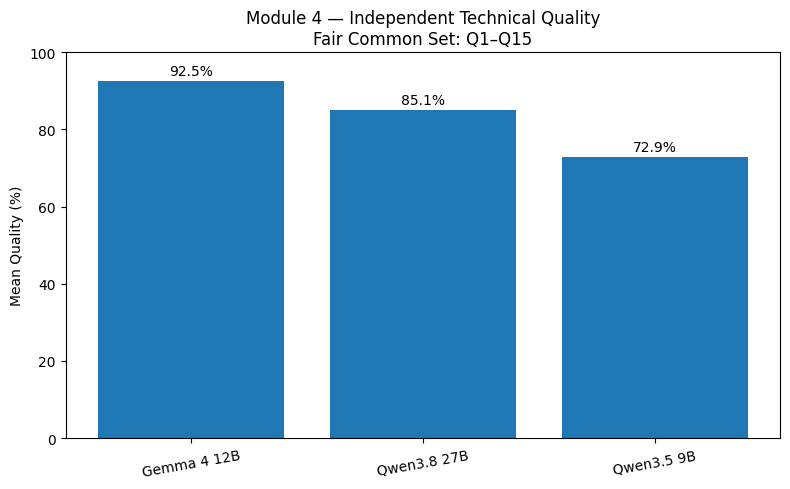

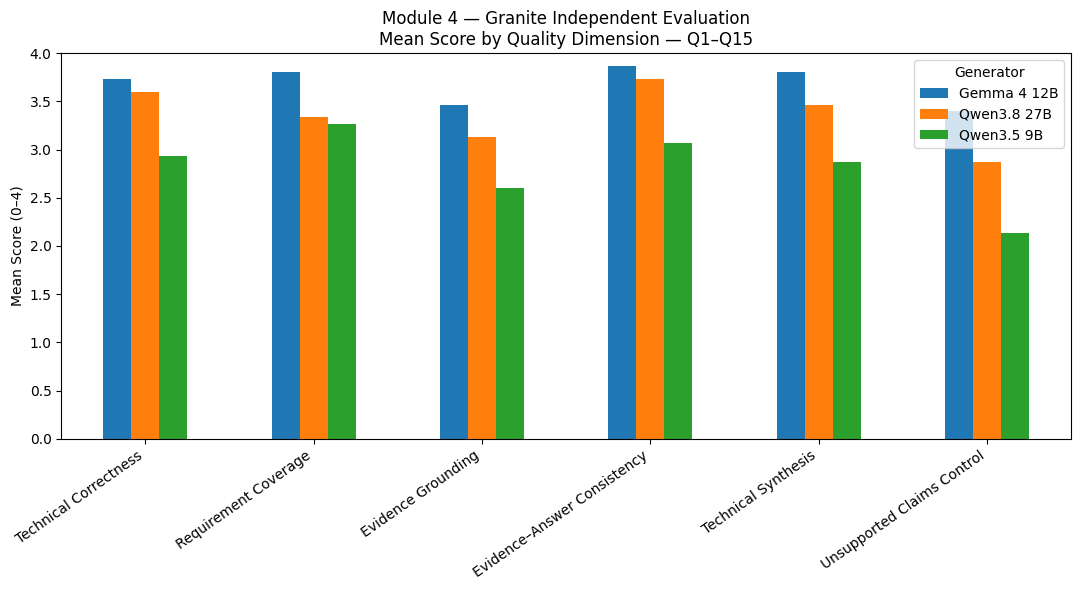

CELL 12D — ANALYSIS COMPLETE
Valid Granite judgments     : 47/48
Primary fair comparison     : Q1–Q15 × 3 models = 45 judgments
Gemma Q16                   : NOT EVALUATED / NOT IMPUTED
Granite inference required  : NO
GPU required                : NO

Saved analysis artifacts:
  - /content/module4_analysis/cell12d_analysis_manifest.json
  - /content/module4_analysis/cell12d_common_set_quality.png
  - /content/module4_analysis/cell12d_common_set_quality_summary.csv
  - /content/module4_analysis/cell12d_domain_quality_summary.csv
  - /content/module4_analysis/cell12d_evaluation_coverage.csv
  - /content/module4_analysis/cell12d_generator_validation_effect.csv
  - /content/module4_analysis/cell12d_q16_negative_control.csv
  - /content/module4_analysis/cell12d_quality_dimension_summary.csv
  - /content/module4_analysis/cell12d_quality_dimensions.png
  - /content/module4_analysis/cell12d_question_quality_matrix.csv
  - /content/module4_analysis/cell12d_reliability_summary.csv

✓ Ready for 

In [3]:
# ============================================================
# 8. LOAD FORMAL EVALUATION ARTIFACTS
# ============================================================

with open(JUDGE_RESULTS_PATH, "r", encoding="utf-8") as f:
    judge_results = json.load(f)

with open(JUDGE_FAILURES_PATH, "r", encoding="utf-8") as f:
    judge_failures = json.load(f)

with open(JUDGE_MANIFEST_PATH, "r", encoding="utf-8") as f:
    judge_manifest = json.load(f)

with open(JUDGE_PILOT_PATH, "r", encoding="utf-8") as f:
    judge_pilot = json.load(f)

with open(BENCHMARK_PATH, "r", encoding="utf-8") as f:
    benchmark = json.load(f)

with open(GEMMA_MANIFEST_PATH, "r", encoding="utf-8") as f:
    gemma_manifest = json.load(f)

with open(QWEN38_MANIFEST_PATH, "r", encoding="utf-8") as f:
    qwen38_manifest = json.load(f)

with open(QWEN35_MANIFEST_PATH, "r", encoding="utf-8") as f:
    qwen35_manifest = json.load(f)

judge_df = pd.read_csv(JUDGE_SUMMARY_PATH)


print("=" * 100)
print("FORMAL ARTIFACT LOAD")
print("=" * 100)
print(f"Judge rows loaded          : {len(judge_df)}")
print(f"Benchmark questions        : {len(benchmark['questions'])}")
print("✓ Formal analysis artifacts loaded")
print()


# ============================================================
# 9. FORMAL EXPERIMENT INTEGRITY VALIDATION
# ============================================================

expected_benchmark_sha = benchmark["sha256"]

artifact_benchmark_shas = {
    "Gemma 4 12B": gemma_manifest["benchmark_sha256"],
    "Qwen3.8 27B": qwen38_manifest["benchmark_sha256"],
    "Qwen3.5 9B": qwen35_manifest["benchmark_sha256"],
    "Granite Judge": judge_manifest["benchmark_sha256"],
}

benchmark_hash_pass = all(
    sha == expected_benchmark_sha
    for sha in artifact_benchmark_shas.values()
)

rubric_hash_pass = (
    judge_results["rubric_sha256"]
    == judge_pilot["rubric_sha256"]
    == judge_manifest["rubric_sha256"]
)

pilot_pass = bool(
    judge_pilot["all_pilot_sanity_checks_pass"]
)

planned_evaluations = int(
    judge_results["evaluation_count_planned"]
)

valid_evaluations = int(
    judge_results["valid_judgment_count"]
)

failed_evaluations = int(
    judge_results["failed_judgment_count"]
)

missing_ids = list(
    judge_results["missing_evaluation_ids"]
)


print("=" * 100)
print("FORMAL EXPERIMENT INTEGRITY")
print("=" * 100)

print(f"Benchmark version          : {benchmark['version']}")
print(f"Benchmark SHA-256          : {expected_benchmark_sha}")
print(f"Benchmark SHA aligned      : {benchmark_hash_pass}")

print(f"Rubric SHA-256             : {judge_results['rubric_sha256']}")
print(f"Rubric SHA aligned         : {rubric_hash_pass}")
print(f"Judge pilot sanity PASS    : {pilot_pass}")

print(f"Planned judgments          : {planned_evaluations}")
print(f"Valid judgments            : {valid_evaluations}")
print(f"Failed judgments           : {failed_evaluations}")
print(
    f"Evaluation completeness    : "
    f"{valid_evaluations / planned_evaluations * 100:.2f}%"
)
print(f"Missing evaluation IDs     : {missing_ids}")
print()


assert benchmark_hash_pass, (
    "Formal benchmark SHA mismatch detected."
)

assert rubric_hash_pass, (
    "Judge rubric SHA mismatch detected."
)

assert pilot_pass, (
    "Judge rubric qualification did not pass."
)

assert len(benchmark["questions"]) == 16, (
    "Frozen Module 4 benchmark should contain 16 questions."
)

assert valid_evaluations == len(judge_df), (
    "Judge CSV row count does not match valid judgment count."
)

print("✓ Formal experiment integrity validation PASS")
print()


# ============================================================
# 10. NORMALIZE MODEL + QUESTION LABELS
# ============================================================

MODEL_ORDER = [
    "gemma4_12b",
    "qwen38_27b",
    "qwen35_9b",
]

MODEL_NAMES = {
    "gemma4_12b": "Gemma 4 12B",
    "qwen38_27b": "Qwen3.8 27B",
    "qwen35_9b": "Qwen3.5 9B",
}

judge_df["model"] = (
    judge_df["generator_key"]
    .map(MODEL_NAMES)
)

judge_df["question_number"] = (
    judge_df["question_id"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

judge_df = (
    judge_df
    .sort_values(
        ["question_number", "generator_key"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 11. VERIFY DETERMINISTIC COMPOSITE SCORE
# ============================================================

DIMENSIONS = [
    "technical_correctness",
    "requirement_coverage",
    "evidence_grounding",
    "evidence_answer_consistency",
    "technical_synthesis",
    "unsupported_claims_control",
]

DIMENSION_LABELS = {
    "technical_correctness":
        "Technical Correctness",

    "requirement_coverage":
        "Requirement Coverage",

    "evidence_grounding":
        "Evidence Grounding",

    "evidence_answer_consistency":
        "Evidence–Answer Consistency",

    "technical_synthesis":
        "Technical Synthesis",

    "unsupported_claims_control":
        "Unsupported Claims Control",
}

WEIGHTS = judge_results["weights"]

judge_df["recalculated_score"] = sum(
    judge_df[dimension] * WEIGHTS[dimension]
    for dimension in DIMENSIONS
)

judge_df["score_difference"] = (
    judge_df["recalculated_score"]
    - judge_df["overall_score"]
).abs()

max_score_difference = (
    judge_df["score_difference"].max()
)

composite_validation_pass = bool(
    np.isclose(
        max_score_difference,
        0.0,
        atol=1e-9,
    )
)


print("=" * 100)
print("COMPOSITE SCORE VALIDATION")
print("=" * 100)
print(
    f"Maximum score difference   : "
    f"{max_score_difference:.12f}"
)
print(
    f"Composite calculation PASS : "
    f"{composite_validation_pass}"
)
print()


assert composite_validation_pass, (
    "Stored Granite composite scores do not match "
    "the frozen deterministic weighting."
)


# ============================================================
# 12. INDEPENDENT EVALUATION COVERAGE
# ============================================================

coverage = (
    judge_df
    .groupby(
        ["generator_key", "model"],
        observed=True,
    )
    .agg(
        valid_judgments=("evaluation_id", "count"),
        questions_evaluated=("question_id", "nunique"),
    )
    .reset_index()
)

coverage["planned"] = 16

coverage["coverage_pct"] = (
    coverage["valid_judgments"]
    / coverage["planned"]
    * 100
)

coverage = (
    coverage
    .set_index("generator_key")
    .reindex(MODEL_ORDER)
    .reset_index()
)


print("=" * 100)
print("1. INDEPENDENT EVALUATION COVERAGE")
print("=" * 100)

coverage_display = coverage[
    [
        "model",
        "valid_judgments",
        "planned",
        "coverage_pct",
    ]
].copy()

coverage_display["coverage_pct"] = (
    coverage_display["coverage_pct"].round(2)
)

print(
    coverage_display.to_string(
        index=False
    )
)

print()
print(
    "Gemma Q16 policy          : "
    "NOT EVALUATED — NO IMPUTATION"
)
print()


# ============================================================
# 13. FAIR PRIMARY COMPARISON — COMMON Q1 TO Q15
# ============================================================

COMMON_QUESTIONS = [
    f"Q{i}"
    for i in range(1, 16)
]

common_df = judge_df[
    judge_df["question_id"]
    .isin(COMMON_QUESTIONS)
].copy()


common_counts = (
    common_df
    .groupby("generator_key")["question_id"]
    .nunique()
    .reindex(MODEL_ORDER)
)


assert (common_counts == 15).all(), (
    "Fair common-set analysis requires "
    "Q1-Q15 for every model."
)


overall_common = (
    common_df
    .groupby(
        ["generator_key", "model"],
        observed=True,
    )
    .agg(
        n=("evaluation_id", "count"),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        median_quality_pct=(
            "quality_percentage",
            "median",
        ),

        min_quality_pct=(
            "quality_percentage",
            "min",
        ),

        max_quality_pct=(
            "quality_percentage",
            "max",
        ),

        mean_score_4=(
            "overall_score",
            "mean",
        ),
    )
    .reset_index()
)

overall_common = (
    overall_common
    .set_index("generator_key")
    .reindex(MODEL_ORDER)
    .reset_index()
)


overall_display = overall_common[
    [
        "model",
        "n",
        "mean_quality_pct",
        "median_quality_pct",
        "min_quality_pct",
        "max_quality_pct",
        "mean_score_4",
    ]
].copy()


for col in [
    "mean_quality_pct",
    "median_quality_pct",
    "min_quality_pct",
    "max_quality_pct",
]:
    overall_display[col] = (
        overall_display[col].round(2)
    )

overall_display["mean_score_4"] = (
    overall_display["mean_score_4"]
    .round(3)
)


print("=" * 100)
print("2. FAIR COMMON-SET QUALITY COMPARISON — Q1 TO Q15")
print("=" * 100)

print(
    overall_display.to_string(
        index=False
    )
)

print()


# ============================================================
# 14. SIX-DIMENSION TECHNICAL QUALITY ANALYSIS
# ============================================================

dimension_summary = (
    common_df
    .groupby(
        ["generator_key", "model"],
        observed=True,
    )[DIMENSIONS]
    .mean()
    .reset_index()
)

dimension_summary = (
    dimension_summary
    .set_index("generator_key")
    .reindex(MODEL_ORDER)
    .reset_index()
)


dimension_display = (
    dimension_summary.copy()
)

for dimension in DIMENSIONS:
    dimension_display[dimension] = (
        dimension_display[dimension]
        .round(3)
    )

dimension_display = (
    dimension_display.rename(
        columns=DIMENSION_LABELS
    )
)


print("=" * 100)
print("3. GRANITE JUDGE — SIX QUALITY DIMENSIONS")
print("=" * 100)

print(
    dimension_display
    .drop(columns=["generator_key"])
    .to_string(index=False)
)

print()


# ============================================================
# 15. MAJOR ERROR + UNSUPPORTED CLAIM ANALYSIS
# ============================================================

reliability_summary = (
    common_df
    .groupby(
        ["generator_key", "model"],
        observed=True,
    )
    .agg(
        n=("evaluation_id", "count"),

        major_errors=(
            "major_error",
            "sum",
        ),

        unsupported_claim_cases=(
            "unsupported_claims_detected",
            "sum",
        ),
    )
    .reset_index()
)

reliability_summary[
    "major_error_rate_pct"
] = (
    reliability_summary["major_errors"]
    / reliability_summary["n"]
    * 100
)

reliability_summary[
    "unsupported_claim_rate_pct"
] = (
    reliability_summary[
        "unsupported_claim_cases"
    ]
    / reliability_summary["n"]
    * 100
)

reliability_summary = (
    reliability_summary
    .set_index("generator_key")
    .reindex(MODEL_ORDER)
    .reset_index()
)


reliability_display = (
    reliability_summary[
        [
            "model",
            "n",
            "major_errors",
            "major_error_rate_pct",
            "unsupported_claim_cases",
            "unsupported_claim_rate_pct",
        ]
    ].copy()
)

reliability_display[
    [
        "major_error_rate_pct",
        "unsupported_claim_rate_pct",
    ]
] = (
    reliability_display[
        [
            "major_error_rate_pct",
            "unsupported_claim_rate_pct",
        ]
    ].round(2)
)


print("=" * 100)
print("4. MAJOR ERROR + UNSUPPORTED CLAIM ANALYSIS — Q1 TO Q15")
print("=" * 100)

print(
    reliability_display.to_string(
        index=False
    )
)

print()


# ============================================================
# 16. GENERATOR COMPLETION / VALIDATION VS SEMANTIC QUALITY
# ============================================================

validation_effect = (
    judge_df
    .groupby(
        [
            "generator_key",
            "model",
            "candidate_original_validation_pass",
        ],
        observed=True,
    )
    .agg(
        n=("evaluation_id", "count"),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        median_quality_pct=(
            "quality_percentage",
            "median",
        ),
    )
    .reset_index()
)


validation_effect["status"] = np.where(
    validation_effect[
        "candidate_original_validation_pass"
    ],
    "Generator validation PASS",
    "Generator validation FAIL",
)


validation_effect = (
    validation_effect[
        [
            "model",
            "status",
            "n",
            "mean_quality_pct",
            "median_quality_pct",
        ]
    ]
)


validation_effect[
    [
        "mean_quality_pct",
        "median_quality_pct",
    ]
] = (
    validation_effect[
        [
            "mean_quality_pct",
            "median_quality_pct",
        ]
    ].round(2)
)


print("=" * 100)
print("5. GENERATOR VALIDATION STATUS VS SEMANTIC QUALITY")
print("=" * 100)

print(
    validation_effect.to_string(
        index=False
    )
)

print()

print(
    "NOTE: Generator validation failure is preserved as an "
    "operational/reliability outcome. Granite evaluates the "
    "actual produced answer and does not automatically assign "
    "a semantic failure."
)

print()


# ============================================================
# 17. Q16 NEGATIVE CONTROL
# ============================================================

q16_df = judge_df[
    judge_df["question_id"] == "Q16"
].copy()


q16_display = q16_df[
    [
        "model",
        "quality_percentage",
        "technical_correctness",
        "requirement_coverage",
        "evidence_grounding",
        "evidence_answer_consistency",
        "technical_synthesis",
        "unsupported_claims_control",
        "unsupported_claims_detected",
        "negative_control_abstention",
        "major_error",
    ]
].copy()


q16_display[
    "quality_percentage"
] = (
    q16_display[
        "quality_percentage"
    ].round(2)
)


print("=" * 100)
print("6. Q16 — UNSUPPORTED PROPRIETARY KNOWLEDGE NEGATIVE CONTROL")
print("=" * 100)

if not q16_display.empty:
    print(
        q16_display.to_string(
            index=False
        )
    )

print()
print(
    "Gemma 4 12B              : "
    "NOT EVALUATED — Granite completed inference but "
    "negative_control_abstention failed Boolean schema validation."
)
print(
    "Missing-value treatment  : "
    "NO IMPUTATION / NO MANUAL SCORE"
)
print()


# ============================================================
# 18. PER-QUESTION QUALITY MATRIX — Q1 TO Q15
# ============================================================

question_pivot = (
    common_df
    .pivot(
        index="question_id",
        columns="model",
        values="quality_percentage",
    )
)


question_pivot["_qnum"] = (
    question_pivot.index
    .str.extract(
        r"(\d+)",
        expand=False,
    )
    .astype(int)
)

question_pivot = (
    question_pivot
    .sort_values("_qnum")
    .drop(columns="_qnum")
)

question_pivot = question_pivot[
    [
        "Gemma 4 12B",
        "Qwen3.8 27B",
        "Qwen3.5 9B",
    ]
]


print("=" * 100)
print("7. PER-QUESTION QUALITY — COMMON Q1 TO Q15")
print("=" * 100)

print(
    question_pivot
    .round(2)
    .to_string()
)

print()


# ============================================================
# 19. DOMAIN-LEVEL QUALITY
# ============================================================

domain_summary = (
    common_df
    .groupby(
        ["model", "domain"],
        observed=True,
    )
    .agg(
        n=("evaluation_id", "count"),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),
    )
    .reset_index()
)

domain_summary[
    "mean_quality_pct"
] = (
    domain_summary[
        "mean_quality_pct"
    ].round(2)
)


print("=" * 100)
print("8. DOMAIN-LEVEL TECHNICAL QUALITY")
print("=" * 100)

print(
    domain_summary
    .sort_values(
        ["domain", "model"]
    )
    .to_string(index=False)
)

print()


# ============================================================
# 20. CHART — FAIR COMMON-SET QUALITY
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    overall_common["model"],
    overall_common["mean_quality_pct"],
)

ax.set_title(
    "Module 4 — Independent Technical Quality\n"
    "Fair Common Set: Q1–Q15"
)

ax.set_ylabel(
    "Mean Quality (%)"
)

ax.set_ylim(
    0,
    100,
)

for i, value in enumerate(
    overall_common["mean_quality_pct"]
):
    ax.text(
        i,
        value + 1.5,
        f"{value:.1f}%",
        ha="center",
    )

plt.xticks(
    rotation=10
)

plt.tight_layout()

quality_chart_path = (
    OUTPUT_DIR
    / "cell12d_common_set_quality.png"
)

plt.savefig(
    quality_chart_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 21. CHART — SIX QUALITY DIMENSIONS
# ============================================================

dimension_plot = (
    dimension_summary
    .set_index("model")[DIMENSIONS]
    .T
)

dimension_plot.index = [
    DIMENSION_LABELS[d]
    for d in dimension_plot.index
]


fig, ax = plt.subplots(
    figsize=(11, 6)
)

dimension_plot.plot(
    kind="bar",
    ax=ax,
)

ax.set_title(
    "Module 4 — Granite Independent Evaluation\n"
    "Mean Score by Quality Dimension — Q1–Q15"
)

ax.set_ylabel(
    "Mean Score (0–4)"
)

ax.set_ylim(
    0,
    4,
)

ax.set_xlabel("")

ax.legend(
    title="Generator"
)

plt.xticks(
    rotation=35,
    ha="right",
)

plt.tight_layout()

dimension_chart_path = (
    OUTPUT_DIR
    / "cell12d_quality_dimensions.png"
)

plt.savefig(
    dimension_chart_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 22. SAVE CPU ANALYSIS ARTIFACTS
# ============================================================

coverage.to_csv(
    OUTPUT_DIR
    / "cell12d_evaluation_coverage.csv",
    index=False,
)

overall_common.to_csv(
    OUTPUT_DIR
    / "cell12d_common_set_quality_summary.csv",
    index=False,
)

dimension_summary.to_csv(
    OUTPUT_DIR
    / "cell12d_quality_dimension_summary.csv",
    index=False,
)

reliability_summary.to_csv(
    OUTPUT_DIR
    / "cell12d_reliability_summary.csv",
    index=False,
)

validation_effect.to_csv(
    OUTPUT_DIR
    / "cell12d_generator_validation_effect.csv",
    index=False,
)

question_pivot.to_csv(
    OUTPUT_DIR
    / "cell12d_question_quality_matrix.csv"
)

domain_summary.to_csv(
    OUTPUT_DIR
    / "cell12d_domain_quality_summary.csv",
    index=False,
)

q16_display.to_csv(
    OUTPUT_DIR
    / "cell12d_q16_negative_control.csv",
    index=False,
)


# ============================================================
# 23. SAVE CELL 12D MANIFEST
# ============================================================

analysis_manifest = {
    "cell": "12D",
    "section": "5_independent_evaluation",

    "analysis_type":
        "CPU_ONLY_POST_HOC",

    "artifact_source":
        "kaggle",

    "kaggle_dataset":
        KAGGLE_DATASET,

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "benchmark_version":
        benchmark["version"],

    "benchmark_sha256":
        expected_benchmark_sha,

    "judge_model":
        judge_results[
            "judge"
        ]["model_id"],

    "judge_revision":
        judge_results[
            "judge"
        ]["revision"],

    "rubric_sha256":
        judge_results[
            "rubric_sha256"
        ],

    "judge_config_sha256":
        judge_results[
            "config_sha256"
        ],

    "planned_judgments":
        planned_evaluations,

    "valid_judgments":
        valid_evaluations,

    "failed_judgments":
        failed_evaluations,

    "evaluation_completeness_pct":
        round(
            valid_evaluations
            / planned_evaluations
            * 100,
            4,
        ),

    "missing_evaluation_ids":
        missing_ids,

    "fair_primary_comparison": {
        "question_set":
            "Q1-Q15",

        "questions_per_model":
            15,

        "judgments":
            45,

        "reason":
            (
                "Gemma Q16 independent judgment "
                "failed schema validation. "
                "Q1-Q15 therefore provides the "
                "complete common comparison set."
            ),
    },

    "q16_policy": {
        "gemma4_12b":
            "NOT_EVALUATED_NO_IMPUTATION",

        "qwen38_27b":
            "AVAILABLE",

        "qwen35_9b":
            "AVAILABLE",
    },

    "benchmark_hash_pass":
        benchmark_hash_pass,

    "rubric_hash_pass":
        rubric_hash_pass,

    "judge_pilot_pass":
        pilot_pass,

    "composite_score_validation_pass":
        composite_validation_pass,

    "output_directory":
        str(OUTPUT_DIR),
}


with open(
    OUTPUT_DIR
    / "cell12d_analysis_manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        analysis_manifest,
        f,
        indent=2,
    )


# ============================================================
# 24. FINAL CELL STATUS
# ============================================================

print("=" * 100)
print("CELL 12D — ANALYSIS COMPLETE")
print("=" * 100)

print(
    f"Valid Granite judgments     : "
    f"{valid_evaluations}/{planned_evaluations}"
)

print(
    "Primary fair comparison     : "
    "Q1–Q15 × 3 models = 45 judgments"
)

print(
    "Gemma Q16                   : "
    "NOT EVALUATED / NOT IMPUTED"
)

print(
    "Granite inference required  : NO"
)

print(
    "GPU required                : NO"
)

print()

print("Saved analysis artifacts:")

for path in sorted(
    OUTPUT_DIR.glob(
        "cell12d_*"
    )
):
    print(
        f"  - {path}"
    )

print()

print(
    "✓ Ready for Cell 13 — "
    "Consolidated RAG vs MCP vs Hybrid Analysis"
)

### Cell 12D — Key Findings

- Independent evaluation completeness: **47 / 48 (97.92%)**
- Fair common-set comparison: **Q1–Q15 × 3 models = 45 judgments**
- Mean technical quality: **Gemma 92.50%**, **Qwen3.8 85.08%**, **Qwen3.5 72.92%**
- Gemma recorded **0 major errors** on the common set.
- Unsupported-claim flags remained a meaningful reliability weakness across all generators.
- Gemma Q16 remains **Not Evaluated — no imputation**.

These outputs feed directly into the consolidated Cell 13 analysis.

# **SECTION 6 — Final Module 4 Analysis**

## **Cell 13 — Consolidated RAG vs MCP vs Hybrid Analysis**

Purpose: Merge the three formal generator artifacts with the independent Granite evaluation and analyze semantic quality, natural route selection, stress-route alignment, retrieval rounds, evidence-sufficiency stopping, generation reliability, latency, negative-control behaviour and quality-efficiency trade-offs. Route-level means are treated as descriptive because natural routing makes route selection non-random and question-dependent.

MODULE 4 — CELL 13
CONSOLIDATED RAG vs MCP vs HYBRID ANALYSIS
Analysis mode              : CPU ONLY
LLM inference              : NONE
Retrieval                  : NONE
Generator cases            : 48
Independent judgments      : 47
Fair semantic comparison   : Q1–Q15 × 3 models

✓ 48 formal generator cases reconstructed

✓ Generator + Granite judge results merged
✓ 48 generator cases
✓ 47 independent semantic judgments

1. INTEGRATED MODEL SCORECARD
      model  mean_quality_pct  generation_validation_rate_pct major_error_rate_pct unsupported_claim_rate_pct  mean_retrieval_rounds  total_rag_calls  total_mcp_calls  mean_generation_s  mean_e2e_s  mean_completion_tokens
Gemma 4 12B             92.50                          100.00                  0.0                       40.0                   2.44               22               39              26.80       57.11                  694.31
Qwen3.8 27B             85.08                           12.50             6.666667                  66

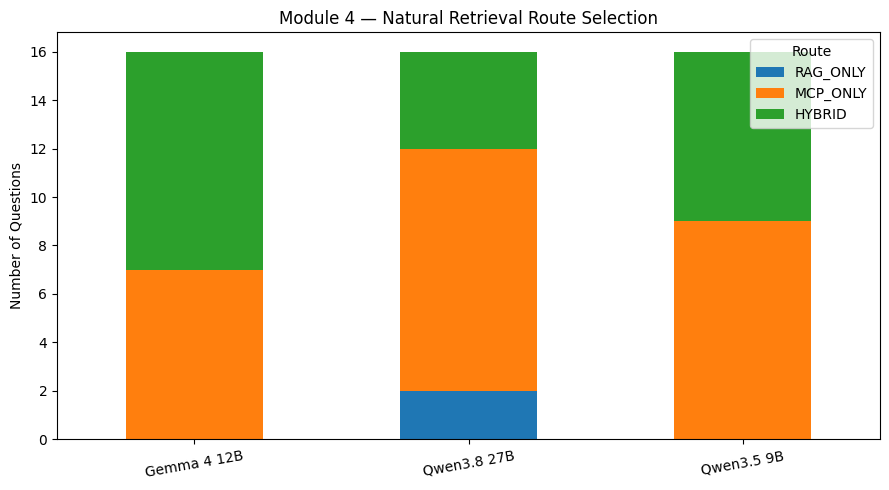

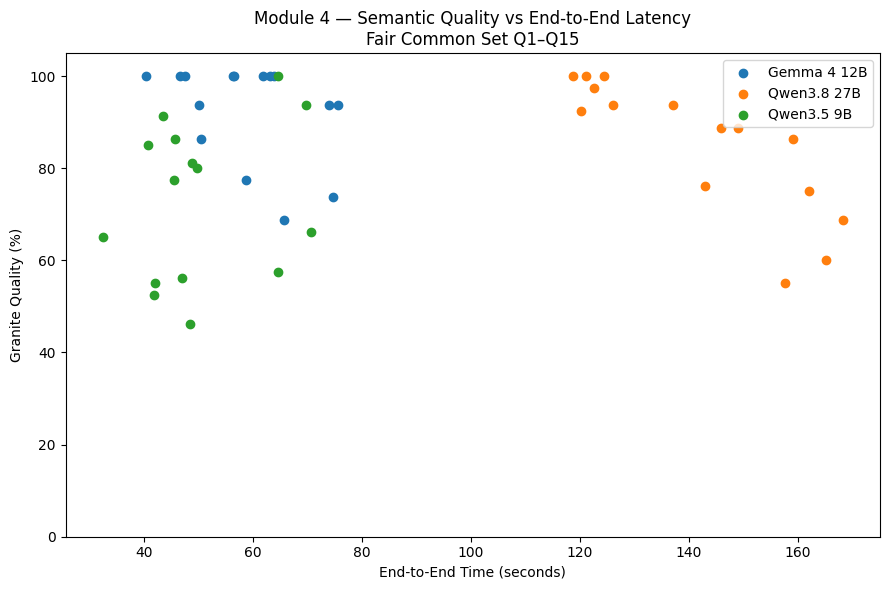

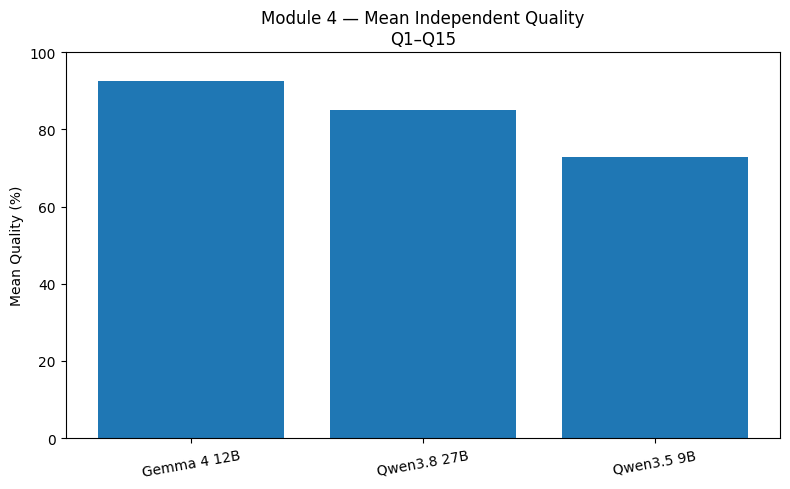

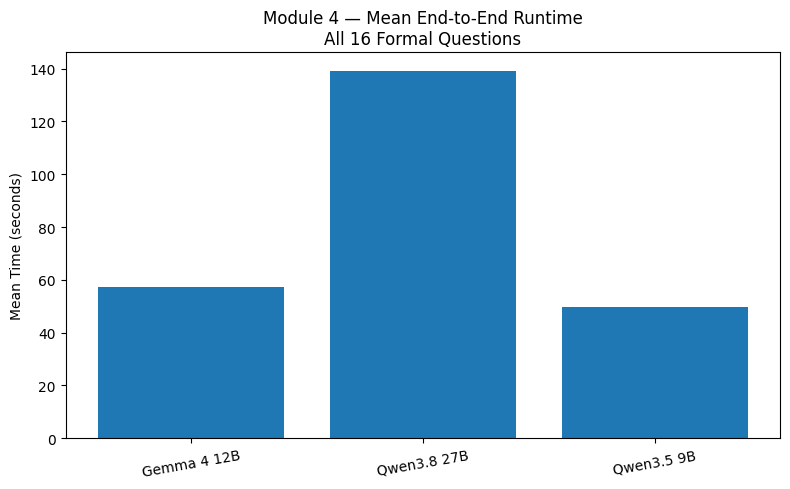

CELL 13 — CONSOLIDATED MODULE 4 ANALYSIS COMPLETE
Generator cases             : 48/48
Valid Granite judgments     : 47/48
Fair semantic comparison    : 45 judgments — Q1 to Q15
Gemma Q16                   : NOT IMPUTED
GPU required                : NO
Additional LLM judging      : NO

Saved Cell 13 artifacts:
  - /content/module4_analysis/cell13_benchmark_group_summary.csv
  - /content/module4_analysis/cell13_case_summary.csv
  - /content/module4_analysis/cell13_final_metrics.json
  - /content/module4_analysis/cell13_generation_reliability_quality.csv
  - /content/module4_analysis/cell13_integrated_case_level_results.csv
  - /content/module4_analysis/cell13_mean_latency.png
  - /content/module4_analysis/cell13_mean_quality.png
  - /content/module4_analysis/cell13_model_scorecard.csv
  - /content/module4_analysis/cell13_q16_integrated_analysis.csv
  - /content/module4_analysis/cell13_quality_vs_latency.png
  - /content/module4_analysis/cell13_retrieval_stop_summary.csv
  - /content/modu

In [4]:
# ============================================================
# CELL 13 — CONSOLIDATED RAG vs MCP vs HYBRID ANALYSIS
# CPU-ONLY FINAL MODULE 4 ANALYSIS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD FORMAL GENERATOR ARTIFACTS
# ============================================================

with open(GEMMA_RESULTS_PATH, "r", encoding="utf-8") as f:
    gemma_results = json.load(f)

with open(QWEN38_RESULTS_PATH, "r", encoding="utf-8") as f:
    qwen38_results = json.load(f)

with open(QWEN35_RESULTS_PATH, "r", encoding="utf-8") as f:
    qwen35_results = json.load(f)


EXPERIMENT_CONFIG_PATH = find_artifact(
    "module4_experiment_config.json"
)

with open(EXPERIMENT_CONFIG_PATH, "r", encoding="utf-8") as f:
    experiment_config = json.load(f)


# Reload judge summary so Cell 13 can remain reproducible
judge_df_13 = pd.read_csv(
    JUDGE_SUMMARY_PATH
)


print("=" * 110)
print("MODULE 4 — CELL 13")
print("CONSOLIDATED RAG vs MCP vs HYBRID ANALYSIS")
print("=" * 110)
print("Analysis mode              : CPU ONLY")
print("LLM inference              : NONE")
print("Retrieval                  : NONE")
print("Generator cases            : 48")
print("Independent judgments      : 47")
print("Fair semantic comparison   : Q1–Q15 × 3 models")
print()


# ============================================================
# 2. MODEL LABELS
# ============================================================

MODEL_ORDER = [
    "gemma4_12b",
    "qwen38_27b",
    "qwen35_9b",
]

MODEL_NAMES = {
    "gemma4_12b": "Gemma 4 12B",
    "qwen38_27b": "Qwen3.8 27B",
    "qwen35_9b": "Qwen3.5 9B",
}

GENERATOR_ARTIFACTS = {
    "gemma4_12b": gemma_results,
    "qwen38_27b": qwen38_results,
    "qwen35_9b": qwen35_results,
}


# ============================================================
# 3. FLATTEN GENERATOR RESULTS
# ============================================================

generator_rows = []

for generator_key in MODEL_ORDER:

    artifact = GENERATOR_ARTIFACTS[
        generator_key
    ]

    for question_id, result in artifact["results"].items():

        validation = result.get(
            "validation",
            {}
        )

        usage = result.get(
            "answer_usage",
            {}
        )

        metadata = result.get(
            "formal_run_metadata",
            {}
        )

        sufficiency = result.get(
            "final_sufficiency_assessment",
            {}
        )

        generator_rows.append(
            {
                "generator_key":
                    generator_key,

                "model":
                    MODEL_NAMES[
                        generator_key
                    ],

                "question_id":
                    question_id,

                "question":
                    result["question"],

                "domain":
                    metadata.get(
                        "domain"
                    ),

                "benchmark_group":
                    metadata.get(
                        "benchmark_group"
                    ),

                "stress_class":
                    metadata.get(
                        "stress_class"
                    ),

                "knowledge_scope":
                    metadata.get(
                        "knowledge_scope"
                    ),

                "answer_policy":
                    metadata.get(
                        "answer_policy"
                    ),

                "selected_mode":
                    result[
                        "selected_mode"
                    ],

                "retrieval_rounds":
                    result[
                        "retrieval_round_count"
                    ],

                "rag_calls":
                    result[
                        "rag_call_count"
                    ],

                "mcp_calls":
                    result[
                        "mcp_call_count"
                    ],

                "backend_calls":
                    result[
                        "backend_retrieval_call_count"
                    ],

                "retrieval_stop_reason":
                    result[
                        "stop_reason"
                    ],

                "final_sufficient":
                    sufficiency.get(
                        "sufficient"
                    ),

                "final_evidence_count":
                    len(
                        result.get(
                            "final_evidence",
                            []
                        )
                    ),

                "final_context_chars":
                    result[
                        "final_context_chars"
                    ],

                "answer_generation_s":
                    result[
                        "answer_generation_time_s"
                    ],

                "end_to_end_s":
                    result[
                        "end_to_end_time_s"
                    ],

                "prompt_tokens":
                    usage.get(
                        "prompt_tokens"
                    ),

                "completion_tokens":
                    usage.get(
                        "completion_tokens"
                    ),

                "total_tokens":
                    usage.get(
                        "total_tokens"
                    ),

                "answer_validation_pass":
                    validation.get(
                        "pass"
                    ),

                "finish_reason_validation_pass":
                    validation.get(
                        "finish_reason_ok"
                    ),

                "answer_nonempty":
                    validation.get(
                        "answer_nonempty"
                    ),

                "has_evidence_citation":
                    validation.get(
                        "has_evidence_citation"
                    ),

                "citation_range_ok":
                    validation.get(
                        "citation_range_ok"
                    ),

                "model_id":
                    result.get(
                        "model_id"
                    ),

                "revision":
                    result.get(
                        "revision"
                    ),
            }
        )


generator_df = pd.DataFrame(
    generator_rows
)


generator_df[
    "question_number"
] = (
    generator_df[
        "question_id"
    ]
    .str.extract(
        r"(\d+)",
        expand=False
    )
    .astype(int)
)


generator_df = (
    generator_df
    .sort_values(
        [
            "question_number",
            "generator_key",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert len(generator_df) == 48

assert (
    generator_df
    .groupby(
        "generator_key"
    )
    .size()
    .reindex(
        MODEL_ORDER
    )
    == 16
).all()


print("✓ 48 formal generator cases reconstructed")
print()


# ============================================================
# 4. ADD FROZEN BENCHMARK METADATA
# ============================================================

benchmark_rows = []

for question in benchmark["questions"]:

    benchmark_rows.append(
        {
            "question_id":
                question["id"],

            "benchmark_domain":
                question.get(
                    "domain"
                ),

            "benchmark_group_frozen":
                question.get(
                    "benchmark_group"
                ),

            "stress_class_frozen":
                question.get(
                    "stress_class"
                ),

            "knowledge_scope_frozen":
                question.get(
                    "knowledge_scope"
                ),

            "expected_route_frozen":
                question.get(
                    "expected_route"
                ),

            "expected_mcp_route":
                question.get(
                    "expected_mcp_route"
                ),

            "answer_policy_frozen":
                question.get(
                    "answer_policy"
                ),
        }
    )


benchmark_df = pd.DataFrame(
    benchmark_rows
)


generator_df = generator_df.merge(
    benchmark_df,
    on="question_id",
    how="left",
    validate="many_to_one",
)


# ============================================================
# 5. MERGE GRANITE INDEPENDENT QUALITY RESULTS
# ============================================================

judge_merge_columns = [
    "generator_key",
    "question_id",
    "technical_correctness",
    "requirement_coverage",
    "evidence_grounding",
    "evidence_answer_consistency",
    "technical_synthesis",
    "unsupported_claims_control",
    "overall_score",
    "quality_percentage",
    "major_error",
    "unsupported_claims_detected",
    "negative_control_abstention",
    "judge_finish_reason",
    "judge_latency_s",
    "judge_completion_tokens",
]


integrated_df = generator_df.merge(
    judge_df_13[
        judge_merge_columns
    ],
    on=[
        "generator_key",
        "question_id",
    ],
    how="left",
    validate="one_to_one",
)


assert len(integrated_df) == 48

assert (
    integrated_df[
        "quality_percentage"
    ]
    .notna()
    .sum()
    == 47
)


print("✓ Generator + Granite judge results merged")
print("✓ 48 generator cases")
print("✓ 47 independent semantic judgments")
print()


# ============================================================
# 6. DEFINE FAIR ANALYSIS SETS
# ============================================================

common_df_13 = integrated_df[
    integrated_df[
        "question_id"
    ].isin(
        [
            f"Q{i}"
            for i in range(1, 16)
        ]
    )
].copy()


q16_df_13 = integrated_df[
    integrated_df[
        "question_id"
    ] == "Q16"
].copy()


assert len(common_df_13) == 45


# ============================================================
# 7. MODEL-LEVEL INTEGRATED SCORECARD
# ============================================================

semantic_scorecard = (
    common_df_13
    .groupby(
        [
            "generator_key",
            "model",
        ],
        observed=True,
    )
    .agg(
        semantic_n=(
            "quality_percentage",
            "count",
        ),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        median_quality_pct=(
            "quality_percentage",
            "median",
        ),

        technical_correctness=(
            "technical_correctness",
            "mean",
        ),

        requirement_coverage=(
            "requirement_coverage",
            "mean",
        ),

        evidence_grounding=(
            "evidence_grounding",
            "mean",
        ),

        evidence_consistency=(
            "evidence_answer_consistency",
            "mean",
        ),

        technical_synthesis=(
            "technical_synthesis",
            "mean",
        ),

        unsupported_claims_control=(
            "unsupported_claims_control",
            "mean",
        ),

        major_errors=(
            "major_error",
            "sum",
        ),

        unsupported_claim_cases=(
            "unsupported_claims_detected",
            "sum",
        ),
    )
    .reset_index()
)


operational_scorecard = (
    integrated_df
    .groupby(
        [
            "generator_key",
            "model",
        ],
        observed=True,
    )
    .agg(
        formal_cases=(
            "question_id",
            "count",
        ),

        generation_validation_passes=(
            "answer_validation_pass",
            "sum",
        ),

        mean_retrieval_rounds=(
            "retrieval_rounds",
            "mean",
        ),

        total_rag_calls=(
            "rag_calls",
            "sum",
        ),

        total_mcp_calls=(
            "mcp_calls",
            "sum",
        ),

        total_backend_calls=(
            "backend_calls",
            "sum",
        ),

        mean_final_evidence=(
            "final_evidence_count",
            "mean",
        ),

        mean_context_chars=(
            "final_context_chars",
            "mean",
        ),

        mean_generation_s=(
            "answer_generation_s",
            "mean",
        ),

        mean_e2e_s=(
            "end_to_end_s",
            "mean",
        ),

        mean_completion_tokens=(
            "completion_tokens",
            "mean",
        ),

        mean_total_tokens=(
            "total_tokens",
            "mean",
        ),
    )
    .reset_index()
)


model_scorecard = semantic_scorecard.merge(
    operational_scorecard,
    on=[
        "generator_key",
        "model",
    ],
    validate="one_to_one",
)


model_scorecard[
    "generation_validation_rate_pct"
] = (
    model_scorecard[
        "generation_validation_passes"
    ]
    / model_scorecard[
        "formal_cases"
    ]
    * 100
)


model_scorecard[
    "major_error_rate_pct"
] = (
    model_scorecard[
        "major_errors"
    ]
    / model_scorecard[
        "semantic_n"
    ]
    * 100
)


model_scorecard[
    "unsupported_claim_rate_pct"
] = (
    model_scorecard[
        "unsupported_claim_cases"
    ]
    / model_scorecard[
        "semantic_n"
    ]
    * 100
)


model_scorecard = (
    model_scorecard
    .set_index(
        "generator_key"
    )
    .reindex(
        MODEL_ORDER
    )
    .reset_index()
)


scorecard_display = model_scorecard[
    [
        "model",
        "mean_quality_pct",
        "generation_validation_rate_pct",
        "major_error_rate_pct",
        "unsupported_claim_rate_pct",
        "mean_retrieval_rounds",
        "total_rag_calls",
        "total_mcp_calls",
        "mean_generation_s",
        "mean_e2e_s",
        "mean_completion_tokens",
    ]
].copy()


numeric_cols = (
    scorecard_display
    .select_dtypes(
        include=np.number
    )
    .columns
)

scorecard_display[
    numeric_cols
] = (
    scorecard_display[
        numeric_cols
    ]
    .round(2)
)


print("=" * 110)
print("1. INTEGRATED MODEL SCORECARD")
print("=" * 110)

print(
    scorecard_display.to_string(
        index=False
    )
)

print()


# ============================================================
# 8. NATURAL ROUTE DISTRIBUTION
# ============================================================

route_counts = (
    integrated_df
    .groupby(
        [
            "generator_key",
            "model",
            "selected_mode",
        ],
        observed=True,
    )
    .size()
    .rename(
        "questions"
    )
    .reset_index()
)


route_counts[
    "route_pct"
] = (
    route_counts[
        "questions"
    ]
    / 16
    * 100
)


route_pivot = (
    route_counts
    .pivot(
        index="model",
        columns="selected_mode",
        values="questions",
    )
    .fillna(0)
)


for route in [
    "RAG_ONLY",
    "MCP_ONLY",
    "HYBRID",
]:
    if route not in route_pivot.columns:
        route_pivot[route] = 0


route_pivot = route_pivot[
    [
        "RAG_ONLY",
        "MCP_ONLY",
        "HYBRID",
    ]
]


print("=" * 110)
print("2. NATURAL ROUTE DISTRIBUTION — ALL 16 QUESTIONS")
print("=" * 110)

print(
    route_pivot
    .astype(int)
    .to_string()
)

print()


# ============================================================
# 9. QUALITY BY NATURALLY SELECTED ROUTE
# DESCRIPTIVE — NOT A CAUSAL ROUTE COMPARISON
# ============================================================

route_quality = (
    common_df_13
    .groupby(
        [
            "generator_key",
            "model",
            "selected_mode",
        ],
        observed=True,
    )
    .agg(
        n=(
            "question_id",
            "count",
        ),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        mean_rounds=(
            "retrieval_rounds",
            "mean",
        ),

        mean_backend_calls=(
            "backend_calls",
            "mean",
        ),

        mean_e2e_s=(
            "end_to_end_s",
            "mean",
        ),

        generation_pass_rate=(
            "answer_validation_pass",
            "mean",
        ),
    )
    .reset_index()
)


route_quality[
    "generation_pass_rate_pct"
] = (
    route_quality[
        "generation_pass_rate"
    ]
    * 100
)


route_quality_display = (
    route_quality[
        [
            "model",
            "selected_mode",
            "n",
            "mean_quality_pct",
            "mean_rounds",
            "mean_backend_calls",
            "mean_e2e_s",
            "generation_pass_rate_pct",
        ]
    ]
    .copy()
)


for col in [
    "mean_quality_pct",
    "mean_rounds",
    "mean_backend_calls",
    "mean_e2e_s",
    "generation_pass_rate_pct",
]:
    route_quality_display[
        col
    ] = (
        route_quality_display[
            col
        ]
        .round(2)
    )


print("=" * 110)
print("3. QUALITY + EFFICIENCY BY NATURAL ROUTE — Q1 TO Q15")
print("=" * 110)

print(
    route_quality_display.to_string(
        index=False
    )
)

print()
print(
    "IMPORTANT: These route means are descriptive only. "
    "Natural routing assigns different questions to each route, "
    "so route-level averages are confounded by question difficulty "
    "and model behaviour."
)
print()


# ============================================================
# 10. STRESS-ROUTE ALIGNMENT — Q9 TO Q15
#
# Frozen stress labels:
# RAG_FAVOURED → RAG_ONLY
# MCP_FAVOURED → MCP_ONLY
# HYBRID       → HYBRID
# ============================================================

STRESS_EXPECTED_MODE = {
    "RAG_FAVOURED":
        "RAG_ONLY",

    "MCP_FAVOURED":
        "MCP_ONLY",

    "HYBRID":
        "HYBRID",
}


stress_df = integrated_df[
    integrated_df[
        "stress_class_frozen"
    ].isin(
        STRESS_EXPECTED_MODE.keys()
    )
].copy()


stress_df[
    "expected_mode"
] = (
    stress_df[
        "stress_class_frozen"
    ]
    .map(
        STRESS_EXPECTED_MODE
    )
)


stress_df[
    "route_aligned"
] = (
    stress_df[
        "selected_mode"
    ]
    == stress_df[
        "expected_mode"
    ]
)


stress_alignment = (
    stress_df
    .groupby(
        [
            "generator_key",
            "model",
        ],
        observed=True,
    )
    .agg(
        stress_cases=(
            "question_id",
            "count",
        ),

        aligned_cases=(
            "route_aligned",
            "sum",
        ),

        mean_stress_quality_pct=(
            "quality_percentage",
            "mean",
        ),
    )
    .reset_index()
)


stress_alignment[
    "alignment_rate_pct"
] = (
    stress_alignment[
        "aligned_cases"
    ]
    / stress_alignment[
        "stress_cases"
    ]
    * 100
)


stress_alignment = (
    stress_alignment
    .set_index(
        "generator_key"
    )
    .reindex(
        MODEL_ORDER
    )
    .reset_index()
)


stress_alignment_display = (
    stress_alignment[
        [
            "model",
            "stress_cases",
            "aligned_cases",
            "alignment_rate_pct",
            "mean_stress_quality_pct",
        ]
    ]
    .copy()
)


stress_alignment_display[
    [
        "alignment_rate_pct",
        "mean_stress_quality_pct",
    ]
] = (
    stress_alignment_display[
        [
            "alignment_rate_pct",
            "mean_stress_quality_pct",
        ]
    ]
    .round(2)
)


print("=" * 110)
print("4. FROZEN STRESS-ROUTE ALIGNMENT — Q9 TO Q15")
print("=" * 110)

print(
    stress_alignment_display.to_string(
        index=False
    )
)

print()


stress_case_display = stress_df[
    [
        "model",
        "question_id",
        "stress_class_frozen",
        "expected_mode",
        "selected_mode",
        "route_aligned",
        "quality_percentage",
    ]
].copy()


stress_case_display[
    "quality_percentage"
] = (
    stress_case_display[
        "quality_percentage"
    ]
    .round(2)
)


print("Per-case stress routing:")
print(
    stress_case_display
    .sort_values(
        [
            "question_id",
            "model",
        ]
    )
    .to_string(
        index=False
    )
)

print()


# ============================================================
# 11. CONTINUITY vs STRESS BENCHMARK PERFORMANCE
# ============================================================

benchmark_group_summary = (
    common_df_13
    .groupby(
        [
            "generator_key",
            "model",
            "benchmark_group_frozen",
        ],
        observed=True,
    )
    .agg(
        n=(
            "question_id",
            "count",
        ),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        mean_rounds=(
            "retrieval_rounds",
            "mean",
        ),

        mean_e2e_s=(
            "end_to_end_s",
            "mean",
        ),

        generation_pass_rate=(
            "answer_validation_pass",
            "mean",
        ),
    )
    .reset_index()
)


benchmark_group_summary[
    "generation_pass_rate_pct"
] = (
    benchmark_group_summary[
        "generation_pass_rate"
    ]
    * 100
)


benchmark_group_display = (
    benchmark_group_summary[
        [
            "model",
            "benchmark_group_frozen",
            "n",
            "mean_quality_pct",
            "mean_rounds",
            "mean_e2e_s",
            "generation_pass_rate_pct",
        ]
    ]
    .copy()
)


for col in [
    "mean_quality_pct",
    "mean_rounds",
    "mean_e2e_s",
    "generation_pass_rate_pct",
]:
    benchmark_group_display[
        col
    ] = (
        benchmark_group_display[
            col
        ]
        .round(2)
    )


print("=" * 110)
print("5. CONTINUITY vs STRESS PERFORMANCE")
print("=" * 110)

print(
    benchmark_group_display.to_string(
        index=False
    )
)

print()


# ============================================================
# 12. RETRIEVAL STOP BEHAVIOUR
# ============================================================

stop_summary = (
    common_df_13
    .groupby(
        [
            "generator_key",
            "model",
            "retrieval_stop_reason",
        ],
        observed=True,
    )
    .agg(
        n=(
            "question_id",
            "count",
        ),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        mean_rounds=(
            "retrieval_rounds",
            "mean",
        ),

        mean_e2e_s=(
            "end_to_end_s",
            "mean",
        ),
    )
    .reset_index()
)


stop_summary_display = (
    stop_summary.copy()
)

for col in [
    "mean_quality_pct",
    "mean_rounds",
    "mean_e2e_s",
]:
    stop_summary_display[
        col
    ] = (
        stop_summary_display[
            col
        ]
        .round(2)
    )


print("=" * 110)
print("6. RETRIEVAL STOP BEHAVIOUR — Q1 TO Q15")
print("=" * 110)

print(
    stop_summary_display[
        [
            "model",
            "retrieval_stop_reason",
            "n",
            "mean_quality_pct",
            "mean_rounds",
            "mean_e2e_s",
        ]
    ].to_string(
        index=False
    )
)

print()


# ============================================================
# 13. QUALITY BY RETRIEVAL ROUND COUNT
# ============================================================

round_summary = (
    common_df_13
    .groupby(
        [
            "generator_key",
            "model",
            "retrieval_rounds",
        ],
        observed=True,
    )
    .agg(
        n=(
            "question_id",
            "count",
        ),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        mean_e2e_s=(
            "end_to_end_s",
            "mean",
        ),
    )
    .reset_index()
)


round_summary[
    [
        "mean_quality_pct",
        "mean_e2e_s",
    ]
] = (
    round_summary[
        [
            "mean_quality_pct",
            "mean_e2e_s",
        ]
    ]
    .round(2)
)


print("=" * 110)
print("7. QUALITY BY RETRIEVAL ROUND COUNT")
print("=" * 110)

print(
    round_summary[
        [
            "model",
            "retrieval_rounds",
            "n",
            "mean_quality_pct",
            "mean_e2e_s",
        ]
    ].to_string(
        index=False
    )
)

print()


# ============================================================
# 14. GENERATION RELIABILITY vs SEMANTIC QUALITY
# ============================================================

reliability_quality = (
    integrated_df[
        integrated_df[
            "quality_percentage"
        ].notna()
    ]
    .groupby(
        [
            "generator_key",
            "model",
            "answer_validation_pass",
        ],
        observed=True,
    )
    .agg(
        n=(
            "question_id",
            "count",
        ),

        mean_quality_pct=(
            "quality_percentage",
            "mean",
        ),

        median_quality_pct=(
            "quality_percentage",
            "median",
        ),

        mean_completion_tokens=(
            "completion_tokens",
            "mean",
        ),
    )
    .reset_index()
)


reliability_quality[
    "generation_status"
] = np.where(
    reliability_quality[
        "answer_validation_pass"
    ],
    "PASS",
    "FAIL",
)


reliability_quality_display = (
    reliability_quality[
        [
            "model",
            "generation_status",
            "n",
            "mean_quality_pct",
            "median_quality_pct",
            "mean_completion_tokens",
        ]
    ]
    .copy()
)


for col in [
    "mean_quality_pct",
    "median_quality_pct",
    "mean_completion_tokens",
]:
    reliability_quality_display[
        col
    ] = (
        reliability_quality_display[
            col
        ]
        .round(2)
    )


print("=" * 110)
print("8. GENERATION RELIABILITY vs SEMANTIC QUALITY")
print("=" * 110)

print(
    reliability_quality_display.to_string(
        index=False
    )
)

print()


# ============================================================
# 15. Q16 NEGATIVE CONTROL — INTEGRATED VIEW
# ============================================================

q16_integrated = q16_df_13[
    [
        "model",
        "selected_mode",
        "retrieval_rounds",
        "rag_calls",
        "mcp_calls",
        "retrieval_stop_reason",
        "answer_validation_pass",
        "completion_tokens",
        "end_to_end_s",
        "quality_percentage",
        "negative_control_abstention",
        "unsupported_claims_detected",
        "major_error",
    ]
].copy()


q16_integrated[
    "judge_status"
] = np.where(
    q16_integrated[
        "quality_percentage"
    ].notna(),
    "EVALUATED",
    "NOT EVALUATED",
)


print("=" * 110)
print("9. Q16 NEGATIVE CONTROL — ROUTING + GENERATION + JUDGING")
print("=" * 110)

print(
    q16_integrated.to_string(
        index=False
    )
)

print()

print(
    "Gemma Q16 independent score remains missing by design. "
    "No imputation or manual judge substitution is performed."
)
print()


# ============================================================
# 16. PER-CASE INTEGRATED RESULT TABLE
# ============================================================

case_table = integrated_df[
    [
        "model",
        "question_id",
        "domain",
        "benchmark_group_frozen",
        "stress_class_frozen",
        "selected_mode",
        "retrieval_rounds",
        "rag_calls",
        "mcp_calls",
        "backend_calls",
        "retrieval_stop_reason",
        "answer_validation_pass",
        "completion_tokens",
        "answer_generation_s",
        "end_to_end_s",
        "quality_percentage",
        "major_error",
        "unsupported_claims_detected",
        "negative_control_abstention",
    ]
].copy()


case_table = case_table.sort_values(
    [
        "question_id",
        "model",
    ]
)


# ============================================================
# 17. CHART — NATURAL ROUTE DISTRIBUTION
# ============================================================

route_chart = (
    route_pivot
    .reindex(
        [
            "Gemma 4 12B",
            "Qwen3.8 27B",
            "Qwen3.5 9B",
        ]
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

route_chart.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_title(
    "Module 4 — Natural Retrieval Route Selection"
)

ax.set_ylabel(
    "Number of Questions"
)

ax.set_xlabel("")

ax.legend(
    title="Route"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

route_chart_path = (
    OUTPUT_DIR
    / "cell13_route_distribution.png"
)

plt.savefig(
    route_chart_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 18. CHART — QUALITY vs END-TO-END LATENCY
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


for model in [
    "Gemma 4 12B",
    "Qwen3.8 27B",
    "Qwen3.5 9B",
]:

    subset = common_df_13[
        common_df_13[
            "model"
        ] == model
    ]

    ax.scatter(
        subset[
            "end_to_end_s"
        ],
        subset[
            "quality_percentage"
        ],
        label=model,
    )


ax.set_title(
    "Module 4 — Semantic Quality vs End-to-End Latency\n"
    "Fair Common Set Q1–Q15"
)

ax.set_xlabel(
    "End-to-End Time (seconds)"
)

ax.set_ylabel(
    "Granite Quality (%)"
)

ax.set_ylim(
    0,
    105
)

ax.legend()

plt.tight_layout()

quality_latency_path = (
    OUTPUT_DIR
    / "cell13_quality_vs_latency.png"
)

plt.savefig(
    quality_latency_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 19. CHART — MEAN QUALITY + LATENCY AS SEPARATE VIEWS
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    model_scorecard[
        "model"
    ],
    model_scorecard[
        "mean_quality_pct"
    ],
)

ax.set_title(
    "Module 4 — Mean Independent Quality\n"
    "Q1–Q15"
)

ax.set_ylabel(
    "Mean Quality (%)"
)

ax.set_ylim(
    0,
    100
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

mean_quality_path = (
    OUTPUT_DIR
    / "cell13_mean_quality.png"
)

plt.savefig(
    mean_quality_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    model_scorecard[
        "model"
    ],
    model_scorecard[
        "mean_e2e_s"
    ],
)

ax.set_title(
    "Module 4 — Mean End-to-End Runtime\n"
    "All 16 Formal Questions"
)

ax.set_ylabel(
    "Mean Time (seconds)"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

mean_latency_path = (
    OUTPUT_DIR
    / "cell13_mean_latency.png"
)

plt.savefig(
    mean_latency_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 20. SAVE INTEGRATED ANALYSIS ARTIFACTS
# ============================================================

integrated_df.to_csv(
    OUTPUT_DIR
    / "cell13_integrated_case_level_results.csv",
    index=False,
)


model_scorecard.to_csv(
    OUTPUT_DIR
    / "cell13_model_scorecard.csv",
    index=False,
)


route_counts.to_csv(
    OUTPUT_DIR
    / "cell13_route_distribution.csv",
    index=False,
)


route_quality.to_csv(
    OUTPUT_DIR
    / "cell13_route_quality_summary.csv",
    index=False,
)


stress_df.to_csv(
    OUTPUT_DIR
    / "cell13_stress_route_case_analysis.csv",
    index=False,
)


stress_alignment.to_csv(
    OUTPUT_DIR
    / "cell13_stress_route_alignment_summary.csv",
    index=False,
)


benchmark_group_summary.to_csv(
    OUTPUT_DIR
    / "cell13_benchmark_group_summary.csv",
    index=False,
)


stop_summary.to_csv(
    OUTPUT_DIR
    / "cell13_retrieval_stop_summary.csv",
    index=False,
)


round_summary.to_csv(
    OUTPUT_DIR
    / "cell13_round_quality_summary.csv",
    index=False,
)


reliability_quality.to_csv(
    OUTPUT_DIR
    / "cell13_generation_reliability_quality.csv",
    index=False,
)


q16_integrated.to_csv(
    OUTPUT_DIR
    / "cell13_q16_integrated_analysis.csv",
    index=False,
)


case_table.to_csv(
    OUTPUT_DIR
    / "cell13_case_summary.csv",
    index=False,
)


# ============================================================
# 21. DETERMINISTIC FINAL METRICS MANIFEST
# ============================================================

def get_model_row(
    generator_key
):
    return (
        model_scorecard[
            model_scorecard[
                "generator_key"
            ] == generator_key
        ]
        .iloc[0]
    )


final_metrics = {
    "cell":
        "13",

    "module":
        "Module 4 — RAG + Knowledge-Based MCP Hybrid",

    "analysis_type":
        "CPU_ONLY_DETERMINISTIC_FINAL_ANALYSIS",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "benchmark_version":
        benchmark["version"],

    "benchmark_sha256":
        benchmark["sha256"],

    "fair_semantic_comparison":
        "Q1-Q15",

    "semantic_judgments":
        45,

    "total_generator_cases":
        48,

    "total_valid_judge_cases":
        47,

    "missing_judge_case":
        "gemma4_12b::Q16",

    "models": {},
}


for key in MODEL_ORDER:

    row = get_model_row(
        key
    )

    route_info = (
        route_counts[
            route_counts[
                "generator_key"
            ] == key
        ]
        .set_index(
            "selected_mode"
        )[
            "questions"
        ]
        .to_dict()
    )

    final_metrics[
        "models"
    ][key] = {

        "label":
            row["model"],

        "mean_quality_pct_q1_q15":
            round(
                float(
                    row[
                        "mean_quality_pct"
                    ]
                ),
                4,
            ),

        "generation_validation_rate_pct":
            round(
                float(
                    row[
                        "generation_validation_rate_pct"
                    ]
                ),
                4,
            ),

        "major_error_rate_pct":
            round(
                float(
                    row[
                        "major_error_rate_pct"
                    ]
                ),
                4,
            ),

        "unsupported_claim_rate_pct":
            round(
                float(
                    row[
                        "unsupported_claim_rate_pct"
                    ]
                ),
                4,
            ),

        "mean_retrieval_rounds":
            round(
                float(
                    row[
                        "mean_retrieval_rounds"
                    ]
                ),
                4,
            ),

        "total_rag_calls":
            int(
                row[
                    "total_rag_calls"
                ]
            ),

        "total_mcp_calls":
            int(
                row[
                    "total_mcp_calls"
                ]
            ),

        "mean_generation_s":
            round(
                float(
                    row[
                        "mean_generation_s"
                    ]
                ),
                4,
            ),

        "mean_e2e_s":
            round(
                float(
                    row[
                        "mean_e2e_s"
                    ]
                ),
                4,
            ),

        "routes":
            {
                "RAG_ONLY":
                    int(
                        route_info.get(
                            "RAG_ONLY",
                            0
                        )
                    ),

                "MCP_ONLY":
                    int(
                        route_info.get(
                            "MCP_ONLY",
                            0
                        )
                    ),

                "HYBRID":
                    int(
                        route_info.get(
                            "HYBRID",
                            0
                        )
                    ),
            },
    }


with open(
    OUTPUT_DIR
    / "cell13_final_metrics.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2,
    )


# ============================================================
# 22. FINAL STATUS
# ============================================================

print("=" * 110)
print("CELL 13 — CONSOLIDATED MODULE 4 ANALYSIS COMPLETE")
print("=" * 110)

print("Generator cases             : 48/48")
print("Valid Granite judgments     : 47/48")
print("Fair semantic comparison    : 45 judgments — Q1 to Q15")
print("Gemma Q16                   : NOT IMPUTED")
print("GPU required                : NO")
print("Additional LLM judging      : NO")
print()

print("Saved Cell 13 artifacts:")

for path in sorted(
    OUTPUT_DIR.glob(
        "cell13_*"
    )
):
    print(
        f"  - {path}"
    )

print()

print(
    "✓ Module 4 quantitative analysis is ready "
    "for final interpretation and conclusions."
)

# Module 4 — Final Research Findings and Conclusions

## Research Question

> **Can a telecom LLM combine semantic RAG retrieval with a standardized MCP knowledge service more effectively than either mechanism independently?**

Module 4 evaluated this question using a frozen 16-question telecom benchmark spanning 3GPP standards, internet protocols, cloud-native 5G, O-RAN, AI/ML research, cross-domain fault isolation and unsupported proprietary knowledge.

Three generator models were evaluated:

* **Gemma 4 12B IT QAT W4A16**
* **Qwen3.8 27B — Runtime BitsAndBytes INT4**
* **Qwen3.5 9B — Runtime BitsAndBytes INT4**

Each generator was allowed to select naturally among:

* `RAG_ONLY`
* `MCP_ONLY`
* `HYBRID`

The Hybrid architecture executed semantic RAG and Knowledge MCP concurrently using the same query and fused the retrieved evidence before generation.

Independent technical evaluation was performed using **IBM Granite 4.2 8B** against six frozen dimensions:

1. Technical Correctness
2. Requirement Coverage
3. Evidence Grounding
4. Evidence–Answer Consistency
5. Technical Synthesis
6. Unsupported Claims Control

A total of **47 of 48 planned independent judgments were successfully completed**. The missing judgment was Gemma Q16, where Granite completed generation but the returned negative-control field failed formal Boolean schema validation. The missing score was not imputed.

For fair cross-model comparison, the primary semantic analysis therefore uses the complete common set **Q1–Q15 across all three models**, corresponding to 45 independent judgments.

---

## 1. Overall Technical Quality

The independent evaluation produced the following mean technical-quality scores on the common Q1–Q15 benchmark:

| Model           | Mean Quality |
| --------------- | -----------: |
| **Gemma 4 12B** |   **92.50%** |
| **Qwen3.8 27B** |   **85.08%** |
| **Qwen3.5 9B**  |   **72.92%** |

Gemma 4 achieved the strongest overall performance and also led every individual evaluation dimension.

Gemma recorded:

* no major technical errors;
* the strongest technical correctness;
* the strongest requirement coverage;
* the strongest evidence grounding;
* the strongest evidence–answer consistency;
* the strongest technical synthesis;
* and the strongest unsupported-claims control.

The results demonstrate that generator capability remains an important determinant of final system quality even when models share the same retrieval architectures and experimental constraints.

---

## 2. RAG, MCP and Hybrid Are Complementary Rather Than Universally Superior

The experiment does **not** support the conclusion that one retrieval mechanism is universally superior.

Natural route selection differed significantly between the models:

| Model       | RAG Only | MCP Only | Hybrid |
| ----------- | -------: | -------: | -----: |
| Gemma 4 12B |        0 |        7 |      9 |
| Qwen3.8 27B |        2 |       10 |      4 |
| Qwen3.5 9B  |        0 |        9 |      7 |

MCP was frequently selected for standards-oriented questions where precise source-aware retrieval was useful.

Hybrid was frequently selected for cross-domain questions requiring evidence from both structured standards knowledge and semantically related implementation or engineering material.

Pure RAG-only routing occurred rarely during the formal runs.

However, route selection alone did not determine answer quality.

Gemma achieved the **highest stress-set technical quality despite having the lowest alignment with the frozen favoured-route labels**.

This demonstrates that:

> **Correct architecture selection is useful, but evidence quality, evidence synthesis and generator reasoning remain equally important.**

---

## 3. Frozen Favoured Routes Were Useful Experimental Expectations, Not Absolute Requirements

The stress benchmark deliberately included:

* RAG-favoured questions;
* MCP-favoured questions;
* Hybrid questions.

The models did not always follow those expected routes.

This did not automatically result in lower quality.

For example, the O-RAN architecture question was designed as RAG-favoured, yet Gemma and Qwen3.8 reached perfect technical-quality scores without selecting RAG-only.

Conversely, for the cloud-native 5G Core scenario, Qwen3.8 selected the expected RAG-only path and outperformed the Hybrid routes selected by the other models.

The implication is that retrieval requirements should not be reduced to rigid question-to-route rules.

A stronger system should instead determine:

1. what evidence is required;
2. which retrieval mechanism can provide that evidence;
3. whether the retrieved evidence is sufficient;
4. whether another retrieval mechanism adds material information.

This principle directly motivates the agentic tool-selection architecture planned for Module 5.

---

## 4. Hybrid Retrieval Adds Breadth but Does Not Guarantee Better Answers

All three models selected Hybrid for the core Hybrid stress cases Q13–Q15.

Despite using the same architectural class, technical quality varied substantially between models.

This demonstrates that Hybrid retrieval should be understood as an **evidence-access capability**, rather than a guarantee of higher response quality.

Hybrid can improve access to complementary evidence by combining:

* semantic retrieval from the broader RAG corpus;
* structured/source-aware retrieval from the MCP knowledge service.

However, the generator must still:

* identify the relevant evidence;
* reconcile evidence from different sources;
* avoid unsupported synthesis;
* determine whether evidence is sufficient;
* and produce a complete answer.

The final answer therefore depends on both **retrieval architecture** and **generator capability**.

---

## 5. Evidence Sufficiency Is More Important Than Retrieval Quantity

Adaptive retrieval allowed a maximum of three rounds.

Across Gemma and Qwen3.8, cases ending with `SUFFICIENT_EVIDENCE` achieved higher average quality than cases that reached `MAX_RETRIEVAL_ROUNDS`.

Increasing retrieval depth also increased end-to-end latency.

The analysis showed that cases requiring more rounds tended to have lower quality:

### Gemma 4

* 1 round: **100.00%**
* 2 rounds: **94.25%**
* 3 rounds: **89.53%**

### Qwen3.8

* 1 round: **97.25%**
* 2 rounds: **85.62%**
* 3 rounds: **69.06%**

These results should not be interpreted as evidence that additional retrieval causes lower quality because difficult questions naturally require more retrieval.

Instead:

> **Repeated retrieval and exhaustion of the maximum round limit should be treated as indicators of unresolved evidence requirements.**

This provides an important design signal for future agentic systems.

---

## 6. Unsupported Claims Remain a Major Reliability Challenge

Unsupported claims were detected in:

* **40.00%** of Gemma cases;
* **66.67%** of Qwen3.8 cases;
* **86.67%** of Qwen3.5 cases.

The presence of retrieved evidence therefore does not by itself eliminate hallucination or unsupported technical extrapolation.

A model may receive correct evidence but still:

* extend beyond what the evidence states;
* introduce technically plausible but unsupported claims;
* generalize beyond the provided documentation;
* or combine retrieved facts in ways that are insufficiently grounded.

This indicates that future telecom AI architectures should explicitly distinguish:

> **retrieval success**

from

> **grounded reasoning over retrieved evidence**.

This distinction becomes especially important when moving from technical question answering into operational diagnosis and network actions.

---

## 7. Semantic Quality and Generation Reliability Must Be Evaluated Separately

The Qwen generators frequently reached the configured generation-token boundary.

Formal generation validation rates were:

| Model           | Generation Validation |
| --------------- | --------------------: |
| **Gemma 4 12B** |           **100.00%** |
| **Qwen3.8 27B** |            **12.50%** |
| **Qwen3.5 9B**  |            **31.25%** |

However, truncated Qwen answers often retained substantial technical value.

Granite scored the formally incomplete Qwen3.8 answers at an average of approximately **84% technical quality**, while incomplete Qwen3.5 answers averaged approximately **73%**.

Therefore:

> **Operational completion and semantic correctness are related but distinct system properties.**

A technically strong answer that terminates unexpectedly is still unsuitable for reliable production operation.

Formal evaluation should therefore retain both:

* semantic-quality metrics;
* operational-completion metrics.

---

## 8. Negative-Control Behaviour Demonstrated Appropriate Abstention

Q16 requested an exact root cause, severity classification and vendor-prescribed remediation for a fictional proprietary alarm.

The correct behaviour was to avoid inventing unsupported vendor-specific information.

Both successfully judged Qwen answers demonstrated explicit abstention:

* **Qwen3.8 27B: 98.75%**
* **Qwen3.5 9B: 100.00%**

Gemma's answer was generated successfully, but its independent judgment was excluded because of a judge schema-validation failure.

No replacement score was inferred or manually assigned.

This preserves the integrity of the formal experiment.

---

## 9. Technologies and Processes Achieved Through Module 4

Module 4 progressed the project from isolated retrieval systems into a reproducible **multi-retriever, multi-model telecom knowledge architecture**.

The module delivered both technical components and formal experimental processes that will be reused in later modules.

### 9.1 Semantic RAG Retrieval Architecture

The frozen Module 2 RAG V1 architecture was successfully restored and reused without redesigning the underlying retrieval system.

The architecture included:

* **BGE-M3 embeddings**
* **FAISS vector retrieval**
* semantic retrieval over the broader telecom and cloud-native corpus
* standardized Module 4 `top_k = 5`
* evidence metadata and provenance preservation
* bounded evidence presentation to the generator

This demonstrated reuse of an existing RAG system as a controlled experimental retrieval backend.

---

### 9.2 Knowledge-Based MCP Service

The Module 3 Version B knowledge architecture was reused as a standardized MCP-accessible knowledge service.

The implementation incorporated:

* **FastMCP**
* persistent **DuckDB**
* **BM25 / full-text lexical retrieval**
* structured telecom knowledge collections
* source-aware retrieval across standards and technical literature
* preserved document/source provenance

This demonstrated the use of **Model Context Protocol as a standardized interface to a specialized telecom knowledge service**, rather than treating MCP itself as a retrieval algorithm.

---

### 9.3 RAG + MCP Hybrid Retrieval Engine

Module 4 created a unified retrieval engine capable of operating in three modes:

* `RAG_ONLY`
* `MCP_ONLY`
* `HYBRID`

For Hybrid execution:

* the same query was submitted concurrently to RAG and MCP;
* evidence from both retrieval systems was collected independently;
* near-duplicate evidence was removed;
* **Reciprocal Rank Fusion (RRF)** was used to combine rankings;
* retriever representation was preserved after deduplication;
* a maximum of five evidence items was presented to the generator;
* evidence context was bounded to approximately 12,500 characters.

This created the first project architecture capable of combining **semantic retrieval and structured knowledge-service access within the same generation workflow**.

---

### 9.4 Natural LLM-Based Retrieval Routing

Instead of hard-coding the retrieval mode from benchmark labels, the generator was allowed to determine naturally whether a question required:

* RAG;
* MCP;
* or both.

The routing process generated:

* selected retrieval mode;
* retrieval query;
* routing rationale;
* answer requirements.

The hidden experimental labels were not exposed to the generator.

This enabled evaluation of **natural architecture selection**, rather than simply measuring performance under manually forced routing.

---

### 9.5 Adaptive Multi-Round Evidence Retrieval

The retrieval engine supported up to three investigation rounds.

After each round, the system assessed whether the collected evidence was sufficient to answer the question.

Possible outcomes included:

* `SUFFICIENT_EVIDENCE`
* additional retrieval
* `MAX_RETRIEVAL_ROUNDS`

This introduced an early form of **iterative evidence acquisition**, which becomes a foundational concept for the agent investigation loops in Module 5.

---

### 9.6 Multi-Model Local Inference with vLLM

Three different open-weight generator architectures were deployed and evaluated through **vLLM**:

* Gemma 4 12B IT QAT W4A16
* Qwen3.8 27B
* Qwen3.5 9B

The experiment preserved:

* exact model IDs;
* exact revisions;
* inference configuration;
* quantization strategy;
* GPU allocation;
* generation limits;
* runtime manifests;
* server logs.

Different deployment techniques were exercised, including:

* QAT/compressed model execution;
* **BitsAndBytes INT4 runtime quantization**;
* BF16 computation;
* GPU/CPU placement decisions for the embedding model.

This strengthened the project from an LLM experiment into a reproducible **local model-serving architecture**.

---

### 9.7 Independent LLM-as-a-Judge Evaluation

Module 4 introduced a separate independent evaluation model:

**IBM Granite 4.2 8B**

The judge was isolated from generator identity and evaluated only:

* question;
* final retrieved context;
* generated answer.

The six frozen dimensions were:

1. Technical Correctness
2. Requirement Coverage
3. Evidence Grounding
4. Evidence–Answer Consistency
5. Technical Synthesis
6. Unsupported Claims Control

This created a structured semantic-evaluation layer beyond simple keyword matching or benchmark-point checking.

---

### 9.8 Judge Qualification Before Formal Evaluation

Before formal evaluation, the judge and rubric were tested against four synthetic non-benchmark scenarios representing:

* a strong grounded answer;
* an incomplete answer;
* an unsupported answer;
* a correct negative-control abstention.

The rubric was frozen only after all qualification tests passed.

This established an important experimental process:

> **Evaluation methodology must itself be validated before being applied to formal benchmark outputs.**

---

### 9.9 Deterministic Composite Scoring

The LLM judge produced only the raw six-dimensional scores and categorical assessments.

The final weighted composite score was calculated deterministically in Python using the frozen weights:

* Technical Correctness — 30%
* Requirement Coverage — 25%
* Evidence Grounding — 20%
* Evidence–Answer Consistency — 10%
* Technical Synthesis — 10%
* Unsupported Claims Control — 5%

This avoided asking the judge to perform arithmetic and improved reproducibility.

---

### 9.10 Fault-Tolerant Formal Evaluation

The independent evaluation harness was designed to survive individual-case failures.

It supported:

* per-case checkpointing;
* preservation of completed judgments;
* recording of failed cases;
* continuation after errors;
* configuration fingerprinting;
* incompatible-checkpoint archiving;
* selective retry of unresolved cases.

The runtime disconnection ultimately demonstrated the value of this architecture because **47 valid judgments were preserved even though the environment was later lost**.

---

### 9.11 Frozen Benchmark and Configuration Control

Module 4 implemented a strong reproducibility discipline using:

* frozen benchmark versions;
* SHA-256 hashes;
* exact model revisions;
* frozen retrieval parameters;
* frozen evaluation rubric;
* configuration hashes;
* runtime manifests;
* checkpoints;
* preserved failures.

The same 16-question benchmark was used consistently across all three generators.

This established a formal experimental methodology that can be extended into Module 5 and later production-oriented modules.

---

### 9.12 Negative-Control and Abstention Testing

The benchmark included a fictional proprietary telecom alarm for which the available evidence could not provide the requested vendor-specific answer.

This allowed explicit evaluation of whether models could:

* recognize insufficient evidence;
* avoid inventing proprietary facts;
* abstain appropriately.

Negative-control testing therefore became a formal part of the project rather than relying only on positive-answer accuracy.

---

### 9.13 Separation of Semantic Quality and Operational Reliability

Module 4 identified and formally preserved two separate dimensions of LLM system performance:

#### Semantic Quality

Whether the generated technical content was correct, complete and grounded.

#### Operational Reliability

Whether generation completed successfully and complied with structural/runtime constraints.

This distinction became particularly important when Qwen outputs retained useful technical content despite reaching generation limits.

This is an important evaluation principle for future agentic and production systems.

---

### 9.14 CPU-Based Post-Hoc Experimental Analysis

Once generation and judging were completed, the final analytical stage was separated from GPU inference.

Using:

* **Python**
* **Pandas**
* **NumPy**
* **Matplotlib**

the project performed deterministic analysis of:

* model quality;
* individual quality dimensions;
* natural routing;
* RAG/MCP call counts;
* retrieval rounds;
* evidence sufficiency;
* latency;
* generation reliability;
* unsupported claims;
* negative-control behaviour;
* quality–efficiency trade-offs.

This separated expensive model execution from reproducible statistical analysis.

---

### 9.15 Persistent Experiment Artifact Recovery Through Kaggle

Formal Module 4 outputs were persisted to a Kaggle dataset and subsequently restored into a fresh runtime.

This demonstrated an important practical experiment-management process:

> **Expensive model execution should produce portable artifacts that allow analysis to continue without recreating the original GPU environment.**

The restored dataset contained generator results, checkpoints, manifests, evaluation outputs, benchmark definitions and runtime logs.

This allowed Module 4 analysis to continue entirely on CPU after the original runtime disconnected.

---

### 9.16 Module 4 Technical Progression

The technical evolution achieved through the module can therefore be summarized as:

```text
Frozen RAG V1
      +
Knowledge MCP
      ↓
Natural Retrieval Routing
      ↓
RAG_ONLY / MCP_ONLY / HYBRID
      ↓
Adaptive Multi-Round Retrieval
      ↓
Evidence Sufficiency Assessment
      ↓
RRF Hybrid Evidence Fusion
      ↓
Multi-Model vLLM Generation
      ↓
Independent Granite Evaluation
      ↓
Fault-Tolerant Checkpointing
      ↓
Deterministic CPU Analysis
      ↓
Reproducible Experimental Artifacts
```

Module 4 therefore achieved considerably more than a comparison between RAG and MCP.

It established the project's first complete **knowledge-access, orchestration, generation, independent-evaluation and reproducibility pipeline**.

---

## 10. Final Research Conclusion

Module 4 demonstrates that **semantic RAG and Knowledge-Based MCP are complementary retrieval mechanisms that can be combined successfully within a telecom LLM architecture**.

The experiment does not support using Hybrid retrieval indiscriminately for every question.

Instead, the strongest architecture is an **adaptive evidence-access system** capable of selecting RAG, MCP or both depending on the information required.

The results indicate that system performance depends on four interacting capabilities:

1. **Retrieval selection** — choosing the appropriate knowledge mechanism.
2. **Evidence acquisition** — retrieving technically relevant material.
3. **Evidence sufficiency assessment** — determining when enough information has been collected.
4. **Grounded synthesis** — generating a technically correct answer without unsupported extrapolation.

Among the tested generators, Gemma 4 demonstrated the strongest overall combination of technical quality, grounding and generation reliability.

However, the experiment also showed that retrieval-route alignment alone does not determine quality and that additional retrieval does not automatically improve an answer.

The central conclusion is therefore:

> **RAG provides controlled semantic retrieval; MCP provides standardized access to a specialized knowledge service. They are complementary retrieval/access mechanisms. Their combined value is greatest when an intelligent orchestrator selects and sequences them according to the evidence needs of the problem rather than applying Hybrid retrieval universally.**

---

## 11. Transition to Module 5 — Agentic Telecom AI

Module 4 answered the question:

> **How should a telecom LLM access complementary knowledge sources?**

Module 5 extends the research question to:

> **Can an LLM-driven telecom agent autonomously select and sequence MCP-accessible knowledge, network-observation and controlled-action tools to diagnose realistic 5G network incidents accurately, efficiently and safely?**

The findings from Module 4 directly motivate several Module 5 design principles:

* tool selection should remain adaptive;
* evidence sufficiency should be explicitly represented in agent state;
* repeated unsuccessful retrieval should be observable;
* maximum investigation rounds should be bounded;
* semantic quality and operational reliability should remain separate metrics;
* unsupported claims should be treated as an explicit safety concern;
* knowledge retrieval should be invoked only when required;
* actions must require stronger controls than knowledge retrieval;
* deterministic policy enforcement must remain outside the LLM;
* and formal agent evaluation must measure the complete investigation trajectory rather than only the final answer.

Module 4 therefore provides the retrieval and evidence-grounding foundation for the transition from **knowledge-grounded telecom AI** to **agentic telecom AI**.

# Appendix A — Artifact Preservation and Publication

The research experiment ends with Cell 13 and the final conclusions above. The following executed operational cells preserve the expensive outputs externally so later analysis does not depend on the original Colab runtime.

## A1 — Archive Complete Module 4 Artifacts to Google Drive

In [5]:
# ============================================================
# MODULE 4 — ARCHIVE ALL FORMAL ARTIFACTS TO GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path
from datetime import datetime
import shutil

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Define source folders
# ------------------------------------------------------------

KAGGLE_OUTPUTS_DIR = Path(
    "/content/module4_kaggle_outputs"
)

ANALYSIS_DIR = Path(
    "/content/module4_analysis"
)

assert KAGGLE_OUTPUTS_DIR.exists(), (
    f"Missing: {KAGGLE_OUTPUTS_DIR}"
)

assert ANALYSIS_DIR.exists(), (
    f"Missing: {ANALYSIS_DIR}"
)


# ------------------------------------------------------------
# 3. Create consolidated staging directory
# ------------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

STAGING_DIR = Path(
    f"/content/module4_complete_artifacts_{timestamp}"
)

STAGING_DIR.mkdir(
    parents=True,
    exist_ok=True
)


shutil.copytree(
    KAGGLE_OUTPUTS_DIR,
    STAGING_DIR / "module4_kaggle_outputs",
    dirs_exist_ok=True,
)

shutil.copytree(
    ANALYSIS_DIR,
    STAGING_DIR / "module4_analysis",
    dirs_exist_ok=True,
)


# ------------------------------------------------------------
# 4. Create ZIP archive
# ------------------------------------------------------------

ZIP_BASE = Path(
    f"/content/module4_complete_artifacts_{timestamp}"
)

zip_path = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=STAGING_DIR,
)


# ------------------------------------------------------------
# 5. Copy ZIP into Google Drive
# ------------------------------------------------------------

DRIVE_DIR = Path(
    "/content/drive/MyDrive/"
    "telecom-llm-rag-mcp/"
    "module4_artifacts"
)

DRIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

drive_zip = DRIVE_DIR / Path(zip_path).name

shutil.copy2(
    zip_path,
    drive_zip
)


# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

source_file_count = sum(
    1
    for p in STAGING_DIR.rglob("*")
    if p.is_file()
)

archive_size_mb = (
    drive_zip.stat().st_size
    / (1024 ** 2)
)


print("=" * 100)
print("MODULE 4 — GOOGLE DRIVE ARCHIVE COMPLETE")
print("=" * 100)
print(f"Files archived             : {source_file_count}")
print(f"Archive size               : {archive_size_mb:.2f} MB")
print(f"Drive location             : {drive_zip}")
print()
print("✓ module4_kaggle_outputs preserved")
print("✓ module4_analysis preserved")
print("✓ Single downloadable archive created")

Mounted at /content/drive
MODULE 4 — GOOGLE DRIVE ARCHIVE COMPLETE
Files archived             : 68
Archive size               : 3.68 MB
Drive location             : /content/drive/MyDrive/telecom-llm-rag-mcp/module4_artifacts/module4_complete_artifacts_20260905_121301.zip

✓ module4_kaggle_outputs preserved
✓ module4_analysis preserved
✓ Single downloadable archive created


### A1 — Archive Outcome

The complete `module4_kaggle_outputs` and `module4_analysis` folders were consolidated into a timestamped ZIP and copied to Google Drive. This provides an independent archival copy of the formal experiment.

## A2 — Publish Final Artifact Bundle as a New Kaggle Dataset Version

Patch the existing dataset metadata with the canonical dataset ID and publish both the raw/formal outputs and final CPU analysis as versioned Kaggle archives.

In [7]:
# ============================================================
# FIX KAGGLE METADATA + PUBLISH MODULE 4 DATASET VERSION
# ============================================================

from pathlib import Path
import json
import subprocess

KAGGLE_DATASET = (
    "cliffordimaguezegie/"
    "telecom-ai-module-4-outputs"
)

KAGGLE_STAGE = Path(
    "/content/module4_kaggle_publish"
)

METADATA_PATH = (
    KAGGLE_STAGE
    / "dataset-metadata.json"
)


# ------------------------------------------------------------
# 1. Validate staging folder
# ------------------------------------------------------------

assert KAGGLE_STAGE.exists(), (
    f"Missing staging directory: {KAGGLE_STAGE}"
)

assert METADATA_PATH.exists(), (
    f"Missing metadata file: {METADATA_PATH}"
)


# ------------------------------------------------------------
# 2. Inspect existing metadata
# ------------------------------------------------------------

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8",
) as f:
    metadata = json.load(f)


print("=" * 100)
print("CURRENT KAGGLE METADATA")
print("=" * 100)
print(
    json.dumps(
        metadata,
        indent=2,
    )
)
print()


# ------------------------------------------------------------
# 3. Force correct existing-dataset ID
# ------------------------------------------------------------

metadata["id"] = KAGGLE_DATASET


# Preserve title if Kaggle supplied one.
# Add a fallback only if absent.
if not metadata.get("title"):
    metadata["title"] = (
        "Telecom AI Module 4 Outputs"
    )


# ------------------------------------------------------------
# 4. Write corrected metadata
# ------------------------------------------------------------

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
    )


print("=" * 100)
print("CORRECTED KAGGLE METADATA")
print("=" * 100)
print(
    json.dumps(
        metadata,
        indent=2,
    )
)
print()

assert metadata["id"] == KAGGLE_DATASET

print(
    f"✓ Dataset ID confirmed: "
    f"{metadata['id']}"
)
print()


# ------------------------------------------------------------
# 5. Publish new dataset version
# ------------------------------------------------------------

version_cmd = [
    "kaggle",
    "datasets",
    "version",
    "-p",
    str(KAGGLE_STAGE),
    "-m",
    (
        "Module 4 final artifacts: "
        "formal generator outputs, Granite independent evaluation, "
        "Cell 12D technical quality and evidence grounding analysis, "
        "and Cell 13 consolidated RAG-MCP-Hybrid analysis"
    ),
    "-r",
    "zip",
]


print("=" * 100)
print("PUBLISHING NEW KAGGLE DATASET VERSION")
print("=" * 100)
print(f"Dataset                    : {KAGGLE_DATASET}")
print(f"Staging folder             : {KAGGLE_STAGE}")
print()


result = subprocess.run(
    version_cmd,
    capture_output=True,
    text=True,
)


if result.stdout:
    print(result.stdout)

if result.stderr:
    print(result.stderr)


if result.returncode != 0:
    raise RuntimeError(
        "Kaggle dataset version update failed."
    )


print()
print("=" * 100)
print("MODULE 4 — KAGGLE ARCHIVE COMPLETE")
print("=" * 100)
print(
    f"✓ Dataset version published successfully"
)
print(
    f"✓ Dataset: {KAGGLE_DATASET}"
)
print(
    "✓ Original formal outputs preserved"
)
print(
    "✓ Cell 12D analysis preserved"
)
print(
    "✓ Cell 13 analysis preserved"
)

CURRENT KAGGLE METADATA
{
  "info": {
    "datasetId": 11908358,
    "datasetSlug": "telecom-ai-module-4-outputs",
    "ownerUser": "cliffordimaguezegie",
    "usabilityRating": 0.11764705882352941,
    "totalViews": 1,
    "title": "telecom-ai-module-4-outputs",
    "subtitle": "",
    "description": "",
    "isPrivate": true,
    "licenses": [
      {
        "name": "unknown"
      }
    ],
    "expectedUpdateFrequency": "not specified"
  }
}

CORRECTED KAGGLE METADATA
{
  "info": {
    "datasetId": 11908358,
    "datasetSlug": "telecom-ai-module-4-outputs",
    "ownerUser": "cliffordimaguezegie",
    "usabilityRating": 0.11764705882352941,
    "totalViews": 1,
    "title": "telecom-ai-module-4-outputs",
    "subtitle": "",
    "description": "",
    "isPrivate": true,
    "licenses": [
      {
        "name": "unknown"
      }
    ],
    "expectedUpdateFrequency": "not specified"
  },
  "id": "cliffordimaguezegie/telecom-ai-module-4-outputs",
  "title": "Telecom AI Module 4 Outputs

### A2 — Publication Outcome

The Kaggle dataset version was created successfully with:

- `module4_kaggle_outputs.zip`
- `module4_analysis.zip`

The formal generator outputs, Granite evaluation, Cell 12D analysis and Cell 13 consolidated results are therefore persisted outside the notebook runtime.